# IF ALSTM 三状态日内滚动窗口回测

本 notebook 由 `if_ALSTM_rolling_5state_intra.ipynb` 派生，核心变化是把 state 模型改回三状态，并保留纯日内约束：开盘前一段时间不训练/不预测/不交易、日内强制平仓、短窗口 context。


In [1]:
# ===== 0) 环境与导入 =====
import os
import sys
import time
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import qlib
from qlib.config import C
from qlib.data import D
from qlib.data.dataset import DatasetH, TSDatasetH
from qlib.data.dataset.handler import DataHandlerLP
from qlib.data.dataset.loader import StaticDataLoader
from qlib.data.storage.file_storage import FileFeatureStorage

# 设置项目根目录为 quant-platform
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('请从 Quant 项目目录或其子目录启动 Jupyter')
sys.path.insert(0, str(PROJECT_ROOT))
from strategies.futures.alstm.data import load_minute_bars

# 导入 quant-platform 的模块
from factor_library.futures.minute_factors import MinuteFactorLibrary
from infra.qlib_processors import (
    make_future_return_label_expr,
    make_future_log_return_label_expr,
    make_return_scale_label_expr,
    make_log_return_scale_label_expr,
    make_label_expr,
)
from infra.spread_dataset import compute_minute_factors
from engine.backtest.futures_backtest import StrategyRuleConfig, run_backtest
import importlib
import engine.models.alstm as alstm_model_module
importlib.reload(alstm_model_module)
from engine.models.alstm import train_predict_return_and_state_alstm

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
C.joblib_n_jobs = 1


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


ModuleNotFoundError. CatBoostModel are skipped. (optional: maybe installing CatBoostModel can fix it.)
ModuleNotFoundError. XGBModel is skipped(optional: maybe installing xgboost can fix it).


In [2]:
# ===== 1) 参数区 =====
# 预测标的。默认使用 IF 已算好因子 provider；换品种时同步改 provider/csv/合约乘数。
target_instrument = "IF"
target_provider_uri = str(PROJECT_ROOT / "data_lake/future/market_data/IF_features_with_l2tick")
freq = "1min"
target_raw_csv = None  # 分钟数据统一由 load_minute_bars 读取

# 可选 context。intra 版本保留 context，但只并入原始短字段和 MinuteFactorLibrary 可现算的短因子。
use_cross_instrument_features = True  # intra 版本保留跨品种 context，但只计算/使用短窗口字段
context_instruments = ["IC", "T"]
rollsafe_csv_paths = {
    "TF": "TF",
    "IF": "IF",
    "TS": "TS",
    "IC": "IC",
    "T": "T",
}

# 滚动窗口设置：默认每月测试一次，覆盖 2024-01 到 2025-12。
rolling_test_start = "2025-01-01"
rolling_test_end = "2025-12-31"
train_months = 12
valid_months = 6
test_months = 3
rolling_step_months = test_months  # 每隔多少个月启动一个测试窗口；默认等于 test_months，避免测试窗口重叠
smoke_test = False  # True 只跑第一个窗口，用来快速检查流程

# 日内版约束：开盘后前 15/30 分钟不训练、不预测、不交易；所有仓位日内强平。
intra_skip_open_minutes = 30  # 改成 15 时，同步把 intra_first_trade_time 改为 "09:45"，intra_max_feature_lookback 改为 15
intra_first_trade_time = "10:00"
intra_last_trade_time = "15:00"
intra_force_flatten_exec_time = "15:00"
intra_force_flatten_daily = True
intra_max_feature_lookback = 20
intra_apply_time_filter_to_labels = True
intra_apply_time_filter_to_signals = True

# 特征选择：intra 版本只使用不超过 intra_max_feature_lookback 的日内有限窗口因子；避免长窗口/EMA/跨日信息。
intra_factor_pool_30 = [
    "open", "high", "low", "close", "vwap", "volume", "total_turnover",
    "returns_1min", "returns_5min", "returns_15min", "returns_20min", "returns_30min",
    "momentum_5", "momentum_10", "momentum_20", "momentum_30",
    "intra_mom_5", "intra_mom_10", "intra_mom_20", "intra_mom_30",
    "volatility_5", "volatility_10", "volatility_15", "volatility_20", "volatility_30",
    "atr_5", "atr_10", "atr_20", "atr_30",
    "sma_5", "sma_10", "sma_15", "sma_20", "sma_30",
    "sma_cross_5_10", "sma_cross_10_20",
    "price_position_sma5", "price_position_sma10", "price_position_sma15", "price_position_sma20", "price_position_sma30",
    "volume_ratio_5", "volume_ratio_10", "volume_ratio_20", "volume_ratio_30",
    "volume_persistence_5", "volume_persistence_10", "volume_persistence_20",
    "up_down_volatility_ratio_20",
    "bb_position_20", "bb_width_20", "williams_r_5", "williams_r_20", "rsi_20", "cci_20", "cmo_20", "mfi_20",
    "vpt_sma_5", "vpt_sma_10", "vpt_sma_20",
    "k_percent", "d_percent", "vwap_ratio", "close_open_ratio", "high_low_ratio", "high_close_ratio", "low_close_ratio",
    "price_acceleration", "short_term_momentum_volatility", "short_term_trend_strength",
    "trade_vwap_mid_gap_1min", "trade_volume_diff_sum_1min", "trade_turnover_diff_sum_1min",
    "trade_tick_count_1min", "trade_size_mean_1min", "trade_large_size_ratio_1min", "trade_tick_interval_mean_1min",
    "flow_ofi_sum_1min", "flow_ofi_depth_ratio_1min", "flow_vpin_1min",
    "liq_spread_last_1min", "liq_depth_sum_last_1min", "liq_depth_sum_mean_1min", "liq_obi_last_1min", "liq_obi_mean_1min",
    "liq_microprice_gap_last_1min", "liq_rel_spread_mean_1min", "liq_rel_spread_std_1min", "liq_roll_spread_1min", "liq_kyle_lambda_1min", "liq_amihud_1min",
    "tick_open_interest_chg_1min", "mid_price_5_20", "volatility_regime_10",
]
intra_factor_pool_15 = [x for x in intra_factor_pool_30 if not any(tok in x for tok in ["20", "30"])]
selected_factors = intra_factor_pool_15 if int(intra_max_feature_lookback) <= 15 else intra_factor_pool_30
_context_raw_factor_names = {"open", "high", "low", "close", "volume", "vwap", "total_turnover"}
context_short_factors = [
    f for f in selected_factors
    if f in _context_raw_factor_names or f in MinuteFactorLibrary.FACTORS
]
selected_cross_features = [f"{target_instrument}_{factor}" for factor in selected_factors] + [
    f"{prefix}_{factor}"
    for prefix in context_instruments
    for factor in context_short_factors
]

# Label 设置：label_mode 描述标签口径；reg_train_mode 描述回归训练方式。
model_task = "state"  # regression / state / both
label_mode = "state"  # raw_return / standardized_return / log_return / log_return_zscore / state；return_quantile 为旧兼容模式
reg_train_mode = "direct"  # direct / empirical_quantile / quantile_regression
label_horizon = 5
label_base_lag = 1
label_vol_window = int(intra_max_feature_lookback)
label_standardize_by_sqrt_horizon = True
label_eps = 1e-12
state_return_threshold = 0.0005  # 普通方向阈值；abs(ret) <= 该值视为震荡
state_class_names = {0: "down", 1: "flat", 2: "up"}
state_num_classes = len(state_class_names)
label_is_standardized = label_mode in {"standardized_return", "log_return_zscore"}
label_is_quantile_regression = reg_train_mode == "quantile_regression"
label_is_return_quantile = (label_mode == "return_quantile") or (reg_train_mode in {"empirical_quantile", "return_quantile"})
label_is_log_return = label_mode in {"log_return", "log_return_zscore"}
label_clip_abs_map = {
    "raw_return": 0.005,
    "standardized_return": 10.0,
    "return_quantile": None,
    "log_return": 0.005,
    "log_return_zscore": 10.0,
    "state": None,
}
label_clip_abs = label_clip_abs_map.get(label_mode, 0.005)

raw_return_label_expr = make_future_return_label_expr(label_horizon, base_lag=label_base_lag, eps=label_eps)
log_return_label_expr = make_future_log_return_label_expr(label_horizon, base_lag=label_base_lag, eps=label_eps)
raw_label_expr = log_return_label_expr if label_is_log_return else raw_return_label_expr
simple_return_scale_expr = make_return_scale_label_expr(
    label_horizon,
    vol_window=label_vol_window,
    sqrt_horizon=label_standardize_by_sqrt_horizon,
    eps=label_eps,
)
log_return_scale_expr = make_log_return_scale_label_expr(
    label_horizon,
    vol_window=label_vol_window,
    sqrt_horizon=label_standardize_by_sqrt_horizon,
    eps=label_eps,
)
label_scale_expr = log_return_scale_expr if label_mode == "log_return_zscore" else simple_return_scale_expr
label_expr = make_label_expr(
    mode=label_mode,
    horizon=label_horizon,
    base_lag=label_base_lag,
    vol_window=label_vol_window,
    sqrt_horizon=label_standardize_by_sqrt_horizon,
    up_threshold=state_return_threshold,
    down_threshold=-state_return_threshold,
    eps=label_eps,
)

# 回归训练标签缩放：先计算 raw/log return，再仅在训练时放大；预测会自动除以相同比例还原。
# log_return = log(P_future / P_current)，训练目标为 log_return * 1000，而不是先放大价格再取 log。
regression_raw_label_scale = 1000.0

# ALSTM 分位数回归参数；只有 reg_train_mode="quantile_regression" 时生效。
quantile_regression_quantiles = (0.1, 0.5, 0.9)
quantile_regression_backtest_signal = "median"  # median / risk_adjusted
quantile_regression_median_quantile = 0.5
quantile_regression_risk_lower_quantile = 0.1
quantile_regression_risk_upper_quantile = 0.9

# 回归 best epoch 选择标准：valid_loss / valid_ic / valid_rank_ic / valid_icir / valid_rank_icir / valid_sharpe_constrained
regression_selection_metric = "valid_icir"
regression_selection_min_abs_pred = 0.0
regression_selection_min_trade_ratio = 0.05
regression_selection_max_trade_ratio = 1.0
regression_selection_min_trade_count = 20

# 预处理和模型参数
use_robust_preprocess = True
fillna_value = 0.0
step_len = int(intra_max_feature_lookback)
account = 1_500_000
contract_multiplier = 300#10000
train_rolling_models = True  # False 时跳过第 6 单元训练，只使用已保存预测重跑回测。
alstm_num_workers = 0  # qlib ALSTM DataLoader num_workers；设为 0 可避免 worker 复制大 sampler。
release_window_data_after_fit = True  # 每个滚动窗口训练后释放 Dataset/结果大对象。
downcast_rollsafe_float32 = True  # 全量 roll-safe 内存特征转 float32，通常可把 DataFrame 内存近似减半。
cache_rolling_predictions = False  # False 时不在内存缓存每个窗口预测，只保留已保存的 artifact 文件。

alstm_kwargs = {
    "hidden_size": 32,
    "num_layers": 2,
    "dropout": 0.3,
    "n_epochs": 30,
    "lr": 1e-4,
    "batch_size": 128,
    "early_stop": 8,
    "metric": "loss",
    "loss": "mse",
    "loss_params": {},
    "regression_selection_metric": regression_selection_metric,
    "regression_selection_min_abs_pred": regression_selection_min_abs_pred,
    "regression_selection_min_trade_ratio": regression_selection_min_trade_ratio,
    "regression_selection_max_trade_ratio": regression_selection_max_trade_ratio,
    "regression_selection_min_trade_count": regression_selection_min_trade_count,
    "state_hidden_size": 32,
    "state_num_classes": state_num_classes,
    "state_class_names": state_class_names,
    "state_lr": 5e-4,
    "state_class_weight_mode": "sqrt_balanced",
    "state_class_weight_clip": (0.5, 3.0),
    # Retry: 方向质量优先。先退回稳定 CE，避免 focal/收益权重把模型推成过度 non-flat。
    "state_loss": "cross_entropy",  # cross_entropy / focal
    "state_focal_gamma": 0.0,
    "state_sample_weight_mode": "none",  # none / abs_return
    "state_sample_weight_power": 1.0,
    "state_sample_weight_scale": 0.0,
    "state_sample_weight_clip": (1.0, 1.0),
    # valid_loss / valid_trade_precision_pred_nonflat / valid_macro_f1 / valid_sharpe_constrained
    "state_selection_metric": "valid_sharpe_constrained",
    "state_selection_min_pred_trade_ratio": 0.03,
    "state_selection_max_pred_trade_ratio": 0.45,
    "state_selection_min_trade_count": 20,
    "state_drop_last": False,
    "quantile_regression_quantiles": quantile_regression_quantiles,
    "quantile_regression_median_quantile": quantile_regression_median_quantile,
    "quantile_regression_risk_lower_quantile": quantile_regression_risk_lower_quantile,
    "quantile_regression_risk_upper_quantile": quantile_regression_risk_upper_quantile,
    "optimizer": "adam",
    "n_jobs": alstm_num_workers,
    "GPU": 0,
    "seed": 42,
}

# 回测参数表：改这里后，只需要重跑“只重跑回测”与“全年汇总”单元，不需要重训模型。
backtest_params_df = pd.DataFrame([
    {
        "active": True,
        "config_name": "default",
        "account": account,
        "contract_multiplier": contract_multiplier,
        # Precision-first 开仓：概率和方向优势都要足够高；宁可少交易。
        "state_prob_up_threshold": 0.62,
        "state_prob_down_threshold": 0.62,
        "state_min_prob_margin": 0.16,
        # 回归收益预测回测专用阈值；model_task="regression" 或 "both" 时使用。
        "reg_long_open_threshold": 0.00008,
        "reg_long_close_threshold": 0.00002,
        "reg_short_open_threshold": -0.00008,
        "reg_short_close_threshold": -0.00002,
        "strategy_mode": "long_short",
        "fixed_trade_amount": 1,
        "long_open_threshold": 0.5,
        "long_close_threshold": -0.5,
        "short_open_threshold": -0.5,
        "short_close_threshold": 0.5,
        "first_trade_time": intra_first_trade_time,
        "last_trade_time": intra_last_trade_time,
        "trade_interval_minutes": 1,
        "force_flatten_exec_time": intra_force_flatten_exec_time,
        "force_flatten_daily": intra_force_flatten_daily,
        "force_flatten_dates": None,
        "open_cost": 0.0002,
        "close_cost": 0.0002,
    }
])
display(backtest_params_df)

artifact_root = PROJECT_ROOT / "artifacts/futures_alstm/if_alstm_rolling_3state_intra_2025"
artifact_root.mkdir(parents=True, exist_ok=True)

# 日内版优先读取本 notebook 训练出的预测。若当前日内目录还没有 state probability，
# 可临时回退到非日内三状态 notebook 的预测，并重新套用日内交易 mask。
# 注意：回退预测只用于快速跑通后续过滤/门控；严格日内实验应重新运行第 6 单元生成本目录 pkl。
allow_state_prediction_fallback_from_base_3state = False
state_prediction_fallback_roots = []

,active,config_name,account,contract_multiplier,state_prob_up_threshold,state_prob_down_threshold,state_min_prob_margin,reg_long_open_threshold,reg_long_close_threshold,reg_short_open_threshold,reg_short_close_threshold,strategy_mode,fixed_trade_amount,long_open_threshold,long_close_threshold,short_open_threshold,short_close_threshold,first_trade_time,last_trade_time,trade_interval_minutes,force_flatten_exec_time,force_flatten_daily,force_flatten_dates,open_cost,close_cost
0,True,default,1500000,300,0.62,0.62,0.16,0.00008,0.00002,-0.00008,-0.00002,long_short,1,0.5,-0.5,-0.5,0.5,10:00,15:00,1,15:00,True,None,0.0002,0.0002


## 三状态标签说明

`label_state` 为 0-2 三类离散标签：0=down、1=flat、2=up。训练时通过 `state_num_classes=3` 初始化 ALSTM 分类头；预测时使用 `prob_down/prob_flat/prob_up` 生成回测信号。


In [3]:
# ===== 2) Roll-safe 特征与 Dataset 工具 =====
ROLLSAFE_RAW_COLS = ["open", "high", "low", "close", "volume", "vwap", "total_turnover"]
ROLLSAFE_LABEL_COLS = [
    "label_raw_return",
    "label_scale",
    "label_standardized_return",
    "label_state",
    "label_return_quantile_raw",
    "label_log_return",
    "label_log_scale",
    "label_log_return_zscore",
]


def _provider_calendar(provider_uri: str, freq: str = "1min") -> pd.Series:
    cal_path = Path(provider_uri) / "calendars" / f"{freq}.txt"
    if not cal_path.exists():
        raise FileNotFoundError(f"找不到 qlib calendar: {cal_path}")
    return pd.to_datetime(pd.read_csv(cal_path, header=None).iloc[:, 0])


def _provider_fields(provider_uri: str, instrument: str, freq: str = "1min") -> list[str]:
    feature_dir = Path(provider_uri) / "features" / instrument.lower()
    if not feature_dir.exists():
        raise FileNotFoundError(f"找不到 qlib feature 目录: {feature_dir}")
    suffix = f".{freq}.bin"
    return sorted(p.name[: -len(suffix)] for p in feature_dir.glob(f"*{suffix}"))


def _load_provider_frame(provider_uri: str, instrument: str, fields: list[str] | None = None, freq: str = "1min") -> pd.DataFrame:
    calendar = _provider_calendar(provider_uri, freq)
    fields = list(fields or _provider_fields(provider_uri, instrument, freq))
    data = {}
    for field in fields:
        storage = FileFeatureStorage(instrument.lower(), field, freq, provider_uri={freq: provider_uri})
        ser = storage.data
        if ser.empty:
            continue
        idx = ser.index.to_numpy(dtype=int)
        valid = (idx >= 0) & (idx < len(calendar))
        data[field] = pd.Series(ser.to_numpy(dtype=float)[valid], index=calendar.iloc[idx[valid]], name=field)
    if not data:
        raise ValueError(f"{provider_uri} 中 {instrument} 没有读到任何字段")
    out = pd.concat(data.values(), axis=1).sort_index().reset_index()
    out = out.rename(columns={out.columns[0]: "datetime"})
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    return out.dropna(subset=["datetime"])



def _minutes_from_time_str(value: str) -> int:
    t = pd.Timestamp(str(value)).time()
    return int(t.hour) * 60 + int(t.minute)


def _datetime_minutes(values) -> pd.Series:
    dt = pd.to_datetime(values, errors="coerce")
    return dt.dt.hour * 60 + dt.dt.minute


def _intra_decision_allowed_mask(datetimes) -> pd.Series:
    dt = pd.to_datetime(datetimes, errors="coerce")
    if isinstance(dt, pd.Series):
        minutes = dt.dt.hour * 60 + dt.dt.minute
        minutes.index = dt.index
    else:
        dt = pd.DatetimeIndex(dt)
        minutes = pd.Series(dt.hour * 60 + dt.minute)
    open_minute = _minutes_from_time_str("09:30") + int(intra_skip_open_minutes)
    last_minute = _minutes_from_time_str(intra_last_trade_time)
    return (minutes >= open_minute) & (minutes < last_minute)


def _intra_apply_label_mask(labels: pd.DataFrame, decision_dt: pd.Series, base_dt: pd.Series, future_dt: pd.Series) -> pd.DataFrame:
    if not bool(globals().get("intra_apply_time_filter_to_labels", True)):
        return labels
    out = labels.copy()
    decision_dt = pd.to_datetime(decision_dt, errors="coerce")
    base_dt = pd.to_datetime(base_dt, errors="coerce")
    future_dt = pd.to_datetime(future_dt, errors="coerce")
    allowed_time = _intra_decision_allowed_mask(decision_dt).reindex(out.index).fillna(False).astype(bool)
    same_day_future = (decision_dt.dt.normalize() == base_dt.dt.normalize()) & (decision_dt.dt.normalize() == future_dt.dt.normalize())
    allowed = allowed_time & same_day_future.fillna(False).astype(bool)
    label_cols = [c for c in ROLLSAFE_LABEL_COLS if c in out.columns]
    out.loc[~allowed.to_numpy(), label_cols] = np.nan
    return out


def _intra_allowed_index_mask(index) -> np.ndarray:
    if isinstance(index, pd.MultiIndex):
        names = list(index.names)
        level = "datetime" if "datetime" in names else names[0]
        dt = pd.to_datetime(index.get_level_values(level), errors="coerce")
    else:
        dt = pd.to_datetime(index, errors="coerce")
    minutes = pd.Series(dt.hour * 60 + dt.minute, index=np.arange(len(dt)))
    open_minute = _minutes_from_time_str("09:30") + int(intra_skip_open_minutes)
    last_minute = _minutes_from_time_str(intra_last_trade_time)
    return ((minutes >= open_minute) & (minutes < last_minute)).to_numpy(dtype=bool)


def mask_intra_prediction_object(obj, *, fill_value=np.nan):
    if obj is None or not bool(globals().get("intra_apply_time_filter_to_signals", True)):
        return obj
    out = obj.copy()
    allowed = _intra_allowed_index_mask(out.index)
    if isinstance(out, pd.DataFrame):
        out.loc[~allowed, :] = fill_value
    else:
        out.loc[~allowed] = fill_value
    return out


def mask_intra_signal(signal: pd.Series) -> pd.Series:
    masked = mask_intra_prediction_object(signal, fill_value=0.0)
    return masked.rename(signal.name if getattr(signal, "name", None) else "state_signal")


def _read_rollsafe_csv(instrument: str) -> pd.DataFrame:
    if instrument not in rollsafe_csv_paths:
        raise KeyError(f"rollsafe_csv_paths 中没有 {instrument} 的原始分钟CSV路径；自定义 context 时需要同步添加")
    path = Path(rollsafe_csv_paths[instrument])
    if not path.exists():
        raise FileNotFoundError(f"找不到 {instrument} 原始分钟CSV: {path}")
    df = pd.read_csv(path, encoding="utf-8-sig")
    if "datetime" not in df.columns:
        raise ValueError(f"{instrument} 分钟数据缺少 datetime 列")
    if "dominant_id" not in df.columns:
        raise ValueError(f"{instrument} 分钟数据缺少 dominant_id 列，无法按主力合约断开计算")
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"]).copy()
    df["dominant_id"] = df["dominant_id"].astype(str).str.strip()
    df["instrument"] = instrument
    if "vwap" not in df.columns and {"total_turnover", "volume"}.issubset(df.columns):
        multiplier = 10000 if instrument in {"TF", "TS", "T"} else 300
        df["vwap"] = df["total_turnover"] / (pd.to_numeric(df["volume"], errors="coerce") * multiplier + label_eps)
    missing = [c for c in ROLLSAFE_RAW_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} 缺少计算因子的字段: {missing}")
    for col in ROLLSAFE_RAW_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.sort_values(["instrument", "dominant_id", "datetime"]).reset_index(drop=True)




def get_roll_change_flatten_dates(instrument: str | None = None) -> tuple[pd.Timestamp, ...]:
    """返回主力合约切换前一交易日；只在这些日期收盘强平。"""
    inst = instrument or target_instrument
    raw = _read_rollsafe_csv(inst)[["datetime", "dominant_id"]].dropna().copy()
    raw["datetime"] = pd.to_datetime(raw["datetime"], errors="coerce")
    raw = raw.dropna(subset=["datetime"]).sort_values("datetime")
    raw["trade_date"] = raw["datetime"].dt.normalize()
    daily_dom = raw.groupby("trade_date")["dominant_id"].last().astype(str).str.strip()
    next_dom = daily_dom.shift(-1)
    roll_dates = daily_dom.index[next_dom.notna() & (daily_dom != next_dom)]
    return tuple(pd.Timestamp(x).normalize() for x in roll_dates)


def _compute_context_factor_module_rollsafe(raw_df: pd.DataFrame, instrument: str, factors_for_run=None) -> pd.DataFrame:
    parts = []
    factor_names = factors_for_run if factors_for_run else None
    for dominant_id, group in raw_df.groupby("dominant_id", sort=True, dropna=False):
        group = group.sort_values("datetime").copy()
        raw_for_factor = group.set_index("datetime")[ROLLSAFE_RAW_COLS]
        fac = compute_minute_factors(raw_for_factor, factor_names)
        fac = fac.reset_index().rename(columns={"index": "datetime"})
        fac["dominant_id"] = str(dominant_id)
        parts.append(fac)
    if not parts:
        raise ValueError(f"{instrument} 没有计算出任何 context roll-safe 因子")
    return pd.concat(parts, ignore_index=True).sort_values(["dominant_id", "datetime"])


def _make_rollsafe_labels(target_frame: pd.DataFrame) -> pd.DataFrame:
    target_raw = _read_rollsafe_csv(target_instrument)[["datetime", "dominant_id", "vwap"]].copy()
    target_raw["datetime"] = pd.to_datetime(target_raw["datetime"], errors="coerce")
    target_raw["dominant_id"] = target_raw["dominant_id"].astype(str).str.strip()
    target_raw["vwap"] = pd.to_numeric(target_raw["vwap"], errors="coerce")
    target_times = target_frame[["datetime"]].drop_duplicates()
    df = target_times.merge(target_raw, on="datetime", how="left").dropna(subset=["dominant_id", "vwap"]).sort_values(["dominant_id", "datetime"])
    g = df.groupby("dominant_id", group_keys=False)["vwap"]
    future_price = g.shift(-(label_horizon + label_base_lag))
    base_price = g.shift(-label_base_lag)
    raw_ret = future_price / (base_price + label_eps) - 1.0
    log_ret = np.log((future_price + label_eps) / (base_price + label_eps))
    one_step_ret = df["vwap"] / (g.shift(1) + label_eps) - 1.0
    one_step_log_ret = np.log((df["vwap"] + label_eps) / (g.shift(1) + label_eps))
    vol = (
        one_step_ret.groupby(df["dominant_id"], group_keys=False)
        .rolling(label_vol_window, min_periods=label_vol_window)
        .std()
        .reset_index(level=0, drop=True)
    )
    log_vol = (
        one_step_log_ret.groupby(df["dominant_id"], group_keys=False)
        .rolling(label_vol_window, min_periods=label_vol_window)
        .std()
        .reset_index(level=0, drop=True)
    )
    multiplier = np.sqrt(label_horizon) if label_standardize_by_sqrt_horizon else 1.0
    scale = vol * multiplier
    log_scale = log_vol * multiplier
    labels = df[["datetime", "dominant_id"]].copy()
    labels["label_raw_return"] = raw_ret
    labels["label_scale"] = scale
    labels["label_standardized_return"] = raw_ret / (scale + label_eps)
    labels["label_log_return"] = log_ret
    labels["label_log_scale"] = log_scale
    labels["label_log_return_zscore"] = log_ret / (log_scale + label_eps)
    labels["label_state"] = np.select(
        [
            raw_ret < -state_return_threshold,
            raw_ret.abs() <= state_return_threshold,
            raw_ret > state_return_threshold,
        ],
        [0.0, 1.0, 2.0],
        default=np.nan,
    )
    labels["label_return_quantile_raw"] = raw_ret
    dt_g = df.groupby("dominant_id", group_keys=False)["datetime"]
    base_dt = dt_g.shift(-label_base_lag)
    future_dt = dt_g.shift(-(label_horizon + label_base_lag))
    labels = _intra_apply_label_mask(labels, df["datetime"], base_dt, future_dt)
    return labels


def _active_context_instruments() -> list[str]:
    return list(context_instruments) if use_cross_instrument_features else []


def _current_label_field(label_expr_for_run=None, label_mode_for_run=None) -> str:
    if label_expr_for_run == raw_return_label_expr:
        return "label_raw_return"
    if label_expr_for_run == log_return_label_expr:
        return "label_log_return"
    if label_expr_for_run == simple_return_scale_expr:
        return "label_scale"
    if label_expr_for_run == log_return_scale_expr:
        return "label_log_scale"
    mode = label_mode if label_mode_for_run is None else label_mode_for_run
    if mode == "state":
        return "label_state"
    if mode == "standardized_return":
        return "label_standardized_return"
    if mode == "return_quantile":
        return "label_return_quantile_raw"
    if mode == "quantile_regression":
        return "label_raw_return"
    if mode == "log_return":
        return "label_log_return"
    if mode == "log_return_zscore":
        return "label_log_return_zscore"
    return "label_raw_return"


def _build_rollsafe_feature_frame() -> tuple[pd.DataFrame, list[str]]:
    target_frame = _load_provider_frame(target_provider_uri, target_instrument, freq=freq)
    target_feature_cols = [
        c for c in target_frame.columns
        if c != "datetime" and pd.to_numeric(target_frame[c], errors="coerce").notna().any()
    ]
    feature_frame = target_frame.rename(columns={c: f"{target_instrument}_{c}" for c in target_feature_cols})
    feature_cols = [f"{target_instrument}_{c}" for c in target_feature_cols]

    context_factor_names = [
        f for f in (selected_factors or [])
        if f in MinuteFactorLibrary.FACTORS
    ]
    context_raw_names = [
        f for f in (selected_factors or [])
        if f in ROLLSAFE_RAW_COLS
    ]
    for instrument in _active_context_instruments():
        raw = _read_rollsafe_csv(instrument)
        context_parts = []
        if context_raw_names:
            raw_part = raw[["datetime", *context_raw_names]].drop_duplicates("datetime").copy()
            raw_part = raw_part.rename(columns={c: f"{instrument}_{c}" for c in context_raw_names})
            context_parts.append(raw_part)
        if context_factor_names:
            fac = _compute_context_factor_module_rollsafe(raw, instrument, factors_for_run=context_factor_names)
            # compute_minute_factors 会保留输入 raw 列；raw 基础字段已经由 raw_part 加入，
            # 这里必须排除，否则 merge 后会得到 IC_open_x / IC_open_y，标准 IC_open 反而消失。
            fac_cols = [
                c for c in fac.columns
                if c not in {"datetime", "dominant_id"} and c not in ROLLSAFE_RAW_COLS
            ]
            fac = fac.rename(columns={c: f"{instrument}_{c}" for c in fac_cols})
            context_parts.append(fac[["datetime", *[f"{instrument}_{c}" for c in fac_cols]]].drop_duplicates("datetime"))
        if not context_parts:
            continue
        context_frame = context_parts[0]
        for part in context_parts[1:]:
            context_frame = context_frame.merge(part, on="datetime", how="outer")
        renamed_cols = [c for c in context_frame.columns if c != "datetime"]
        feature_frame = feature_frame.merge(context_frame[["datetime", *renamed_cols]], on="datetime", how="left")
        feature_cols.extend(renamed_cols)

    labels = _make_rollsafe_labels(target_frame)
    feature_frame = feature_frame.merge(labels, on="datetime", how="left")
    for col in feature_cols + ROLLSAFE_LABEL_COLS:
        if col in feature_frame.columns:
            feature_frame[col] = pd.to_numeric(feature_frame[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    return feature_frame, [c for c in dict.fromkeys(feature_cols) if c in feature_frame.columns]


def _normalize_rollsafe_feature_fields(fields: list[str] | None, *, allow_cross: bool) -> list[str]:
    if not fields:
        return list(rollsafe_feature_cols)
    allowed = set(rollsafe_feature_cols)
    prefixes = [target_instrument] + (_active_context_instruments() if allow_cross else [])
    normalized = []
    for field in fields:
        if field in allowed:
            normalized.append(field)
            continue
        prefixed_matches = [f"{prefix}_{field}" for prefix in prefixes if f"{prefix}_{field}" in allowed]
        normalized.extend(prefixed_matches if prefixed_matches else [field])
    return list(dict.fromkeys(normalized))


def _to_static_loader_frame(
    df: pd.DataFrame,
    columns: list[str],
    *,
    start_time: str | None = None,
    end_time: str | None = None,
) -> pd.DataFrame:
    needed = ["datetime", *columns]
    out = df[needed].copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"])
    if start_time is not None:
        out = out[out["datetime"] >= pd.Timestamp(start_time)]
    if end_time is not None:
        out = out[out["datetime"] <= pd.Timestamp(end_time)]
    out = out.sort_values("datetime")
    out["instrument"] = target_instrument
    out = out.set_index(["datetime", "instrument"]).sort_index()
    return out.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)


def build_rollsafe_precomputed_dataset(
    start_time: str,
    end_time: str,
    train_end: str,
    valid_end: str,
    valid_start: str | None = None,
    test_start: str | None = None,
    selected_factors: list[str] | None = None,
    selected_cross_features: list[str] | None = None,
    label_expr: str | None = None,
    label_mode: str = "raw_return",
    use_robust_preprocess: bool | None = None,
    fillna_value: float | None = None,
    label_clip_abs: float | None = None,
    **kwargs,
):
    requested_fields = selected_cross_features if (use_cross_instrument_features and selected_cross_features) else selected_factors
    feature_fields = _normalize_rollsafe_feature_fields(requested_fields, allow_cross=use_cross_instrument_features)
    unknown = [f for f in feature_fields if f not in rollsafe_feature_cols]
    if unknown:
        print(f"roll-safe 内存特征中跳过缺失字段 {len(unknown)} 个，示例: {unknown[:10]}")
        feature_fields = [f for f in feature_fields if f in rollsafe_feature_cols]
    if not feature_fields:
        raise ValueError("roll-safe 内存特征过滤后为空，请检查 selected_factors / selected_cross_features")
    label_field = _current_label_field(label_expr_for_run=label_expr, label_mode_for_run=label_mode)
    if label_field not in rollsafe_feature_frame.columns:
        raise ValueError(f"roll-safe 内存数据缺少标签字段: {label_field}")

    # 只把当前滚动窗口需要的日期切进 StaticDataLoader，避免每个窗口复制全量分钟数据。
    feature_df = _to_static_loader_frame(rollsafe_feature_frame, feature_fields, start_time=start_time, end_time=end_time)
    label_df = _to_static_loader_frame(rollsafe_feature_frame.rename(columns={label_field: "label"}), ["label"], start_time=start_time, end_time=end_time)
    robust = use_robust_preprocess if use_robust_preprocess is not None else globals().get("use_robust_preprocess", True)
    fill_value = fillna_value if fillna_value is not None else globals().get("fillna_value", 0.0)
    clip_abs = label_clip_abs if label_clip_abs is not None else globals().get("label_clip_abs", None)

    infer_processors = []
    if robust:
        infer_processors.append({
            "class": "RobustZScoreNorm",
            "kwargs": {
                "fit_start_time": start_time,
                "fit_end_time": train_end,
                "fields_group": "feature",
                "clip_outlier": True,
            },
        })
    infer_processors.append({"class": "Fillna", "kwargs": {"fields_group": "feature", "fill_value": fill_value}})
    learn_processors = [
        {"class": "LabelInfClip", "module_path": "infra.qlib_processors", "kwargs": {"fields_group": "label", "clip_abs": None if label_mode == "state" else clip_abs}},
        {"class": "DropnaLabel"},
    ]
    handler = DataHandlerLP(
        instruments=[target_instrument],
        start_time=start_time,
        end_time=end_time,
        data_loader=StaticDataLoader({"feature": feature_df, "label": label_df}),
        infer_processors=infer_processors,
        learn_processors=learn_processors,
    )
    return DatasetH(
        handler=handler,
        segments={
            "train": (start_time, train_end),
            "valid": (valid_start if valid_start is not None else train_end, valid_end),
            "test": (test_start if test_start is not None else valid_end, end_time),
        },
    )

In [4]:
# ===== 3) 初始化 qlib，构造一次全量内存特征 =====
qlib.init(provider_uri={freq: target_provider_uri}, region="cn")
rollsafe_feature_frame, rollsafe_feature_cols = _build_rollsafe_feature_frame()

# Context 特征入表诊断：基础 raw 字段应该从 context CSV 直接合并进来。
if use_cross_instrument_features:
    for _ctx in _active_context_instruments():
        _ctx_raw_cols = [f"{_ctx}_{c}" for c in ROLLSAFE_RAW_COLS if f"{_ctx}_{c}" in rollsafe_feature_frame.columns]
        _ctx_all_cols = [c for c in rollsafe_feature_cols if str(c).startswith(f"{_ctx}_")]
        _ctx_suffix_raw_cols = [
            c for c in rollsafe_feature_frame.columns
            if str(c).startswith(f"{_ctx}_") and (str(c).endswith("_x") or str(c).endswith("_y"))
        ]
        print(f"context {_ctx}: raw_cols={len(_ctx_raw_cols)}/{len(ROLLSAFE_RAW_COLS)}, total_cols={len(_ctx_all_cols)}")
        print("  raw:", _ctx_raw_cols)
        if _ctx_suffix_raw_cols:
            print("  warning suffix cols:", _ctx_suffix_raw_cols[:20])
if downcast_rollsafe_float32:
    numeric_cols = rollsafe_feature_frame.select_dtypes(include=["float64", "int64", "int32"]).columns
    for col in numeric_cols:
        if col != "datetime":
            rollsafe_feature_frame[col] = pd.to_numeric(rollsafe_feature_frame[col], errors="coerce").astype("float32")
rollsafe_mem_mb = rollsafe_feature_frame.memory_usage(deep=True).sum() / 1024 ** 2
print(f"roll-safe 全量特征表内存: {rollsafe_mem_mb:.1f} MB")
roll_change_flatten_dates = get_roll_change_flatten_dates(target_instrument)
print("主力合约切换前强平日期数量:", len(roll_change_flatten_dates))
print("主力合约切换前强平日期示例:", [d.date() for d in roll_change_flatten_dates[:5]])
requested_feature_list = selected_cross_features if (use_cross_instrument_features and selected_cross_features) else selected_factors
_feature_list_raw = _normalize_rollsafe_feature_fields(requested_feature_list, allow_cross=use_cross_instrument_features)
missing_feature_list = [c for c in _feature_list_raw if c not in rollsafe_feature_cols]
if missing_feature_list:
    print(f"跳过 roll-safe 内存中不存在的特征 {len(missing_feature_list)} 个，示例:", missing_feature_list[:20])
feature_list = [c for c in _feature_list_raw if c in rollsafe_feature_cols]
if not feature_list:
    raise ValueError("过滤缺失字段后没有可训练特征，请检查 context/selected_factors 设置")
# 后续训练单元直接使用过滤后的最终列，保证 d_feat 与 Dataset 输入维度一致。
if use_cross_instrument_features:
    selected_cross_features = feature_list
else:
    selected_factors = feature_list
d_feat = len(feature_list)
print("target 已算特征 provider:", target_provider_uri)
print("context:", _active_context_instruments() if _active_context_instruments() else "未启用")
print("特征数量 d_feat:", d_feat)
if missing_feature_list:
    print("实际使用 context 特征数:", sum(any(c.startswith(f"{p}_") for p in _active_context_instruments()) for c in feature_list))
display(rollsafe_feature_frame[["datetime", *feature_list[:8], *[c for c in ["label_raw_return", "label_state"] if c in rollsafe_feature_frame.columns]]].head())


[42240:MainThread](2026-07-14 23:18:33,590) INFO - qlib.Initialization - [config.py:453] - default_conf: client.
[42240:MainThread](2026-07-14 23:18:33,594) INFO - qlib.Initialization - [__init__.py:82] - qlib successfully initialized based on client settings.
[42240:MainThread](2026-07-14 23:18:33,595) INFO - qlib.Initialization - [__init__.py:84] - data_path={'1min': PosixPath('/Users/miranda/zeshi/guotai/highfreq/data/IF_all_minute_features_data_1min')}


context IC: raw_cols=7/7, total_cols=72
  raw: ['IC_open', 'IC_high', 'IC_low', 'IC_close', 'IC_volume', 'IC_vwap', 'IC_total_turnover']
context T: raw_cols=7/7, total_cols=72
  raw: ['T_open', 'T_high', 'T_low', 'T_close', 'T_volume', 'T_vwap', 'T_total_turnover']
roll-safe 全量特征表内存: 711.8 MB
主力合约切换前强平日期数量: 123
主力合约切换前强平日期示例: [datetime.date(2016, 1, 14), datetime.date(2016, 2, 16), datetime.date(2016, 3, 17), datetime.date(2016, 4, 14), datetime.date(2016, 5, 17)]
target 已算特征 provider: ./data/IF_all_minute_features_data_1min
context: ['IC', 'T']
特征数量 d_feat: 238


,datetime,IF_open,IF_high,IF_low,IF_close,IF_vwap,IF_volume,IF_total_turnover,IF_returns_1min,label_raw_return,label_state
0,2016-01-04 09:31:00,3640.000000,3640.000000,3628.199951,3633.199951,3633.827393,416.0,453501664.0,NaN,NaN,NaN
1,2016-01-04 09:32:00,3633.600098,3642.600098,3633.600098,3642.600098,3638.899414,161.0,175758848.0,0.001396,NaN,NaN
2,2016-01-04 09:33:00,3642.600098,3644.800049,3640.800049,3644.800049,3642.993652,94.0,102732416.0,0.001125,NaN,NaN
3,2016-01-04 09:34:00,3646.600098,3650.600098,3646.600098,3648.399902,3648.815674,114.0,124789504.0,0.001598,NaN,NaN
4,2016-01-04 09:35:00,3648.399902,3653.399902,3647.000000,3650.000000,3649.943115,81.0,88693616.0,0.000309,NaN,NaN


In [5]:
# ===== 4) 滚动窗口生成 =====
def make_rolling_windows(test_start: str, test_end: str, train_months: int, valid_months: int, test_months: int, step_months: int | None = None) -> pd.DataFrame:
    step_months = int(test_months if step_months is None else step_months)
    if step_months <= 0:
        raise ValueError("step_months 必须为正数")
    starts = []
    ts = pd.Timestamp(test_start)
    end_ts = pd.Timestamp(test_end)
    while ts <= end_ts:
        starts.append(ts)
        ts = ts + pd.DateOffset(months=step_months)
    rows = []
    for ts in starts:
        test_end_ts = min(ts + pd.DateOffset(months=int(test_months)) - pd.Timedelta(days=1), pd.Timestamp(test_end))
        valid_start_ts = ts - pd.DateOffset(months=int(valid_months))
        valid_end_ts = ts - pd.Timedelta(days=1)
        train_start_ts = valid_start_ts - pd.DateOffset(months=int(train_months))
        train_end_ts = valid_start_ts - pd.Timedelta(days=1)
        rows.append({
            "window_id": ts.strftime("%Y-%m"),
            "train_months": int(train_months),
            "valid_months": int(valid_months),
            "test_months": int(test_months),
            "step_months": int(step_months),
            "start_time": train_start_ts.strftime("%Y-%m-%d"),
            "train_end": train_end_ts.strftime("%Y-%m-%d"),
            "valid_start": valid_start_ts.strftime("%Y-%m-%d"),
            "valid_end": valid_end_ts.strftime("%Y-%m-%d"),
            "test_start": ts.strftime("%Y-%m-%d"),
            "end_time": test_end_ts.strftime("%Y-%m-%d"),
        })
    out = pd.DataFrame(rows)
    if smoke_test:
        out = out.head(1).copy()
    return out

windows_df = make_rolling_windows(rolling_test_start, rolling_test_end, train_months, valid_months, test_months, rolling_step_months)
display(windows_df)


,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time
0,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31
1,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30
2,2025-07,12,6,3,3,2024-01-01,2024-12-31,2025-01-01,2025-06-30,2025-07-01,2025-09-30
3,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31


In [6]:
# ===== 5) 回测与指标工具 =====
def _time_value(value):
    if hasattr(value, "hour") and hasattr(value, "minute"):
        return value
    return pd.Timestamp(str(value)).time()


def _param_is_missing(value) -> bool:
    if value is None:
        return True
    try:
        return bool(pd.isna(value))
    except (TypeError, ValueError):
        return False


def _bool_param(value, default: bool = False) -> bool:
    if _param_is_missing(value):
        return bool(default)
    if isinstance(value, str):
        return value.strip().lower() in {"1", "true", "yes", "y"}
    return bool(value)


def get_active_backtest_params(params_df: pd.DataFrame | None = None) -> dict:
    params_df = backtest_params_df if params_df is None else params_df
    if params_df is None or params_df.empty:
        raise ValueError("backtest_params_df 为空")
    if "active" in params_df.columns:
        active_df = params_df[params_df["active"].astype(bool)].copy()
        row = active_df.iloc[0] if not active_df.empty else params_df.iloc[0]
    else:
        row = params_df.iloc[0]
    params = row.to_dict()
    params.setdefault("account", account)
    params.setdefault("contract_multiplier", contract_multiplier)
    params.setdefault("state_prob_up_threshold", 0.35)
    params.setdefault("state_prob_down_threshold", 0.35)
    params.setdefault("state_min_prob_margin", 0.01)
    params.setdefault("first_trade_time", intra_first_trade_time)
    params.setdefault("last_trade_time", intra_last_trade_time)
    params.setdefault("force_flatten_exec_time", intra_force_flatten_exec_time)
    params.setdefault("force_flatten_daily", intra_force_flatten_daily)
    return params


def make_backtest_rule_from_params(params: dict | None = None) -> StrategyRuleConfig:
    params = get_active_backtest_params() if params is None else dict(params)
    force_dates_param = params.get("force_flatten_dates")
    if _param_is_missing(force_dates_param):
        force_dates_param = globals().get("roll_change_flatten_dates", None)
    return StrategyRuleConfig(
        instrument=target_instrument,
        strategy_mode=str(params.get("strategy_mode", "long_short")),
        contract_multiplier=float(params.get("contract_multiplier", contract_multiplier)),
        fixed_trade_amount=float(params.get("fixed_trade_amount", 1)),
        long_open_threshold=float(params.get("long_open_threshold", 0.5)),
        long_close_threshold=float(params.get("long_close_threshold", -0.5)),
        short_open_threshold=float(params.get("short_open_threshold", -0.5)),
        short_close_threshold=float(params.get("short_close_threshold", 0.5)),
        first_trade_time=_time_value(params.get("first_trade_time", intra_first_trade_time)),
        last_trade_time=_time_value(params.get("last_trade_time", intra_last_trade_time)),
        trade_interval_minutes=int(params.get("trade_interval_minutes", 1)),
        force_flatten_exec_time=_time_value(params.get("force_flatten_exec_time", intra_force_flatten_exec_time)),
        force_flatten_daily=_bool_param(params.get("force_flatten_daily", intra_force_flatten_daily), default=True),
        force_flatten_dates=force_dates_param,
        open_cost=float(params.get("open_cost", 0.0)),
        close_cost=float(params.get("close_cost", 0.0)),
    )


def state_prob_to_signal(prob_df: pd.DataFrame, params: dict | None = None) -> pd.Series:
    params = get_active_backtest_params() if params is None else dict(params)
    up_threshold = float(params.get("state_prob_up_threshold", 0.35))
    down_threshold = float(params.get("state_prob_down_threshold", 0.35))
    min_margin = float(params.get("state_min_prob_margin", 0.01))
    if {"prob_down", "prob_up"}.issubset(prob_df.columns):
        p_down = pd.to_numeric(prob_df["prob_down"], errors="coerce")
        p_up = pd.to_numeric(prob_df["prob_up"], errors="coerce")
    else:
        p_down = pd.to_numeric(prob_df.iloc[:, 0], errors="coerce")
        p_up = pd.to_numeric(prob_df.iloc[:, -1], errors="coerce")
    signal = pd.Series(0.0, index=prob_df.index, name="state_signal")
    long_mask = (p_up >= up_threshold) & ((p_up - p_down) >= min_margin)
    short_mask = (p_down >= down_threshold) & ((p_down - p_up) >= min_margin)
    both_mask = long_mask & short_mask
    if both_mask.any():
        long_mask = long_mask & (p_up >= p_down)
        short_mask = short_mask & (p_down > p_up)
    signal.loc[long_mask] = 1.0
    signal.loc[short_mask] = -1.0
    return mask_intra_signal(signal)


def account_metrics(account_curve: pd.Series, initial_account: float, periods_per_year: int = 240 * 252) -> dict:
    curve = pd.to_numeric(account_curve, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if curve.empty:
        return {"samples": 0, "initial_account": initial_account, "final_account": np.nan, "absolute_pnl": np.nan, "total_return": np.nan, "sharpe_ratio": np.nan, "annualized_sharpe": np.nan, "max_drawdown": np.nan}
    ret = curve.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
    ret_mean = ret.mean() if len(ret) else np.nan
    ret_std = ret.std(ddof=1) if len(ret) > 1 else np.nan
    sharpe = ret_mean / ret_std if np.isfinite(ret_std) and ret_std > 0 else np.nan
    drawdown = curve / curve.cummax() - 1
    return {
        "samples": int(len(curve)),
        "initial_account": float(initial_account),
        "final_account": float(curve.iloc[-1]),
        "absolute_pnl": float(curve.iloc[-1] - initial_account),
        "total_return": float(curve.iloc[-1] / initial_account - 1),
        "sharpe_ratio": float(sharpe) if np.isfinite(sharpe) else np.nan,
        "annualized_sharpe": float(sharpe * np.sqrt(periods_per_year)) if np.isfinite(sharpe) else np.nan,
        "max_drawdown": float(drawdown.min()) if len(drawdown) else np.nan,
    }


def load_price_series(start_time: str, end_time: str) -> pd.Series:
    raw = D.features([target_instrument], ["$vwap"], start_time=start_time, end_time=end_time, freq=freq)
    if raw is None or raw.empty:
        raise ValueError("未读取到 benchmark 价格序列")
    df = raw.reset_index()
    dt_col = "datetime" if "datetime" in df.columns else df.columns[0]
    price_col = "$vwap" if "$vwap" in df.columns else df.columns[-1]
    ser = pd.Series(pd.to_numeric(df[price_col], errors="coerce").values, index=pd.to_datetime(df[dt_col]))
    ser = ser.sort_index().groupby(level=0).last().replace([np.inf, -np.inf], np.nan).dropna()
    return ser[ser > 0].rename("price")


def buy_one_lot_curve(start_time: str, end_time: str, initial_account: float) -> pd.Series:
    price = load_price_series(start_time, end_time)
    return (float(initial_account) + (price - float(price.iloc[0])) * float(contract_multiplier)).rename("buy_one_lot_account")

from engine.backtest.continuous_backtest_utils import concat_datetime_series, continuous_price_series


def run_continuous_backtest_from_parts(
    *,
    parts_by_strategy: dict[str, list[pd.Series]],
    rule: StrategyRuleConfig,
    account_value: float,
    output_root: Path | None = None,
    mode: str = "signal",
    price_col_candidates: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """把多个 rolling window 的 signal/target_lots 合并后，从头到尾一次 run_backtest。"""
    if price_col_candidates is None:
        price_col_candidates = [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close", "price"]
    test_start_all = str(pd.Timestamp(windows_df["test_start"].min()).date())
    end_time_all = str(pd.Timestamp(windows_df["end_time"].max()).date())
    price_ser = continuous_price_series(
        rollsafe_feature_frame,
        start_time=test_start_all,
        end_time=end_time_all,
        price_col_candidates=price_col_candidates,
    )
    curves = []
    rows = []
    if output_root is not None:
        output_root.mkdir(parents=True, exist_ok=True)
    for strategy, parts in parts_by_strategy.items():
        merged = concat_datetime_series(parts, name=("target_lots" if mode == "target_lots" else "signal"))
        if merged.empty:
            continue
        kwargs = dict(
            pred=pd.Series(0.0, index=merged.index) if mode == "target_lots" else merged,
            test_start=test_start_all,
            end_time=end_time_all,
            account=float(account_value),
            strategy_rule=rule,
            price_series=price_ser,
        )
        if mode == "target_lots":
            kwargs["target_lots"] = merged
        report_df, analysis, indicator_dict, positions = run_backtest(**kwargs)
        curve_df = report_df.reset_index()[["datetime", "account"]].rename(columns={"account": strategy})
        curves.append(curve_df)
        m = account_metrics(report_df["account"], float(account_value))
        rows.append({
            "strategy": strategy,
            "backtest_mode": f"continuous_once_run_backtest_{mode}",
            "trade_count": int(indicator_dict.get("1min", {}).get("trade_count", np.nan)),
            **m,
        })
        if output_root is not None:
            report_df.to_csv(output_root / f"{strategy}_continuous_report.csv", encoding="utf-8-sig")
            positions.to_csv(output_root / f"{strategy}_continuous_positions.csv", encoding="utf-8-sig")
            merged.to_frame().to_csv(output_root / f"{strategy}_continuous_{mode}.csv", encoding="utf-8-sig")
    if curves:
        merged_curves = None
        for c in curves:
            merged_curves = c if merged_curves is None else merged_curves.merge(c, on="datetime", how="outer")
        merged_curves["datetime"] = pd.to_datetime(merged_curves["datetime"], errors="coerce")
        merged_curves = merged_curves.dropna(subset=["datetime"]).sort_values("datetime")
        merged_curves = merged_curves.set_index("datetime")
    else:
        merged_curves = pd.DataFrame()
    summary = pd.DataFrame(rows)
    if output_root is not None:
        if not merged_curves.empty:
            merged_curves.reset_index().to_csv(output_root / "continuous_account_curves.csv", index=False, encoding="utf-8-sig")
        summary.to_csv(output_root / "continuous_summary.csv", index=False, encoding="utf-8-sig")
    return merged_curves, summary


In [7]:
# ===== 6) 滚动训练：只训练模型并保存 test 预测，不做回测 =====
training_window_rows = []
training_errors = []
rolling_state_prediction_cache = {}
rolling_regression_prediction_cache = {}
summary_path = artifact_root / "rolling_training_summary.csv"
errors_path = artifact_root / "rolling_training_errors.csv"


def _read_csv_or_empty(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


if not train_rolling_models:
    print("train_rolling_models=False，跳过滚动训练；读取已有 summary，直接运行 6.1 和 7 可用已保存预测重跑回测。")
    rolling_training_summary = _read_csv_or_empty(summary_path)
    rolling_training_errors = _read_csv_or_empty(errors_path)
else:
    for _, window in tqdm(windows_df.iterrows(), total=len(windows_df), desc="train rolling models"):
        window = window.to_dict()
        window_id = window["window_id"]
        print("\n===== train rolling window", window_id, "=====")
        print(window)
        window_dir = artifact_root / window_id
        window_dir.mkdir(parents=True, exist_ok=True)
        t0 = time.perf_counter()

        try:
            dataset_kwargs = {
                "start_time": window["start_time"],
                "end_time": window["end_time"],
                "train_end": window["train_end"],
                "valid_start": window["valid_start"],
                "valid_end": window["valid_end"],
                "test_start": window["test_start"],
                "selected_factors": selected_factors if selected_factors else None,
                "selected_cross_features": selected_cross_features,
                "label_mode": label_mode,
                "use_robust_preprocess": use_robust_preprocess,
                "fillna_value": fillna_value,
                "label_clip_abs": label_clip_abs,
                "freq": freq,
            }
            base_dataset = build_rollsafe_precomputed_dataset(**dataset_kwargs)
            ts_dataset = TSDatasetH(handler=base_dataset.handler, segments=base_dataset.segments, step_len=step_len, freq=freq)

            result = train_predict_return_and_state_alstm(
                ts_dataset=ts_dataset,
                base_dataset=base_dataset,
                dataset_builder=build_rollsafe_precomputed_dataset,
                dataset_kwargs=dataset_kwargs,
                raw_label_expr=raw_label_expr,
                state_label_expr=label_expr,
                label_scale_expr=label_scale_expr,
                d_feat=d_feat,
                step_len=step_len,
                model_task=model_task,
                regression_label_mode=label_mode,
                regression_train_mode=reg_train_mode,
                label_is_standardized=label_is_standardized,
                label_scale=1.0 if label_is_standardized or label_is_return_quantile else regression_raw_label_scale,
                model_params=alstm_kwargs,
                state_return_threshold=state_return_threshold,
                state_class_names=state_class_names,
                model_save_path=window_dir / "alstm_regression_best.pt",
                state_model_save_path=window_dir / "alstm_state_best.pt",
                artifact_dir=window_dir,
                artifact_prefix=f"alstm_{window_id}",
                show_progress=True,
            )

            state_prob_test = (result.get("state_prob_by_segment", {}) or {}).get("test")
            state_pred_test = (result.get("state_pred_by_segment", {}) or {}).get("test")
            pred_raw_test = (result.get("pred_raw_by_segment", {}) or {}).get("test")
            pred_qreg_test = (result.get("pred_qreg_by_segment", {}) or {}).get("test")
            pred_qreg_risk_test = (result.get("pred_qreg_risk_adjusted_by_segment", {}) or {}).get("test")
            pred_quantile_test = (result.get("pred_quantile_by_segment", {}) or {}).get("test")
            state_prob_test = mask_intra_prediction_object(state_prob_test, fill_value=np.nan)
            state_pred_test = mask_intra_prediction_object(state_pred_test, fill_value=np.nan)
            pred_raw_test = mask_intra_prediction_object(pred_raw_test, fill_value=np.nan)
            pred_qreg_test = mask_intra_prediction_object(pred_qreg_test, fill_value=np.nan)
            pred_qreg_risk_test = mask_intra_prediction_object(pred_qreg_risk_test, fill_value=np.nan)
            pred_quantile_test = mask_intra_prediction_object(pred_quantile_test, fill_value=np.nan)

            # train_predict_return_and_state_alstm 会先落盘原始预测；intra 版本这里用屏蔽后的结果覆盖，
            # 避免后续单元读取到开盘禁交易区间的预测。
            def _save_masked_prediction(obj, filename: str) -> None:
                if obj is None:
                    return
                clean = obj.dropna(how="all") if isinstance(obj, pd.DataFrame) else obj.dropna()
                clean.to_pickle(window_dir / filename)

            _save_masked_prediction(state_prob_test, f"alstm_{window_id}_state_prob_test.pkl")
            _save_masked_prediction(state_pred_test, f"alstm_{window_id}_state_pred_test.pkl")
            _save_masked_prediction(pred_raw_test, f"alstm_{window_id}_pred_test_raw_return.pkl")
            _save_masked_prediction(pred_qreg_test, f"alstm_{window_id}_pred_test_quantile_regression.pkl")
            _save_masked_prediction(pred_qreg_risk_test, f"alstm_{window_id}_pred_test_quantile_risk_adjusted.pkl")
            _save_masked_prediction(pred_quantile_test, f"alstm_{window_id}_pred_test_return_quantile.pkl")

            if cache_rolling_predictions:
                rolling_state_prediction_cache[window_id] = {"state_prob": state_prob_test, "state_pred": state_pred_test}
                rolling_regression_prediction_cache[window_id] = {
                    "pred_raw": pred_raw_test,
                    "pred_qreg": pred_qreg_test,
                    "pred_qreg_risk_adjusted": pred_qreg_risk_test,
                    "pred_quantile": pred_quantile_test,
                }

            metrics_df = result.get("model_compare_metrics_df")
            if metrics_df is not None and not metrics_df.empty:
                metrics_df.to_csv(window_dir / "model_metrics.csv", index=False, encoding="utf-8-sig")
                test_metrics_rows = metrics_df[metrics_df["segment"].astype(str).eq("test")].head(1).to_dict("records")
                test_metrics = test_metrics_rows[0] if test_metrics_rows else {}
            else:
                test_metrics = {}

            row = {
                **window,
                "elapsed_seconds": time.perf_counter() - t0,
                "state_prob_saved": bool(state_prob_test is not None and not state_prob_test.empty),
                "state_pred_saved": bool(state_pred_test is not None),
                "regression_pred_saved": bool(pred_raw_test is not None),
                **{f"metric_{k}": v for k, v in test_metrics.items() if k != "segment"},
            }
            training_window_rows.append(row)
            pd.DataFrame([row]).to_csv(window_dir / "training_summary.csv", index=False, encoding="utf-8-sig")
            print("训练完成:", window_id, "state_prob_saved=", row["state_prob_saved"], "regression_pred_saved=", row["regression_pred_saved"])

            if release_window_data_after_fit:
                del base_dataset, ts_dataset, result
                del state_prob_test, state_pred_test, pred_raw_test, pred_qreg_test, pred_qreg_risk_test, pred_quantile_test
                gc.collect()
        except Exception as exc:
            err = {**window, "error": repr(exc)}
            training_errors.append(err)
            print("训练失败:", window_id, repr(exc))

    rolling_training_summary = pd.DataFrame(training_window_rows)
    rolling_training_errors = pd.DataFrame(training_errors)
    rolling_training_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
    rolling_training_errors.to_csv(errors_path, index=False, encoding="utf-8-sig")

display(rolling_training_summary)
if not rolling_training_errors.empty:
    display(rolling_training_errors)
print("训练完成后，如需调整回测参数，只修改 backtest_params_df，然后运行 6.1 和 7。")


train rolling models:   0%|          | 0/4 [00:00<?, ?it/s]


===== train rolling window 2025-01 =====
{'window_id': '2025-01', 'train_months': 12, 'valid_months': 6, 'test_months': 3, 'step_months': 3, 'start_time': '2023-07-01', 'train_end': '2024-06-30', 'valid_start': '2024-07-01', 'valid_end': '2024-12-31', 'test_start': '2025-01-01', 'end_time': '2025-03-31'}


[42240:MainThread](2026-07-14 23:18:44,929) INFO - qlib.timer - [log.py:127] - Time cost: 0.024s | Loading data Done
[42240:MainThread](2026-07-14 23:18:45,198) INFO - qlib.timer - [log.py:127] - Time cost: 0.252s | RobustZScoreNorm Done
[42240:MainThread](2026-07-14 23:18:45,257) INFO - qlib.timer - [log.py:127] - Time cost: 0.059s | Fillna Done
[42240:MainThread](2026-07-14 23:18:45,277) INFO - qlib.timer - [log.py:127] - Time cost: 0.001s | LabelInfClip Done
[42240:MainThread](2026-07-14 23:18:45,290) INFO - qlib.timer - [log.py:127] - Time cost: 0.013s | DropnaLabel Done
[42240:MainThread](2026-07-14 23:18:45,291) INFO - qlib.timer - [log.py:127] - Time cost: 0.362s | fit & process data Done
[42240:MainThread](2026-07-14 23:18:45,292) INFO - qlib.timer - [log.py:127] - Time cost: 0.387s | Init data Done
[42240:MainThread](2026-07-14 23:18:45,970) INFO - qlib.timer - [log.py:127] - Time cost: 0.023s | Loading data Done
[42240:MainThread](2026-07-14 23:18:46,233) INFO - qlib.timer - 

ALSTM State Training:   0%|          | 0/30 [00:00<?, ?it/s]

状态分类触发早停：连续 8 轮验证集无提升
训练完成: 2025-01 state_prob_saved= True regression_pred_saved= False

===== train rolling window 2025-04 =====
{'window_id': '2025-04', 'train_months': 12, 'valid_months': 6, 'test_months': 3, 'step_months': 3, 'start_time': '2023-10-01', 'train_end': '2024-09-30', 'valid_start': '2024-10-01', 'valid_end': '2025-03-31', 'test_start': '2025-04-01', 'end_time': '2025-06-30'}


...

[42240:MainThread](2026-07-14 23:21:54,517) INFO - qlib.timer - [log.py:127] - Time cost: 0.025s | Loading data Done
[42240:MainThread](2026-07-14 23:21:54,786) INFO - qlib.timer - [log.py:127] - Time cost: 0.249s | RobustZScoreNorm Done
[42240:MainThread](2026-07-14 23:21:54,839) INFO - qlib.timer - [log.py:127] - Time cost: 0.053s | Fillna Done
[42240:MainThread](2026-07-14 23:21:54,857) INFO - qlib.timer - [log.py:127] - Time cost: 0.001s | LabelInfClip Done
[42240:MainThread](2026-07-14 23:21:54,870) INFO - qlib.timer - [log.py:127] - Time cost: 0.012s | DropnaLabel Done
[42240:MainThread](2026-07-14 23:21:54,871) INFO - qlib.timer - [log.py:127] - Time cost: 0.353s | fit & process data Done
[42240:MainThread](2026-07-14 23:21:54,871) INFO - qlib.timer - [log.py:127] - Time cost: 0.379s | Init data Done
[42240:MainThread](2026-07-14 23:21:55,519) INFO - qlib.timer - [log.py:127] - Time cost: 0.023s | Loading data Done
[42240:MainThread](2026-07-14 23:21:55,785) INFO - qlib.timer - 

ALSTM State Training:   0%|          | 0/30 [00:00<?, ?it/s]

状态分类触发早停：连续 8 轮验证集无提升
训练完成: 2025-10 state_prob_saved= True regression_pred_saved= False


,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time,elapsed_seconds,state_prob_saved,state_pred_saved,regression_pred_saved,metric_model,metric_state_n,metric_state_accuracy,metric_state_pred_trade_ratio,metric_state_true_trade_ratio,metric_state_trend_accuracy_true_nonflat,metric_state_trade_precision_pred_nonflat,metric_state_down_support,metric_state_down_pred_count,metric_state_down_recall,metric_state_down_precision,metric_state_down_f1,metric_state_flat_support,metric_state_flat_pred_count,metric_state_flat_recall,metric_state_flat_precision,metric_state_flat_f1,metric_state_up_support,metric_state_up_pred_count,metric_state_up_recall,metric_state_up_precision,metric_state_up_f1,metric_state_balanced_accuracy,metric_state_macro_precision,metric_state_macro_f1
0,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,71.947894,True,True,False,state_classifier,11480,0.424913,0.416986,0.590070,0.258193,0.365365,3378,2304,0.249260,0.365451,0.296375,4706,6693,0.664896,0.467503,0.548996,3396,2483,0.267079,0.365284,0.308556,0.393745,0.399413,0.384642
1,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,63.777778,True,True,False,state_classifier,12095,0.575940,0.191732,0.438446,0.168584,0.385511,2674,1580,0.228497,0.386709,0.287259,6792,9776,0.893993,0.621113,0.732979,2629,739,0.107645,0.382950,0.168052,0.410045,0.463591,0.396097
2,2025-07,12,6,3,3,2024-01-01,2024-12-31,2025-01-01,2025-06-30,2025-07-01,2025-09-30,53.724048,True,True,False,state_classifier,13325,0.426417,0.460938,0.610281,0.276562,0.366167,3788,4558,0.410771,0.341378,0.372873,5193,7183,0.661082,0.477934,0.554783,4344,1584,0.159530,0.437500,0.233806,0.410461,0.418937,0.387154
3,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,68.283459,True,True,False,state_classifier,12095,0.410583,0.555767,0.594295,0.338898,0.362392,3593,2828,0.287225,0.364922,0.321445,4907,5373,0.515590,0.470873,0.492218,3595,3894,0.390542,0.360555,0.374950,0.397786,0.398783,0.396204


训练完成后，如需调整回测参数，只修改 backtest_params_df，然后运行 6.1 和 7。


In [8]:
# ===== 6.1) 只重跑回测：修改 backtest_params_df 后运行本单元，不重训模型 =====


def _safe_bool_param(value, default: bool = False) -> bool:
    if value is None:
        return bool(default)
    try:
        if pd.isna(value):
            return bool(default)
    except (TypeError, ValueError):
        pass
    if isinstance(value, str):
        return value.strip().lower() in {"1", "true", "yes", "y"}
    return bool(value)


def _force_flatten_dates_count(dates) -> int:
    if dates is None:
        return 0
    try:
        if pd.isna(dates):
            return 0
    except (TypeError, ValueError):
        pass
    try:
        return len(dates)
    except TypeError:
        return 1


def _load_window_state_prediction(window_id: str) -> tuple[pd.DataFrame | None, pd.Series | None]:
    window_id = str(window_id)
    cache = globals().get("rolling_state_prediction_cache", {})
    if window_id in cache:
        item = cache[window_id]
        state_prob = mask_intra_prediction_object(item.get("state_prob"), fill_value=np.nan)
        state_pred = mask_intra_prediction_object(item.get("state_pred"), fill_value=np.nan)
        return state_prob, state_pred

    def _candidate_roots(root) -> list[Path]:
        root = Path(root)
        roots = [root]
        if not root.is_absolute():
            roots.append(Path.cwd() / root)
        out = []
        seen = set()
        for r in roots:
            key = str(r.resolve()) if r.exists() else str(r)
            if key not in seen:
                out.append(r)
                seen.add(key)
        return out

    primary_roots = _candidate_roots(artifact_root)
    fallback_roots = []
    if bool(globals().get("allow_state_prediction_fallback_from_base_3state", False)):
        for root in globals().get("state_prediction_fallback_roots", []):
            fallback_roots.extend(_candidate_roots(root))

    tried_primary = []
    for root in primary_roots:
        window_dir = Path(root) / window_id
        prob_path = window_dir / f"alstm_{window_id}_state_prob_test.pkl"
        pred_path = window_dir / f"alstm_{window_id}_state_pred_test.pkl"
        tried_primary.append(str(prob_path))
        state_prob = pd.read_pickle(prob_path) if prob_path.exists() else None
        state_pred = pd.read_pickle(pred_path) if pred_path.exists() else None
        if state_prob is not None or state_pred is not None:
            state_prob = mask_intra_prediction_object(state_prob, fill_value=np.nan)
            state_pred = mask_intra_prediction_object(state_pred, fill_value=np.nan)
            return state_prob, state_pred

    tried_fallback = []
    for root in fallback_roots:
        window_dir = Path(root) / window_id
        prob_path = window_dir / f"alstm_{window_id}_state_prob_test.pkl"
        pred_path = window_dir / f"alstm_{window_id}_state_pred_test.pkl"
        tried_fallback.append(str(prob_path))
        state_prob = pd.read_pickle(prob_path) if prob_path.exists() else None
        state_pred = pd.read_pickle(pred_path) if pred_path.exists() else None
        if state_prob is not None or state_pred is not None:
            state_prob = mask_intra_prediction_object(state_prob, fill_value=np.nan)
            state_pred = mask_intra_prediction_object(state_pred, fill_value=np.nan)
            print(
                f"{window_id}: 日内 state probability 未在 primary 路径找到，临时使用 fallback {root}；"
                f"primary checked={tried_primary[:2]}。严格日内结果请确认第 6 单元保存路径。"
            )
            return state_prob, state_pred

    print(f"{window_id}: 未找到 state probability，primary={tried_primary[:2]}, fallback={tried_fallback[:2]}")
    return None, None

def shift_signal_for_execution(signal: pd.Series, lag_bars: int = 1) -> pd.Series:
    """把 t bar 收盘后生成的信号延后到 t+lag_bars bar 执行。"""
    lag_bars = int(lag_bars)
    if lag_bars <= 0:
        return signal.rename("state_signal")
    s = pd.to_numeric(signal, errors="coerce").sort_index()
    if isinstance(s.index, pd.MultiIndex):
        idx_names = list(s.index.names)
        if "instrument" in idx_names:
            return s.groupby(level="instrument", group_keys=False).shift(lag_bars).rename("state_signal")
    return s.shift(lag_bars).rename("state_signal")


def apply_hysteresis_signal(raw_signal: pd.Series, flat_confirm_bars: int = 2) -> pd.Series:
    """强方向信号立即切仓；flat 连续达到 flat_confirm_bars 次才平仓。"""
    flat_confirm_bars = max(1, int(flat_confirm_bars))
    raw = pd.to_numeric(raw_signal, errors="coerce").sort_index()

    def _one_series(s: pd.Series) -> pd.Series:
        pos = 0.0
        flat_count = 0
        out = []
        for value in s.fillna(0.0).to_numpy(dtype=float):
            if value > 0:
                pos = 1.0
                flat_count = 0
            elif value < 0:
                pos = -1.0
                flat_count = 0
            else:
                flat_count += 1
                if flat_count >= flat_confirm_bars:
                    pos = 0.0
            out.append(pos)
        return pd.Series(out, index=s.index, name="state_signal")

    if isinstance(raw.index, pd.MultiIndex) and "instrument" in list(raw.index.names):
        return raw.groupby(level="instrument", group_keys=False).apply(_one_series).rename("state_signal")
    return _one_series(raw).rename("state_signal")


def build_state_signal_for_backtest(state_signal_base: pd.Series, params: dict) -> tuple[pd.Series, pd.Series, str, int, int]:
    mode = str(params.get("state_signal_mode", "hard_flat")).lower()
    flat_confirm_bars = int(params.get("hysteresis_flat_confirm_bars", 2))
    signal_execution_lag_bars = int(params.get("signal_execution_lag_bars", 1))

    if mode in {"hard_flat", "default", "raw"}:
        state_signal_raw = state_signal_base.rename("state_signal_raw")
    elif mode in {"hysteresis", "flat_confirm"}:
        state_signal_raw = apply_hysteresis_signal(state_signal_base, flat_confirm_bars=flat_confirm_bars).rename("state_signal_raw")
    else:
        raise ValueError(f"未知 state_signal_mode={mode!r}，支持 hard_flat / hysteresis")

    state_signal_exec = shift_signal_for_execution(state_signal_raw, lag_bars=signal_execution_lag_bars)
    return state_signal_raw, state_signal_exec, mode, flat_confirm_bars, signal_execution_lag_bars


def _get_base_backtest_row() -> pd.Series:
    src = backtest_params_df.copy()
    active_mask0 = src["active"].astype(bool) if "active" in src.columns else pd.Series(True, index=src.index)
    return (src.loc[active_mask0].iloc[0] if active_mask0.any() else src.iloc[0]).copy()


def _make_default_compare_state_signal_params() -> pd.DataFrame:
    base_row = _get_base_backtest_row()
    hard_row = base_row.copy()
    hard_row["active"] = True
    hard_row["config_name"] = "hard_flat"
    hard_row["state_signal_mode"] = "hard_flat"
    hard_row["hysteresis_flat_confirm_bars"] = 1
    hyst_row = base_row.copy()
    hyst_row["active"] = True
    hyst_row["config_name"] = "hysteresis_flat2"
    hyst_row["state_signal_mode"] = "hysteresis"
    hyst_row["hysteresis_flat_confirm_bars"] = 3
    return pd.DataFrame([hard_row, hyst_row])


def _make_default_compare_regression_threshold_params() -> pd.DataFrame:
    base_row = _get_base_backtest_row()
    threshold_specs = [
        ("reg_loose", 0.0003, -0.0001, -0.0003, 0.0001),
        ("reg_default", 0.0005, -0.0002, -0.0005, 0.0002),
        ("reg_strict", 0.0006, -0.0003, -0.0006, 0.0003),
    ]
    # threshold_specs = [
    #     ("reg_loose", 0.00005, 0.00001, -0.00005, -0.00001),
    #     ("reg_default", 0.00008, 0.00002, -0.00008, -0.00002),
    #     ("reg_strict", 0.00012, 0.00003, -0.00012, -0.00003),
    # ]
    rows = []
    for name, long_open, long_close, short_open, short_close in threshold_specs:
        row = base_row.copy()
        row["active"] = True
        row["config_name"] = name
        row["state_signal_mode"] = "hard_flat"
        row["hysteresis_flat_confirm_bars"] = 1
        row["reg_long_open_threshold"] = long_open
        row["reg_long_close_threshold"] = long_close
        row["reg_short_open_threshold"] = short_open
        row["reg_short_close_threshold"] = short_close
        rows.append(row)
    return pd.DataFrame(rows)


def _make_default_compare_backtest_params() -> pd.DataFrame:
    task = str(globals().get("model_task", "state")).lower()
    if task in {"regression", "both"}:
        return _make_default_compare_regression_threshold_params()
    return _make_default_compare_state_signal_params()


# 本单元专用回测参数表：只想换回测参数时，直接改下面几行，然后运行 6.1 和 7。
# model_task="regression" 时默认比较 reg_loose/reg_default/reg_strict 三组回归阈值。
# model_task="state" 时默认比较 hard_flat/hysteresis_flat2 两组状态信号模式。
rerun_backtest_params_df = (
    _make_default_compare_backtest_params()
    if "state_signal_mode" not in backtest_params_df.columns
    else backtest_params_df.copy()
)
active_mask = rerun_backtest_params_df["active"].astype(bool) if "active" in rerun_backtest_params_df.columns else pd.Series(True, index=rerun_backtest_params_df.index)

# ===== 在这里改本次回测参数 =====
rerun_backtest_params_df.loc[active_mask, "trade_interval_minutes"] = 1#交易间隔
rerun_backtest_params_df.loc[active_mask, "first_trade_time"] = intra_first_trade_time
rerun_backtest_params_df.loc[active_mask, "last_trade_time"] = intra_last_trade_time
rerun_backtest_params_df.loc[active_mask, "force_flatten_exec_time"] = intra_force_flatten_exec_time
rerun_backtest_params_df.loc[active_mask, "force_flatten_daily"] = intra_force_flatten_daily
rerun_backtest_params_df.loc[active_mask, "force_flatten_dates"] = None
rerun_backtest_params_df.loc[active_mask, "state_prob_up_threshold"] = 0.62
rerun_backtest_params_df.loc[active_mask, "state_prob_down_threshold"] = 0.62
rerun_backtest_params_df.loc[active_mask, "state_min_prob_margin"] = 0.16
# 回归收益预测回测阈值；生成的 reg_loose/reg_default/reg_strict 会保留各自阈值。
reg_threshold_defaults = {
    # "reg_long_open_threshold": 0.00008,
    # "reg_long_close_threshold": 0.00002,
    # "reg_short_open_threshold": -0.00008,
    # "reg_short_close_threshold": -0.00002,
    "reg_long_open_threshold": 0.0005,
    "reg_long_close_threshold": -0.0002,
    "reg_short_open_threshold": 0.0005,
    "reg_short_close_threshold": 0.0002,
}
for col, default_value in reg_threshold_defaults.items():
    if col not in rerun_backtest_params_df.columns:
        rerun_backtest_params_df[col] = default_value
    else:
        rerun_backtest_params_df.loc[active_mask, col] = rerun_backtest_params_df.loc[active_mask, col].fillna(default_value)
rerun_backtest_params_df.loc[active_mask, "fixed_trade_amount"] = 1
rerun_backtest_params_df.loc[active_mask, "signal_execution_lag_bars"] = 1  # t bar 生成信号，t+1 bar 执行
rerun_backtest_params_df.loc[active_mask, "open_cost"] = 0.0002#交易费用
rerun_backtest_params_df.loc[active_mask, "close_cost"] = 0.0002

active_param_rows = rerun_backtest_params_df.loc[active_mask].copy()
if active_param_rows.empty:
    raise ValueError("rerun_backtest_params_df 没有 active=True 的回测配置")
active_backtest_params = active_param_rows.iloc[0].to_dict()
backtest_account = float(active_backtest_params.get("account", account))
print("只重跑回测，使用参数:")
display(rerun_backtest_params_df)

all_window_rows = []
all_curve_rows_by_config = {}
all_signal_parts_by_config = {}
window_errors = []

run_state_backtests = model_task in {"state", "both"}
if run_state_backtests:
    for _, param_row in active_param_rows.iterrows():
        config_params = param_row.to_dict()
        config_name = str(config_params.get("config_name", f"config_{len(all_curve_rows_by_config) + 1}"))
        backtest_account = float(config_params.get("account", account))
        backtest_rule = make_backtest_rule_from_params(config_params)
        all_curve_rows_by_config[config_name] = []
        all_signal_parts_by_config[config_name] = []

        for _, window in tqdm(windows_df.iterrows(), total=len(windows_df), desc=f"rerun backtest {config_name}"):
            window = window.to_dict()
            window_id = window["window_id"]
            try:
                state_prob_test, state_pred_test = _load_window_state_prediction(window_id)
                state_prob_test = mask_intra_prediction_object(state_prob_test, fill_value=np.nan)
                state_pred_test = mask_intra_prediction_object(state_pred_test, fill_value=np.nan)
                if state_prob_test is not None and not state_prob_test.empty:
                    state_signal_base = state_prob_to_signal(state_prob_test, config_params).rename("state_signal_base")
                elif state_pred_test is not None:
                    flat_state_id = next(
                        (int(k) for k, v in state_class_names.items() if str(v).lower() == "flat"),
                        len(state_class_names) // 2,
                    )
                    state_signal_base = pd.to_numeric(state_pred_test, errors="coerce").map(
                        lambda x: np.sign(float(x) - float(flat_state_id)) if pd.notna(x) else np.nan
                    ).rename("state_signal_base")
                else:
                    raise FileNotFoundError(f"找不到 {window_id} 的状态预测结果；需要先跑训练单元")

                state_signal_raw, state_signal, signal_mode, flat_confirm_bars, signal_execution_lag_bars = build_state_signal_for_backtest(
                    state_signal_base,
                    config_params,
                )
                all_signal_parts_by_config[config_name].append(state_signal.rename(config_name))

                report_df, analysis, indicator_dict, positions = run_backtest(
                    pred=state_signal,
                    test_start=window["test_start"],
                    end_time=window["end_time"],
                    account=backtest_account,
                    strategy_rule=backtest_rule,
                )
                report_df = report_df.copy()
                report_df["window_id"] = window_id
                report_df["test_start"] = window["test_start"]
                report_df["test_end"] = window["end_time"]
                report_df["backtest_config_name"] = config_name
                all_curve_rows_by_config[config_name].append(report_df[["account", "price", "window_id", "test_start", "test_end", "backtest_config_name"]])

                monthly_metrics = account_metrics(report_df["account"], backtest_account)
                signal_clean = pd.to_numeric(state_signal, errors="coerce").dropna()
                base_clean = pd.to_numeric(state_signal_base, errors="coerce").dropna()
                row = {
                    **window,
                    "backtest_config_name": config_name,
                    "bt_state_signal_mode": signal_mode,
                    "bt_hysteresis_flat_confirm_bars": flat_confirm_bars,
                    "bt_trade_interval_minutes": int(config_params.get("trade_interval_minutes", np.nan)),
                    "bt_first_trade_time": config_params.get("first_trade_time"),
                    "bt_last_trade_time": config_params.get("last_trade_time"),
                    "bt_force_flatten_exec_time": config_params.get("force_flatten_exec_time"),
                    "bt_force_flatten_daily": _safe_bool_param(config_params.get("force_flatten_daily", False), default=False),
                    "bt_force_flatten_dates_count": _force_flatten_dates_count(backtest_rule.force_flatten_dates),
                    "bt_state_prob_up_threshold": config_params.get("state_prob_up_threshold"),
                    "bt_state_prob_down_threshold": config_params.get("state_prob_down_threshold"),
                    "bt_state_min_prob_margin": config_params.get("state_min_prob_margin"),
                    "bt_signal_execution_lag_bars": signal_execution_lag_bars,
                    "trade_count": indicator_dict.get("1min", {}).get("trade_count", np.nan),
                    "state_base_trade_ratio": float((base_clean != 0).mean()) if len(base_clean) else np.nan,
                    "state_signal_trade_ratio": float((signal_clean != 0).mean()) if len(signal_clean) else np.nan,
                    "state_signal_long_ratio": float((signal_clean > 0).mean()) if len(signal_clean) else np.nan,
                    "state_signal_short_ratio": float((signal_clean < 0).mean()) if len(signal_clean) else np.nan,
                    **monthly_metrics,
                }
                all_window_rows.append(row)
                out_dir = artifact_root / window_id / "rerun_backtest" / config_name
                out_dir.mkdir(parents=True, exist_ok=True)
                pd.DataFrame([row]).to_csv(out_dir / "summary.csv", index=False, encoding="utf-8-sig")
                report_df.to_csv(out_dir / "account_curve.csv", encoding="utf-8-sig")
                pd.concat(
                    [state_signal_base, state_signal_raw, state_signal.rename("state_signal_exec")],
                    axis=1,
                ).to_csv(out_dir / "state_signal_base_raw_exec.csv", encoding="utf-8-sig")
            except Exception as exc:
                err = {**window, "backtest_config_name": config_name, "error": repr(exc)}
                window_errors.append(err)
                print("回测失败:", config_name, window_id, repr(exc))

else:
    print("model_task 不包含 state，跳过状态预测滚动回测。")

# 兼容旧的第 7 单元变量；默认取第一组 active 配置。
first_config_name = str(active_param_rows.iloc[0].get("config_name", "default"))
all_curve_rows = all_curve_rows_by_config.get(first_config_name, [])
rolling_window_summary = pd.DataFrame(all_window_rows)
rolling_errors = pd.DataFrame(window_errors)
display(rolling_window_summary)
if not rolling_errors.empty:
    display(rolling_errors)

suffix = "compare_state_signal_modes"
rolling_window_summary.to_csv(artifact_root / f"rolling_window_summary_{suffix}.csv", index=False, encoding="utf-8-sig")
rolling_errors.to_csv(artifact_root / f"rolling_errors_{suffix}.csv", index=False, encoding="utf-8-sig")

# 连续主回测：每个 config 合并所有窗口执行信号后，从第一个测试日至最后一个测试日一次性 run_backtest。
state_continuous_curves = pd.DataFrame()
state_continuous_summary = pd.DataFrame()
if run_state_backtests and all_signal_parts_by_config:
    state_continuous_output_root = artifact_root / "continuous_rerun_backtest" / "state"
    state_continuous_output_root.mkdir(parents=True, exist_ok=True)
    rows = []
    curve_frames = []
    for _, param_row in active_param_rows.iterrows():
        config_params = param_row.to_dict()
        config_name = str(config_params.get("config_name", f"config_{len(rows) + 1}"))
        if config_name not in all_signal_parts_by_config or not all_signal_parts_by_config[config_name]:
            continue
        rule = make_backtest_rule_from_params(config_params)
        curves, summary = run_continuous_backtest_from_parts(
            parts_by_strategy={config_name: all_signal_parts_by_config[config_name]},
            rule=rule,
            account_value=float(config_params.get("account", account)),
            output_root=state_continuous_output_root / config_name,
            mode="signal",
        )
        if not curves.empty:
            curve_frames.append(curves)
        if not summary.empty:
            rows.append(summary.iloc[0].to_dict())
    if curve_frames:
        state_continuous_curves = curve_frames[0]
        for cf in curve_frames[1:]:
            state_continuous_curves = state_continuous_curves.merge(cf, on="datetime", how="outer")
        state_continuous_curves = state_continuous_curves.sort_values("datetime")
        state_continuous_curves.to_csv(state_continuous_output_root / "continuous_account_curves.csv", index=False, encoding="utf-8-sig")
    state_continuous_summary = pd.DataFrame(rows)
    state_continuous_summary.to_csv(state_continuous_output_root / "continuous_summary.csv", index=False, encoding="utf-8-sig")
    if not state_continuous_summary.empty:
        display(state_continuous_summary)


# ===== 6.1b) 滚动回归收益预测回测：读取各窗口已保存预测，不重训模型 =====
def _load_window_regression_prediction(window_id: str) -> dict:
    cache = globals().get("rolling_regression_prediction_cache", {})
    if window_id in cache:
        return cache[window_id]
    window_dir = artifact_root / window_id
    paths = {
        "pred_raw": window_dir / f"alstm_{window_id}_pred_test_raw_return.pkl",
        "pred_qreg": window_dir / f"alstm_{window_id}_pred_test_quantile_regression.pkl",
        "pred_qreg_risk_adjusted": window_dir / f"alstm_{window_id}_pred_test_quantile_risk_adjusted.pkl",
        "pred_quantile": window_dir / f"alstm_{window_id}_pred_test_return_quantile.pkl",
    }
    return {name: mask_intra_prediction_object(pd.read_pickle(path), fill_value=np.nan) if path.exists() else None for name, path in paths.items()}


def _regression_signal_for_backtest(preds: dict, params: dict) -> tuple[pd.Series | pd.DataFrame, str]:
    if label_is_quantile_regression:
        pred_qreg = preds.get("pred_qreg")
        if pred_qreg is None or pred_qreg.empty:
            raise FileNotFoundError("缺少 quantile_regression 预测文件")
        signal_mode = str(globals().get("quantile_regression_backtest_signal", "median")).lower()
        if signal_mode == "median":
            median_col = f"q{int(round(float(quantile_regression_median_quantile) * 100)):02d}"
            if median_col not in pred_qreg.columns:
                median_col = pred_qreg.columns[len(pred_qreg.columns) // 2]
            signal = pred_qreg[median_col]
            if label_is_log_return:
                signal = np.expm1(signal)
            return signal.rename("quantile_median_return_signal"), f"qreg_median_{median_col}"
        if signal_mode == "risk_adjusted":
            risk_signal = preds.get("pred_qreg_risk_adjusted")
            if risk_signal is None:
                raise FileNotFoundError("缺少 quantile_regression risk_adjusted 预测文件")
            return risk_signal.rename("quantile_risk_adjusted_signal"), "qreg_risk_adjusted"
        raise ValueError("quantile_regression_backtest_signal 仅支持 median / risk_adjusted")
    if label_is_return_quantile:
        pred_quantile = preds.get("pred_quantile")
        if pred_quantile is None:
            raise FileNotFoundError("缺少 return_quantile 预测文件")
        return (pred_quantile.clip(0.0, 1.0) - 0.5).rename("return_quantile_signal"), "empirical_quantile_centered"
    pred_raw = preds.get("pred_raw")
    if pred_raw is None:
        raise FileNotFoundError("缺少回归预测文件")
    if isinstance(pred_raw, pd.DataFrame):
        ser = pred_raw.iloc[:, 0]
    else:
        ser = pred_raw
    if label_is_log_return:
        ser = np.expm1(ser)
        return ser.rename("pred_simple_return"), "log_return_expm1"
    return ser.rename("pred_raw_return"), "raw_return"


def make_regression_backtest_rule_from_params(params: dict | None = None) -> StrategyRuleConfig:
    params = get_active_backtest_params() if params is None else dict(params)
    reg_params = dict(params)
    reg_params["long_open_threshold"] = float(params.get("reg_long_open_threshold", params.get("long_open_threshold", 0.00008)))
    reg_params["long_close_threshold"] = float(params.get("reg_long_close_threshold", params.get("long_close_threshold", 0.00002)))
    reg_params["short_open_threshold"] = float(params.get("reg_short_open_threshold", params.get("short_open_threshold", -0.00008)))
    reg_params["short_close_threshold"] = float(params.get("reg_short_close_threshold", params.get("short_close_threshold", -0.00002)))
    return make_backtest_rule_from_params(reg_params)


run_regression_backtests = model_task in {"regression", "both"}
all_reg_window_rows = []
all_reg_curve_rows_by_config = {}
all_reg_signal_parts_by_config = {}
regression_window_errors = []

if run_regression_backtests:
    reg_param_rows = active_param_rows.copy().reset_index(drop=True)

    def _ensure_reg_threshold_column(df: pd.DataFrame, column: str, default: float) -> None:
        if column in df.columns:
            values = pd.to_numeric(df[column], errors="coerce").fillna(float(default)).to_numpy(dtype=float)
        else:
            values = np.full(len(df), float(default), dtype=float)
        df[column] = values

    _ensure_reg_threshold_column(reg_param_rows, "reg_long_open_threshold", 0.00008)
    _ensure_reg_threshold_column(reg_param_rows, "reg_long_close_threshold", 0.00002)
    _ensure_reg_threshold_column(reg_param_rows, "reg_short_open_threshold", -0.00008)
    _ensure_reg_threshold_column(reg_param_rows, "reg_short_close_threshold", -0.00002)

    for _, param_row in reg_param_rows.iterrows():
        config_params = param_row.to_dict()
        config_name = str(config_params.get("config_name", f"reg_config_{len(all_reg_curve_rows_by_config) + 1}"))
        backtest_account = float(config_params.get("account", account))
        backtest_rule = make_regression_backtest_rule_from_params(config_params)
        all_reg_curve_rows_by_config[config_name] = []
        all_reg_signal_parts_by_config[config_name] = []

        for _, window in tqdm(windows_df.iterrows(), total=len(windows_df), desc=f"rerun regression backtest {config_name}"):
            window = window.to_dict()
            window_id = window["window_id"]
            try:
                preds = _load_window_regression_prediction(window_id)
                reg_signal_raw, reg_signal_mode = _regression_signal_for_backtest(preds, config_params)
                reg_signal_raw_ser = pd.to_numeric(reg_signal_raw.iloc[:, 0] if isinstance(reg_signal_raw, pd.DataFrame) else reg_signal_raw, errors="coerce").rename("reg_signal_raw")
                signal_execution_lag_bars = int(config_params.get("signal_execution_lag_bars", 1))
                reg_signal_exec = shift_signal_for_execution(reg_signal_raw_ser, lag_bars=signal_execution_lag_bars).rename("reg_signal_exec")
                all_reg_signal_parts_by_config[config_name].append(reg_signal_exec.rename(config_name))
                report_df, analysis, indicator_dict, positions = run_backtest(
                    pred=reg_signal_exec,
                    test_start=window["test_start"],
                    end_time=window["end_time"],
                    account=backtest_account,
                    strategy_rule=backtest_rule,
                )
                report_df = report_df.copy()
                report_df["window_id"] = window_id
                report_df["test_start"] = window["test_start"]
                report_df["test_end"] = window["end_time"]
                report_df["backtest_config_name"] = config_name
                all_reg_curve_rows_by_config[config_name].append(report_df[["account", "price", "window_id", "test_start", "test_end", "backtest_config_name"]])

                metrics = account_metrics(report_df["account"], backtest_account)
                signal_raw_clean = reg_signal_raw_ser.dropna()
                signal_exec_clean = pd.to_numeric(reg_signal_exec, errors="coerce").dropna()
                row = {
                    **window,
                    "backtest_config_name": config_name,
                    "reg_signal_mode": reg_signal_mode,
                    "bt_signal_execution_lag_bars": signal_execution_lag_bars,
                    "bt_trade_interval_minutes": int(config_params.get("trade_interval_minutes", np.nan)),
                    "bt_first_trade_time": config_params.get("first_trade_time"),
                    "bt_last_trade_time": config_params.get("last_trade_time"),
                    "bt_force_flatten_exec_time": config_params.get("force_flatten_exec_time"),
                    "bt_force_flatten_daily": _safe_bool_param(config_params.get("force_flatten_daily", False), default=False),
                    "bt_force_flatten_dates_count": _force_flatten_dates_count(backtest_rule.force_flatten_dates),
                    "bt_reg_long_open_threshold": backtest_rule.long_open_threshold,
                    "bt_reg_short_open_threshold": backtest_rule.short_open_threshold,
                    "trade_count": indicator_dict.get("1min", {}).get("trade_count", np.nan),
                    "reg_signal_raw_trade_ratio": float((signal_raw_clean.abs() >= min(abs(backtest_rule.long_open_threshold), abs(backtest_rule.short_open_threshold))).mean()) if len(signal_raw_clean) else np.nan,
                    "reg_signal_exec_trade_ratio": float((signal_exec_clean.abs() >= min(abs(backtest_rule.long_open_threshold), abs(backtest_rule.short_open_threshold))).mean()) if len(signal_exec_clean) else np.nan,
                    "reg_signal_exec_long_ratio": float((signal_exec_clean >= backtest_rule.long_open_threshold).mean()) if len(signal_exec_clean) else np.nan,
                    "reg_signal_exec_short_ratio": float((signal_exec_clean <= backtest_rule.short_open_threshold).mean()) if len(signal_exec_clean) else np.nan,
                    **metrics,
                }
                all_reg_window_rows.append(row)
                out_dir = artifact_root / window_id / "rerun_backtest" / f"regression_{config_name}"
                out_dir.mkdir(parents=True, exist_ok=True)
                pd.DataFrame([row]).to_csv(out_dir / "summary.csv", index=False, encoding="utf-8-sig")
                report_df.to_csv(out_dir / "account_curve.csv", encoding="utf-8-sig")
                pd.concat([reg_signal_raw_ser, reg_signal_exec], axis=1).to_csv(out_dir / "reg_signal_raw_exec.csv", encoding="utf-8-sig")
            except Exception as exc:
                err = {**window, "backtest_config_name": config_name, "error": repr(exc)}
                regression_window_errors.append(err)
                print("回归回测失败:", config_name, window_id, repr(exc))
else:
    print("model_task 不包含 regression，跳过回归收益预测滚动回测。")

rolling_reg_window_summary = pd.DataFrame(all_reg_window_rows)
rolling_reg_errors = pd.DataFrame(regression_window_errors)
if not rolling_reg_window_summary.empty:
    display(rolling_reg_window_summary)
if not rolling_reg_errors.empty:
    display(rolling_reg_errors)
rolling_reg_window_summary.to_csv(artifact_root / "rolling_regression_window_summary.csv", index=False, encoding="utf-8-sig")
rolling_reg_errors.to_csv(artifact_root / "rolling_regression_errors.csv", index=False, encoding="utf-8-sig")


# 连续主回测：回归信号同样合并全年后一次性 run_backtest。
reg_continuous_curves = pd.DataFrame()
reg_continuous_summary = pd.DataFrame()
if run_regression_backtests and all_reg_signal_parts_by_config:
    reg_continuous_output_root = artifact_root / "continuous_rerun_backtest" / "regression"
    reg_continuous_output_root.mkdir(parents=True, exist_ok=True)
    rows = []
    curve_frames = []
    for _, param_row in reg_param_rows.iterrows():
        config_params = param_row.to_dict()
        config_name = str(config_params.get("config_name", f"reg_config_{len(rows) + 1}"))
        if config_name not in all_reg_signal_parts_by_config or not all_reg_signal_parts_by_config[config_name]:
            continue
        rule = make_regression_backtest_rule_from_params(config_params)
        curves, summary = run_continuous_backtest_from_parts(
            parts_by_strategy={config_name: all_reg_signal_parts_by_config[config_name]},
            rule=rule,
            account_value=float(config_params.get("account", account)),
            output_root=reg_continuous_output_root / config_name,
            mode="signal",
        )
        if not curves.empty:
            curve_frames.append(curves)
        if not summary.empty:
            rows.append(summary.iloc[0].to_dict())
    if curve_frames:
        reg_continuous_curves = curve_frames[0]
        for cf in curve_frames[1:]:
            reg_continuous_curves = reg_continuous_curves.merge(cf, on="datetime", how="outer")
        reg_continuous_curves = reg_continuous_curves.sort_values("datetime")
        reg_continuous_curves.to_csv(reg_continuous_output_root / "continuous_account_curves.csv", index=False, encoding="utf-8-sig")
    reg_continuous_summary = pd.DataFrame(rows)
    reg_continuous_summary.to_csv(reg_continuous_output_root / "continuous_summary.csv", index=False, encoding="utf-8-sig")
    if not reg_continuous_summary.empty:
        display(reg_continuous_summary)


只重跑回测，使用参数:


,active,config_name,account,contract_multiplier,state_prob_up_threshold,state_prob_down_threshold,state_min_prob_margin,reg_long_open_threshold,reg_long_close_threshold,reg_short_open_threshold,reg_short_close_threshold,strategy_mode,fixed_trade_amount,long_open_threshold,long_close_threshold,short_open_threshold,short_close_threshold,first_trade_time,last_trade_time,trade_interval_minutes,force_flatten_exec_time,force_flatten_daily,force_flatten_dates,open_cost,close_cost,state_signal_mode,hysteresis_flat_confirm_bars,signal_execution_lag_bars
0,True,hard_flat,1500000,300,0.62,0.62,0.16,0.00008,0.00002,-0.00008,-0.00002,long_short,1,0.5,-0.5,-0.5,0.5,10:00,15:00,1,15:00,True,None,0.0002,0.0002,hard_flat,1,1.0
0,True,hysteresis_flat2,1500000,300,0.62,0.62,0.16,0.00008,0.00002,-0.00008,-0.00002,long_short,1,0.5,-0.5,-0.5,0.5,10:00,15:00,1,15:00,True,None,0.0002,0.0002,hysteresis,3,1.0


rerun backtest hard_flat:   0%|          | 0/4 [00:00<?, ?it/s]

rerun backtest hysteresis_flat2:   0%|          | 0/4 [00:00<?, ?it/s]

,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time,backtest_config_name,bt_state_signal_mode,bt_hysteresis_flat_confirm_bars,bt_trade_interval_minutes,bt_first_trade_time,bt_last_trade_time,bt_force_flatten_exec_time,bt_force_flatten_daily,bt_force_flatten_dates_count,bt_state_prob_up_threshold,bt_state_prob_down_threshold,bt_state_min_prob_margin,bt_signal_execution_lag_bars,trade_count,state_base_trade_ratio,state_signal_trade_ratio,state_signal_long_ratio,state_signal_short_ratio,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown
0,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,hard_flat,hard_flat,1,1,10:00,15:00,15:00,True,123,0.62,0.62,0.16,1,10,0.000697,0.000697,0.000348,0.000348,13440,1500000.0,1.499309e+06,-691.074492,-0.000461,-0.003770,-0.927029,-0.001207
1,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,hard_flat,hard_flat,1,1,10:00,15:00,15:00,True,123,0.62,0.62,0.16,1,26,0.002728,0.002729,0.000579,0.002150,14160,1500000.0,1.505159e+06,5159.017822,0.003439,0.008153,2.005151,-0.003484
2,2025-07,12,6,3,3,2024-01-01,2024-12-31,2025-01-01,2025-06-30,2025-07-01,2025-09-30,hard_flat,hard_flat,1,1,10:00,15:00,15:00,True,123,0.62,0.62,0.16,1,0,0.000000,0.000000,0.000000,0.000000,15600,1500000.0,1.500000e+06,0.000000,0.000000,NaN,NaN,0.000000
3,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,hard_flat,hard_flat,1,1,10:00,15:00,15:00,True,123,0.62,0.62,0.16,1,0,0.000000,0.000000,0.000000,0.000000,14160,1500000.0,1.500000e+06,0.000000,0.000000,NaN,NaN,0.000000
4,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,hysteresis_flat2,hysteresis,3,1,10:00,15:00,15:00,True,123,0.62,0.62,0.16,1,10,0.000697,0.001568,0.000871,0.000697,13440,1500000.0,1.495008e+06,-4991.548975,-0.003328,-0.015231,-3.745603,-0.003888
5,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,hysteresis_flat2,hysteresis,3,1,10:00,15:00,15:00,True,123,0.62,0.62,0.16,1,20,0.002728,0.004630,0.001075,0.003555,14160,1500000.0,1.497630e+06,-2369.562070,-0.001580,-0.002416,-0.594165,-0.005133
6,2025-07,12,6,3,3,2024-01-01,2024-12-31,2025-01-01,2025-06-30,2025-07-01,2025-09-30,hysteresis_flat2,hysteresis,3,1,10:00,15:00,15:00,True,123,0.62,0.62,0.16,1,0,0.000000,0.000000,0.000000,0.000000,15600,1500000.0,1.500000e+06,0.000000,0.000000,NaN,NaN,0.000000
7,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,hysteresis_flat2,hysteresis,3,1,10:00,15:00,15:00,True,123,0.62,0.62,0.16,1,0,0.000000,0.000000,0.000000,0.000000,14160,1500000.0,1.500000e+06,0.000000,0.000000,NaN,NaN,0.000000


model_task 不包含 regression，跳过回归收益预测滚动回测。


window diagnostics hard_flat:   0%|          | 0/4 [00:00<?, ?it/s]

/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:274: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  inferred = out[[c for c in ("prob_down", "prob_flat", "prob_up") if c in out]].idxmax(axis=1)
/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:299: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out["strategy_return"] = pd.to_numeric(out["account"], errors="coerce").pct_change()


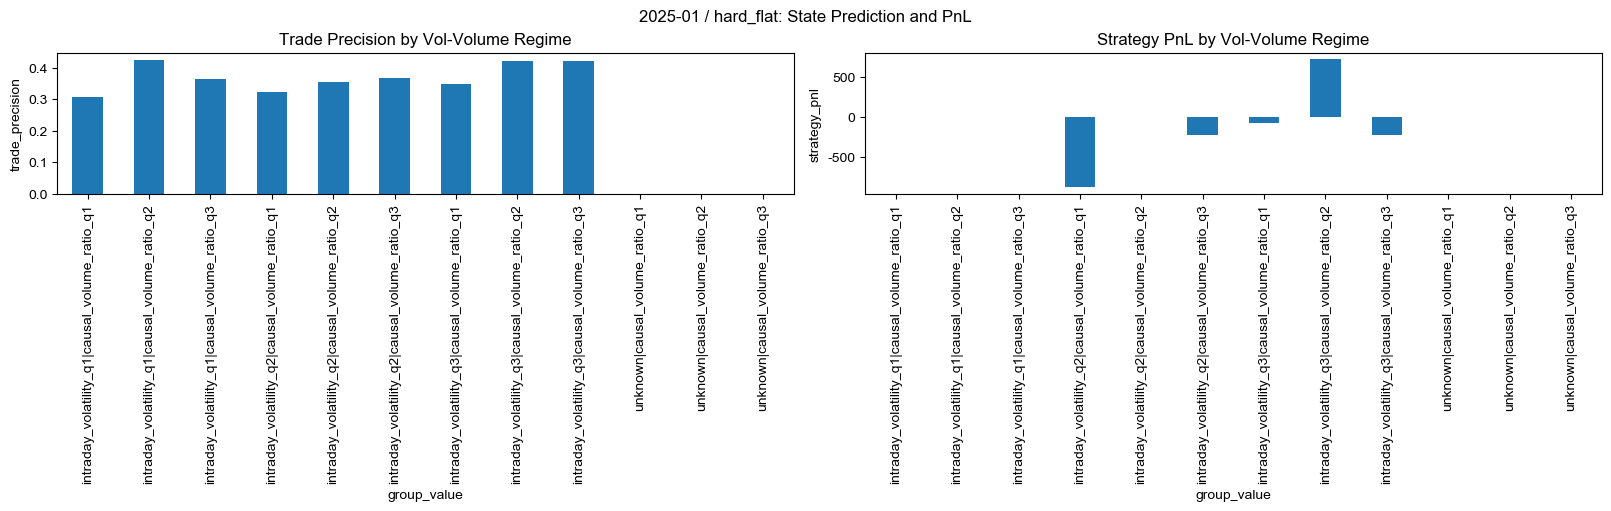

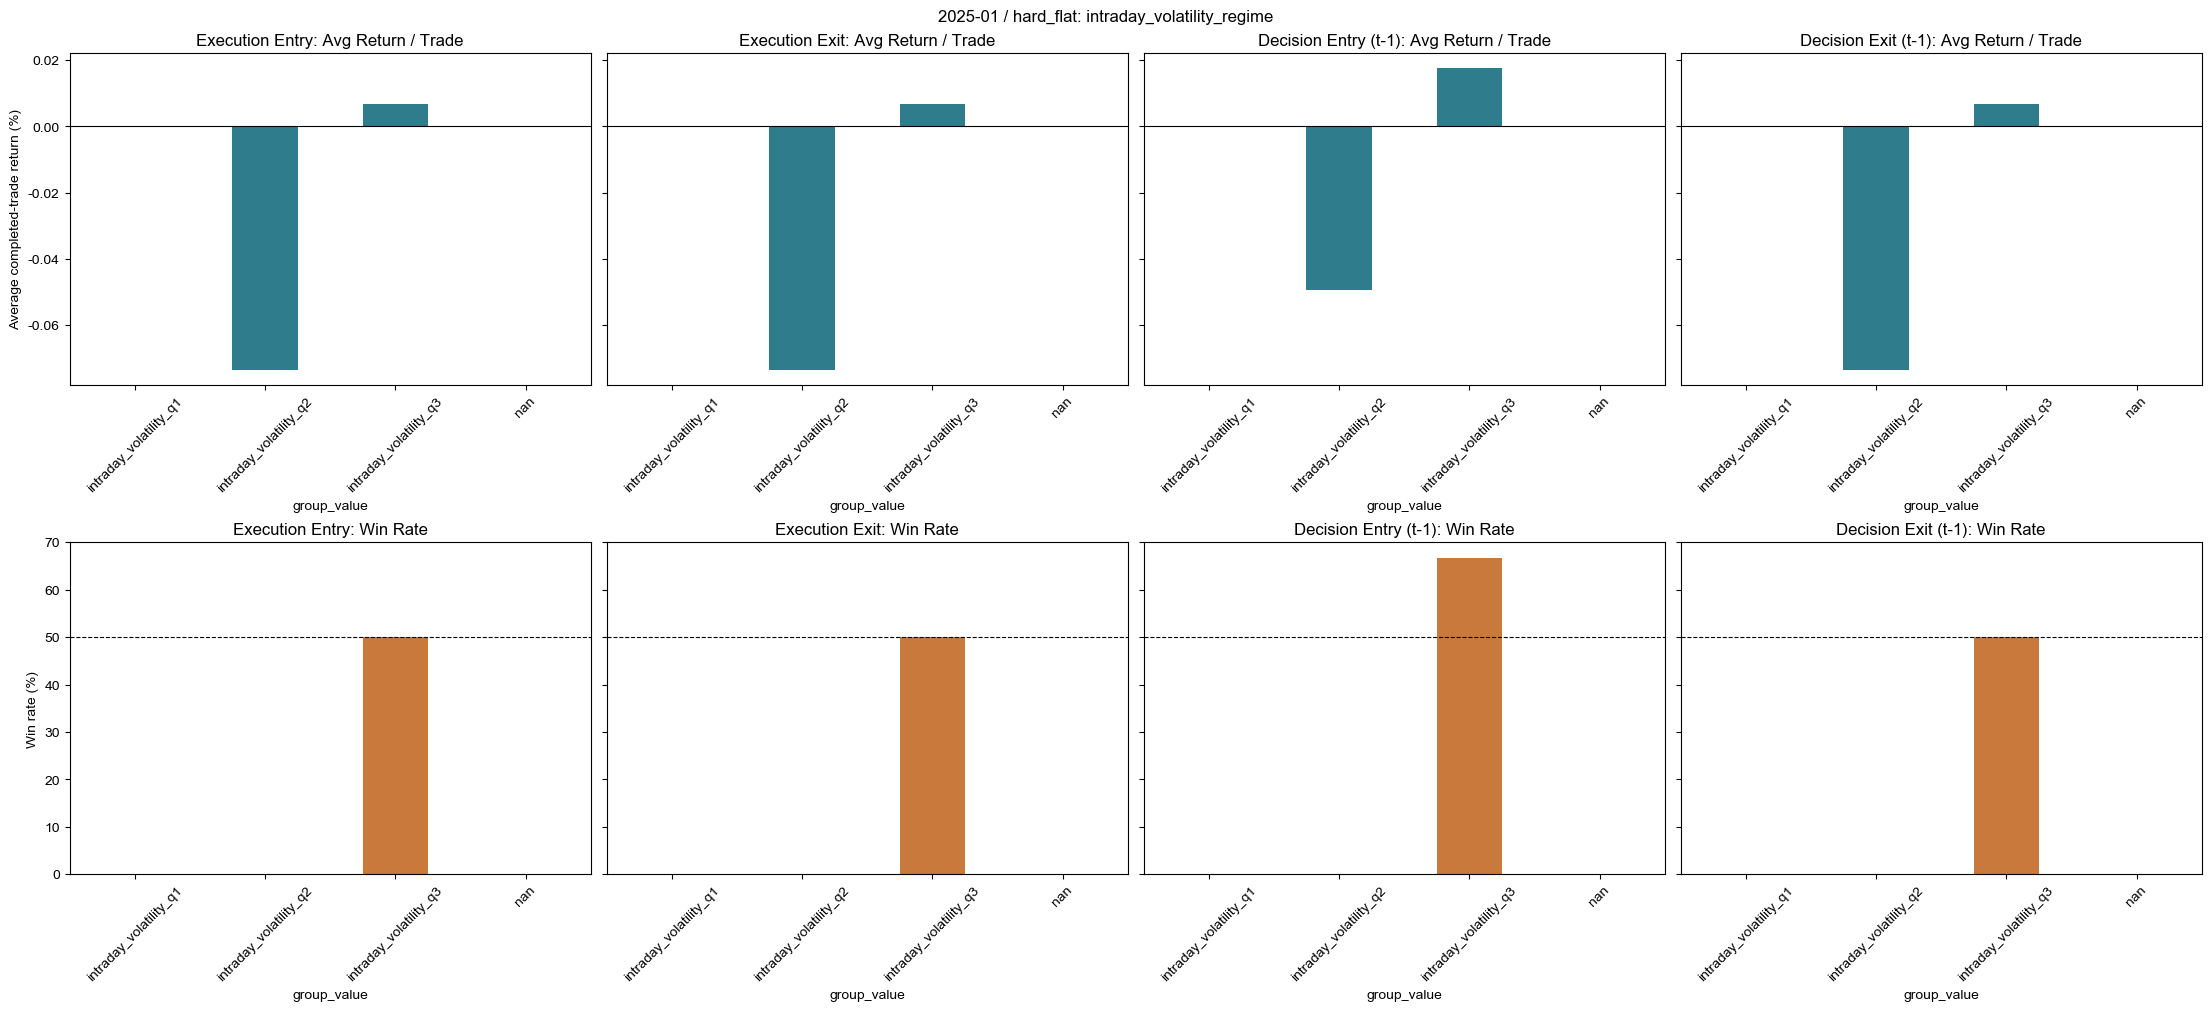

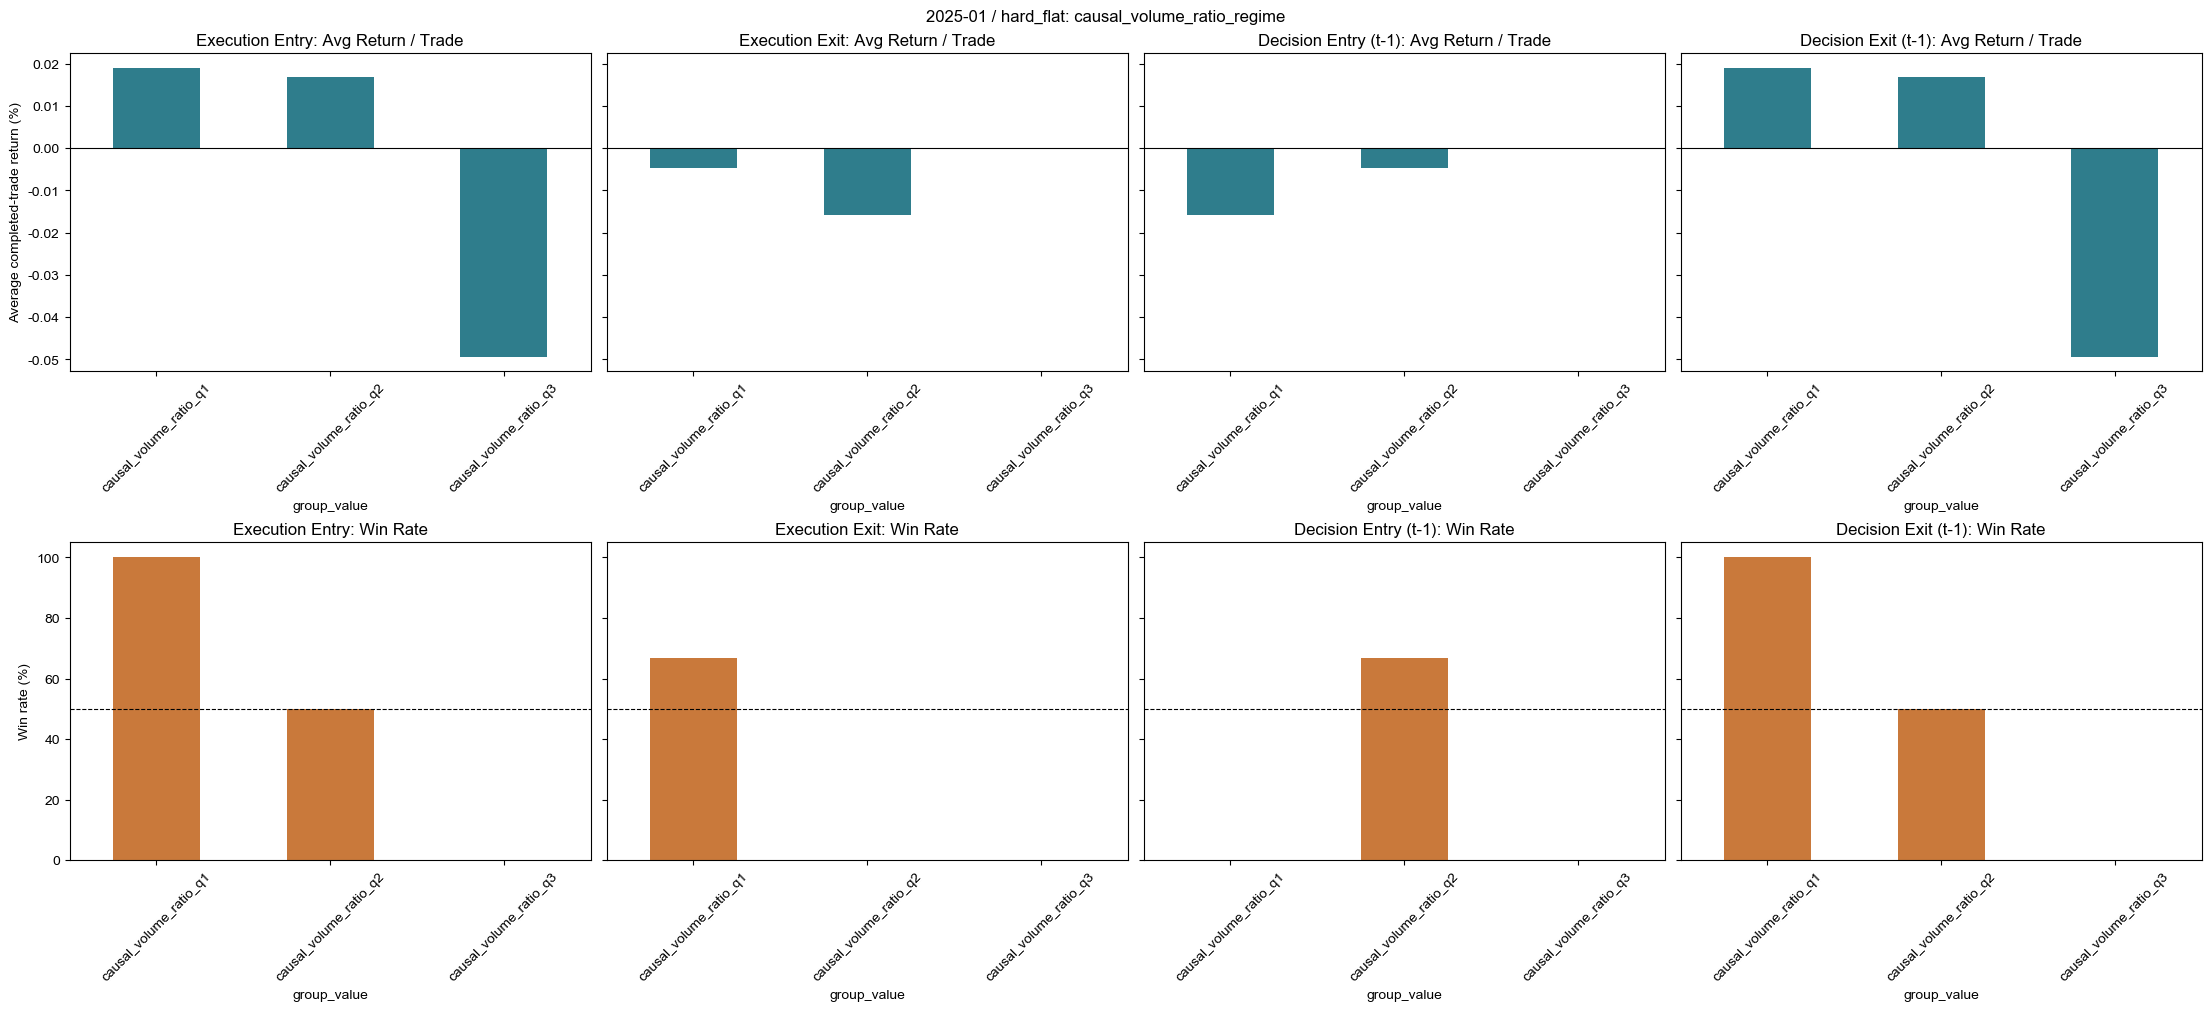

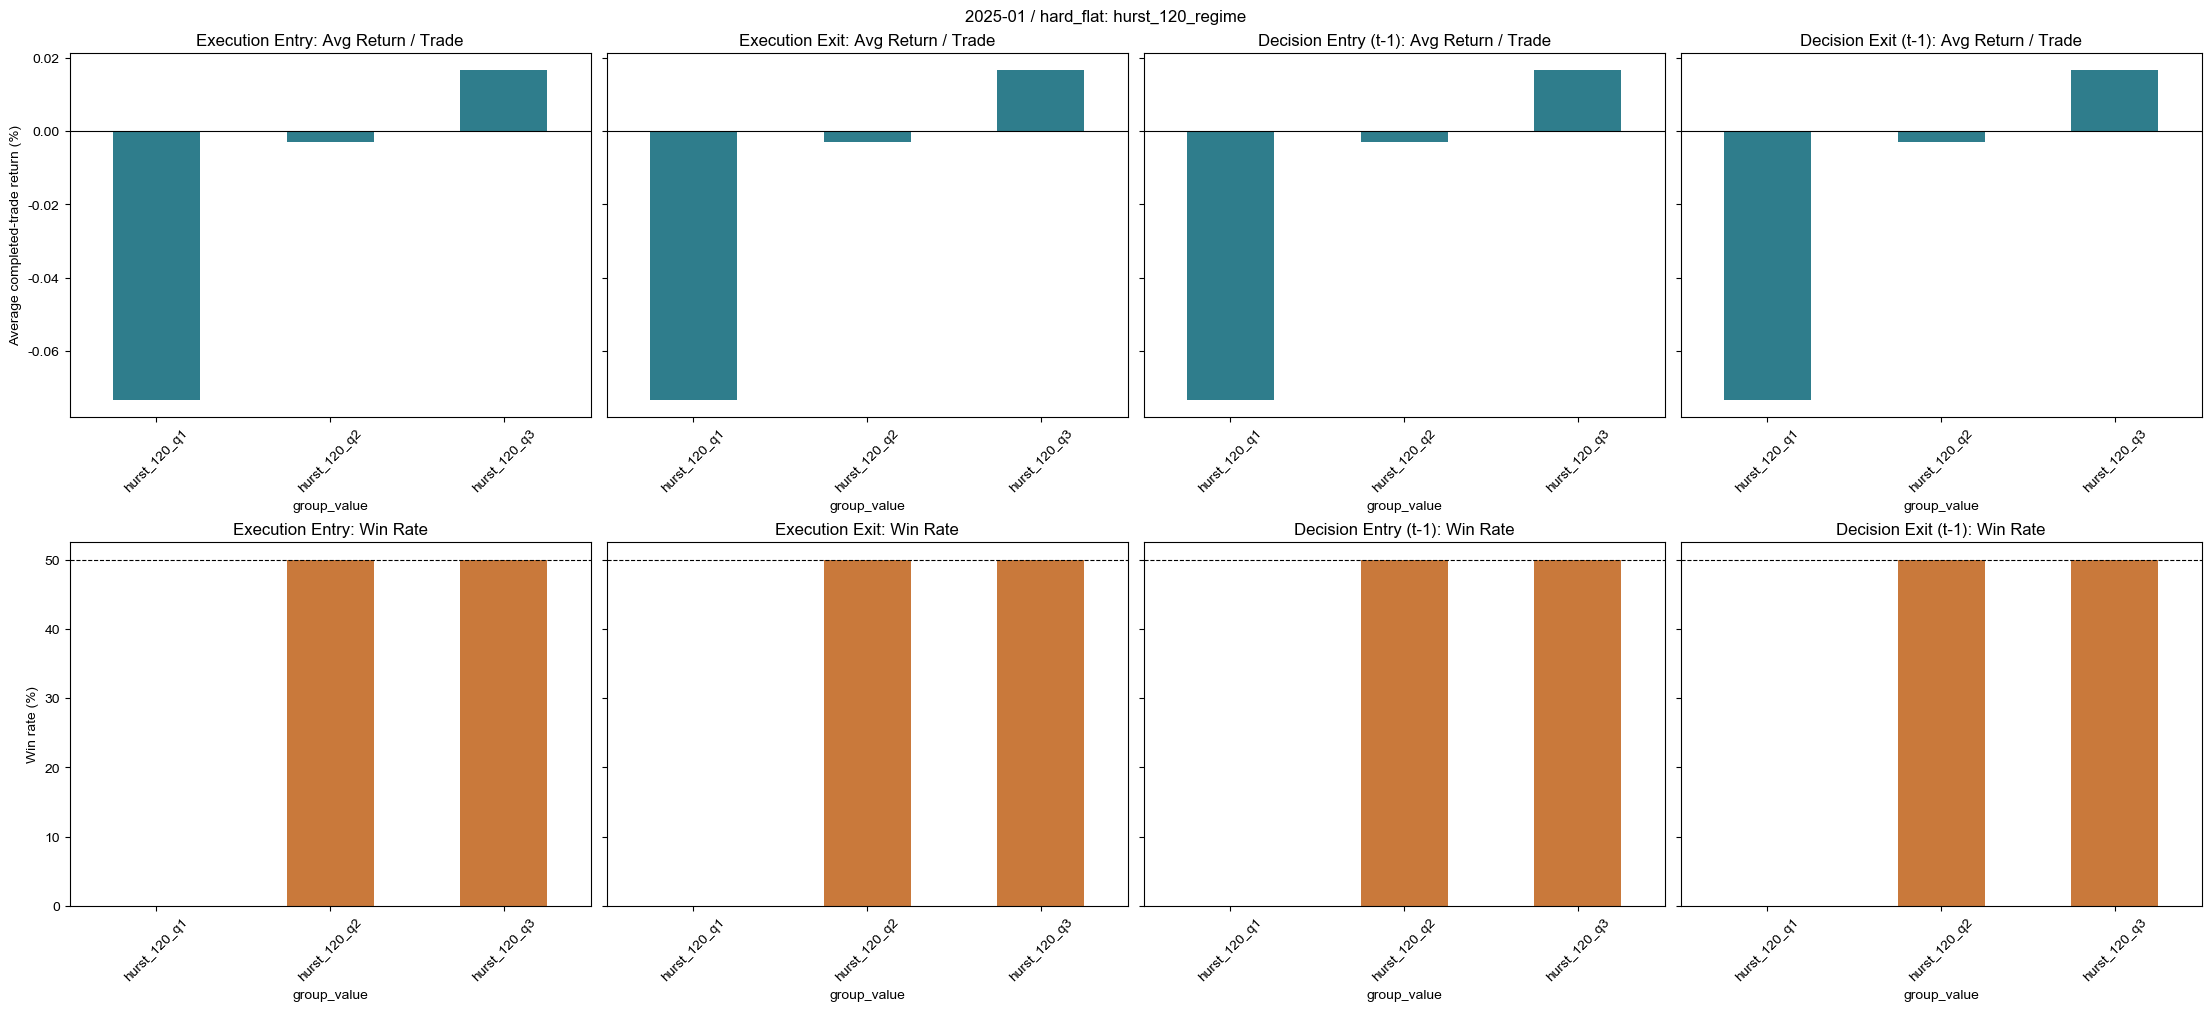

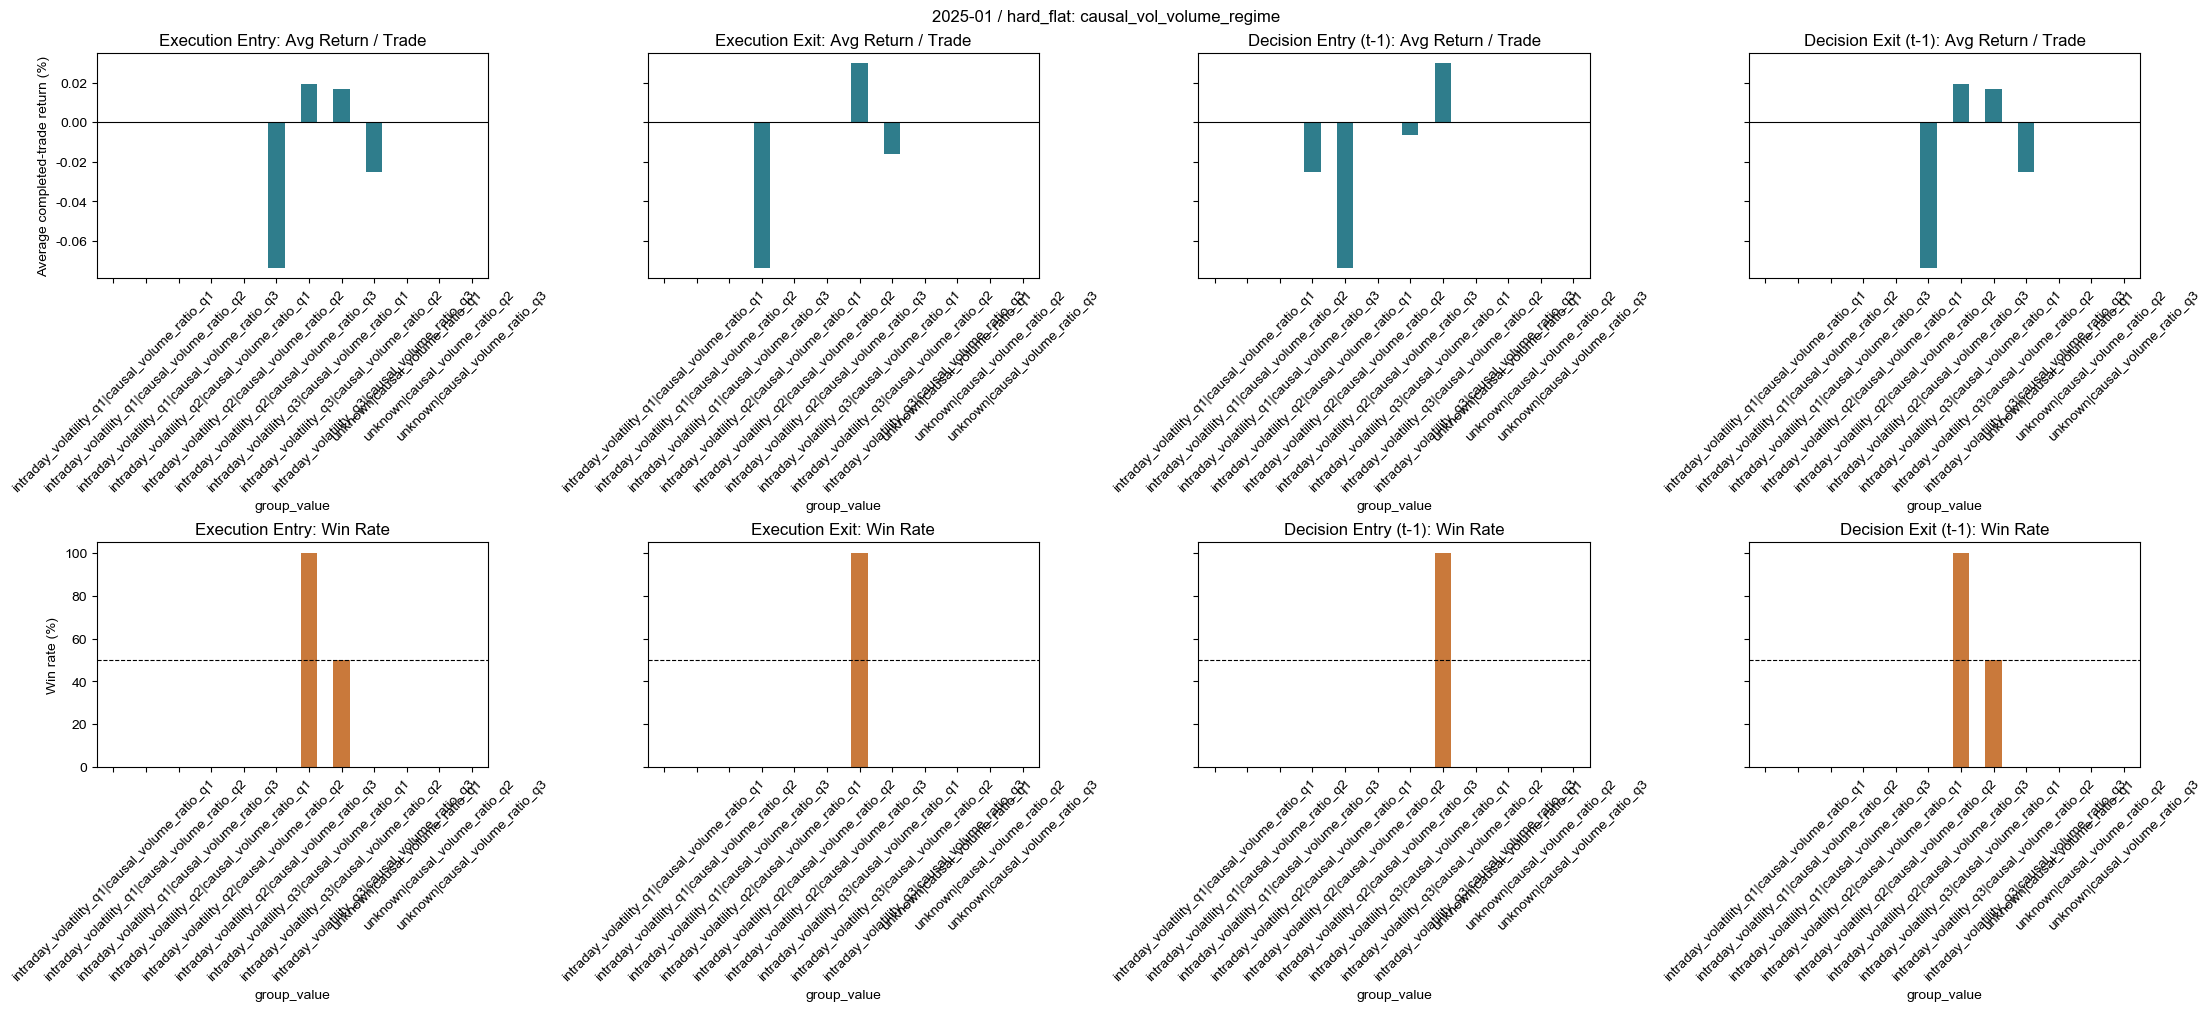

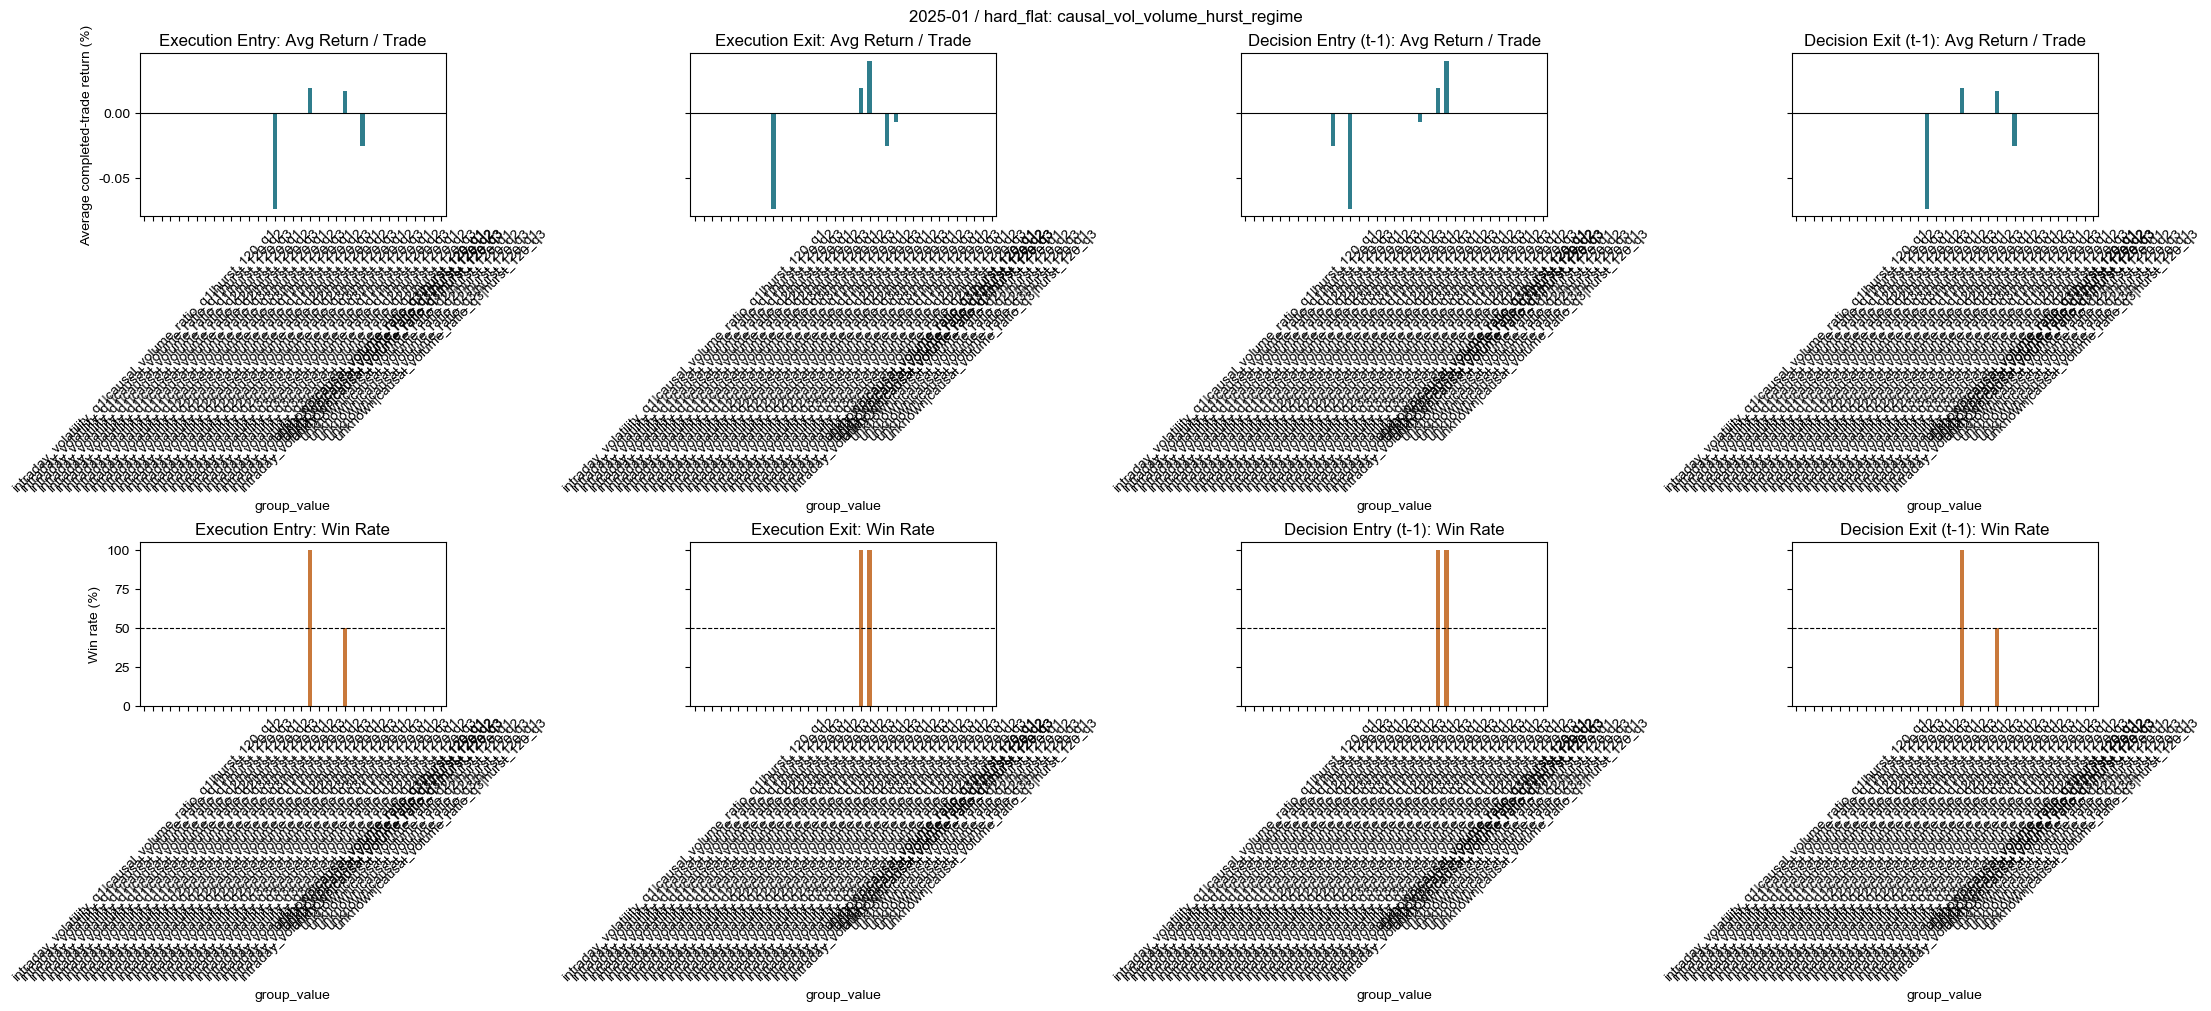

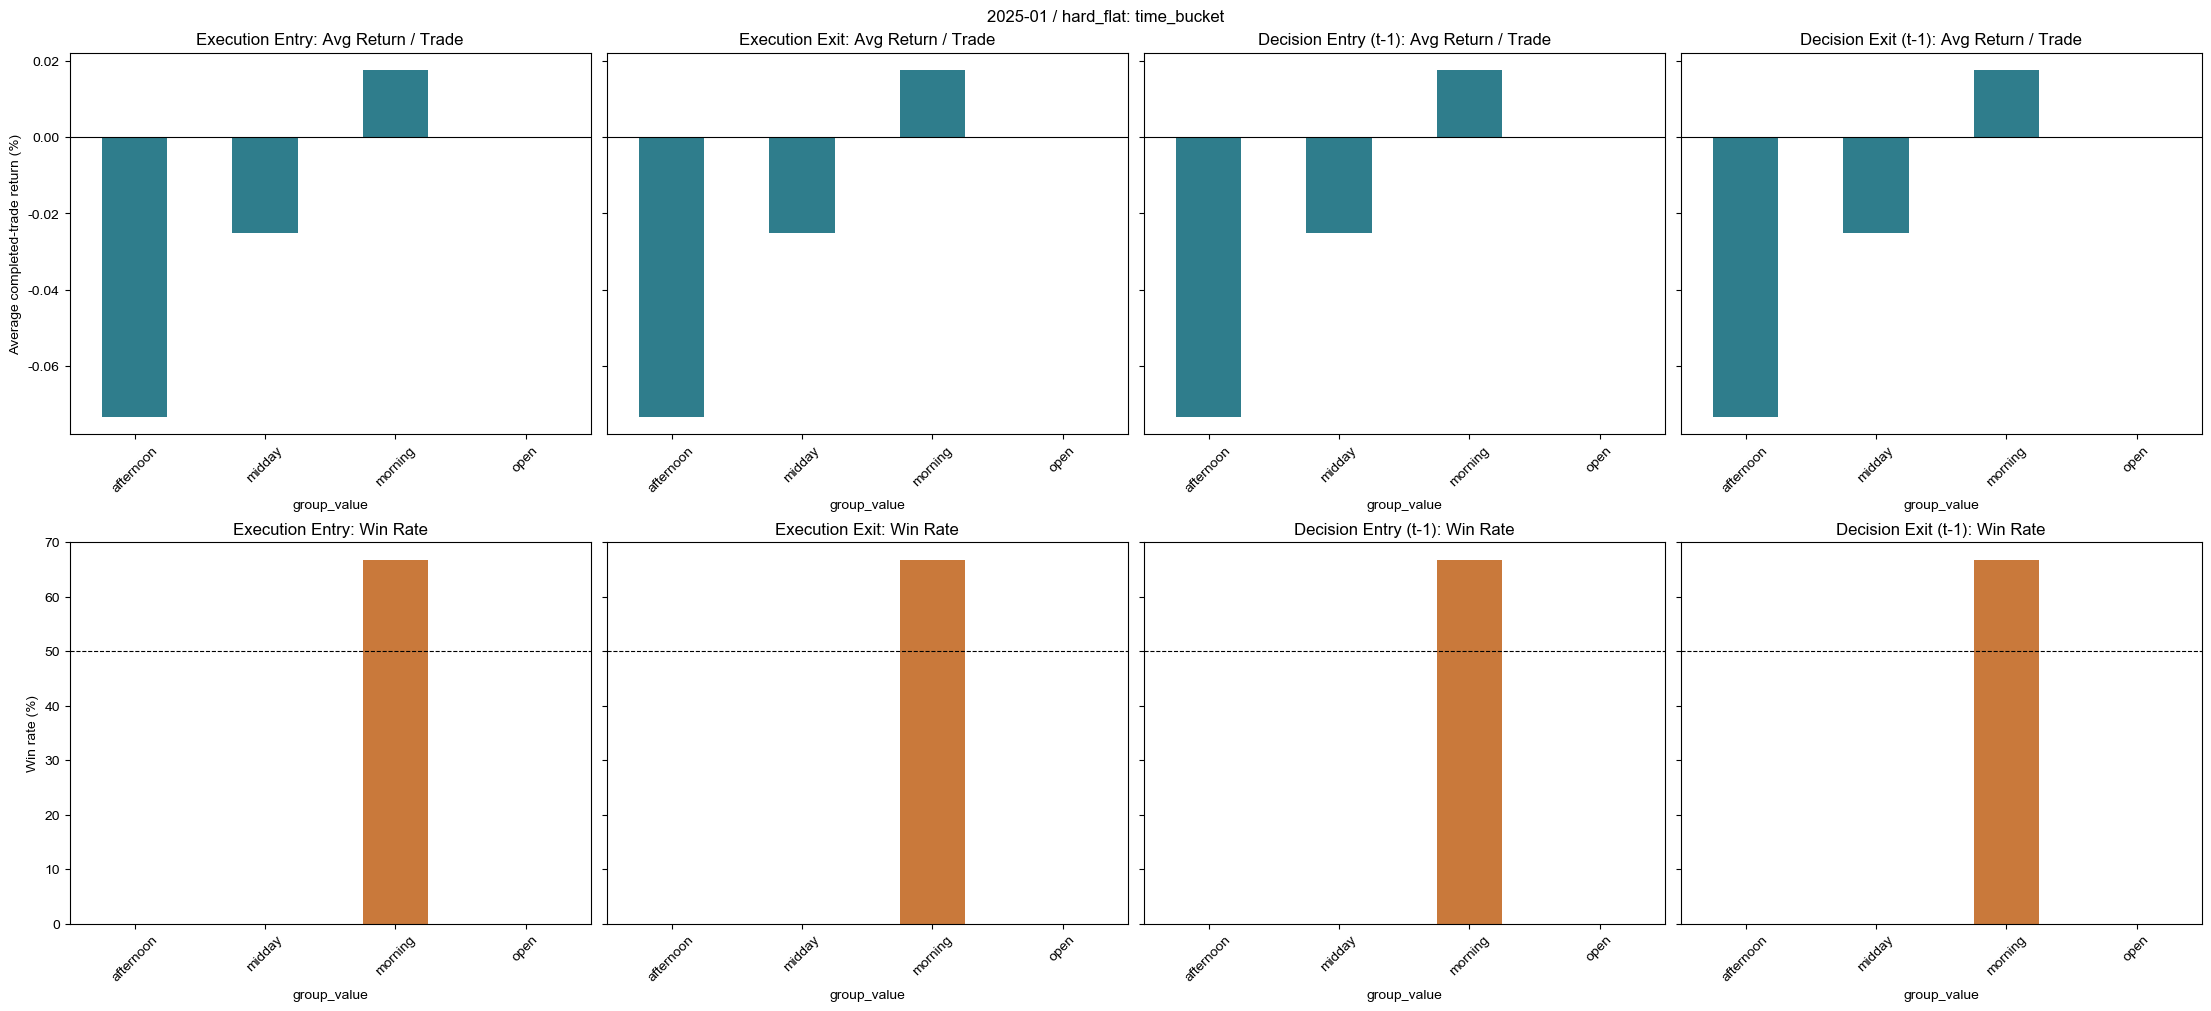

窗口诊断完成: 2025-01 hard_flat -> artifacts/if_alstm_rolling_3state_intra_2025/window_diagnostics/2025-01/hard_flat/diagnostic_report.md


/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:274: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  inferred = out[[c for c in ("prob_down", "prob_flat", "prob_up") if c in out]].idxmax(axis=1)
/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:299: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out["strategy_return"] = pd.to_numeric(out["account"], errors="coerce").pct_change()


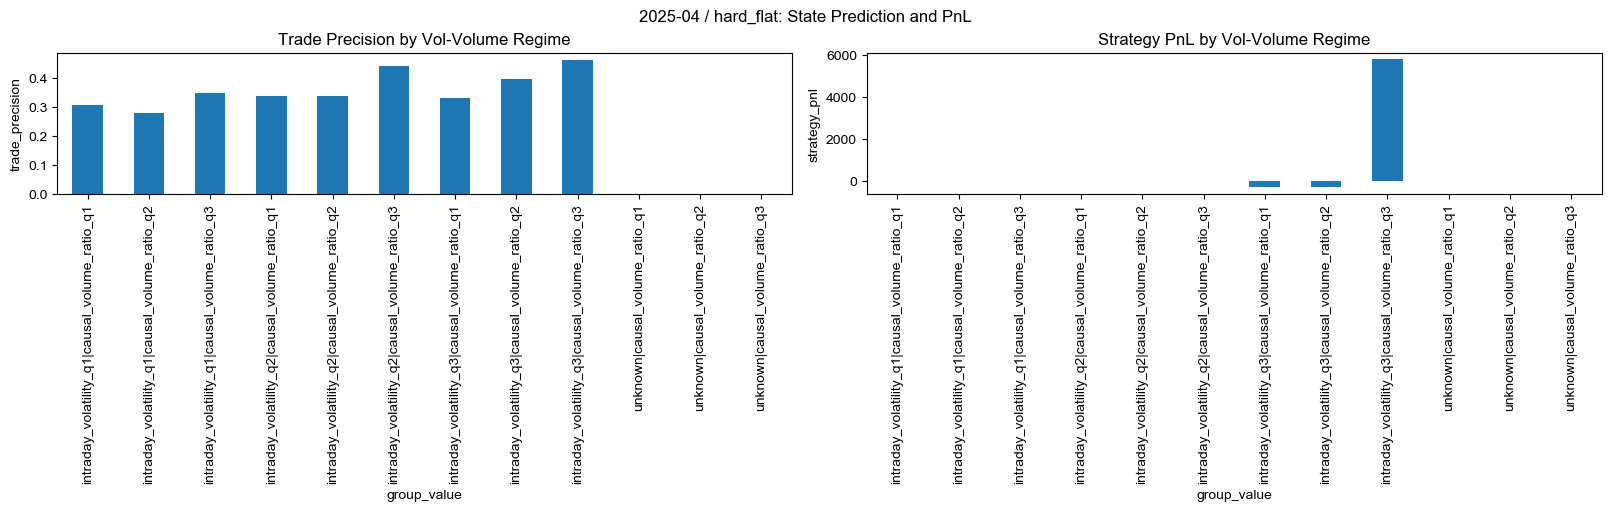

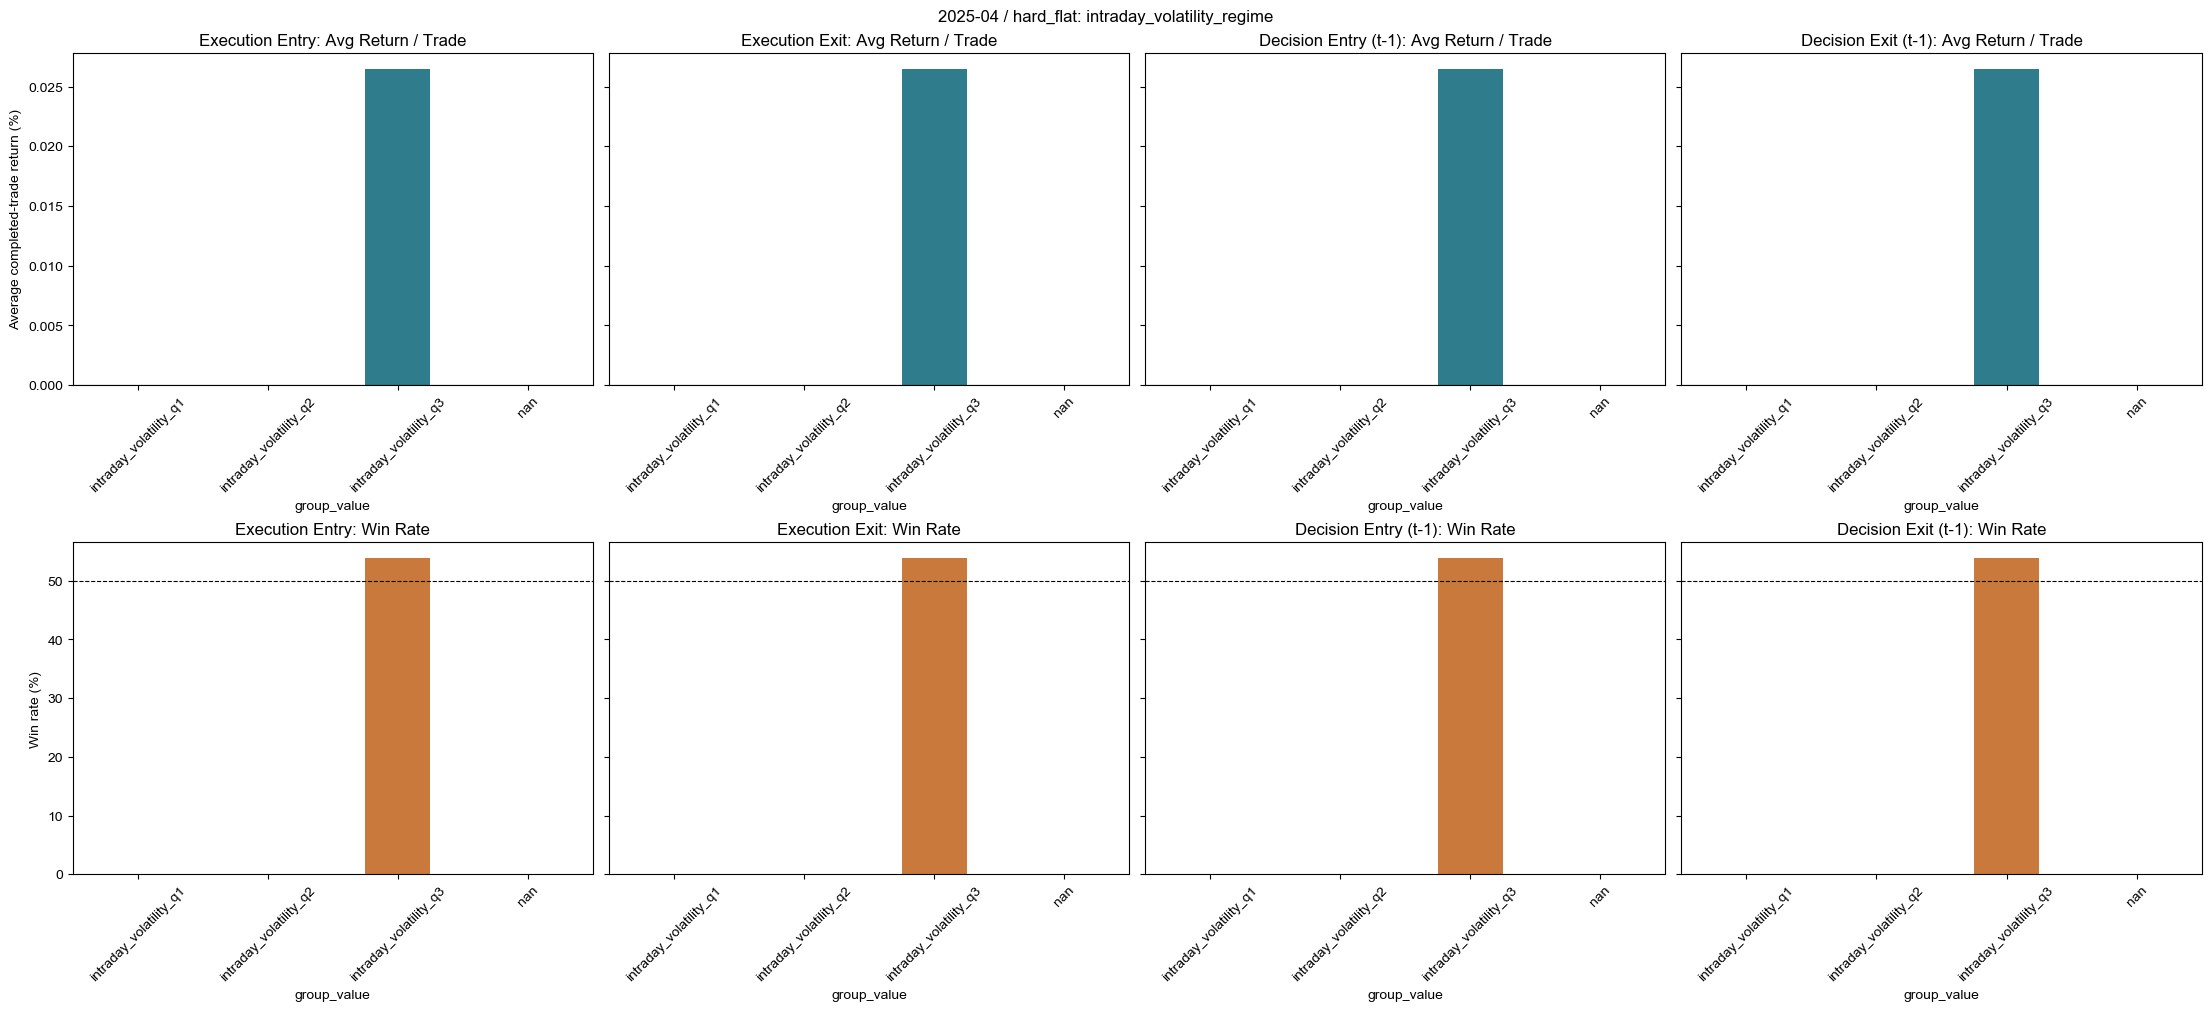

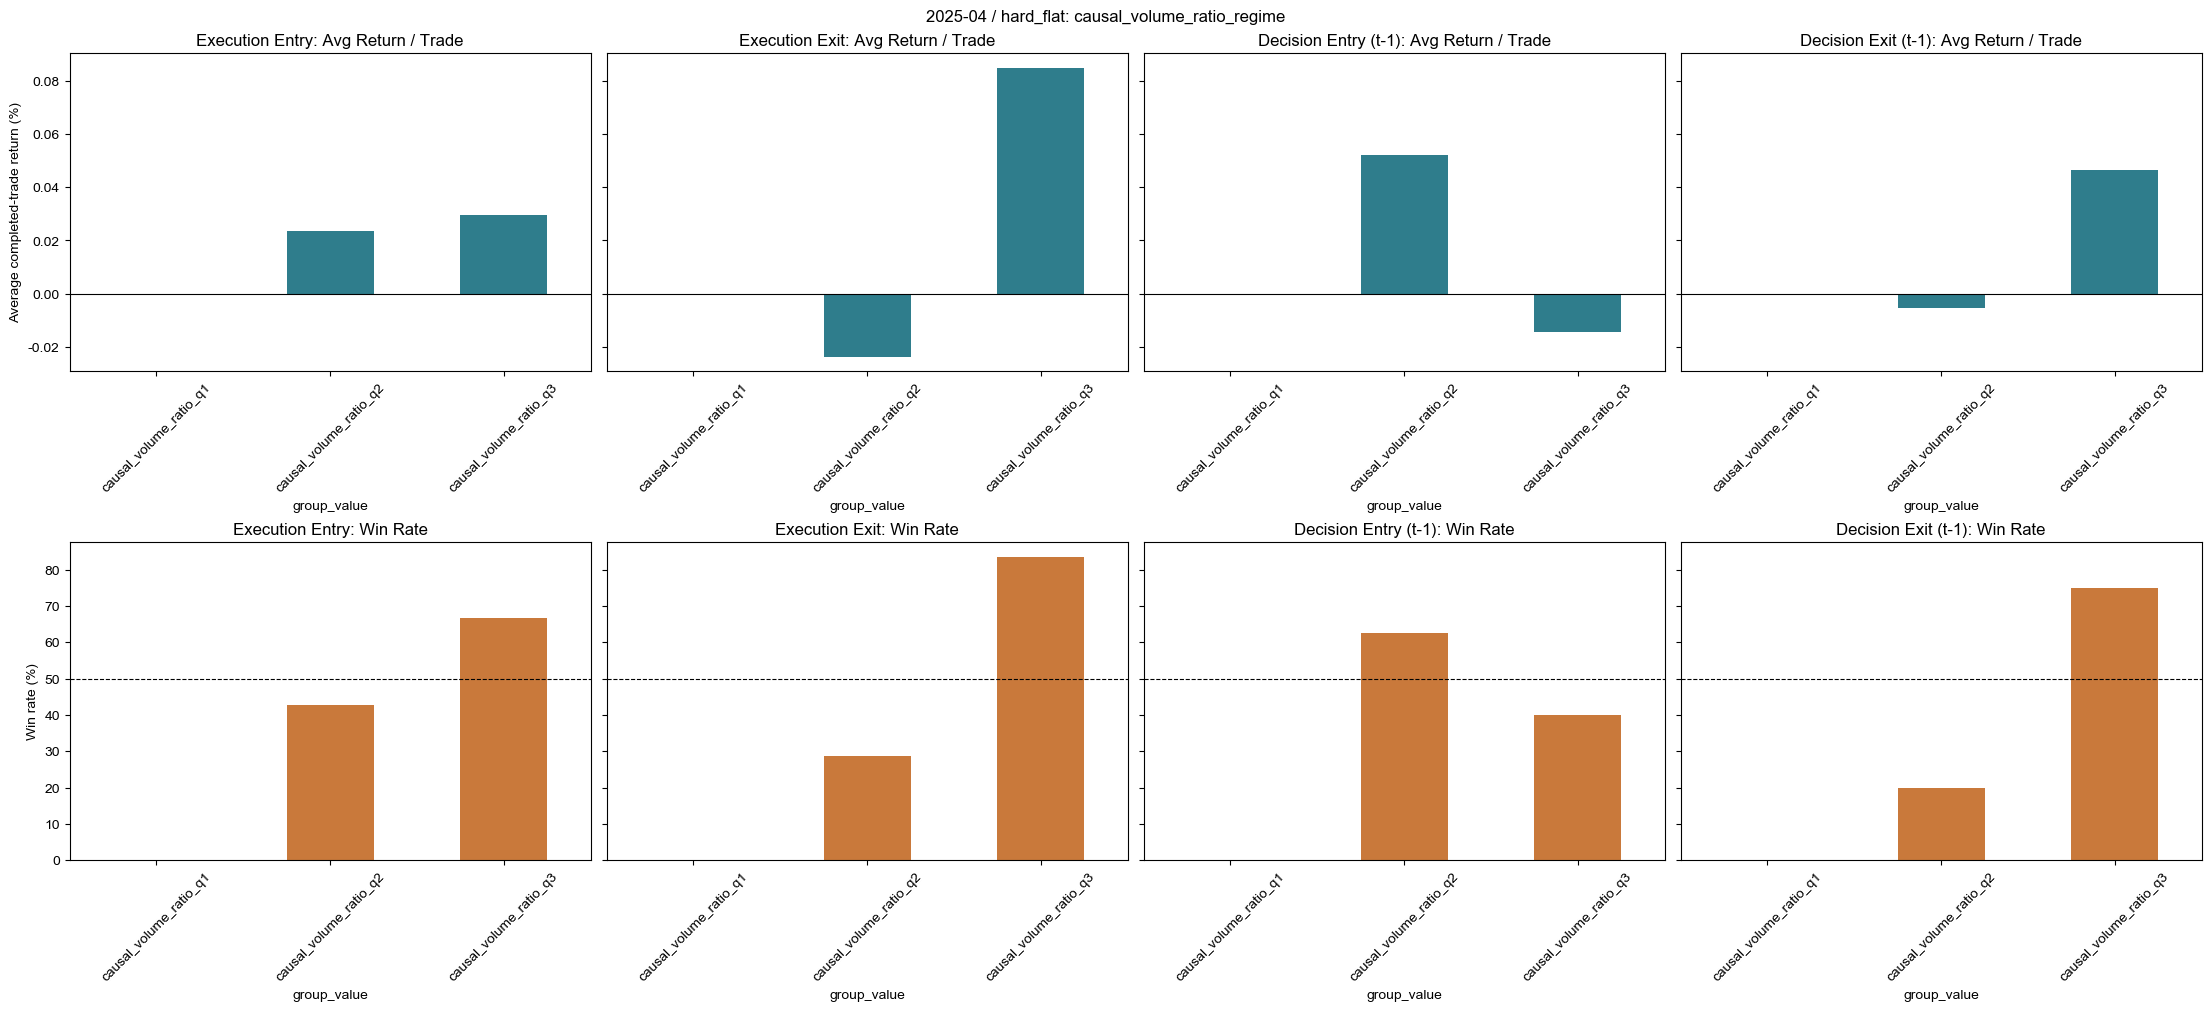

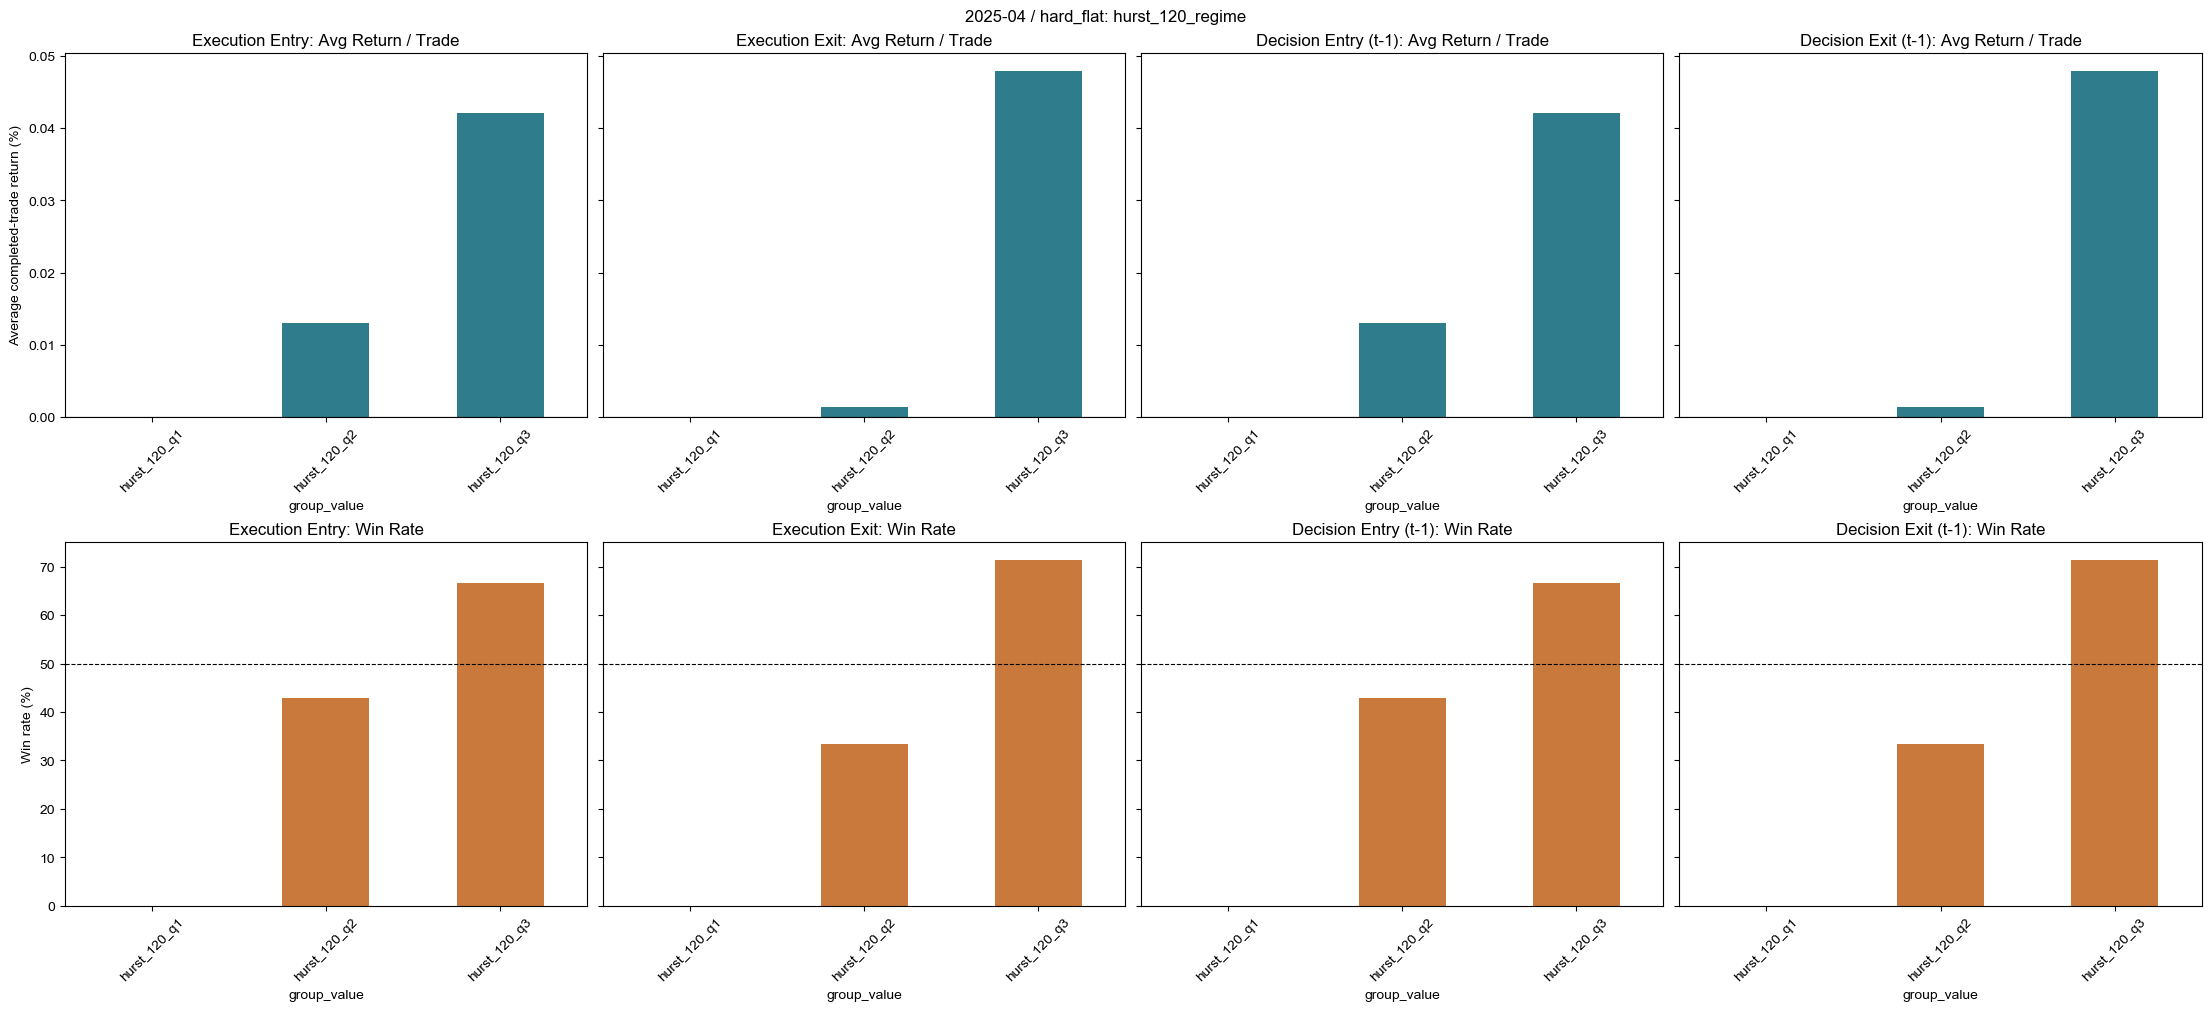

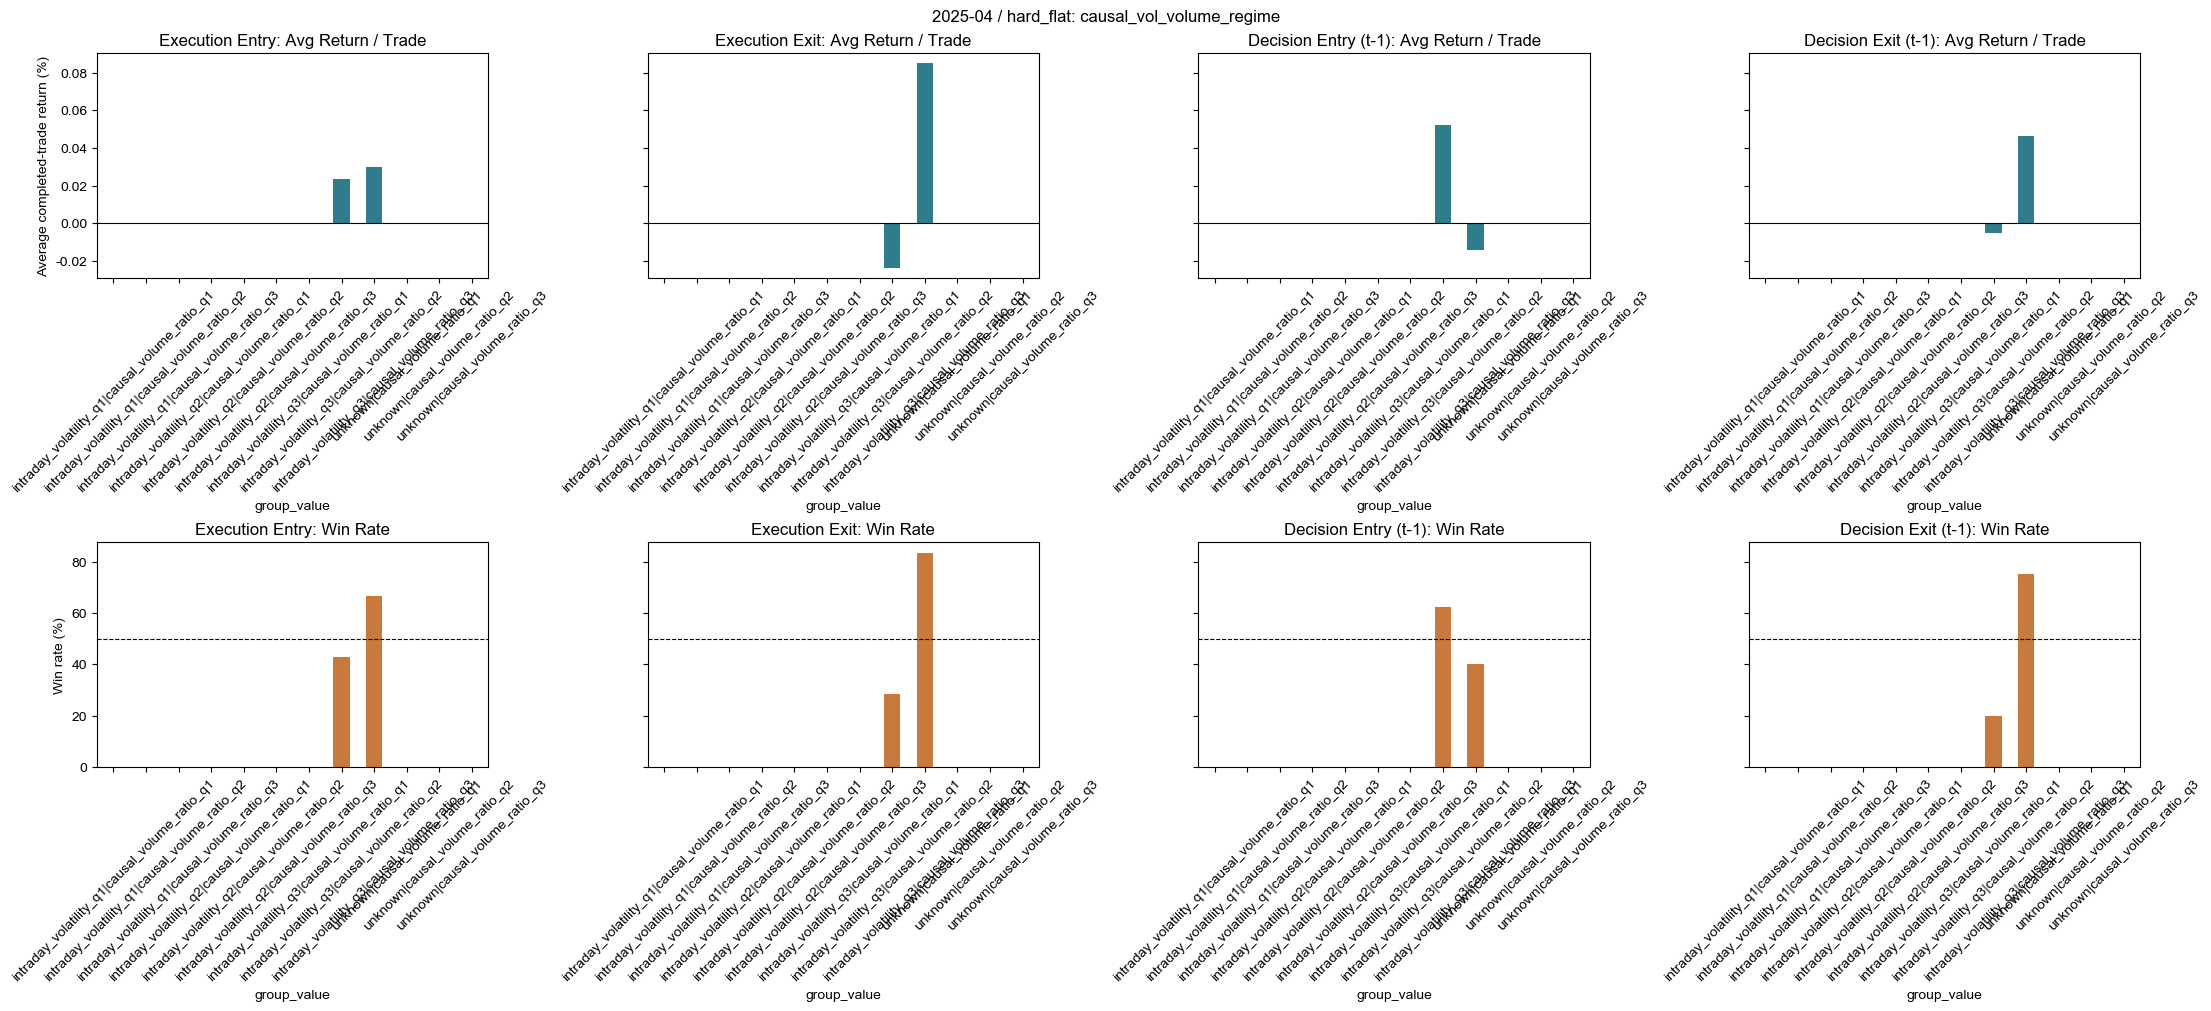

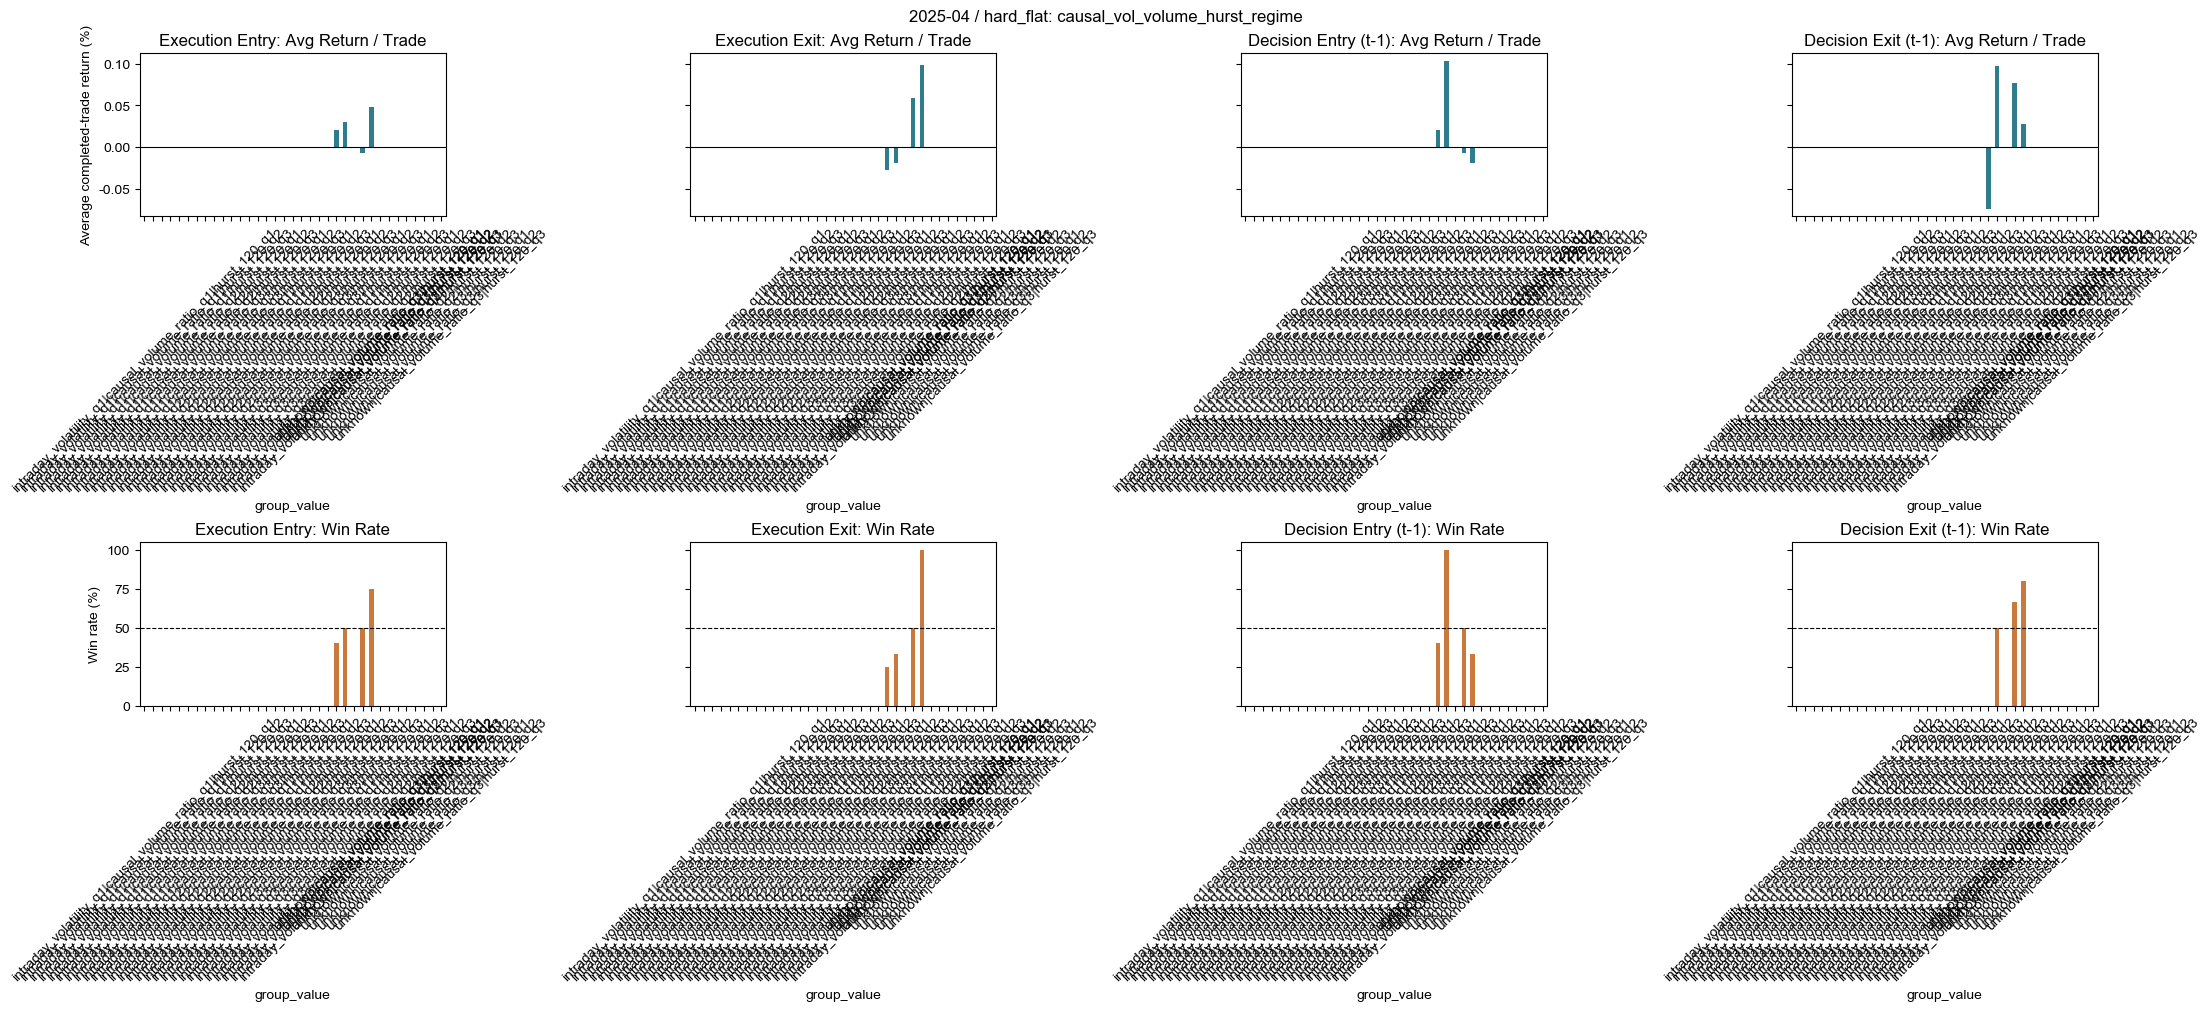

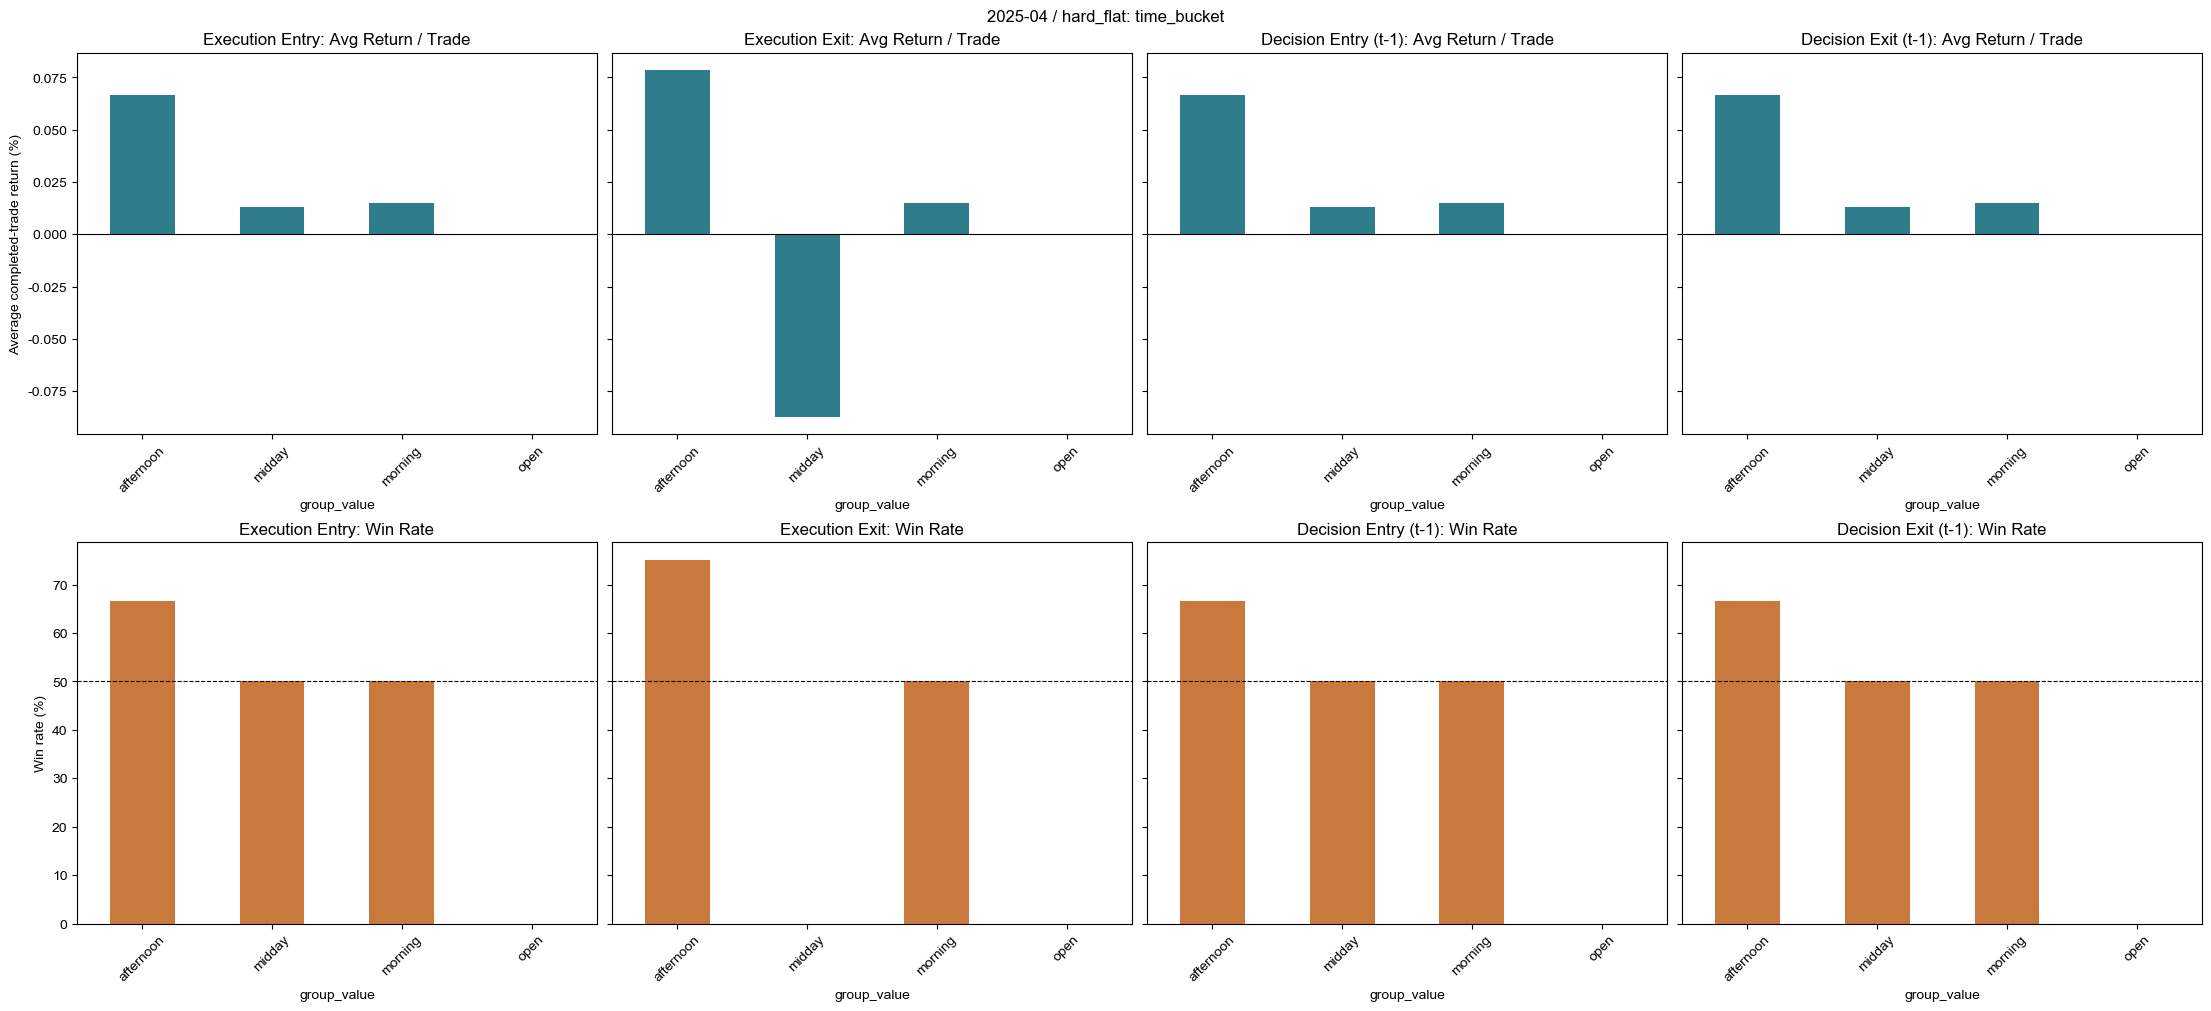

窗口诊断完成: 2025-04 hard_flat -> artifacts/if_alstm_rolling_3state_intra_2025/window_diagnostics/2025-04/hard_flat/diagnostic_report.md


/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:274: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  inferred = out[[c for c in ("prob_down", "prob_flat", "prob_up") if c in out]].idxmax(axis=1)
/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:299: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out["strategy_return"] = pd.to_numeric(out["account"], errors="coerce").pct_change()


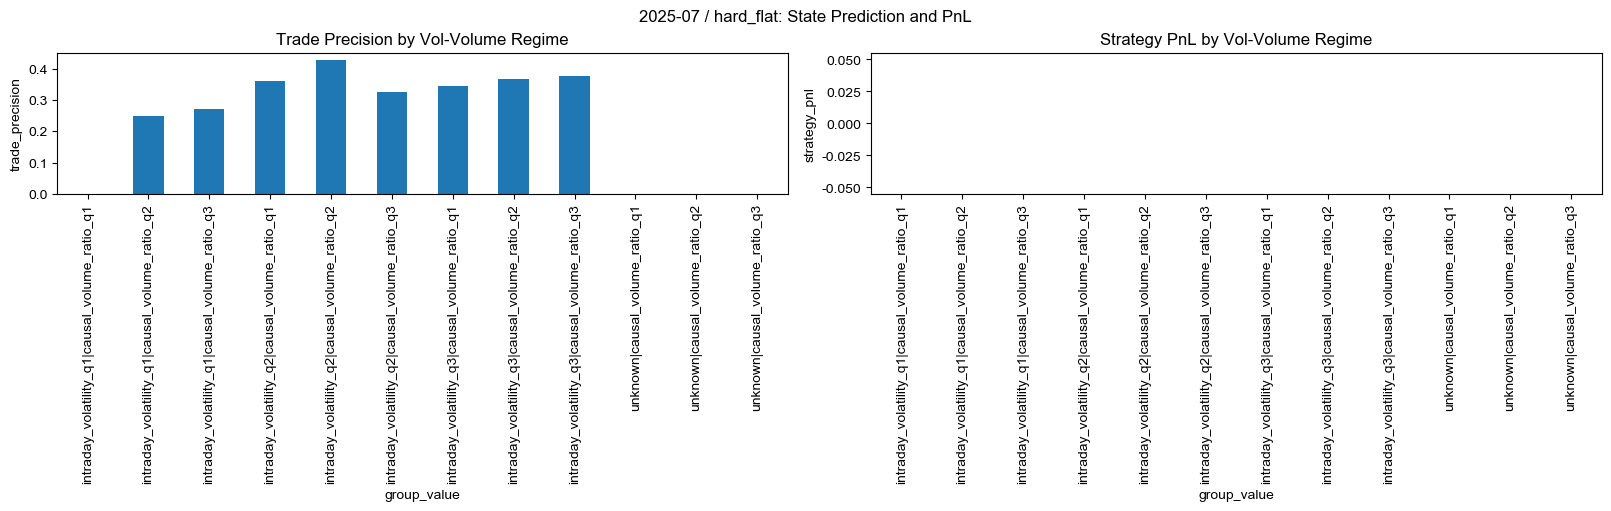

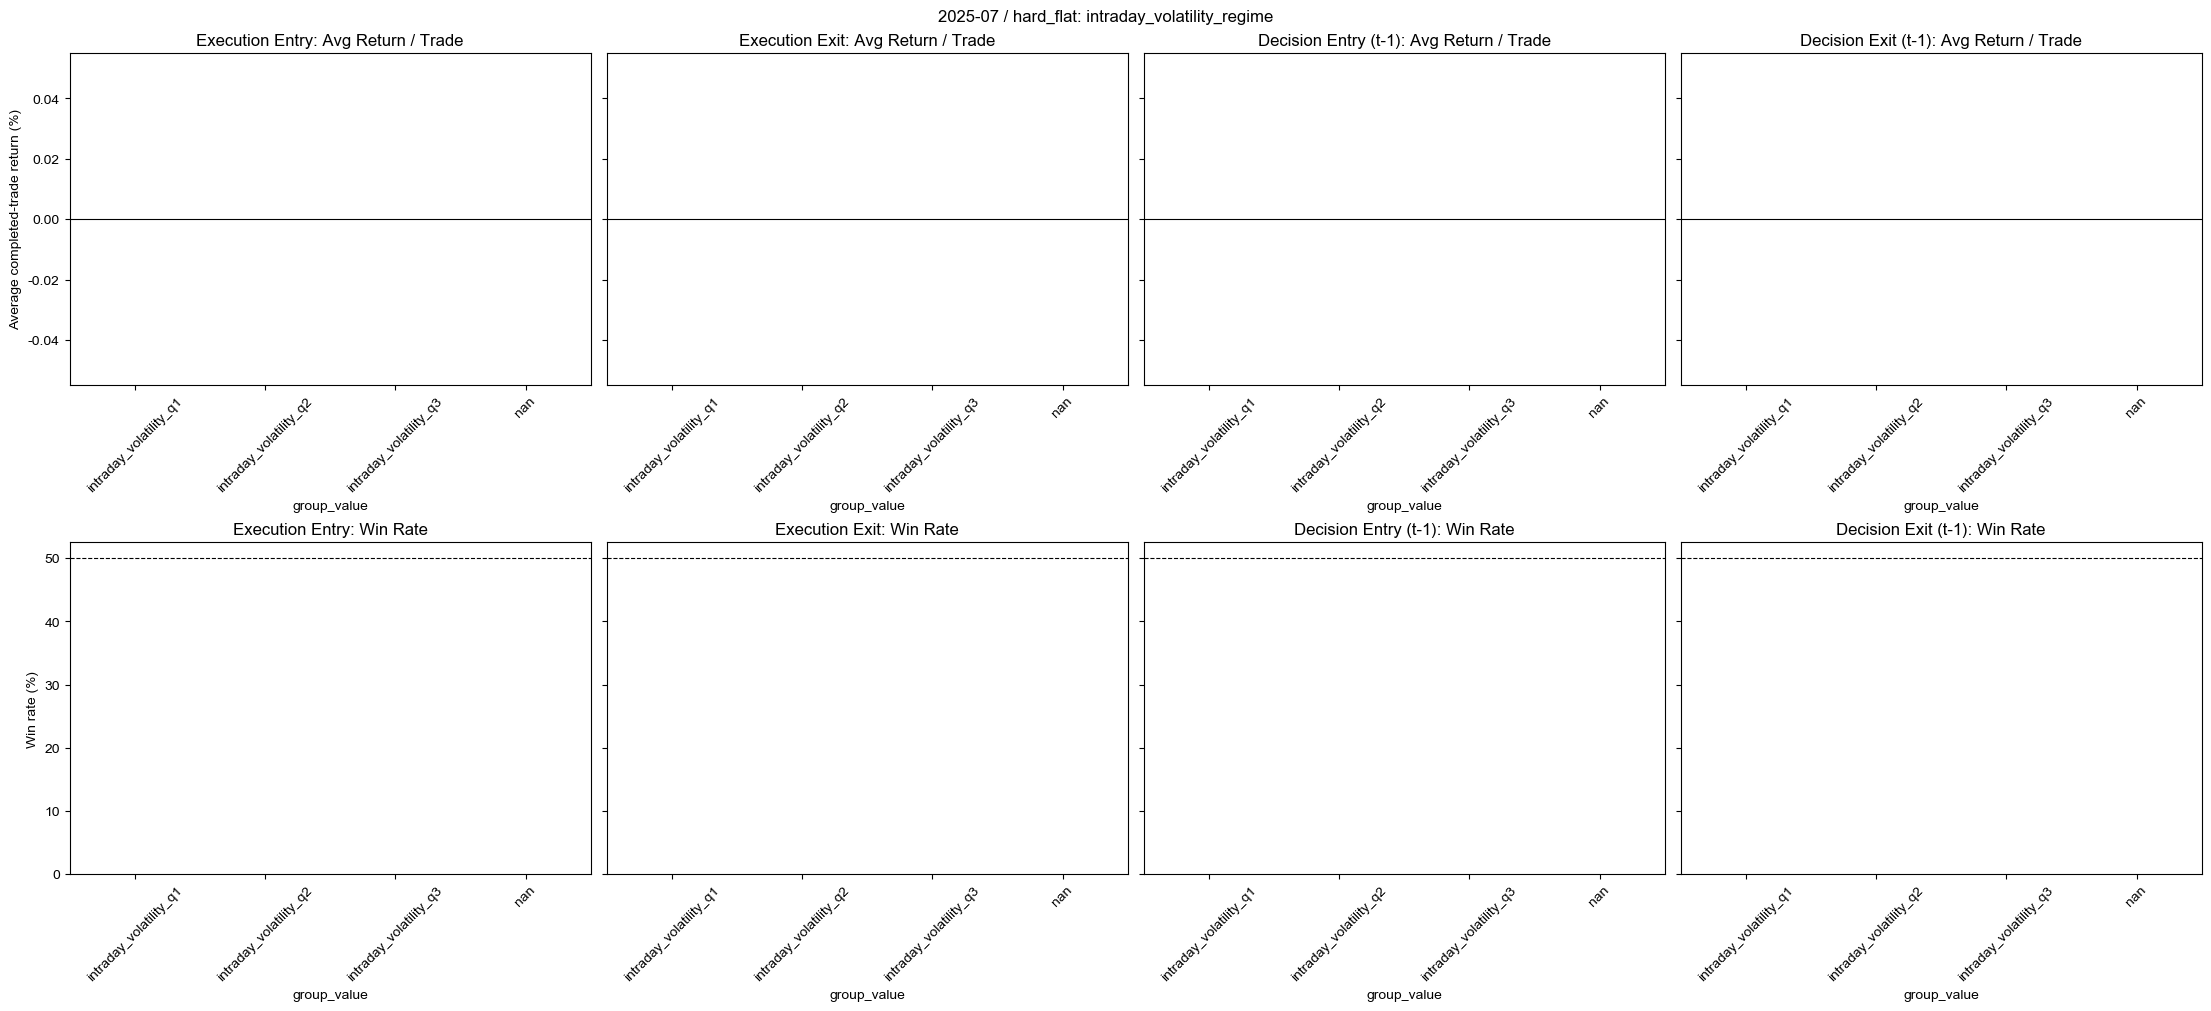

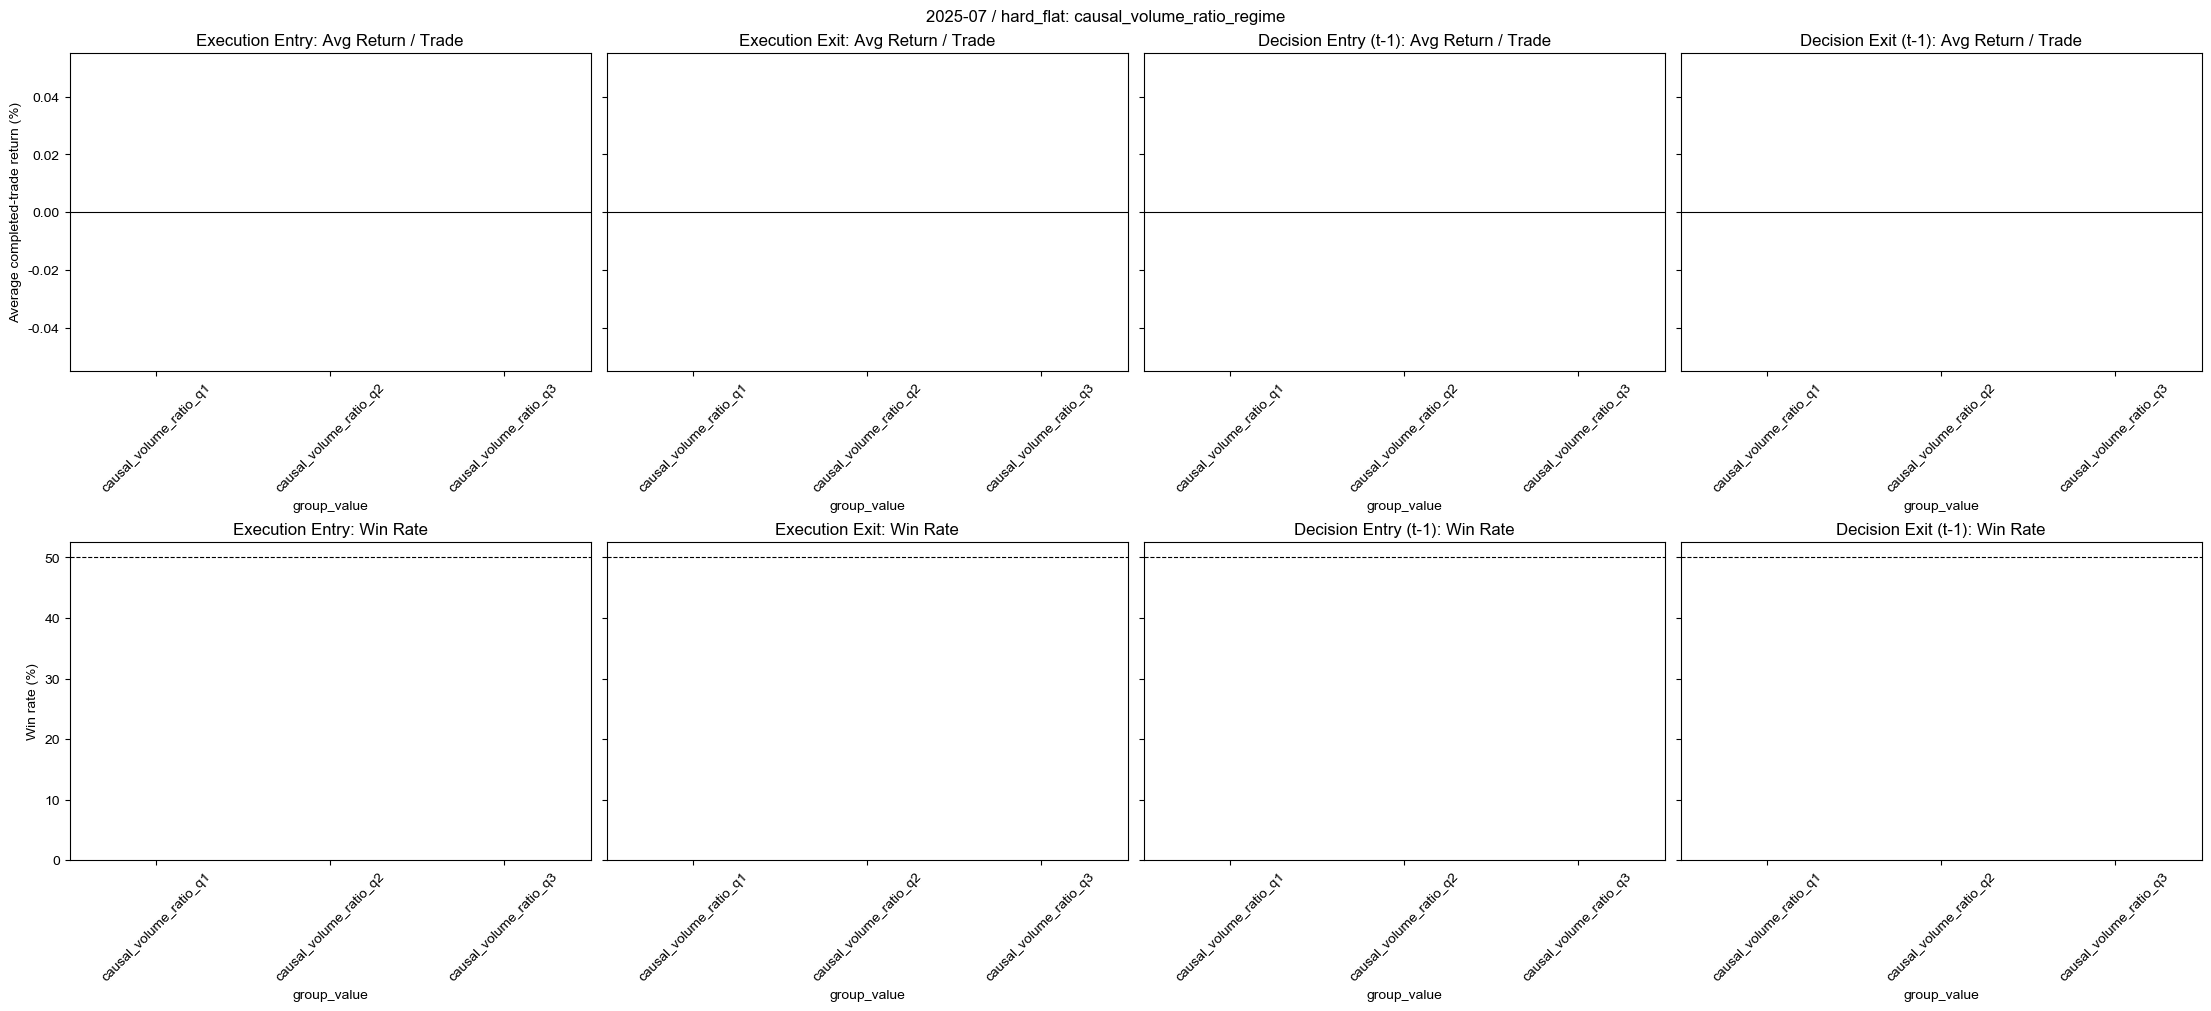

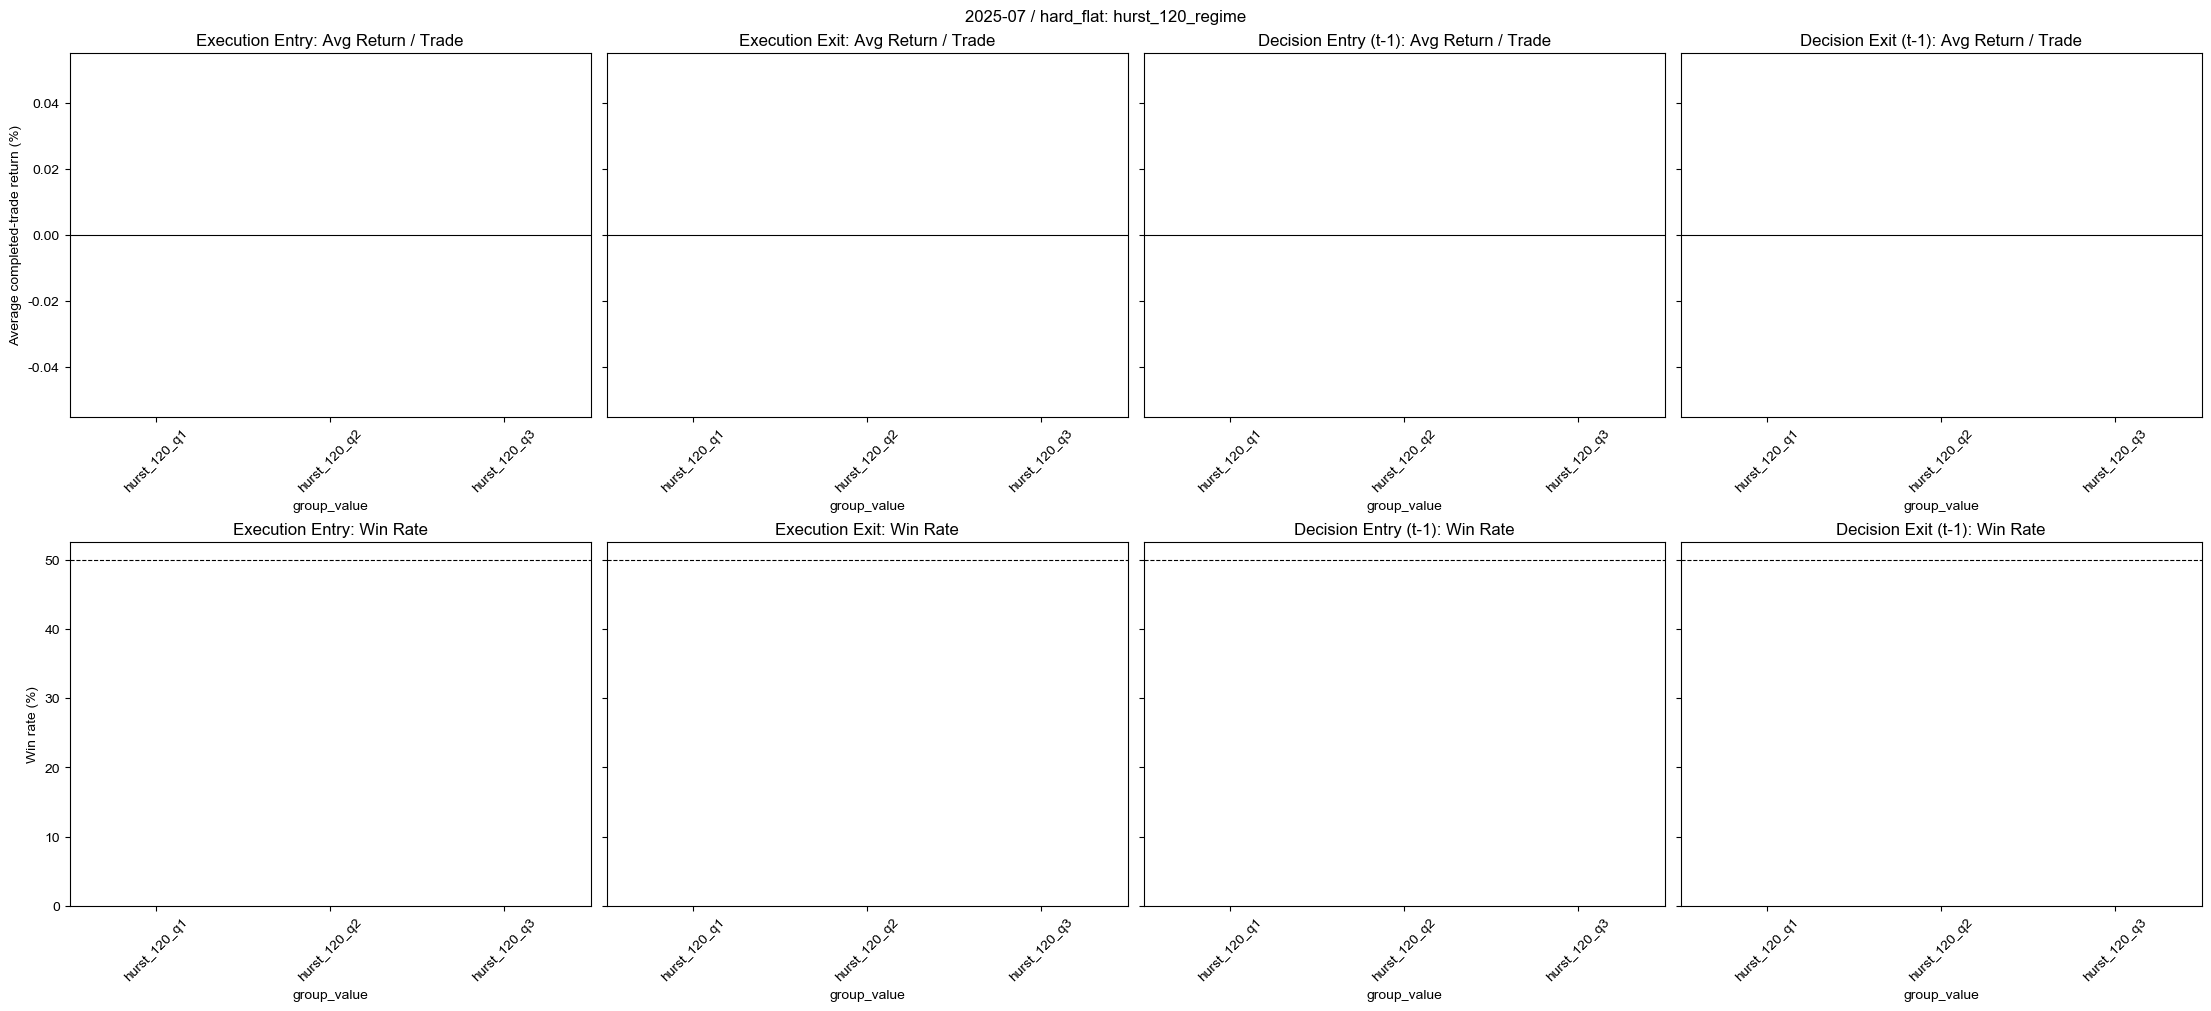

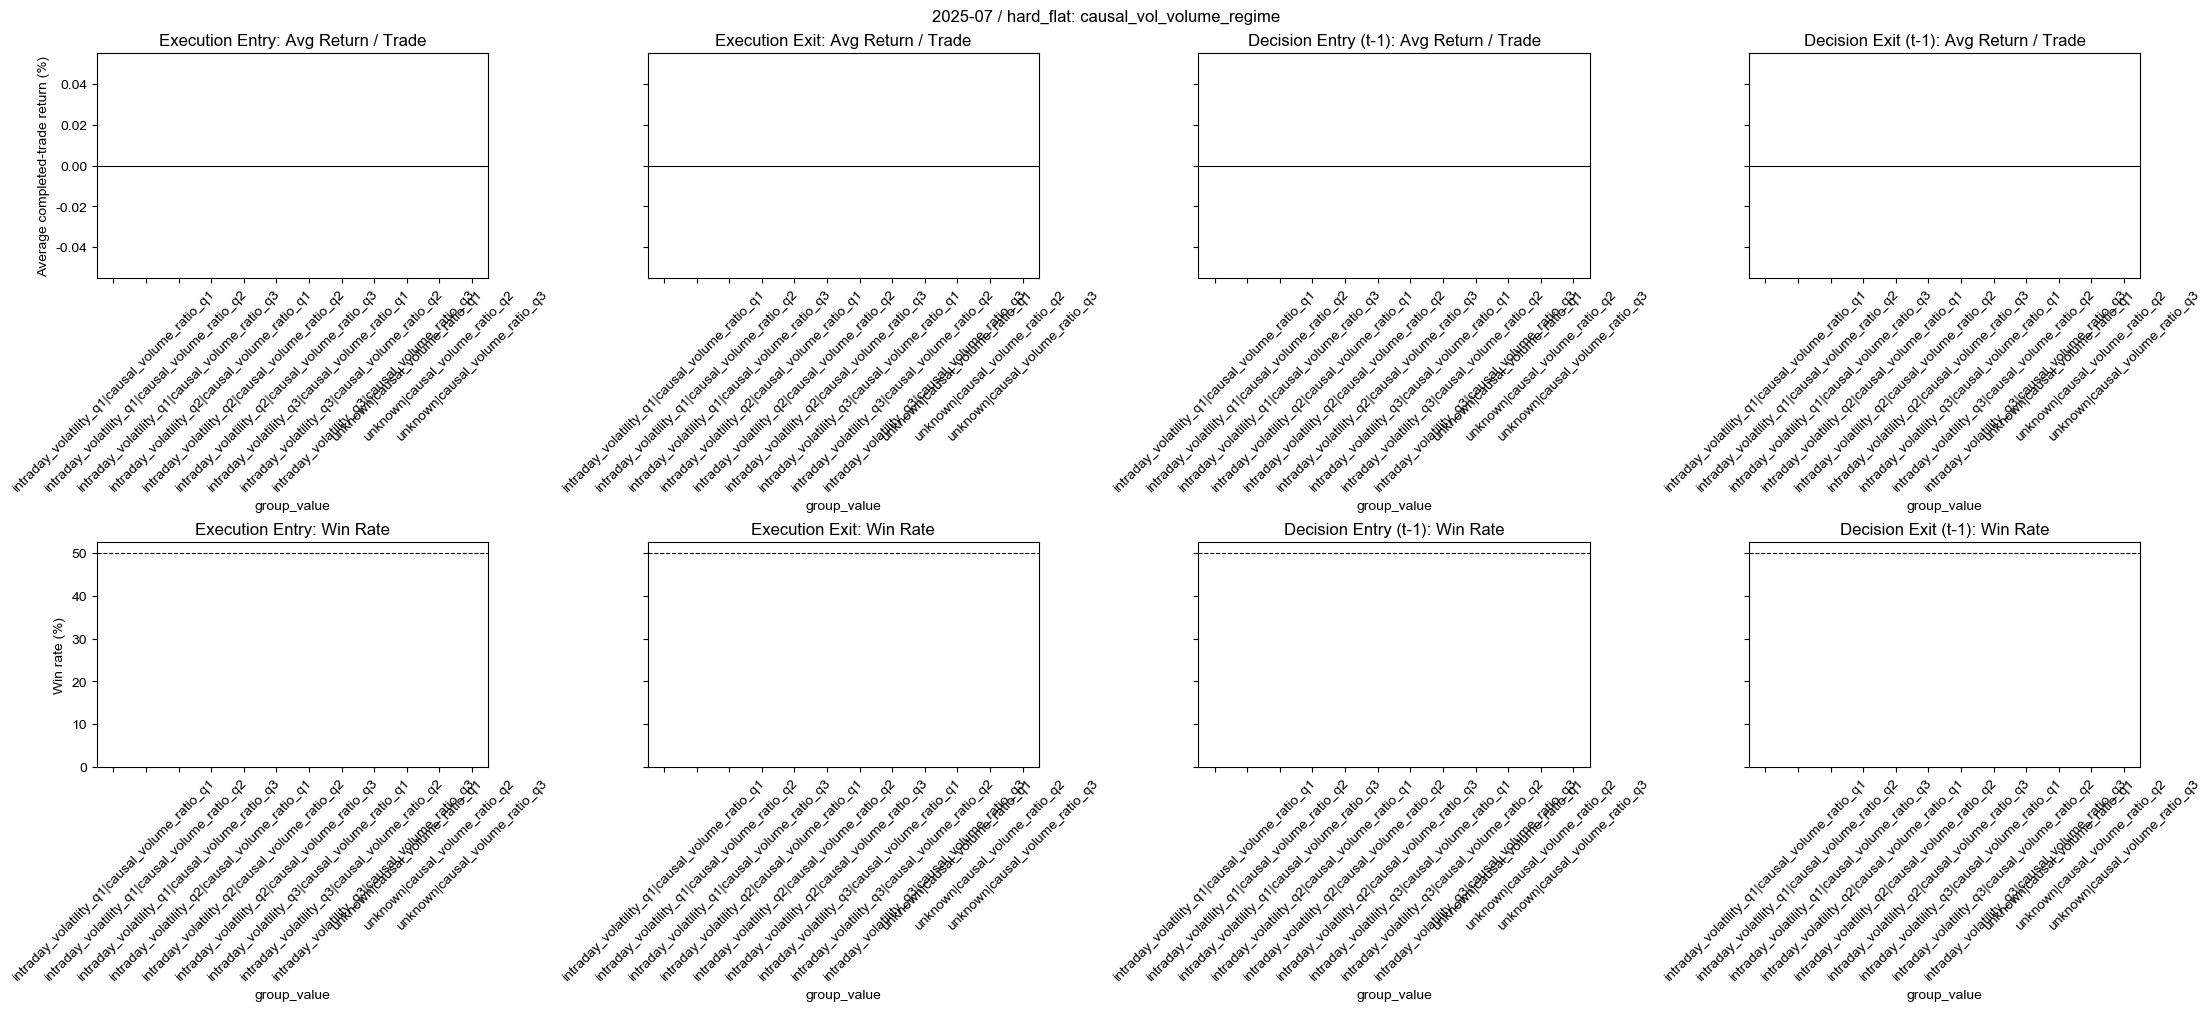

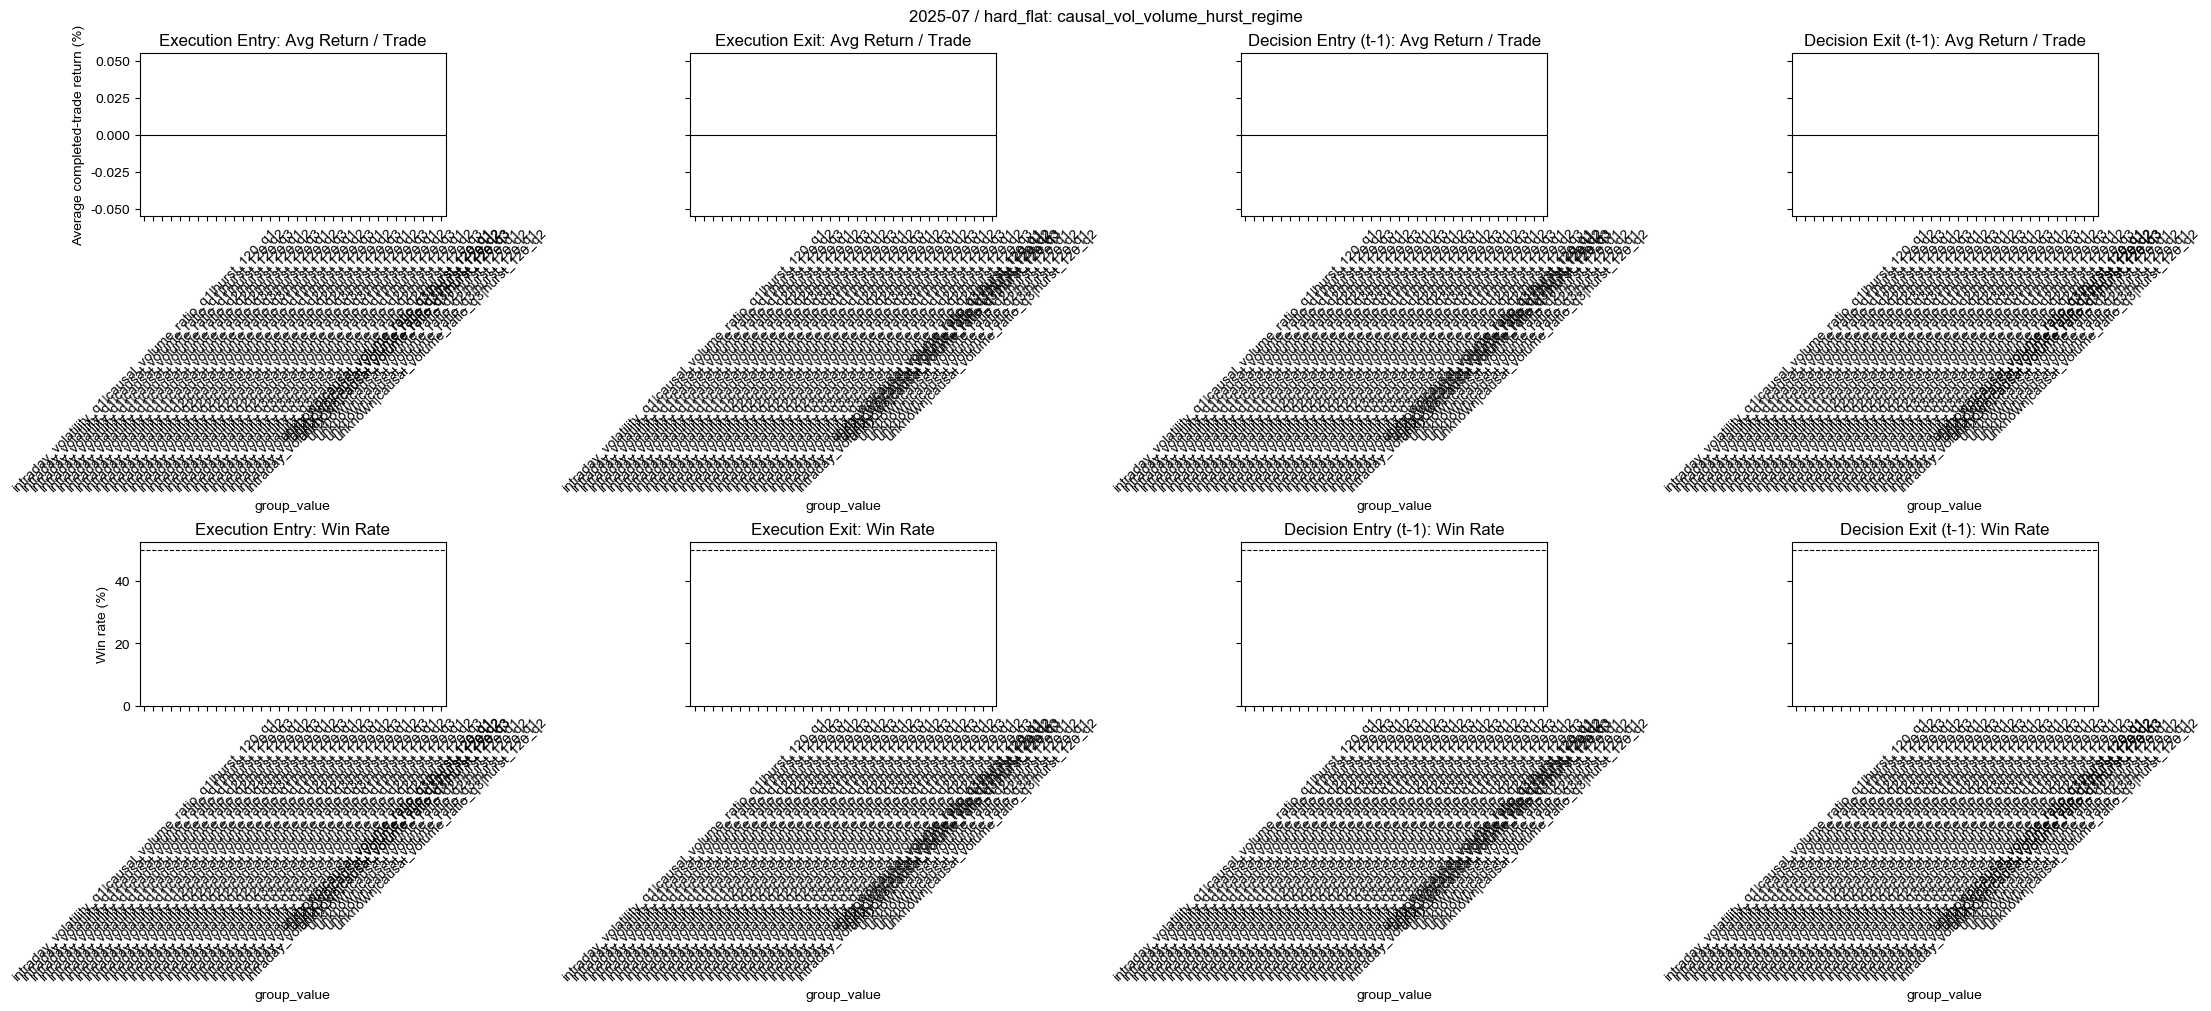

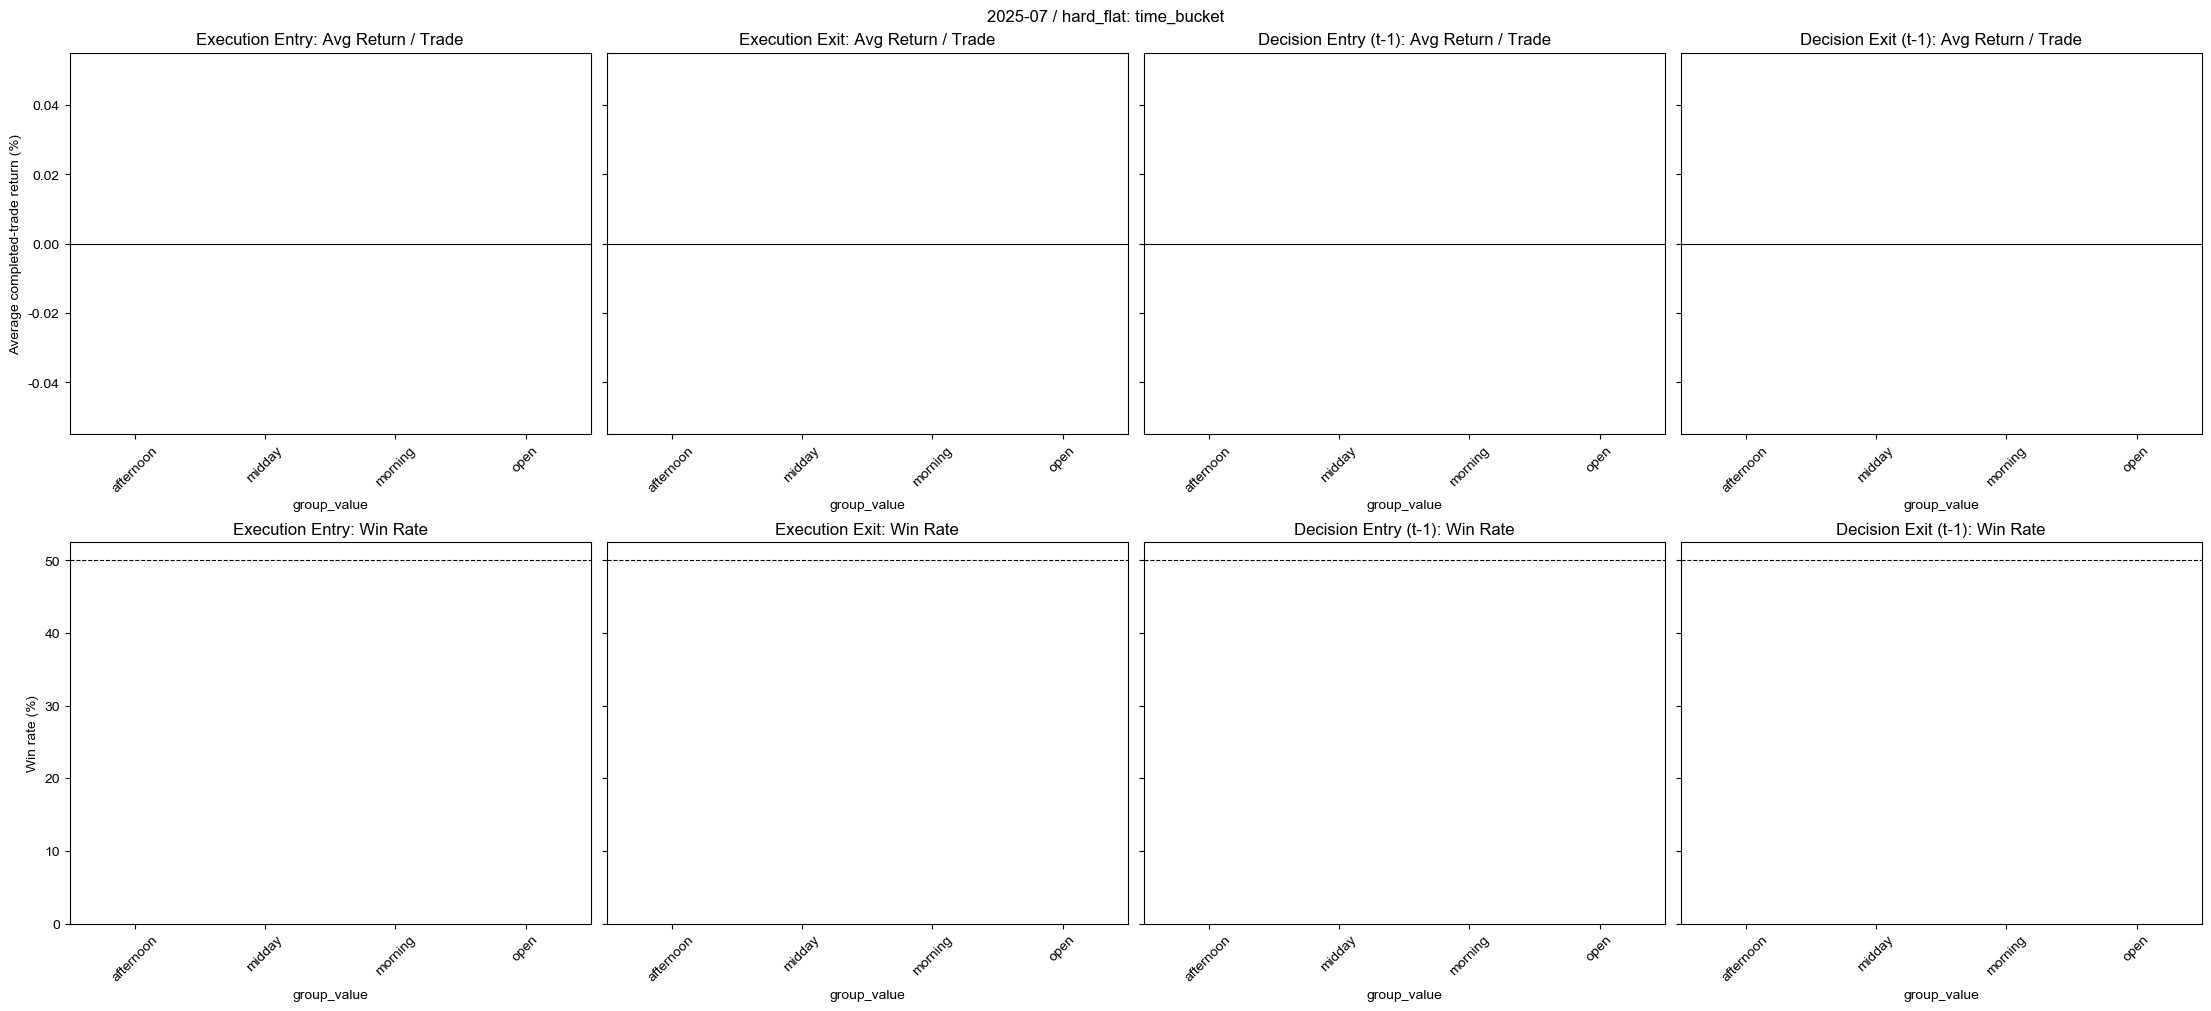

窗口诊断完成: 2025-07 hard_flat -> artifacts/if_alstm_rolling_3state_intra_2025/window_diagnostics/2025-07/hard_flat/diagnostic_report.md


/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:274: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  inferred = out[[c for c in ("prob_down", "prob_flat", "prob_up") if c in out]].idxmax(axis=1)
/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:299: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out["strategy_return"] = pd.to_numeric(out["account"], errors="coerce").pct_change()


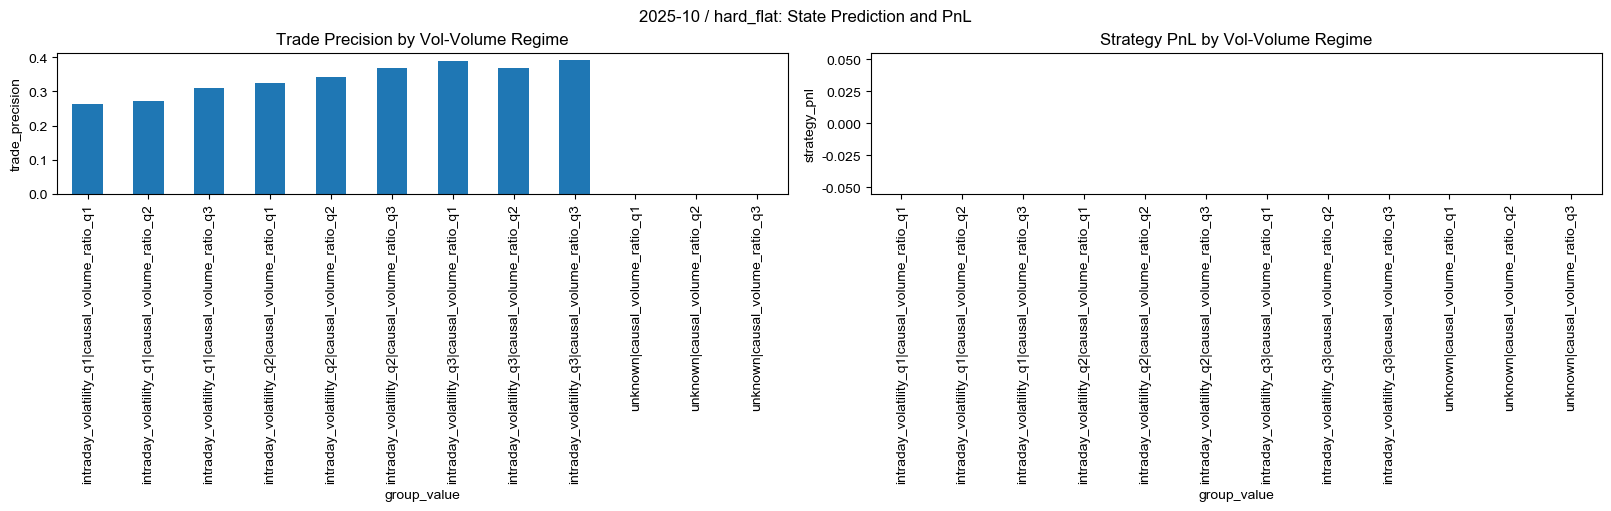

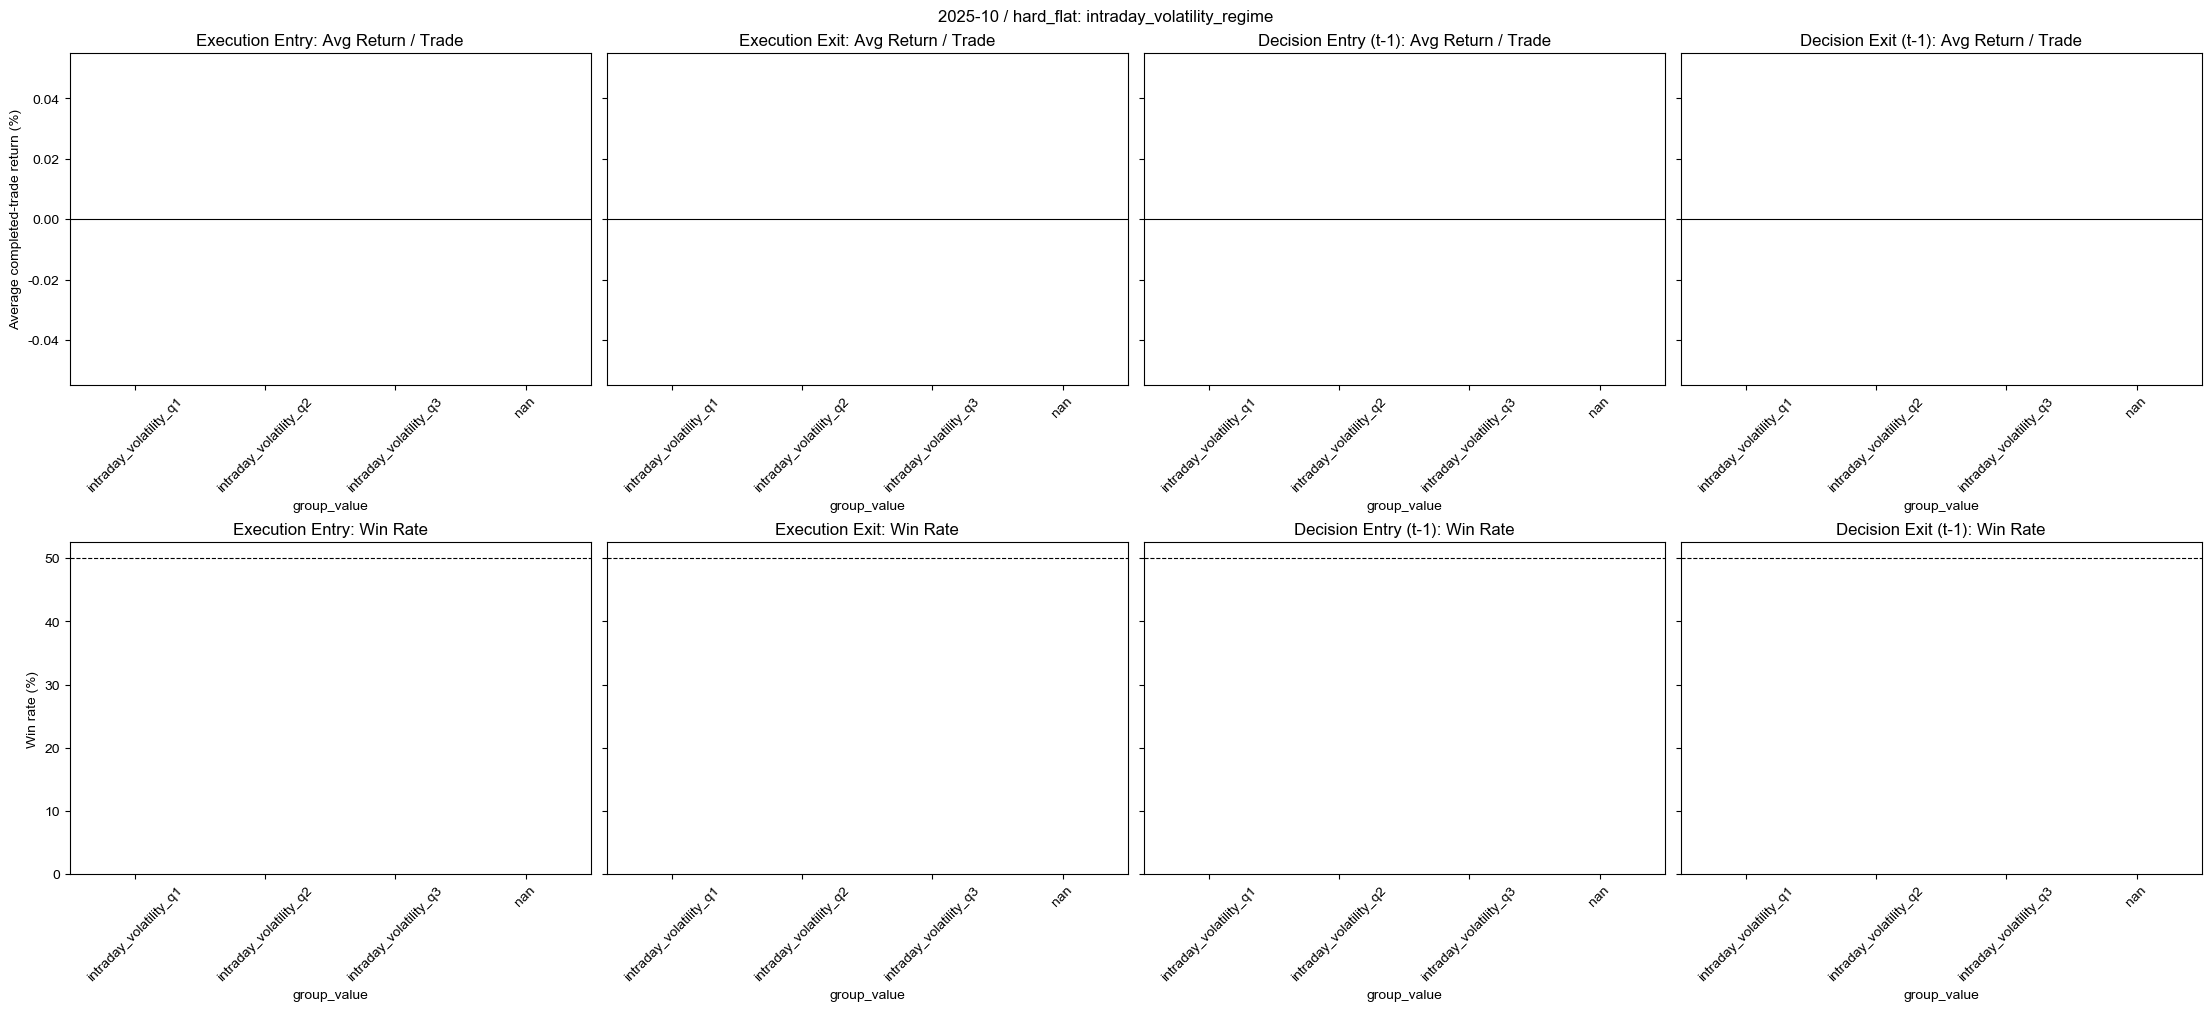

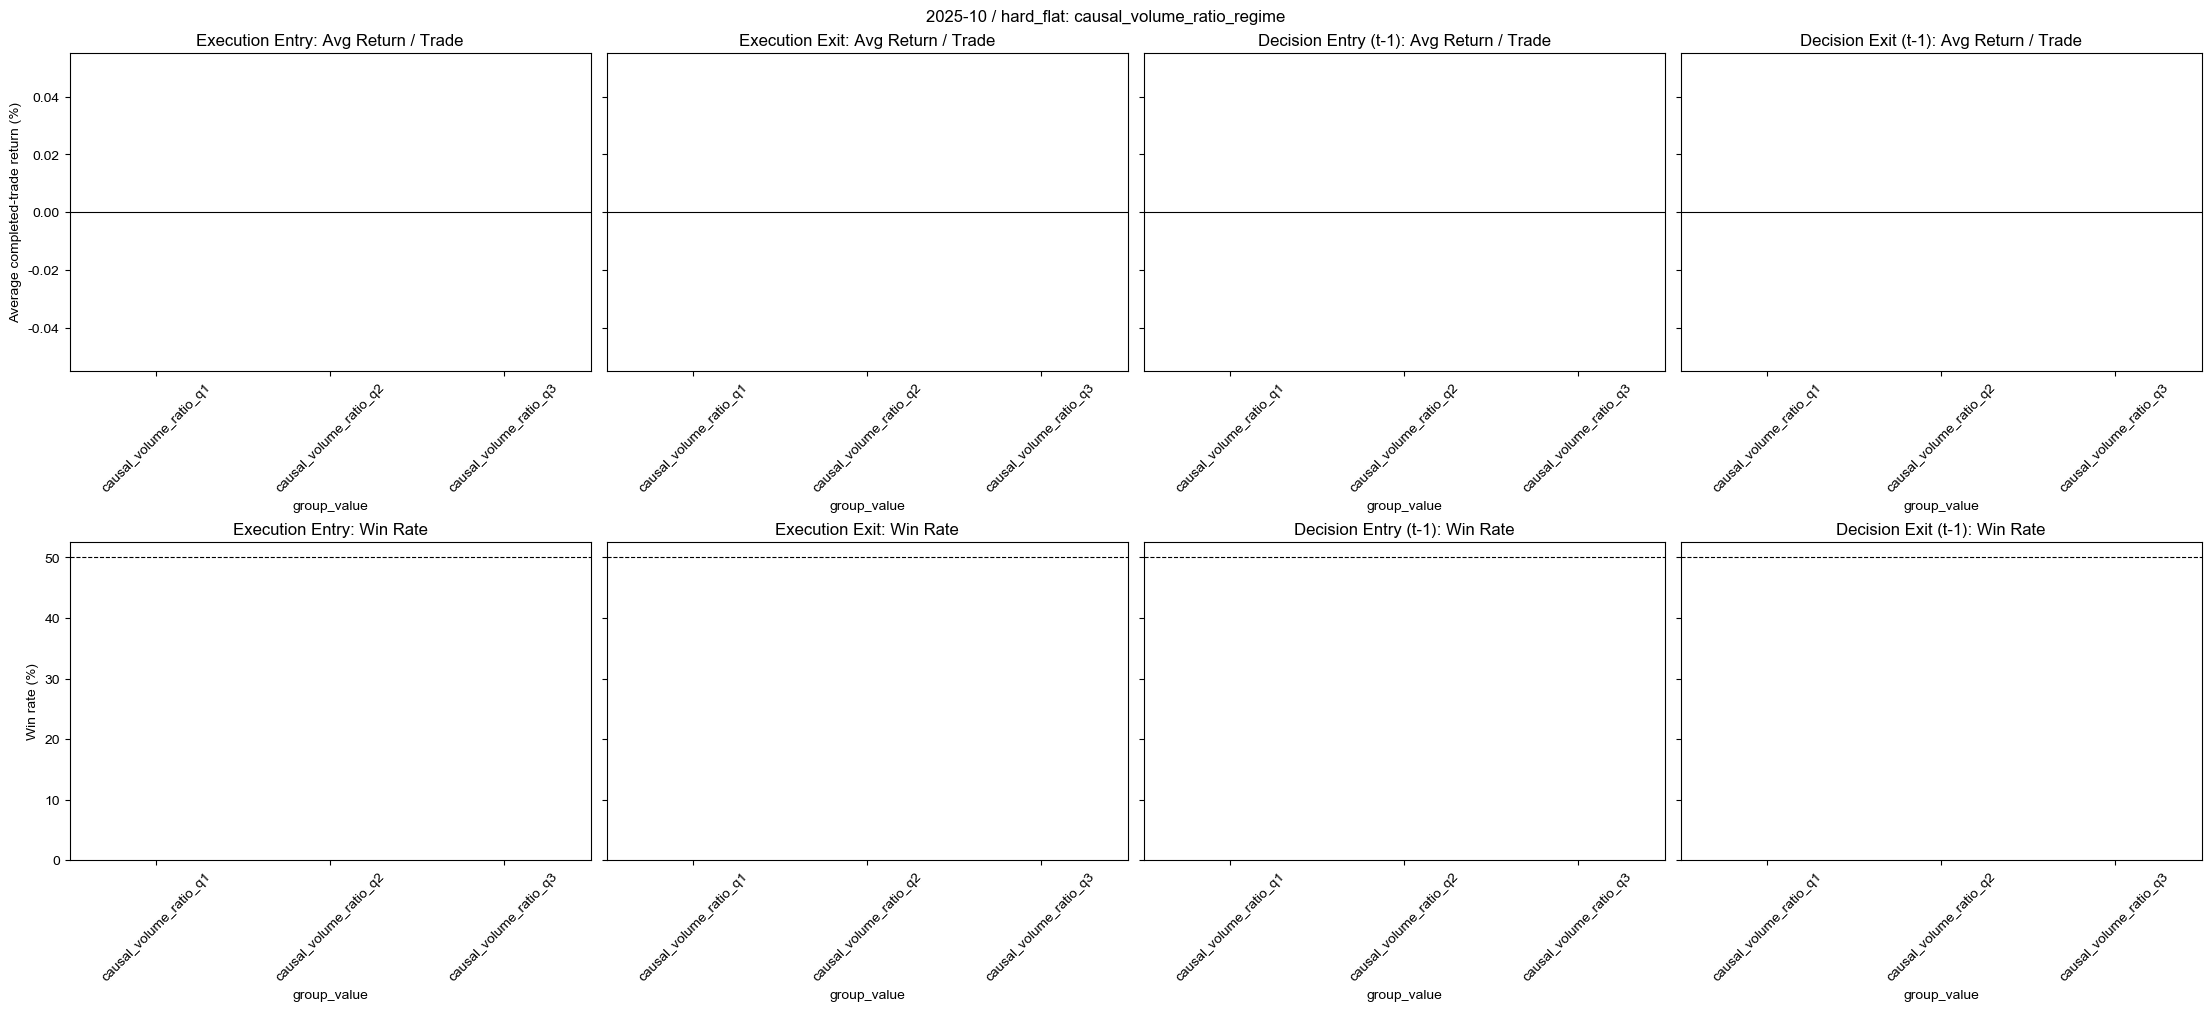

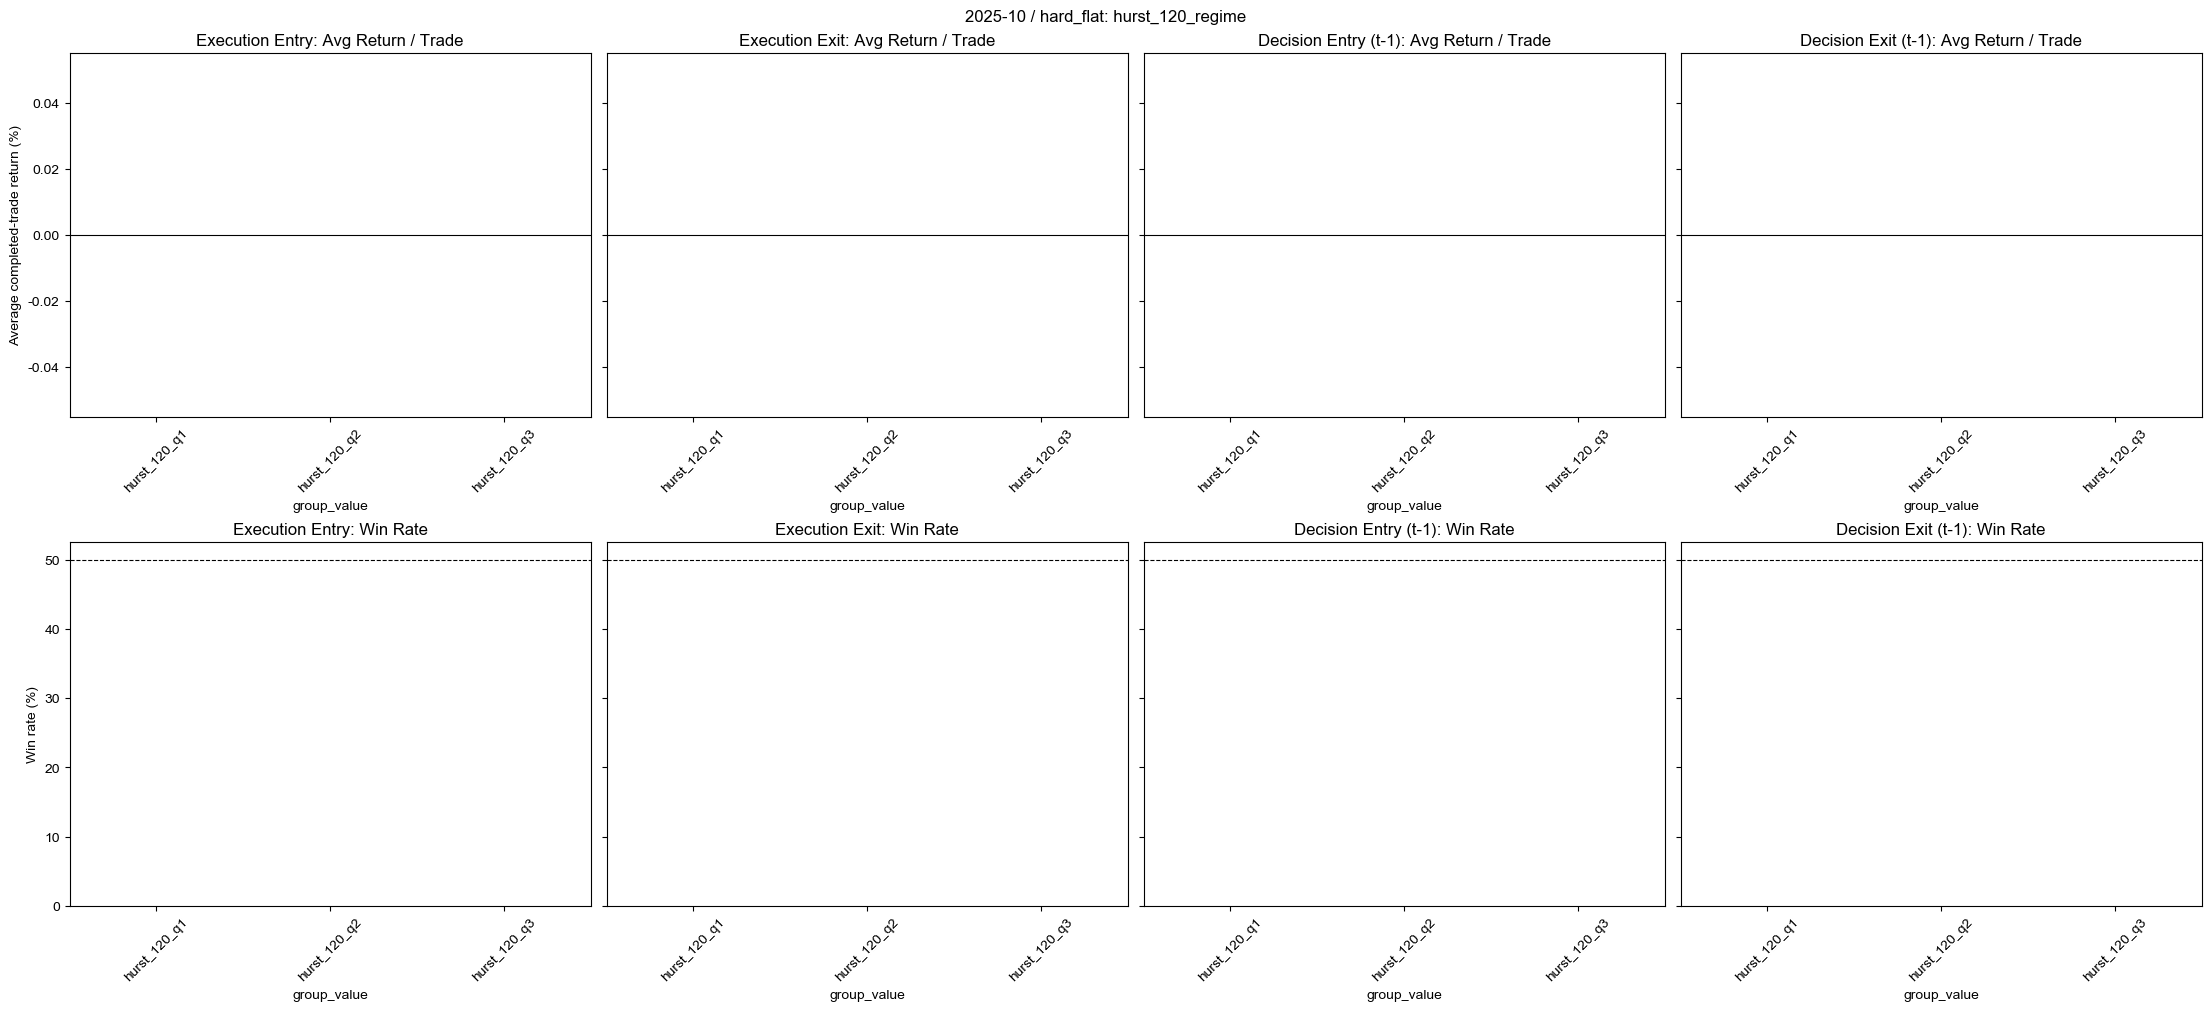

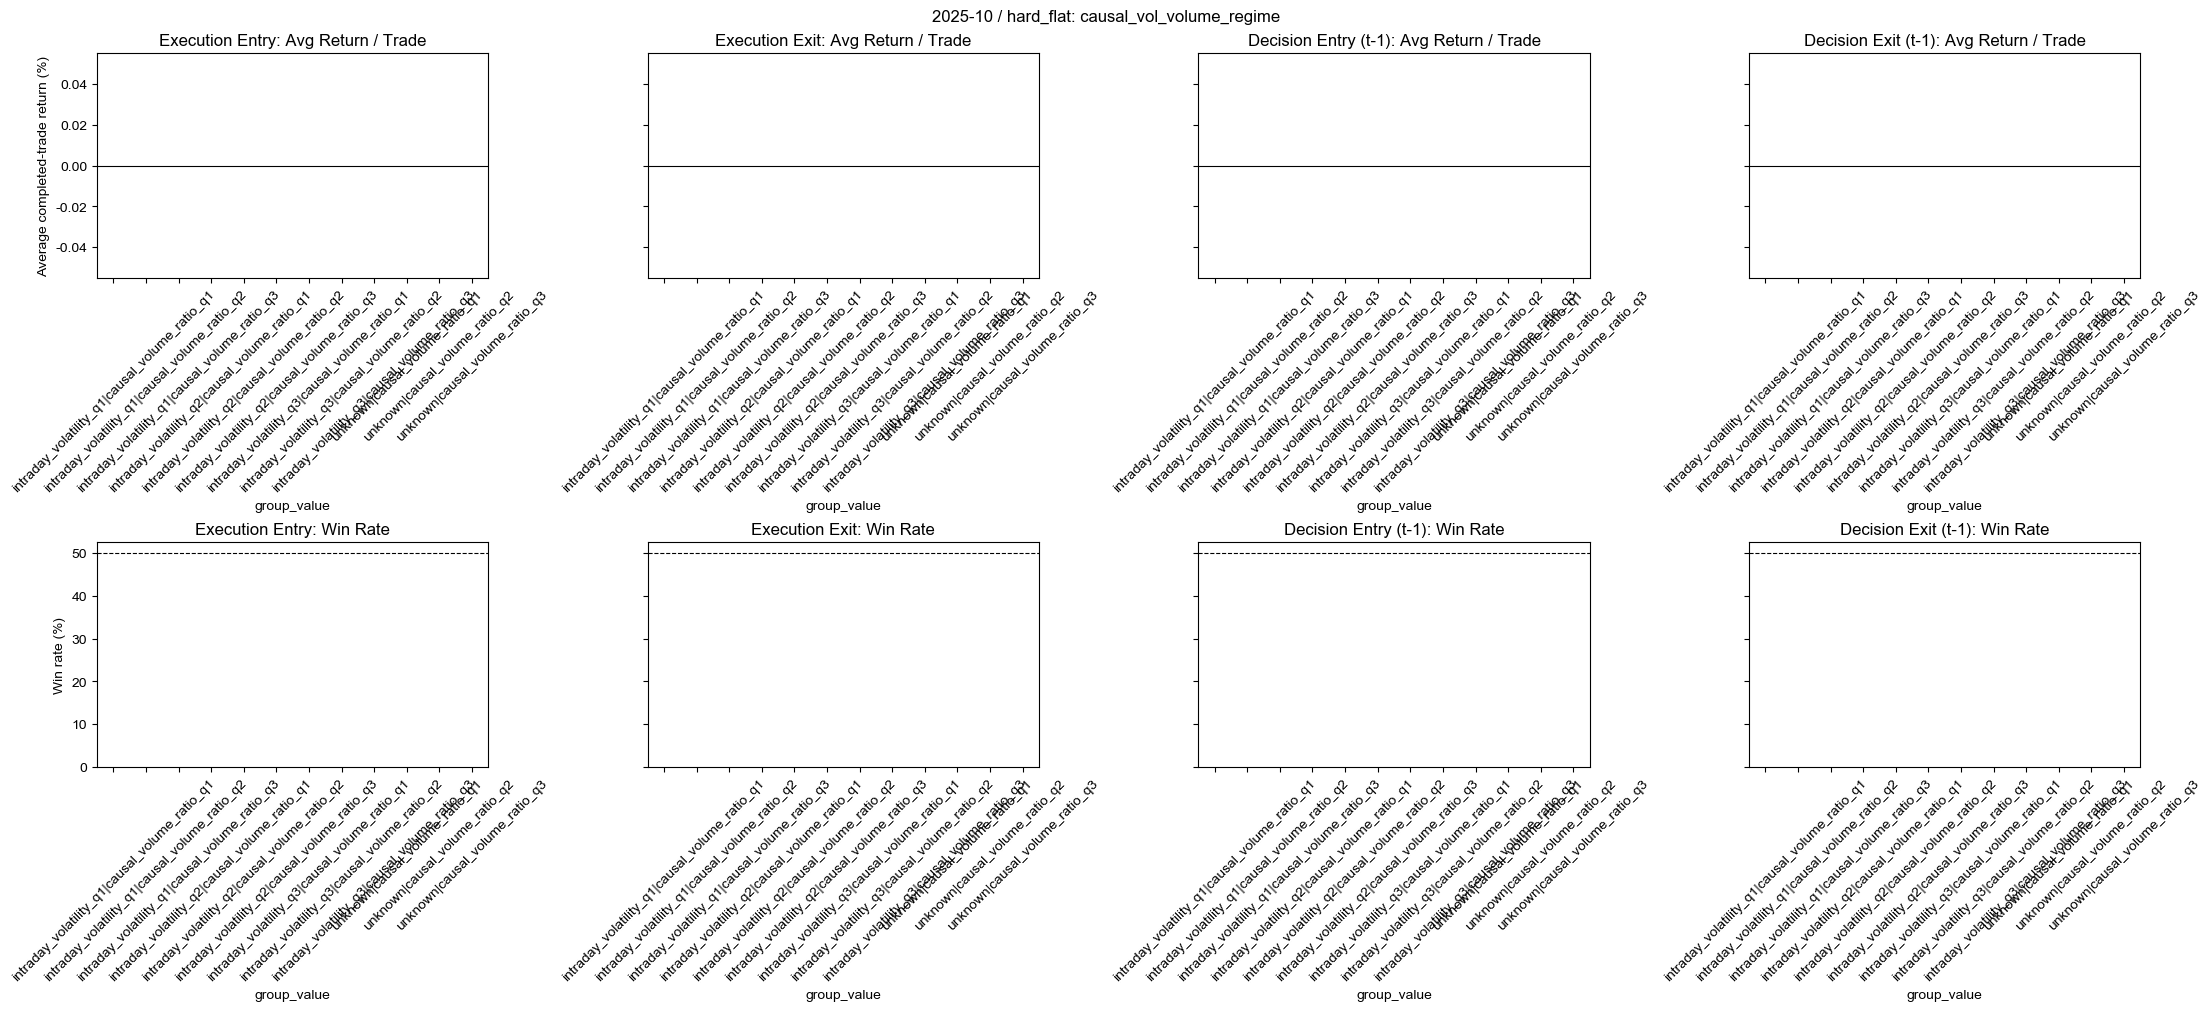

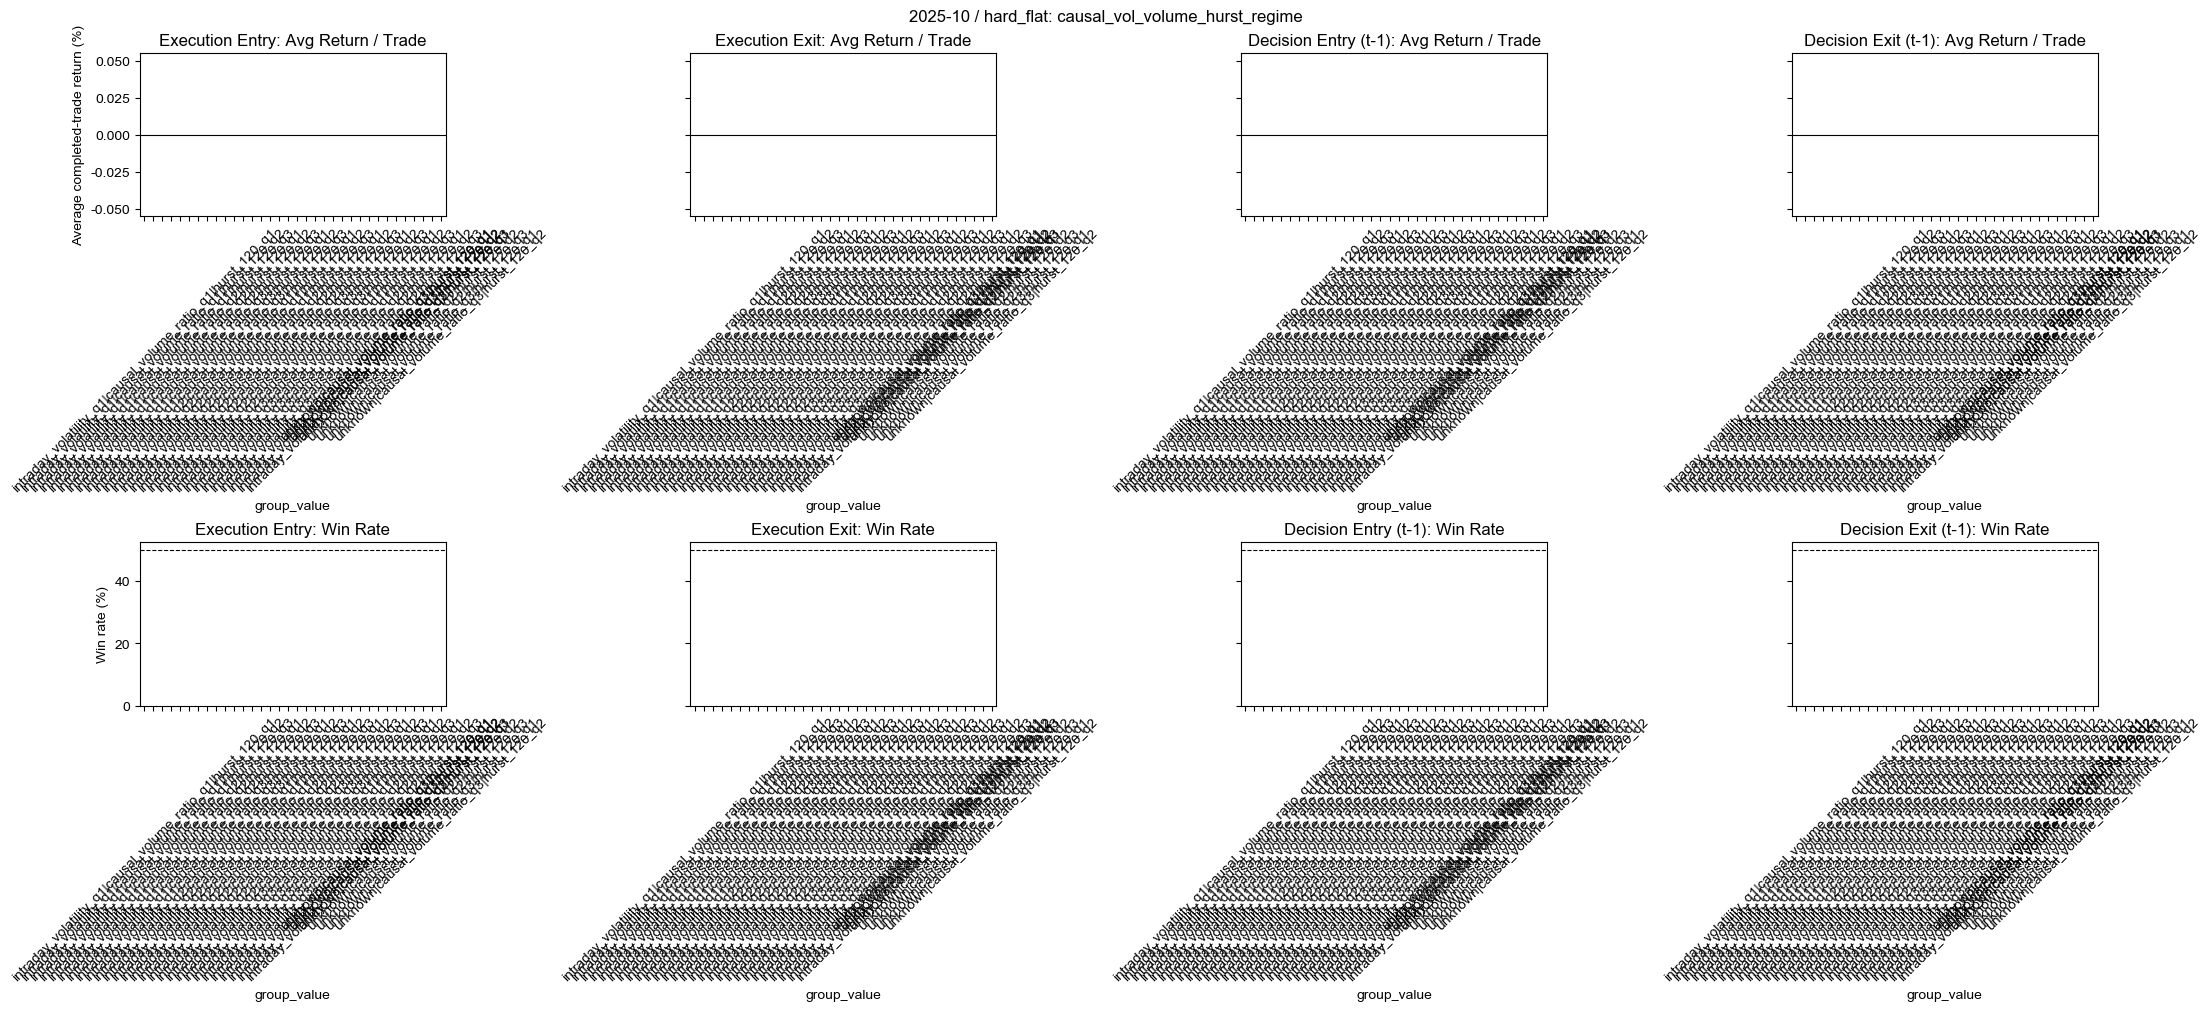

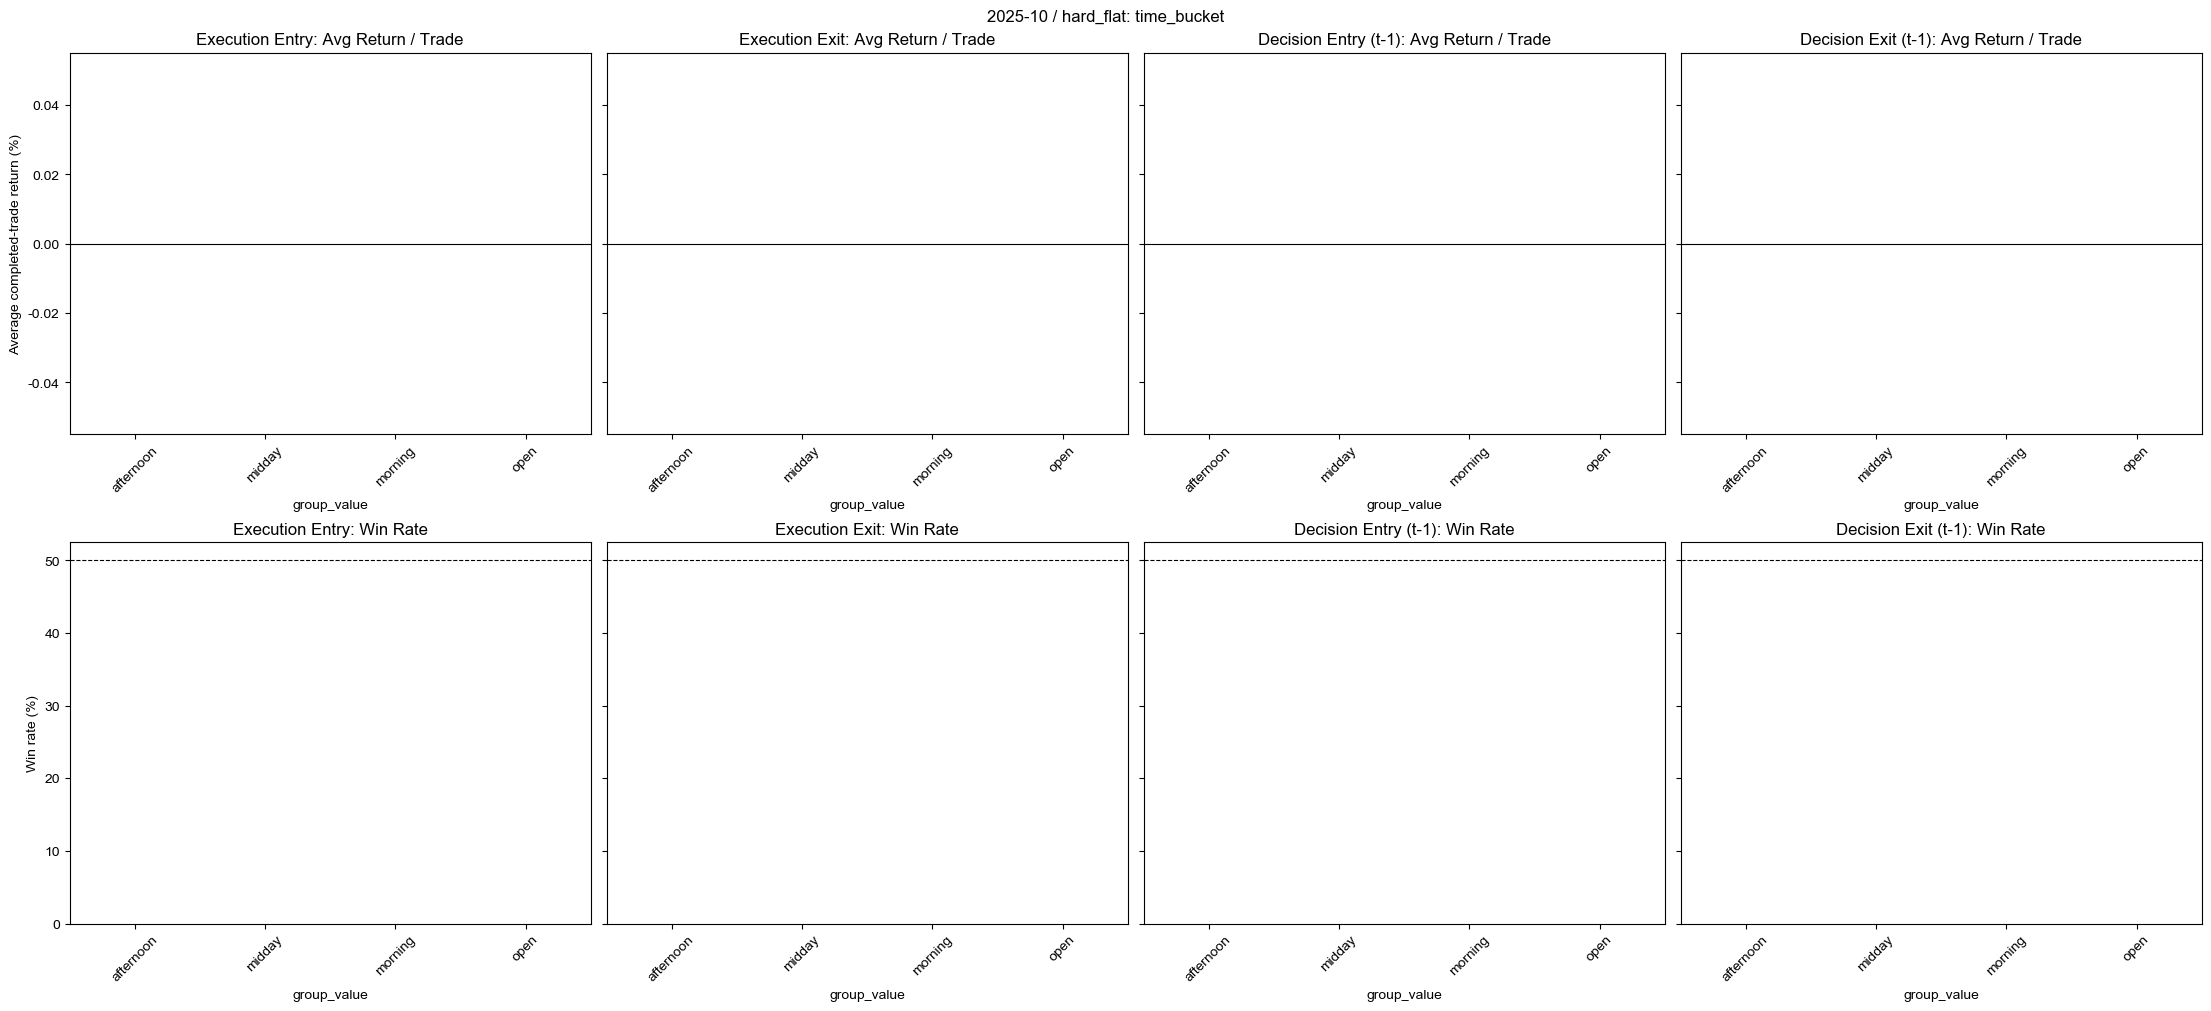

窗口诊断完成: 2025-10 hard_flat -> artifacts/if_alstm_rolling_3state_intra_2025/window_diagnostics/2025-10/hard_flat/diagnostic_report.md


window diagnostics hysteresis_flat2:   0%|          | 0/4 [00:00<?, ?it/s]

/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:274: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  inferred = out[[c for c in ("prob_down", "prob_flat", "prob_up") if c in out]].idxmax(axis=1)
/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:299: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out["strategy_return"] = pd.to_numeric(out["account"], errors="coerce").pct_change()


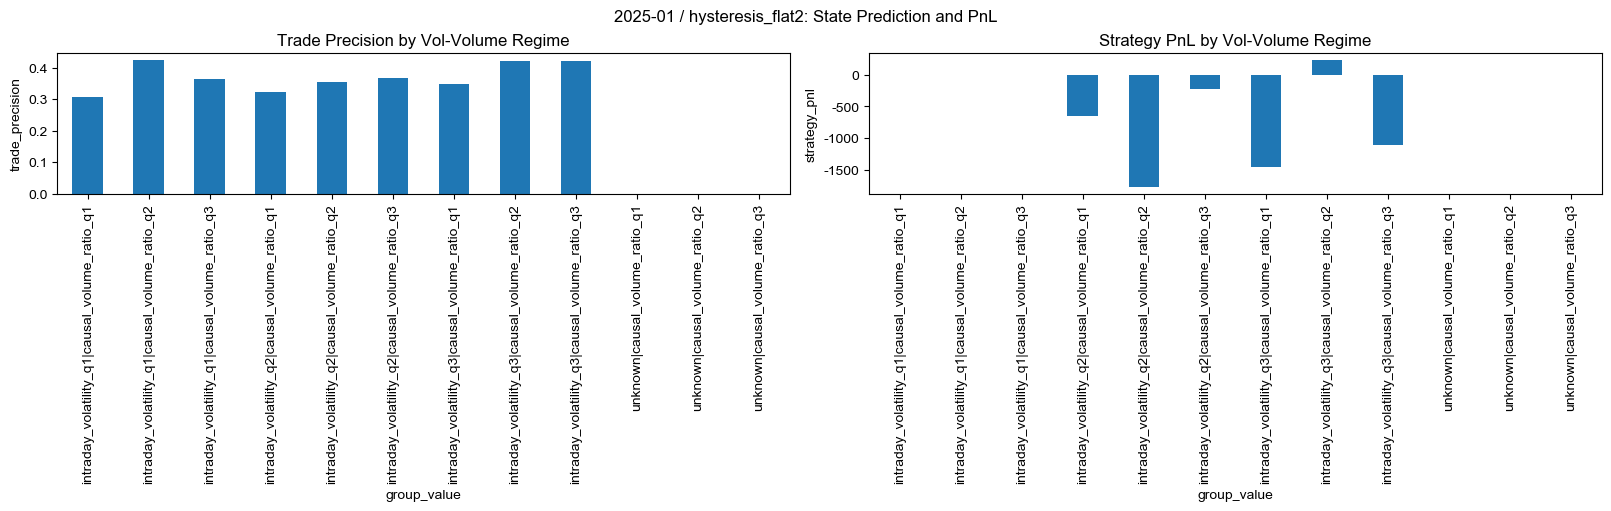

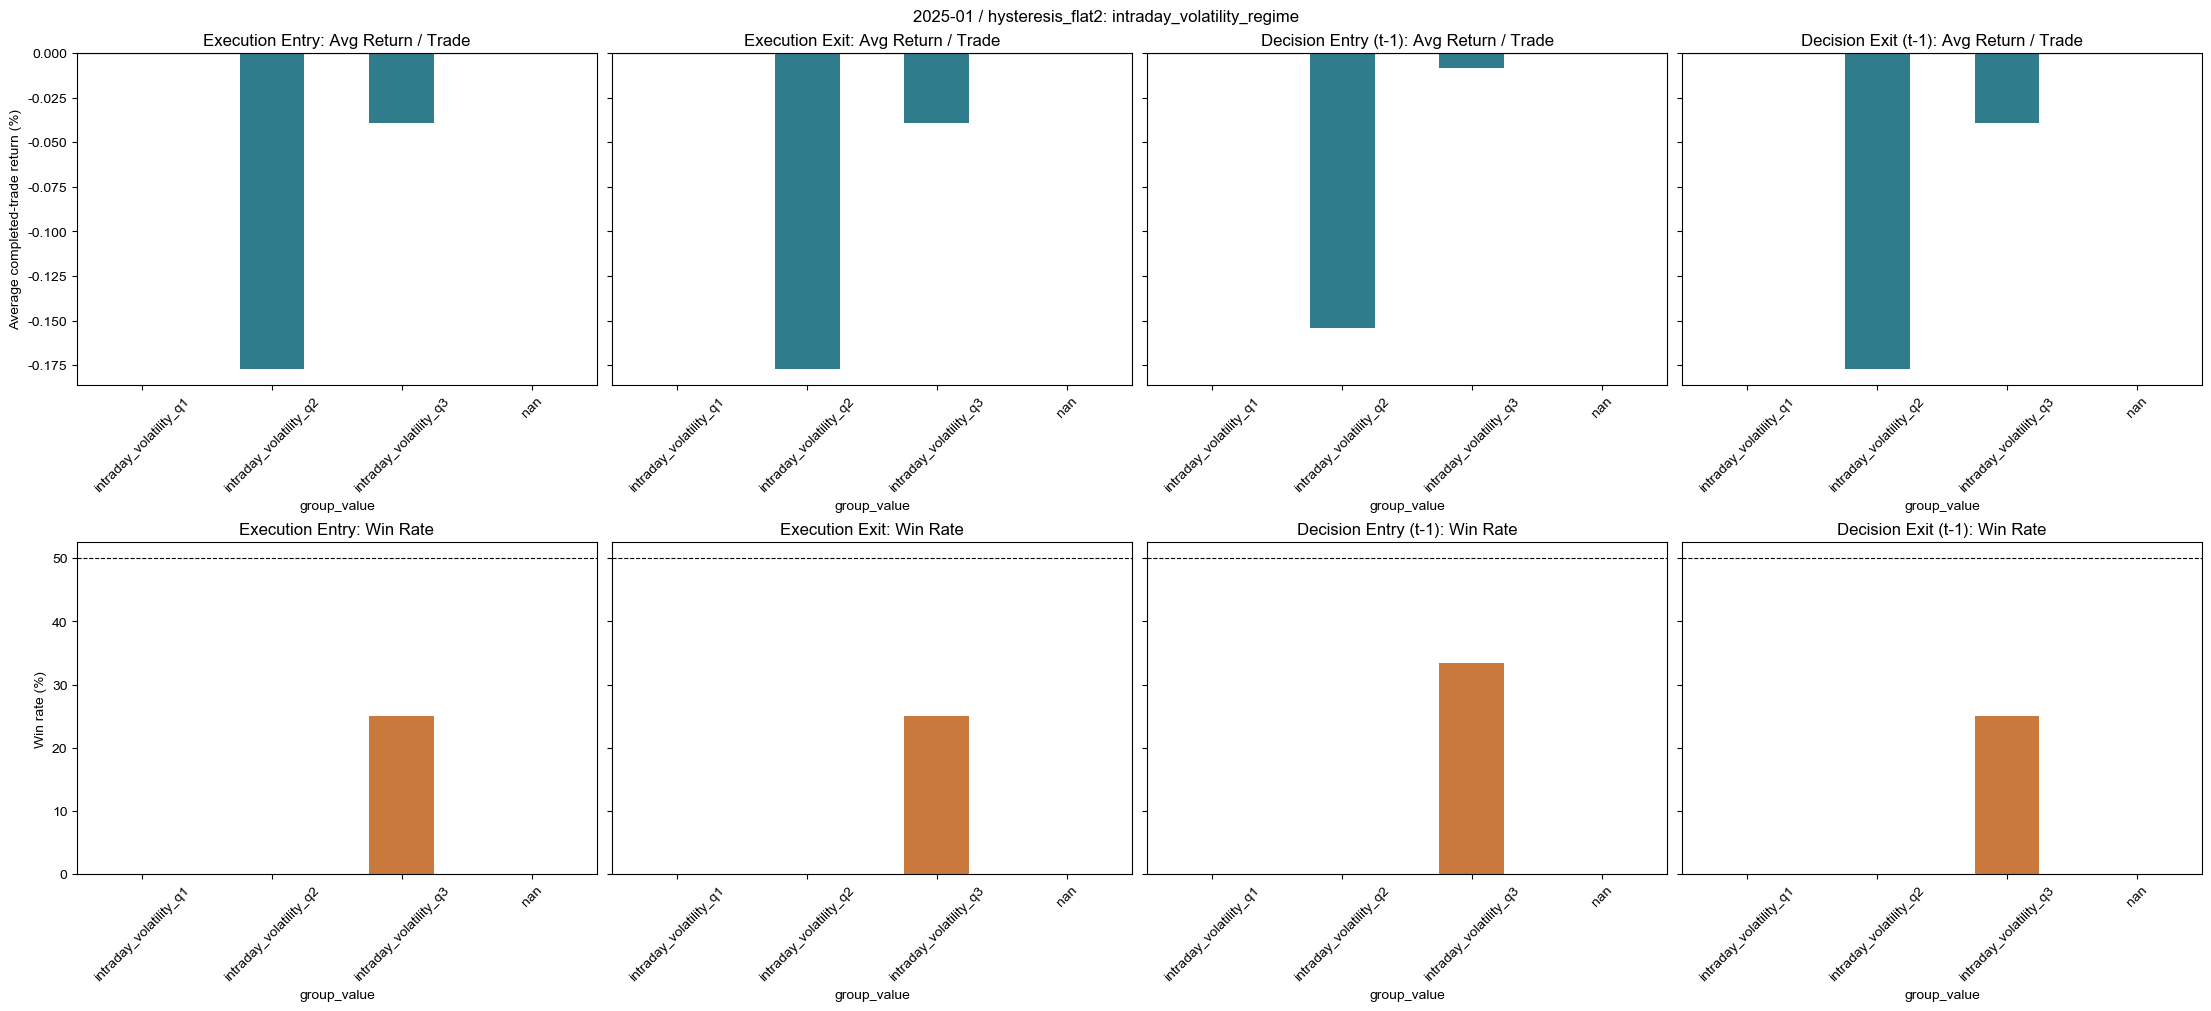

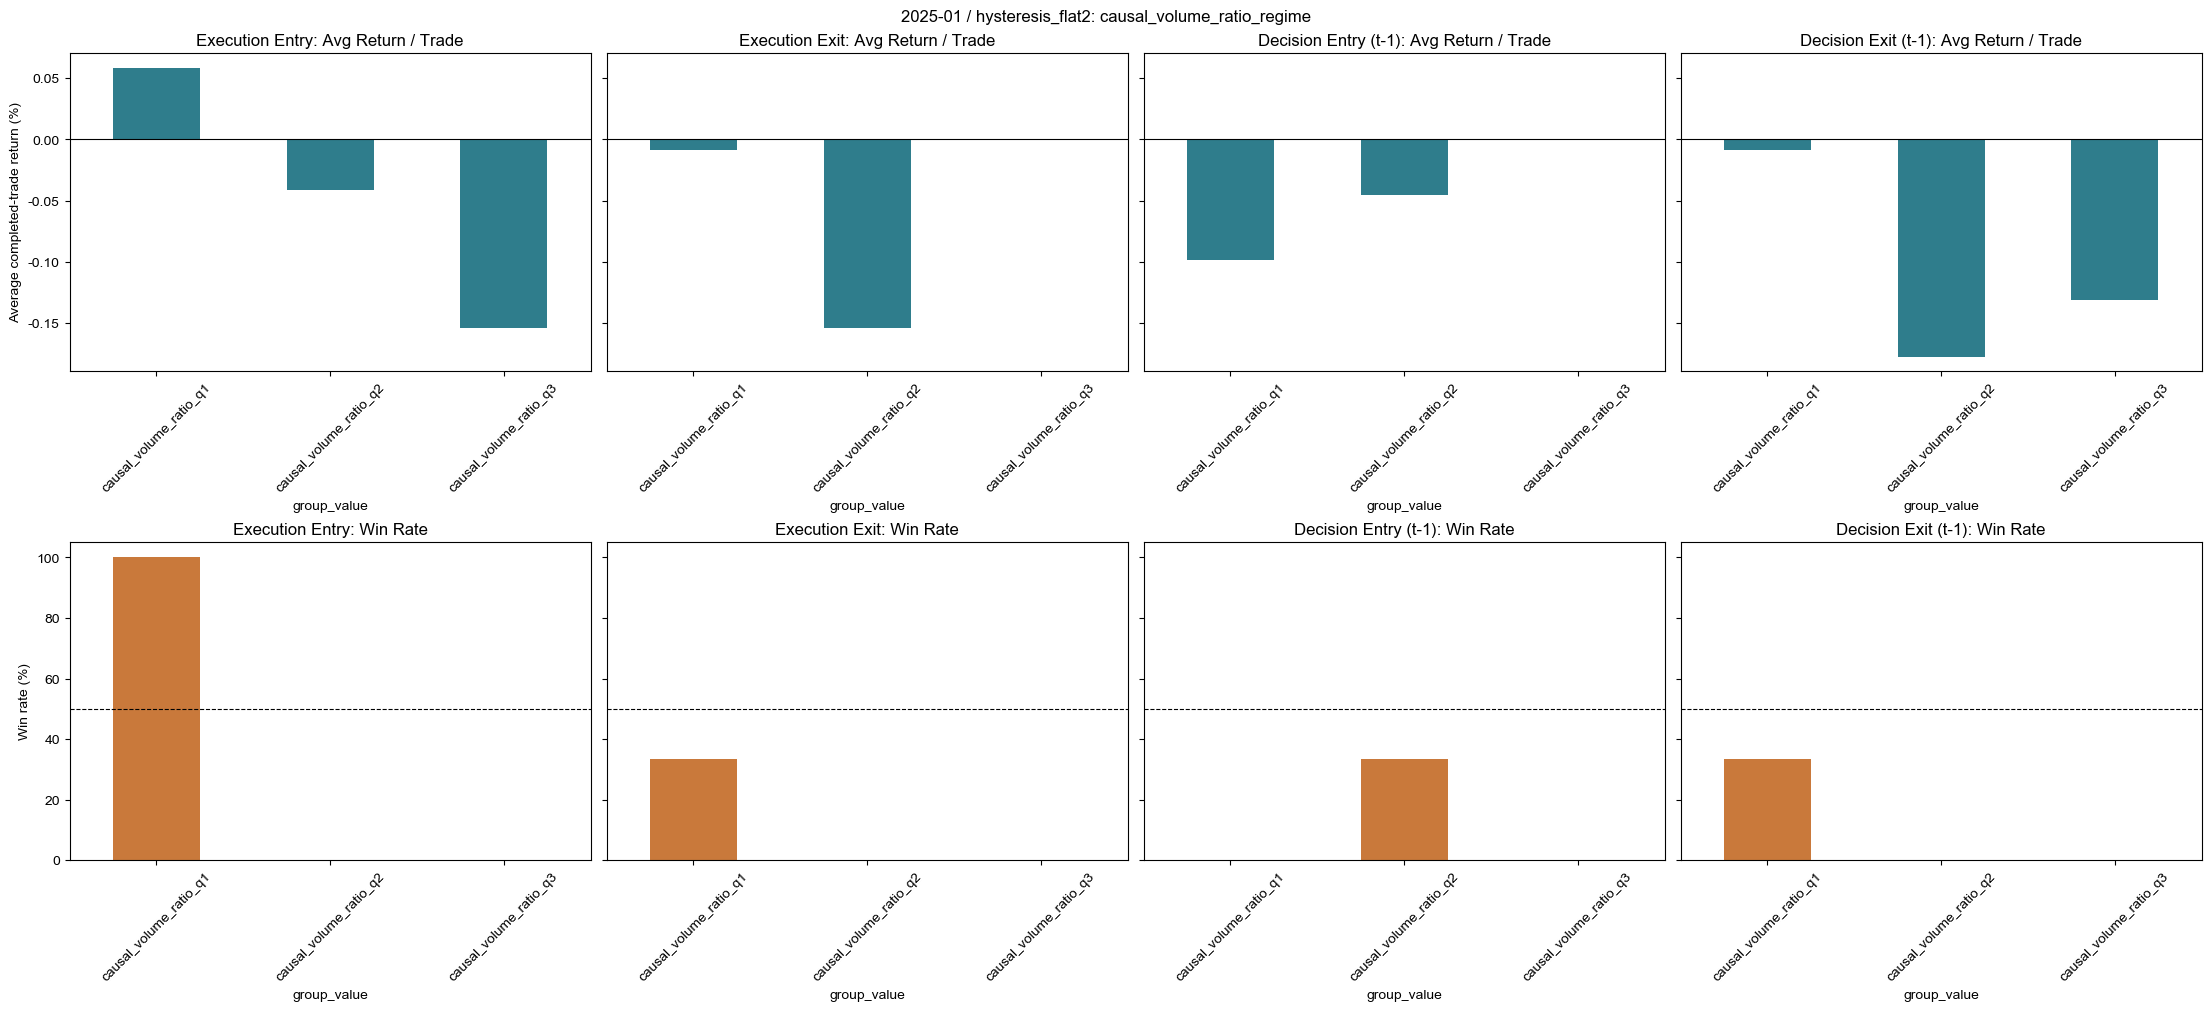

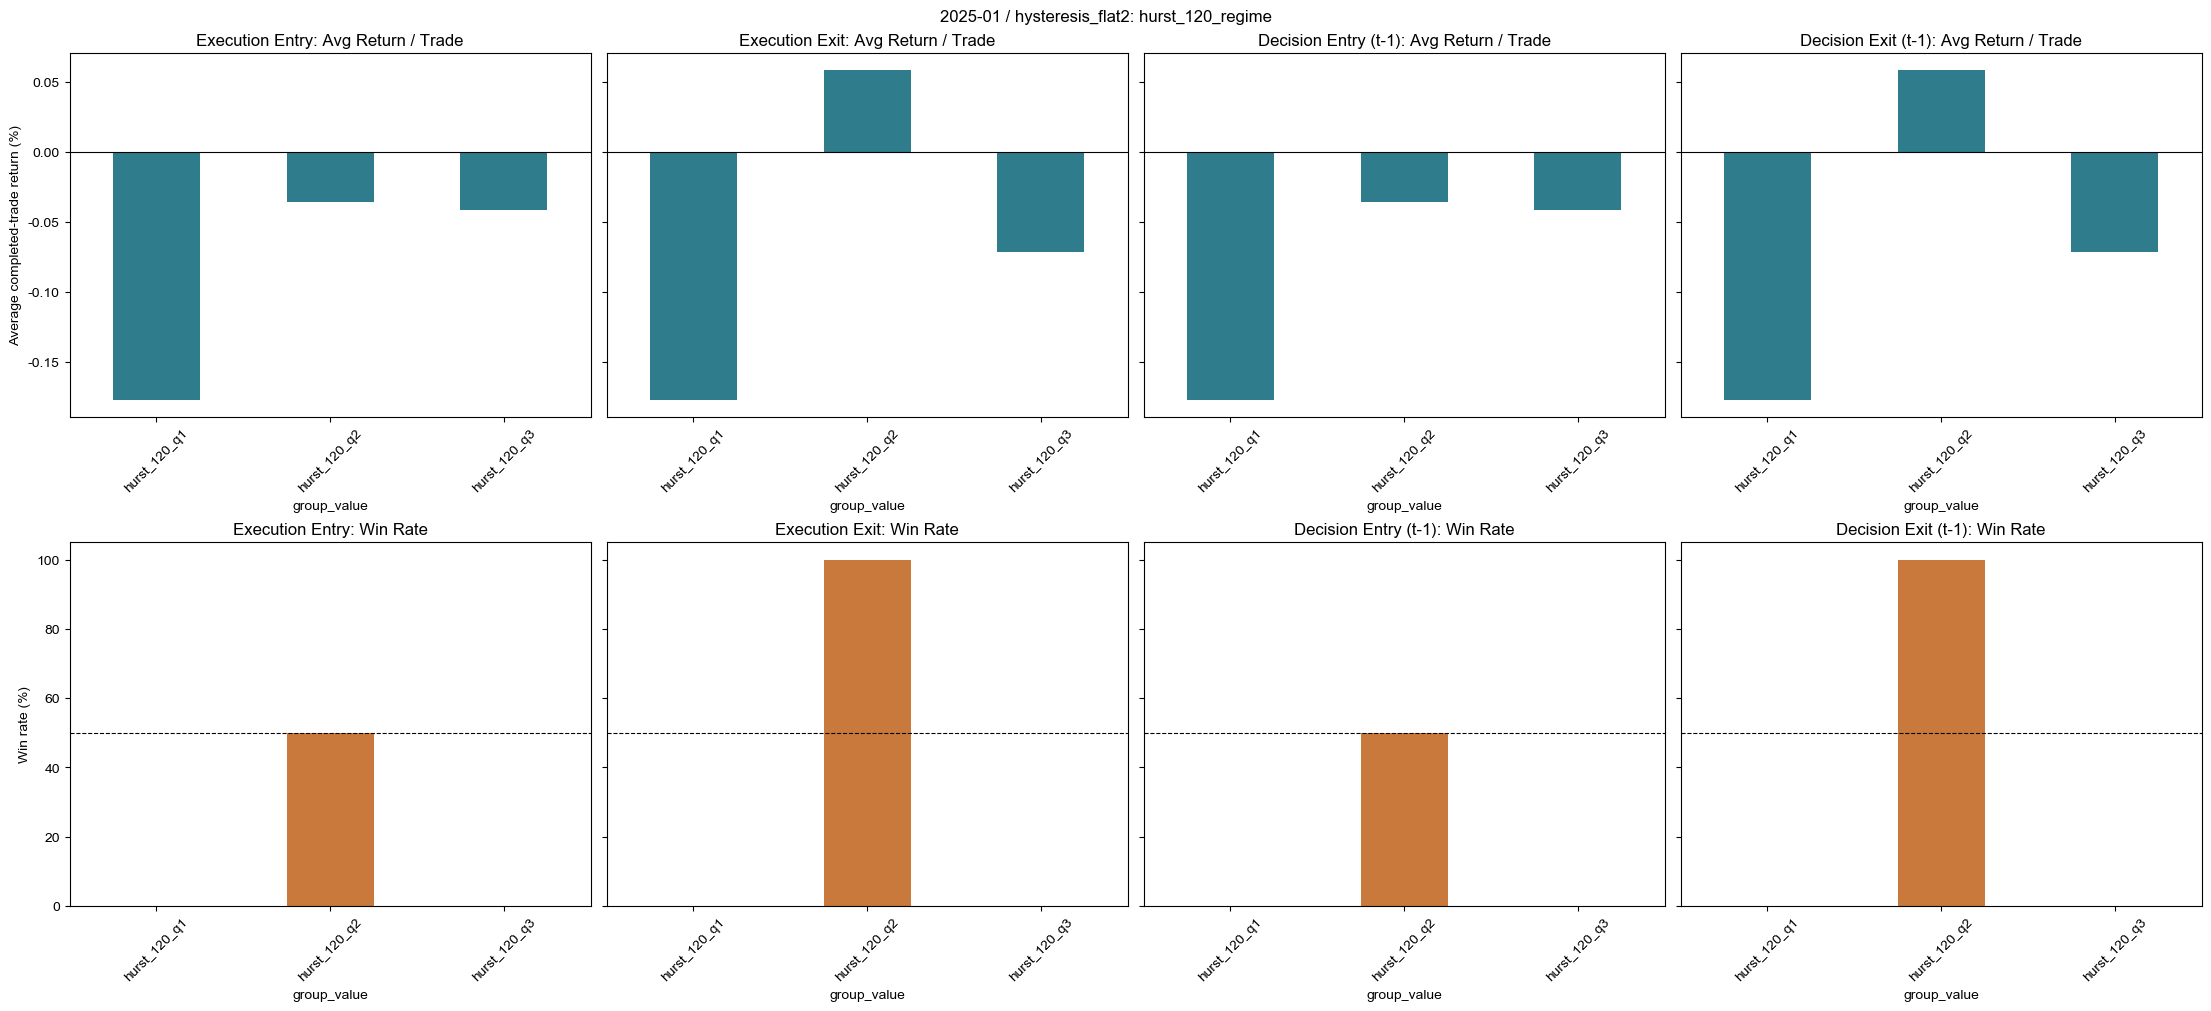

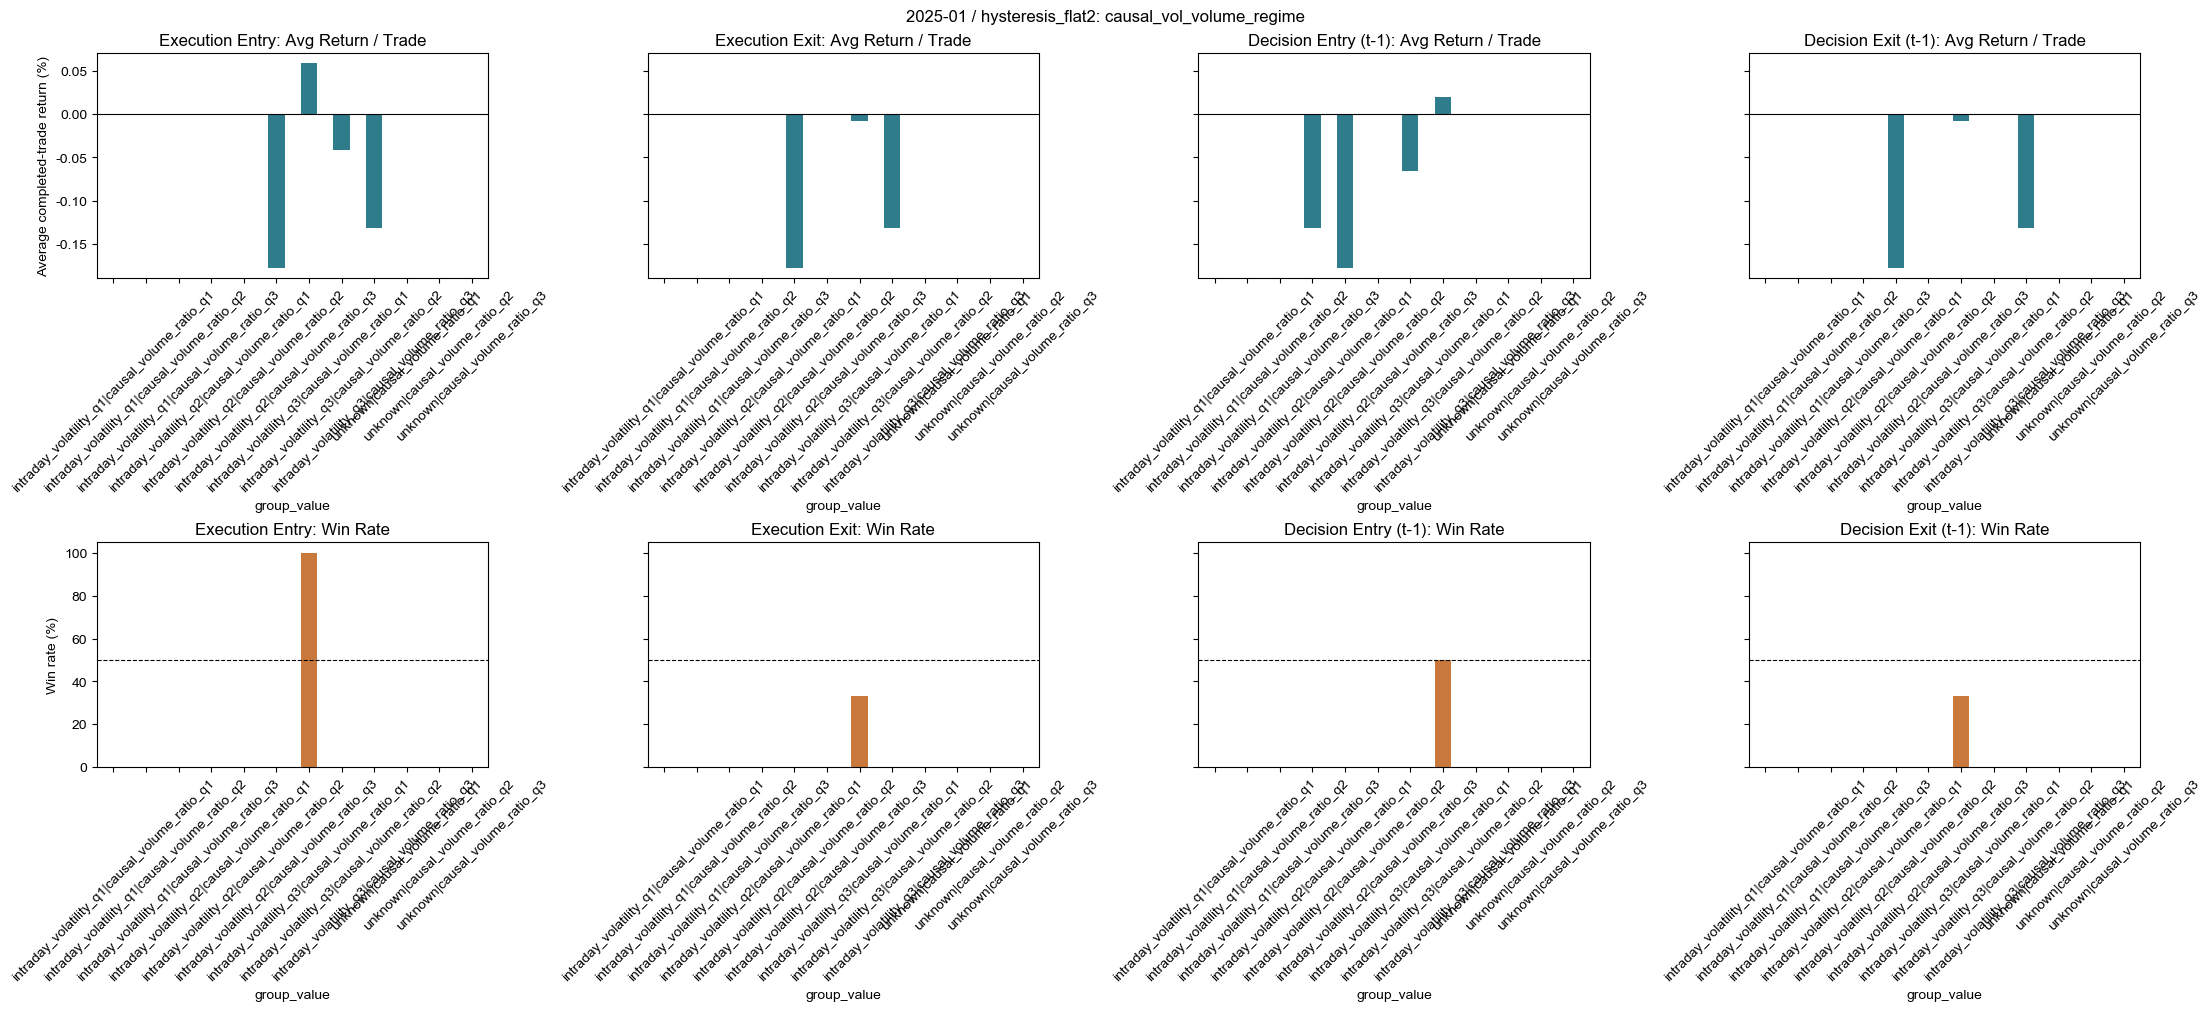

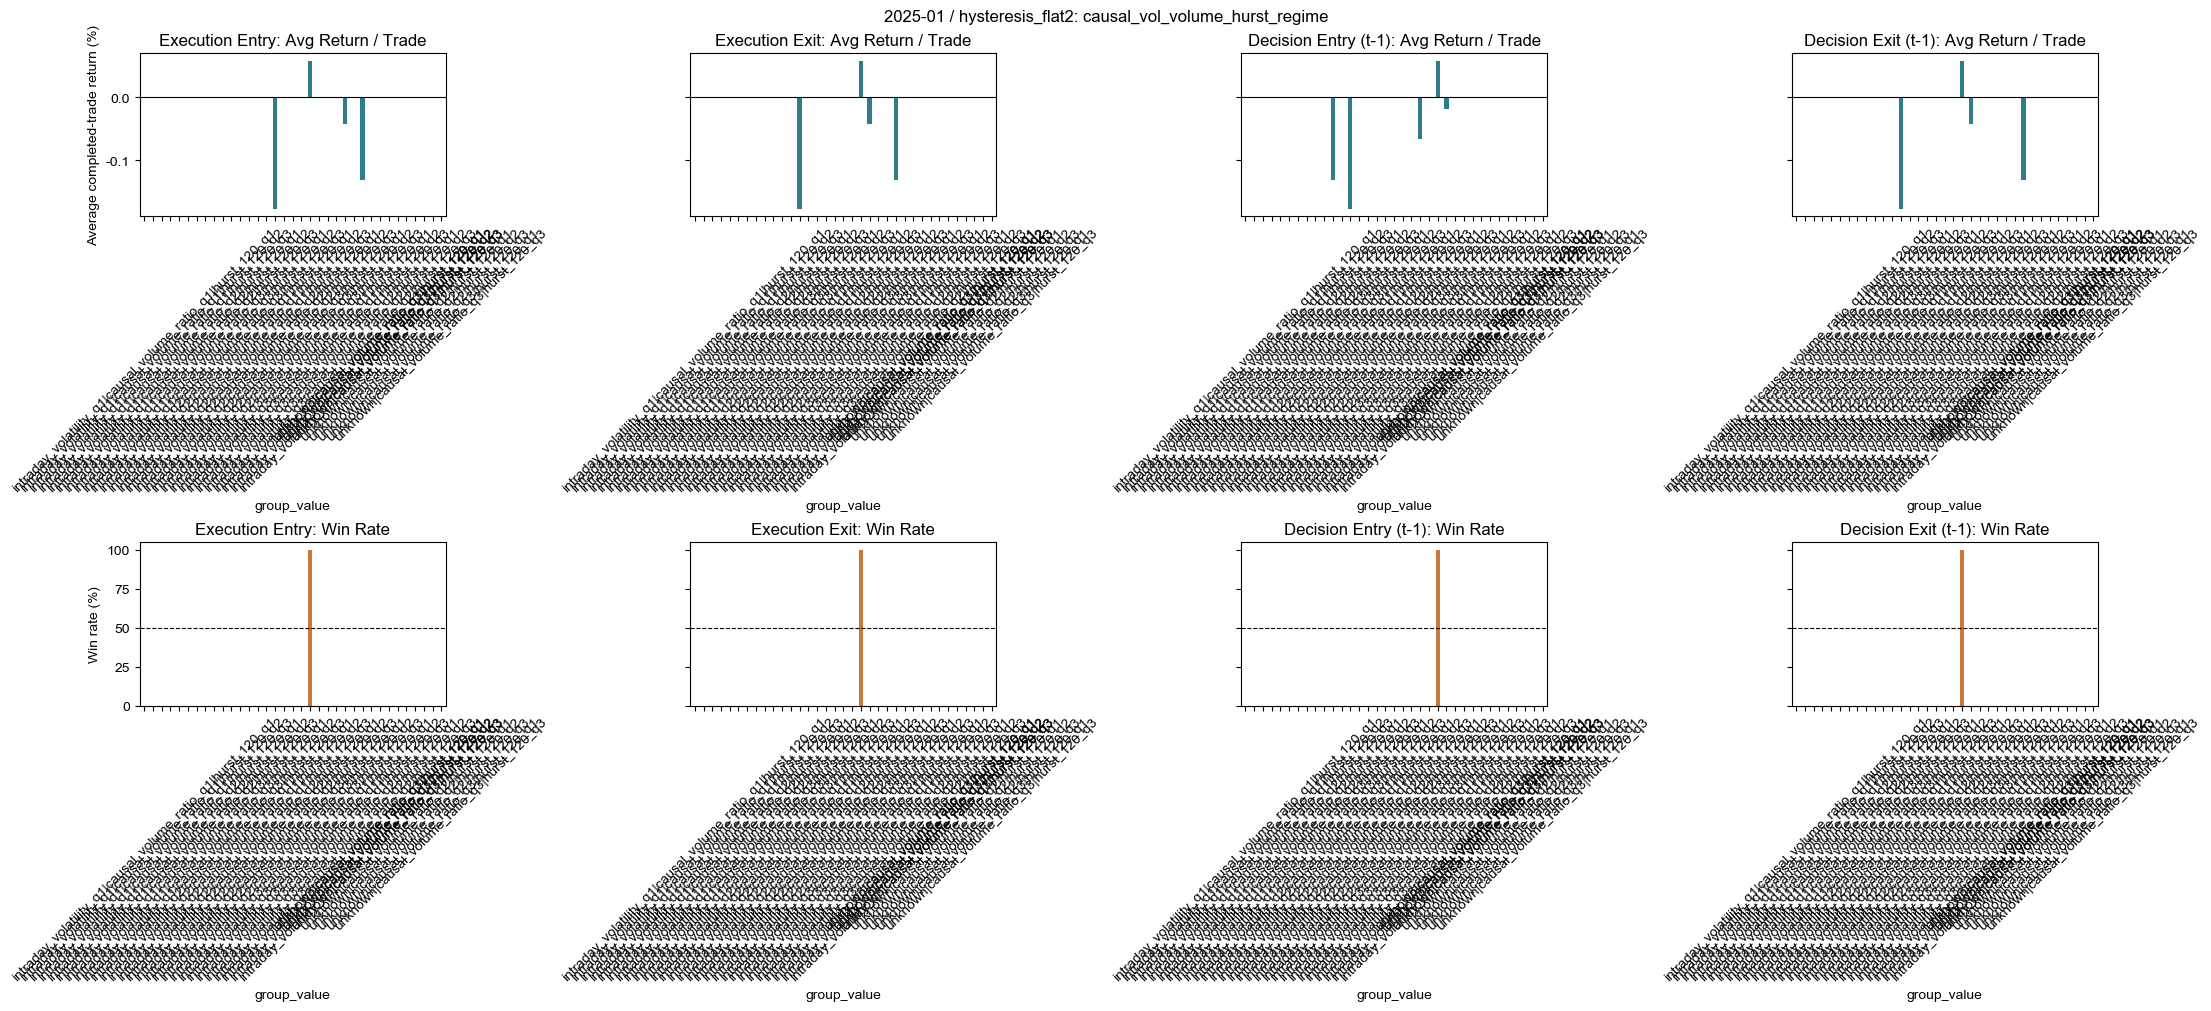

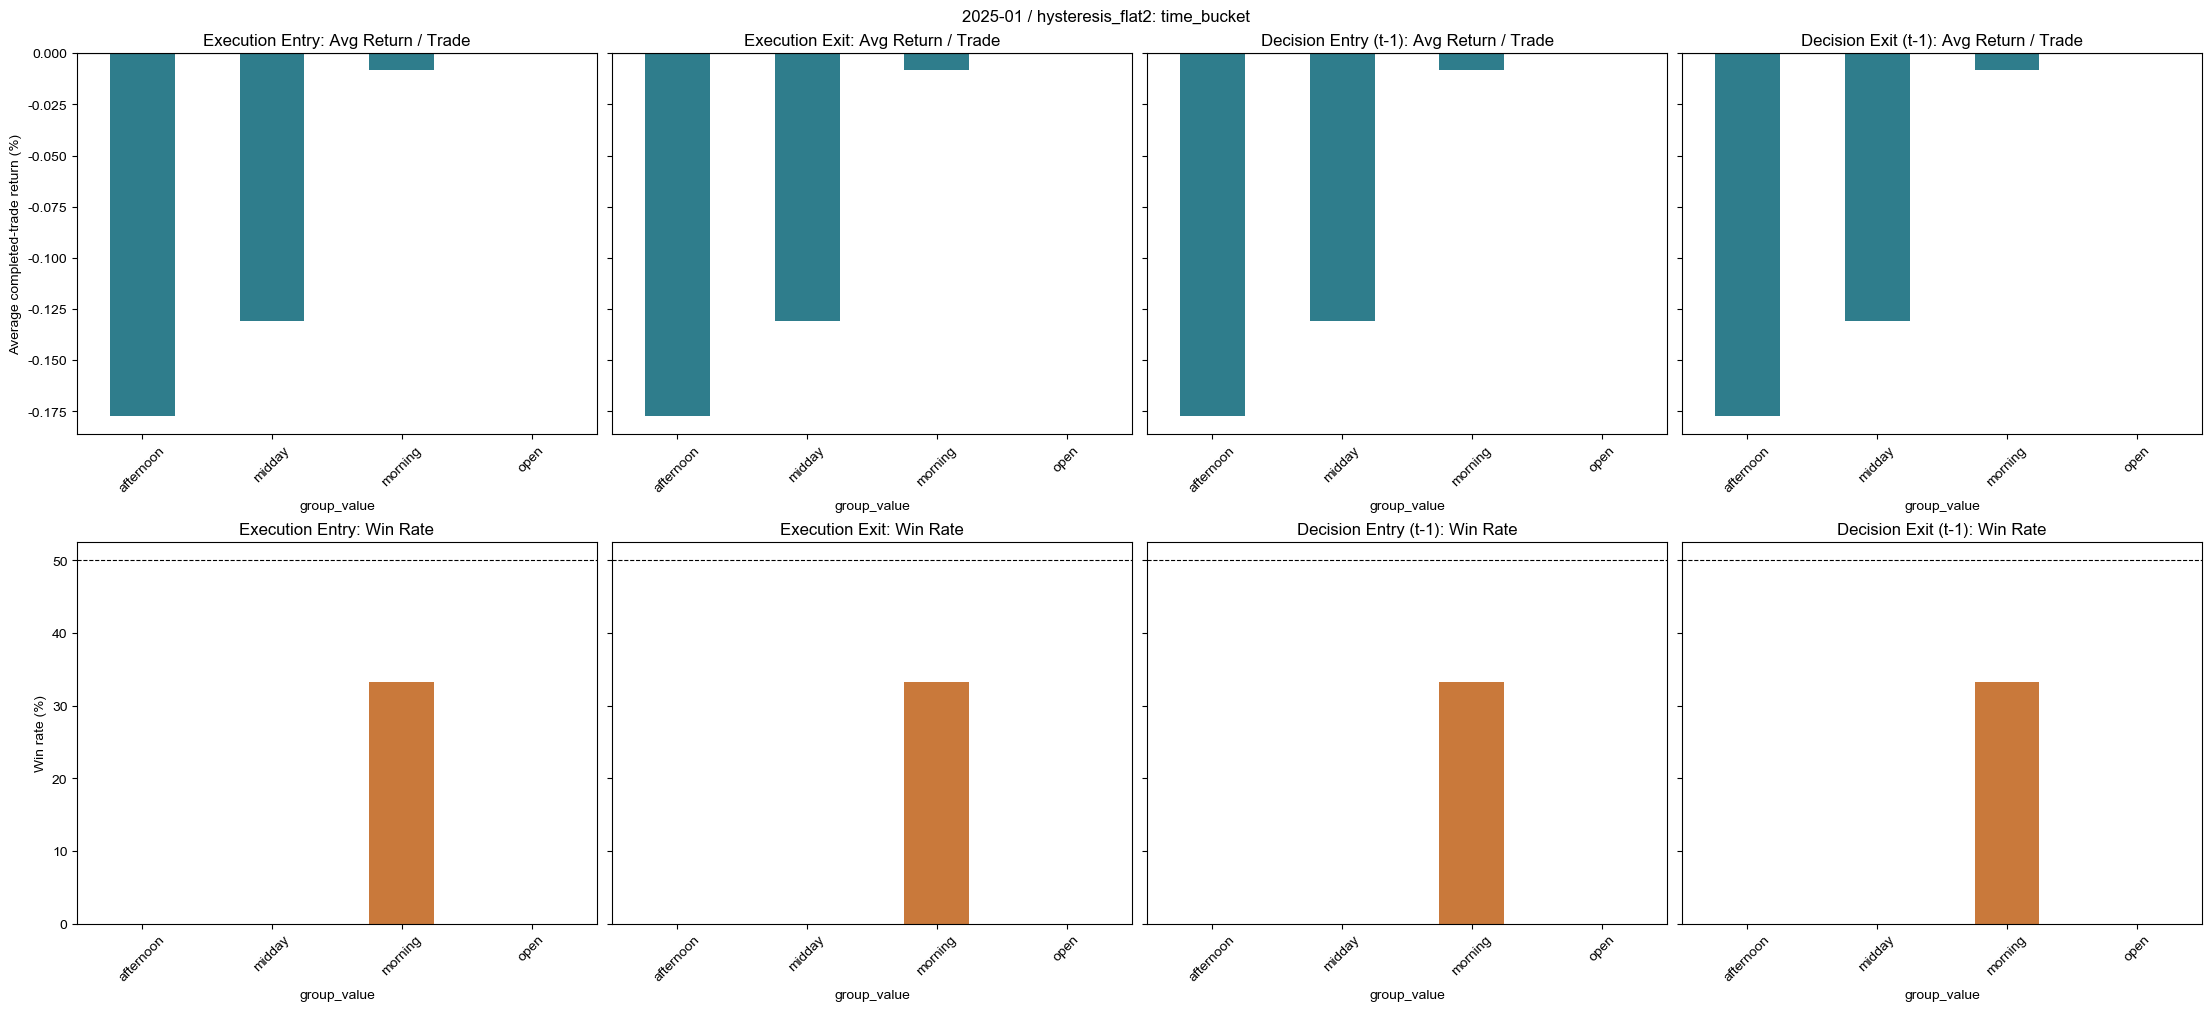

窗口诊断完成: 2025-01 hysteresis_flat2 -> artifacts/if_alstm_rolling_3state_intra_2025/window_diagnostics/2025-01/hysteresis_flat2/diagnostic_report.md


/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:274: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  inferred = out[[c for c in ("prob_down", "prob_flat", "prob_up") if c in out]].idxmax(axis=1)
/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:299: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out["strategy_return"] = pd.to_numeric(out["account"], errors="coerce").pct_change()


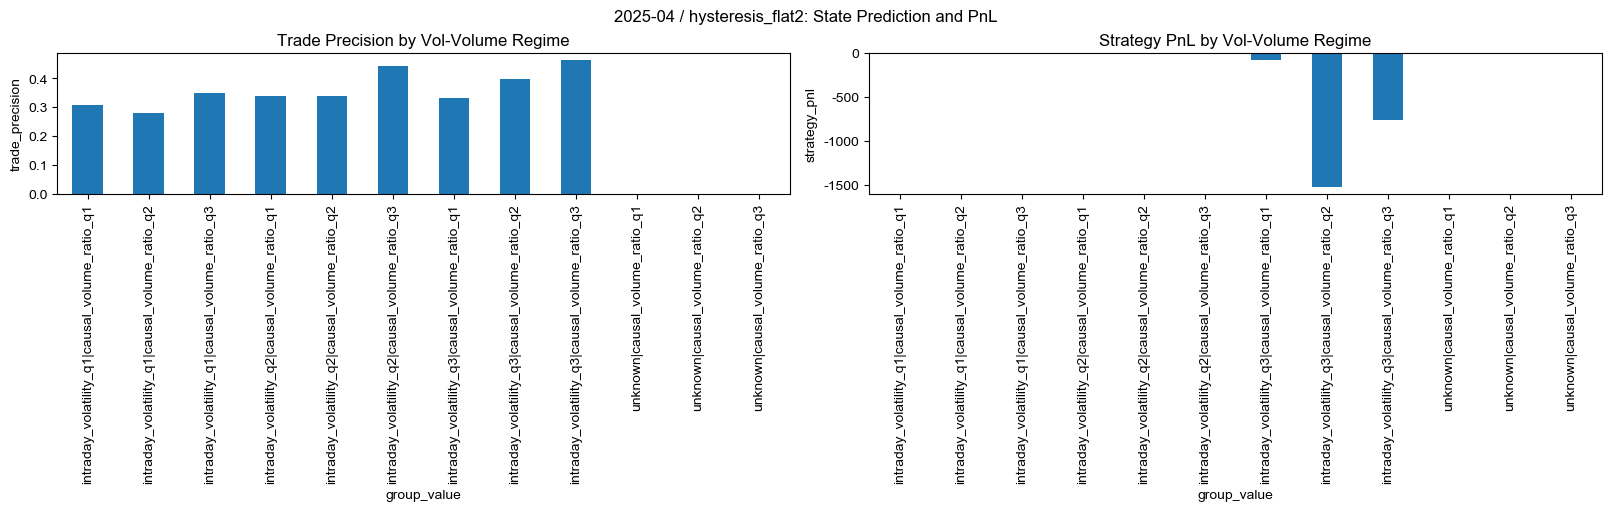

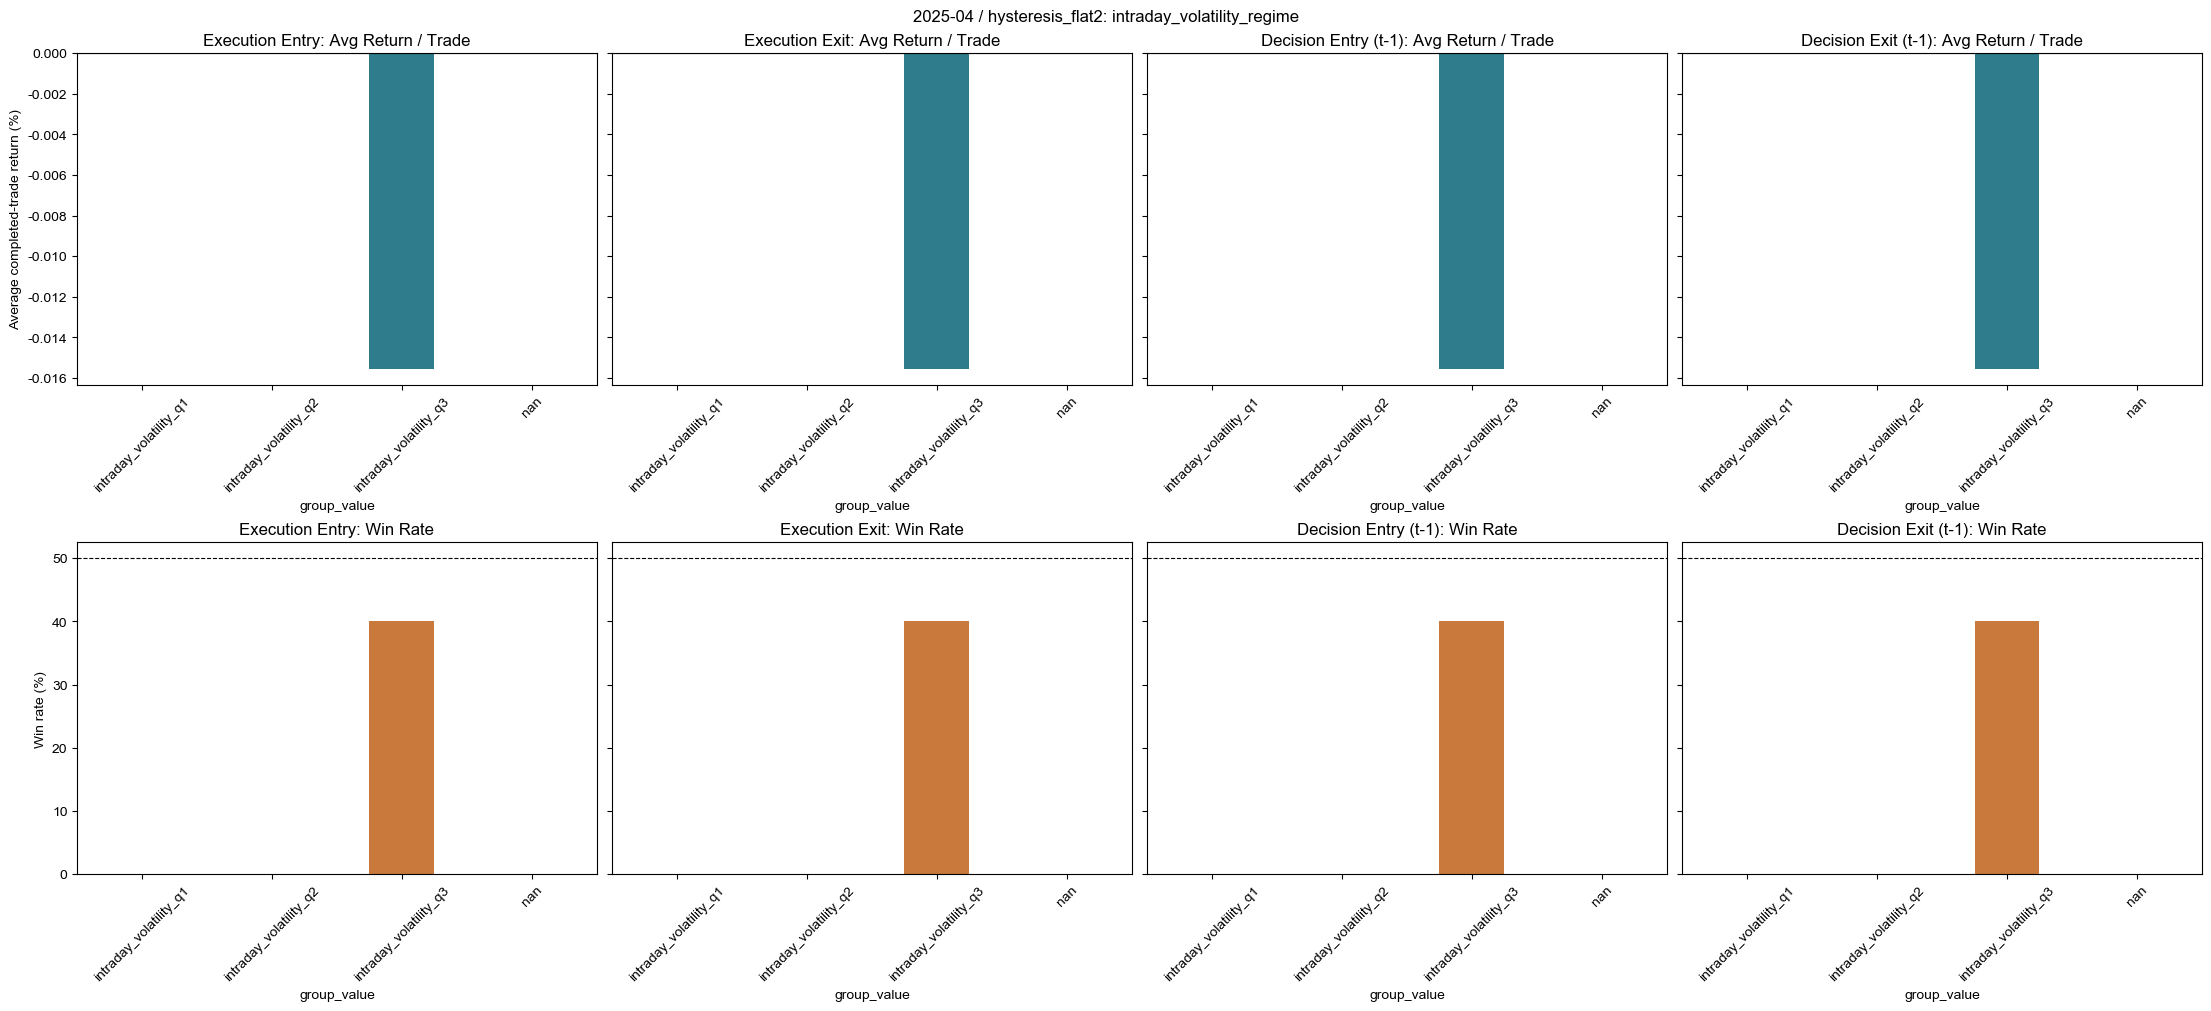

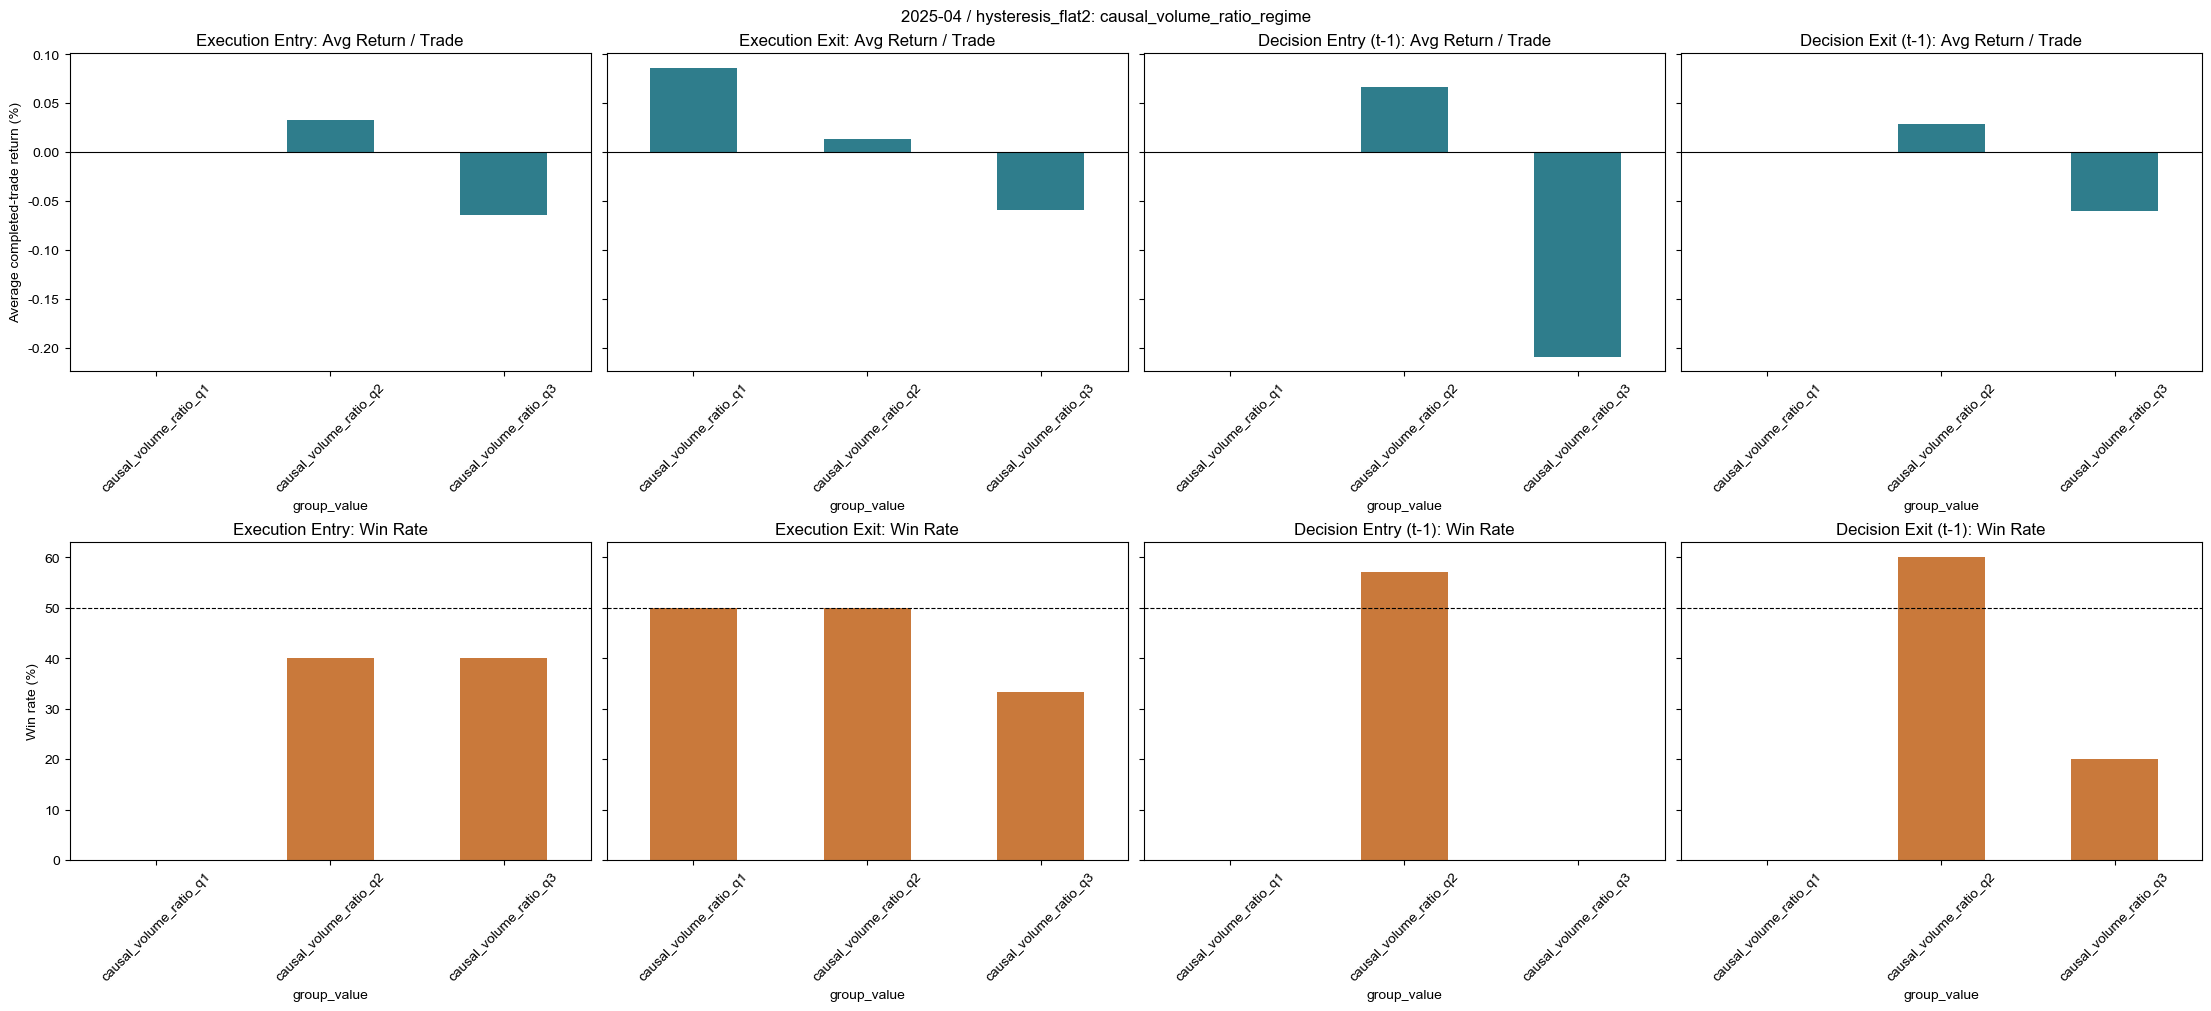

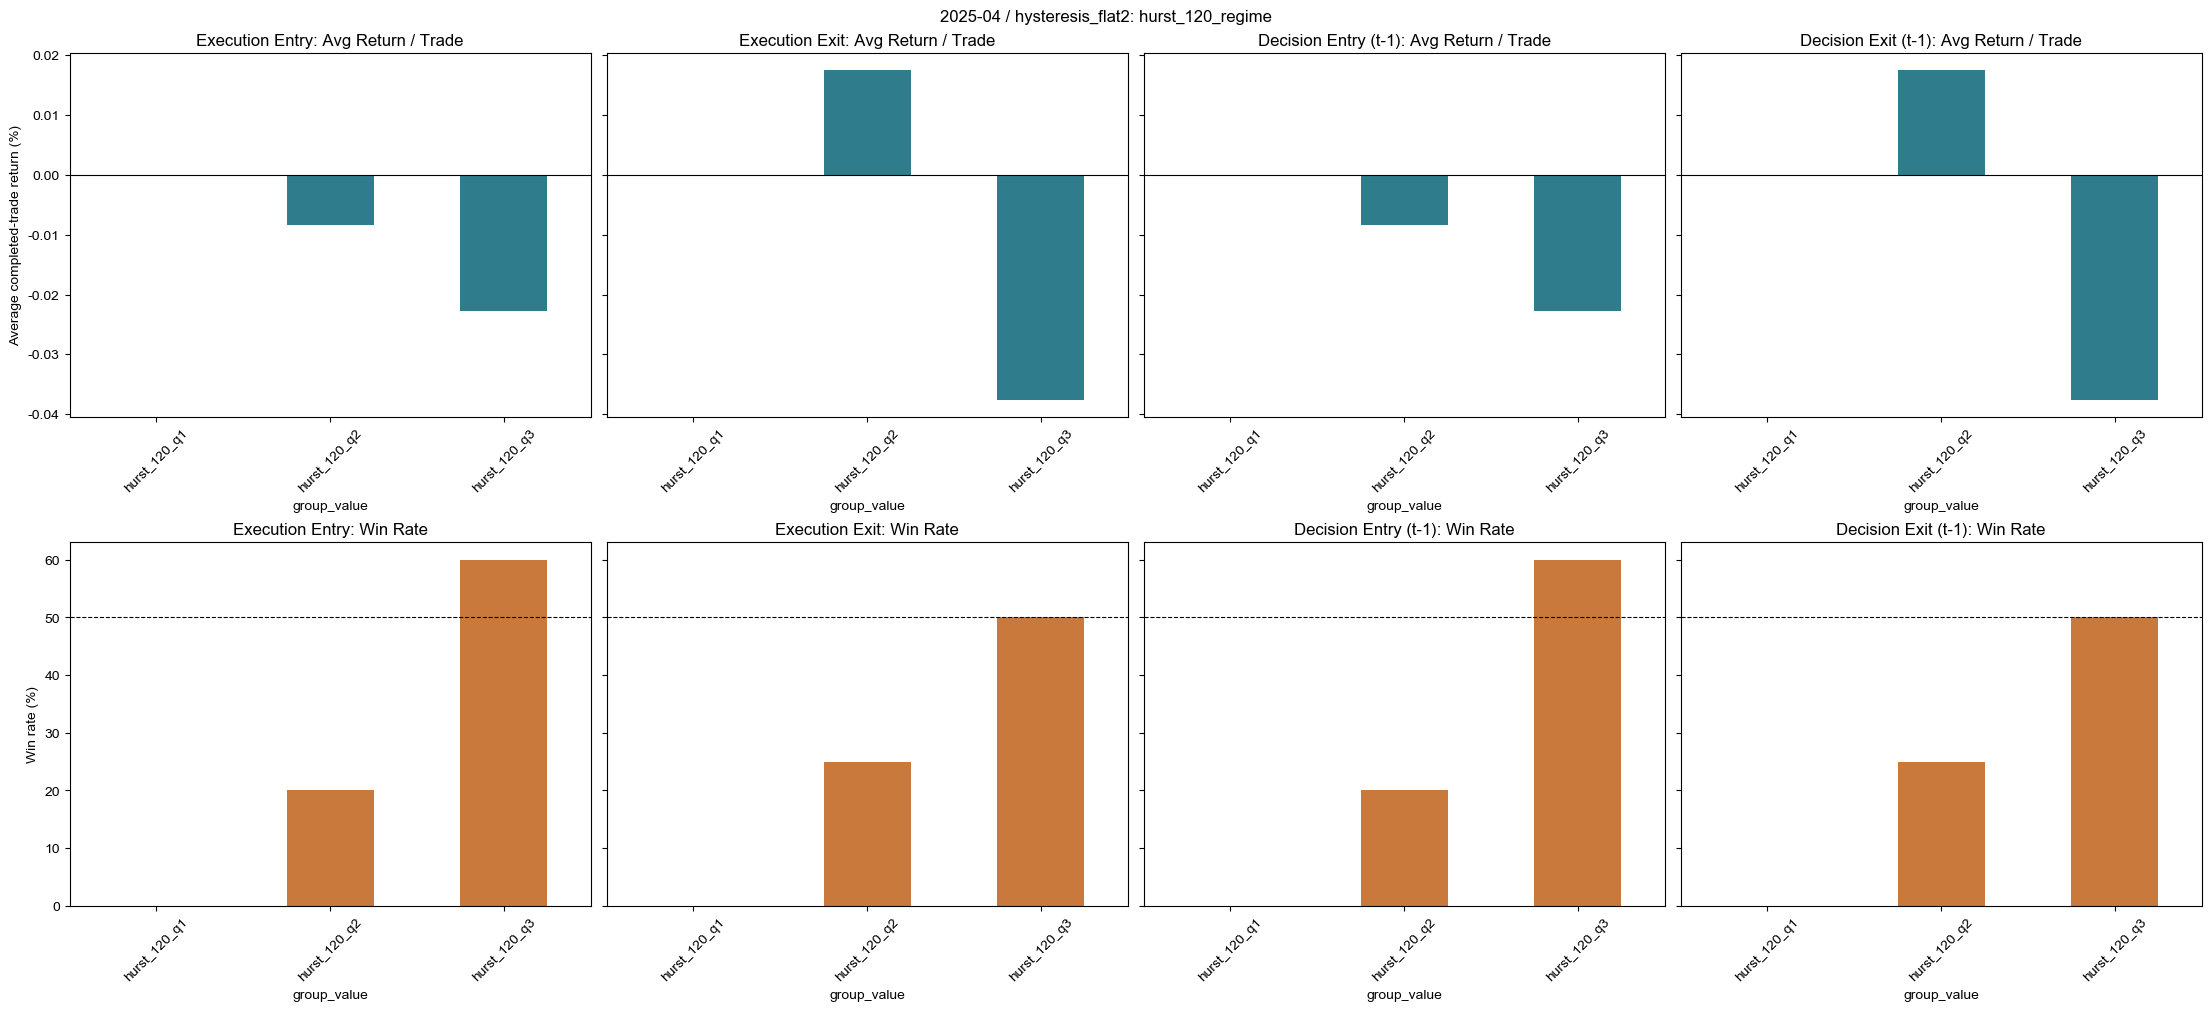

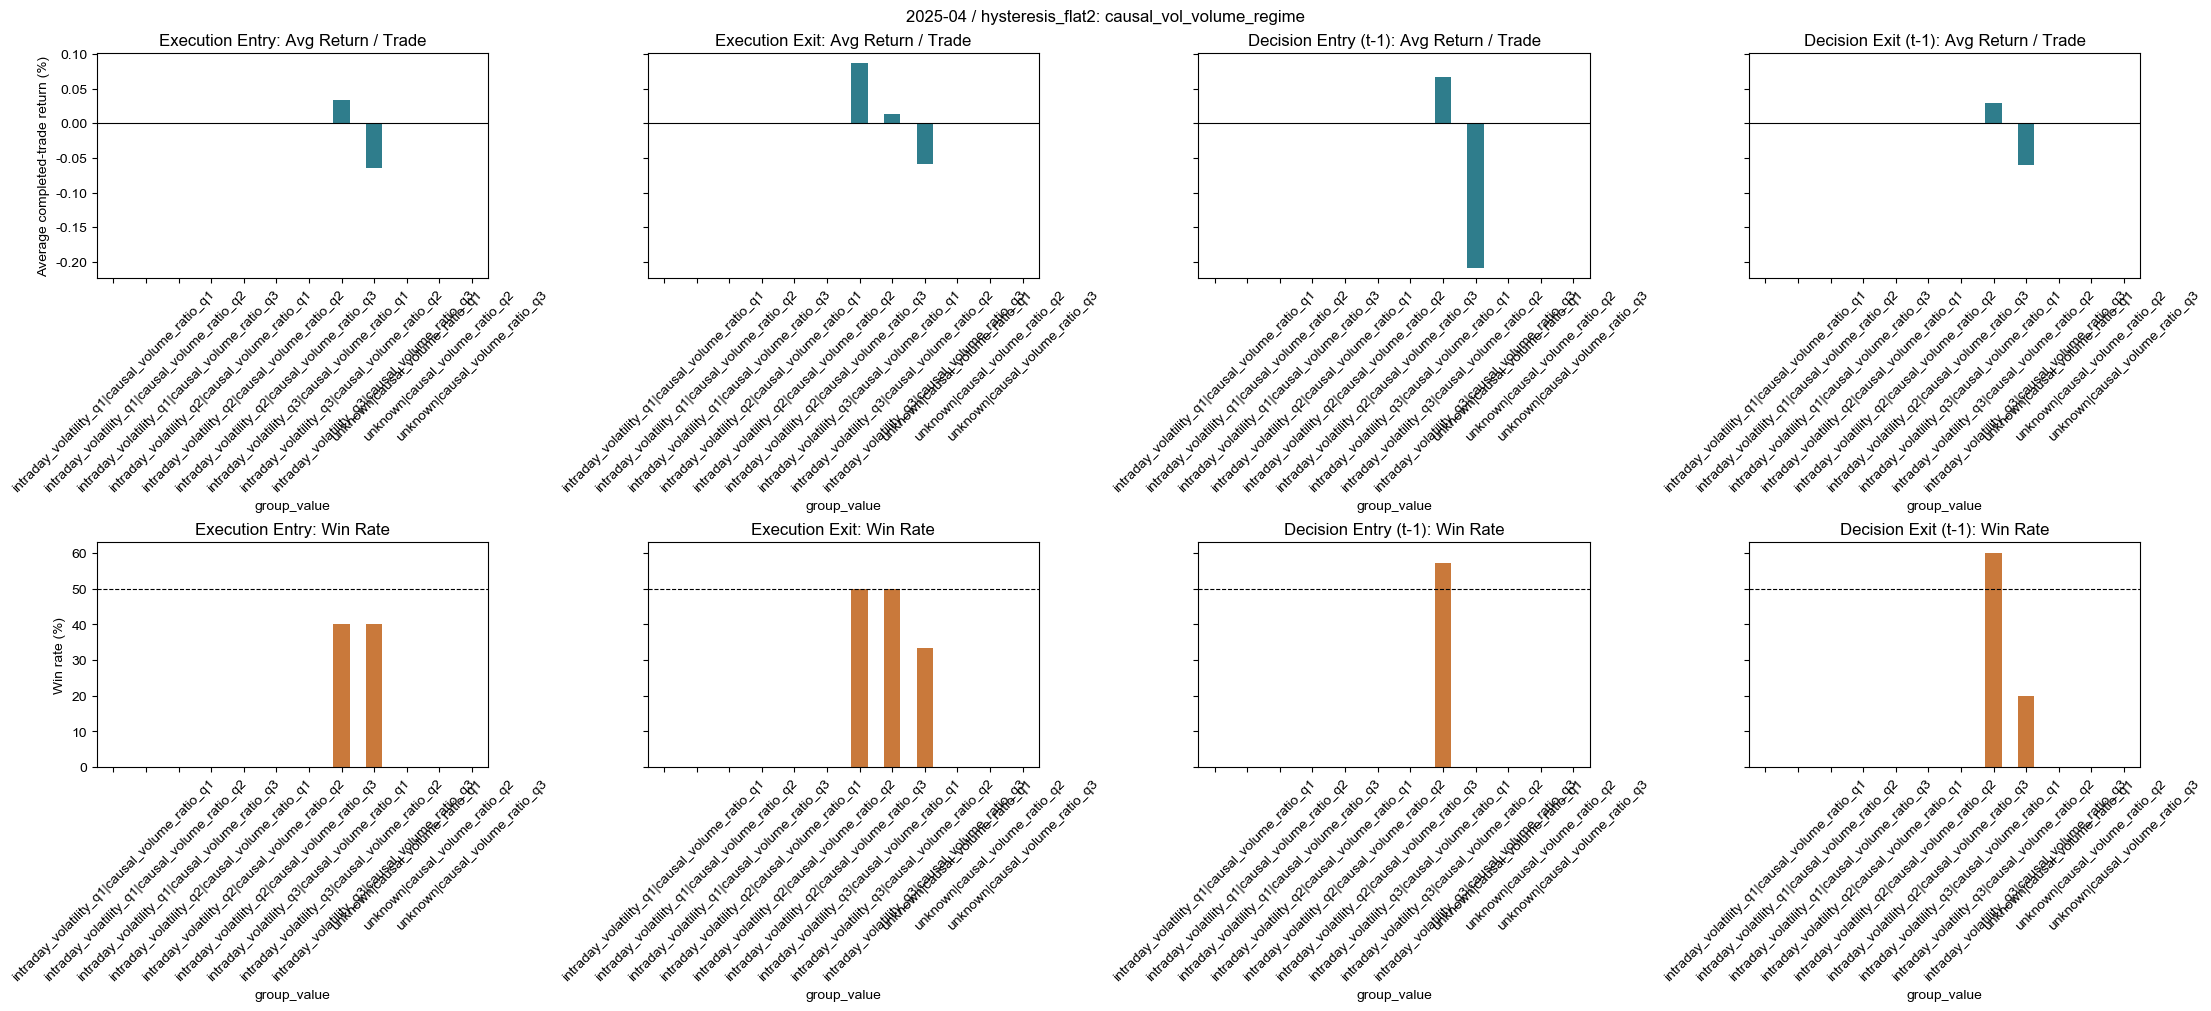

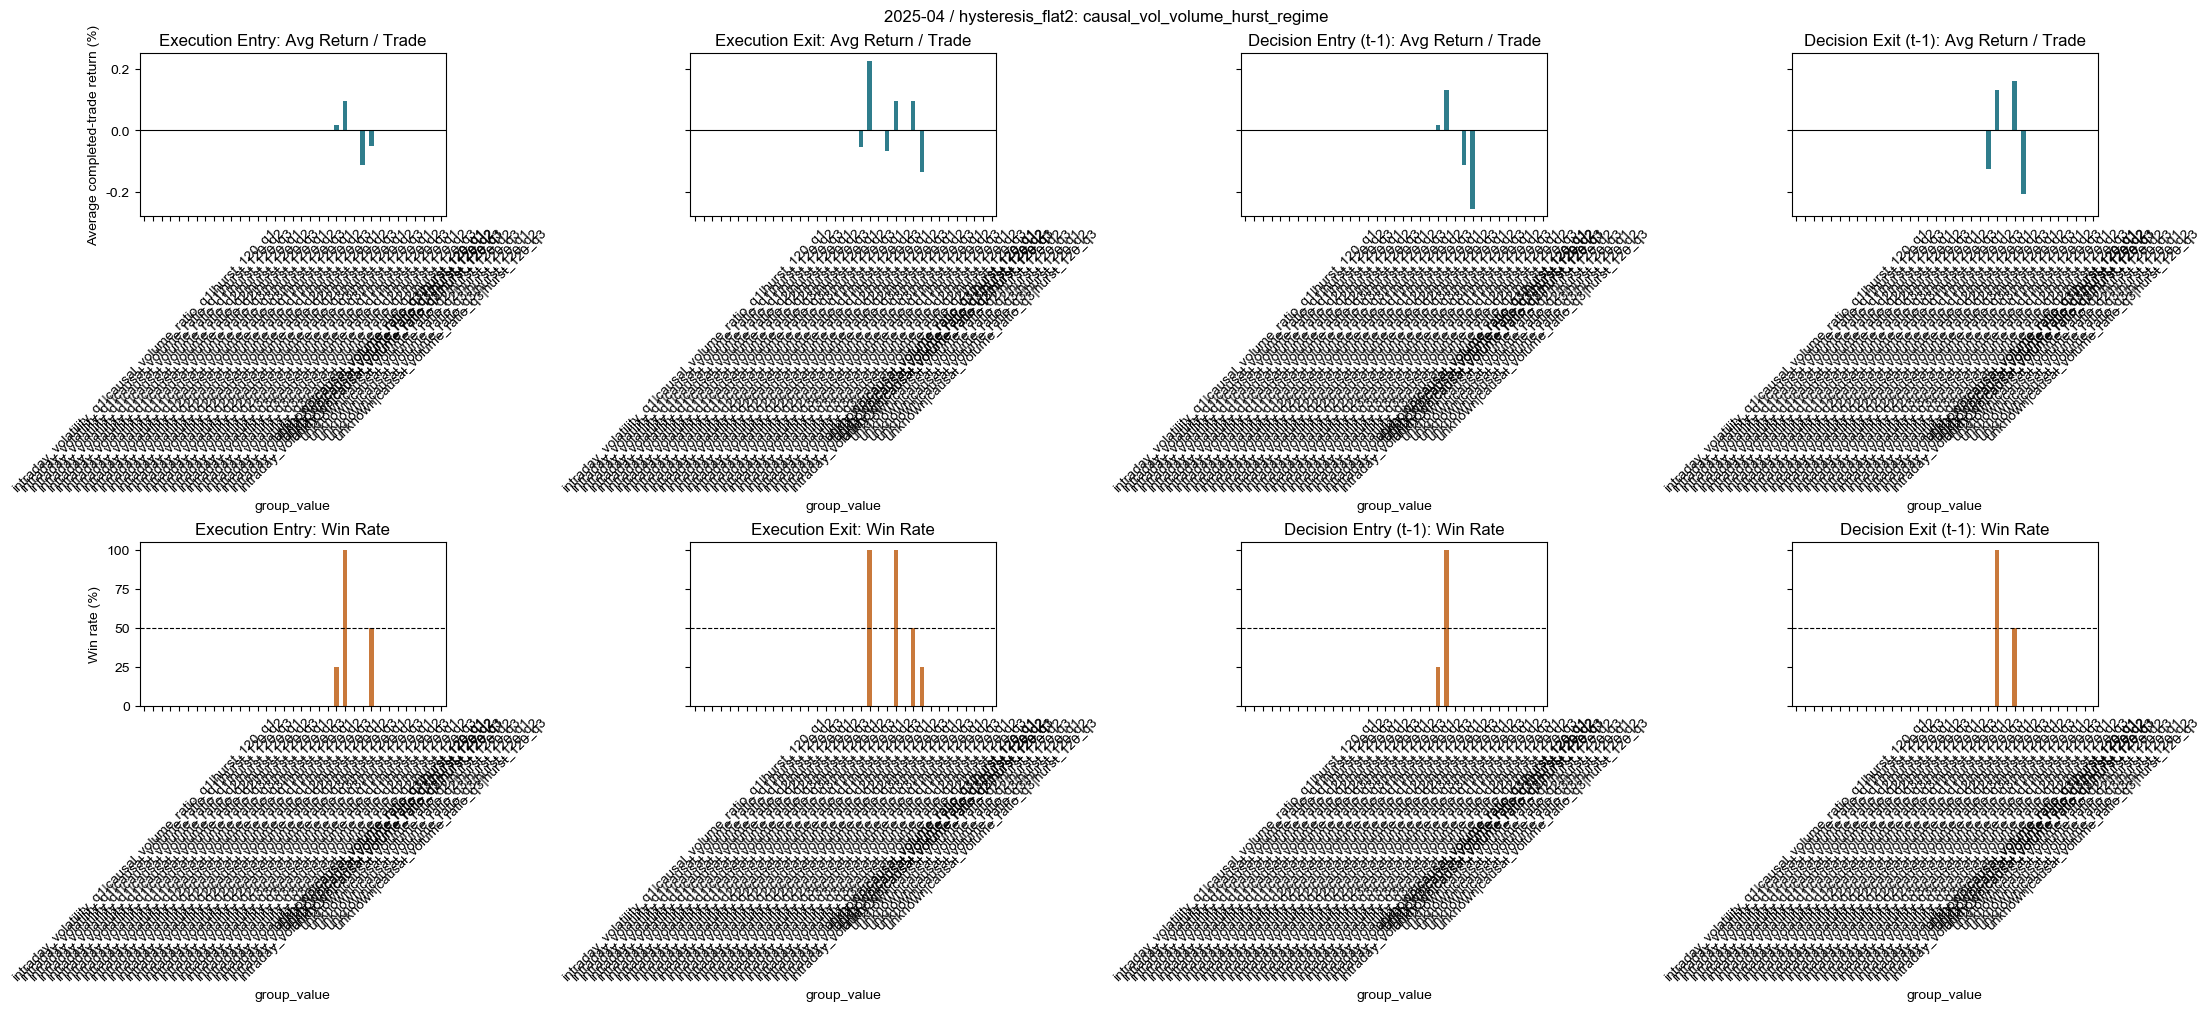

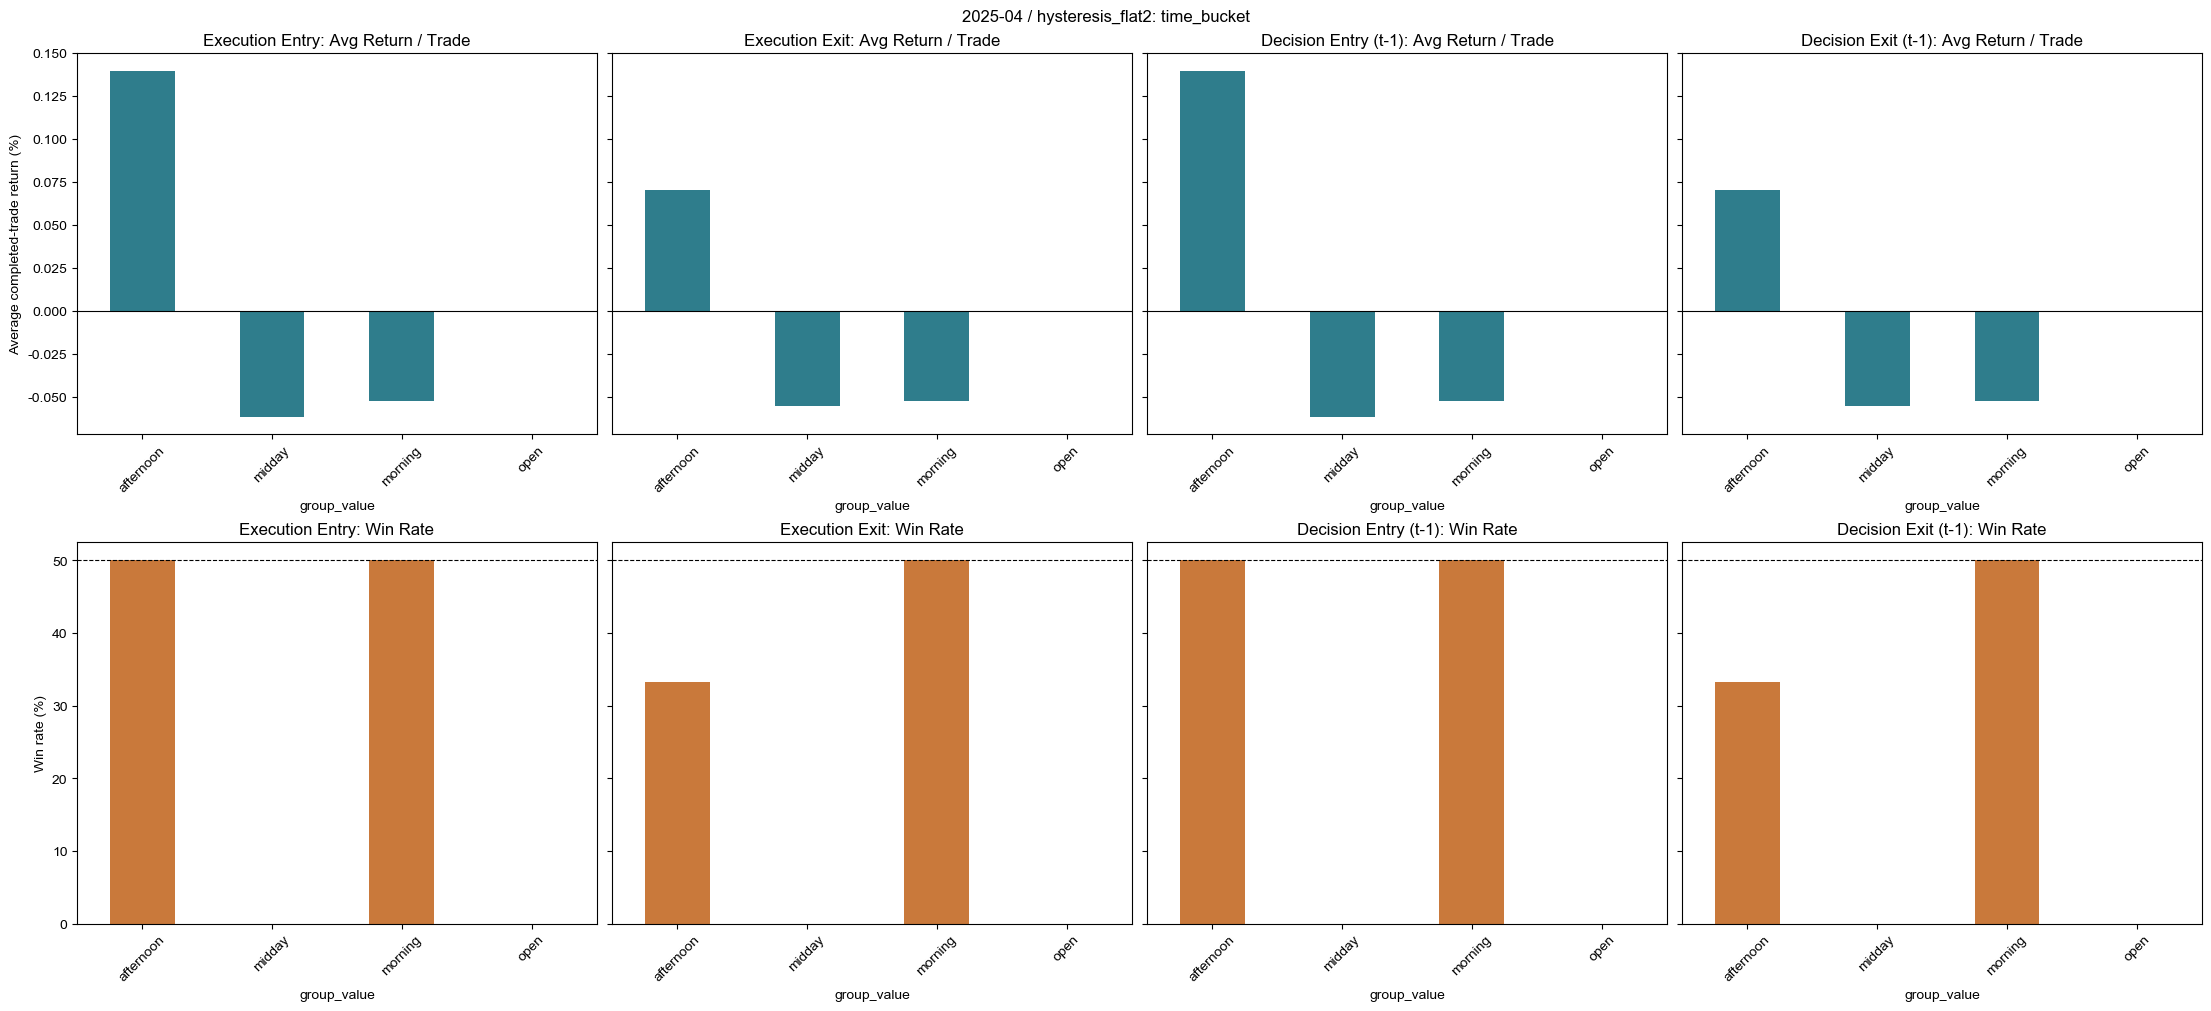

窗口诊断完成: 2025-04 hysteresis_flat2 -> artifacts/if_alstm_rolling_3state_intra_2025/window_diagnostics/2025-04/hysteresis_flat2/diagnostic_report.md


/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:274: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  inferred = out[[c for c in ("prob_down", "prob_flat", "prob_up") if c in out]].idxmax(axis=1)
/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:299: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out["strategy_return"] = pd.to_numeric(out["account"], errors="coerce").pct_change()


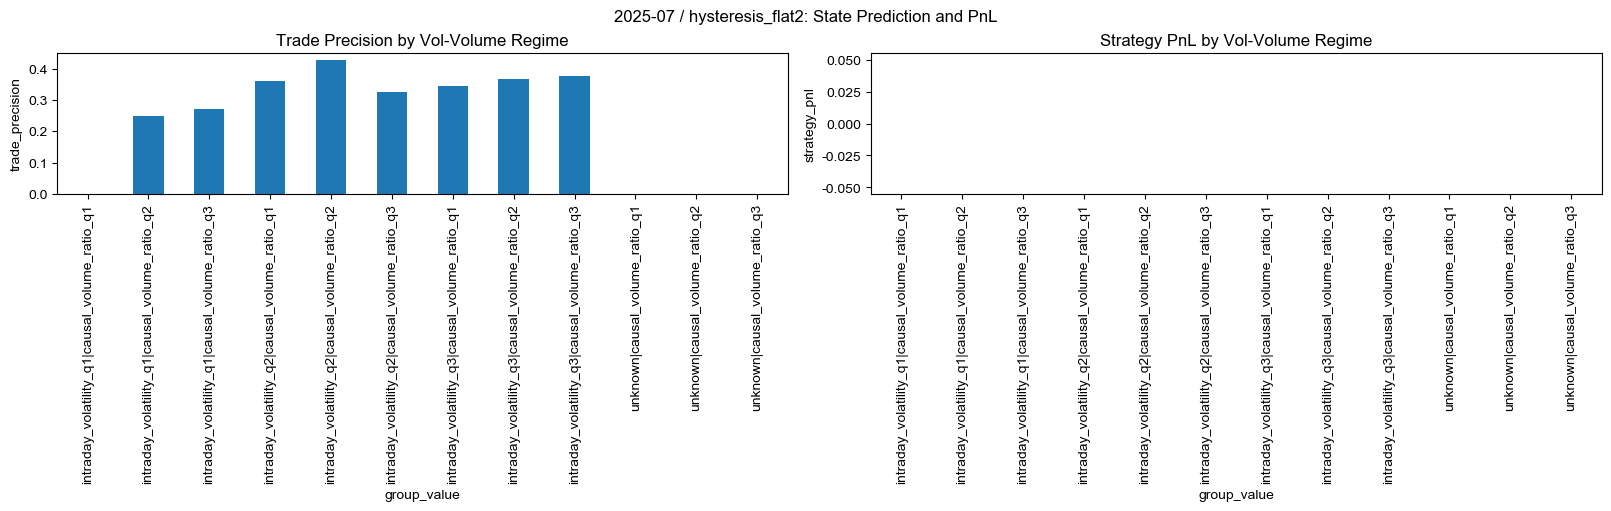

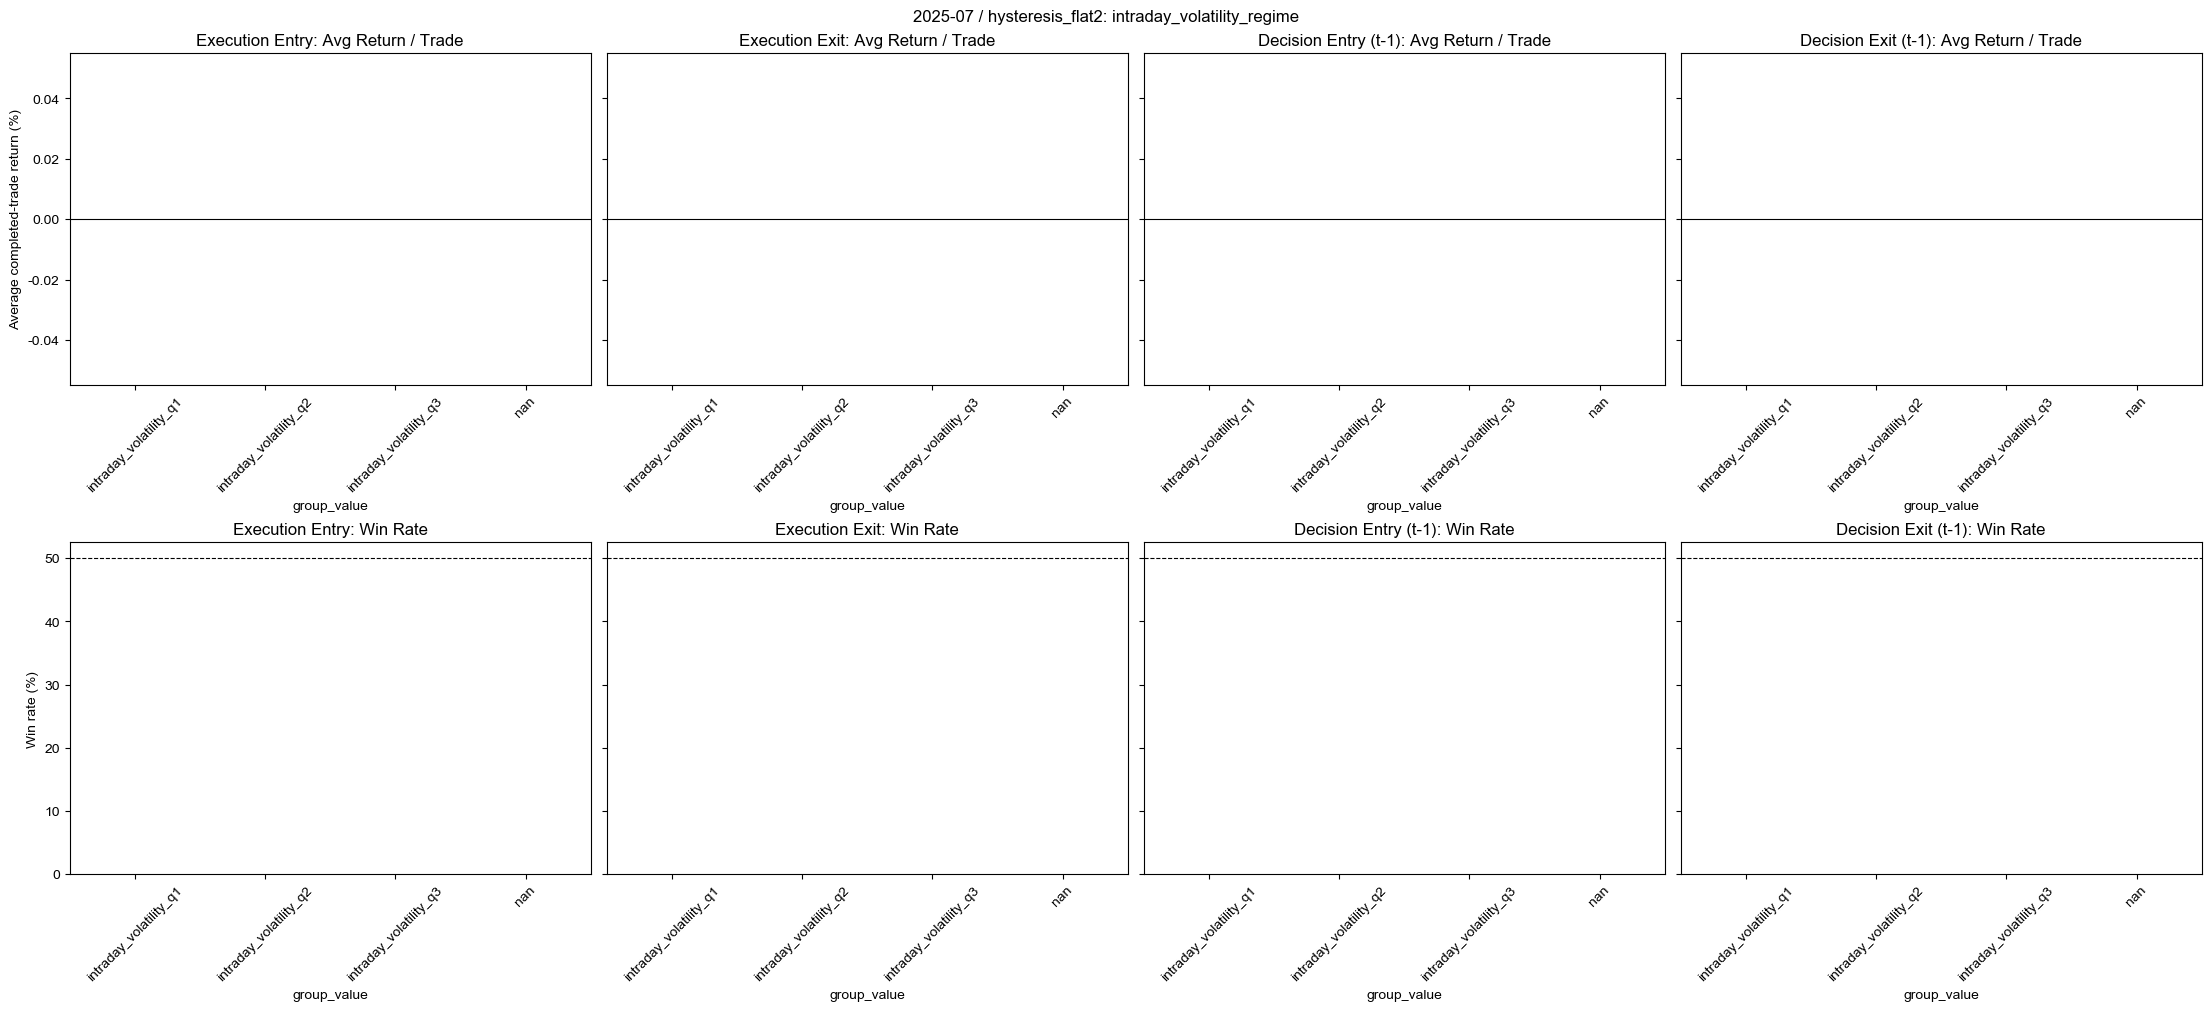

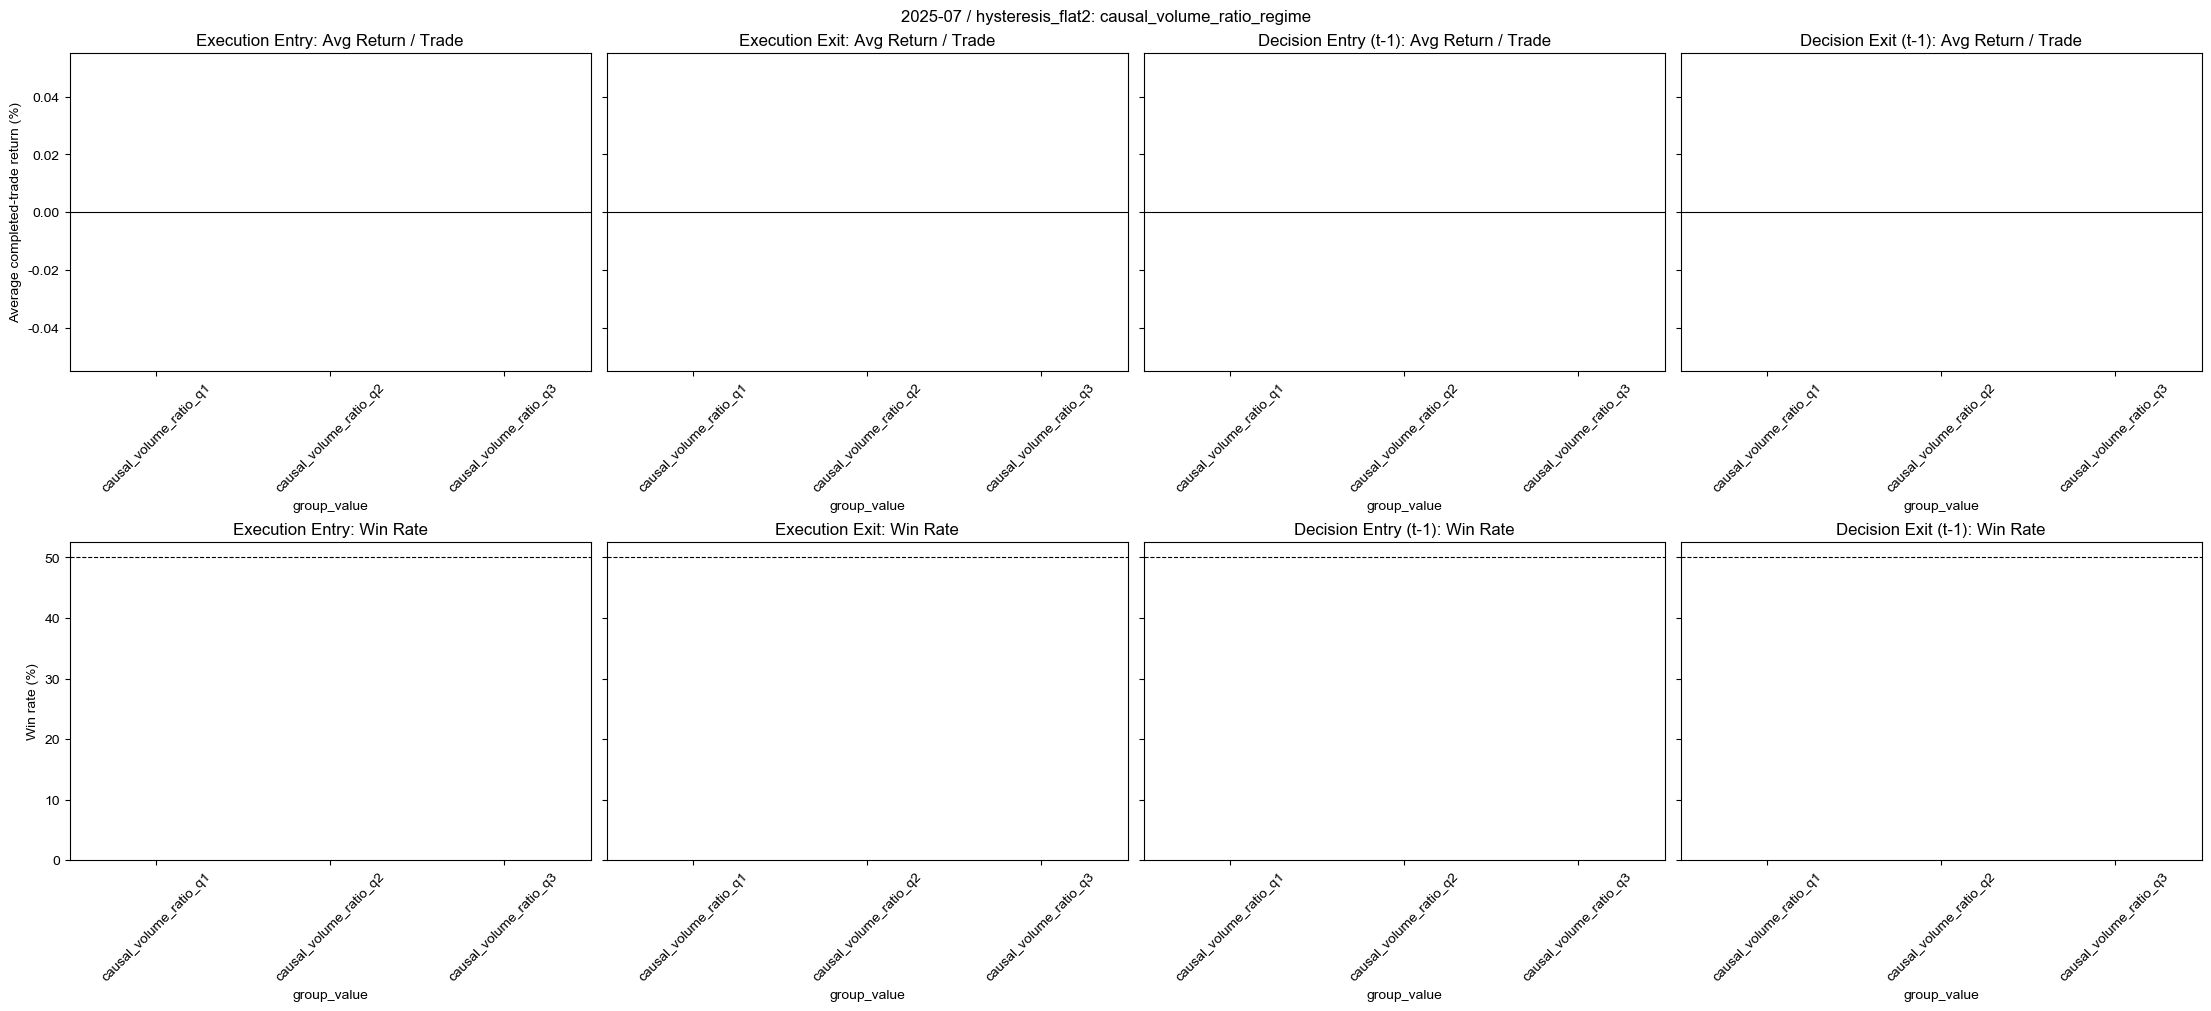

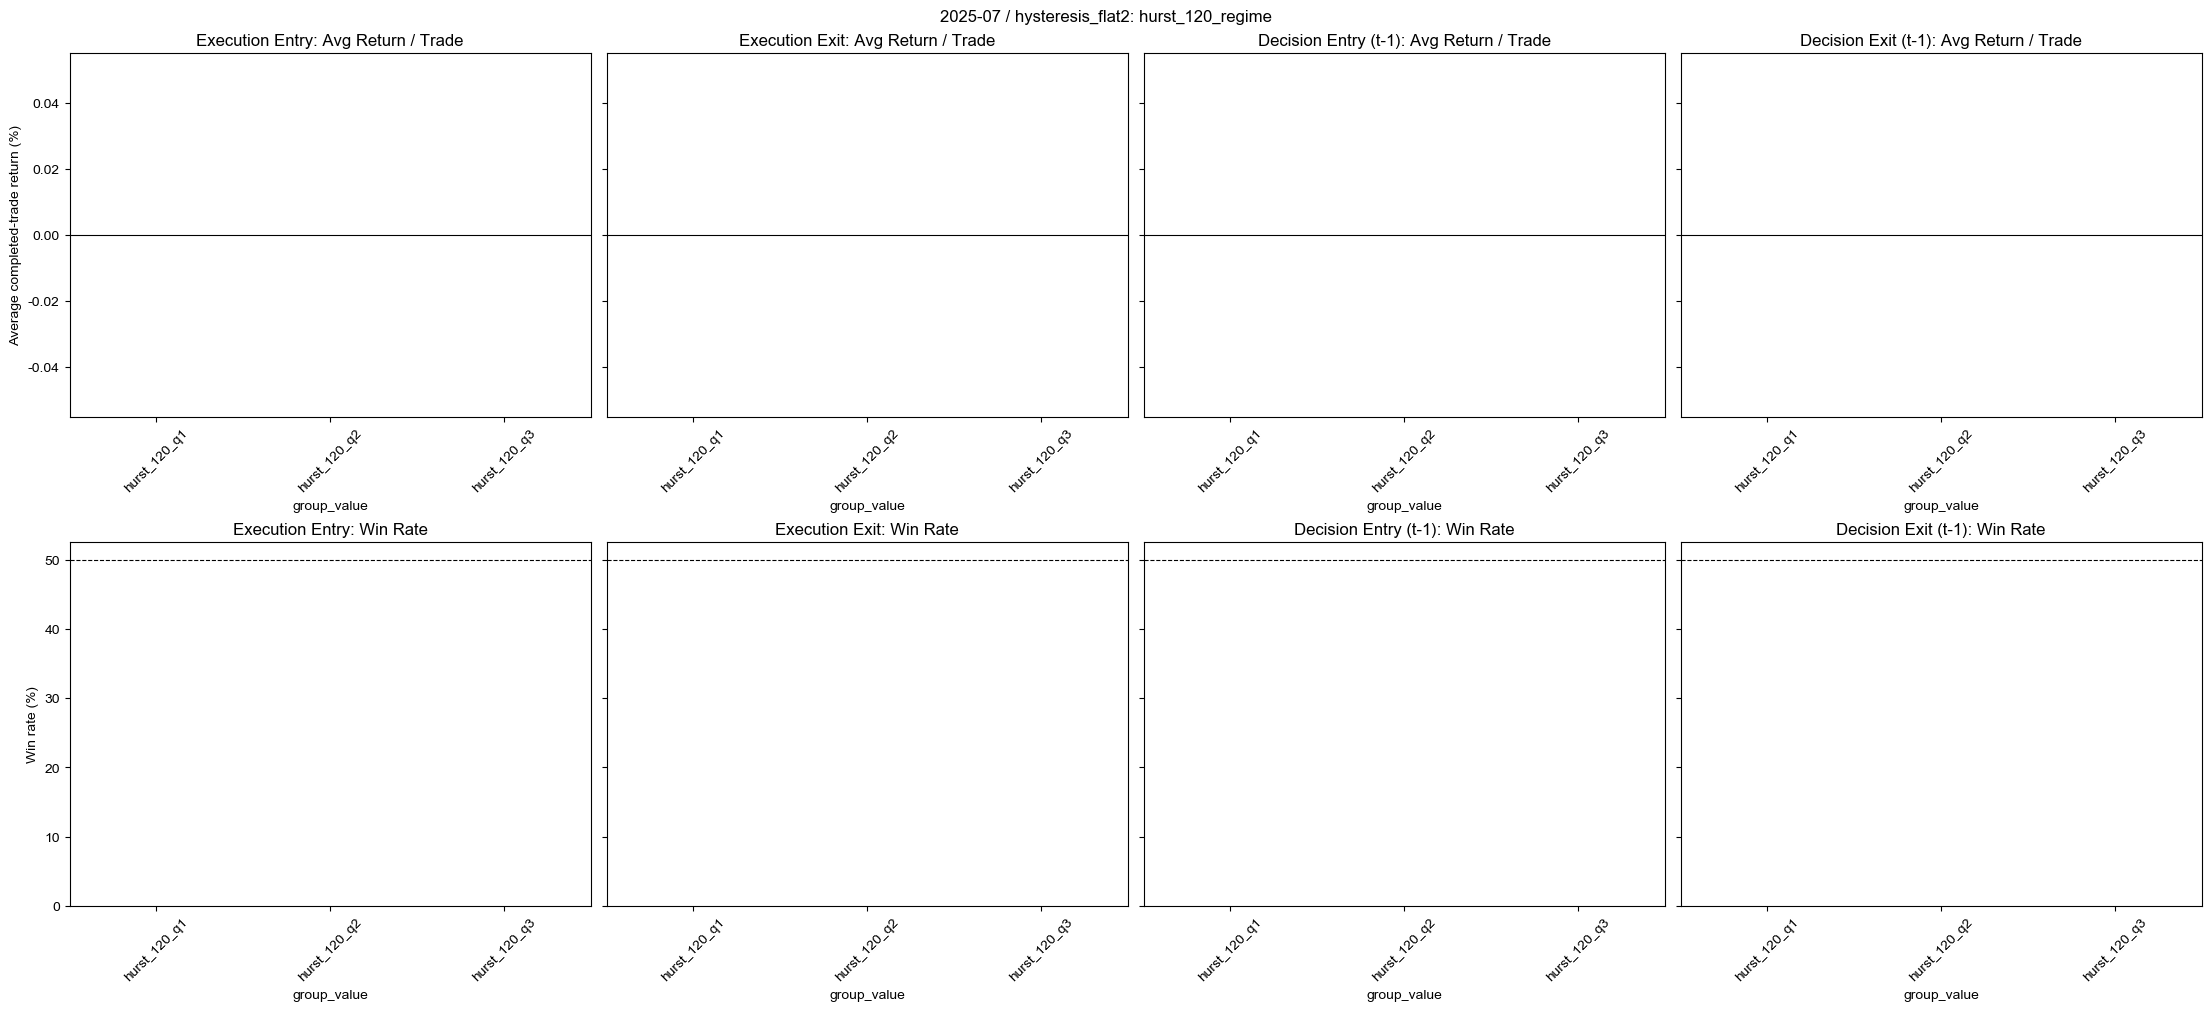

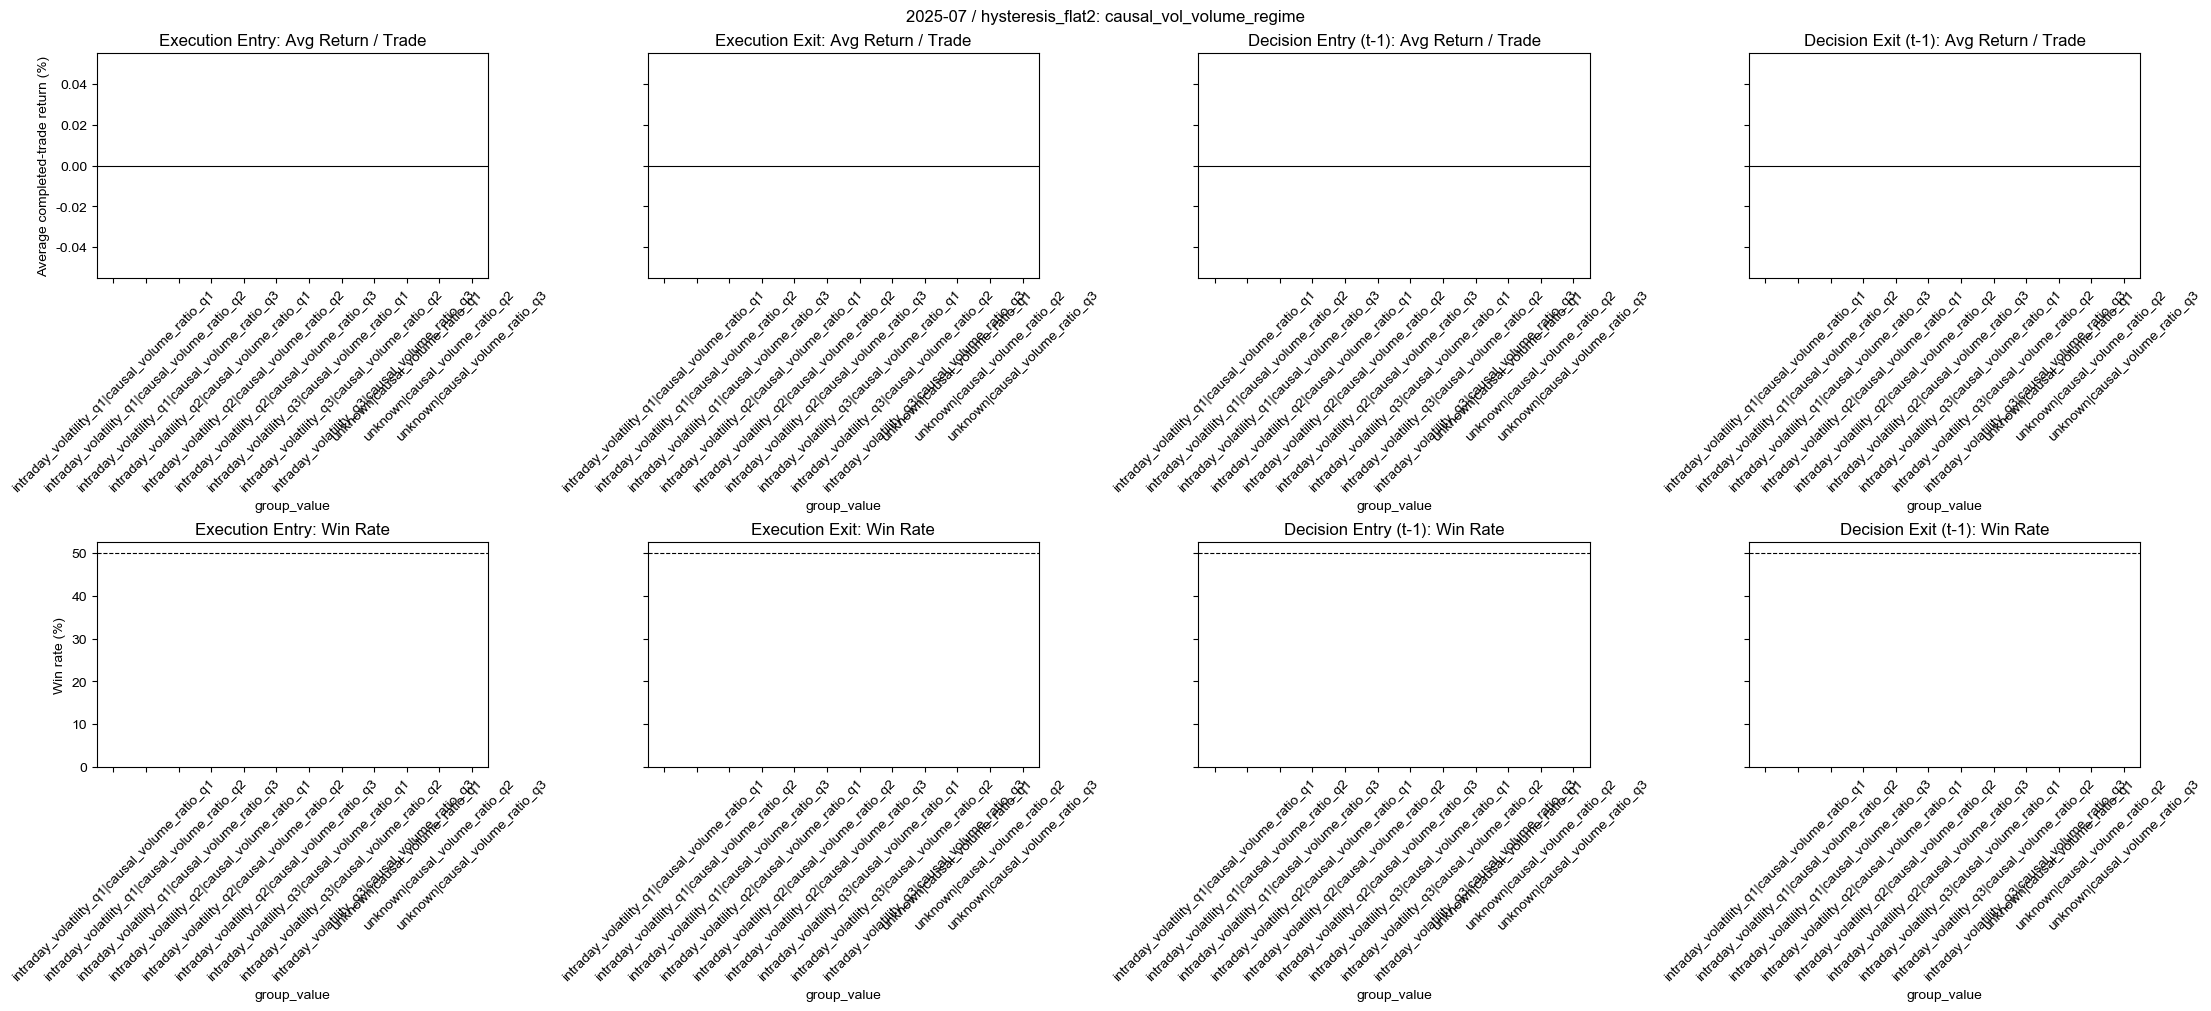

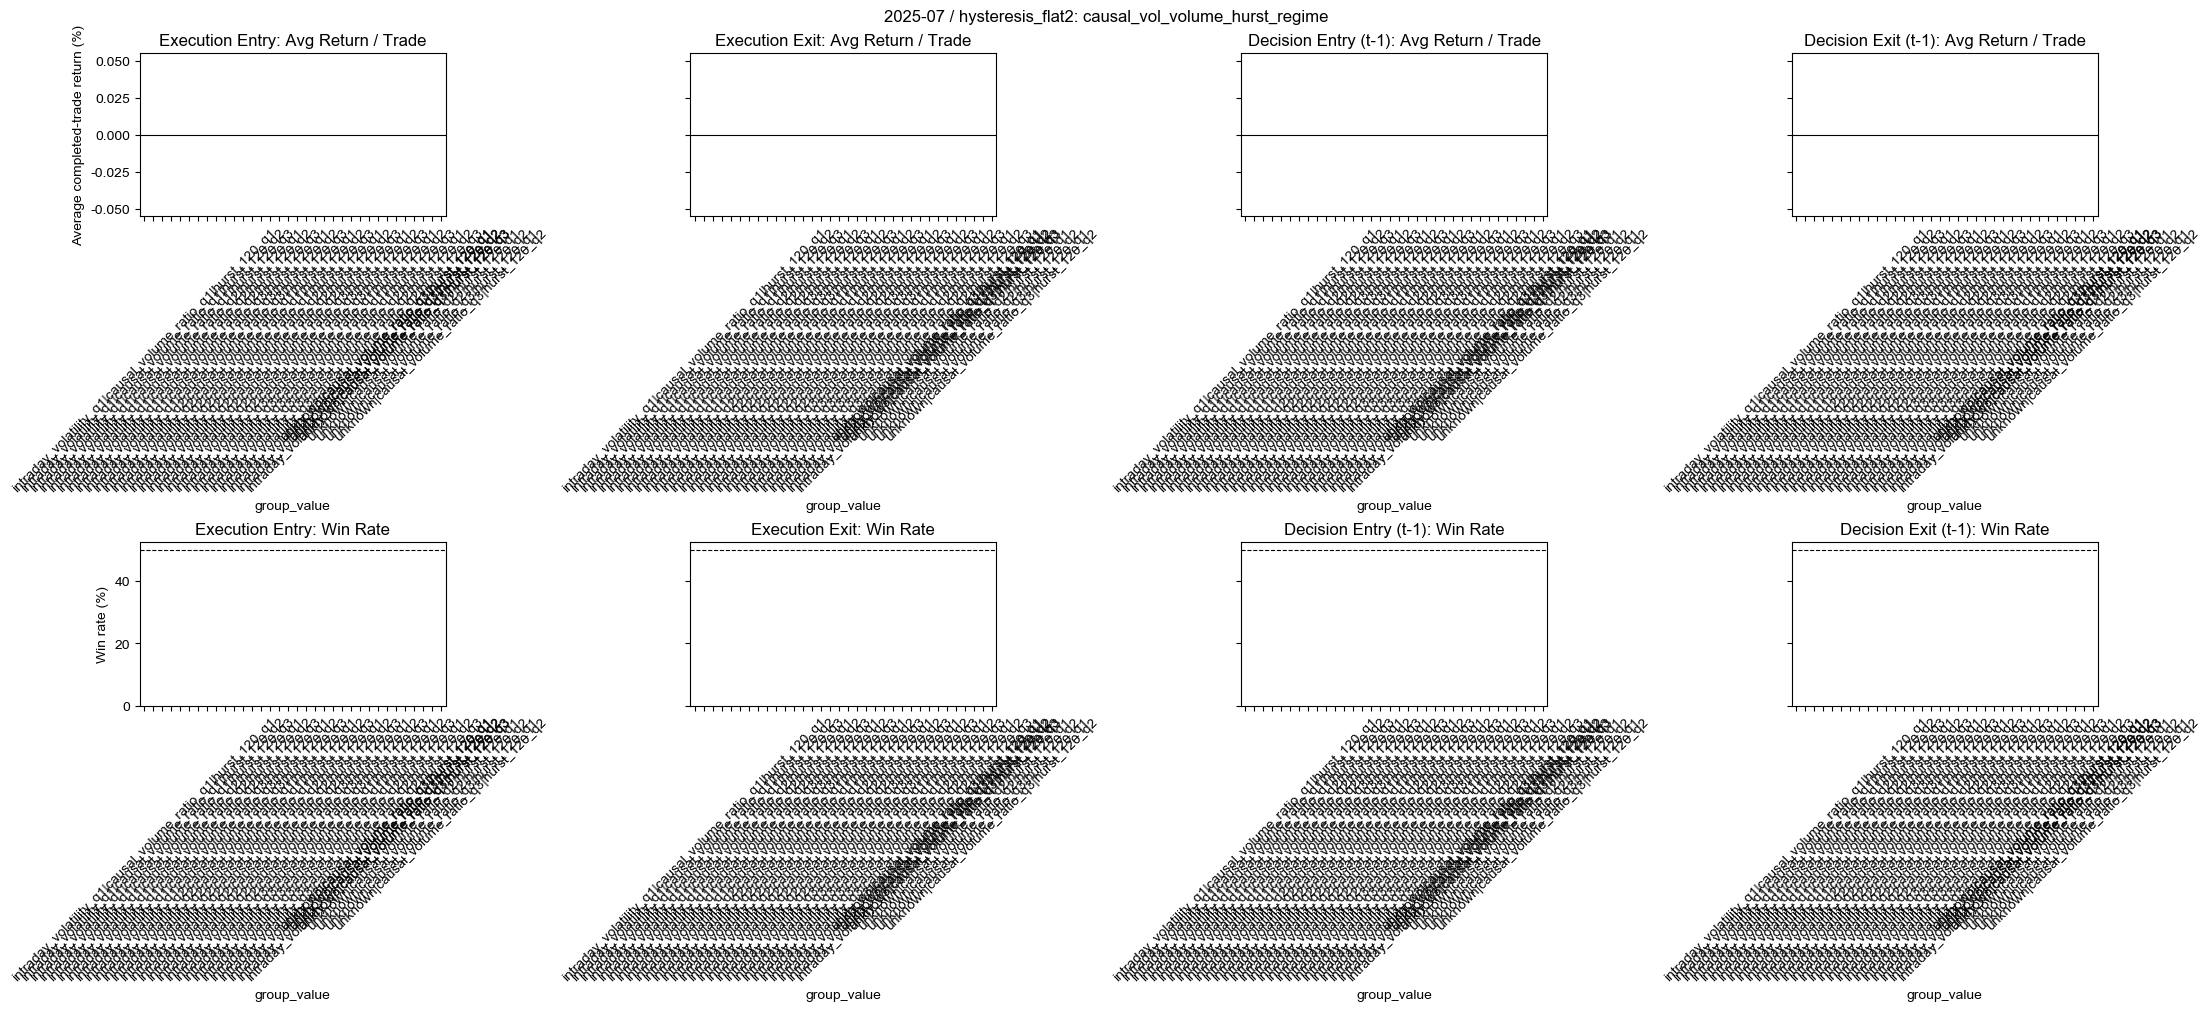

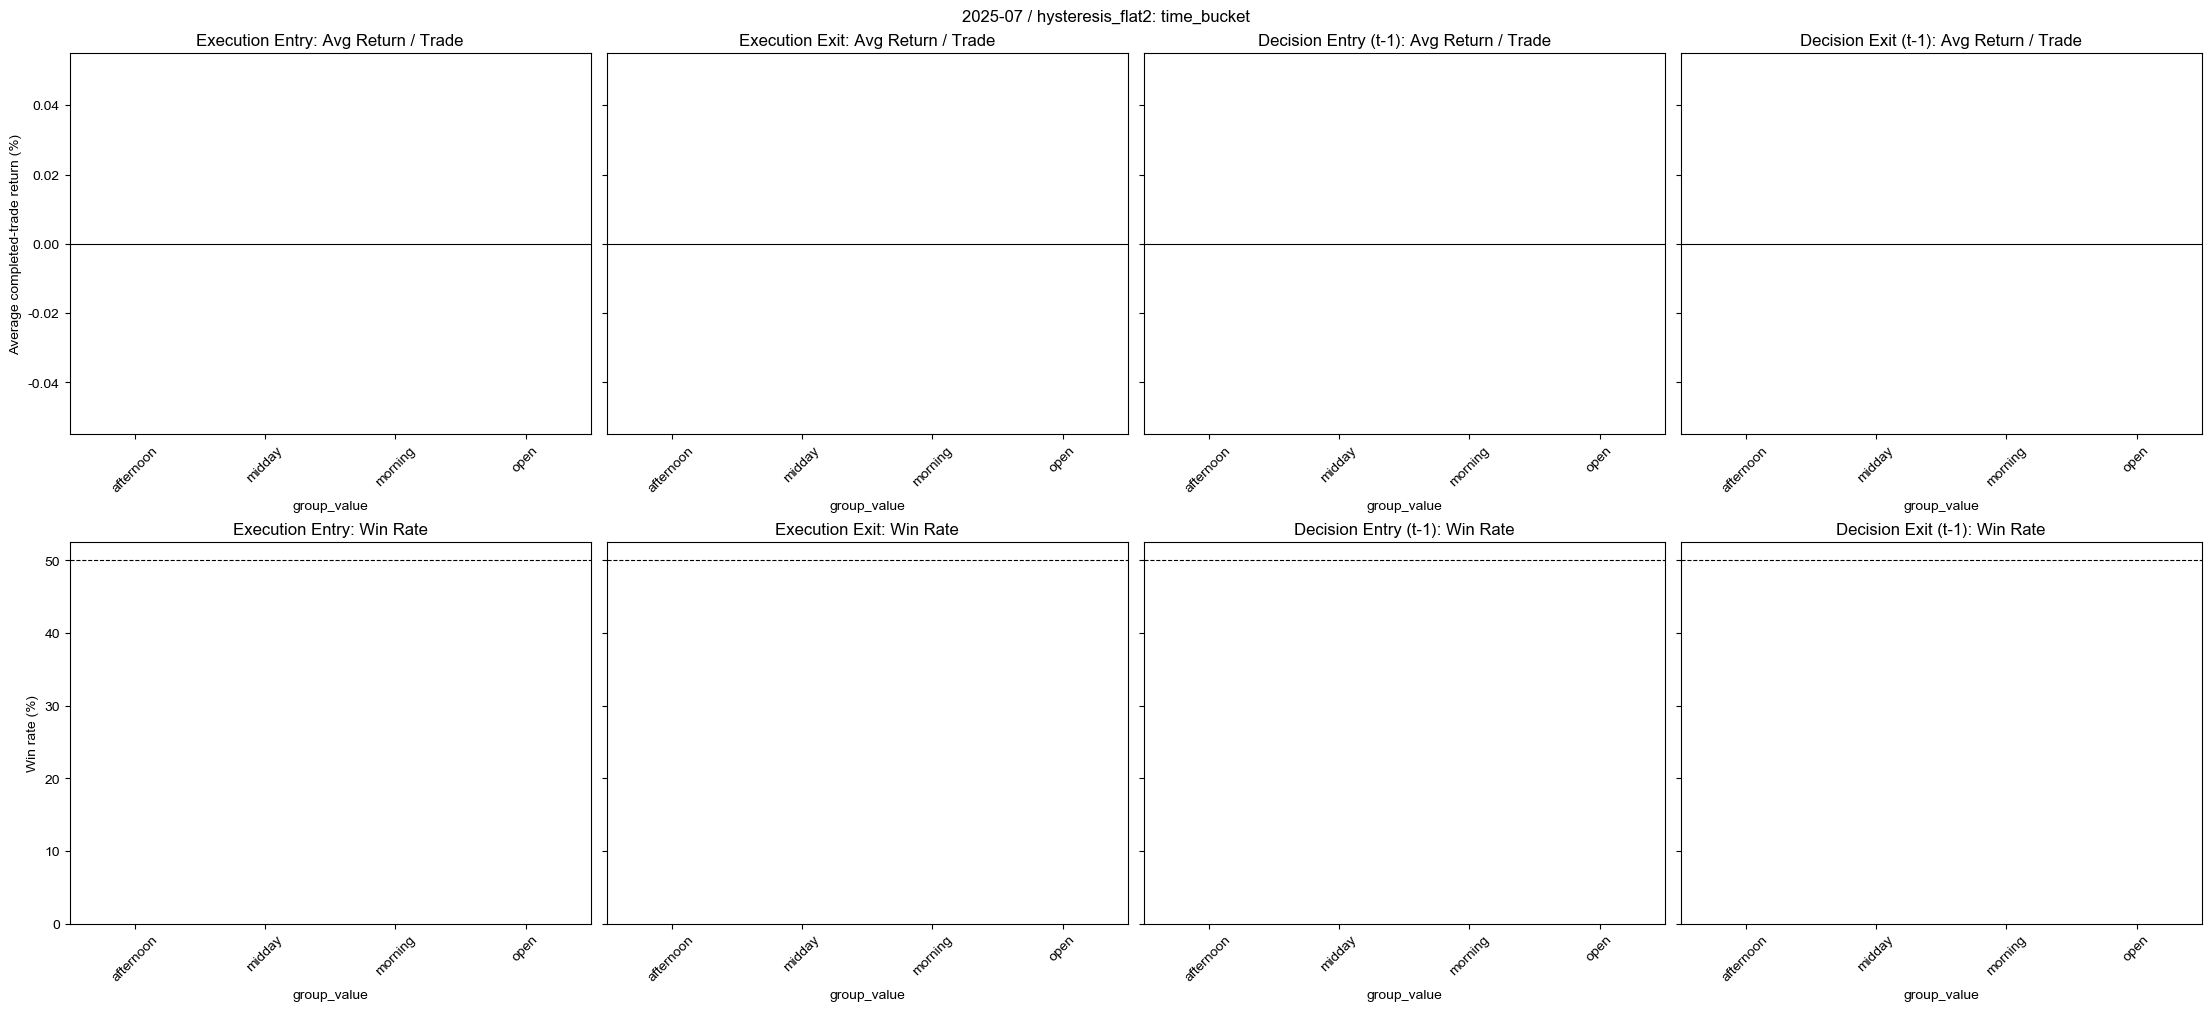

窗口诊断完成: 2025-07 hysteresis_flat2 -> artifacts/if_alstm_rolling_3state_intra_2025/window_diagnostics/2025-07/hysteresis_flat2/diagnostic_report.md


/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:274: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  inferred = out[[c for c in ("prob_down", "prob_flat", "prob_up") if c in out]].idxmax(axis=1)
/Users/miranda/zeshi/guotai/highfreq/utils/model_diagnostic_module.py:299: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out["strategy_return"] = pd.to_numeric(out["account"], errors="coerce").pct_change()


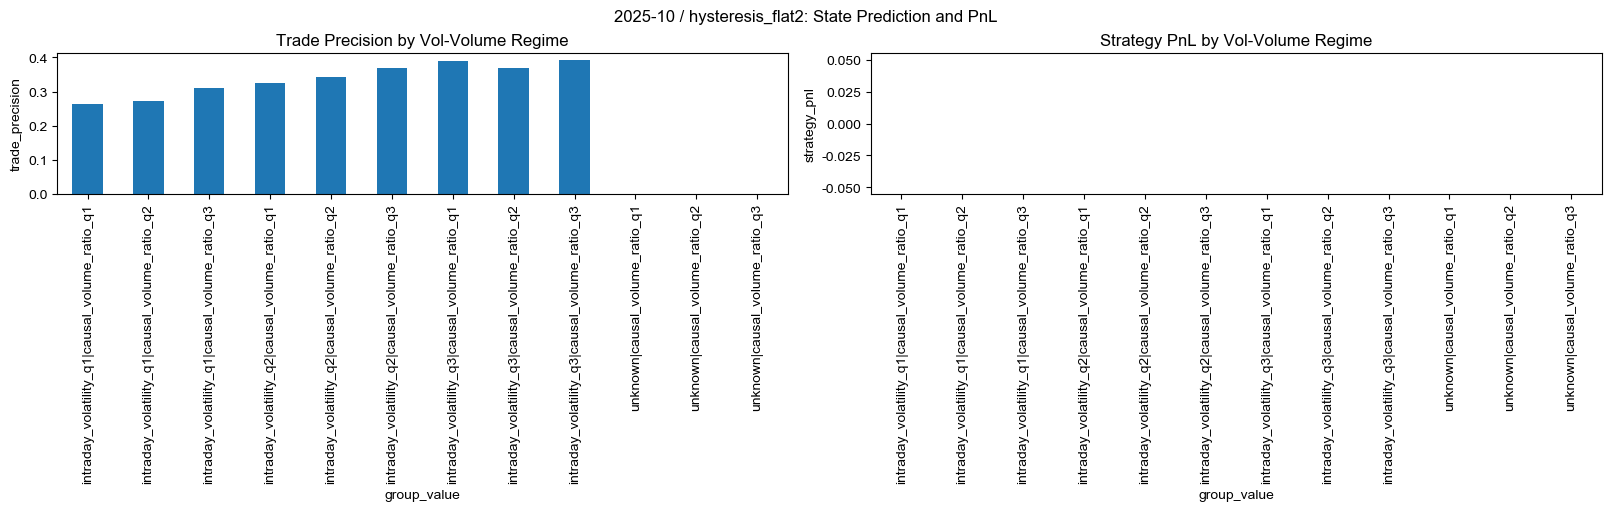

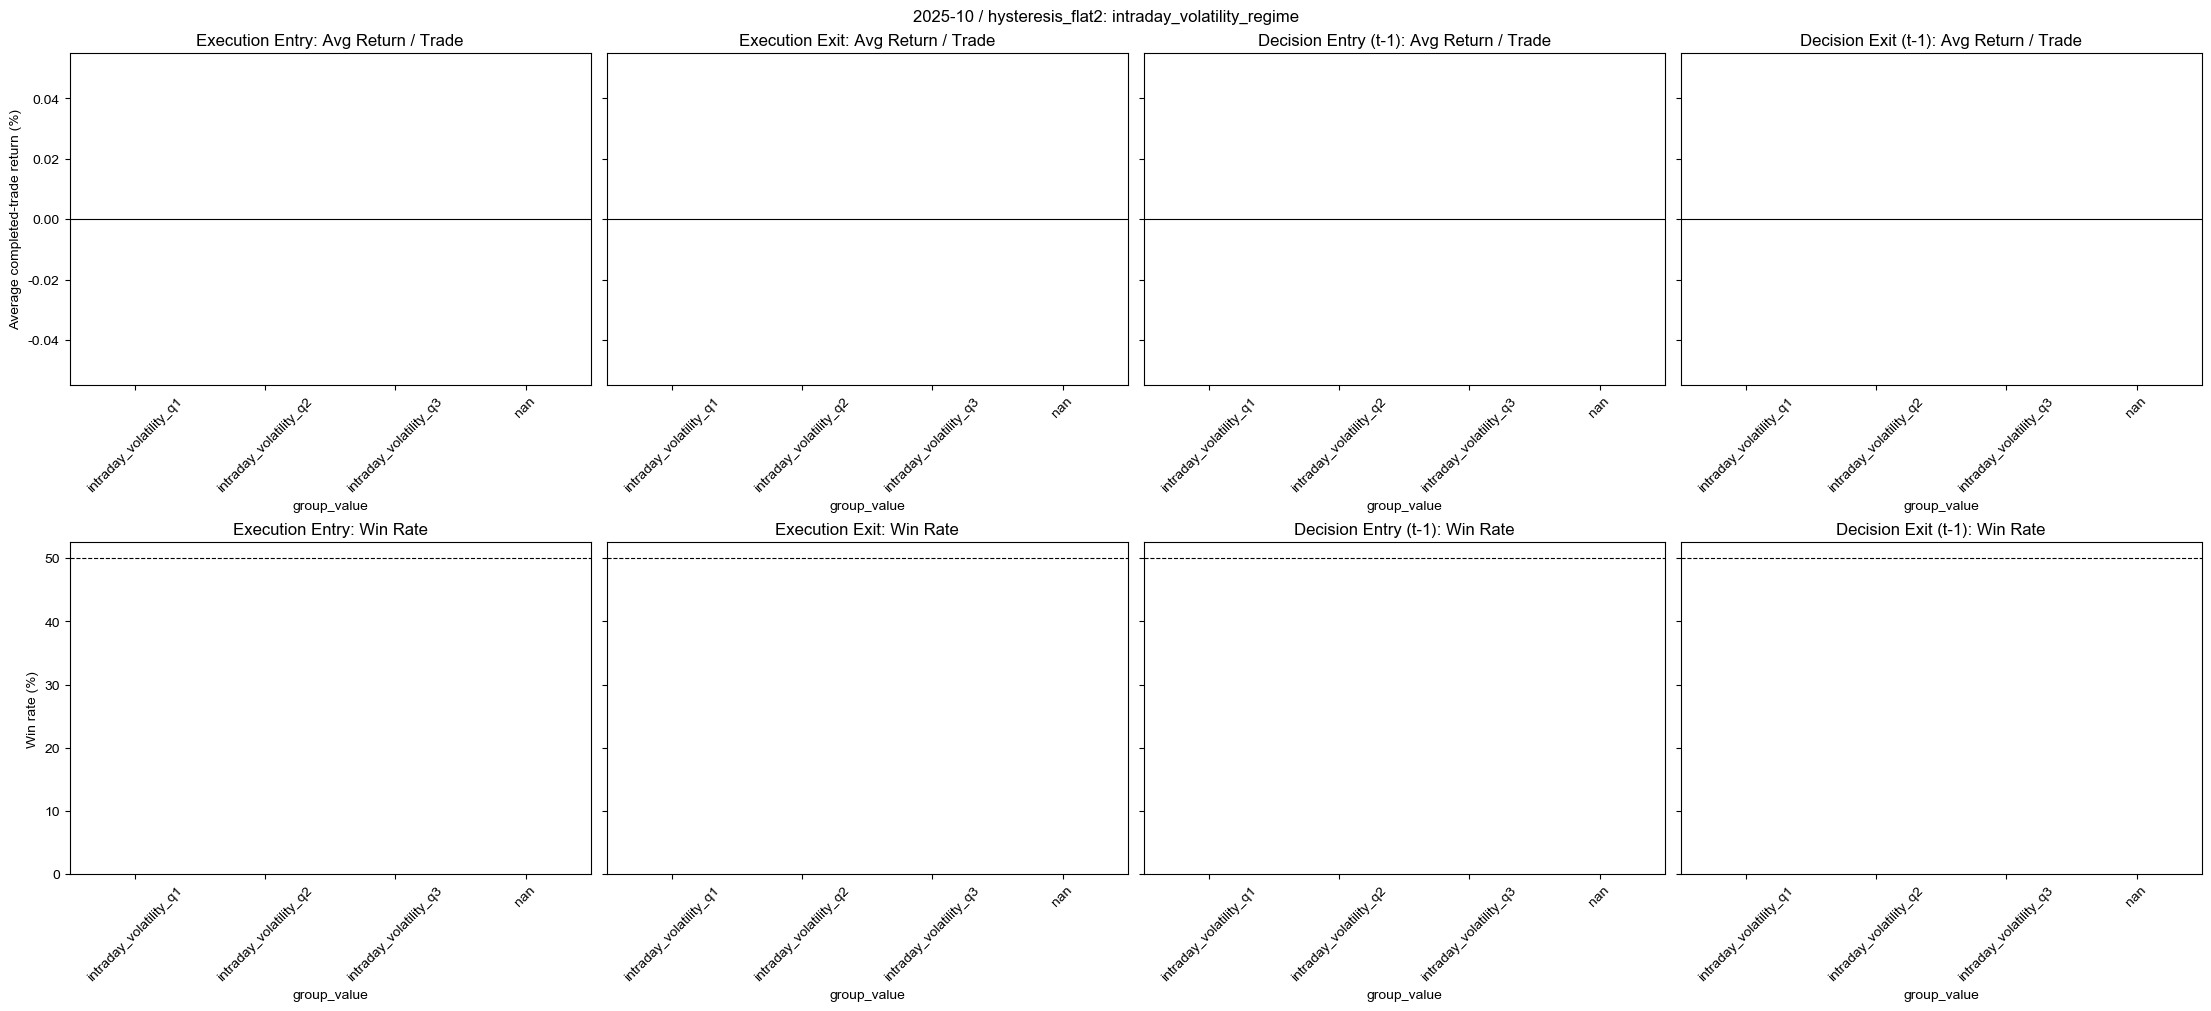

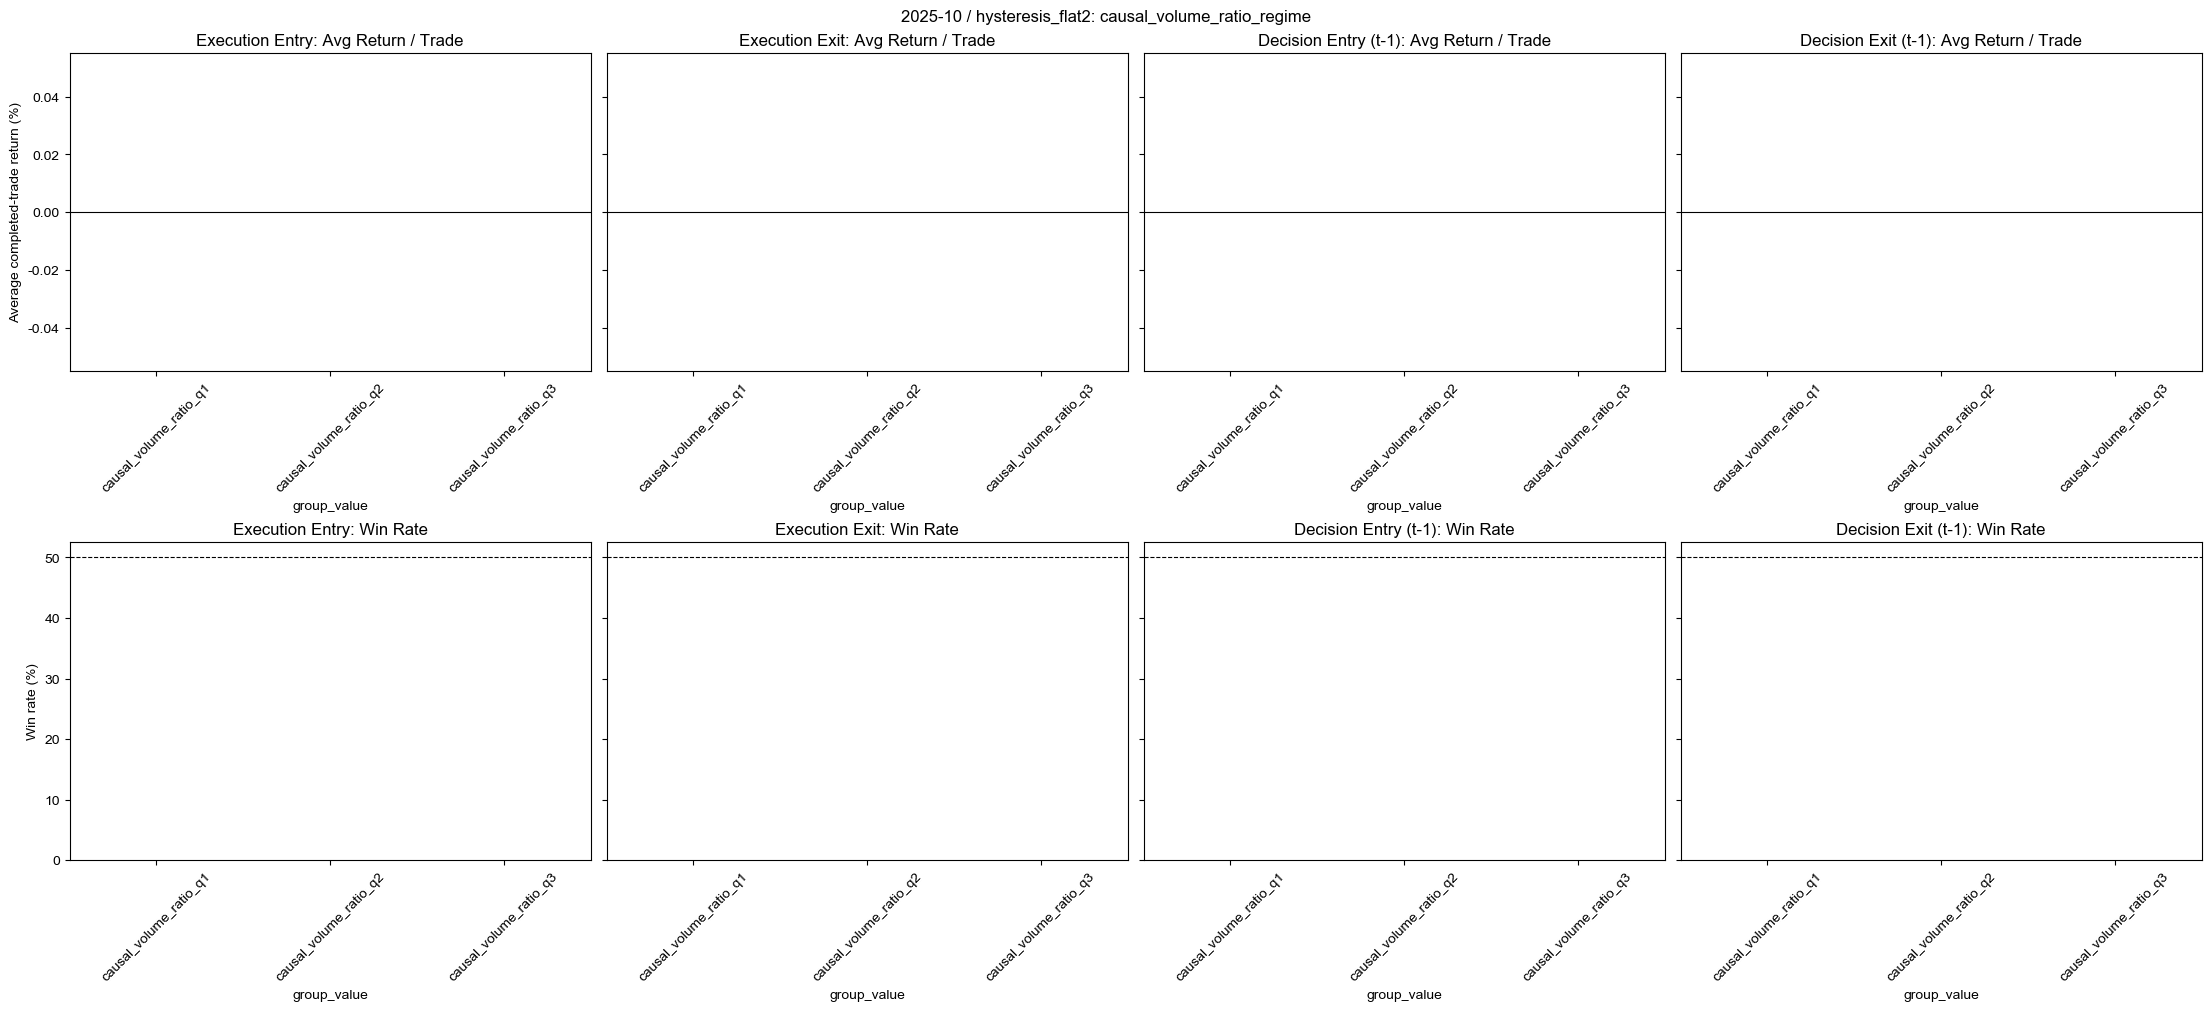

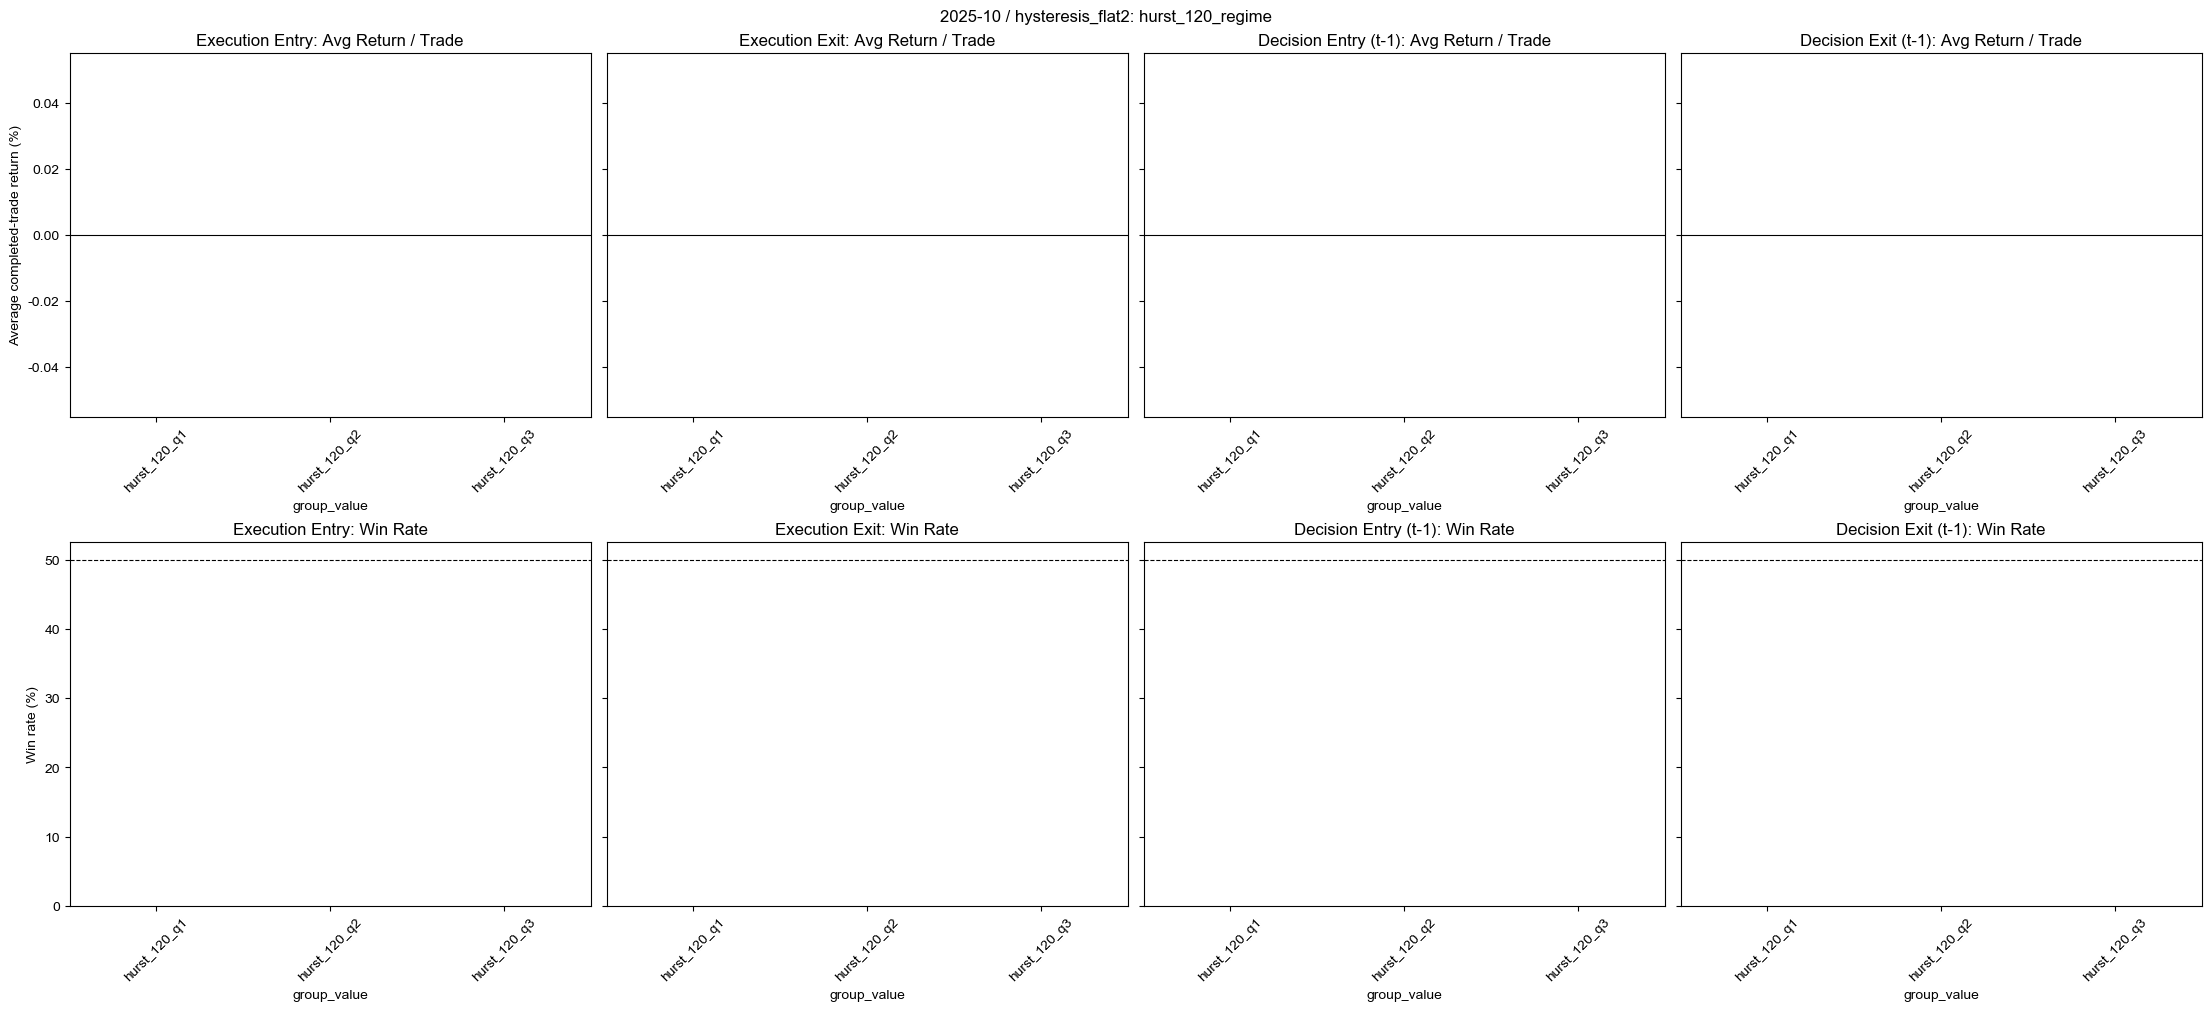

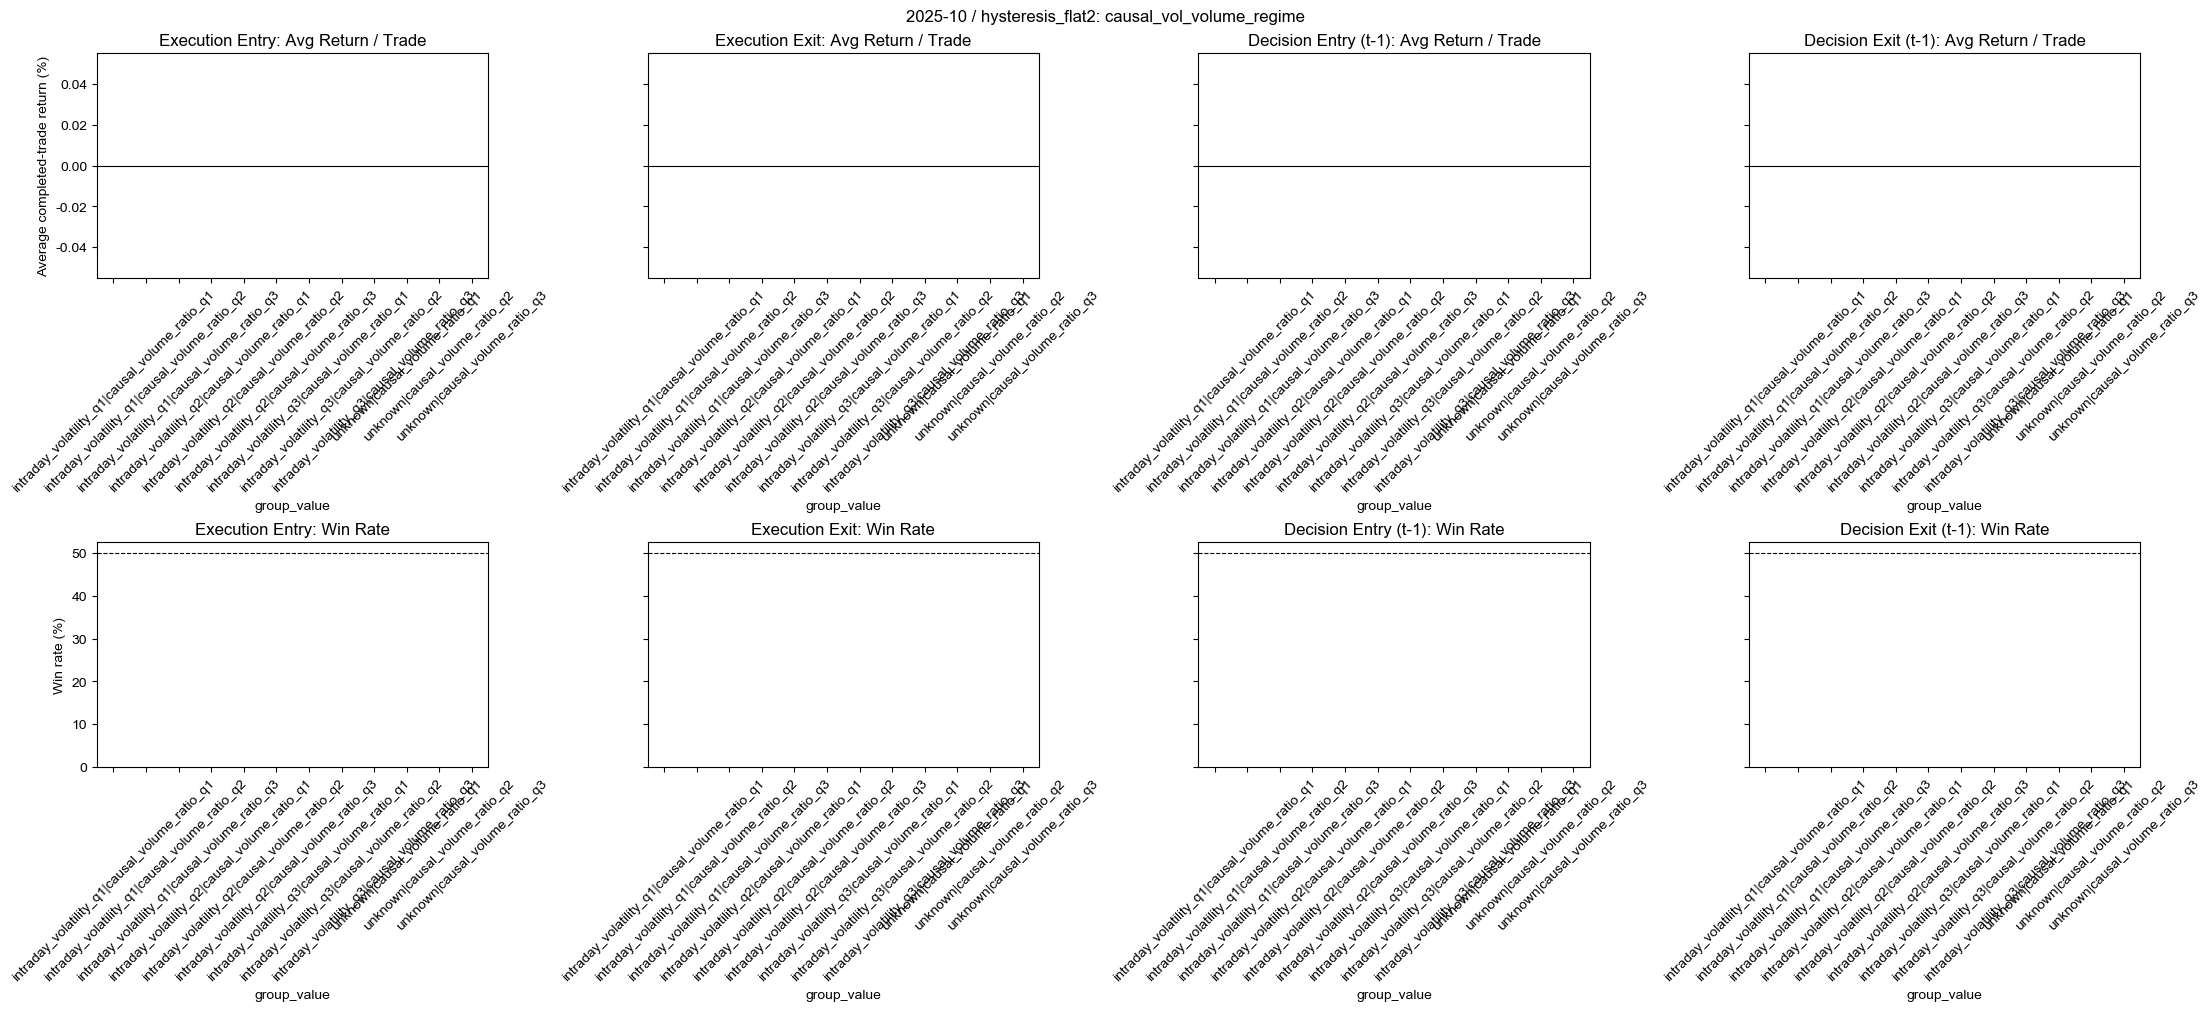

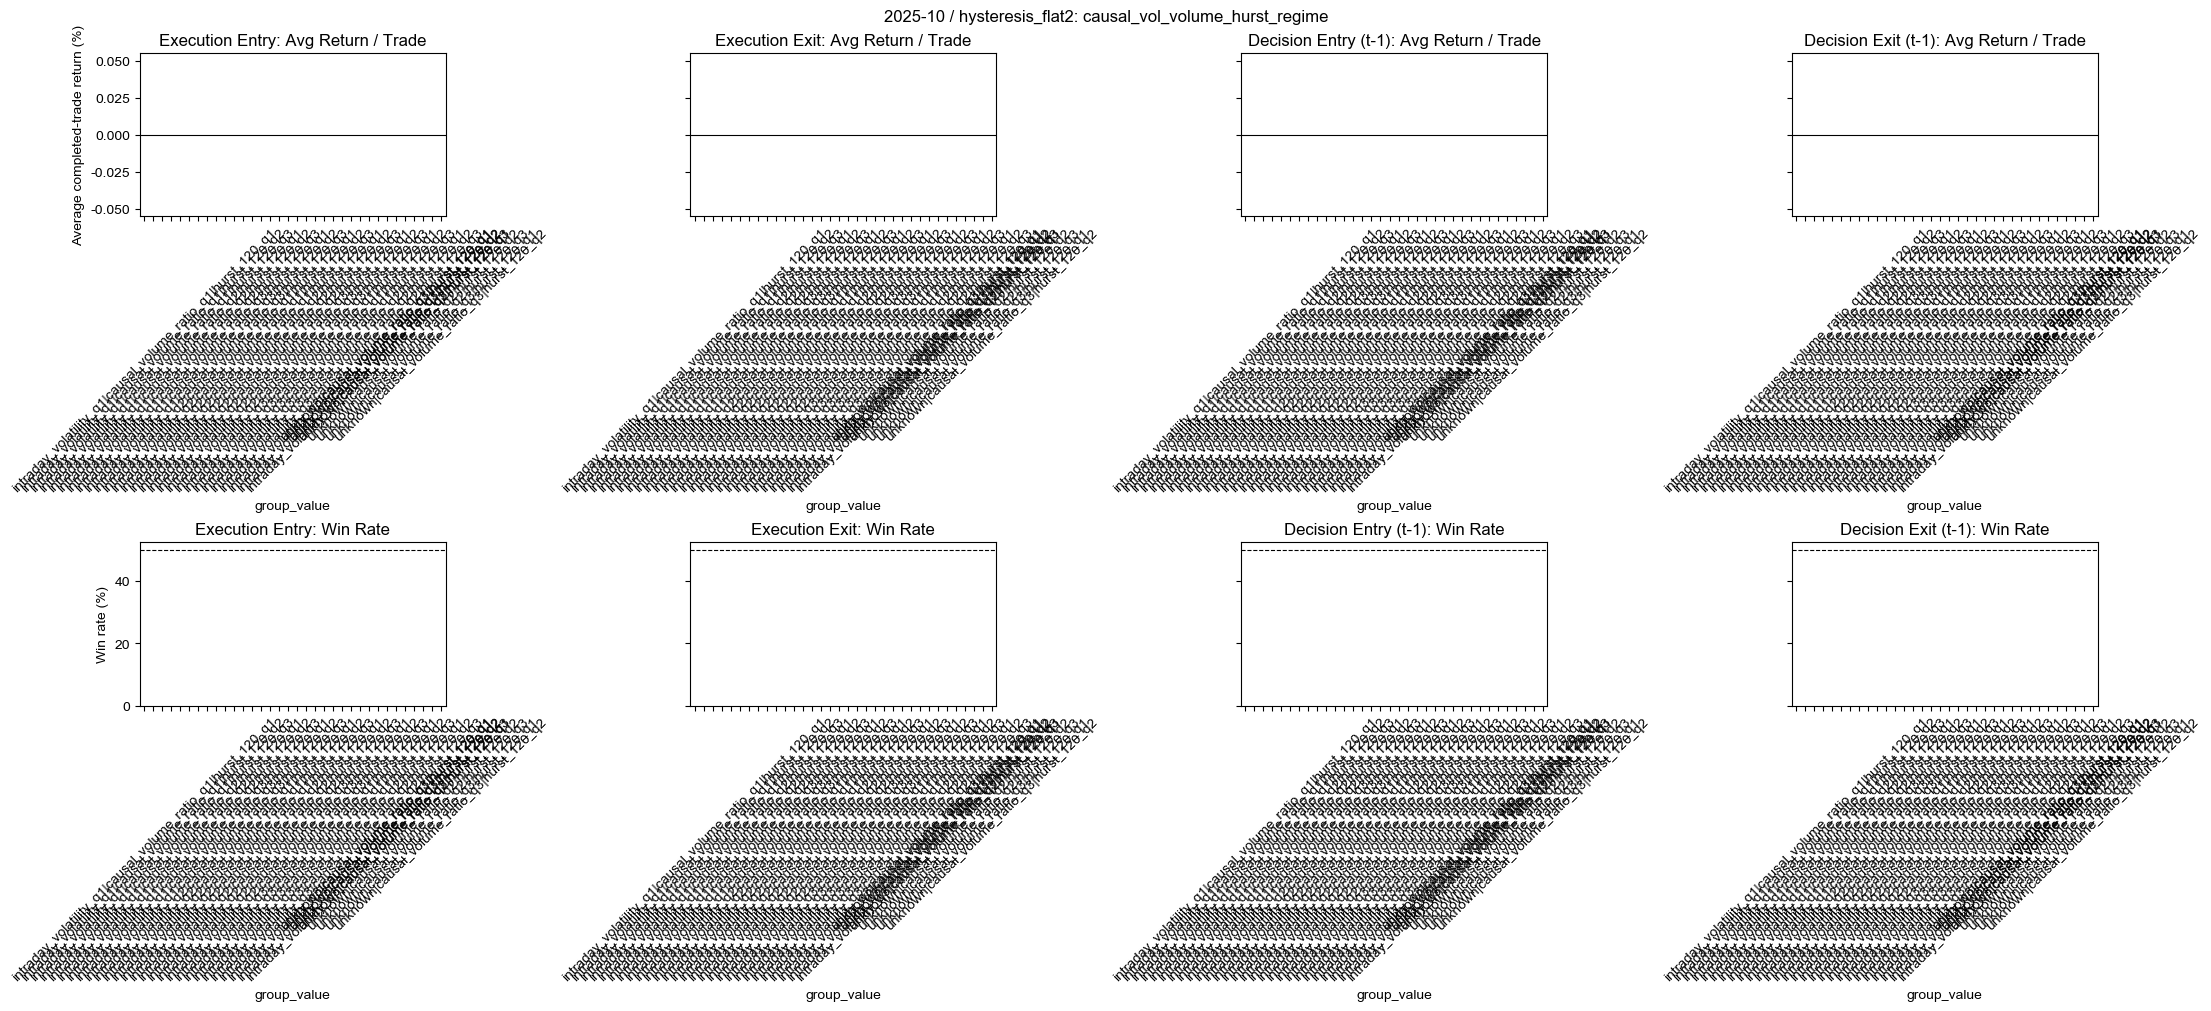

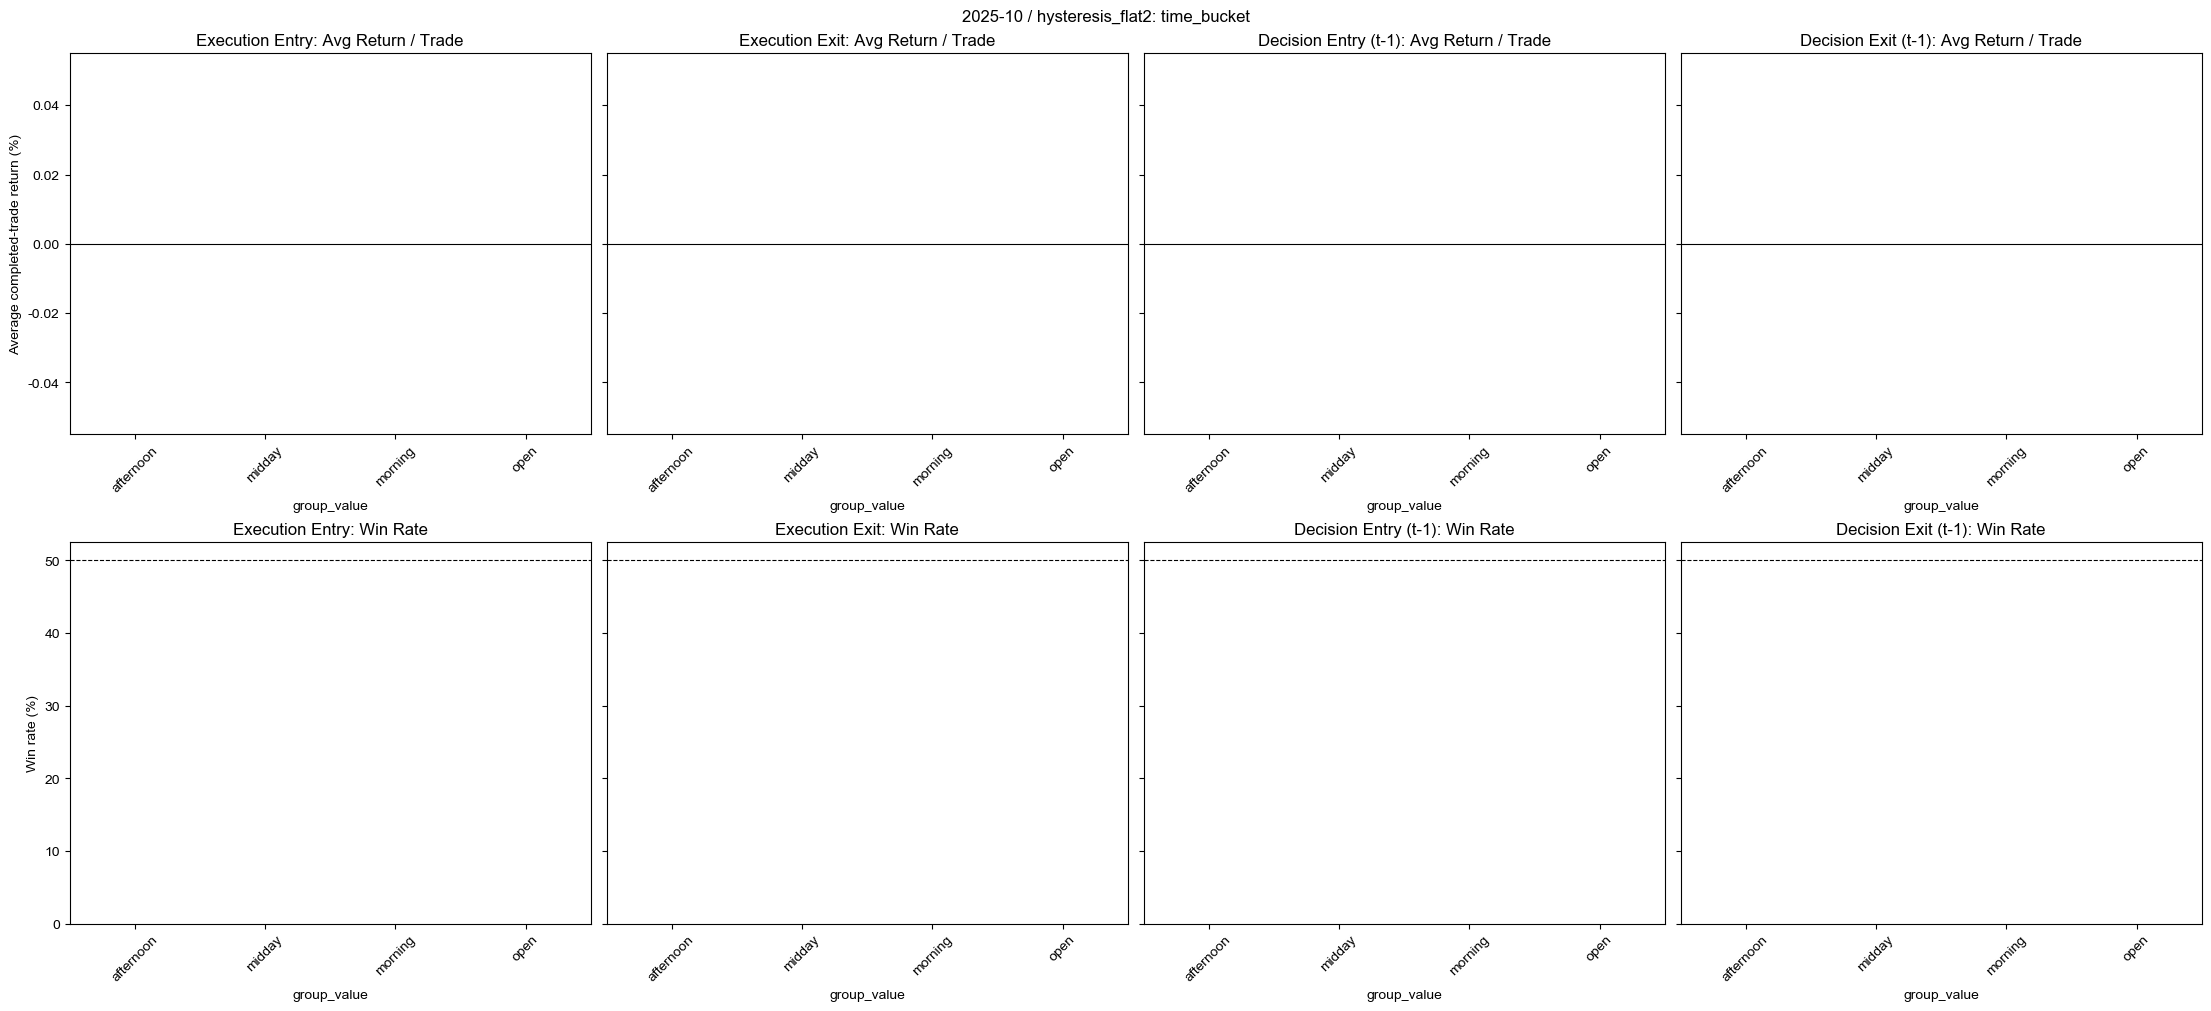

窗口诊断完成: 2025-10 hysteresis_flat2 -> artifacts/if_alstm_rolling_3state_intra_2025/window_diagnostics/2025-10/hysteresis_flat2/diagnostic_report.md


,window_id,test_start,test_end,backtest_config_name,group_col,group_value,samples,trade_precision,pred_trade_ratio,strategy_pnl,annualized_sharpe,decision_entry_avg_return_per_trade,decision_entry_win_rate,decision_entry_avg_pnl_per_trade,decision_entry_avg_profit,decision_entry_avg_loss,decision_exit_avg_return_per_trade,decision_exit_win_rate,decision_exit_avg_pnl_per_trade,decision_exit_avg_profit,decision_exit_avg_loss
0,2025-01,2025-01-01,2025-03-31,hard_flat,month,2025-01,4320,0.357596,0.620139,-691.074492,-1.635149,-0.000092,0.4,-138.214898,444.440317,-526.651709,-0.000092,0.4,-138.214898,444.440317,-526.651709
1,2025-01,2025-01-01,2025-03-31,hard_flat,month,2025-02,4320,0.384615,0.325000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01,2025-01-01,2025-03-31,hard_flat,month,2025-03,5040,0.356534,0.139683,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01,2025-01-01,2025-03-31,hard_flat,hour,9,1653,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01,2025-01-01,2025-03-31,hard_flat,hour,10,3420,0.377217,0.428655,789.260273,2.626833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,2025-10,2025-10-01,2025-12-31,hysteresis_flat2,causal_vol_volume_hurst_regime,unknown|causal_volume_ratio_q2|hurst_120_q1,147,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
642,2025-10,2025-10-01,2025-12-31,hysteresis_flat2,causal_vol_volume_hurst_regime,unknown|causal_volume_ratio_q2|hurst_120_q2,62,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
643,2025-10,2025-10-01,2025-12-31,hysteresis_flat2,causal_vol_volume_hurst_regime,unknown|causal_volume_ratio_q2|hurst_120_q3,40,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
644,2025-10,2025-10-01,2025-12-31,hysteresis_flat2,causal_vol_volume_hurst_regime,unknown|causal_volume_ratio_q3|hurst_120_q1,86,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


逐窗口诊断输出目录: artifacts/if_alstm_rolling_3state_intra_2025/window_diagnostics


In [9]:
# ===== 6.2) 每个滚动测试周期的状态模型诊断报告 =====
# 依赖：先运行滚动训练单元和 6.1 状态回测单元。
# 每个 window/config 独立生成诊断 CSV、图表和 Markdown；测试窗口只用于事后诊断，不用于选参。
import importlib
import engine.models.model_diagnostic as rolling_diagnostic_module
importlib.reload(rolling_diagnostic_module)

RollingDiagnosticConfig = rolling_diagnostic_module.DiagnosticConfig
prepare_rolling_market_regimes = rolling_diagnostic_module.prepare_market_regimes
build_rolling_state_diagnostic_frame = rolling_diagnostic_module.build_state_diagnostic_frame
summarize_rolling_diagnostics = rolling_diagnostic_module.summarize_diagnostics

rolling_diagnostic_root = artifact_root / "window_diagnostics"
rolling_diagnostic_root.mkdir(parents=True, exist_ok=True)
rolling_diagnostic_save_frame = False  # True 会保存逐分钟 diagnostic_frame.pkl，占用更多磁盘。
rolling_diagnostic_group_cols = [
    "month", "hour", "time_bucket",
    "intraday_volatility_regime", "daily_volatility_regime",
    "causal_volume_ratio_regime", "daily_volume_ratio_regime",
    "hurst_60_regime", "hurst_120_regime", "hurst_240_regime",
    "causal_vol_volume_regime", "causal_vol_volume_hurst_regime",
]
rolling_diagnostic_plot_groups = [
    "intraday_volatility_regime", "causal_volume_ratio_regime",
    "hurst_120_regime", "causal_vol_volume_regime", "causal_vol_volume_hurst_regime", "time_bucket",
]
rolling_diagnostic_config = RollingDiagnosticConfig(
    quantile_bins=3,
    min_group_samples=30,
    correlation_method="spearman",
)


def _rolling_period_end(value) -> pd.Timestamp:
    end = pd.Timestamp(value)
    return end + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1) if end == end.normalize() else end


def _rolling_datetime_series(frame: pd.DataFrame, field: str, start_time: str, end_time: str) -> pd.Series:
    if field not in frame.columns:
        raise KeyError(f"rollsafe_feature_frame 缺少 {field}")
    out = frame[["datetime", field]].copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).drop_duplicates("datetime", keep="last")
    out = out[(out["datetime"] >= pd.Timestamp(start_time)) & (out["datetime"] <= _rolling_period_end(end_time))]
    return pd.to_numeric(out.set_index("datetime")[field], errors="coerce").sort_index()


def _rolling_window_market_regimes(window: dict) -> pd.DataFrame:
    # 加载测试前约 45 天，只用于形成滚动日度指标；最终输出仍裁剪到测试窗口。
    start = pd.Timestamp(window["test_start"])
    end = _rolling_period_end(window["end_time"])
    history_start = min(pd.Timestamp(window["valid_start"]), start - pd.Timedelta(days=45))
    market = rollsafe_feature_frame.copy()
    market["datetime"] = pd.to_datetime(market["datetime"], errors="coerce")
    market = market[(market["datetime"] >= history_start) & (market["datetime"] <= end)]
    price_col = next((c for c in [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close"] if c in market.columns), None)
    volume_col = next((c for c in [f"{target_instrument}_volume", "volume"] if c in market.columns), None)
    regimes = prepare_rolling_market_regimes(
        market,
        price_col=price_col,
        volume_col=volume_col,
        intraday_vol_window=30,
        daily_vol_window=20,
        daily_volume_window=20,
        quantile_bins=rolling_diagnostic_config.quantile_bins,
        hurst_windows=rolling_diagnostic_config.hurst_windows,
        valid_start=window["valid_start"],
        valid_end=window["valid_end"],
        causal_volume=True,
        fit_regime_on_valid=True,
    )
    return regimes.loc[(regimes.index >= start) & (regimes.index <= end)]


def _read_rolling_report(window_id: str, config_name: str) -> pd.DataFrame:
    path = artifact_root / window_id / "rerun_backtest" / config_name / "account_curve.csv"
    if not path.exists():
        raise FileNotFoundError(f"找不到窗口回测账户曲线: {path}")
    report = pd.read_csv(path, index_col=0, parse_dates=True)
    report.index = pd.to_datetime(report.index, errors="coerce")
    return report.loc[report.index.notna()].sort_index()


def _markdown_table(frame: pd.DataFrame, columns: list[str], max_rows: int = 12) -> str:
    available = [c for c in columns if c in frame.columns]
    if not available or frame.empty:
        return "_无可用结果_"
    view = frame[available].head(max_rows).copy()
    for col in view.columns:
        if pd.api.types.is_float_dtype(view[col]):
            view[col] = view[col].map(lambda x: "" if pd.isna(x) else f"{x:.6f}")
    header = "| " + " | ".join(map(str, view.columns)) + " |"
    rule = "| " + " | ".join(["---"] * len(view.columns)) + " |"
    rows = ["| " + " | ".join(str(v).replace("|", "\\|") for v in row) + " |" for row in view.to_numpy()]
    return "\n".join([header, rule, *rows])


def _plot_window_state_diagnostics(summary: pd.DataFrame, out_dir: Path, window_id: str, config_name: str) -> None:
    combined = summary[summary["group_col"] == "causal_vol_volume_regime"].copy()
    if not combined.empty:
        combined = combined.set_index("group_value")
        fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
        combined["trade_precision"].plot.bar(ax=axes[0], title="Trade Precision by Vol-Volume Regime")
        combined["strategy_pnl"].plot.bar(ax=axes[1], title="Strategy PnL by Vol-Volume Regime")
        axes[0].set_ylabel("trade_precision")
        axes[1].set_ylabel("strategy_pnl")
        fig.suptitle(f"{window_id} / {config_name}: State Prediction and PnL")
        fig.savefig(out_dir / "prediction_pnl_by_vol_volume.png", dpi=150, bbox_inches="tight")
        plt.show()

    views = [
        ("entry", "Execution Entry"), ("exit", "Execution Exit"),
        ("decision_entry", "Decision Entry (t-1)"), ("decision_exit", "Decision Exit (t-1)"),
    ]
    for group_col in rolling_diagnostic_plot_groups:
        grouped = summary[summary["group_col"] == group_col].copy()
        if grouped.empty:
            continue
        grouped = grouped.set_index("group_value")
        required = [f"{prefix}_{metric}" for prefix, _ in views for metric in ["avg_return_per_trade", "win_rate"]]
        if any(col not in grouped.columns for col in required):
            continue
        fig, axes = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True, sharey="row")
        for j, (prefix, title) in enumerate(views):
            (pd.to_numeric(grouped[f"{prefix}_avg_return_per_trade"], errors="coerce") * 100).plot.bar(ax=axes[0, j], color="#2f7d8c")
            (pd.to_numeric(grouped[f"{prefix}_win_rate"], errors="coerce") * 100).plot.bar(ax=axes[1, j], color="#c9793b")
            axes[0, j].axhline(0, color="black", linewidth=0.8)
            axes[1, j].axhline(50, color="black", linewidth=0.8, linestyle="--")
            axes[0, j].set_title(f"{title}: Avg Return / Trade")
            axes[1, j].set_title(f"{title}: Win Rate")
            axes[0, j].tick_params(axis="x", labelrotation=45)
            axes[1, j].tick_params(axis="x", labelrotation=45)
        axes[0, 0].set_ylabel("Average completed-trade return (%)")
        axes[1, 0].set_ylabel("Win rate (%)")
        fig.suptitle(f"{window_id} / {config_name}: {group_col}")
        fig.savefig(out_dir / f"{group_col}_entry_exit_decision.png", dpi=150, bbox_inches="tight")
        plt.show()


def _write_window_state_report(window: dict, config_name: str, summary: pd.DataFrame, report_df: pd.DataFrame, out_dir: Path, initial_account: float) -> None:
    core = account_metrics(report_df["account"], initial_account)
    vol = summary[summary["group_col"] == "intraday_volatility_regime"].copy().sort_values("strategy_pnl", ascending=False)
    joint = summary[summary["group_col"] == "causal_vol_volume_regime"].copy().sort_values("strategy_pnl", ascending=False)
    time_summary = summary[summary["group_col"] == "time_bucket"].copy().sort_values("strategy_pnl", ascending=False)
    metric_cols = [
        "group_value", "samples", "trade_precision", "pred_trade_ratio", "strategy_pnl", "annualized_sharpe",
        "decision_entry_avg_return_per_trade", "decision_entry_win_rate",
        "decision_entry_avg_pnl_per_trade", "decision_entry_avg_profit", "decision_entry_avg_loss",
        "decision_exit_avg_return_per_trade", "decision_exit_win_rate",
        "decision_exit_avg_pnl_per_trade", "decision_exit_avg_profit", "decision_exit_avg_loss",
        "entry_avg_return_per_trade", "entry_win_rate", "entry_avg_pnl_per_trade", "entry_avg_profit", "entry_avg_loss",
        "exit_avg_return_per_trade", "exit_win_rate", "exit_avg_pnl_per_trade", "exit_avg_profit", "exit_avg_loss",
    ]
    best_joint = joint.iloc[0] if not joint.empty else pd.Series(dtype=object)
    worst_joint = joint.iloc[-1] if not joint.empty else pd.Series(dtype=object)
    lines = [
        f"# {target_instrument} ALSTM 滚动窗口诊断：{window['window_id']} / {config_name}", "",
        "## 测试周期", "",
        f"- 训练区间：**{window['start_time']} 至 {window['train_end']}**",
        f"- 验证区间：**{window['valid_start']} 至 {window['valid_end']}**",
        f"- 测试区间：**{window['test_start']} 至 {window['end_time']}**",
        f"- 回测配置：`{config_name}`", "",
        "## 核心回测指标", "",
        *[f"- `{k}`：{v:.6f}" if isinstance(v, (float, np.floating)) else f"- `{k}`：{v}" for k, v in core.items()], "",
        "## 结论摘要", "",
        f"- 收益贡献最高的联合 Regime：`{best_joint.get('group_value', 'N/A')}`，PnL={best_joint.get('strategy_pnl', np.nan):.2f}",
        f"- 收益贡献最低的联合 Regime：`{worst_joint.get('group_value', 'N/A')}`，PnL={worst_joint.get('strategy_pnl', np.nan):.2f}",
        "- 动态阈值决策应优先参考 `decision_entry_* / decision_exit_*`；执行环境分析参考 `entry_* / exit_*`。", "",
        "## 日内波动率", "", _markdown_table(vol, metric_cols), "",
        "## 波动率与成交量联合状态", "", _markdown_table(joint, metric_cols), "",
        "## 时段", "", _markdown_table(time_summary, metric_cols), "",
        "## 口径说明", "",
        "- `entry_* / exit_*`：实际执行开仓和平仓时的 Regime。",
        "- `decision_entry_* / decision_exit_*`：执行前一根可用 bar、即生成决策时的 Regime。",
        "- 本报告的模块 5 Regime 用于测试窗口事后诊断，不用于同一测试窗口选参。",
    ]
    (out_dir / "diagnostic_report.md").write_text("\n".join(lines) + "\n", encoding="utf-8")


rolling_window_diagnostic_rows = []
rolling_window_diagnostic_errors = []
if model_task not in {"state", "both"}:
    print("model_task 不包含 state，跳过状态模型逐窗口诊断。")
else:
    diagnostic_param_rows = globals().get("active_param_rows", pd.DataFrame([get_active_backtest_params()]))
    for _, param_row in diagnostic_param_rows.iterrows():
        config_name = str(param_row.get("config_name", "default"))
        for _, window_row in tqdm(windows_df.iterrows(), total=len(windows_df), desc=f"window diagnostics {config_name}"):
            window = window_row.to_dict()
            window_id = window["window_id"]
            out_dir = rolling_diagnostic_root / window_id / config_name
            out_dir.mkdir(parents=True, exist_ok=True)
            try:
                state_prob, state_pred = _load_window_state_prediction(window_id)
                report_df = _read_rolling_report(window_id, config_name)
                market_regimes = _rolling_window_market_regimes(window)
                label_state = _rolling_datetime_series(rollsafe_feature_frame, "label_state", window["test_start"], window["end_time"])
                diagnostic_frame = build_rolling_state_diagnostic_frame(
                    state_prob, state_pred, label_state,
                    report_df=report_df,
                    market_regimes=market_regimes,
                )
                summary = summarize_rolling_diagnostics(
                    diagnostic_frame,
                    model_type="state",
                    group_cols=rolling_diagnostic_group_cols,
                    config=rolling_diagnostic_config,
                )
                summary.insert(0, "backtest_config_name", config_name)
                summary.insert(0, "test_end", window["end_time"])
                summary.insert(0, "test_start", window["test_start"])
                summary.insert(0, "window_id", window_id)
                summary.to_csv(out_dir / "state_diagnostic_summary.csv", index=False, encoding="utf-8-sig")
                if rolling_diagnostic_save_frame:
                    diagnostic_frame.to_pickle(out_dir / "state_diagnostic_frame.pkl")
                _plot_window_state_diagnostics(summary, out_dir, window_id, config_name)
                _write_window_state_report(window, config_name, summary, report_df, out_dir, float(param_row.get("account", account)))
                rolling_window_diagnostic_rows.append(summary)
                print("窗口诊断完成:", window_id, config_name, "->", out_dir / "diagnostic_report.md")
            except Exception as exc:
                rolling_window_diagnostic_errors.append({**window, "backtest_config_name": config_name, "error": repr(exc)})
                print("窗口诊断失败:", window_id, config_name, repr(exc))

rolling_window_diagnostic_summary = (
    pd.concat(rolling_window_diagnostic_rows, ignore_index=True)
    if rolling_window_diagnostic_rows else pd.DataFrame()
)
rolling_window_diagnostic_errors_df = pd.DataFrame(rolling_window_diagnostic_errors)
rolling_window_diagnostic_summary.to_csv(rolling_diagnostic_root / "all_windows_state_diagnostic_summary.csv", index=False, encoding="utf-8-sig")
rolling_window_diagnostic_errors_df.to_csv(rolling_diagnostic_root / "window_diagnostic_errors.csv", index=False, encoding="utf-8-sig")

if not rolling_window_diagnostic_summary.empty:
    stability_cols = [
        "window_id", "test_start", "test_end", "backtest_config_name", "group_col", "group_value",
        "samples", "trade_precision", "pred_trade_ratio", "strategy_pnl", "annualized_sharpe",
        "decision_entry_avg_return_per_trade", "decision_entry_win_rate",
        "decision_entry_avg_pnl_per_trade", "decision_entry_avg_profit", "decision_entry_avg_loss",
        "decision_exit_avg_return_per_trade", "decision_exit_win_rate",
        "decision_exit_avg_pnl_per_trade", "decision_exit_avg_profit", "decision_exit_avg_loss",
    ]
    rolling_regime_stability = rolling_window_diagnostic_summary[[c for c in stability_cols if c in rolling_window_diagnostic_summary.columns]].copy()
    rolling_regime_stability.to_csv(rolling_diagnostic_root / "rolling_regime_stability.csv", index=False, encoding="utf-8-sig")
    display(rolling_regime_stability)
if not rolling_window_diagnostic_errors_df.empty:
    display(rolling_window_diagnostic_errors_df)
print("逐窗口诊断输出目录:", rolling_diagnostic_root)


regime filter backtest:   0%|          | 0/4 [00:00<?, ?it/s]

2025-01 highvol_highvolume_only: PnL=7935.09, filtered opens=3348, trailing exits=0
2025-01 drop_lowvol_lowvolume: PnL=-166060.35, filtered opens=156, trailing exits=0
2025-01 dynamic_threshold_lowvol_lowvolume: PnL=-120172.54, filtered opens=648, trailing exits=0
2025-04 highvol_highvolume_only: PnL=42619.92, filtered opens=1555, trailing exits=0
2025-04 drop_lowvol_lowvolume: PnL=-14579.96, filtered opens=103, trailing exits=0
2025-04 dynamic_threshold_lowvol_lowvolume: PnL=14760.81, filtered opens=343, trailing exits=0
2025-07 highvol_highvolume_only: PnL=-25660.74, filtered opens=1484, trailing exits=0
2025-07 drop_lowvol_lowvolume: PnL=-51687.63, filtered opens=0, trailing exits=0
2025-07 dynamic_threshold_lowvol_lowvolume: PnL=-45117.11, filtered opens=61, trailing exits=0
2025-10 highvol_highvolume_only: PnL=-5986.48, filtered opens=3552, trailing exits=0
2025-10 drop_lowvol_lowvolume: PnL=-51797.33, filtered opens=70, trailing exits=0
2025-10 dynamic_threshold_lowvol_lowvolume:

,window_id,strategy,absolute_pnl,total_return,annualized_sharpe,max_drawdown,trade_count,weak_open_filtered_count,weak_trailing_exit_count,weak_prob_decay_exit_count,weak_no_profit_exit_count,allow_open_rule
0,2025-01,baseline,-691.074492,-0.000461,-0.927029,-0.001207,10,0,0,0,0,baseline
1,2025-01,highvol_highvolume_only,7935.091128,0.005290,0.761055,-0.020552,397,3348,0,0,0,high_vol_and_high_volume
2,2025-01,drop_lowvol_lowvolume,-166060.348154,-0.110707,-8.595194,-0.121120,3020,156,0,0,0,not_low_vol_and_low_volume
3,2025-01,dynamic_threshold_lowvol_lowvolume,-120172.535449,-0.080115,-6.494856,-0.092430,2484,648,0,0,0,not_low_vol_and_low_volume
4,2025-04,baseline,5159.017822,0.003439,2.005151,-0.003484,26,0,0,0,0,baseline
5,2025-04,highvol_highvolume_only,42619.922388,0.028413,2.951792,-0.015801,181,1555,0,0,0,high_vol_and_high_volume
6,2025-04,drop_lowvol_lowvolume,-14579.961841,-0.009720,-0.797638,-0.062278,1253,103,0,0,0,not_low_vol_and_low_volume
7,2025-04,dynamic_threshold_lowvol_lowvolume,14760.809575,0.009841,0.866039,-0.042987,986,343,0,0,0,not_low_vol_and_low_volume
8,2025-07,baseline,0.000000,0.000000,NaN,0.000000,0,0,0,0,0,baseline
9,2025-07,highvol_highvolume_only,-25660.735620,-0.017107,-1.025896,-0.043766,1039,1484,0,0,0,high_vol_and_high_volume


,highvol_highvolume_only_minus_baseline_absolute_pnl,drop_lowvol_lowvolume_minus_baseline_absolute_pnl,dynamic_threshold_lowvol_lowvolume_minus_baseline_absolute_pnl,highvol_highvolume_only_minus_baseline_annualized_sharpe,drop_lowvol_lowvolume_minus_baseline_annualized_sharpe,dynamic_threshold_lowvol_lowvolume_minus_baseline_annualized_sharpe,highvol_highvolume_only_minus_baseline_max_drawdown,drop_lowvol_lowvolume_minus_baseline_max_drawdown,dynamic_threshold_lowvol_lowvolume_minus_baseline_max_drawdown,highvol_highvolume_only_minus_baseline_trade_count,drop_lowvol_lowvolume_minus_baseline_trade_count,dynamic_threshold_lowvol_lowvolume_minus_baseline_trade_count
window_id,,,,,,,,,,,,
2025-01,8626.165620,-165369.273662,-119481.460957,1.688083,-7.668166,-5.567827,-0.019345,-0.119913,-0.091223,387.0,3010.0,2474.0
2025-04,37460.904565,-19738.979663,9601.791753,0.946641,-2.802789,-1.139112,-0.012317,-0.058794,-0.039503,155.0,1227.0,960.0
2025-07,-25660.735620,-51687.625254,-45117.108223,NaN,NaN,NaN,-0.043766,-0.068542,-0.065490,1039.0,1715.0,1686.0
2025-10,-5986.475566,-51797.332383,-11677.365146,NaN,NaN,NaN,-0.015461,-0.070254,-0.048075,705.0,3148.0,2768.0


,strategy,backtest_mode,trade_count,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown
0,baseline,continuous_once_run_backtest_target_lots,36,58320,1500000.0,1.504468e+06,4467.943330,0.002979,0.003336,0.820455,-0.003486
1,highvol_highvolume_only,continuous_once_run_backtest_target_lots,2680,58320,1500000.0,1.518908e+06,18907.802329,0.012605,0.001289,0.316913,-0.042406
2,drop_lowvol_lowvolume,continuous_once_run_backtest_target_lots,10382,58320,1500000.0,1.215875e+06,-284125.267632,-0.189417,-0.012236,-3.009226,-0.199892
3,dynamic_threshold_lowvol_lowvolume,continuous_once_run_backtest_target_lots,9050,58320,1500000.0,1.337794e+06,-162206.199243,-0.108137,-0.007110,-1.748640,-0.124002
4,Buy 1 Lot and Hold,NaN,1,58080,1500000.0,1.715873e+06,215872.625000,0.143915,0.005590,1.374672,-0.107603


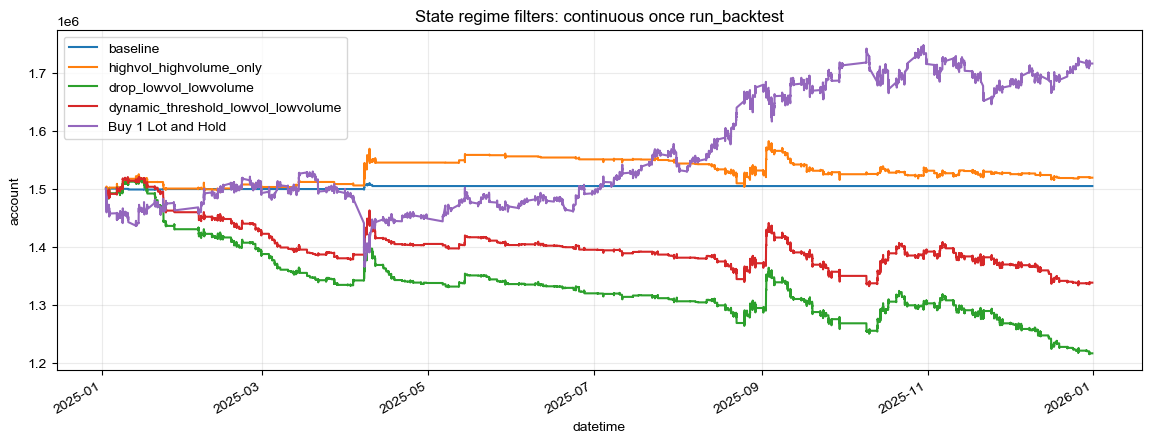

State 高波动高成交过滤回测输出目录: artifacts/if_alstm_rolling_3state_intra_2025/state_highvol_highvolume_only_filter


In [10]:
# ===== 6.3) State 模型：高波动率 + 高成交量开仓过滤回测对比 =====
# 运行顺序：先运行 6.1 生成 hard_flat 基准回测，再运行本单元。
# 过滤只影响新开仓和反手后的重新开仓；平仓、反手先平仓和强制平仓始终允许。
# 本单元比较：高波动高成交过滤、只过滤低波动低成交、低波动低成交动态阈值；全部关闭离场增强。
import importlib
from dataclasses import replace
import engine.backtest.regime_filter as regime_filter_backtest_module
importlib.reload(regime_filter_backtest_module)
from engine.backtest.regime_filter import RegimeFilterConfig, prepare_causal_regimes, run_regime_filtered_state_backtest, build_regime_filtered_state_target_lots

regime_filter_config = RegimeFilterConfig(
    vol_window=30,
    volume_history_days=20,
    base_prob_threshold=0.38,
    base_min_margin=0.02,
    weak_prob_threshold=0.45,
    weak_min_margin=0.03,
    weak_trailing_stop_pct=0.0012,  # 0.12%；只在弱组合且已有浮盈后启用
    weak_trailing_activation_pct=0.0015,  # 0.15%；先有足够浮盈，再启动移动止盈
    weak_exit_min_direction_margin=0.03,  # 弱环境下持仓方向概率优势低于该值则提前退出
    weak_no_profit_exit_bars=20,  # 弱环境持仓超过 N 根 bar 且无浮盈则退出
    weak_rule="bad_combo",  # 弱环境仍用于离场增强
    allow_open_rule="high_vol_and_high_volume",
    allow_open_vol_regime="intraday_volatility_q3",
    allow_open_volume_regime="causal_volume_ratio_q3",
)
regime_filter_no_exit_config = replace(
    regime_filter_config,
    weak_trailing_stop_pct=999.0,
    weak_trailing_activation_pct=999.0,
    weak_exit_min_direction_margin=-999.0,
    weak_no_profit_exit_bars=10**9,
)
regime_filter_highvol_highvolume_config = regime_filter_no_exit_config
regime_filter_drop_lowvol_lowvolume_config = replace(
    regime_filter_no_exit_config,
    weak_prob_threshold=regime_filter_config.base_prob_threshold,
    weak_min_margin=regime_filter_config.base_min_margin,
    weak_rule="low_vol_and_low_volume",
    allow_open_rule="not_low_vol_and_low_volume",
)
regime_filter_dynamic_threshold_config = replace(
    regime_filter_no_exit_config,
    # low vol + low volume: 直接过滤，不开仓；mid vol + low volume: 提高阈值；其他组合正常阈值。
    weak_rule="mid_vol_and_low_volume",
    allow_open_rule="not_low_vol_and_low_volume",
)
regime_filter_configs = {
    "highvol_highvolume_only": regime_filter_highvol_highvolume_config,
    "drop_lowvol_lowvolume": regime_filter_drop_lowvol_lowvolume_config,
    "dynamic_threshold_lowvol_lowvolume": regime_filter_dynamic_threshold_config,
}
regime_filter_baseline_config_name = "hard_flat"
regime_filter_output_root = artifact_root / "state_highvol_highvolume_only_filter"
regime_filter_output_root.mkdir(parents=True, exist_ok=True)

# 使用 hard_flat 对应的交易成本、交易时间和强平设置；若不存在则使用首个 active 配置。
_param_rows = globals().get("active_param_rows", pd.DataFrame([get_active_backtest_params()])).copy()
if "config_name" in _param_rows.columns and (_param_rows["config_name"].astype(str) == regime_filter_baseline_config_name).any():
    regime_filter_params = _param_rows[_param_rows["config_name"].astype(str) == regime_filter_baseline_config_name].iloc[0].to_dict()
else:
    regime_filter_params = _param_rows.iloc[0].to_dict()
regime_filter_rule = make_backtest_rule_from_params(regime_filter_params)
regime_filter_account = float(regime_filter_params.get("account", account))

regime_filter_rows = []
regime_filter_errors = []
regime_filter_curves = {"baseline": []}
for strategy_name in regime_filter_configs:
    regime_filter_curves[strategy_name] = []
regime_filter_target_lots_parts = {name: [] for name in regime_filter_curves}

for _, window_row in tqdm(windows_df.iterrows(), total=len(windows_df), desc="regime filter backtest"):
    window = window_row.to_dict()
    window_id = str(window["window_id"])
    out_dir = regime_filter_output_root / window_id
    out_dir.mkdir(parents=True, exist_ok=True)
    try:
        state_prob, _ = _load_window_state_prediction(window_id)
        if state_prob is None or state_prob.empty:
            raise FileNotFoundError(f"{window_id} 缺少 state probability")

        market = rollsafe_feature_frame.copy()
        market["datetime"] = pd.to_datetime(market["datetime"], errors="coerce")
        history_start = pd.Timestamp(window["valid_start"]) - pd.Timedelta(days=60)
        period_end = _rolling_period_end(window["end_time"])
        market = market[(market["datetime"] >= history_start) & (market["datetime"] <= period_end)].copy()
        price_col = next((c for c in [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close"] if c in market.columns), None)
        volume_col = next((c for c in [f"{target_instrument}_volume", "volume"] if c in market.columns), None)
        if price_col is None or volume_col is None:
            raise KeyError("rollsafe_feature_frame 缺少价格或成交量列")

        # regime 边界只用 valid 段拟合；test 直接套 valid 边界。
        causal_regimes, boundaries = prepare_causal_regimes(
            market,
            price_col=price_col,
            volume_col=volume_col,
            valid_start=window["valid_start"],
            valid_end=window["valid_end"],
            config=regime_filter_config,
        )
        pd.DataFrame({k: pd.Series(v) for k, v in boundaries.items()}).to_csv(out_dir / "valid_regime_boundaries.csv", index=False, encoding="utf-8-sig")

        baseline_path = artifact_root / window_id / "rerun_backtest" / regime_filter_baseline_config_name / "account_curve.csv"
        if not baseline_path.exists():
            raise FileNotFoundError(f"请先运行 6.1，缺少基准账户曲线: {baseline_path}")
        baseline_report = pd.read_csv(baseline_path, index_col=0, parse_dates=True)
        baseline_metrics = account_metrics(baseline_report["account"], regime_filter_account)
        baseline_trade_count = int(pd.to_numeric(baseline_report["position_lots"], errors="coerce").diff().fillna(0).ne(0).sum()) if "position_lots" in baseline_report.columns else np.nan
        regime_filter_rows.append({
            **window,
            "strategy": "baseline",
            **baseline_metrics,
            "trade_count": baseline_trade_count,
            "weak_open_filtered_count": 0,
            "weak_trailing_exit_count": 0,
            "weak_prob_decay_exit_count": 0,
            "weak_no_profit_exit_count": 0,
            "allow_open_rule": "baseline",
            "allow_open_vol_regime": "baseline",
            "allow_open_volume_regime": "baseline",
        })
        regime_filter_curves["baseline"].append(baseline_report[["account"]])
        if "position_lots" in baseline_report.columns:
            regime_filter_target_lots_parts["baseline"].append(baseline_report["position_lots"].rename("baseline"))

        for strategy_name, cfg in regime_filter_configs.items():
            filtered_report, metadata = run_regime_filtered_state_backtest(
                state_prob=state_prob,
                market_regimes=causal_regimes,
                test_start=window["test_start"],
                test_end=window["end_time"],
                account=regime_filter_account,
                strategy_rule=regime_filter_rule,
                config=cfg,
            )
            filtered_metrics = account_metrics(filtered_report["account"], regime_filter_account)
            regime_filter_rows.append({
                **window,
                "strategy": strategy_name,
                **filtered_metrics,
                "trade_count": int(metadata["trade_count"]),
                "weak_open_filtered_count": int(metadata["weak_open_filtered_count"]),
                "weak_trailing_exit_count": int(metadata["weak_trailing_exit_count"]),
                "weak_prob_decay_exit_count": int(metadata.get("weak_prob_decay_exit_count", 0)),
                "weak_no_profit_exit_count": int(metadata.get("weak_no_profit_exit_count", 0)),
                "allow_open_rule": cfg.allow_open_rule,
                "allow_open_vol_regime": cfg.allow_open_vol_regime,
                "allow_open_volume_regime": cfg.allow_open_volume_regime,
            })
            filtered_report.to_csv(out_dir / f"{strategy_name}_account_curve.csv", encoding="utf-8-sig")
            regime_filter_curves[strategy_name].append(filtered_report[["account"]])
            filtered_target_lots, _, _ = build_regime_filtered_state_target_lots(
                state_prob=state_prob,
                market_regimes=causal_regimes,
                test_start=window["test_start"],
                test_end=window["end_time"],
                strategy_rule=regime_filter_rule,
                config=cfg,
            )
            regime_filter_target_lots_parts[strategy_name].append(filtered_target_lots.rename(strategy_name))
            print(
                f"{window_id} {strategy_name}: PnL={filtered_metrics['absolute_pnl']:.2f}, "
                f"filtered opens={metadata['weak_open_filtered_count']}, "
                f"trailing exits={metadata['weak_trailing_exit_count']}"
            )
    except Exception as exc:
        regime_filter_errors.append({**window, "error": repr(exc)})
        print("Regime 过滤回测失败:", window_id, repr(exc))

regime_filter_window_summary = pd.DataFrame(regime_filter_rows)
regime_filter_errors_df = pd.DataFrame(regime_filter_errors)
regime_filter_window_summary.to_csv(regime_filter_output_root / "window_comparison.csv", index=False, encoding="utf-8-sig")
regime_filter_errors_df.to_csv(regime_filter_output_root / "errors.csv", index=False, encoding="utf-8-sig")

if not regime_filter_window_summary.empty:
    metric_view = regime_filter_window_summary[[
        "window_id", "strategy", "absolute_pnl", "total_return", "annualized_sharpe", "max_drawdown",
        "trade_count", "weak_open_filtered_count", "weak_trailing_exit_count",
        "weak_prob_decay_exit_count", "weak_no_profit_exit_count", "allow_open_rule",
    ]].copy()
    display(metric_view)

    _wide = metric_view.pivot(index="window_id", columns="strategy", values=["absolute_pnl", "annualized_sharpe", "max_drawdown", "trade_count"])
    regime_filter_delta = pd.DataFrame(index=_wide.index)
    for metric in ["absolute_pnl", "annualized_sharpe", "max_drawdown", "trade_count"]:
        base_key = (metric, "baseline")
        if base_key in _wide.columns:
            for strategy_name in regime_filter_configs:
                key = (metric, strategy_name)
                if key in _wide.columns:
                    regime_filter_delta[f"{strategy_name}_minus_baseline_{metric}"] = _wide[key] - _wide[base_key]
    regime_filter_delta.to_csv(regime_filter_output_root / "window_delta_vs_baseline.csv", encoding="utf-8-sig")
    display(regime_filter_delta)

    continuous_output_root = regime_filter_output_root / "continuous_once_run_backtest"
    try:
        regime_filter_curve_df, regime_filter_total_summary = run_continuous_backtest_from_parts(
            parts_by_strategy=regime_filter_target_lots_parts,
            rule=regime_filter_rule,
            account_value=regime_filter_account,
            output_root=continuous_output_root,
            mode="target_lots",
        )
        try:
            buy_one_lot_curve_cmp = buy_one_lot_curve(rolling_test_start, rolling_test_end, regime_filter_account)
            regime_filter_curve_df["Buy 1 Lot and Hold"] = buy_one_lot_curve_cmp.reindex(regime_filter_curve_df.index).ffill()
            regime_filter_total_summary = pd.concat([
                regime_filter_total_summary,
                pd.DataFrame([{
                    "strategy": "Buy 1 Lot and Hold",
                    **account_metrics(buy_one_lot_curve_cmp, regime_filter_account),
                    "trade_count": 1,
                }]),
            ], ignore_index=True)
        except Exception as exc:
            print("Buy 1 Lot benchmark 生成失败:", repr(exc))
        regime_filter_curve_df.to_csv(regime_filter_output_root / "continuous_account_curves.csv", encoding="utf-8-sig")
        regime_filter_total_summary.to_csv(regime_filter_output_root / "total_comparison.csv", index=False, encoding="utf-8-sig")
        display(regime_filter_total_summary)
        plot_cols = [
            "baseline",
            "highvol_highvolume_only",
            "drop_lowvol_lowvolume",
            "dynamic_threshold_lowvol_lowvolume",
            "Buy 1 Lot and Hold",
        ]
        plot_cols = [c for c in plot_cols if c in regime_filter_curve_df.columns]
        ax = regime_filter_curve_df[plot_cols].plot(
            figsize=(14, 5),
            title="State regime filters: continuous once run_backtest",
        )
        ax.set_ylabel("account")
        ax.grid(alpha=0.25)
        plt.show()
    except Exception as exc:
        print("连续合并信号回测失败:", repr(exc))

if not regime_filter_errors_df.empty:
    display(regime_filter_errors_df)
print("State 高波动高成交过滤回测输出目录:", regime_filter_output_root)


In [11]:
# ===== 6.3.1) LGBM 预测未来实现波动率 + 三档波动率状态 =====
# 目标：单独使用较小的波动率特征池，预测未来实现波动率，并划分 low/mid/high 三档波动率状态。
# 标签定义：sqrt(sum_{i=1..h} log_return[t+i]^2)，严格从下一分钟开始计算。
import lightgbm as lgb

future_vol_output_root = artifact_root / "future_realized_vol_lgbm_state"
future_vol_output_root.mkdir(parents=True, exist_ok=True)

# 5 分钟偏短，默认同时观察 5/10/20 分钟；如果训练慢，可先改成 [10]。
future_vol_horizons = [5,10,20]#预测时间
future_vol_label_scale = 10000.0
future_vol_baseline_config_name = "hard_flat"
future_vol_state_names = {0: "low", 1: "mid", 2: "high"}

future_vol_reg_lgbm_params = {
    "objective": "huber",
    "metric": "l1",
    "alpha": 0.85,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": 5,
    "colsample_bytree": 0.75,
    "subsample": 0.85,
    "lambda_l1": 1.0,
    "lambda_l2": 2.0,
    "min_data_in_leaf": 200,
    "num_threads": 4,
    "verbosity": -1,
    "seed": 42,
}
future_vol_cls_lgbm_params = {
    "objective": "multiclass",
    "metric": "multi_logloss",
    "num_class": 3,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": 5,
    "colsample_bytree": 0.75,
    "subsample": 0.85,
    "lambda_l1": 1.0,
    "lambda_l2": 2.0,
    "min_data_in_leaf": 200,
    "num_threads": 4,
    "verbosity": -1,
    "seed": 42,
}
future_vol_num_boost_round = 800
future_vol_early_stopping_rounds = 50
future_vol_verbose_eval = 100

# 小池子只保留当前分钟已知的波动率、成交量、流动性、订单流类因子。
# 会自动匹配 IF/IC/T 等前缀版本，例如 IF_volatility_20、volume_ratio_20。
future_vol_base_feature_pool = [
    "returns_1min", "returns_5min", "returns_15min", "returns_30min",
    "volatility_5", "volatility_10", "volatility_20", "volatility_60",
    "atr_5", "atr_10", "atr_20", "atr_60",
    "bb_width_20", "bb_width_60",
    "realized_skewness_20", "realized_kurtosis_20", "realized_skewness_60", "realized_kurtosis_60",
    "jumps_frequency", "tail_ratio_20", "tail_ratio_60",
    "volume_ratio_5", "volume_ratio_10", "volume_ratio_20", "volume_ratio_60",
    "volume_persistence_5", "volume_persistence_10", "volume_persistence_20",
    "trade_tick_count_1min", "trade_size_mean_1min", "trade_large_size_ratio_1min",
    "flow_vpin_1min", "flow_ofi_sum_1min", "flow_signed_volume_imbalance_1min",
    "liq_rel_spread_mean_1min", "liq_rel_spread_std_1min",
    "liq_depth_sum_mean_1min", "liq_depth_sum_last_1min",
]


def _future_vol_feature_columns(frame: pd.DataFrame) -> list[str]:
    candidates = [c for c in globals().get("rollsafe_feature_cols", []) if c in frame.columns]
    if not candidates:
        candidates = frame.select_dtypes(include=[np.number]).columns.tolist()
    cols = []
    for col in candidates:
        if str(col).startswith(("label_", "future_", "pred_")) or col in {"datetime", "instrument", "dominant_id"}:
            continue
        if not pd.api.types.is_numeric_dtype(frame[col]):
            continue
        for base in future_vol_base_feature_pool:
            if col == base or str(col).endswith("_" + base):
                cols.append(col)
                break
    # 兜底：如果命名没有命中，就取 rollsafe 中最常见的波动/成交量关键词列。
    if not cols:
        keywords = ("vol", "volume", "atr", "spread", "depth", "vpin", "ofi", "return")
        cols = [c for c in candidates if any(k in str(c).lower() for k in keywords) and pd.api.types.is_numeric_dtype(frame[c])]
    return list(dict.fromkeys(cols))


def _future_realized_vol_label(frame: pd.DataFrame, price_col: str, horizon: int) -> pd.Series:
    dt = pd.to_datetime(frame["datetime"], errors="coerce")
    price = pd.to_numeric(frame[price_col], errors="coerce").replace(0.0, np.nan)
    log_price = np.log(price)
    trade_date = dt.dt.normalize()
    one_bar_ret = log_price.groupby(trade_date).diff()
    future_sq = pd.Series(0.0, index=frame.index, dtype="float64")
    valid_count = pd.Series(0, index=frame.index, dtype="int64")
    for step in range(1, int(horizon) + 1):
        shifted = one_bar_ret.groupby(trade_date).shift(-step)
        future_sq = future_sq.add(shifted.pow(2).fillna(0.0), fill_value=0.0)
        valid_count += shifted.notna().astype(int)
    return np.sqrt(future_sq).where(valid_count == int(horizon)).rename(f"future_realized_vol_{horizon}min")


def _period_mask(dt: pd.Series, start, end) -> pd.Series:
    end_ts = pd.Timestamp(end)
    if end_ts == end_ts.normalize():
        end_ts = end_ts + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1)
    return (dt >= pd.Timestamp(start)) & (dt <= end_ts)


def _safe_corr(x, y, method: str = "pearson") -> float:
    pair = pd.concat([pd.Series(x), pd.Series(y)], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
    if len(pair) < 20 or pair.iloc[:, 0].nunique() < 2 or pair.iloc[:, 1].nunique() < 2:
        return np.nan
    return float(pair.iloc[:, 0].corr(pair.iloc[:, 1], method=method))


def _vol_state_boundaries(train_y: pd.Series) -> tuple[float, float]:
    clean = pd.to_numeric(train_y, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    q1, q2 = clean.quantile([1 / 3, 2 / 3]).astype(float).tolist()
    if not np.isfinite(q1) or not np.isfinite(q2) or q1 >= q2:
        raise ValueError(f"无法用训练段划分三状态: q1={q1}, q2={q2}")
    return q1, q2


def _vol_state_from_boundaries(y: pd.Series, q1: float, q2: float) -> pd.Series:
    values = pd.to_numeric(y, errors="coerce")
    state = pd.Series(np.nan, index=values.index, dtype="float64")
    state.loc[values <= q1] = 0
    state.loc[(values > q1) & (values <= q2)] = 1
    state.loc[values > q2] = 2
    return state


def _state_metrics(true_state, pred_state, prefix: str) -> dict:
    pair = pd.DataFrame({"true": true_state, "pred": pred_state}).replace([np.inf, -np.inf], np.nan).dropna()
    if pair.empty:
        return {f"{prefix}_accuracy": np.nan, f"{prefix}_high_precision": np.nan, f"{prefix}_high_recall": np.nan, f"{prefix}_macro_f1": np.nan}
    true = pair["true"].astype(int)
    pred = pair["pred"].astype(int)
    out = {f"{prefix}_accuracy": float((true == pred).mean())}
    f1s = []
    for cls in [0, 1, 2]:
        tp = int(((true == cls) & (pred == cls)).sum())
        pred_n = int((pred == cls).sum())
        true_n = int((true == cls).sum())
        precision = tp / pred_n if pred_n else np.nan
        recall = tp / true_n if true_n else np.nan
        f1 = 2 * precision * recall / (precision + recall) if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0 else np.nan
        f1s.append(f1)
        if cls == 2:
            out[f"{prefix}_high_precision"] = float(precision) if np.isfinite(precision) else np.nan
            out[f"{prefix}_high_recall"] = float(recall) if np.isfinite(recall) else np.nan
    out[f"{prefix}_macro_f1"] = float(np.nanmean(f1s)) if np.isfinite(np.nanmean(f1s)) else np.nan
    return out


vol_frame = rollsafe_feature_frame.copy()
vol_frame["datetime"] = pd.to_datetime(vol_frame["datetime"], errors="coerce")
vol_frame = vol_frame.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)
vol_price_col = next((c for c in [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close"] if c in vol_frame.columns), None)
if vol_price_col is None:
    raise KeyError("rollsafe_feature_frame 缺少用于计算未来实现波动率的价格列")

future_vol_feature_cols = _future_vol_feature_columns(vol_frame)
if not future_vol_feature_cols:
    raise ValueError("未来波动率模型没有可用特征，请检查 rollsafe_feature_cols 与特征命名")
pd.Series(future_vol_feature_cols, name="feature").to_csv(future_vol_output_root / "future_vol_feature_columns.csv", index=False, encoding="utf-8-sig")
print(f"future vol feature pool size: {len(future_vol_feature_cols)}")
print(future_vol_feature_cols)

future_vol_summary_rows = []
future_vol_state_rows = []
future_vol_errors = []
future_vol_pred_parts = []

dt_all = vol_frame["datetime"]
for horizon in future_vol_horizons:
    future_vol_label_col = f"future_realized_vol_{horizon}min"
    vol_frame[future_vol_label_col] = _future_realized_vol_label(vol_frame, vol_price_col, horizon)

    for _, window_row in tqdm(windows_df.iterrows(), total=len(windows_df), desc=f"future vol h={horizon}"):
        window = window_row.to_dict()
        window_id = str(window["window_id"])
        out_dir = future_vol_output_root / f"h{horizon}" / window_id
        out_dir.mkdir(parents=True, exist_ok=True)
        try:
            train_mask = _period_mask(dt_all, window["start_time"], window["train_end"])
            valid_mask = _period_mask(dt_all, window["valid_start"], window["valid_end"])
            test_mask = _period_mask(dt_all, window["test_start"], window["end_time"])

            keep_cols = ["datetime", *future_vol_feature_cols, future_vol_label_col]
            train_df = vol_frame.loc[train_mask, keep_cols].dropna(subset=[future_vol_label_col]).copy()
            valid_df = vol_frame.loc[valid_mask, keep_cols].dropna(subset=[future_vol_label_col]).copy()
            test_df = vol_frame.loc[test_mask, keep_cols].dropna(subset=[future_vol_label_col]).copy()
            if len(train_df) < 1000 or len(valid_df) < 200 or len(test_df) < 200:
                raise ValueError(f"样本不足 train={len(train_df)}, valid={len(valid_df)}, test={len(test_df)}")

            x_train = train_df[future_vol_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype("float32")
            x_valid = valid_df[future_vol_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype("float32")
            x_test = test_df[future_vol_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype("float32")
            y_train_raw = pd.to_numeric(train_df[future_vol_label_col], errors="coerce").clip(lower=0.0)
            y_valid_raw = pd.to_numeric(valid_df[future_vol_label_col], errors="coerce").clip(lower=0.0)
            y_test_raw = pd.to_numeric(test_df[future_vol_label_col], errors="coerce").clip(lower=0.0)

            q1, q2 = _vol_state_boundaries(y_train_raw)
            y_train_state = _vol_state_from_boundaries(y_train_raw, q1, q2).astype(int)
            y_valid_state = _vol_state_from_boundaries(y_valid_raw, q1, q2).astype(int)
            y_test_state = _vol_state_from_boundaries(y_test_raw, q1, q2).astype(int)

            y_train_reg = np.log1p(y_train_raw * future_vol_label_scale)
            y_valid_reg = np.log1p(y_valid_raw * future_vol_label_scale)
            reg_train_set = lgb.Dataset(x_train.values, label=y_train_reg.values, free_raw_data=False)
            reg_valid_set = lgb.Dataset(x_valid.values, label=y_valid_reg.values, reference=reg_train_set, free_raw_data=False)
            reg_model = lgb.train(
                future_vol_reg_lgbm_params,
                reg_train_set,
                num_boost_round=future_vol_num_boost_round,
                valid_sets=[reg_train_set, reg_valid_set],
                valid_names=["train", "valid"],
                callbacks=[
                    lgb.early_stopping(future_vol_early_stopping_rounds),
                    lgb.log_evaluation(period=future_vol_verbose_eval),
                ],
            )

            class_counts = y_train_state.value_counts().reindex([0, 1, 2], fill_value=0).astype(float)
            sample_weight_map = np.sqrt(class_counts.sum() / class_counts.clip(lower=1.0))
            sample_weight_map = sample_weight_map / sample_weight_map.mean()
            cls_sample_weight = y_train_state.map(sample_weight_map.to_dict()).astype("float32").values
            cls_train_set = lgb.Dataset(x_train.values, label=y_train_state.values, weight=cls_sample_weight, free_raw_data=False)
            cls_valid_set = lgb.Dataset(x_valid.values, label=y_valid_state.values, reference=cls_train_set, free_raw_data=False)
            cls_model = lgb.train(
                future_vol_cls_lgbm_params,
                cls_train_set,
                num_boost_round=future_vol_num_boost_round,
                valid_sets=[cls_train_set, cls_valid_set],
                valid_names=["train", "valid"],
                callbacks=[
                    lgb.early_stopping(future_vol_early_stopping_rounds),
                    lgb.log_evaluation(period=future_vol_verbose_eval),
                ],
            )

            pred_valid_reg = pd.Series(
                np.expm1(reg_model.predict(x_valid.values, num_iteration=reg_model.best_iteration)) / future_vol_label_scale,
                index=valid_df.index,
                name="pred_future_vol",
            ).clip(lower=0.0)
            pred_test_reg = pd.Series(
                np.expm1(reg_model.predict(x_test.values, num_iteration=reg_model.best_iteration)) / future_vol_label_scale,
                index=test_df.index,
                name="pred_future_vol",
            ).clip(lower=0.0)

            prob_valid = cls_model.predict(x_valid.values, num_iteration=cls_model.best_iteration)
            prob_test = cls_model.predict(x_test.values, num_iteration=cls_model.best_iteration)
            pred_valid_state = pd.Series(np.asarray(prob_valid).argmax(axis=1), index=valid_df.index, name="pred_vol_state")
            pred_test_state = pd.Series(np.asarray(prob_test).argmax(axis=1), index=test_df.index, name="pred_vol_state")

            pred_valid_out = pd.DataFrame({
                "datetime": valid_df["datetime"].values,
                "window_id": window_id,
                "period": "valid",
                "horizon_bars": int(horizon),
                "true_future_vol": y_valid_raw.values,
                "pred_future_vol": pred_valid_reg.values,
                "true_vol_state": y_valid_state.values,
                "true_vol_state_name": y_valid_state.map(future_vol_state_names).values,
                "pred_vol_state": pred_valid_state.values,
                "pred_vol_state_name": pred_valid_state.map(future_vol_state_names).values,
                "prob_vol_low": np.asarray(prob_valid)[:, 0],
                "prob_vol_mid": np.asarray(prob_valid)[:, 1],
                "prob_vol_high": np.asarray(prob_valid)[:, 2],
                "train_q33": q1,
                "train_q67": q2,
            }).set_index("datetime")
            pred_test_out = pd.DataFrame({
                "datetime": test_df["datetime"].values,
                "window_id": window_id,
                "period": "test",
                "horizon_bars": int(horizon),
                "true_future_vol": y_test_raw.values,
                "pred_future_vol": pred_test_reg.values,
                "true_vol_state": y_test_state.values,
                "true_vol_state_name": y_test_state.map(future_vol_state_names).values,
                "pred_vol_state": pred_test_state.values,
                "pred_vol_state_name": pred_test_state.map(future_vol_state_names).values,
                "prob_vol_low": np.asarray(prob_test)[:, 0],
                "prob_vol_mid": np.asarray(prob_test)[:, 1],
                "prob_vol_high": np.asarray(prob_test)[:, 2],
                "train_q33": q1,
                "train_q67": q2,
            }).set_index("datetime")
            pred_out_all = pd.concat([pred_valid_out, pred_test_out]).sort_index()
            pred_out_all.to_csv(out_dir / "future_vol_predictions.csv", encoding="utf-8-sig")
            future_vol_pred_parts.append(pred_out_all.reset_index())

            # 后续 test summary 和 baseline PnL 诊断仍只用测试段，避免改变原统计口径。
            pred_out = pred_test_out.copy()

            summary_row = {
                **window,
                "horizon_bars": int(horizon),
                "feature_count": int(len(future_vol_feature_cols)),
                "train_samples": int(len(train_df)),
                "valid_samples": int(len(valid_df)),
                "test_samples": int(len(test_df)),
                "train_q33": q1,
                "train_q67": q2,
                "reg_best_iteration": int(reg_model.best_iteration or 0),
                "cls_best_iteration": int(cls_model.best_iteration or 0),
                "valid_ic": _safe_corr(pred_valid_reg, y_valid_raw, method="pearson"),
                "valid_rank_ic": _safe_corr(pred_valid_reg, y_valid_raw, method="spearman"),
                "test_ic": _safe_corr(pred_test_reg, y_test_raw, method="pearson"),
                "test_rank_ic": _safe_corr(pred_test_reg, y_test_raw, method="spearman"),
                "true_vol_mean": float(y_test_raw.mean()),
                "pred_vol_mean": float(pred_test_reg.mean()),
            }
            summary_row.update(_state_metrics(y_valid_state, pred_valid_state, "valid_state"))
            summary_row.update(_state_metrics(y_test_state, pred_test_state, "test_state"))
            future_vol_summary_rows.append(summary_row)

            baseline_path = artifact_root / window_id / "rerun_backtest" / future_vol_baseline_config_name / "account_curve.csv"
            baseline_report = None
            if baseline_path.exists():
                baseline_report = pd.read_csv(baseline_path, index_col=0, parse_dates=True)
                baseline_report.index = pd.to_datetime(baseline_report.index, errors="coerce")
                baseline_pnl = pd.to_numeric(baseline_report["account"], errors="coerce").diff().rename("baseline_bar_pnl")
                pred_out = pred_out.join(baseline_pnl, how="left")
                if "position_lots" in baseline_report.columns:
                    baseline_active = (pd.to_numeric(baseline_report["position_lots"], errors="coerce").abs() > 0).rename("baseline_active")
                    pred_out = pred_out.join(baseline_active, how="left")

            for group_col in ["true_vol_state_name", "pred_vol_state_name"]:
                for regime, g in pred_out.groupby(group_col, dropna=False):
                    row = {
                        **window,
                        "horizon_bars": int(horizon),
                        "group_col": group_col,
                        "vol_state": str(regime),
                        "samples": int(len(g)),
                        "sample_ratio": float(len(g) / len(pred_out)) if len(pred_out) else np.nan,
                        "true_vol_mean": float(g["true_future_vol"].mean()),
                        "pred_vol_mean": float(g["pred_future_vol"].mean()),
                        "high_prob_mean": float(g["prob_vol_high"].mean()),
                    }
                    if "baseline_bar_pnl" in g.columns:
                        row["baseline_bar_pnl"] = float(g["baseline_bar_pnl"].sum(skipna=True))
                    if "baseline_active" in g.columns:
                        active_values = g["baseline_active"].astype("boolean").fillna(False)
                        row["baseline_active_ratio"] = float(active_values.mean())
                    future_vol_state_rows.append(row)

            print(
                f"{window_id} h={horizon}: "
                f"test_rank_ic={summary_row['test_rank_ic']:.4f}, "
                f"state_acc={summary_row['test_state_accuracy']:.4f}, "
                f"high_precision={summary_row['test_state_high_precision']:.4f}"
            )
        except Exception as exc:
            future_vol_errors.append({**window, "horizon_bars": int(horizon), "error": repr(exc)})
            print("future vol LGBM/state 失败:", window_id, "h=", horizon, repr(exc))

future_vol_summary = pd.DataFrame(future_vol_summary_rows)
future_vol_state_summary = pd.DataFrame(future_vol_state_rows)
future_vol_errors_df = pd.DataFrame(future_vol_errors)
future_vol_summary.to_csv(future_vol_output_root / "window_future_vol_summary.csv", index=False, encoding="utf-8-sig")
future_vol_state_summary.to_csv(future_vol_output_root / "window_future_vol_state_summary.csv", index=False, encoding="utf-8-sig")
future_vol_errors_df.to_csv(future_vol_output_root / "errors.csv", index=False, encoding="utf-8-sig")
if future_vol_pred_parts:
    pd.concat(future_vol_pred_parts, ignore_index=True).to_csv(future_vol_output_root / "all_window_future_vol_predictions.csv", index=False, encoding="utf-8-sig")

display(future_vol_summary)
if not future_vol_state_summary.empty:
    display(future_vol_state_summary.sort_values(["horizon_bars", "window_id", "group_col", "vol_state"]))
if not future_vol_errors_df.empty:
    display(future_vol_errors_df)
print("未来实现波动率 LGBM 三状态输出目录:", future_vol_output_root)



future vol feature pool size: 69
['IF_atr_10', 'IF_atr_20', 'IF_atr_5', 'IF_atr_60', 'IF_bb_width_20', 'IF_bb_width_60', 'IF_flow_ofi_sum_1min', 'IF_flow_vpin_1min', 'IF_jumps_frequency', 'IF_liq_depth_sum_last_1min', 'IF_liq_depth_sum_mean_1min', 'IF_liq_rel_spread_mean_1min', 'IF_liq_rel_spread_std_1min', 'IF_realized_kurtosis_20', 'IF_realized_kurtosis_60', 'IF_realized_skewness_20', 'IF_realized_skewness_60', 'IF_returns_15min', 'IF_returns_1min', 'IF_returns_30min', 'IF_returns_5min', 'IF_trade_large_size_ratio_1min', 'IF_trade_size_mean_1min', 'IF_trade_tick_count_1min', 'IF_volatility_10', 'IF_volatility_20', 'IF_volatility_5', 'IF_volatility_60', 'IF_volume_persistence_10', 'IF_volume_persistence_20', 'IF_volume_persistence_5', 'IF_volume_ratio_10', 'IF_volume_ratio_20', 'IF_volume_ratio_5', 'IF_volume_ratio_60', 'IC_returns_1min', 'IC_returns_5min', 'IC_returns_15min', 'IC_returns_30min', 'IC_volatility_5', 'IC_volatility_10', 'IC_volatility_20', 'IC_atr_5', 'IC_atr_10', 'IC_a

future vol h=5:   0%|          | 0/4 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.246768	valid's l1: 0.300798
[200]	train's l1: 0.240101	valid's l1: 0.291713
[300]	train's l1: 0.236141	valid's l1: 0.290387
[400]	train's l1: 0.232541	valid's l1: 0.28991
Early stopping, best iteration is:
[397]	train's l1: 0.232639	valid's l1: 0.289892
Training until validation scores don't improve for 50 rounds
[100]	train's multi_logloss: 0.82612	valid's multi_logloss: 0.721627
[200]	train's multi_logloss: 0.794189	valid's multi_logloss: 0.713525
[300]	train's multi_logloss: 0.772329	valid's multi_logloss: 0.712884
Early stopping, best iteration is:
[263]	train's multi_logloss: 0.779931	valid's multi_logloss: 0.712792
2025-01 h=5: test_rank_ic=0.6408, state_acc=0.5759, high_precision=0.6757
Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.260119	valid's l1: 0.264013
[200]	train's l1: 0.252286	valid's l1: 0.25778
[300]	train's l1: 0.248263	valid's l1: 0.257088
Early stoppi

future vol h=10:   0%|          | 0/4 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.201736	valid's l1: 0.2635
[200]	train's l1: 0.195109	valid's l1: 0.255663
[300]	train's l1: 0.191325	valid's l1: 0.25465
[400]	train's l1: 0.187567	valid's l1: 0.254377
Early stopping, best iteration is:
[362]	train's l1: 0.189005	valid's l1: 0.254326
Training until validation scores don't improve for 50 rounds
[100]	train's multi_logloss: 0.771032	valid's multi_logloss: 0.679748
[200]	train's multi_logloss: 0.731113	valid's multi_logloss: 0.675293
Early stopping, best iteration is:
[196]	train's multi_logloss: 0.732421	valid's multi_logloss: 0.675044
2025-01 h=10: test_rank_ic=0.6573, state_acc=0.5688, high_precision=0.6963
Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.216734	valid's l1: 0.224428
[200]	train's l1: 0.208952	valid's l1: 0.219329
[300]	train's l1: 0.204284	valid's l1: 0.218984
[400]	train's l1: 0.200712	valid's l1: 0.218889
Early stopping, best iteration is

future vol h=20:   0%|          | 0/4 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.17022	valid's l1: 0.245761
[200]	train's l1: 0.163429	valid's l1: 0.238944
[300]	train's l1: 0.159543	valid's l1: 0.238153
Early stopping, best iteration is:
[258]	train's l1: 0.161182	valid's l1: 0.238048
Training until validation scores don't improve for 50 rounds
[100]	train's multi_logloss: 0.723439	valid's multi_logloss: 0.662658
Early stopping, best iteration is:
[126]	train's multi_logloss: 0.707721	valid's multi_logloss: 0.661886
2025-01 h=20: test_rank_ic=0.6553, state_acc=0.5766, high_precision=0.7124
Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.186453	valid's l1: 0.201633
[200]	train's l1: 0.178256	valid's l1: 0.196525
[300]	train's l1: 0.173712	valid's l1: 0.196162
Early stopping, best iteration is:
[260]	train's l1: 0.175556	valid's l1: 0.196057
Training until validation scores don't improve for 50 rounds
[100]	train's multi_logloss: 0.723618	valid's multi_l

,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time,horizon_bars,feature_count,train_samples,valid_samples,test_samples,train_q33,train_q67,reg_best_iteration,cls_best_iteration,valid_ic,valid_rank_ic,test_ic,test_rank_ic,true_vol_mean,pred_vol_mean,valid_state_accuracy,valid_state_high_precision,valid_state_high_recall,valid_state_macro_f1,test_state_accuracy,test_state_high_precision,test_state_high_recall,test_state_macro_f1
0,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,5,69,56635,29375,13395,0.000623,0.000946,397,263,0.825627,0.802573,0.658744,0.640802,0.000928,0.000901,0.672170,0.775893,0.844126,0.614259,0.575887,0.675666,0.726920,0.558531
1,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,5,69,56635,27730,14100,0.000605,0.000950,335,234,0.847191,0.749577,0.833746,0.723334,0.000732,0.000712,0.651893,0.766002,0.830322,0.572899,0.710071,0.720989,0.691074,0.642244
2,2025-07,12,6,3,3,2024-01-01,2024-12-31,2025-01-01,2025-06-30,2025-07-01,2025-09-30,5,69,56870,27495,15510,0.000664,0.001109,260,269,0.790667,0.750070,0.749864,0.733960,0.000982,0.000889,0.663575,0.692884,0.599727,0.646888,0.610058,0.736231,0.609465,0.615750
3,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,5,69,56635,29610,14100,0.000639,0.001051,293,247,0.804511,0.780046,0.608072,0.622048,0.000884,0.000824,0.667579,0.744228,0.653440,0.645546,0.559858,0.622703,0.532168,0.564953
4,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,10,69,55430,28750,13110,0.000949,0.001355,362,196,0.849012,0.826551,0.680901,0.657330,0.001343,0.001323,0.692730,0.806697,0.835625,0.633999,0.568802,0.696275,0.696658,0.547948
5,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,10,69,55430,27140,13800,0.000928,0.001364,354,240,0.870457,0.778617,0.848023,0.733659,0.001057,0.001073,0.664554,0.812566,0.803655,0.580369,0.733623,0.739758,0.688203,0.653577
6,2025-07,12,6,3,3,2024-01-01,2024-12-31,2025-01-01,2025-06-30,2025-07-01,2025-09-30,10,69,55660,26910,15180,0.001011,0.001603,250,230,0.812229,0.779927,0.796565,0.779363,0.001423,0.001313,0.684504,0.710073,0.588899,0.664580,0.650527,0.781955,0.580427,0.656886
7,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,10,69,55430,28980,13800,0.000975,0.001517,214,190,0.826973,0.811115,0.645821,0.683070,0.001279,0.001221,0.703934,0.787342,0.634370,0.682674,0.604275,0.667263,0.517912,0.604360
8,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,20,69,53020,27500,12540,0.001400,0.001935,258,126,0.844152,0.834859,0.688657,0.655284,0.001922,0.001895,0.699018,0.825686,0.818723,0.642890,0.576555,0.712424,0.666794,0.557875
9,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,20,69,53020,25960,13200,0.001368,0.001941,260,254,0.877602,0.787576,0.839962,0.734043,0.001507,0.001581,0.674615,0.835514,0.781415,0.592386,0.739470,0.713921,0.700501,0.655929


,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time,horizon_bars,group_col,vol_state,samples,sample_ratio,true_vol_mean,pred_vol_mean,high_prob_mean,baseline_bar_pnl,baseline_active_ratio
3,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,5,pred_vol_state_name,high,5815,0.434117,0.001193,0.001150,0.675689,-691.074492,0.001376
4,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,5,pred_vol_state_name,low,2329,0.173871,0.000585,0.000582,0.100632,0.000000,0.000000
5,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,5,pred_vol_state_name,mid,5251,0.392012,0.000787,0.000767,0.267880,0.000000,0.000000
0,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,5,true_vol_state_name,high,5405,0.403509,0.001352,0.001089,0.595344,-1580.732578,0.000555
1,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,5,true_vol_state_name,low,3505,0.261665,0.000466,0.000706,0.224894,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,20,pred_vol_state_name,low,3977,0.301288,0.001385,0.001306,0.055069,0.000000,0.000000
71,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,20,pred_vol_state_name,mid,6745,0.510985,0.001853,0.001793,0.240978,0.000000,0.000000
66,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,20,true_vol_state_name,high,3252,0.246364,0.002660,0.002254,0.523452,0.000000,0.000000
67,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,20,true_vol_state_name,low,3518,0.266515,0.001179,0.001394,0.089635,0.000000,0.000000


未来实现波动率 LGBM 三状态输出目录: artifacts/if_alstm_rolling_3state_intra_2025/future_realized_vol_lgbm_state


future vol filter backtest:   0%|          | 0/4 [00:00<?, ?it/s]

2025-01 future_vol_drop_weak: PnL=-65698.73, filtered opens=1455, trailing exits=0
2025-01 future_vol_strong_only: PnL=-42993.17, filtered opens=1863, trailing exits=0
2025-01 future_vol_dynamic_threshold: PnL=-50071.23, filtered opens=1665, trailing exits=0
2025-04 future_vol_drop_weak: PnL=51530.23, filtered opens=907, trailing exits=0
2025-04 future_vol_strong_only: PnL=47033.47, filtered opens=1082, trailing exits=0
2025-04 future_vol_dynamic_threshold: PnL=51564.75, filtered opens=965, trailing exits=0
2025-07 future_vol_drop_weak: PnL=-12626.99, filtered opens=1044, trailing exits=0
2025-07 future_vol_strong_only: PnL=28147.54, filtered opens=1473, trailing exits=0
2025-07 future_vol_dynamic_threshold: PnL=15424.09, filtered opens=1435, trailing exits=0
2025-10 future_vol_drop_weak: PnL=61889.48, filtered opens=2731, trailing exits=0
2025-10 future_vol_strong_only: PnL=56943.12, filtered opens=3345, trailing exits=0
2025-10 future_vol_dynamic_threshold: PnL=81919.24, filtered ope

,window_id,strategy,absolute_pnl,total_return,annualized_sharpe,max_drawdown,trade_count,weak_open_filtered_count,weak_trailing_exit_count,weak_prob_decay_exit_count,weak_no_profit_exit_count,allow_open_rule,future_vol_weak_mode,future_vol_open_prob_threshold,future_vol_weak_prob_threshold
0,2025-01,baseline,-691.074492,-0.000461,-0.927029,-0.001207,10,0.0,0.0,0.0,0.0,baseline,baseline,NaN,NaN
1,2025-01,highvol_highvolume_only,7935.091128,0.005290,0.761055,-0.020552,397,NaN,NaN,NaN,NaN,high_vol_and_high_volume,NaN,NaN,NaN
2,2025-01,future_vol_drop_weak,-65698.732529,-0.043799,-3.803399,-0.059535,1731,1455.0,0.0,0.0,0.0,not_predicted_weak_vol,none,0.55,0.45
3,2025-01,future_vol_strong_only,-42993.174595,-0.028662,-2.577778,-0.040802,1408,1863.0,0.0,0.0,0.0,predicted_high_vol,none,0.55,0.45
4,2025-01,future_vol_dynamic_threshold,-50071.233237,-0.033381,-2.959242,-0.047607,1530,1665.0,0.0,0.0,0.0,not_predicted_weak_vol,mid,0.55,0.45
5,2025-04,baseline,5159.017822,0.003439,2.005151,-0.003484,26,0.0,0.0,0.0,0.0,baseline,baseline,NaN,NaN
6,2025-04,highvol_highvolume_only,42619.922388,0.028413,2.951792,-0.015801,181,NaN,NaN,NaN,NaN,high_vol_and_high_volume,NaN,NaN,NaN
7,2025-04,future_vol_drop_weak,51530.230898,0.034353,3.073089,-0.031364,508,907.0,0.0,0.0,0.0,not_predicted_weak_vol,none,0.55,0.45
8,2025-04,future_vol_strong_only,47033.467017,0.031356,2.867425,-0.029789,418,1082.0,0.0,0.0,0.0,predicted_high_vol,none,0.55,0.45
9,2025-04,future_vol_dynamic_threshold,51564.753325,0.034377,3.108083,-0.030147,453,965.0,0.0,0.0,0.0,not_predicted_weak_vol,mid,0.55,0.45


,highvol_highvolume_only_minus_baseline_absolute_pnl,future_vol_drop_weak_minus_baseline_absolute_pnl,future_vol_strong_only_minus_baseline_absolute_pnl,future_vol_dynamic_threshold_minus_baseline_absolute_pnl,future_vol_drop_weak_minus_highvol_only_absolute_pnl,future_vol_strong_only_minus_highvol_only_absolute_pnl,future_vol_dynamic_threshold_minus_highvol_only_absolute_pnl,highvol_highvolume_only_minus_baseline_annualized_sharpe,future_vol_drop_weak_minus_baseline_annualized_sharpe,future_vol_strong_only_minus_baseline_annualized_sharpe,future_vol_dynamic_threshold_minus_baseline_annualized_sharpe,future_vol_drop_weak_minus_highvol_only_annualized_sharpe,future_vol_strong_only_minus_highvol_only_annualized_sharpe,future_vol_dynamic_threshold_minus_highvol_only_annualized_sharpe,highvol_highvolume_only_minus_baseline_max_drawdown,future_vol_drop_weak_minus_baseline_max_drawdown,future_vol_strong_only_minus_baseline_max_drawdown,future_vol_dynamic_threshold_minus_baseline_max_drawdown,future_vol_drop_weak_minus_highvol_only_max_drawdown,future_vol_strong_only_minus_highvol_only_max_drawdown,future_vol_dynamic_threshold_minus_highvol_only_max_drawdown,highvol_highvolume_only_minus_baseline_trade_count,future_vol_drop_weak_minus_baseline_trade_count,future_vol_strong_only_minus_baseline_trade_count,future_vol_dynamic_threshold_minus_baseline_trade_count,future_vol_drop_weak_minus_highvol_only_trade_count,future_vol_strong_only_minus_highvol_only_trade_count,future_vol_dynamic_threshold_minus_highvol_only_trade_count
window_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-01,8626.165620,-65007.658037,-42302.100103,-49380.158745,-73633.823657,-50928.265723,-58006.324365,1.688083,-2.876370,-1.650750,-2.032214,-4.564453,-3.338833,-3.720297,-0.019345,-0.058328,-0.039595,-0.046400,-0.038984,-0.020251,-0.027056,387.0,1721.0,1398.0,1520.0,1334.0,1011.0,1133.0
2025-04,37460.904565,46371.213076,41874.449194,46405.735503,8910.308511,4413.544629,8944.830937,0.946641,1.067938,0.862274,1.102932,0.121296,-0.084367,0.156291,-0.012317,-0.027880,-0.026305,-0.026663,-0.015564,-0.013989,-0.014347,155.0,482.0,392.0,427.0,327.0,237.0,272.0
2025-07,-25660.735620,-12626.988662,28147.544048,15424.089097,13033.746958,53808.279668,41084.824717,NaN,NaN,NaN,NaN,0.584827,2.172902,1.667638,-0.043766,-0.057179,-0.043025,-0.050513,-0.013413,0.000742,-0.006747,1039.0,1175.0,989.0,999.0,136.0,-50.0,-40.0
2025-10,-5986.475566,61889.478457,56943.122021,81919.236943,67875.954023,62929.597588,87905.712510,NaN,NaN,NaN,NaN,3.981100,4.190015,5.519335,-0.015461,-0.014309,-0.010245,-0.009883,0.001151,0.005216,0.005578,705.0,1118.0,807.0,889.0,413.0,102.0,184.0


,strategy,backtest_mode,trade_count,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown
0,baseline,continuous_once_run_backtest_target_lots,36,58320,1500000.0,1.504468e+06,4467.943330,0.002979,0.003336,0.820455,-0.003486
1,future_vol_drop_weak,continuous_once_run_backtest_target_lots,5354,58320,1500000.0,1.535094e+06,35093.988164,0.023396,0.001870,0.459771,-0.060757
2,future_vol_strong_only,continuous_once_run_backtest_target_lots,4296,58320,1500000.0,1.589131e+06,89130.958491,0.059421,0.004854,1.193771,-0.044479
3,future_vol_dynamic_threshold,continuous_once_run_backtest_target_lots,4562,58320,1500000.0,1.598837e+06,98836.846128,0.065891,0.005252,1.291607,-0.052033
4,Buy 1 Lot and Hold,NaN,1,58080,1500000.0,1.715873e+06,215872.625000,0.143915,0.005590,1.374672,-0.107603


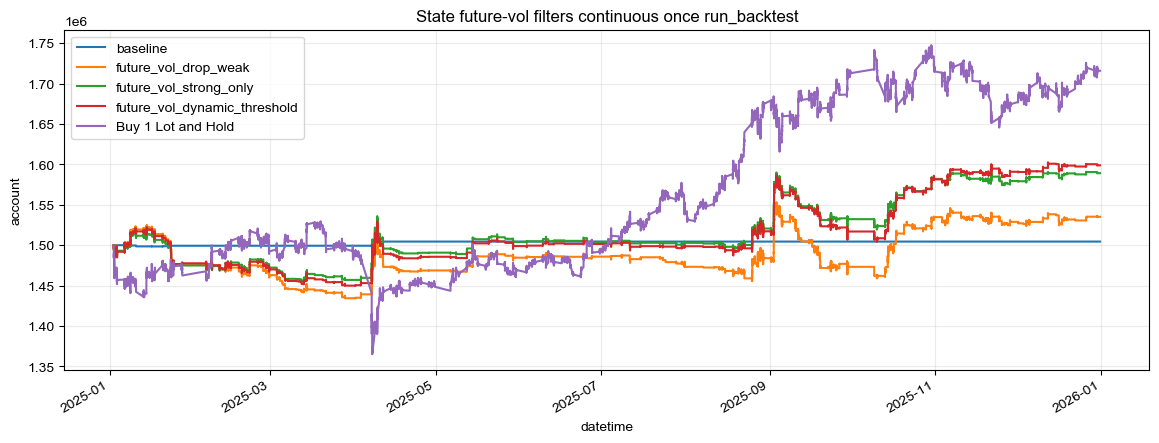

State 未来波动率预测过滤回测输出目录: artifacts/if_alstm_rolling_3state_intra_2025/state_future_vol_predicted_high_filter


In [12]:
# ===== 6.3.2) State 模型：未来波动率预测过滤回测对比 =====
# 运行顺序：先运行 6.1 生成 hard_flat 基准回测，运行 6.3 生成 highvol_highvolume_only，再运行 6.3.1 生成 future vol 预测。
# 本单元只比较开仓过滤/动态阈值，不使用离场增强；平仓、反手先平仓和强制平仓始终允许。
import importlib
import engine.backtest.regime_filter as regime_filter_backtest_module
importlib.reload(regime_filter_backtest_module)
from engine.backtest.regime_filter import RegimeFilterConfig, prepare_causal_regimes, run_regime_filtered_state_backtest, build_regime_filtered_state_target_lots

future_vol_filter_horizon = 5
future_vol_filter_open_prob_threshold = 0.55  # 强环境：pred_state=high 且 prob_vol_high >= 0.55
future_vol_filter_weak_prob_threshold = 0.45  # 弱环境：pred_state=low 或 prob_vol_high < 0.45

future_vol_filter_base_config = RegimeFilterConfig(
    vol_window=30,
    volume_history_days=20,
    base_prob_threshold=0.38,
    base_min_margin=0.02,
    weak_prob_threshold=0.45,
    weak_min_margin=0.03,
    # 关闭离场增强：这些参数设置成不可触发。
    weak_trailing_stop_pct=999.0,
    weak_trailing_activation_pct=999.0,
    weak_exit_min_direction_margin=-999.0,
    weak_no_profit_exit_bars=10**9,
    weak_rule="bad_combo",
    future_vol_prob_col="prob_vol_high",
    future_vol_state_col="pred_vol_state_name",
    future_vol_open_prob_threshold=future_vol_filter_open_prob_threshold,
    future_vol_weak_prob_threshold=future_vol_filter_weak_prob_threshold,
    future_vol_high_state="high",
    future_vol_low_state="low",
)
future_vol_filter_configs = {
    # 弱环境直接过滤：low 或 prob<0.45 不开仓；其余环境正常阈值。
    "future_vol_drop_weak": replace(
        future_vol_filter_base_config,
        allow_open_rule="not_predicted_weak_vol",
        use_future_vol_as_weak=False,
    ),
    # 只在强环境交易：high 且 prob>=0.55 才开仓；正常阈值。
    "future_vol_strong_only": replace(
        future_vol_filter_base_config,
        allow_open_rule="predicted_high_vol",
        use_future_vol_as_weak=False,
    ),
    # 动态阈值：弱环境过滤；中间环境用高阈值；强环境用正常阈值。
    "future_vol_dynamic_threshold": replace(
        future_vol_filter_base_config,
        allow_open_rule="not_predicted_weak_vol",
        use_future_vol_as_weak=True,
        future_vol_weak_mode="mid",
    ),
}
future_vol_filter_baseline_config_name = "hard_flat"
future_vol_filter_output_root = artifact_root / "state_future_vol_predicted_high_filter"
future_vol_filter_output_root.mkdir(parents=True, exist_ok=True)
future_vol_prediction_root = artifact_root / "future_realized_vol_lgbm_state"

_param_rows = globals().get("active_param_rows", pd.DataFrame([get_active_backtest_params()])).copy()
if "config_name" in _param_rows.columns and (_param_rows["config_name"].astype(str) == future_vol_filter_baseline_config_name).any():
    future_vol_filter_params = _param_rows[_param_rows["config_name"].astype(str) == future_vol_filter_baseline_config_name].iloc[0].to_dict()
else:
    future_vol_filter_params = _param_rows.iloc[0].to_dict()
future_vol_filter_rule = make_backtest_rule_from_params(future_vol_filter_params)
future_vol_filter_account = float(future_vol_filter_params.get("account", account))

future_vol_filter_rows = []
future_vol_filter_errors = []
future_vol_filter_curves = {"baseline": [], "highvol_highvolume_only": []}
for strategy_name in future_vol_filter_configs:
    future_vol_filter_curves[strategy_name] = []
future_vol_filter_target_lots_parts = {name: [] for name in future_vol_filter_curves}

for _, window_row in tqdm(windows_df.iterrows(), total=len(windows_df), desc="future vol filter backtest"):
    window = window_row.to_dict()
    window_id = str(window["window_id"])
    out_dir = future_vol_filter_output_root / window_id
    out_dir.mkdir(parents=True, exist_ok=True)
    try:
        state_prob, _ = _load_window_state_prediction(window_id)
        if state_prob is None or state_prob.empty:
            raise FileNotFoundError(f"{window_id} 缺少 state probability")

        future_vol_pred_path = future_vol_prediction_root / f"h{future_vol_filter_horizon}" / window_id / "future_vol_predictions.csv"
        if not future_vol_pred_path.exists():
            raise FileNotFoundError(f"请先运行 6.3.1，缺少未来波动率预测: {future_vol_pred_path}")
        future_vol_pred = pd.read_csv(future_vol_pred_path, parse_dates=["datetime"])
        future_vol_pred = future_vol_pred[["datetime", "pred_future_vol", "pred_vol_state_name", "prob_vol_high"]].copy()

        market = rollsafe_feature_frame.copy()
        market["datetime"] = pd.to_datetime(market["datetime"], errors="coerce")
        history_start = pd.Timestamp(window["valid_start"]) - pd.Timedelta(days=60)
        period_end = _rolling_period_end(window["end_time"])
        market = market[(market["datetime"] >= history_start) & (market["datetime"] <= period_end)].copy()
        price_col = next((c for c in [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close"] if c in market.columns), None)
        volume_col = next((c for c in [f"{target_instrument}_volume", "volume"] if c in market.columns), None)
        if price_col is None or volume_col is None:
            raise KeyError("rollsafe_feature_frame 缺少价格或成交量列")

        causal_regimes, boundaries = prepare_causal_regimes(
            market,
            price_col=price_col,
            volume_col=volume_col,
            valid_start=window["valid_start"],
            valid_end=window["valid_end"],
            config=future_vol_filter_base_config,
        )
        causal_regimes = causal_regimes.join(future_vol_pred.set_index("datetime"), how="left")

        baseline_path = artifact_root / window_id / "rerun_backtest" / future_vol_filter_baseline_config_name / "account_curve.csv"
        if not baseline_path.exists():
            raise FileNotFoundError(f"请先运行 6.1，缺少基准账户曲线: {baseline_path}")
        baseline_report = pd.read_csv(baseline_path, index_col=0, parse_dates=True)
        baseline_metrics = account_metrics(baseline_report["account"], future_vol_filter_account)
        baseline_trade_count = int(pd.to_numeric(baseline_report["position_lots"], errors="coerce").diff().fillna(0).ne(0).sum()) if "position_lots" in baseline_report.columns else np.nan
        future_vol_filter_rows.append({
            **window,
            "strategy": "baseline",
            **baseline_metrics,
            "trade_count": baseline_trade_count,
            "weak_open_filtered_count": 0,
            "weak_trailing_exit_count": 0,
            "weak_prob_decay_exit_count": 0,
            "weak_no_profit_exit_count": 0,
            "allow_open_rule": "baseline",
            "future_vol_weak_mode": "baseline",
            "future_vol_horizon": np.nan,
            "future_vol_open_prob_threshold": np.nan,
            "future_vol_weak_prob_threshold": np.nan,
        })
        future_vol_filter_curves["baseline"].append(baseline_report[["account"]])
        if "position_lots" in baseline_report.columns:
            future_vol_filter_target_lots_parts["baseline"].append(baseline_report["position_lots"].rename("baseline"))

        highvol_compare_path = artifact_root / "state_highvol_highvolume_only_filter" / window_id / "highvol_highvolume_only_account_curve.csv"
        if highvol_compare_path.exists():
            highvol_compare_report = pd.read_csv(highvol_compare_path, index_col=0, parse_dates=True)
            highvol_compare_metrics = account_metrics(highvol_compare_report["account"], future_vol_filter_account)
            highvol_compare_trade_count = int(pd.to_numeric(highvol_compare_report.get("position_lots"), errors="coerce").diff().fillna(0).ne(0).sum()) if "position_lots" in highvol_compare_report.columns else np.nan
            future_vol_filter_rows.append({
                **window,
                "strategy": "highvol_highvolume_only",
                **highvol_compare_metrics,
                "trade_count": highvol_compare_trade_count,
                "weak_open_filtered_count": np.nan,
                "weak_trailing_exit_count": np.nan,
                "weak_prob_decay_exit_count": np.nan,
                "weak_no_profit_exit_count": np.nan,
                "allow_open_rule": "high_vol_and_high_volume",
                "future_vol_weak_mode": np.nan,
                "future_vol_horizon": np.nan,
                "future_vol_open_prob_threshold": np.nan,
                "future_vol_weak_prob_threshold": np.nan,
            })
            future_vol_filter_curves["highvol_highvolume_only"].append(highvol_compare_report[["account"]])
        else:
            print(f"{window_id}: 未找到 6.3 highvol_highvolume_only 曲线，跳过同图对比: {highvol_compare_path}")

        for strategy_name, cfg in future_vol_filter_configs.items():
            filtered_report, metadata = run_regime_filtered_state_backtest(
                state_prob=state_prob,
                market_regimes=causal_regimes,
                test_start=window["test_start"],
                test_end=window["end_time"],
                account=future_vol_filter_account,
                strategy_rule=future_vol_filter_rule,
                config=cfg,
            )
            filtered_metrics = account_metrics(filtered_report["account"], future_vol_filter_account)
            future_vol_filter_rows.append({
                **window,
                "strategy": strategy_name,
                **filtered_metrics,
                "trade_count": int(metadata["trade_count"]),
                "weak_open_filtered_count": int(metadata["weak_open_filtered_count"]),
                "weak_trailing_exit_count": int(metadata["weak_trailing_exit_count"]),
                "weak_prob_decay_exit_count": int(metadata.get("weak_prob_decay_exit_count", 0)),
                "weak_no_profit_exit_count": int(metadata.get("weak_no_profit_exit_count", 0)),
                "allow_open_rule": cfg.allow_open_rule,
                "future_vol_weak_mode": cfg.future_vol_weak_mode if cfg.use_future_vol_as_weak else "none",
                "future_vol_horizon": future_vol_filter_horizon,
                "future_vol_open_prob_threshold": future_vol_filter_open_prob_threshold,
                "future_vol_weak_prob_threshold": future_vol_filter_weak_prob_threshold,
            })
            filtered_report.to_csv(out_dir / f"{strategy_name}_account_curve.csv", encoding="utf-8-sig")
            future_vol_filter_curves[strategy_name].append(filtered_report[["account"]])
            filtered_target_lots, _, _ = build_regime_filtered_state_target_lots(
                state_prob=state_prob,
                market_regimes=causal_regimes,
                test_start=window["test_start"],
                test_end=window["end_time"],
                strategy_rule=future_vol_filter_rule,
                config=cfg,
            )
            future_vol_filter_target_lots_parts[strategy_name].append(filtered_target_lots.rename(strategy_name))
            print(
                f"{window_id} {strategy_name}: PnL={filtered_metrics['absolute_pnl']:.2f}, "
                f"filtered opens={metadata['weak_open_filtered_count']}, "
                f"trailing exits={metadata['weak_trailing_exit_count']}"
            )
        pd.DataFrame({k: pd.Series(v) for k, v in boundaries.items()}).to_csv(out_dir / "valid_regime_boundaries.csv", index=False, encoding="utf-8-sig")
    except Exception as exc:
        future_vol_filter_errors.append({**window, "error": repr(exc)})
        print("Future vol 过滤回测失败:", window_id, repr(exc))

future_vol_filter_window_summary = pd.DataFrame(future_vol_filter_rows)
future_vol_filter_errors_df = pd.DataFrame(future_vol_filter_errors)
future_vol_filter_window_summary.to_csv(future_vol_filter_output_root / "window_comparison.csv", index=False, encoding="utf-8-sig")
future_vol_filter_errors_df.to_csv(future_vol_filter_output_root / "errors.csv", index=False, encoding="utf-8-sig")

if not future_vol_filter_window_summary.empty:
    metric_view = future_vol_filter_window_summary[[
        "window_id", "strategy", "absolute_pnl", "total_return", "annualized_sharpe", "max_drawdown",
        "trade_count", "weak_open_filtered_count", "weak_trailing_exit_count",
        "weak_prob_decay_exit_count", "weak_no_profit_exit_count", "allow_open_rule", "future_vol_weak_mode",
        "future_vol_open_prob_threshold", "future_vol_weak_prob_threshold",
    ]].copy()
    display(metric_view)
    _wide = metric_view.pivot(index="window_id", columns="strategy", values=["absolute_pnl", "annualized_sharpe", "max_drawdown", "trade_count"])
    future_vol_filter_delta = pd.DataFrame(index=_wide.index)
    for metric in ["absolute_pnl", "annualized_sharpe", "max_drawdown", "trade_count"]:
        for strategy_name in ["highvol_highvolume_only", *future_vol_filter_configs.keys()]:
            if (metric, strategy_name) in _wide.columns and (metric, "baseline") in _wide.columns:
                future_vol_filter_delta[f"{strategy_name}_minus_baseline_{metric}"] = _wide[(metric, strategy_name)] - _wide[(metric, "baseline")]
        if (metric, "highvol_highvolume_only") in _wide.columns:
            for strategy_name in future_vol_filter_configs:
                if (metric, strategy_name) in _wide.columns:
                    future_vol_filter_delta[f"{strategy_name}_minus_highvol_only_{metric}"] = _wide[(metric, strategy_name)] - _wide[(metric, "highvol_highvolume_only")]
    future_vol_filter_delta.to_csv(future_vol_filter_output_root / "window_delta_vs_baseline.csv", encoding="utf-8-sig")
    display(future_vol_filter_delta)

    continuous_output_root = future_vol_filter_output_root / "continuous_once_run_backtest"
    try:
        future_vol_filter_curve_df, future_vol_filter_total_summary = run_continuous_backtest_from_parts(
            parts_by_strategy=future_vol_filter_target_lots_parts,
            rule=future_vol_filter_rule,
            account_value=future_vol_filter_account,
            output_root=continuous_output_root,
            mode="target_lots",
        )
        try:
            buy_one_lot_curve_cmp = buy_one_lot_curve(rolling_test_start, rolling_test_end, future_vol_filter_account)
            future_vol_filter_curve_df["Buy 1 Lot and Hold"] = buy_one_lot_curve_cmp.reindex(future_vol_filter_curve_df.index).ffill()
            future_vol_filter_total_summary = pd.concat([
                future_vol_filter_total_summary,
                pd.DataFrame([{
                    "strategy": "Buy 1 Lot and Hold",
                    **account_metrics(buy_one_lot_curve_cmp, future_vol_filter_account),
                    "trade_count": 1,
                }]),
            ], ignore_index=True)
        except Exception as exc:
            print("Buy 1 Lot benchmark 生成失败:", repr(exc))
        future_vol_filter_curve_df.to_csv(future_vol_filter_output_root / "continuous_account_curves.csv", encoding="utf-8-sig")
        future_vol_filter_total_summary.to_csv(future_vol_filter_output_root / "total_comparison.csv", index=False, encoding="utf-8-sig")
        display(future_vol_filter_total_summary)
        plot_cols = [
            "baseline",
            "highvol_highvolume_only",
            "future_vol_drop_weak",
            "future_vol_strong_only",
            "future_vol_dynamic_threshold",
            "Buy 1 Lot and Hold",
        ]
        plot_cols = [c for c in plot_cols if c in future_vol_filter_curve_df.columns]
        ax = future_vol_filter_curve_df[plot_cols].plot(figsize=(14, 5), title="State future-vol filters continuous once run_backtest")
        ax.set_ylabel("account")
        ax.grid(alpha=0.25)
        plt.show()
    except Exception as exc:
        print("连续合并信号回测失败:", repr(exc))

if not future_vol_filter_errors_df.empty:
    display(future_vol_filter_errors_df)
print("State 未来波动率预测过滤回测输出目录:", future_vol_filter_output_root)


future vol filter backtest:   0%|          | 0/4 [00:00<?, ?it/s]

2025-01 future_vol_drop_weak: PnL=-65698.73, filtered opens=1455, trailing exits=0
2025-01 future_vol_strong_only: PnL=-42993.17, filtered opens=1863, trailing exits=0
2025-01 future_vol_dynamic_threshold: PnL=-50071.23, filtered opens=1665, trailing exits=0
2025-04 future_vol_drop_weak: PnL=51530.23, filtered opens=907, trailing exits=0
2025-04 future_vol_strong_only: PnL=47033.47, filtered opens=1082, trailing exits=0
2025-04 future_vol_dynamic_threshold: PnL=51564.75, filtered opens=965, trailing exits=0
2025-07 future_vol_drop_weak: PnL=-12626.99, filtered opens=1044, trailing exits=0
2025-07 future_vol_strong_only: PnL=28147.54, filtered opens=1473, trailing exits=0
2025-07 future_vol_dynamic_threshold: PnL=15424.09, filtered opens=1435, trailing exits=0
2025-10 future_vol_drop_weak: PnL=61889.48, filtered opens=2731, trailing exits=0
2025-10 future_vol_strong_only: PnL=56943.12, filtered opens=3345, trailing exits=0
2025-10 future_vol_dynamic_threshold: PnL=81919.24, filtered ope

,window_id,strategy,absolute_pnl,total_return,annualized_sharpe,max_drawdown,trade_count,weak_open_filtered_count,weak_trailing_exit_count,weak_prob_decay_exit_count,weak_no_profit_exit_count,allow_open_rule,future_vol_weak_mode,future_vol_open_prob_threshold,future_vol_weak_prob_threshold
0,2025-01,baseline,-4991.548975,-0.003328,-3.745603,-0.003888,10,0,0,0,0,baseline,baseline,NaN,NaN
1,2025-01,highvol_highvolume_only,7935.091128,0.005290,0.761055,-0.020552,397,3348,0,0,0,high_vol_and_high_volume,none,NaN,NaN
2,2025-01,future_vol_drop_weak,-65698.732529,-0.043799,-3.803399,-0.059535,1731,1455,0,0,0,not_predicted_weak_vol,none,0.55,0.45
3,2025-01,future_vol_strong_only,-42993.174595,-0.028662,-2.577778,-0.040802,1408,1863,0,0,0,predicted_high_vol,none,0.55,0.45
4,2025-01,future_vol_dynamic_threshold,-50071.233237,-0.033381,-2.959242,-0.047607,1530,1665,0,0,0,not_predicted_weak_vol,mid,0.55,0.45
5,2025-04,baseline,-2369.562070,-0.001580,-0.594165,-0.005133,20,0,0,0,0,baseline,baseline,NaN,NaN
6,2025-04,highvol_highvolume_only,42619.922388,0.028413,2.951792,-0.015801,181,1555,0,0,0,high_vol_and_high_volume,none,NaN,NaN
7,2025-04,future_vol_drop_weak,51530.230898,0.034353,3.073089,-0.031364,508,907,0,0,0,not_predicted_weak_vol,none,0.55,0.45
8,2025-04,future_vol_strong_only,47033.467017,0.031356,2.867425,-0.029789,418,1082,0,0,0,predicted_high_vol,none,0.55,0.45
9,2025-04,future_vol_dynamic_threshold,51564.753325,0.034377,3.108083,-0.030147,453,965,0,0,0,not_predicted_weak_vol,mid,0.55,0.45


,highvol_highvolume_only_minus_baseline_absolute_pnl,future_vol_drop_weak_minus_baseline_absolute_pnl,future_vol_strong_only_minus_baseline_absolute_pnl,future_vol_dynamic_threshold_minus_baseline_absolute_pnl,future_vol_drop_weak_minus_highvol_only_absolute_pnl,future_vol_strong_only_minus_highvol_only_absolute_pnl,future_vol_dynamic_threshold_minus_highvol_only_absolute_pnl,highvol_highvolume_only_minus_baseline_annualized_sharpe,future_vol_drop_weak_minus_baseline_annualized_sharpe,future_vol_strong_only_minus_baseline_annualized_sharpe,future_vol_dynamic_threshold_minus_baseline_annualized_sharpe,future_vol_drop_weak_minus_highvol_only_annualized_sharpe,future_vol_strong_only_minus_highvol_only_annualized_sharpe,future_vol_dynamic_threshold_minus_highvol_only_annualized_sharpe,highvol_highvolume_only_minus_baseline_max_drawdown,future_vol_drop_weak_minus_baseline_max_drawdown,future_vol_strong_only_minus_baseline_max_drawdown,future_vol_dynamic_threshold_minus_baseline_max_drawdown,future_vol_drop_weak_minus_highvol_only_max_drawdown,future_vol_strong_only_minus_highvol_only_max_drawdown,future_vol_dynamic_threshold_minus_highvol_only_max_drawdown,highvol_highvolume_only_minus_baseline_trade_count,future_vol_drop_weak_minus_baseline_trade_count,future_vol_strong_only_minus_baseline_trade_count,future_vol_dynamic_threshold_minus_baseline_trade_count,future_vol_drop_weak_minus_highvol_only_trade_count,future_vol_strong_only_minus_highvol_only_trade_count,future_vol_dynamic_threshold_minus_highvol_only_trade_count
window_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-01,12926.640103,-60707.183555,-38001.625620,-45079.684263,-73633.823657,-50928.265723,-58006.324365,4.506658,-0.057795,1.167825,0.786361,-4.564453,-3.338833,-3.720297,-0.016664,-0.055648,-0.036915,-0.043720,-0.038984,-0.020251,-0.027056,387.0,1721.0,1398.0,1520.0,1334.0,1011.0,1133.0
2025-04,44989.484458,53899.792969,49403.029087,53934.315396,8910.308511,4413.544629,8944.830937,3.545958,3.667254,3.461591,3.702249,0.121296,-0.084367,0.156291,-0.010668,-0.026232,-0.024657,-0.025015,-0.015564,-0.013989,-0.014347,161.0,488.0,398.0,433.0,327.0,237.0,272.0
2025-07,-25660.735620,-12626.988662,28147.544048,15424.089097,13033.746958,53808.279668,41084.824717,NaN,NaN,NaN,NaN,0.584827,2.172902,1.667638,-0.043766,-0.057179,-0.043025,-0.050513,-0.013413,0.000742,-0.006747,1039.0,1175.0,989.0,999.0,136.0,-50.0,-40.0
2025-10,-5986.475566,61889.478457,56943.122021,81919.236943,67875.954023,62929.597588,87905.712510,NaN,NaN,NaN,NaN,3.981100,4.190015,5.519335,-0.015461,-0.014309,-0.010245,-0.009883,0.001151,0.005216,0.005578,705.0,1118.0,807.0,889.0,413.0,102.0,184.0


,strategy,backtest_mode,trade_count,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown
0,baseline,continuous_once_run_backtest_target_lots,30,58320,1500000.0,1.492639e+06,-7361.111045,-0.004907,-0.003511,-0.863471,-0.007756
1,highvol_highvolume_only,continuous_once_run_backtest_target_lots,2680,58320,1500000.0,1.518908e+06,18907.802329,0.012605,0.001289,0.316913,-0.042406
2,future_vol_drop_weak,continuous_once_run_backtest_target_lots,5354,58320,1500000.0,1.535094e+06,35093.988164,0.023396,0.001870,0.459771,-0.060757
3,future_vol_strong_only,continuous_once_run_backtest_target_lots,4296,58320,1500000.0,1.589131e+06,89130.958491,0.059421,0.004854,1.193771,-0.044479
4,future_vol_dynamic_threshold,continuous_once_run_backtest_target_lots,4562,58320,1500000.0,1.598837e+06,98836.846128,0.065891,0.005252,1.291607,-0.052033
5,Buy 1 Lot and Hold,NaN,1,58080,1500000.0,1.715873e+06,215872.625000,0.143915,0.005590,1.374672,-0.107603


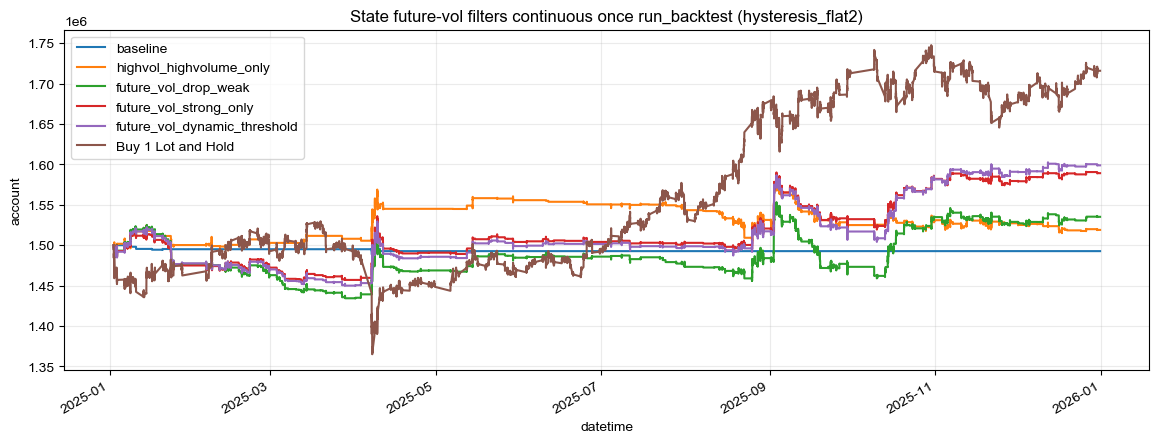

State 未来波动率预测过滤回测输出目录（hysteresis_flat2）: artifacts/if_alstm_rolling_3state_intra_2025/state_future_vol_predicted_high_filter_hysteresis_flat2


In [13]:
# ===== 6.3.2b) State 模型：未来波动率预测过滤回测对比（hysteresis_flat2） =====
# 运行顺序：先运行 6.1 生成 hysteresis_flat2 基准回测，再运行 6.3.1 生成 future vol 预测。
# 本单元只比较开仓过滤/动态阈值，不使用离场增强；平仓、反手先平仓和强制平仓始终允许。
import importlib
import engine.backtest.regime_filter as regime_filter_backtest_module
importlib.reload(regime_filter_backtest_module)
from engine.backtest.regime_filter import RegimeFilterConfig, prepare_causal_regimes, run_regime_filtered_state_backtest, build_regime_filtered_state_target_lots

future_vol_filter_horizon = 5
future_vol_filter_open_prob_threshold = 0.55  # 强环境：pred_state=high 且 prob_vol_high >= 0.55
future_vol_filter_weak_prob_threshold = 0.45  # 弱环境：pred_state=low 或 prob_vol_high < 0.45

future_vol_filter_base_config = RegimeFilterConfig(
    vol_window=30,
    volume_history_days=20,
    base_prob_threshold=0.38,
    base_min_margin=0.02,
    weak_prob_threshold=0.45,
    weak_min_margin=0.03,
    # 关闭离场增强：这些参数设置成不可触发。
    weak_trailing_stop_pct=999.0,
    weak_trailing_activation_pct=999.0,
    weak_exit_min_direction_margin=-999.0,
    weak_no_profit_exit_bars=10**9,
    weak_rule="bad_combo",
    future_vol_prob_col="prob_vol_high",
    future_vol_state_col="pred_vol_state_name",
    future_vol_open_prob_threshold=future_vol_filter_open_prob_threshold,
    future_vol_weak_prob_threshold=future_vol_filter_weak_prob_threshold,
    future_vol_high_state="high",
    future_vol_low_state="low",
)
future_vol_filter_configs = {
    # 弱环境直接过滤：low 或 prob<0.45 不开仓；其余环境正常阈值。
    "future_vol_drop_weak": replace(
        future_vol_filter_base_config,
        allow_open_rule="not_predicted_weak_vol",
        use_future_vol_as_weak=False,
    ),
    # 只在强环境交易：high 且 prob>=0.55 才开仓；正常阈值。
    "future_vol_strong_only": replace(
        future_vol_filter_base_config,
        allow_open_rule="predicted_high_vol",
        use_future_vol_as_weak=False,
    ),
    # 动态阈值：弱环境过滤；中间环境用高阈值；强环境用正常阈值。
    "future_vol_dynamic_threshold": replace(
        future_vol_filter_base_config,
        allow_open_rule="not_predicted_weak_vol",
        use_future_vol_as_weak=True,
        future_vol_weak_mode="mid",
    ),
}
future_vol_filter_baseline_config_name = "hysteresis_flat2"
future_vol_filter_output_root = artifact_root / "state_future_vol_predicted_high_filter_hysteresis_flat2"
future_vol_filter_output_root.mkdir(parents=True, exist_ok=True)
future_vol_prediction_root = artifact_root / "future_realized_vol_lgbm_state"

_param_rows = globals().get("active_param_rows", pd.DataFrame([get_active_backtest_params()])).copy()
if "config_name" in _param_rows.columns and (_param_rows["config_name"].astype(str) == future_vol_filter_baseline_config_name).any():
    future_vol_filter_params = _param_rows[_param_rows["config_name"].astype(str) == future_vol_filter_baseline_config_name].iloc[0].to_dict()
else:
    future_vol_filter_params = _param_rows.iloc[0].to_dict()
future_vol_filter_rule = make_backtest_rule_from_params(future_vol_filter_params)
future_vol_filter_account = float(future_vol_filter_params.get("account", account))

future_vol_filter_rows = []
future_vol_filter_errors = []
future_vol_filter_curves = {"baseline": [], "highvol_highvolume_only": []}
for strategy_name in future_vol_filter_configs:
    future_vol_filter_curves[strategy_name] = []
future_vol_filter_target_lots_parts = {name: [] for name in future_vol_filter_curves}

for _, window_row in tqdm(windows_df.iterrows(), total=len(windows_df), desc="future vol filter backtest"):
    window = window_row.to_dict()
    window_id = str(window["window_id"])
    out_dir = future_vol_filter_output_root / window_id
    out_dir.mkdir(parents=True, exist_ok=True)
    try:
        state_prob, _ = _load_window_state_prediction(window_id)
        if state_prob is None or state_prob.empty:
            raise FileNotFoundError(f"{window_id} 缺少 state probability")

        future_vol_pred_path = future_vol_prediction_root / f"h{future_vol_filter_horizon}" / window_id / "future_vol_predictions.csv"
        if not future_vol_pred_path.exists():
            raise FileNotFoundError(f"请先运行 6.3.1，缺少未来波动率预测: {future_vol_pred_path}")
        future_vol_pred = pd.read_csv(future_vol_pred_path, parse_dates=["datetime"])
        future_vol_pred = future_vol_pred[["datetime", "pred_future_vol", "pred_vol_state_name", "prob_vol_high"]].copy()

        market = rollsafe_feature_frame.copy()
        market["datetime"] = pd.to_datetime(market["datetime"], errors="coerce")
        history_start = pd.Timestamp(window["valid_start"]) - pd.Timedelta(days=60)
        period_end = _rolling_period_end(window["end_time"])
        market = market[(market["datetime"] >= history_start) & (market["datetime"] <= period_end)].copy()
        price_col = next((c for c in [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close"] if c in market.columns), None)
        volume_col = next((c for c in [f"{target_instrument}_volume", "volume"] if c in market.columns), None)
        if price_col is None or volume_col is None:
            raise KeyError("rollsafe_feature_frame 缺少价格或成交量列")

        causal_regimes, boundaries = prepare_causal_regimes(
            market,
            price_col=price_col,
            volume_col=volume_col,
            valid_start=window["valid_start"],
            valid_end=window["valid_end"],
            config=future_vol_filter_base_config,
        )
        causal_regimes = causal_regimes.join(future_vol_pred.set_index("datetime"), how="left")

        baseline_path = artifact_root / window_id / "rerun_backtest" / future_vol_filter_baseline_config_name / "account_curve.csv"
        if not baseline_path.exists():
            raise FileNotFoundError(f"请先运行 6.1，缺少基准账户曲线: {baseline_path}")
        baseline_report = pd.read_csv(baseline_path, index_col=0, parse_dates=True)
        baseline_metrics = account_metrics(baseline_report["account"], future_vol_filter_account)
        baseline_trade_count = int(pd.to_numeric(baseline_report["position_lots"], errors="coerce").diff().fillna(0).ne(0).sum()) if "position_lots" in baseline_report.columns else np.nan
        future_vol_filter_rows.append({
            **window,
            "strategy": "baseline",
            **baseline_metrics,
            "trade_count": baseline_trade_count,
            "weak_open_filtered_count": 0,
            "weak_trailing_exit_count": 0,
            "weak_prob_decay_exit_count": 0,
            "weak_no_profit_exit_count": 0,
            "allow_open_rule": "baseline",
            "future_vol_weak_mode": "baseline",
            "future_vol_horizon": np.nan,
            "future_vol_open_prob_threshold": np.nan,
            "future_vol_weak_prob_threshold": np.nan,
        })
        future_vol_filter_curves["baseline"].append(baseline_report[["account"]])
        if "position_lots" in baseline_report.columns:
            future_vol_filter_target_lots_parts["baseline"].append(baseline_report["position_lots"].rename("baseline"))

        # 使用 hysteresis_flat2 的交易规则现场重算 high-vol + high-volume 对比线，避免混用 hard_flat 结果。
        highvol_compare_cfg = replace(
            future_vol_filter_base_config,
            allow_open_rule="high_vol_and_high_volume",
            use_future_vol_as_weak=False,
        )
        highvol_compare_report, highvol_metadata = run_regime_filtered_state_backtest(
            state_prob=state_prob,
            market_regimes=causal_regimes,
            test_start=window["test_start"],
            test_end=window["end_time"],
            account=future_vol_filter_account,
            strategy_rule=future_vol_filter_rule,
            config=highvol_compare_cfg,
        )
        highvol_compare_metrics = account_metrics(highvol_compare_report["account"], future_vol_filter_account)
        future_vol_filter_rows.append({
            **window,
            "strategy": "highvol_highvolume_only",
            **highvol_compare_metrics,
            "trade_count": int(highvol_metadata["trade_count"]),
            "weak_open_filtered_count": int(highvol_metadata["weak_open_filtered_count"]),
            "weak_trailing_exit_count": int(highvol_metadata["weak_trailing_exit_count"]),
            "weak_prob_decay_exit_count": int(highvol_metadata.get("weak_prob_decay_exit_count", 0)),
            "weak_no_profit_exit_count": int(highvol_metadata.get("weak_no_profit_exit_count", 0)),
            "allow_open_rule": "high_vol_and_high_volume",
            "future_vol_weak_mode": "none",
            "future_vol_horizon": np.nan,
            "future_vol_open_prob_threshold": np.nan,
            "future_vol_weak_prob_threshold": np.nan,
        })
        highvol_compare_report.to_csv(out_dir / "highvol_highvolume_only_account_curve.csv", encoding="utf-8-sig")
        future_vol_filter_curves["highvol_highvolume_only"].append(highvol_compare_report[["account"]])
        highvol_target_lots, _, _ = build_regime_filtered_state_target_lots(
            state_prob=state_prob,
            market_regimes=causal_regimes,
            test_start=window["test_start"],
            test_end=window["end_time"],
            strategy_rule=future_vol_filter_rule,
            config=highvol_compare_cfg,
        )
        future_vol_filter_target_lots_parts["highvol_highvolume_only"].append(highvol_target_lots.rename("highvol_highvolume_only"))

        for strategy_name, cfg in future_vol_filter_configs.items():
            filtered_report, metadata = run_regime_filtered_state_backtest(
                state_prob=state_prob,
                market_regimes=causal_regimes,
                test_start=window["test_start"],
                test_end=window["end_time"],
                account=future_vol_filter_account,
                strategy_rule=future_vol_filter_rule,
                config=cfg,
            )
            filtered_metrics = account_metrics(filtered_report["account"], future_vol_filter_account)
            future_vol_filter_rows.append({
                **window,
                "strategy": strategy_name,
                **filtered_metrics,
                "trade_count": int(metadata["trade_count"]),
                "weak_open_filtered_count": int(metadata["weak_open_filtered_count"]),
                "weak_trailing_exit_count": int(metadata["weak_trailing_exit_count"]),
                "weak_prob_decay_exit_count": int(metadata.get("weak_prob_decay_exit_count", 0)),
                "weak_no_profit_exit_count": int(metadata.get("weak_no_profit_exit_count", 0)),
                "allow_open_rule": cfg.allow_open_rule,
                "future_vol_weak_mode": cfg.future_vol_weak_mode if cfg.use_future_vol_as_weak else "none",
                "future_vol_horizon": future_vol_filter_horizon,
                "future_vol_open_prob_threshold": future_vol_filter_open_prob_threshold,
                "future_vol_weak_prob_threshold": future_vol_filter_weak_prob_threshold,
            })
            filtered_report.to_csv(out_dir / f"{strategy_name}_account_curve.csv", encoding="utf-8-sig")
            future_vol_filter_curves[strategy_name].append(filtered_report[["account"]])
            filtered_target_lots, _, _ = build_regime_filtered_state_target_lots(
                state_prob=state_prob,
                market_regimes=causal_regimes,
                test_start=window["test_start"],
                test_end=window["end_time"],
                strategy_rule=future_vol_filter_rule,
                config=cfg,
            )
            future_vol_filter_target_lots_parts[strategy_name].append(filtered_target_lots.rename(strategy_name))
            print(
                f"{window_id} {strategy_name}: PnL={filtered_metrics['absolute_pnl']:.2f}, "
                f"filtered opens={metadata['weak_open_filtered_count']}, "
                f"trailing exits={metadata['weak_trailing_exit_count']}"
            )
        pd.DataFrame({k: pd.Series(v) for k, v in boundaries.items()}).to_csv(out_dir / "valid_regime_boundaries.csv", index=False, encoding="utf-8-sig")
    except Exception as exc:
        future_vol_filter_errors.append({**window, "error": repr(exc)})
        print("Future vol 过滤回测失败:", window_id, repr(exc))

future_vol_filter_window_summary = pd.DataFrame(future_vol_filter_rows)
future_vol_filter_errors_df = pd.DataFrame(future_vol_filter_errors)
future_vol_filter_window_summary.to_csv(future_vol_filter_output_root / "window_comparison.csv", index=False, encoding="utf-8-sig")
future_vol_filter_errors_df.to_csv(future_vol_filter_output_root / "errors.csv", index=False, encoding="utf-8-sig")

if not future_vol_filter_window_summary.empty:
    metric_view = future_vol_filter_window_summary[[
        "window_id", "strategy", "absolute_pnl", "total_return", "annualized_sharpe", "max_drawdown",
        "trade_count", "weak_open_filtered_count", "weak_trailing_exit_count",
        "weak_prob_decay_exit_count", "weak_no_profit_exit_count", "allow_open_rule", "future_vol_weak_mode",
        "future_vol_open_prob_threshold", "future_vol_weak_prob_threshold",
    ]].copy()
    display(metric_view)
    _wide = metric_view.pivot(index="window_id", columns="strategy", values=["absolute_pnl", "annualized_sharpe", "max_drawdown", "trade_count"])
    future_vol_filter_delta = pd.DataFrame(index=_wide.index)
    for metric in ["absolute_pnl", "annualized_sharpe", "max_drawdown", "trade_count"]:
        for strategy_name in ["highvol_highvolume_only", *future_vol_filter_configs.keys()]:
            if (metric, strategy_name) in _wide.columns and (metric, "baseline") in _wide.columns:
                future_vol_filter_delta[f"{strategy_name}_minus_baseline_{metric}"] = _wide[(metric, strategy_name)] - _wide[(metric, "baseline")]
        if (metric, "highvol_highvolume_only") in _wide.columns:
            for strategy_name in future_vol_filter_configs:
                if (metric, strategy_name) in _wide.columns:
                    future_vol_filter_delta[f"{strategy_name}_minus_highvol_only_{metric}"] = _wide[(metric, strategy_name)] - _wide[(metric, "highvol_highvolume_only")]
    future_vol_filter_delta.to_csv(future_vol_filter_output_root / "window_delta_vs_baseline.csv", encoding="utf-8-sig")
    display(future_vol_filter_delta)

    continuous_output_root = future_vol_filter_output_root / "continuous_once_run_backtest"
    try:
        future_vol_filter_curve_df, future_vol_filter_total_summary = run_continuous_backtest_from_parts(
            parts_by_strategy=future_vol_filter_target_lots_parts,
            rule=future_vol_filter_rule,
            account_value=future_vol_filter_account,
            output_root=continuous_output_root,
            mode="target_lots",
        )
        try:
            buy_one_lot_curve_cmp = buy_one_lot_curve(rolling_test_start, rolling_test_end, future_vol_filter_account)
            future_vol_filter_curve_df["Buy 1 Lot and Hold"] = buy_one_lot_curve_cmp.reindex(future_vol_filter_curve_df.index).ffill()
            future_vol_filter_total_summary = pd.concat([
                future_vol_filter_total_summary,
                pd.DataFrame([{
                    "strategy": "Buy 1 Lot and Hold",
                    **account_metrics(buy_one_lot_curve_cmp, future_vol_filter_account),
                    "trade_count": 1,
                }]),
            ], ignore_index=True)
        except Exception as exc:
            print("Buy 1 Lot benchmark 生成失败:", repr(exc))
        future_vol_filter_curve_df.to_csv(future_vol_filter_output_root / "continuous_account_curves.csv", encoding="utf-8-sig")
        future_vol_filter_total_summary.to_csv(future_vol_filter_output_root / "total_comparison.csv", index=False, encoding="utf-8-sig")
        display(future_vol_filter_total_summary)
        plot_cols = [
            "baseline",
            "highvol_highvolume_only",
            "future_vol_drop_weak",
            "future_vol_strong_only",
            "future_vol_dynamic_threshold",
            "Buy 1 Lot and Hold",
        ]
        plot_cols = [c for c in plot_cols if c in future_vol_filter_curve_df.columns]
        ax = future_vol_filter_curve_df[plot_cols].plot(figsize=(14, 5), title="State future-vol filters continuous once run_backtest (hysteresis_flat2)")
        ax.set_ylabel("account")
        ax.grid(alpha=0.25)
        plt.show()
    except Exception as exc:
        print("连续合并信号回测失败:", repr(exc))

if not future_vol_filter_errors_df.empty:
    display(future_vol_filter_errors_df)
print("State 未来波动率预测过滤回测输出目录（hysteresis_flat2）:", future_vol_filter_output_root)


Pv3 ALSTM device: cpu


pv3 trade+direction ALSTM:   0%|          | 0/4 [00:00<?, ?it/s]

[42240:MainThread](2026-07-14 23:27:47,341) INFO - qlib.timer - [log.py:127] - Time cost: 0.021s | Loading data Done
[42240:MainThread](2026-07-14 23:27:47,567) INFO - qlib.timer - [log.py:127] - Time cost: 0.220s | RobustZScoreNorm Done
[42240:MainThread](2026-07-14 23:27:47,607) INFO - qlib.timer - [log.py:127] - Time cost: 0.040s | Fillna Done
[42240:MainThread](2026-07-14 23:27:47,624) INFO - qlib.timer - [log.py:127] - Time cost: 0.001s | LabelInfClip Done
[42240:MainThread](2026-07-14 23:27:47,632) INFO - qlib.timer - [log.py:127] - Time cost: 0.007s | DropnaLabel Done
[42240:MainThread](2026-07-14 23:27:47,633) INFO - qlib.timer - [log.py:127] - Time cost: 0.291s | fit & process data Done
[42240:MainThread](2026-07-14 23:27:47,633) INFO - qlib.timer - [log.py:127] - Time cost: 0.314s | Init data Done
[42240:MainThread](2026-07-14 23:27:47,790) INFO - qlib.timer - [log.py:127] - Time cost: 0.022s | Loading data Done
[42240:MainThread](2026-07-14 23:27:48,010) INFO - qlib.timer - 

ALSTM State Training:   0%|          | 0/24 [00:00<?, ?it/s]

状态分类触发早停：连续 6 轮验证集无提升


...

[42240:MainThread](2026-07-14 23:34:23,414) INFO - qlib.timer - [log.py:127] - Time cost: 0.020s | Loading data Done
[42240:MainThread](2026-07-14 23:34:23,649) INFO - qlib.timer - [log.py:127] - Time cost: 0.230s | RobustZScoreNorm Done
[42240:MainThread](2026-07-14 23:34:23,693) INFO - qlib.timer - [log.py:127] - Time cost: 0.044s | Fillna Done
[42240:MainThread](2026-07-14 23:34:23,710) INFO - qlib.timer - [log.py:127] - Time cost: 0.001s | LabelInfClip Done
[42240:MainThread](2026-07-14 23:34:23,717) INFO - qlib.timer - [log.py:127] - Time cost: 0.006s | DropnaLabel Done
[42240:MainThread](2026-07-14 23:34:23,718) INFO - qlib.timer - [log.py:127] - Time cost: 0.303s | fit & process data Done
[42240:MainThread](2026-07-14 23:34:23,718) INFO - qlib.timer - [log.py:127] - Time cost: 0.324s | Init data Done
[42240:MainThread](2026-07-14 23:34:23,873) INFO - qlib.timer - [log.py:127] - Time cost: 0.020s | Loading data Done
[42240:MainThread](2026-07-14 23:34:24,097) INFO - qlib.timer - 

ALSTM State Training:   0%|          | 0/24 [00:00<?, ?it/s]

状态分类触发早停：连续 6 轮验证集无提升


ALSTM State Training:   0%|          | 0/24 [00:00<?, ?it/s]

状态分类触发早停：连续 6 轮验证集无提升
2025-10 pv3_alstm_thr_0p0005_selected: PnL=5059.20, signals=74, sign_win=0.608, trades=86


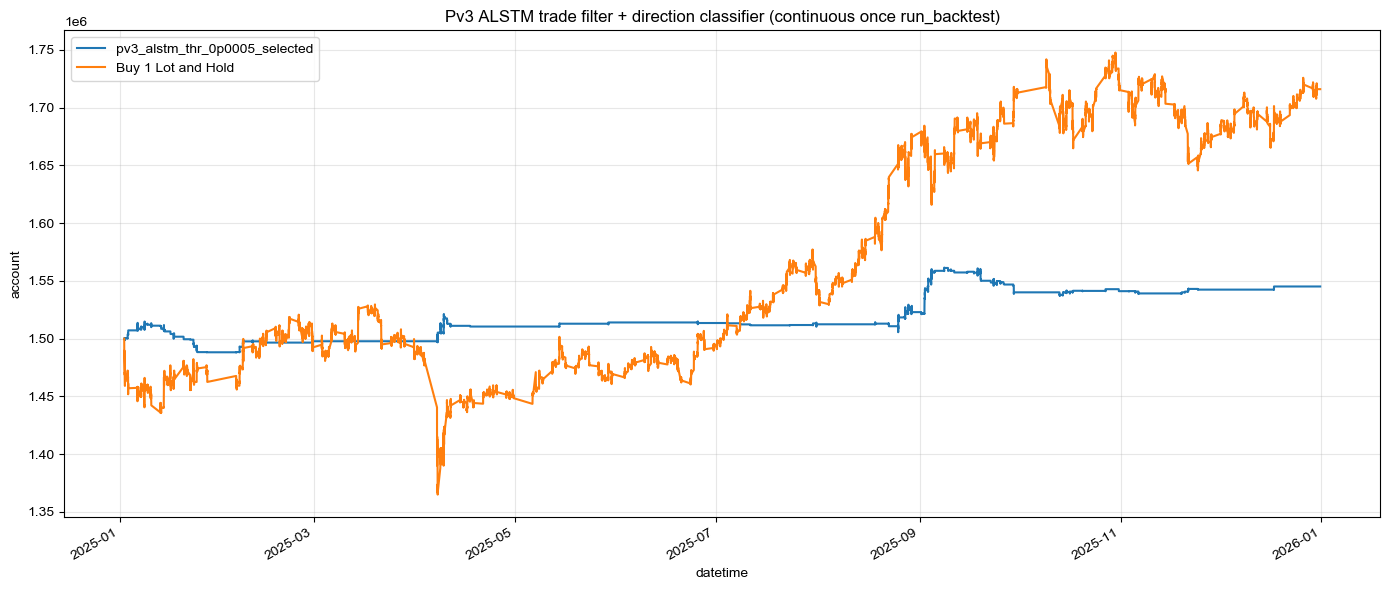

,strategy,backtest_mode,trade_count,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown
0,pv3_alstm_thr_0p0005_selected,continuous_once_run_backtest_signal,1026,58320,1500000.0,1.545108e+06,45107.748208,0.030072,0.005785,1.4227,-0.017721


,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time,strategy,detail_strategy,label_threshold,use_future_vol_filter,trade_prob_threshold,dir_prob_threshold,dir_margin_threshold,dir_logit_center,dir_calibration_method,signal_count,signal_ratio,trade_precision,raw_sign_win_rate,direction_accuracy,signed_return_mean,signed_return_median,long_signal_count,short_signal_count,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown,trade_count,trade_best_epoch,dir_best_epoch,trade_best_valid_loss,dir_best_valid_loss,trade_train_class_counts,dir_train_class_counts,dir_train_scope,dir_loss_weight_mode,direction_balance_pass,dir_loss_train_weight_sum,dir_loss_valid_weight_sum,dir_nonflat_train_weight_sum,dir_nonflat_valid_weight_sum
0,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,pv3_alstm_thr_0p0005_selected,pv3_alstm_thr_0p0005_fv,0.0005,True,0.7,0.6,0.12,-0.12653,supervised_grid,284,0.024150,0.799296,0.542254,0.542254,0.000140,0.000155,209,75,13680,1500000.0,1.497717e+06,-2282.828965,-0.001522,-0.001387,-0.341068,-0.017721,312,6,6,0.615220,0.687984,"22362,28248","26692,23918",all,abs_return,1,49473.695312,27323.353516,28248.0,15507.0
1,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,pv3_alstm_thr_0p0005_selected,pv3_alstm_thr_0p0005_fv,0.0005,True,0.7,0.6,0.12,0.10000,supervised_grid,173,0.013963,0.820809,0.566474,0.566474,0.000437,0.000384,99,74,14400,1500000.0,1.515782e+06,15781.855459,0.010521,0.008284,2.037369,-0.007280,166,4,5,0.619565,0.687510,"22957,27443","26631,23769",all,abs_return,1,49785.433594,27220.621094,27634.0,15834.0
2,2025-07,12,6,3,3,2024-01-01,2024-12-31,2025-01-01,2025-06-30,2025-07-01,2025-09-30,pv3_alstm_thr_0p0005_selected,pv3_alstm_thr_0p0005_fv,0.0005,True,0.7,0.6,0.12,0.10000,supervised_grid,494,0.036190,0.787449,0.564777,0.564777,0.000227,0.000286,7,487,15840,1500000.0,1.526550e+06,26549.518228,0.017700,0.008940,2.198507,-0.014707,462,7,4,0.644180,0.686749,"20974,29636","26643,23967",all,abs_return,1,52028.976562,22887.695312,29779.0,12250.0
3,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,pv3_alstm_thr_0p0005_selected,pv3_alstm_thr_0p0005_fv,0.0005,True,0.7,0.6,0.12,-0.08974,supervised_grid,74,0.005973,0.716216,0.608108,0.608108,0.000392,0.000492,16,58,14400,1500000.0,1.505059e+06,5059.203486,0.003373,0.006344,1.560171,-0.002782,86,11,3,0.632995,0.692638,"21670,28730","26486,23914",all,abs_return,1,51439.203125,25470.828125,28853.0,13616.0


,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time,label_threshold,use_future_vol_filter,trade_prob_threshold,dir_prob_threshold,dir_margin_threshold,dir_logit_center,dir_calibration_method,signal_count,signal_ratio,trade_precision,raw_sign_win_rate,direction_accuracy,signed_return_mean,signed_return_median,long_signal_count,short_signal_count,direction_side_share,direction_long_short_ratio,direction_balance_pass
215,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,0.0005,True,0.70,0.60,0.12,-0.12653,supervised_grid,1781,0.068395,0.828748,0.574396,0.574396,0.000615,0.000480,1063,718,0.403144,1.480501,1
205,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,0.0005,True,0.70,0.60,0.12,-0.10000,supervised_grid,1744,0.066974,0.826835,0.573968,0.573968,0.000599,0.000471,926,818,0.469037,1.132029,1
197,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,0.0005,True,0.65,0.60,0.10,-0.12653,supervised_grid,2723,0.104570,0.789203,0.573632,0.573632,0.000489,0.000353,1472,1251,0.459420,1.176659,1
187,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,0.0005,True,0.65,0.60,0.10,-0.10000,supervised_grid,2699,0.103648,0.788811,0.572434,0.572434,0.000475,0.000351,1283,1416,0.475361,1.103663,1
107,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,0.0005,False,0.70,0.60,0.12,-0.12653,supervised_grid,1797,0.069009,0.821369,0.569282,0.569282,0.000615,0.000480,1064,733,0.407902,1.451569,1
97,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,0.0005,False,0.70,0.60,0.12,-0.10000,supervised_grid,1760,0.067588,0.819318,0.568750,0.568750,0.000599,0.000471,927,833,0.473295,1.112845,1
89,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,0.0005,False,0.65,0.60,0.10,-0.12653,supervised_grid,2752,0.105684,0.780887,0.567587,0.567587,0.000489,0.000353,1474,1278,0.464390,1.153365,1
79,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,0.0005,False,0.65,0.60,0.10,-0.10000,supervised_grid,2728,0.104762,0.780425,0.566349,0.566349,0.000475,0.000351,1285,1443,0.471041,1.122957,1
179,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,0.0005,True,0.65,0.58,0.08,-0.12653,supervised_grid,3808,0.146237,0.790966,0.564338,0.564338,0.000432,0.000308,2051,1757,0.461397,1.167331,1
188,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,0.0005,True,0.65,0.60,0.10,0.00000,supervised_grid,2811,0.107949,0.794023,0.564212,0.564212,0.000423,0.000321,772,2039,0.274635,2.641192,1


In [14]:
# ===== 6.3.4-pre) Pv3 前置：Model A trade_prob 与公共 helper =====
# Model A: trade filter, label_trade = abs(future_return_5m) > 0.0005。
# 注：最终主线 Model B 已合并到下一单元，只保留当前最优 ALSTM3；本单元主要提供 trade_prob/公共 helper。
# 预测时 t 分钟生成信号，shift 到 t+1 分钟执行；future_vol_filter 会参与 valid 阈值搜索。

pv3_output_root = artifact_root / "pv3_two_stage_trade_direction_alstm"
pv3_output_root.mkdir(parents=True, exist_ok=True)

pv3_label_thresholds = [0.0005]
pv3_horizon = int(label_horizon)
pv3_base_lag = int(label_base_lag)
pv3_account = float(account)
pv3_open_cost = 0.0002
pv3_close_cost = 0.0002
pv3_fixed_trade_amount = 1
pv3_trade_interval_minutes = 1
pv3_first_trade_time = intra_first_trade_time
pv3_last_trade_time = intra_last_trade_time
pv3_force_flatten_exec_time = intra_force_flatten_exec_time
pv3_force_flatten_daily = intra_force_flatten_daily
pv3_signal_execution_lag_bars = 1
pv3_use_future_vol_filter = True
pv3_future_vol_horizon = 5
pv3_future_vol_min_high_prob = 0.55
pv3_allow_pred_vol_states = {"mid", "high"}
pv3_min_valid_trades = 20
pv3_dir_train_scope = "all"  # all / nonflat 切换样本，看模型b用什么样本训练
pv3_dir_loss_weight_mode = "abs_return"  # none / abs_return
pv3_dir_loss_weight_scale = 1.0
pv3_dir_loss_weight_power = 1.0
pv3_dir_loss_weight_clip = (0.5, 4.0)
pv3_use_direction_calibration = True
pv3_direction_calibration_mode = "supervised"  # supervised / median / none
pv3_direction_calibration_grid = np.round(np.linspace(-0.8, 0.8, 17), 4).tolist()
pv3_direction_calibration_clip = 2.0
pv3_min_side_signal_count = 30
pv3_min_side_share = 0.18
pv3_max_long_short_ratio = 3.0
pv3_threshold_grid = [
    {"trade_prob_threshold": 0.50, "dir_prob_threshold": 0.52, "dir_margin_threshold": 0.02},
    {"trade_prob_threshold": 0.55, "dir_prob_threshold": 0.54, "dir_margin_threshold": 0.04},
    {"trade_prob_threshold": 0.60, "dir_prob_threshold": 0.56, "dir_margin_threshold": 0.06},
    {"trade_prob_threshold": 0.65, "dir_prob_threshold": 0.58, "dir_margin_threshold": 0.08},
    {"trade_prob_threshold": 0.65, "dir_prob_threshold": 0.60, "dir_margin_threshold": 0.10},
    {"trade_prob_threshold": 0.70, "dir_prob_threshold": 0.60, "dir_margin_threshold": 0.12},
]

pv3_alstm_base_params = dict(alstm_kwargs)
pv3_alstm_base_params.update({
    "n_epochs": min(int(alstm_kwargs.get("n_epochs", 30)), 24),
    "early_stop": min(int(alstm_kwargs.get("early_stop", 8)), 6),
    "batch_size": int(alstm_kwargs.get("batch_size", 128)),
    "state_batch_size": int(alstm_kwargs.get("batch_size", 128)),
    "lr": float(alstm_kwargs.get("lr", 1e-4)),
    "state_lr": float(alstm_kwargs.get("lr", 1e-4)),
    "GPU": alstm_model_module.get_cuda_gpu_id(),
})
pv3_trade_model_params = dict(pv3_alstm_base_params)
pv3_trade_model_params.update({
    "state_num_classes": 2,
    "state_class_names": {0: "no_trade", 1: "trade"},
    "state_class_weight_mode": "sqrt_balanced",
    "state_class_weight_clip": (0.5, 3.0),
    "state_loss": "cross_entropy",
    "state_selection_metric": "valid_loss",
    "seed": 42,
})
pv3_dir_model_params = dict(pv3_alstm_base_params)
pv3_dir_model_params.update({
    "state_num_classes": 2,
    "state_class_names": {0: "dir_down", 1: "dir_up"},
    # all 模式下用 sqrt_balanced 防止方向类别偏置；nonflat 模式会用 sample_weight 只训练可交易样本。
    "state_class_weight_mode": "sqrt_balanced",
    "state_class_weight_clip": (0.5, 3.0),
    "state_loss": "cross_entropy",
    "state_selection_metric": "valid_loss",
    "seed": 43,
})
print("Pv3 ALSTM device:", alstm_model_module.describe_torch_device(int(pv3_alstm_base_params.get("GPU", -1))))


def _pv3_period_end(value) -> pd.Timestamp:
    end = pd.Timestamp(value)
    return end + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1) if end == end.normalize() else end


def _pv3_make_feature_label_frame(window: dict, threshold: float) -> pd.DataFrame:
    start = pd.Timestamp(window["start_time"])
    end = _pv3_period_end(window["end_time"])
    frame = rollsafe_feature_frame.copy()
    frame["datetime"] = pd.to_datetime(frame["datetime"], errors="coerce")
    frame = frame[(frame["datetime"] >= start) & (frame["datetime"] <= end)].copy()
    frame = frame.sort_values("datetime").drop_duplicates("datetime", keep="last")
    price_col = next((c for c in [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close"] if c in frame.columns), None)
    if price_col is None:
        raise KeyError("rollsafe_feature_frame 缺少 vwap/close 价格列")
    dt = pd.to_datetime(frame["datetime"], errors="coerce")
    price = pd.to_numeric(frame[price_col], errors="coerce").replace(0.0, np.nan)
    trade_date = dt.dt.normalize()
    future_price = price.groupby(trade_date).shift(-(int(pv3_horizon) + int(pv3_base_lag)))
    base_price = price.groupby(trade_date).shift(-int(pv3_base_lag))
    frame["pv3_future_return"] = future_price / base_price - 1.0
    frame["pv3_label_trade"] = (frame["pv3_future_return"].abs() > float(threshold)).astype("float64")
    frame["pv3_label_dir"] = (frame["pv3_future_return"] > 0).astype("float64")
    allowed = _intra_decision_allowed_mask(frame["datetime"])
    frame = frame[allowed.fillna(False).to_numpy()].copy()
    return frame


def _pv3_build_dataset_from_frame(frame: pd.DataFrame, feature_cols: list[str], label_col: str, window: dict) -> DatasetH:
    feature_df = _to_static_loader_frame(frame, feature_cols, start_time=window["start_time"], end_time=window["end_time"])
    label_df = _to_static_loader_frame(frame.rename(columns={label_col: "label"}), ["label"], start_time=window["start_time"], end_time=window["end_time"])
    infer_processors = []
    if bool(use_robust_preprocess):
        infer_processors.append({
            "class": "RobustZScoreNorm",
            "kwargs": {
                "fit_start_time": window["start_time"],
                "fit_end_time": window["train_end"],
                "fields_group": "feature",
                "clip_outlier": True,
            },
        })
    infer_processors.append({"class": "Fillna", "kwargs": {"fields_group": "feature", "fill_value": fillna_value}})
    learn_processors = [
        {"class": "LabelInfClip", "module_path": "infra.qlib_processors", "kwargs": {"fields_group": "label", "clip_abs": None}},
        {"class": "DropnaLabel"},
    ]
    handler = DataHandlerLP(
        instruments=[target_instrument],
        start_time=window["start_time"],
        end_time=window["end_time"],
        data_loader=StaticDataLoader({"feature": feature_df, "label": label_df}),
        infer_processors=infer_processors,
        learn_processors=learn_processors,
    )
    return DatasetH(
        handler=handler,
        segments={
            "train": (window["start_time"], window["train_end"]),
            "valid": (window["valid_start"], window["valid_end"]),
            "test": (window["test_start"], window["end_time"]),
        },
    )


def _pv3_to_ts_dataset(dataset: DatasetH, window: dict) -> TSDatasetH:
    ts_dataset = TSDatasetH(handler=dataset.handler, segments=dataset.segments, step_len=step_len, freq=freq)
    alstm_model_module._ensure_ts_calendar(ts_dataset, start_time=window["start_time"], end_time=window["end_time"], freq=freq)
    return ts_dataset


def _pv3_weight_series(frame: pd.DataFrame, value_col: str, window: dict) -> dict[str, pd.Series]:
    src = frame[["datetime", value_col]].copy()
    src["datetime"] = pd.to_datetime(src["datetime"], errors="coerce")
    src = src.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates("datetime", keep="last")
    src["instrument"] = target_instrument
    ser = pd.Series(
        pd.to_numeric(src[value_col], errors="coerce").fillna(0.0).astype("float32").to_numpy(),
        index=pd.MultiIndex.from_frame(src[["datetime", "instrument"]]),
        name="sample_weight",
    ).sort_index()
    out = {}
    for seg, (seg_start, seg_end) in {
        "train": (window["start_time"], window["train_end"]),
        "valid": (window["valid_start"], window["valid_end"]),
        "test": (window["test_start"], window["end_time"]),
    }.items():
        dt = ser.index.get_level_values("datetime")
        out[seg] = ser[(dt >= pd.Timestamp(seg_start)) & (dt <= _pv3_period_end(seg_end))]
    return out


def _pv3_make_direction_loss_weight(frame: pd.DataFrame, threshold: float) -> pd.Series:
    mode = str(pv3_dir_loss_weight_mode).lower()
    if mode in {"none", "off", "false", "0"}:
        return pd.Series(1.0, index=frame.index, name="pv3_dir_loss_weight")
    if mode not in {"abs_return", "abs", "magnitude"}:
        raise ValueError("pv3_dir_loss_weight_mode 仅支持 none / abs_return")
    raw = pd.to_numeric(frame["pv3_future_return"], errors="coerce").replace([np.inf, -np.inf], np.nan).abs()
    denom = max(abs(float(threshold)), 1e-12)
    strength = (raw / denom).clip(lower=0.0)
    weight = 1.0 + float(pv3_dir_loss_weight_scale) * np.power(strength, float(pv3_dir_loss_weight_power))
    lo, hi = pv3_dir_loss_weight_clip
    weight = pd.Series(weight, index=frame.index, name="pv3_dir_loss_weight").clip(lower=float(lo), upper=float(hi))
    mean = float(weight.dropna().mean()) if len(weight.dropna()) else np.nan
    if np.isfinite(mean) and mean > 0:
        weight = weight / mean
    return weight.fillna(1.0).astype("float32")


def _pv3_median_direction_logit_center(pred: pd.DataFrame) -> float:
    eps = 1e-6
    p_up = pd.to_numeric(pred.get("prob_dir_up"), errors="coerce").clip(eps, 1.0 - eps)
    p_down = pd.to_numeric(pred.get("prob_dir_down"), errors="coerce").clip(eps, 1.0 - eps)
    logit_diff = np.log(p_up / p_down).replace([np.inf, -np.inf], np.nan).dropna()
    center = 0.0 if logit_diff.empty else float(logit_diff.median())
    return float(np.clip(center, -float(pv3_direction_calibration_clip), float(pv3_direction_calibration_clip)))


def _pv3_direction_calibration_candidates(pred: pd.DataFrame) -> list[dict]:
    if not bool(pv3_use_direction_calibration):
        return [{"dir_logit_center": 0.0, "dir_calibration_method": "none"}]
    mode = str(pv3_direction_calibration_mode).lower()
    median_center = _pv3_median_direction_logit_center(pred)
    if mode in {"none", "off", "false", "0"}:
        centers = [0.0]
        method = "none"
    elif mode in {"median", "unsupervised"}:
        centers = [median_center]
        method = "median"
    elif mode in {"supervised", "valid", "grid"}:
        centers = [float(x) for x in pv3_direction_calibration_grid]
        centers.extend([0.0, median_center])
        method = "supervised_grid"
    else:
        raise ValueError("pv3_direction_calibration_mode 仅支持 supervised / median / none")
    cleaned = []
    seen = set()
    for center in centers:
        center = float(np.clip(center, -float(pv3_direction_calibration_clip), float(pv3_direction_calibration_clip)))
        key = round(center, 8)
        if key in seen:
            continue
        seen.add(key)
        cleaned.append({"dir_logit_center": center, "dir_calibration_method": method})
    return cleaned


def _pv3_prob_to_datetime_frame(prob_df: pd.DataFrame) -> pd.DataFrame:
    out = prob_df.copy()
    if isinstance(out.index, pd.MultiIndex):
        names = list(out.index.names)
        if "instrument" in names:
            try:
                out = out.xs(target_instrument, level="instrument")
            except KeyError:
                pass
        if isinstance(out.index, pd.MultiIndex):
            out.index = out.index.get_level_values("datetime" if "datetime" in names else 0)
    out.index = pd.to_datetime(out.index, errors="coerce")
    return out.loc[out.index.notna()].sort_index().groupby(level=0).last()


def _pv3_predict_segment(trade_model, dir_model, trade_ts_dataset, dir_ts_dataset, segment: str) -> pd.DataFrame:
    trade_prob, _, _, _ = alstm_model_module.predict_state_classifier(
        trade_model,
        trade_ts_dataset,
        segment=segment,
        batch_size=int(pv3_trade_model_params.get("batch_size", 128)),
        state_threshold=0.5,
        class_names={0: "no_trade", 1: "trade"},
    )
    dir_prob, _, _, _ = alstm_model_module.predict_state_classifier(
        dir_model,
        dir_ts_dataset,
        segment=segment,
        batch_size=int(pv3_dir_model_params.get("batch_size", 128)),
        state_threshold=0.5,
        class_names={0: "dir_down", 1: "dir_up"},
    )
    trade_prob = _pv3_prob_to_datetime_frame(trade_prob)
    dir_prob = _pv3_prob_to_datetime_frame(dir_prob)
    idx = trade_prob.index.union(dir_prob.index).sort_values()
    out = pd.DataFrame(index=idx)
    out["datetime"] = out.index
    out["trade_prob"] = pd.to_numeric(trade_prob.get("prob_trade"), errors="coerce").reindex(idx)
    out["no_trade_prob"] = pd.to_numeric(trade_prob.get("prob_no_trade"), errors="coerce").reindex(idx)
    out["prob_dir_up"] = pd.to_numeric(dir_prob.get("prob_dir_up"), errors="coerce").reindex(idx)
    out["prob_dir_down"] = pd.to_numeric(dir_prob.get("prob_dir_down"), errors="coerce").reindex(idx)
    return out.reset_index(drop=True)


def _pv3_attach_labels(pred: pd.DataFrame, frame: pd.DataFrame) -> pd.DataFrame:
    labels = frame[["datetime", "pv3_future_return", "pv3_label_trade", "pv3_label_dir"]].copy()
    labels["datetime"] = pd.to_datetime(labels["datetime"], errors="coerce")
    labels = labels.dropna(subset=["datetime"]).drop_duplicates("datetime", keep="last")
    out = pred.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    return out.merge(labels, on="datetime", how="left")


def _pv3_load_future_vol(window_id: str) -> pd.DataFrame | None:
    path = artifact_root / "future_realized_vol_lgbm_state" / "all_window_future_vol_predictions.csv"
    if not path.exists():
        return None
    pred = pd.read_csv(path)
    pred["datetime"] = pd.to_datetime(pred["datetime"], errors="coerce")
    pred = pred[(pred["window_id"].astype(str) == str(window_id)) & (pred["horizon_bars"].astype(int) == int(pv3_future_vol_horizon))].copy()
    if pred.empty:
        return None
    keep = ["datetime", "period", "pred_vol_state_name", "prob_vol_high", "true_vol_state_name"]
    pred = pred[[c for c in keep if c in pred.columns]].dropna(subset=["datetime"]).drop_duplicates("datetime", keep="last")
    return pred.set_index("datetime").sort_index()


def _pv3_make_signal(pred: pd.DataFrame, params: dict, *, use_future_vol_filter: bool, future_vol: pd.DataFrame | None = None) -> pd.Series:
    out = pred.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates("datetime", keep="last")
    out = out.set_index("datetime")
    if use_future_vol_filter and future_vol is not None and not future_vol.empty:
        out = out.join(future_vol, how="left")
        vol_ok = out["pred_vol_state_name"].astype(str).isin(pv3_allow_pred_vol_states)
        if "prob_vol_high" in out.columns:
            vol_ok = vol_ok | (pd.to_numeric(out["prob_vol_high"], errors="coerce") >= float(pv3_future_vol_min_high_prob))
    else:
        vol_ok = pd.Series(True, index=out.index)
    eps = 1e-6
    p_up_raw = pd.to_numeric(out["prob_dir_up"], errors="coerce").clip(eps, 1.0 - eps)
    p_down_raw = pd.to_numeric(out["prob_dir_down"], errors="coerce").clip(eps, 1.0 - eps)
    dir_logit = np.log(p_up_raw / p_down_raw) - float(params.get("dir_logit_center", 0.0))
    p_up = 1.0 / (1.0 + np.exp(-dir_logit))
    p_down = 1.0 - p_up
    max_dir_prob = pd.concat([p_up, p_down], axis=1).max(axis=1)
    margin = (p_up - p_down).abs()
    trade_ok = (
        (pd.to_numeric(out["trade_prob"], errors="coerce") >= float(params["trade_prob_threshold"]))
        & (max_dir_prob >= float(params["dir_prob_threshold"]))
        & (margin >= float(params["dir_margin_threshold"]))
        & vol_ok.fillna(False)
    )
    signal = pd.Series(0.0, index=out.index, name="pv3_signal_raw")
    signal.loc[trade_ok & (p_up > p_down)] = 1.0
    signal.loc[trade_ok & (p_down > p_up)] = -1.0
    signal = signal.shift(int(pv3_signal_execution_lag_bars)).fillna(0.0).rename("pv3_signal_exec")
    return mask_intra_signal(signal)


def _pv3_signal_quality(pred: pd.DataFrame, signal: pd.Series) -> dict:
    p = pred.copy()
    p["datetime"] = pd.to_datetime(p["datetime"], errors="coerce")
    p = p.dropna(subset=["datetime"]).set_index("datetime").sort_index()
    sig = pd.to_numeric(signal, errors="coerce").reindex(p.index).fillna(0.0)
    raw_sig = sig.shift(-int(pv3_signal_execution_lag_bars)).fillna(0.0)
    trade = raw_sig.ne(0)
    signed_ret = p.loc[trade, "pv3_future_return"] * np.sign(raw_sig.loc[trade])
    true_trade = p.loc[trade, "pv3_label_trade"].eq(1)
    true_dir = np.sign(pd.to_numeric(p.loc[trade, "pv3_future_return"], errors="coerce"))
    pred_dir = np.sign(raw_sig.loc[trade])
    return {
        "signal_count": int(trade.sum()),
        "signal_ratio": float(trade.mean()) if len(trade) else np.nan,
        "trade_precision": float(true_trade.mean()) if len(true_trade) else np.nan,
        "raw_sign_win_rate": float((signed_ret > 0).mean()) if len(signed_ret) else np.nan,
        "direction_accuracy": float((pred_dir == true_dir).mean()) if len(true_dir) else np.nan,
        "signed_return_mean": float(signed_ret.mean()) if len(signed_ret) else np.nan,
        "signed_return_median": float(signed_ret.median()) if len(signed_ret) else np.nan,
        "long_signal_count": int((raw_sig > 0).sum()),
        "short_signal_count": int((raw_sig < 0).sum()),
    }


def _pv3_backtest_signal(signal: pd.Series, window: dict, config_name: str) -> tuple[pd.DataFrame, dict]:
    rule = StrategyRuleConfig(
        instrument=target_instrument,
        strategy_mode="long_short",
        contract_multiplier=float(contract_multiplier),
        fixed_trade_amount=float(pv3_fixed_trade_amount),
        long_open_threshold=0.5,
        long_close_threshold=-0.5,
        short_open_threshold=-0.5,
        short_close_threshold=0.5,
        first_trade_time=_time_value(pv3_first_trade_time),
        last_trade_time=_time_value(pv3_last_trade_time),
        trade_interval_minutes=int(pv3_trade_interval_minutes),
        force_flatten_exec_time=_time_value(pv3_force_flatten_exec_time),
        force_flatten_daily=bool(pv3_force_flatten_daily),
        force_flatten_dates=None,
        open_cost=float(pv3_open_cost),
        close_cost=float(pv3_close_cost),
    )
    price_col = next((c for c in [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close"] if c in rollsafe_feature_frame.columns), None)
    price_frame = rollsafe_feature_frame[["datetime", price_col]].copy()
    price_frame["datetime"] = pd.to_datetime(price_frame["datetime"], errors="coerce")
    price_ser = pd.Series(pd.to_numeric(price_frame[price_col], errors="coerce").values, index=price_frame["datetime"])
    price_ser = price_ser.sort_index().groupby(level=0).last().dropna()
    price_ser = price_ser[(price_ser.index >= pd.Timestamp(window["test_start"])) & (price_ser.index <= _pv3_period_end(window["end_time"]))]
    if price_ser.empty:
        raise ValueError(f"{window.get('window_id', '')} Pv3 回测价格序列为空")
    report_df, analysis, indicator_dict, positions = run_backtest(
        pred=signal,
        test_start=window["test_start"],
        end_time=window["end_time"],
        account=float(pv3_account),
        strategy_rule=rule,
        price_series=price_ser,
    )
    metadata = {"trade_count": int(indicator_dict.get("1min", {}).get("trade_count", np.nan)), "config_name": config_name}
    return report_df, metadata


pv3_rows = []
pv3_valid_rows = []
pv3_errors = []
pv3_curve_rows = {}
pv3_signal_parts = {}

for _, window_row in tqdm(windows_df.iterrows(), total=len(windows_df), desc="pv3 trade+direction ALSTM"):
    window = window_row.to_dict()
    window_id = str(window["window_id"])
    window_dir = pv3_output_root / window_id
    window_dir.mkdir(parents=True, exist_ok=True)
    try:
        for label_threshold in pv3_label_thresholds:
            threshold_tag = str(label_threshold).replace(".", "p")
            frame = _pv3_make_feature_label_frame(window, label_threshold)
            feature_cols = [c for c in feature_list if c in frame.columns]
            if not feature_cols:
                raise ValueError("Pv3 direction ALSTM 没有可用特征列")

            trade_dataset = _pv3_build_dataset_from_frame(frame, feature_cols, "pv3_label_trade", window)
            dir_dataset = _pv3_build_dataset_from_frame(frame, feature_cols, "pv3_label_dir", window)
            trade_ts_dataset = _pv3_to_ts_dataset(trade_dataset, window)
            dir_ts_dataset = _pv3_to_ts_dataset(dir_dataset, window)
            frame["pv3_dir_loss_weight"] = _pv3_make_direction_loss_weight(frame, label_threshold)
            if str(pv3_dir_train_scope).lower() == "all":
                dir_weight_col = "pv3_dir_loss_weight"
            elif str(pv3_dir_train_scope).lower() == "nonflat":
                dir_weight_col = "pv3_dir_loss_weight_nonflat"
                frame[dir_weight_col] = frame["pv3_dir_loss_weight"] * pd.to_numeric(frame["pv3_label_trade"], errors="coerce").fillna(0.0)
            else:
                raise ValueError("pv3_dir_train_scope 仅支持 all / nonflat")
            dir_weight_by_segment = _pv3_weight_series(frame, dir_weight_col, window)
            dir_nonflat_weight_by_segment = _pv3_weight_series(frame, "pv3_label_trade", window)
            dir_train_weight_arg = dir_weight_by_segment

            trade_result = alstm_model_module.train_state_classifier(
                trade_ts_dataset,
                d_feat=len(feature_cols),
                model_params=pv3_trade_model_params,
                state_threshold=0.5,
                model_save_path=window_dir / f"pv3_trade_filter_thr_{threshold_tag}.pt",
                show_progress=True,
            )
            dir_result = alstm_model_module.train_state_classifier(
                dir_ts_dataset,
                d_feat=len(feature_cols),
                model_params=pv3_dir_model_params,
                state_threshold=0.5,
                state_sample_weight_by_segment=dir_train_weight_arg,
                model_save_path=window_dir / f"pv3_direction_thr_{threshold_tag}.pt",
                show_progress=True,
            )
            trade_result["evals_result"].to_csv(window_dir / f"trade_filter_evals_thr_{threshold_tag}.csv", index=False, encoding="utf-8-sig")
            dir_result["evals_result"].to_csv(window_dir / f"direction_evals_thr_{threshold_tag}.csv", index=False, encoding="utf-8-sig")

            valid_pred = _pv3_attach_labels(_pv3_predict_segment(trade_result["model"], dir_result["model"], trade_ts_dataset, dir_ts_dataset, "valid"), frame)
            test_pred = _pv3_attach_labels(_pv3_predict_segment(trade_result["model"], dir_result["model"], trade_ts_dataset, dir_ts_dataset, "test"), frame)
            pred_all = pd.concat([valid_pred.assign(period="valid"), test_pred.assign(period="test")], ignore_index=True)
            pred_all.to_csv(window_dir / f"pv3_alstm_predictions_threshold_{threshold_tag}.csv", index=False, encoding="utf-8-sig")
            dir_calibration_candidates = _pv3_direction_calibration_candidates(valid_pred)
            future_vol = _pv3_load_future_vol(window_id)

            best = None
            best_relaxed = None
            for use_fv in [False, bool(pv3_use_future_vol_filter)]:
                for params in pv3_threshold_grid:
                    for dir_calibration in dir_calibration_candidates:
                        trial_params = {**params, **dir_calibration}
                        signal_valid = _pv3_make_signal(valid_pred, trial_params, use_future_vol_filter=use_fv, future_vol=future_vol)
                        q = _pv3_signal_quality(valid_pred, signal_valid)
                        signal_count = int(q.get("signal_count", 0))
                        long_count = int(q.get("long_signal_count", 0))
                        short_count = int(q.get("short_signal_count", 0))
                        min_side = min(long_count, short_count)
                        max_side = max(long_count, short_count)
                        side_share = min_side / max(signal_count, 1)
                        ls_ratio = max_side / max(min_side, 1) if signal_count else np.inf
                        balance_pass = bool(
                            signal_count >= int(pv3_min_valid_trades)
                            and min_side >= int(pv3_min_side_signal_count)
                            and side_share >= float(pv3_min_side_share)
                            and ls_ratio <= float(pv3_max_long_short_ratio)
                        )
                        row = {
                            **window,
                            "label_threshold": label_threshold,
                            "use_future_vol_filter": use_fv,
                            **trial_params,
                            **q,
                            "direction_side_share": float(side_share),
                            "direction_long_short_ratio": float(ls_ratio),
                            "direction_balance_pass": int(balance_pass),
                        }
                        pv3_valid_rows.append(row)
                        if signal_count < int(pv3_min_valid_trades):
                            continue
                        balance_penalty = max(0.0, float(pv3_min_side_share) - side_share) * 80.0 + max(0.0, ls_ratio - float(pv3_max_long_short_ratio)) * 5.0
                        score = (q.get("raw_sign_win_rate", np.nan) - 0.5) * 1000 + q.get("signed_return_mean", 0.0) * 1e6
                        score -= max(0.0, q.get("signal_ratio", 0.0) - 0.30) * 10.0
                        score -= balance_penalty
                        candidate = {"score": score, "params": trial_params, "use_future_vol_filter": use_fv, "quality": q, "direction_balance_pass": balance_pass}
                        if best_relaxed is None or score > best_relaxed["score"]:
                            best_relaxed = candidate
                        if not balance_pass:
                            continue
                        if best is None or score > best["score"]:
                            best = candidate
            if best is None:
                best = best_relaxed
                if best is None:
                    best = {"score": np.nan, "params": {**pv3_threshold_grid[3], **dir_calibration_candidates[0]}, "use_future_vol_filter": bool(pv3_use_future_vol_filter), "quality": {}, "direction_balance_pass": False}
                print(f"{window_id} threshold={label_threshold}: valid 没有通过方向平衡约束的候选，使用 relaxed 最优候选")

            signal_test = _pv3_make_signal(test_pred, best["params"], use_future_vol_filter=best["use_future_vol_filter"], future_vol=future_vol)
            quality_test = _pv3_signal_quality(test_pred, signal_test)
            report, metadata = _pv3_backtest_signal(signal_test, window, f"pv3_alstm_thr_{threshold_tag}")
            strategy_name = f"pv3_alstm_thr_{threshold_tag}_selected"
            detail_name = f"pv3_alstm_thr_{threshold_tag}" + ("_fv" if best["use_future_vol_filter"] else "")
            report.to_csv(window_dir / f"{detail_name}_account_curve.csv", encoding="utf-8-sig")
            metrics = account_metrics(report["account"], float(pv3_account))
            row = {
                **window,
                "strategy": strategy_name,
                "detail_strategy": detail_name,
                "label_threshold": label_threshold,
                "use_future_vol_filter": bool(best["use_future_vol_filter"]),
                **best["params"],
                **quality_test,
                **metrics,
                "trade_count": metadata["trade_count"],
                "trade_best_epoch": int(trade_result.get("best_epoch", -1)),
                "dir_best_epoch": int(dir_result.get("best_epoch", -1)),
                "trade_best_valid_loss": float(trade_result.get("best_score", np.nan)),
                "dir_best_valid_loss": float(dir_result.get("best_score", np.nan)),
                "trade_train_class_counts": ",".join(str(int(x)) for x in np.asarray(trade_result.get("class_counts", []), dtype=float)),
                "dir_train_class_counts": ",".join(str(int(x)) for x in np.asarray(dir_result.get("class_counts", []), dtype=float)),
                "dir_train_scope": str(pv3_dir_train_scope).lower(),
                "dir_loss_weight_mode": str(pv3_dir_loss_weight_mode),
                "dir_logit_center": float(best["params"].get("dir_logit_center", 0.0)),
                "dir_calibration_method": str(best["params"].get("dir_calibration_method", "unknown")),
                "direction_balance_pass": int(bool(best.get("direction_balance_pass", False))),
                "dir_loss_train_weight_sum": float(dir_weight_by_segment.get("train", pd.Series(dtype=float)).sum()),
                "dir_loss_valid_weight_sum": float(dir_weight_by_segment.get("valid", pd.Series(dtype=float)).sum()),
                "dir_nonflat_train_weight_sum": float(dir_nonflat_weight_by_segment.get("train", pd.Series(dtype=float)).sum()),
                "dir_nonflat_valid_weight_sum": float(dir_nonflat_weight_by_segment.get("valid", pd.Series(dtype=float)).sum()),
            }
            pv3_rows.append(row)
            pv3_curve_rows.setdefault(strategy_name, []).append(report[["account"]])
            pv3_signal_parts.setdefault(strategy_name, []).append(signal_test.rename(strategy_name))
            print(
                f"{window_id} {strategy_name}: PnL={metrics['absolute_pnl']:.2f}, "
                f"signals={quality_test['signal_count']}, sign_win={quality_test['raw_sign_win_rate']:.3f}, trades={metadata['trade_count']}"
            )
            gc.collect()
    except Exception as exc:
        pv3_errors.append({**window, "error": repr(exc)})
        print(f"Pv3 direction ALSTM 失败: {window_id} {exc!r}")

pv3_window_summary = pd.DataFrame(pv3_rows)
pv3_valid_summary = pd.DataFrame(pv3_valid_rows)
pv3_error_df = pd.DataFrame(pv3_errors)
pv3_window_summary.to_csv(pv3_output_root / "window_summary.csv", index=False, encoding="utf-8-sig")
pv3_valid_summary.to_csv(pv3_output_root / "valid_threshold_search.csv", index=False, encoding="utf-8-sig")
pv3_error_df.to_csv(pv3_output_root / "errors.csv", index=False, encoding="utf-8-sig")

pv3_total_curves = pd.DataFrame()
pv3_total_summary = pd.DataFrame()
try:
    pv3_pre_rule = StrategyRuleConfig(
        instrument=target_instrument,
        strategy_mode="long_short",
        contract_multiplier=float(contract_multiplier),
        fixed_trade_amount=float(pv3_fixed_trade_amount),
        first_trade_time=_time_value(pv3_first_trade_time),
        last_trade_time=_time_value(pv3_last_trade_time),
        trade_interval_minutes=int(pv3_trade_interval_minutes),
        force_flatten_exec_time=_time_value(pv3_force_flatten_exec_time),
        force_flatten_daily=True,
        open_cost=float(pv3_open_cost),
        close_cost=float(pv3_close_cost),
    )
    pv3_total_curves, pv3_total_summary = run_continuous_backtest_from_parts(
        parts_by_strategy=pv3_signal_parts,
        rule=pv3_pre_rule,
        account_value=float(pv3_account),
        output_root=pv3_output_root / "continuous_once_run_backtest",
        mode="signal",
    )
    try:
        pv3_total_curves["Buy 1 Lot and Hold"] = buy_one_lot_curve(str(windows_df["test_start"].min()), str(windows_df["end_time"].max()), float(pv3_account)).reindex(pv3_total_curves.index).ffill()
    except Exception as exc:
        print(f"Pv3 Buy 1 Lot 曲线生成失败: {exc!r}")
    if not pv3_total_curves.empty:
        pv3_total_curves.to_csv(pv3_output_root / "continuous_account_curves.csv", encoding="utf-8-sig")
        pv3_total_summary.to_csv(pv3_output_root / "total_summary.csv", index=False, encoding="utf-8-sig")
        ax = pv3_total_curves.plot(figsize=(14, 6), title="Pv3 ALSTM trade filter + direction classifier (continuous once run_backtest)")
        ax.set_xlabel("datetime")
        ax.set_ylabel("account")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        display(pv3_total_summary)
except Exception as exc:
    print("Pv3 pre/helper 连续合并信号回测失败:", repr(exc))

display(pv3_window_summary)
if not pv3_valid_summary.empty:
    display(pv3_valid_summary.sort_values(["window_id", "label_threshold", "raw_sign_win_rate", "signed_return_mean"], ascending=[True, True, False, False]).head(20))
if not pv3_error_df.empty:
    display(pv3_error_df)


Pv3 Model-B compare:   0%|          | 0/4 [00:00<?, ?it/s]

[42240:MainThread](2026-07-14 23:36:52,967) INFO - qlib.timer - [log.py:127] - Time cost: 0.023s | Loading data Done
[42240:MainThread](2026-07-14 23:36:53,336) INFO - qlib.timer - [log.py:127] - Time cost: 0.363s | RobustZScoreNorm Done
[42240:MainThread](2026-07-14 23:36:53,394) INFO - qlib.timer - [log.py:127] - Time cost: 0.057s | Fillna Done
[42240:MainThread](2026-07-14 23:36:53,453) INFO - qlib.timer - [log.py:127] - Time cost: 0.000s | LabelInfClip Done
[42240:MainThread](2026-07-14 23:36:53,477) INFO - qlib.timer - [log.py:127] - Time cost: 0.023s | DropnaLabel Done
[42240:MainThread](2026-07-14 23:36:53,481) INFO - qlib.timer - [log.py:127] - Time cost: 0.513s | fit & process data Done
[42240:MainThread](2026-07-14 23:36:53,481) INFO - qlib.timer - [log.py:127] - Time cost: 0.537s | Init data Done


ALSTM State Training:   0%|          | 0/18 [00:00<?, ?it/s]

状态分类触发早停：连续 5 轮验证集无提升
2025-01 merged 6.3.4 ALSTM3 done


[42240:MainThread](2026-07-14 23:39:06,149) INFO - qlib.timer - [log.py:127] - Time cost: 0.021s | Loading data Done
[42240:MainThread](2026-07-14 23:39:06,527) INFO - qlib.timer - [log.py:127] - Time cost: 0.371s | RobustZScoreNorm Done
[42240:MainThread](2026-07-14 23:39:06,605) INFO - qlib.timer - [log.py:127] - Time cost: 0.077s | Fillna Done
[42240:MainThread](2026-07-14 23:39:06,662) INFO - qlib.timer - [log.py:127] - Time cost: 0.001s | LabelInfClip Done
[42240:MainThread](2026-07-14 23:39:06,679) INFO - qlib.timer - [log.py:127] - Time cost: 0.017s | DropnaLabel Done
[42240:MainThread](2026-07-14 23:39:06,682) INFO - qlib.timer - [log.py:127] - Time cost: 0.532s | fit & process data Done
[42240:MainThread](2026-07-14 23:39:06,682) INFO - qlib.timer - [log.py:127] - Time cost: 0.555s | Init data Done


...

ALSTM State Training:   0%|          | 0/18 [00:00<?, ?it/s]

状态分类触发早停：连续 5 轮验证集无提升
2025-07 merged 6.3.4 ALSTM3 done


[42240:MainThread](2026-07-14 23:42:32,065) INFO - qlib.timer - [log.py:127] - Time cost: 0.025s | Loading data Done
[42240:MainThread](2026-07-14 23:42:32,431) INFO - qlib.timer - [log.py:127] - Time cost: 0.360s | RobustZScoreNorm Done
[42240:MainThread](2026-07-14 23:42:32,491) INFO - qlib.timer - [log.py:127] - Time cost: 0.059s | Fillna Done
[42240:MainThread](2026-07-14 23:42:32,531) INFO - qlib.timer - [log.py:127] - Time cost: 0.000s | LabelInfClip Done
[42240:MainThread](2026-07-14 23:42:32,552) INFO - qlib.timer - [log.py:127] - Time cost: 0.020s | DropnaLabel Done
[42240:MainThread](2026-07-14 23:42:32,555) INFO - qlib.timer - [log.py:127] - Time cost: 0.490s | fit & process data Done
[42240:MainThread](2026-07-14 23:42:32,556) INFO - qlib.timer - [log.py:127] - Time cost: 0.516s | Init data Done


ALSTM State Training:   0%|          | 0/18 [00:00<?, ?it/s]

状态分类触发早停：连续 5 轮验证集无提升
2025-10 merged 6.3.4 ALSTM3 done


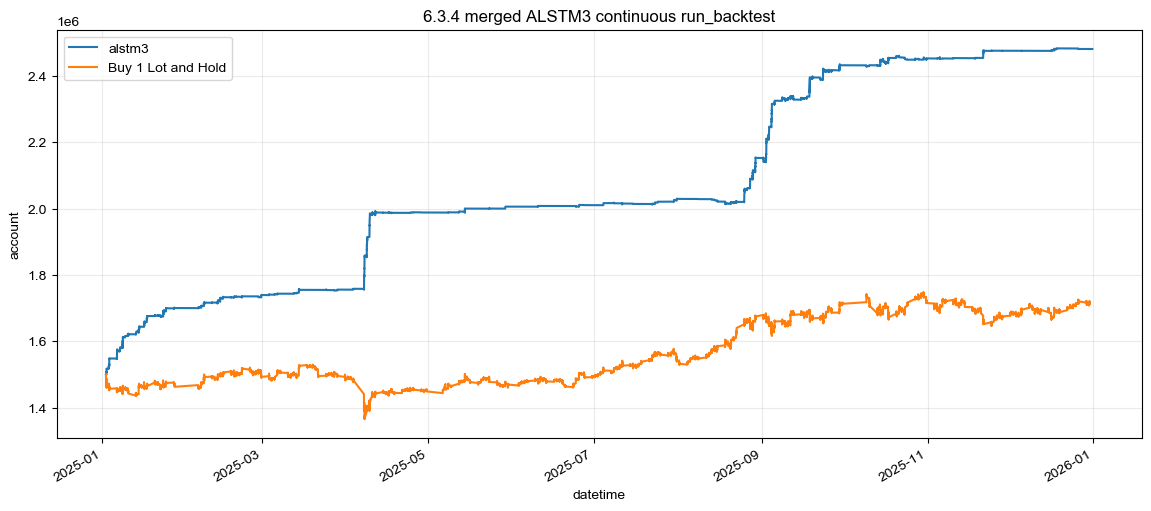

,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time,strategy,trade_prob_threshold,dir_prob_threshold,dir_margin_threshold,dir_logit_center,dir_calibration_method,use_future_vol_filter,direction_balance_pass,valid_selected_score,valid_selected_absolute_pnl,valid_selected_annualized_sharpe,valid_selected_max_drawdown,valid_selected_trade_count,signal_count,signal_ratio,trade_precision,raw_sign_win_rate,direction_accuracy,signed_return_mean,signed_return_median,long_signal_count,short_signal_count,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown,trade_count,dir_train_class_counts,long_dir_prob_threshold,short_dir_prob_threshold,long_dir_margin_threshold,short_dir_margin_threshold
0,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,alstm3,0.65,0.4,0.08,0.0,valid_backtest_grid,False,1,31.652480,2.641514e+06,27.704910,-0.007351,8206,1982,0.168537,0.726034,0.584763,0.584763,0.000321,0.000319,994,988,13680,1500000.0,1.755551e+06,255550.981597,0.170367,0.068342,16.807057,-0.004849,2046,"9642,32016,8952",NaN,NaN,NaN,NaN
1,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,alstm3,0.65,0.4,0.08,0.2,valid_backtest_grid,False,1,27.412923,2.080631e+06,24.307534,-0.007778,8634,898,0.072478,0.782851,0.603563,0.603563,0.000573,0.000452,386,512,14400,1500000.0,1.754684e+06,254684.350972,0.169790,0.070064,17.230614,-0.004962,890,"9202,32317,8881",NaN,NaN,NaN,NaN
2,2025-07,12,6,3,3,2024-01-01,2024-12-31,2025-01-01,2025-06-30,2025-07-01,2025-09-30,alstm3,0.65,0.4,0.08,-0.1,valid_backtest_grid,False,1,16.739312,4.495834e+05,16.073393,-0.004228,2082,2702,0.197949,0.764989,0.563286,0.563286,0.000259,0.000285,836,1866,15840,1500000.0,1.921651e+06,421651.301206,0.281101,0.065559,16.122822,-0.011131,2582,"10627,29687,10296",NaN,NaN,NaN,NaN
3,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,alstm3,0.75,NaN,NaN,0.2,valid_backtest_grid,False,1,16.172413,5.146293e+05,15.414211,-0.006871,2136,615,0.049637,0.723577,0.531707,0.531707,0.000165,0.000198,92,523,14400,1500000.0,1.549049e+06,49049.435391,0.032700,0.019980,4.913599,-0.009883,612,"10039,30569,9792",0.5,0.58,0.14,0.18


,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time,model_b_strategy,use_future_vol_filter,trade_prob_threshold,dir_prob_threshold,dir_margin_threshold,dir_logit_center,dir_calibration_method,signal_count,signal_ratio,trade_precision,raw_sign_win_rate,direction_accuracy,signed_return_mean,signed_return_median,long_signal_count,short_signal_count,direction_side_share,direction_long_short_ratio,min_signal_ratio_pass,direction_balance_pass,valid_absolute_pnl,valid_annualized_sharpe,valid_max_drawdown,valid_trade_count,score,long_dir_prob_threshold,short_dir_prob_threshold,long_dir_margin_threshold,short_dir_margin_threshold
8,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,alstm3,False,0.65,0.40,0.08,0.0,valid_backtest_grid,8237,0.316321,0.788515,0.584315,0.584315,0.000556,0.000420,4138,4099,0.497633,1.009515,1,1,2.641514e+06,27.704910,-0.007351,8206,31.652480,NaN,NaN,NaN,NaN
10,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,alstm3,False,0.65,0.40,0.08,0.2,valid_backtest_grid,8329,0.319854,0.784968,0.582783,0.582783,0.000544,0.000414,3482,4847,0.418057,1.392016,1,1,2.614686e+06,27.693583,-0.007706,8070,31.600201,NaN,NaN,NaN,NaN
11,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,alstm3,False,0.65,0.40,0.08,0.3,valid_backtest_grid,8342,0.320353,0.782906,0.581515,0.581515,0.000528,0.000408,3137,5205,0.376049,1.659229,1,1,2.583635e+06,27.543237,-0.007537,7834,31.403616,NaN,NaN,NaN,NaN
129,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,alstm3,False,0.65,0.40,0.08,0.2,valid_backtest_grid,8586,0.349451,0.767179,0.578733,0.578733,0.000454,0.000370,3452,5134,0.402050,1.487254,1,1,2.080631e+06,24.307534,-0.007778,8634,27.412923,NaN,NaN,NaN,NaN
128,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,alstm3,False,0.65,0.40,0.08,0.1,valid_backtest_grid,8525,0.346968,0.769853,0.574663,0.574663,0.000430,0.000359,3947,4578,0.462991,1.159868,1,1,2.049315e+06,23.940270,-0.006702,8764,27.000838,NaN,NaN,NaN,NaN
130,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,alstm3,False,0.65,0.40,0.08,0.3,valid_backtest_grid,8624,0.350997,0.769133,0.574327,0.574327,0.000431,0.000358,2966,5658,0.343924,1.907620,1,1,2.008921e+06,23.644429,-0.007593,8354,26.642625,NaN,NaN,NaN,NaN
245,2025-07,12,6,3,3,2024-01-01,2024-12-31,2025-01-01,2025-06-30,2025-07-01,2025-09-30,alstm3,False,0.65,0.40,0.08,-0.1,valid_backtest_grid,2037,0.083621,0.769759,0.601865,0.601865,0.000452,0.000444,1003,1034,0.492391,1.030907,1,1,4.495834e+05,16.073393,-0.004228,2082,16.739312,NaN,NaN,NaN,NaN
247,2025-07,12,6,3,3,2024-01-01,2024-12-31,2025-01-01,2025-06-30,2025-07-01,2025-09-30,alstm3,False,0.65,0.40,0.08,0.1,valid_backtest_grid,2039,0.083703,0.776851,0.603237,0.603237,0.000463,0.000468,747,1292,0.366356,1.729585,1,1,4.311669e+05,15.390973,-0.004556,2052,16.028612,NaN,NaN,NaN,NaN
262,2025-07,12,6,3,3,2024-01-01,2024-12-31,2025-01-01,2025-06-30,2025-07-01,2025-09-30,alstm3,False,0.70,0.45,0.10,-0.1,valid_backtest_grid,1245,0.051108,0.804819,0.601606,0.601606,0.000522,0.000561,623,622,0.499598,1.001608,1,1,3.696680e+05,15.462503,-0.003992,1314,16.009021,NaN,NaN,NaN,NaN
435,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,alstm3,False,0.75,NaN,NaN,0.2,valid_backtest_grid,1961,0.074705,0.787863,0.567058,0.567058,0.000354,0.000312,639,1322,0.325854,2.068858,1,1,5.146293e+05,15.414211,-0.006871,2136,16.172413,0.50,0.58,0.14,0.18


In [15]:
# ===== 6.3.4) 只训练最优 ALSTM3 Model B，并做全年连续回测 =====
# 运行顺序：先运行前置 Pv3 helper/Model A 单元。

pv3_b_compare_output_root = artifact_root / "pv3_two_stage_trade_direction_model_b_compare"
pv3_b_base_output_root = artifact_root / "pv3_two_stage_trade_direction_alstm"
pv3_b_compare_output_root.mkdir(parents=True, exist_ok=True)

pv3_b_label_threshold = 0.0005  # 5bp - Model A 阈值
pv3_b_strong_dir_threshold = 0.0008  # 8bp - Model B Full 阈值
pv3_b_use_future_vol_filter = False  # 6.3.4b 只做纯模型阈值选择；波动率/成交量过滤放到 6.3.4c
pv3_b_future_vol_horizon = 5
pv3_b_min_valid_trades = 20
pv3_b_min_valid_signal_ratio = 0.05  # valid 搜索最低信号占比，避免 2025-05~07 这类月份过于保守
pv3_b_direction_calibration_grid = np.round(np.linspace(-0.8, 0.8, 17), 4).tolist()
pv3_b_lgbm_random_state = 2026
pv3_b_lgbm_n_estimators = 300
pv3_b_lgbm_learning_rate = 0.03
pv3_b_use_tick_l1_features = True
pv3_b_tick_path = PROJECT_ROOT / "data" / "if_tick.csv"
pv3_b_tick_cache_dir = pv3_b_compare_output_root / "tick_l1_feature_cache"
pv3_b_tick_cache_dir.mkdir(parents=True, exist_ok=True)
pv3_b_alstm3_epochs = min(int(alstm_kwargs.get("n_epochs", 30)), 18)
pv3_b_alstm3_early_stop = min(int(alstm_kwargs.get("early_stop", 8)), 5)

pv3_b_threshold_grid = [
    # shared baseline thresholds
    {"trade_prob_threshold": 0.65, "dir_prob_threshold": 0.40, "dir_margin_threshold": 0.08},
    {"trade_prob_threshold": 0.70, "dir_prob_threshold": 0.45, "dir_margin_threshold": 0.10},
    {"trade_prob_threshold": 0.75, "dir_prob_threshold": 0.50, "dir_margin_threshold": 0.14},
    # side-specific thresholds: short side is often more crowded, so allow asymmetric gates.
    {"trade_prob_threshold": 0.70, "long_dir_prob_threshold": 0.45, "short_dir_prob_threshold": 0.55, "long_dir_margin_threshold": 0.10, "short_dir_margin_threshold": 0.16},
    {"trade_prob_threshold": 0.75, "long_dir_prob_threshold": 0.50, "short_dir_prob_threshold": 0.58, "long_dir_margin_threshold": 0.14, "short_dir_margin_threshold": 0.18},
    {"trade_prob_threshold": 0.75, "long_dir_prob_threshold": 0.55, "short_dir_prob_threshold": 0.50, "long_dir_margin_threshold": 0.18, "short_dir_margin_threshold": 0.14},
    {"trade_prob_threshold": 0.80, "long_dir_prob_threshold": 0.50, "short_dir_prob_threshold": 0.55, "long_dir_margin_threshold": 0.14, "short_dir_margin_threshold": 0.18},
]
pv3_b_valid_backtest_score_weights = {
    "sharpe": 1.0,
    "pnl_per_100k": 0.15,
    "drawdown": 2.0,
    "low_trade_penalty": 0.5,
}

try:
    import lightgbm as lgb
    _pv3_has_lightgbm = True
except Exception as exc:
    print(f"LightGBM 不可用，使用 sklearn HistGradientBoostingClassifier fallback: {exc!r}")
    lgb = None
    _pv3_has_lightgbm = False
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
import traceback
from engine.backtest.futures_backtest import StrategyRuleConfig, run_backtest
from engine.backtest.continuous_backtest_utils import continuous_price_series, run_continuous_signal_backtest


def _pv3_b_make_feature_label_frame(window: dict, threshold: float) -> pd.DataFrame:
    start = pd.Timestamp(window["start_time"])
    end = _pv3_period_end(window["end_time"])
    frame = rollsafe_feature_frame.copy()
    if "datetime" not in frame.columns:
        if isinstance(frame.index, pd.DatetimeIndex):
            frame = frame.reset_index().rename(columns={frame.index.name or "index": "datetime"})
        else:
            raise KeyError("rollsafe_feature_frame 缺少 datetime 列")
    frame["datetime"] = pd.to_datetime(frame["datetime"], errors="coerce")
    frame = frame[(frame["datetime"] >= start) & (frame["datetime"] <= end)].copy()
    frame = frame.sort_values("datetime").drop_duplicates("datetime", keep="last")
    price_col = next((c for c in [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close", "price"] if c in frame.columns), None)
    if price_col is None:
        raise KeyError(f"6.3.4b 缺少价格列，当前列示例: {list(frame.columns[:20])}")
    dt = pd.to_datetime(frame["datetime"], errors="coerce")
    price = pd.to_numeric(frame[price_col], errors="coerce").replace(0.0, np.nan)
    trade_date = dt.dt.normalize()
    future_price = price.groupby(trade_date).shift(-(int(pv3_horizon) + int(pv3_base_lag)))
    base_price = price.groupby(trade_date).shift(-int(pv3_base_lag))
    frame["pv3_future_return"] = future_price / base_price - 1.0
    frame["pv3_label_trade"] = (frame["pv3_future_return"].abs() > float(threshold)).astype("float64")
    frame["pv3_label_dir"] = (frame["pv3_future_return"] > 0).astype("float64")
    allowed = _intra_decision_allowed_mask(frame["datetime"])
    frame = frame[allowed.fillna(False).to_numpy()].copy()
    if "pv3_future_return" not in frame.columns:
        raise KeyError("6.3.4b 内部构造失败: pv3_future_return 未生成")
    return frame


def _pv3_b_ensure_direction_labels(frame: pd.DataFrame, window: dict, threshold: float) -> pd.DataFrame:
    out = frame.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    need_return = "pv3_future_return" not in out.columns or out["pv3_future_return"].isna().all()
    if need_return:
        price_col = next((c for c in [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close", "price"] if c in out.columns), None)
        if price_col is None:
            raise KeyError("6.3.4b 无法补算 pv3_future_return：缺少价格列")
        dt = pd.to_datetime(out["datetime"], errors="coerce")
        trade_date = dt.dt.normalize()
        price = pd.to_numeric(out[price_col], errors="coerce").replace(0.0, np.nan)
        future_price = price.groupby(trade_date).shift(-(int(pv3_horizon) + int(pv3_base_lag)))
        base_price = price.groupby(trade_date).shift(-int(pv3_base_lag))
        out["pv3_future_return"] = future_price / base_price - 1.0
    if "pv3_label_trade" not in out.columns:
        out["pv3_label_trade"] = (pd.to_numeric(out["pv3_future_return"], errors="coerce").abs() > float(threshold)).astype("float64")
    if "pv3_label_dir" not in out.columns:
        out["pv3_label_dir"] = (pd.to_numeric(out["pv3_future_return"], errors="coerce") > 0).astype("float64")
    return out


def _pv3_b_existing_tick_like_columns(frame: pd.DataFrame) -> set[str]:
    keys = ("tick", "liq_", "spread", "microprice", "order", "book", "imbalance")
    return {c for c in frame.columns if any(k in c.lower() for k in keys)}


def _pv3_b_load_tick_l1_minute_features(window: dict, existing_cols: set[str]) -> pd.DataFrame:
    if not bool(pv3_b_use_tick_l1_features):
        return pd.DataFrame(columns=["datetime"])
    if not Path(pv3_b_tick_path).exists():
        print(f"tick 文件不存在，跳过一档 tick 因子: {pv3_b_tick_path}")
        return pd.DataFrame(columns=["datetime"])
    window_id = str(window.get("window_id", "window"))
    cache_path = pv3_b_tick_cache_dir / f"{window_id}_tick_l1_minute_features.csv"
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        cached["datetime"] = pd.to_datetime(cached["datetime"], errors="coerce")
        return cached

    start = pd.Timestamp(window["start_time"])
    end = _pv3_period_end(window["end_time"])
    usecols = [
        "datetime", "last", "volume", "open_interest", "total_turnover",
        "a1", "b1", "a1_v", "b1_v",
    ]
    chunks = []
    for chunk in pd.read_csv(pv3_b_tick_path, usecols=usecols, chunksize=1_000_000):
        chunk["datetime"] = pd.to_datetime(chunk["datetime"], errors="coerce")
        chunk = chunk[(chunk["datetime"] >= start) & (chunk["datetime"] <= end)].copy()
        if chunk.empty:
            continue
        for c in ["last", "volume", "open_interest", "total_turnover", "a1", "b1", "a1_v", "b1_v"]:
            chunk[c] = pd.to_numeric(chunk[c], errors="coerce")
        chunks.append(chunk)
    if not chunks:
        return pd.DataFrame(columns=["datetime"])

    tick = pd.concat(chunks, ignore_index=True).dropna(subset=["datetime"])
    tick = tick.sort_values("datetime").drop_duplicates("datetime", keep="last")
    tick["minute"] = tick["datetime"].dt.floor("min")
    tick["trade_date"] = tick["datetime"].dt.normalize()
    mid = (tick["a1"] + tick["b1"]) / 2.0
    spread = tick["a1"] - tick["b1"]
    depth_sum = (tick["a1_v"] + tick["b1_v"]).replace(0.0, np.nan)
    tick["l1_book_imbalance"] = ((tick["b1_v"] - tick["a1_v"]) / depth_sum).replace([np.inf, -np.inf], np.nan)
    tick["l1_microprice"] = (tick["a1"] * tick["b1_v"] + tick["b1"] * tick["a1_v"]) / depth_sum
    tick["l1_microprice_gap"] = (tick["l1_microprice"] / mid.replace(0.0, np.nan) - 1.0).replace([np.inf, -np.inf], np.nan)
    tick["l1_last_mid_gap"] = (tick["last"] / mid.replace(0.0, np.nan) - 1.0).replace([np.inf, -np.inf], np.nan)
    tick["l1_rel_spread"] = (spread / mid.replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan)
    last_diff = tick.groupby("trade_date")["last"].diff()
    tick["l1_tick_up"] = (last_diff > 0).astype(float)
    tick["l1_tick_down"] = (last_diff < 0).astype(float)
    tick["l1_volume_delta"] = tick.groupby("trade_date")["volume"].diff().clip(lower=0)
    tick["l1_turnover_delta"] = tick.groupby("trade_date")["total_turnover"].diff().clip(lower=0)

    grouped = tick.groupby("minute", sort=True)
    feat = pd.DataFrame(index=grouped.size().index)
    feat.index.name = "datetime"
    feat["tick_l1_book_imbalance_mean_1min"] = grouped["l1_book_imbalance"].mean()
    feat["tick_l1_book_imbalance_last_1min"] = grouped["l1_book_imbalance"].last()
    feat["tick_l1_book_imbalance_std_1min"] = grouped["l1_book_imbalance"].std()
    feat["tick_l1_microprice_gap_mean_1min"] = grouped["l1_microprice_gap"].mean()
    feat["tick_l1_last_mid_gap_mean_1min"] = grouped["l1_last_mid_gap"].mean()
    feat["tick_l1_last_mid_gap_last_1min"] = grouped["l1_last_mid_gap"].last()
    feat["tick_l1_mid_ret_1min"] = grouped.apply(lambda g: ((g["a1"].iloc[-1] + g["b1"].iloc[-1]) / max((g["a1"].iloc[0] + g["b1"].iloc[0]), 1e-12) - 1.0))
    up = grouped["l1_tick_up"].sum()
    down = grouped["l1_tick_down"].sum()
    feat["tick_l1_tick_direction_imbalance_1min"] = ((up - down) / (up + down).replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan)
    vol_delta = grouped["l1_volume_delta"].sum()
    feat["tick_l1_volume_delta_1min"] = vol_delta
    feat["tick_l1_vwap_gap_last_1min"] = (grouped["last"].last() / (grouped["l1_turnover_delta"].sum() / vol_delta.replace(0.0, np.nan) / 300.0).replace(0.0, np.nan) - 1.0).replace([np.inf, -np.inf], np.nan)
    feat["tick_l1_depth_sum_last_1min"] = grouped.apply(lambda g: (g["a1_v"].iloc[-1] + g["b1_v"].iloc[-1]))
    feat["tick_l1_depth_imbalance_x_ret_1min"] = feat["tick_l1_book_imbalance_last_1min"] * feat["tick_l1_mid_ret_1min"]

    # Avoid duplicating existing minute tick/liquidity factors already in the feature frame.
    duplicate_semantics = {
        "liq_microprice_gap_last_1min",
        "liq_rel_spread_mean_1min",
        "liq_rel_spread_std_1min",
        "liq_roll_spread_1min",
        "liq_spread_last_1min",
        "tick_open_interest_chg_1min",
        "trade_tick_count_1min",
        "trade_tick_interval_mean_1min",
    }
    drop_cols = [c for c in feat.columns if c in existing_cols or c in duplicate_semantics]
    if drop_cols:
        feat = feat.drop(columns=drop_cols, errors="ignore")
    feat = feat.reset_index()
    feat.to_csv(cache_path, index=False, encoding="utf-8-sig")
    return feat


def _pv3_b_merge_tick_l1_features(frame: pd.DataFrame, window: dict) -> tuple[pd.DataFrame, list[str]]:
    existing_cols = _pv3_b_existing_tick_like_columns(frame)
    tick_feat = _pv3_b_load_tick_l1_minute_features(window, existing_cols)
    if tick_feat.empty or "datetime" not in tick_feat.columns:
        return frame, []
    out = frame.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce").dt.floor("min")
    tick_feat = tick_feat.copy()
    tick_feat["datetime"] = pd.to_datetime(tick_feat["datetime"], errors="coerce").dt.floor("min")
    tick_cols = [c for c in tick_feat.columns if c != "datetime" and c not in out.columns]
    if not tick_cols:
        return out, []
    out = out.merge(tick_feat[["datetime", *tick_cols]].drop_duplicates("datetime"), on="datetime", how="left")
    return out, tick_cols


def _pv3_b_add_direction_features(frame: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    out = frame.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.sort_values("datetime").drop_duplicates("datetime", keep="last")
    dt = out["datetime"]
    trade_date = dt.dt.normalize()
    price_col = next((c for c in [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close"] if c in out.columns), None)
    volume_col = next((c for c in [f"{target_instrument}_volume", "volume", f"{target_instrument}_total_turnover", "total_turnover"] if c in out.columns), None)
    if price_col is None:
        raise KeyError("方向专用因子缺少价格列")
    price = pd.to_numeric(out[price_col], errors="coerce").replace(0.0, np.nan)
    new_cols = []
    for n in [1, 2, 3, 5, 10, 15, 30]:
        col = f"dir_ret_{n}m"
        out[col] = price / price.groupby(trade_date).shift(n) - 1.0
        new_cols.append(col)
    for n in [5, 10, 20, 30]:
        ma = price.groupby(trade_date).rolling(n, min_periods=max(3, n // 3)).mean().reset_index(level=0, drop=True)
        col = f"dir_price_ma_dev_{n}m"
        out[col] = price / ma.replace(0.0, np.nan) - 1.0
        new_cols.append(col)
    ret_1 = price.groupby(trade_date).pct_change()
    for n in [10, 30]:
        mu = ret_1.groupby(trade_date).rolling(n, min_periods=max(3, n // 3)).mean().reset_index(level=0, drop=True)
        sd = ret_1.groupby(trade_date).rolling(n, min_periods=max(3, n // 3)).std().reset_index(level=0, drop=True)
        col = f"dir_ret_z_{n}m"
        out[col] = ((ret_1 - mu) / sd.replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan)
        new_cols.append(col)
    if volume_col is not None:
        volume = pd.to_numeric(out[volume_col], errors="coerce").replace(0.0, np.nan)
        for n in [5, 15, 30]:
            med = volume.groupby(dt.dt.strftime("%H:%M")).transform(lambda s: s.shift(1).rolling(20, min_periods=5).median())
            col = f"dir_volume_ratio_{n}m" if n == 5 else None
            # 只保留一个同分钟历史成交量比，避免重复列。
            if col and col not in out.columns:
                out[col] = volume / med.replace(0.0, np.nan)
                new_cols.append(col)
                break
        out["dir_ret1_x_volume_ratio"] = ret_1 * pd.to_numeric(out[new_cols[-1]], errors="coerce") if new_cols else np.nan
        new_cols.append("dir_ret1_x_volume_ratio")
    context_prefixes = [p for p in ["IC", "T"] if any(str(c).startswith(f"{p}_") for c in out.columns)]
    for prefix in context_prefixes:
        ctx_price_col = next((c for c in [f"{prefix}_vwap", f"{prefix}_close"] if c in out.columns), None)
        if ctx_price_col is None:
            continue
        ctx_price = pd.to_numeric(out[ctx_price_col], errors="coerce").replace(0.0, np.nan)
        for n in [1, 3, 5, 10]:
            ctx_ret_col = f"dir_{prefix}_ret_{n}m"
            spread_col = f"dir_IF_minus_{prefix}_ret_{n}m"
            ctx_ret = ctx_price / ctx_price.groupby(trade_date).shift(n) - 1.0
            if_ret = price / price.groupby(trade_date).shift(n) - 1.0
            out[ctx_ret_col] = ctx_ret
            out[spread_col] = if_ret - ctx_ret
            new_cols.extend([ctx_ret_col, spread_col])
    out[new_cols] = out[new_cols].replace([np.inf, -np.inf], np.nan)
    return out, new_cols


def _pv3_b_segment_mask(frame: pd.DataFrame, window: dict, segment: str) -> pd.Series:
    if segment == "train":
        start, end = window["start_time"], window["train_end"]
    elif segment == "valid":
        start, end = window["valid_start"], window["valid_end"]
    elif segment == "test":
        start, end = window["test_start"], window["end_time"]
    else:
        raise ValueError(segment)
    dt = pd.to_datetime(frame["datetime"], errors="coerce")
    return (dt >= pd.Timestamp(start)) & (dt <= _pv3_period_end(end))


def _pv3_b_make_lgbm_classifier(num_class: int):
    if _pv3_has_lightgbm:
        if int(num_class) == 2:
            return lgb.LGBMClassifier(
                objective="binary",
                n_estimators=int(pv3_b_lgbm_n_estimators),
                learning_rate=float(pv3_b_lgbm_learning_rate),
                num_leaves=31,
                min_child_samples=200,
                subsample=0.8,
                colsample_bytree=0.75,
                reg_alpha=0.1,
                reg_lambda=1.0,
                random_state=int(pv3_b_lgbm_random_state),
                n_jobs=-1,
                verbose=-1,
            )
        return lgb.LGBMClassifier(
            objective="multiclass",
            num_class=int(num_class),
            n_estimators=int(pv3_b_lgbm_n_estimators),
            learning_rate=float(pv3_b_lgbm_learning_rate),
            num_leaves=31,
            min_child_samples=200,
            subsample=0.8,
            colsample_bytree=0.75,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=int(pv3_b_lgbm_random_state),
            n_jobs=-1,
            verbose=-1,
        )
    return make_pipeline(
        SimpleImputer(strategy="median"),
        HistGradientBoostingClassifier(
            max_iter=250,
            learning_rate=float(pv3_b_lgbm_learning_rate),
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=int(pv3_b_lgbm_random_state),
        ),
    )


def _pv3_b_predict_proba(model, X: pd.DataFrame, classes: list[int]) -> pd.DataFrame:
    proba = model.predict_proba(X)
    model_classes = list(getattr(model, "classes_", getattr(model[-1], "classes_", []))) if hasattr(model, "__getitem__") else list(getattr(model, "classes_", []))
    out = pd.DataFrame(0.0, index=X.index, columns=[f"class_{c}" for c in classes])
    for j, cls in enumerate(model_classes):
        if int(cls) in classes:
            out[f"class_{int(cls)}"] = proba[:, j]
    return out


def _pv3_b_lgbm_predict_frames(frame: pd.DataFrame, feature_cols: list[str], window: dict, *, mode: str) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    train_mask = _pv3_b_segment_mask(frame, window, "train")
    valid_mask = _pv3_b_segment_mask(frame, window, "valid")
    test_mask = _pv3_b_segment_mask(frame, window, "test")
    X_train = frame.loc[train_mask, feature_cols].apply(pd.to_numeric, errors="coerce")
    X_valid = frame.loc[valid_mask, feature_cols].apply(pd.to_numeric, errors="coerce")
    X_test = frame.loc[test_mask, feature_cols].apply(pd.to_numeric, errors="coerce")
    if mode == "binary":
        y_train = frame.loc[train_mask, "pv3_label_dir_bin"].astype(int)
        classes = [0, 1]
    elif mode == "three_class":
        y_train = frame.loc[train_mask, "pv3_label_dir3"].astype(int)
        classes = [0, 1, 2]
    else:
        raise ValueError(mode)
    sample_weight = pd.to_numeric(frame.loc[train_mask, "pv3_dir_loss_weight"], errors="coerce").fillna(1.0).clip(0.0, 10.0)
    model = _pv3_b_make_lgbm_classifier(len(classes))
    fit_kwargs = {}
    if _pv3_has_lightgbm:
        fit_kwargs["sample_weight"] = sample_weight.to_numpy(dtype=float)
        fit_kwargs["eval_set"] = [(X_valid, frame.loc[valid_mask, "pv3_label_dir_bin" if mode == "binary" else "pv3_label_dir3"].astype(int))]
        fit_kwargs["eval_metric"] = "binary_logloss" if mode == "binary" else "multi_logloss"
    else:
        fit_kwargs["histgradientboostingclassifier__sample_weight"] = sample_weight.to_numpy(dtype=float)
    model.fit(X_train, y_train, **fit_kwargs)
    def build_pred(mask, X, segment):
        prob = _pv3_b_predict_proba(model, X, classes)
        out = pd.DataFrame({"datetime": pd.to_datetime(frame.loc[mask, "datetime"].values), "period": segment}, index=X.index)
        if mode == "binary":
            out["prob_dir_down"] = prob["class_0"].to_numpy()
            out["prob_dir_up"] = prob["class_1"].to_numpy()
        else:
            out["prob_dir_down"] = prob["class_0"].to_numpy()
            out["prob_dir_uncertain"] = prob["class_1"].to_numpy()
            out["prob_dir_up"] = prob["class_2"].to_numpy()
        return out.reset_index(drop=True)
    return build_pred(valid_mask, X_valid, "valid"), build_pred(test_mask, X_test, "test"), {"model": model}


def _pv3_b_alstm3_predict_frames(frame: pd.DataFrame, feature_cols: list[str], window: dict, window_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    dir3_dataset = _pv3_build_dataset_from_frame(frame, feature_cols, "pv3_label_dir3", window)
    dir3_ts_dataset = _pv3_to_ts_dataset(dir3_dataset, window)
    params = dict(pv3_dir_model_params)
    params.update({
        "state_num_classes": 3,
        "state_class_names": {0: "dir_down", 1: "dir_uncertain", 2: "dir_up"},
        "state_class_weight_mode": "sqrt_balanced",
        "state_class_weight_clip": (0.5, 3.0),
        "n_epochs": int(pv3_b_alstm3_epochs),
        "early_stop": int(pv3_b_alstm3_early_stop),
        "seed": 2043,
    })
    weight_by_segment = _pv3_weight_series(frame, "pv3_dir_loss_weight", window)
    result = alstm_model_module.train_state_classifier(
        dir3_ts_dataset,
        d_feat=len(feature_cols),
        model_params=params,
        state_threshold=0.5,
        state_sample_weight_by_segment=weight_by_segment,
        model_save_path=window_dir / "pv3_b_alstm3_direction.pt",
        show_progress=True,
    )
    result["evals_result"].to_csv(window_dir / "pv3_b_alstm3_direction_evals.csv", index=False, encoding="utf-8-sig")
    def pred_segment(segment):
        prob, _, _, _ = alstm_model_module.predict_state_classifier(
            result["model"],
            dir3_ts_dataset,
            segment=segment,
            batch_size=int(params.get("batch_size", 128)),
            state_threshold=0.5,
            class_names={0: "dir_down", 1: "dir_uncertain", 2: "dir_up"},
        )
        prob = _pv3_prob_to_datetime_frame(prob)
        out = pd.DataFrame(index=prob.index)
        out["datetime"] = out.index
        out["period"] = segment
        out["prob_dir_down"] = pd.to_numeric(prob.get("prob_dir_down"), errors="coerce")
        out["prob_dir_uncertain"] = pd.to_numeric(prob.get("prob_dir_uncertain"), errors="coerce")
        out["prob_dir_up"] = pd.to_numeric(prob.get("prob_dir_up"), errors="coerce")
        return out.reset_index(drop=True)
    return pred_segment("valid"), pred_segment("test"), result


def _pv3_b_attach_trade_and_labels(dir_pred: pd.DataFrame, base_pred: pd.DataFrame, frame: pd.DataFrame) -> pd.DataFrame:
    out = dir_pred.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    label_cols = ["pv3_future_return", "pv3_label_trade", "pv3_label_dir", "pv3_label_dir_bin", "pv3_label_dir3"]
    out = out.drop(columns=[c for c in label_cols if c in out.columns], errors="ignore")
    frame = _pv3_b_ensure_direction_labels(frame, {}, pv3_b_label_threshold)
    if "pv3_label_dir_bin" not in frame.columns:
        frame["pv3_label_dir_bin"] = (pd.to_numeric(frame["pv3_future_return"], errors="coerce") > 0).astype("int64")
    if "pv3_label_dir3" not in frame.columns:
        ret = pd.to_numeric(frame["pv3_future_return"], errors="coerce")
        frame["pv3_label_dir3"] = 1
        frame.loc[ret > float(pv3_b_strong_dir_threshold), "pv3_label_dir3"] = 2
        frame.loc[ret < -float(pv3_b_strong_dir_threshold), "pv3_label_dir3"] = 0
    base_cols = [c for c in ["datetime", "trade_prob", "no_trade_prob"] if c in base_pred.columns]
    base = base_pred[base_cols].copy()
    base["datetime"] = pd.to_datetime(base["datetime"], errors="coerce")
    labels = frame[["datetime", "pv3_future_return", "pv3_label_trade", "pv3_label_dir", "pv3_label_dir_bin", "pv3_label_dir3"]].copy()
    labels["datetime"] = pd.to_datetime(labels["datetime"], errors="coerce")
    if "trade_prob" not in out.columns and "trade_prob" in base.columns:
        out = out.merge(base.drop_duplicates("datetime"), on="datetime", how="left")
    elif "no_trade_prob" not in out.columns and "no_trade_prob" in base.columns:
        out = out.merge(base[["datetime", "no_trade_prob"]].drop_duplicates("datetime"), on="datetime", how="left")
    out = out.merge(labels.drop_duplicates("datetime"), on="datetime", how="left")
    if "pv3_future_return" not in out.columns:
        raise KeyError(f"attach 后缺少 pv3_future_return，columns={list(out.columns)}")
    return out


def _pv3_b_ensemble_binary(base_alstm_pred: pd.DataFrame, lgbm_pred: pd.DataFrame) -> pd.DataFrame:
    a = base_alstm_pred[["datetime", "prob_dir_up", "prob_dir_down"]].copy()
    l = lgbm_pred[["datetime", "prob_dir_up", "prob_dir_down"]].copy()
    a["datetime"] = pd.to_datetime(a["datetime"], errors="coerce")
    l["datetime"] = pd.to_datetime(l["datetime"], errors="coerce")
    out = a.merge(l, on="datetime", suffixes=("_alstm", "_lgbm"), how="inner")
    out["prob_dir_up"] = 0.5 * out["prob_dir_up_alstm"] + 0.5 * out["prob_dir_up_lgbm"]
    out["prob_dir_down"] = 0.5 * out["prob_dir_down_alstm"] + 0.5 * out["prob_dir_down_lgbm"]
    return out[["datetime", "prob_dir_up", "prob_dir_down"]]


def _pv3_b_clean_future_vol(future_vol):
    if future_vol is None:
        return None
    if isinstance(future_vol, pd.Series):
        return future_vol
    fv = future_vol.copy()
    drop_cols = [c for c in ["period", "segment"] if c in fv.columns]
    if drop_cols:
        fv = fv.drop(columns=drop_cols, errors="ignore")
    dup_cols = fv.columns[fv.columns.duplicated()].tolist()
    if dup_cols:
        fv = fv.loc[:, ~fv.columns.duplicated()].copy()
    return fv


def _pv3_b_make_signal(pred: pd.DataFrame, params: dict, *, use_future_vol_filter: bool, future_vol: pd.DataFrame | None = None) -> pd.Series:
    out = pred.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates("datetime", keep="last")
    out = out.set_index("datetime")
    if use_future_vol_filter and future_vol is not None and not future_vol.empty:
        fv = _pv3_b_clean_future_vol(future_vol)
        overlap = [c for c in fv.columns if c in out.columns]
        if overlap:
            fv = fv.drop(columns=overlap, errors="ignore")
        out = out.join(fv, how="left")
        vol_ok = out["pred_vol_state_name"].astype(str).isin(pv3_allow_pred_vol_states) if "pred_vol_state_name" in out.columns else pd.Series(True, index=out.index)
        if "prob_vol_high" in out.columns:
            vol_ok = vol_ok | (pd.to_numeric(out["prob_vol_high"], errors="coerce") >= float(pv3_future_vol_min_high_prob))
    else:
        vol_ok = pd.Series(True, index=out.index)
    eps = 1e-6
    p_up_raw = pd.to_numeric(out["prob_dir_up"], errors="coerce").clip(eps, 1.0 - eps)
    p_down_raw = pd.to_numeric(out["prob_dir_down"], errors="coerce").clip(eps, 1.0 - eps)
    dir_logit = np.log(p_up_raw / p_down_raw) - float(params.get("dir_logit_center", 0.0))
    p_up = 1.0 / (1.0 + np.exp(-dir_logit))
    p_down = 1.0 - p_up
    margin = (p_up - p_down).abs()
    shared_prob = float(params.get("dir_prob_threshold", 0.5))
    shared_margin = float(params.get("dir_margin_threshold", 0.1))
    long_prob_thr = float(params.get("long_dir_prob_threshold", shared_prob))
    short_prob_thr = float(params.get("short_dir_prob_threshold", shared_prob))
    long_margin_thr = float(params.get("long_dir_margin_threshold", shared_margin))
    short_margin_thr = float(params.get("short_dir_margin_threshold", shared_margin))
    trade_prob_ok = pd.to_numeric(out["trade_prob"], errors="coerce") >= float(params["trade_prob_threshold"])
    long_ok = trade_prob_ok & (p_up > p_down) & (p_up >= long_prob_thr) & (margin >= long_margin_thr) & vol_ok.fillna(False)
    short_ok = trade_prob_ok & (p_down > p_up) & (p_down >= short_prob_thr) & (margin >= short_margin_thr) & vol_ok.fillna(False)
    signal = pd.Series(0.0, index=out.index, name="pv3_signal_raw")
    signal.loc[long_ok] = 1.0
    signal.loc[short_ok] = -1.0
    signal = signal.shift(int(pv3_signal_execution_lag_bars)).fillna(0.0).rename("pv3_signal_exec")
    return mask_intra_signal(signal)


def _pv3_b_valid_window(window: dict) -> dict:
    valid_window = dict(window)
    valid_window["test_start"] = window["valid_start"]
    valid_window["end_time"] = window["valid_end"]
    return valid_window


def _pv3_b_score_valid_backtest(valid_metrics: dict, valid_trade_count: int, signal_count: int, signal_ratio: float = np.nan) -> float:
    sharpe = float(valid_metrics.get("annualized_sharpe", np.nan))
    pnl = float(valid_metrics.get("absolute_pnl", np.nan))
    mdd = abs(float(valid_metrics.get("max_drawdown", 0.0)))
    if not np.isfinite(sharpe):
        sharpe = -10.0
    if not np.isfinite(pnl):
        pnl = -1e9
    low_trade_penalty = max(0.0, float(pv3_b_min_valid_trades) - float(valid_trade_count)) / max(float(pv3_b_min_valid_trades), 1.0)
    no_signal_penalty = 1.0 if int(signal_count) < int(pv3_b_min_valid_trades) else 0.0
    low_signal_ratio_penalty = max(0.0, float(pv3_b_min_valid_signal_ratio) - float(signal_ratio if np.isfinite(signal_ratio) else 0.0)) / max(float(pv3_b_min_valid_signal_ratio), 1e-12)
    w = pv3_b_valid_backtest_score_weights
    return (
        float(w["sharpe"]) * sharpe
        + float(w["pnl_per_100k"]) * pnl / 100000.0
        - float(w["drawdown"]) * mdd
        - float(w["low_trade_penalty"]) * low_trade_penalty
        - no_signal_penalty
        - low_signal_ratio_penalty
    )


def _pv3_b_select_and_backtest(valid_pred: pd.DataFrame, test_pred: pd.DataFrame, window: dict, strategy_name: str, window_dir: Path) -> tuple[pd.DataFrame, dict, dict, list[dict]]:
    future_vol = None  # 6.3.4b 不再进行波动率过滤；过滤类实验统一放到 6.3.4c
    valid_rows = []
    best = None
    best_relaxed = None
    valid_window = _pv3_b_valid_window(window)
    for use_fv in [False]:
        for params in pv3_b_threshold_grid:
            for center in pv3_b_direction_calibration_grid:
                trial_params = {**params, "dir_logit_center": float(center), "dir_calibration_method": "valid_backtest_grid"}
                sig_valid = _pv3_b_make_signal(valid_pred, trial_params, use_future_vol_filter=use_fv, future_vol=future_vol)
                q = _pv3_signal_quality(valid_pred, sig_valid)
                signal_count = int(q.get("signal_count", 0))
                long_count = int(q.get("long_signal_count", 0))
                short_count = int(q.get("short_signal_count", 0))
                min_side = min(long_count, short_count)
                max_side = max(long_count, short_count)
                side_share = min_side / max(signal_count, 1)
                ls_ratio = max_side / max(min_side, 1) if signal_count else np.inf
                min_signal_ratio_pass = bool(float(q.get("signal_ratio", 0.0)) >= float(pv3_b_min_valid_signal_ratio))
                balance_pass = bool(signal_count >= int(pv3_b_min_valid_trades) and min_signal_ratio_pass and min_side >= 20 and side_share >= 0.10 and ls_ratio <= 6.0)
                try:
                    valid_report, valid_metadata = _pv3_backtest_signal(sig_valid, valid_window, f"{strategy_name}_valid_search")
                    valid_metrics = account_metrics(valid_report["account"], float(pv3_account))
                    valid_trade_count = int(valid_metadata.get("trade_count", 0))
                    score = _pv3_b_score_valid_backtest(valid_metrics, valid_trade_count, signal_count, q.get("signal_ratio", np.nan))
                except Exception as bt_exc:
                    valid_metrics = {"absolute_pnl": np.nan, "annualized_sharpe": np.nan, "max_drawdown": np.nan}
                    valid_trade_count = 0
                    score = -1e9
                    q["valid_backtest_error"] = repr(bt_exc)
                row = {
                    **window,
                    "model_b_strategy": strategy_name,
                    "use_future_vol_filter": use_fv,
                    **trial_params,
                    **q,
                    "direction_side_share": side_share,
                    "direction_long_short_ratio": ls_ratio,
                    "min_signal_ratio_pass": int(min_signal_ratio_pass),
                    "direction_balance_pass": int(balance_pass),
                    "valid_absolute_pnl": valid_metrics.get("absolute_pnl", np.nan),
                    "valid_annualized_sharpe": valid_metrics.get("annualized_sharpe", np.nan),
                    "valid_max_drawdown": valid_metrics.get("max_drawdown", np.nan),
                    "valid_trade_count": valid_trade_count,
                    "score": score,
                }
                valid_rows.append(row)
                if signal_count < int(pv3_b_min_valid_trades) or valid_trade_count <= 0:
                    continue
                candidate = {"score": score, "params": trial_params, "use_future_vol_filter": use_fv, "quality": q, "direction_balance_pass": balance_pass, "valid_metrics": valid_metrics, "valid_trade_count": valid_trade_count}
                if best_relaxed is None or score > best_relaxed["score"]:
                    best_relaxed = candidate
                if balance_pass and (best is None or score > best["score"]):
                    best = candidate
    if best is None:
        best = best_relaxed or {"score": np.nan, "params": {**pv3_b_threshold_grid[2], "dir_logit_center": 0.0}, "use_future_vol_filter": False, "quality": {}, "direction_balance_pass": False, "valid_metrics": {}, "valid_trade_count": np.nan}
    sig_test = _pv3_b_make_signal(test_pred, best["params"], use_future_vol_filter=best["use_future_vol_filter"], future_vol=future_vol)
    quality_test = _pv3_signal_quality(test_pred, sig_test)
    report, metadata = _pv3_backtest_signal(sig_test, window, strategy_name)
    report.to_csv(window_dir / f"{strategy_name}_account_curve.csv", encoding="utf-8-sig")
    metrics = account_metrics(report["account"], float(pv3_account))
    summary = {
        **window,
        "strategy": strategy_name,
        **best["params"],
        "use_future_vol_filter": bool(best["use_future_vol_filter"]),
        "direction_balance_pass": int(bool(best.get("direction_balance_pass", False))),
        "valid_selected_score": best.get("score", np.nan),
        "valid_selected_absolute_pnl": best.get("valid_metrics", {}).get("absolute_pnl", np.nan),
        "valid_selected_annualized_sharpe": best.get("valid_metrics", {}).get("annualized_sharpe", np.nan),
        "valid_selected_max_drawdown": best.get("valid_metrics", {}).get("max_drawdown", np.nan),
        "valid_selected_trade_count": best.get("valid_trade_count", np.nan),
        **quality_test,
        **metrics,
        "trade_count": metadata.get("trade_count", np.nan),
    }
    return report, summary, best, valid_rows


pv3_b_rows = []
pv3_b_valid_rows = []
pv3_b_errors = []
pv3_b_curve_rows = {"alstm3": []}
pv3_b_signal_rows = {"alstm3": []}

for _, window_row in tqdm(windows_df.iterrows(), total=len(windows_df), desc="Pv3 Model-B compare"):
    window = window_row.to_dict()
    window_id = str(window["window_id"])
    window_dir = pv3_b_compare_output_root / window_id
    window_dir.mkdir(parents=True, exist_ok=True)
    try:
        frame = _pv3_b_make_feature_label_frame(window, pv3_b_label_threshold)
        frame = _pv3_b_ensure_direction_labels(frame, window, pv3_b_label_threshold)
        if "pv3_future_return" not in frame.columns:
            raise KeyError(f"6.3.4b frame 缺少 pv3_future_return，columns={list(frame.columns[:30])}")
        frame["pv3_label_dir_bin"] = (pd.to_numeric(frame["pv3_future_return"], errors="coerce") > 0).astype("int64")
        ret = pd.to_numeric(frame["pv3_future_return"], errors="coerce")
        frame["pv3_label_dir3"] = 1
        frame.loc[ret > float(pv3_b_strong_dir_threshold), "pv3_label_dir3"] = 2
        frame.loc[ret < -float(pv3_b_strong_dir_threshold), "pv3_label_dir3"] = 0
        frame["pv3_dir_loss_weight"] = _pv3_make_direction_loss_weight(frame, pv3_b_label_threshold)
        frame, dir_factor_cols = _pv3_b_add_direction_features(frame)
        frame, tick_l1_factor_cols = _pv3_b_merge_tick_l1_features(frame, window)
        feature_cols = [c for c in feature_list if c in frame.columns]
        feature_cols = list(dict.fromkeys([*feature_cols, *dir_factor_cols, *tick_l1_factor_cols]))
        pd.Series(feature_cols, name="feature").to_csv(window_dir / "model_b_feature_columns.csv", index=False, encoding="utf-8-sig")
        pd.Series(dir_factor_cols, name="direction_feature").to_csv(window_dir / "direction_feature_columns.csv", index=False, encoding="utf-8-sig")
        pd.Series(tick_l1_factor_cols, name="tick_l1_feature").to_csv(window_dir / "tick_l1_feature_columns.csv", index=False, encoding="utf-8-sig")

        base_path = pv3_b_base_output_root / window_id / f"pv3_alstm_predictions_threshold_{str(pv3_b_label_threshold).replace('.', 'p')}.csv"
        if not base_path.exists():
            raise FileNotFoundError(f"缺少 6.3.4 预测文件: {base_path}")
        base_pred_all = pd.read_csv(base_path)
        base_valid = base_pred_all[base_pred_all["period"].astype(str).eq("valid")].copy()
        base_test = base_pred_all[base_pred_all["period"].astype(str).eq("test")].copy()

        # 只保留当前最优主线：ALSTM three-class direction。
        alstm3_valid, alstm3_test, alstm3_result = _pv3_b_alstm3_predict_frames(frame, feature_cols, window, window_dir)
        alstm3_valid = _pv3_b_attach_trade_and_labels(alstm3_valid, base_valid, frame)
        alstm3_test = _pv3_b_attach_trade_and_labels(alstm3_test, base_test, frame)
        pd.concat([alstm3_valid.assign(period="valid"), alstm3_test.assign(period="test")], ignore_index=True).to_csv(window_dir / "alstm3_predictions.csv", index=False, encoding="utf-8-sig")
        report, row, best, valid_rows = _pv3_b_select_and_backtest(alstm3_valid, alstm3_test, window, "alstm3", window_dir)
        row["dir_train_class_counts"] = ",".join(str(int(x)) for x in np.asarray(alstm3_result.get("class_counts", []), dtype=float))
        pv3_b_rows.append(row)
        pv3_b_valid_rows.extend(valid_rows)
        pv3_b_curve_rows["alstm3"].append(report[["account"]])
        alstm3_signal = _pv3_b_make_signal(alstm3_test, best["params"], use_future_vol_filter=False, future_vol=None)
        alstm3_signal.to_csv(window_dir / "alstm3_selected_signal.csv", encoding="utf-8-sig")
        pv3_b_signal_rows["alstm3"].append(alstm3_signal)
        print(f"{window_id} merged 6.3.4 ALSTM3 done")
        gc.collect()
    except Exception as exc:
        tb = traceback.format_exc()
        pv3_b_errors.append({**window, "error": repr(exc), "traceback": tb})
        print(f"Pv3 Model-B 对比失败: {window_id} {exc!r}")
        print(tb)

pv3_b_window_summary = pd.DataFrame(pv3_b_rows)
pv3_b_valid_summary = pd.DataFrame(pv3_b_valid_rows)
pv3_b_error_df = pd.DataFrame(pv3_b_errors)
pv3_b_window_summary.to_csv(pv3_b_compare_output_root / "window_summary.csv", index=False, encoding="utf-8-sig")
pv3_b_valid_summary.to_csv(pv3_b_compare_output_root / "valid_threshold_search.csv", index=False, encoding="utf-8-sig")
pv3_b_error_df.to_csv(pv3_b_compare_output_root / "errors.csv", index=False, encoding="utf-8-sig")

def _pv3_b_continuous_rule() -> StrategyRuleConfig:
    return StrategyRuleConfig(
        instrument=target_instrument,
        strategy_mode="long_short",
        contract_multiplier=float(contract_multiplier),
        fixed_trade_amount=float(pv3_fixed_trade_amount),
        long_open_threshold=0.5,
        long_close_threshold=-0.5,
        short_open_threshold=-0.5,
        short_close_threshold=0.5,
        first_trade_time=_time_value(pv3_first_trade_time),
        last_trade_time=_time_value(pv3_last_trade_time),
        trade_interval_minutes=int(pv3_trade_interval_minutes),
        force_flatten_exec_time=_time_value(pv3_force_flatten_exec_time),
        force_flatten_daily=bool(pv3_force_flatten_daily),
        force_flatten_dates=None,
        open_cost=float(pv3_open_cost),
        close_cost=float(pv3_close_cost),
    )

stitched = {}
pv3_b_continuous_summary_rows = []
try:
    test_start_all = str(pd.Timestamp(windows_df["test_start"].min()).date())
    end_time_all = str(pd.Timestamp(windows_df["end_time"].max()).date())
    price_ser_all = continuous_price_series(
        rollsafe_feature_frame,
        start_time=test_start_all,
        end_time=end_time_all,
        price_col_candidates=[f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close", "price"],
    )
    for name, sig_parts in pv3_b_signal_rows.items():
        if not sig_parts:
            continue
        report_df, analysis, indicator_dict, positions = run_continuous_signal_backtest(
            signal_parts=sig_parts,
            price_series=price_ser_all,
            test_start=test_start_all,
            end_time=end_time_all,
            account=float(pv3_account),
            strategy_rule=_pv3_b_continuous_rule(),
        )
        curve = report_df["account"].rename(name)
        stitched[name] = curve
        report_df.to_csv(pv3_b_compare_output_root / f"{name}_continuous_report.csv", encoding="utf-8-sig")
        positions.to_csv(pv3_b_compare_output_root / f"{name}_continuous_positions.csv", encoding="utf-8-sig")
        pd.concat(sig_parts).sort_index().to_frame("signal").to_csv(pv3_b_compare_output_root / f"{name}_continuous_signal.csv", encoding="utf-8-sig")
        m = account_metrics(curve, float(pv3_account))
        m["trade_count"] = int(indicator_dict.get("1min", {}).get("trade_count", np.nan))
        m["backtest_mode"] = "continuous_once_run_backtest"
        pv3_b_continuous_summary_rows.append({"strategy": name, **m})
    stitched["Buy 1 Lot and Hold"] = buy_one_lot_curve(test_start_all, end_time_all, float(pv3_account))
except Exception as exc:
    print(f"6.3.4 合并版连续回测失败: {exc!r}")

if stitched:
    pv3_b_curves = pd.concat(stitched, axis=1).sort_index()
    pv3_b_curves.to_csv(pv3_b_compare_output_root / "continuous_account_curves.csv", encoding="utf-8-sig")
    pv3_b_total_summary = pd.DataFrame(pv3_b_continuous_summary_rows)
    if "Buy 1 Lot and Hold" in pv3_b_curves.columns:
        pv3_b_total_summary = pd.concat([
            pv3_b_total_summary,
            pd.DataFrame([{"strategy": "Buy 1 Lot and Hold", **account_metrics(pv3_b_curves["Buy 1 Lot and Hold"], float(pv3_account)), "trade_count": 1, "backtest_mode": "continuous_buy_hold"}])
        ], ignore_index=True)
    pv3_b_total_summary.to_csv(pv3_b_compare_output_root / "continuous_summary.csv", index=False, encoding="utf-8-sig")
    ax = pv3_b_curves.plot(figsize=(14, 6), title="6.3.4 merged ALSTM3 continuous run_backtest")
    ax.set_ylabel("account")
    ax.grid(alpha=0.25)
    plt.show()
else:
    pv3_b_curves = pd.DataFrame()
    pv3_b_total_summary = pd.DataFrame()

display(pv3_b_window_summary)
if not pv3_b_valid_summary.empty:
    display(pv3_b_valid_summary.sort_values(["window_id", "model_b_strategy", "score"], ascending=[True, True, False]).groupby(["window_id", "model_b_strategy"]).head(3))
if not pv3_b_error_df.empty:
    display(pv3_b_error_df)




6.3.4c collected signal parts: {'baseline_signal_only': 4, 'pred_vol_high_only': 4, 'pred_vol_not_low': 4, 'pred_vol_high_volume_mid_high': 4, 'recent_recalibrated': 4}


,strategy,backtest_mode,trade_count,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown
0,baseline_signal_only,continuous_once_run_backtest_signal,6130,58320,1500000.0,2.480936e+06,980936.069165,0.653957,0.058920,14.490035,-0.008333
1,pred_vol_high_only,continuous_once_run_backtest_signal,5240,58320,1500000.0,2.422051e+06,922051.218384,0.614701,0.058299,14.337263,-0.006616
2,pred_vol_not_low,continuous_once_run_backtest_signal,6098,58320,1500000.0,2.479341e+06,979341.011938,0.652894,0.058947,14.496527,-0.008361
3,pred_vol_high_volume_mid_high,continuous_once_run_backtest_signal,4690,58320,1500000.0,2.241688e+06,741688.361323,0.494459,0.050361,12.385201,-0.008766
4,recent_recalibrated,continuous_once_run_backtest_signal,6152,58320,1500000.0,2.499400e+06,999400.251782,0.666267,0.059924,14.737028,-0.008377
5,Buy 1 Lot and Hold,NaN,1,58080,1500000.0,1.715873e+06,215872.625000,0.143915,0.005590,1.374672,-0.107603


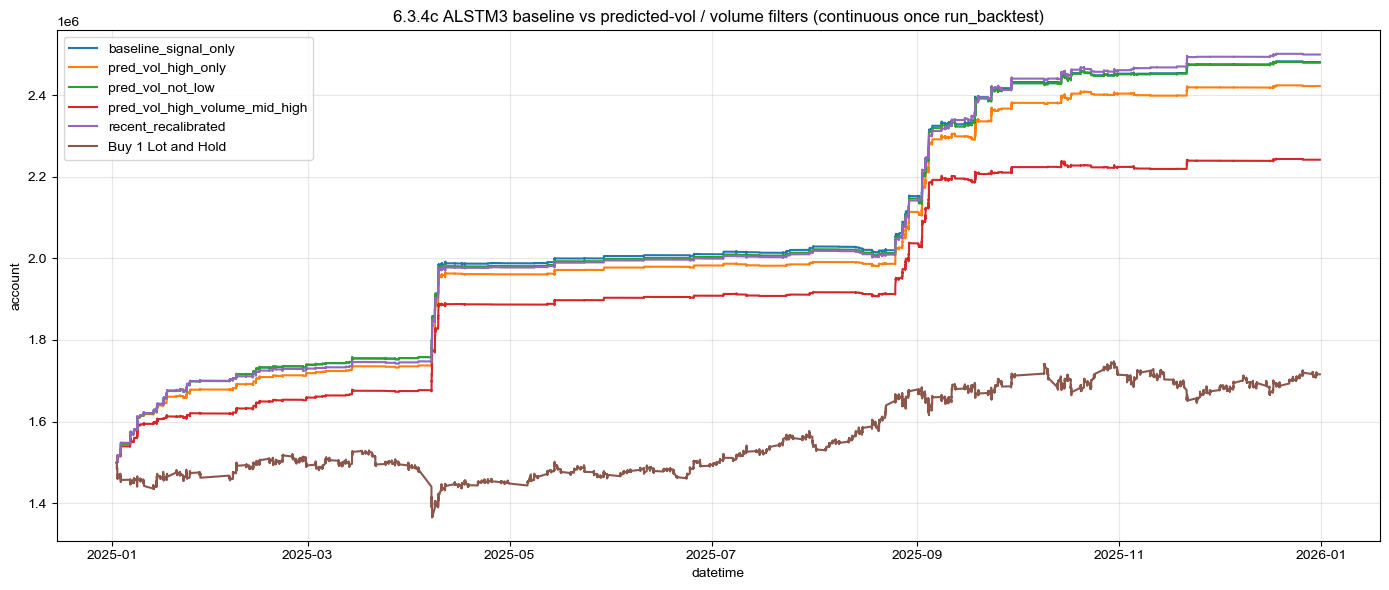

6.3.4c 图表已保存: artifacts/if_alstm_rolling_3state_intra_2025/pv3_two_stage_trade_direction_model_b_compare/alstm3_regime_filter_634c/continuous_filter_comparison.png
输出目录: artifacts/if_alstm_rolling_3state_intra_2025/pv3_two_stage_trade_direction_model_b_compare/alstm3_regime_filter_634c


,strategy,backtest_mode,trade_count,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown
0,baseline_signal_only,continuous_once_run_backtest_signal,6130,58320,1500000.0,2.480936e+06,980936.069165,0.653957,0.058920,14.490035,-0.008333
1,pred_vol_high_only,continuous_once_run_backtest_signal,5240,58320,1500000.0,2.422051e+06,922051.218384,0.614701,0.058299,14.337263,-0.006616
2,pred_vol_not_low,continuous_once_run_backtest_signal,6098,58320,1500000.0,2.479341e+06,979341.011938,0.652894,0.058947,14.496527,-0.008361
3,pred_vol_high_volume_mid_high,continuous_once_run_backtest_signal,4690,58320,1500000.0,2.241688e+06,741688.361323,0.494459,0.050361,12.385201,-0.008766
4,recent_recalibrated,continuous_once_run_backtest_signal,6152,58320,1500000.0,2.499400e+06,999400.251782,0.666267,0.059924,14.737028,-0.008377
5,Buy 1 Lot and Hold,NaN,1,58080,1500000.0,1.715873e+06,215872.625000,0.143915,0.005590,1.374672,-0.107603


,window_id,train_months,valid_months,test_months,test_start,end_time,strategy,description,signal_count,signal_ratio,trade_precision,raw_sign_win_rate,fee_cover_sign_win_rate,signed_return_mean,long_signal_count,short_signal_count,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown,trade_count,trade_prob_threshold,dir_prob_threshold,dir_margin_threshold,dir_logit_center
0,2025-01,12,6,3,2025-01-01,2025-03-31,Buy 1 Lot and Hold,Buy 1 Lot and Hold，使用同一测试价格序列,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500000.0,1.487757e+06,-12243.000000,-0.008162,-0.001275,-0.307216,-0.042976,1,NaN,NaN,NaN,NaN
1,2025-01,12,6,3,2025-01-01,2025-03-31,baseline_signal_only,6.3.4b 已保存的 alstm3_account_curve；纯模型基线，不做波动率/成...,1982.0,0.168537,0.726034,0.584763,0.474773,0.000321,994.0,988.0,1500000.0,1.755551e+06,255550.981597,0.170367,0.068342,16.470208,-0.004849,2046,0.65,0.4,0.08,0.0
2,2025-01,12,6,3,2025-01-01,2025-03-31,pred_vol_high_only,只在预测波动率 high 时允许开仓/持仓信号,1747.0,0.148554,0.744705,0.585575,0.486548,0.000324,883.0,864.0,1500000.0,1.735425e+06,235425.109922,0.156950,0.065273,15.730655,-0.005079,1325,0.65,0.4,0.08,0.0
3,2025-01,12,6,3,2025-01-01,2025-03-31,pred_vol_not_low,预测波动率不是 low，即 mid/high 才允许交易,1966.0,0.167177,0.731434,0.587996,0.478637,0.000322,983.0,983.0,1500000.0,1.755877e+06,255876.952236,0.170585,0.068534,16.516551,-0.004855,1419,0.65,0.4,0.08,0.0
4,2025-01,12,6,3,2025-01-01,2025-03-31,pred_vol_high_volume_mid_high,预测波动率 high 且成交量 q2/q3 才允许交易,1391.0,0.118282,0.752696,0.583034,0.488857,0.000326,716.0,675.0,1500000.0,1.674921e+06,174920.568120,0.116614,0.052884,12.744890,-0.005526,1204,0.65,0.4,0.08,0.0
5,2025-01,12,6,3,2025-01-01,2025-03-31,recent_recalibrated,使用最近已实现窗口做方向 logit 再校准，不使用未来数据,1995.0,0.169643,0.725313,0.584962,0.473684,0.000311,952.0,1043.0,1500000.0,1.745201e+06,245200.991030,0.163467,0.065322,15.742400,-0.005260,1419,0.65,0.4,0.08,0.0
6,2025-04,12,6,3,2025-04-01,2025-06-30,Buy 1 Lot and Hold,Buy 1 Lot and Hold，使用同一测试价格序列,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500000.0,1.505540e+06,5539.750000,0.003693,0.000798,0.192431,-0.085518,1,NaN,NaN,NaN,NaN
7,2025-04,12,6,3,2025-04-01,2025-06-30,baseline_signal_only,6.3.4b 已保存的 alstm3_account_curve；纯模型基线，不做波动率/成...,898.0,0.072478,0.782851,0.603563,0.508909,0.000573,386.0,512.0,1500000.0,1.754684e+06,254684.350972,0.169790,0.070064,16.885276,-0.004962,890,0.65,0.4,0.08,0.2
8,2025-04,12,6,3,2025-04-01,2025-06-30,pred_vol_high_only,只在预测波动率 high 时允许开仓/持仓信号,826.0,0.066667,0.796610,0.602906,0.512107,0.000588,364.0,462.0,1500000.0,1.747033e+06,247033.424619,0.164689,0.069271,16.694141,-0.004079,585,0.65,0.4,0.08,0.2
9,2025-04,12,6,3,2025-04-01,2025-06-30,pred_vol_not_low,预测波动率不是 low，即 mid/high 才允许交易,893.0,0.072074,0.787234,0.606943,0.511758,0.000573,384.0,509.0,1500000.0,1.747475e+06,247475.495977,0.164984,0.068788,16.577802,-0.004983,624,0.65,0.4,0.08,0.2


In [23]:
# ===== 6.3.4c) Pv3 ALSTM3：预测波动率/成交量过滤回测对比 =====
# 不重新训练；直接读取 6.3.4b 的 alstm3_predictions.csv 和已保存的 decision_market_frame.csv。
# baseline：只按 ALSTM3 信号交易；对比：1) 只在预测波动率 high 交易；2) 不在预测波动率 low 交易；3) 预测波动率 high 且成交量 q2/q3 交易。

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from engine.backtest.futures_backtest import StrategyRuleConfig, run_backtest
from engine.backtest.regime_filter import RegimeFilterConfig, prepare_causal_regimes

pv3_634c_root = artifact_root / "pv3_two_stage_trade_direction_model_b_compare"
pv3_634c_output_root = pv3_634c_root / "alstm3_regime_filter_634c"
pv3_634c_output_root.mkdir(parents=True, exist_ok=True)

pv3_634c_strategy_name = "alstm3"
pv3_634c_account = float(account)
pv3_634c_open_cost = 0.0002
pv3_634c_close_cost = 0.0002
pv3_634c_fixed_trade_amount = 1
pv3_634c_trade_interval_minutes = 1
pv3_634c_signal_execution_lag_bars = 1
pv3_634c_volume_mid_high = {"causal_volume_ratio_q2", "causal_volume_ratio_q3"}
pv3_634c_future_vol_horizon = int(globals().get("pv3_b_future_vol_horizon", 5))
pv3_634c_regime_config = RegimeFilterConfig(vol_window=30, volume_history_days=20)


def _pv3_634c_build_decision_regime(window: dict, decision_path: Path) -> pd.DataFrame:
    """Read saved decision frame, or build required regime columns causally inside 6.3.4c."""
    if decision_path.exists():
        regime = pd.read_csv(decision_path, low_memory=False)
        regime["datetime"] = pd.to_datetime(regime["datetime"], errors="coerce")
        return regime.dropna(subset=["datetime"])

    market = rollsafe_feature_frame.copy()
    market["datetime"] = pd.to_datetime(market["datetime"], errors="coerce")
    history_start = pd.Timestamp(window["valid_start"]) - pd.Timedelta(days=60)
    period_end = _pv3_634c_period_end(window["end_time"])
    market = market[(market["datetime"] >= history_start) & (market["datetime"] <= period_end)].copy()
    price_col = next((c for c in [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close", "price"] if c in market.columns), None)
    volume_col = next((c for c in [f"{target_instrument}_volume", "volume"] if c in market.columns), None)
    if price_col is None or volume_col is None:
        raise KeyError("6.3.4c 无法构造 regime：rollsafe_feature_frame 缺少价格或成交量列")

    regimes, _boundaries = prepare_causal_regimes(
        market,
        price_col=price_col,
        volume_col=volume_col,
        valid_start=window["valid_start"],
        valid_end=window["valid_end"],
        config=pv3_634c_regime_config,
    )
    regimes = regimes.reset_index().rename(columns={"index": "datetime"})
    if "datetime" not in regimes.columns:
        regimes = regimes.rename(columns={regimes.columns[0]: "datetime"})
    regimes["datetime"] = pd.to_datetime(regimes["datetime"], errors="coerce")
    regimes = regimes.dropna(subset=["datetime"])
    if "price" not in regimes.columns:
        regimes["price"] = pd.to_numeric(regimes.get(price_col), errors="coerce") if price_col in regimes.columns else np.nan

    fv_path = artifact_root / "future_realized_vol_lgbm_state" / f"h{pv3_634c_future_vol_horizon}" / str(window["window_id"]) / "future_vol_predictions.csv"
    if fv_path.exists():
        fv = pd.read_csv(fv_path, parse_dates=["datetime"])
        fv = fv[fv.get("period", "test").astype(str).isin(["valid", "test"])] if "period" in fv.columns else fv
        keep = [c for c in ["datetime", "pred_future_vol", "pred_vol_state_name", "prob_vol_low", "prob_vol_mid", "prob_vol_high"] if c in fv.columns]
        regimes = regimes.merge(fv[keep].drop_duplicates("datetime", keep="last"), on="datetime", how="left")
    else:
        print(f"6.3.4c warning: 缺少未来波动率预测 {fv_path}，预测波动率过滤线会偏空")
    return regimes



def _pv3_634c_period_end(value) -> pd.Timestamp:
    end = pd.Timestamp(value)
    return end + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1) if end == end.normalize() else end


def _pv3_634c_time_value(value):
    return pd.Timestamp(str(value)).time()


def _pv3_634c_bool_mask(series: pd.Series) -> pd.Series:
    return series.fillna(False).astype(bool)


def _pv3_634c_make_raw_signal(pred: pd.DataFrame, selected_row: pd.Series, regime: pd.DataFrame | None, filter_name: str) -> pd.Series:
    out = pred.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates("datetime", keep="last")
    out = out[out.get("period", "test").astype(str).eq("test")].copy() if "period" in out.columns else out
    out = out.set_index("datetime")

    if regime is not None and not regime.empty:
        rg = regime.copy()
        rg["datetime"] = pd.to_datetime(rg["datetime"], errors="coerce")
        keep_cols = [
            "datetime", "price", "pred_vol_state_name", "prob_vol_high", "prob_vol_low",
            "causal_volume_ratio_regime", "intraday_volatility_regime",
        ]
        rg = rg[[c for c in keep_cols if c in rg.columns]].dropna(subset=["datetime"]).drop_duplicates("datetime", keep="last").set_index("datetime")
        overlap = [c for c in rg.columns if c in out.columns]
        out = out.drop(columns=overlap, errors="ignore").join(rg, how="left")

    eps = 1e-6
    p_up_raw = pd.to_numeric(out["prob_dir_up"], errors="coerce").clip(eps, 1.0 - eps)
    p_down_raw = pd.to_numeric(out["prob_dir_down"], errors="coerce").clip(eps, 1.0 - eps)
    center = float(selected_row.get("dir_logit_center", 0.0) if pd.notna(selected_row.get("dir_logit_center", np.nan)) else 0.0)
    dir_logit = np.log(p_up_raw / p_down_raw) - center
    p_up = 1.0 / (1.0 + np.exp(-dir_logit))
    p_down = 1.0 - p_up
    margin = (p_up - p_down).abs()

    shared_prob = float(selected_row.get("dir_prob_threshold", 0.5) if pd.notna(selected_row.get("dir_prob_threshold", np.nan)) else 0.5)
    shared_margin = float(selected_row.get("dir_margin_threshold", 0.1) if pd.notna(selected_row.get("dir_margin_threshold", np.nan)) else 0.1)
    long_prob_thr = float(selected_row.get("long_dir_prob_threshold", shared_prob) if pd.notna(selected_row.get("long_dir_prob_threshold", np.nan)) else shared_prob)
    short_prob_thr = float(selected_row.get("short_dir_prob_threshold", shared_prob) if pd.notna(selected_row.get("short_dir_prob_threshold", np.nan)) else shared_prob)
    long_margin_thr = float(selected_row.get("long_dir_margin_threshold", shared_margin) if pd.notna(selected_row.get("long_dir_margin_threshold", np.nan)) else shared_margin)
    short_margin_thr = float(selected_row.get("short_dir_margin_threshold", shared_margin) if pd.notna(selected_row.get("short_dir_margin_threshold", np.nan)) else shared_margin)
    trade_prob_thr = float(selected_row.get("trade_prob_threshold", 0.65))

    trade_prob_ok = pd.to_numeric(out["trade_prob"], errors="coerce") >= trade_prob_thr
    long_ok = trade_prob_ok & (p_up > p_down) & (p_up >= long_prob_thr) & (margin >= long_margin_thr)
    short_ok = trade_prob_ok & (p_down > p_up) & (p_down >= short_prob_thr) & (margin >= short_margin_thr)

    pred_vol = out.get("pred_vol_state_name", pd.Series(index=out.index, dtype="object")).astype(str)
    volume_regime = out.get("causal_volume_ratio_regime", pd.Series(index=out.index, dtype="object")).astype(str)
    if filter_name == "baseline_signal_only":
        env_ok = pd.Series(True, index=out.index)
    elif filter_name == "pred_vol_high_only":
        env_ok = pred_vol.eq("high")
    elif filter_name == "pred_vol_not_low":
        env_ok = pred_vol.isin(["mid", "high"])
    elif filter_name == "pred_vol_high_volume_mid_high":
        env_ok = pred_vol.eq("high") & volume_regime.isin(pv3_634c_volume_mid_high)
    elif filter_name == "recent_recalibrated":
        env_ok = pd.Series(True, index=out.index)
    else:
        raise ValueError(f"未知 filter_name: {filter_name}")

    signal = pd.Series(0.0, index=out.index, name=filter_name)
    signal.loc[env_ok & long_ok] = 1.0
    signal.loc[env_ok & short_ok] = -1.0
    return signal


def _pv3_634c_make_recent_recalibrated_signal(pred: pd.DataFrame, selected_row: pd.Series, regime: pd.DataFrame | None) -> pd.Series:
    p = pred.copy()
    p["datetime"] = pd.to_datetime(p["datetime"], errors="coerce")
    p = p.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates("datetime", keep="last")
    p = p[p.get("period", "test").astype(str).eq("test")].copy() if "period" in p.columns else p
    if p.empty:
        return pd.Series(dtype=float, name="recent_recalibrated")

    out_parts = []
    months = pd.period_range(p["datetime"].min().to_period("M"), p["datetime"].max().to_period("M"), freq="M")
    base_params = selected_row.to_dict()
    for month in months:
        apply_mask = p["datetime"].dt.to_period("M").eq(month)
        apply_df = p.loc[apply_mask].copy()
        if apply_df.empty:
            continue
        apply_start = apply_df["datetime"].min()
        hist_start = apply_start - pd.Timedelta(days=int(pv3_634c_recent_recal_days) * 2)
        hist_df = p[(p["datetime"] < apply_start) & (p["datetime"] >= hist_start)].copy()
        if hist_df.empty:
            params = {**base_params, "dir_logit_center": float(base_params.get("dir_logit_center", 0.0) if pd.notna(base_params.get("dir_logit_center", np.nan)) else 0.0)}
        else:
            best = None
            for center in pv3_634c_recent_center_grid:
                params_try = {**base_params, "dir_logit_center": float(center)}
                sig_hist = _pv3_634c_make_raw_signal(hist_df, pd.Series(params_try), regime, "baseline_signal_only")
                q = _pv3_634c_signal_quality(hist_df, sig_hist)
                sig_ratio = float(q.get("signal_ratio", 0.0) if np.isfinite(q.get("signal_ratio", np.nan)) else 0.0)
                raw_win = float(q.get("raw_sign_win_rate", np.nan))
                fee_win = float(q.get("fee_cover_sign_win_rate", np.nan))
                count = int(q.get("signal_count", 0))
                if count < 20 or sig_ratio < float(pv3_634c_recent_min_signal_ratio) or not np.isfinite(raw_win):
                    continue
                score = raw_win + 0.5 * (fee_win if np.isfinite(fee_win) else 0.0) + 0.05 * min(sig_ratio / max(float(pv3_634c_recent_min_signal_ratio), 1e-12), 2.0)
                cand = {"score": score, "params": params_try}
                if best is None or cand["score"] > best["score"]:
                    best = cand
            params = best["params"] if best is not None else {**base_params, "dir_logit_center": float(base_params.get("dir_logit_center", 0.0) if pd.notna(base_params.get("dir_logit_center", np.nan)) else 0.0)}
        sig_apply = _pv3_634c_make_raw_signal(apply_df, pd.Series(params), regime, "baseline_signal_only")
        out_parts.append(sig_apply)
    if not out_parts:
        return pd.Series(dtype=float, name="recent_recalibrated")
    return pd.concat(out_parts).sort_index().rename("recent_recalibrated")


def _pv3_634c_signal_quality(pred: pd.DataFrame, raw_signal: pd.Series) -> dict:
    p = pred.copy()
    p["datetime"] = pd.to_datetime(p["datetime"], errors="coerce")
    p = p.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates("datetime", keep="last")
    p = p[p.get("period", "test").astype(str).eq("test")].copy() if "period" in p.columns else p
    p = p.set_index("datetime")
    sig = pd.to_numeric(raw_signal, errors="coerce").reindex(p.index).fillna(0.0)
    trade = sig.ne(0)
    signed_ret = pd.to_numeric(p.loc[trade, "pv3_future_return"], errors="coerce") * np.sign(sig.loc[trade])
    true_trade = pd.to_numeric(p.loc[trade, "pv3_label_trade"], errors="coerce").eq(1)
    true_dir = np.sign(pd.to_numeric(p.loc[trade, "pv3_future_return"], errors="coerce"))
    pred_dir = np.sign(sig.loc[trade])
    return {
        "signal_count": int(trade.sum()),
        "signal_ratio": float(trade.mean()) if len(trade) else np.nan,
        "trade_precision": float(true_trade.mean()) if len(true_trade) else np.nan,
        "raw_sign_win_rate": float((signed_ret > 0).mean()) if len(signed_ret) else np.nan,
        "fee_cover_sign_win_rate": float((signed_ret > (pv3_634c_open_cost + pv3_634c_close_cost)).mean()) if len(signed_ret) else np.nan,
        "signed_return_mean": float(signed_ret.mean()) if len(signed_ret) else np.nan,
        "long_signal_count": int((sig > 0).sum()),
        "short_signal_count": int((sig < 0).sum()),
    }


def _pv3_634c_backtest(exec_signal: pd.Series, price_ser: pd.Series, window: dict) -> tuple[pd.DataFrame, dict]:
    rule = StrategyRuleConfig(
        instrument=target_instrument,
        strategy_mode="long_short",
        contract_multiplier=float(contract_multiplier),
        fixed_trade_amount=float(pv3_634c_fixed_trade_amount),
        long_open_threshold=0.5,
        long_close_threshold=-0.5,
        short_open_threshold=-0.5,
        short_close_threshold=0.5,
        first_trade_time=_pv3_634c_time_value(intra_first_trade_time),
        last_trade_time=_pv3_634c_time_value(intra_last_trade_time),
        trade_interval_minutes=int(pv3_634c_trade_interval_minutes),
        force_flatten_exec_time=_pv3_634c_time_value(intra_force_flatten_exec_time),
        force_flatten_daily=bool(intra_force_flatten_daily),
        force_flatten_dates=None,
        open_cost=float(pv3_634c_open_cost),
        close_cost=float(pv3_634c_close_cost),
    )
    report, analysis, indicator_dict, positions = run_backtest(
        pred=exec_signal,
        test_start=str(window["test_start"]),
        end_time=str(window["end_time"]),
        account=float(pv3_634c_account),
        strategy_rule=rule,
        price_series=price_ser,
    )
    return report, {"trade_count": int((report["position_lots"].diff().fillna(report["position_lots"]).abs() > 1e-12).sum())}


def _pv3_634c_account_metrics(account_series: pd.Series, initial_account: float) -> dict:
    s = pd.to_numeric(account_series, errors="coerce").dropna()
    ret = s.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
    total_return = float(s.iloc[-1] / initial_account - 1.0) if len(s) else np.nan
    sharpe = float(ret.mean() / ret.std()) if len(ret) > 1 and ret.std() > 0 else np.nan
    annualized_sharpe = float(sharpe * np.sqrt(240 * 242)) if np.isfinite(sharpe) else np.nan
    drawdown = s / s.cummax() - 1.0 if len(s) else pd.Series(dtype=float)
    return {
        "initial_account": float(initial_account),
        "final_account": float(s.iloc[-1]) if len(s) else np.nan,
        "absolute_pnl": float(s.iloc[-1] - initial_account) if len(s) else np.nan,
        "total_return": total_return,
        "sharpe_ratio": sharpe,
        "annualized_sharpe": annualized_sharpe,
        "max_drawdown": float(drawdown.min()) if len(drawdown) else np.nan,
    }

window_summary_path = pv3_634c_root / "window_summary.csv"
if not window_summary_path.exists():
    raise FileNotFoundError(f"缺少 {window_summary_path}; 请先运行 6.3.4b")
window_summary = pd.read_csv(window_summary_path)
alstm3_rows = window_summary[window_summary["strategy"].eq(pv3_634c_strategy_name)].copy()
if alstm3_rows.empty:
    raise ValueError("window_summary 中没有 alstm3 策略结果，请先运行 6.3.4b")

filter_specs = {
    "baseline_signal_only": "6.3.4b 已保存的 alstm3_account_curve；纯模型基线，不做波动率/成交量过滤",
    "pred_vol_high_only": "只在预测波动率 high 时允许开仓/持仓信号",
    "pred_vol_not_low": "预测波动率不是 low，即 mid/high 才允许交易",
    "pred_vol_high_volume_mid_high": "预测波动率 high 且成交量 q2/q3 才允许交易",
    "recent_recalibrated": "使用最近已实现窗口做方向 logit 再校准，不使用未来数据",
}
buy1_name = "Buy 1 Lot and Hold"
buy1_desc = "Buy 1 Lot and Hold，使用同一测试价格序列"
plot_specs = {**filter_specs, buy1_name: buy1_desc}

pv3_634c_recent_recal_days = 20
pv3_634c_recent_center_grid = np.round(np.linspace(-0.8, 0.8, 17), 4).tolist()
pv3_634c_recent_min_signal_ratio = 0.05

curve_bucket = {name: [] for name in plot_specs}
pv3_634c_signal_parts = {name: [] for name in plot_specs if name != "Buy 1 Lot and Hold"}
summary_rows = []
errors = []

for _, selected_row in alstm3_rows.iterrows():
    window_id = str(selected_row["window_id"])
    window = selected_row.to_dict()
    pred_path = pv3_634c_root / window_id / "alstm3_predictions.csv"
    decision_path = pv3_634c_root / "enhanced_exit_1lot_alstm3_minhold" / window_id / "decision_market_frame.csv"
    if not pred_path.exists():
        errors.append({"window_id": window_id, "error": f"missing {pred_path}"})
        continue
    pred = pd.read_csv(pred_path)
    try:
        regime = _pv3_634c_build_decision_regime(window, decision_path)
    except Exception as exc:
        errors.append({"window_id": window_id, "error": f"build regime failed: {exc!r}"})
        continue
    price_ser = pd.Series(pd.to_numeric(regime["price"], errors="coerce").values, index=regime["datetime"])
    price_ser = price_ser.sort_index().groupby(level=0).last().dropna()
    price_ser = price_ser[(price_ser.index >= pd.Timestamp(window["test_start"])) & (price_ser.index <= _pv3_634c_period_end(window["end_time"]))]

    if not price_ser.empty:
        buy1_fee = float(price_ser.iloc[0]) * float(contract_multiplier) * float(pv3_634c_open_cost)
        buy1_account = float(pv3_634c_account) + (price_ser - float(price_ser.iloc[0])) * float(contract_multiplier) - buy1_fee
        buy1_curve = pd.DataFrame({"datetime": buy1_account.index, buy1_name: buy1_account.values})
        curve_bucket[buy1_name].append(buy1_curve)
        buy1_metrics = _pv3_634c_account_metrics(buy1_account, float(pv3_634c_account))
        summary_rows.append({
            **{k: window.get(k) for k in ["window_id", "train_months", "valid_months", "test_months", "test_start", "end_time"]},
            "strategy": buy1_name,
            "description": buy1_desc,
            "signal_count": np.nan,
            "signal_ratio": np.nan,
            "trade_precision": np.nan,
            "raw_sign_win_rate": np.nan,
            "fee_cover_sign_win_rate": np.nan,
            "signed_return_mean": np.nan,
            "long_signal_count": np.nan,
            "short_signal_count": np.nan,
            **buy1_metrics,
            "trade_count": 1,
            "trade_prob_threshold": np.nan,
            "dir_prob_threshold": np.nan,
            "dir_margin_threshold": np.nan,
            "dir_logit_center": np.nan,
        })

    window_dir = pv3_634c_output_root / window_id
    window_dir.mkdir(parents=True, exist_ok=True)
    for filter_name, desc in filter_specs.items():
        try:
            exec_signal = None
            if filter_name == "baseline_signal_only":
                raw_signal = _pv3_634c_make_raw_signal(pred, selected_row, regime, "baseline_signal_only")
                exec_signal = raw_signal.shift(int(pv3_634c_signal_execution_lag_bars)).fillna(0.0).rename(filter_name)
                exec_signal = exec_signal[(exec_signal.index >= pd.Timestamp(window["test_start"])) & (exec_signal.index <= _pv3_634c_period_end(window["end_time"]))]
                saved_curve_path = pv3_634c_root / window_id / "alstm3_account_curve.csv"
                if not saved_curve_path.exists():
                    raise FileNotFoundError(f"缺少 6.3.4b baseline 曲线: {saved_curve_path}")
                report_out = pd.read_csv(saved_curve_path)
                if "datetime" not in report_out.columns:
                    report_out = report_out.reset_index().rename(columns={"index": "datetime"})
                meta = {"trade_count": int(selected_row.get("trade_count", np.nan))}
                q = _pv3_634c_signal_quality(pred, raw_signal)
                m = _pv3_634c_account_metrics(report_out["account"], float(pv3_634c_account))
            elif filter_name == "recent_recalibrated":
                raw_signal = _pv3_634c_make_recent_recalibrated_signal(pred, selected_row, regime)
                exec_signal = raw_signal.shift(int(pv3_634c_signal_execution_lag_bars)).fillna(0.0).rename(filter_name)
                exec_signal = exec_signal[(exec_signal.index >= pd.Timestamp(window["test_start"])) & (exec_signal.index <= _pv3_634c_period_end(window["end_time"]))]
                report, meta = _pv3_634c_backtest(exec_signal, price_ser, window)
                report_out = report.copy()
                if "datetime" not in report_out.columns:
                    report_out = report_out.reset_index()
                    if "datetime" not in report_out.columns:
                        report_out = report_out.rename(columns={report_out.columns[0]: "datetime"})
                m = _pv3_634c_account_metrics(report_out["account"], float(pv3_634c_account))
                q = _pv3_634c_signal_quality(pred, raw_signal)
            else:
                raw_signal = _pv3_634c_make_raw_signal(pred, selected_row, regime, filter_name)
                exec_signal = raw_signal.shift(int(pv3_634c_signal_execution_lag_bars)).fillna(0.0).rename(filter_name)
                exec_signal = exec_signal[(exec_signal.index >= pd.Timestamp(window["test_start"])) & (exec_signal.index <= _pv3_634c_period_end(window["end_time"]))]
                report, meta = _pv3_634c_backtest(exec_signal, price_ser, window)
                report_out = report.copy()
                if "datetime" not in report_out.columns:
                    report_out = report_out.reset_index()
                    if "datetime" not in report_out.columns:
                        report_out = report_out.rename(columns={report_out.columns[0]: "datetime"})
                m = _pv3_634c_account_metrics(report_out["account"], float(pv3_634c_account))
                q = _pv3_634c_signal_quality(pred, raw_signal)
            report_out.to_csv(window_dir / f"{filter_name}_account_curve.csv", index=False, encoding="utf-8-sig")
            if filter_name in pv3_634c_signal_parts and exec_signal is not None and not exec_signal.empty:
                pv3_634c_signal_parts[filter_name].append(exec_signal.rename(filter_name))
            raw_signal.to_csv(window_dir / f"{filter_name}_raw_signal.csv", encoding="utf-8-sig")
            curve = report_out[["datetime", "account"]].copy()
            curve = curve.rename(columns={"account": filter_name})
            curve_bucket[filter_name].append(curve)
            summary_rows.append({
                **{k: window.get(k) for k in ["window_id", "train_months", "valid_months", "test_months", "test_start", "end_time"]},
                "strategy": filter_name,
                "description": desc,
                **q,
                **m,
                "trade_count": int(meta.get("trade_count", np.nan)),
                "trade_prob_threshold": selected_row.get("trade_prob_threshold", np.nan),
                "dir_prob_threshold": selected_row.get("dir_prob_threshold", np.nan),
                "dir_margin_threshold": selected_row.get("dir_margin_threshold", np.nan),
                "dir_logit_center": selected_row.get("dir_logit_center", np.nan),
            })
        except Exception as exc:
            errors.append({"window_id": window_id, "strategy": filter_name, "error": repr(exc)})

continuous_curves = pd.DataFrame()
continuous_summary = pd.DataFrame()
print("6.3.4c collected signal parts:", {k: len(v) for k, v in pv3_634c_signal_parts.items()})
try:
    pv3_634c_rule = StrategyRuleConfig(
        instrument="IF",
        contract_multiplier=float(globals().get("pv3_634c_contract_multiplier", globals().get("contract_multiplier", 300.0))),
        strategy_mode="long_short",
        fixed_trade_amount=1.0,
        first_trade_time=_pv3_634c_time_value(globals().get("pv3_634c_first_trade_time", globals().get("pv3_first_trade_time", globals().get("intra_first_trade_time", "10:00")))),
        last_trade_time=_pv3_634c_time_value(globals().get("pv3_634c_last_trade_time", globals().get("pv3_last_trade_time", globals().get("intra_last_trade_time", "14:59")))),
        trade_interval_minutes=int(pv3_634c_trade_interval_minutes),
        force_flatten_exec_time=_pv3_634c_time_value(globals().get("pv3_634c_force_flatten_exec_time", globals().get("pv3_force_flatten_exec_time", globals().get("intra_force_flatten_exec_time", "15:00")))),
        force_flatten_daily=True,
        open_cost=float(pv3_634c_open_cost),
        close_cost=float(pv3_634c_close_cost),
    )
    continuous_curves, continuous_summary = run_continuous_backtest_from_parts(
        parts_by_strategy=pv3_634c_signal_parts,
        rule=pv3_634c_rule,
        account_value=float(pv3_634c_account),
        output_root=pv3_634c_output_root / "continuous_once_run_backtest",
        mode="signal",
    )
    try:
        buy1 = buy_one_lot_curve(str(pd.Timestamp(rolling_test_start).date()), str(pd.Timestamp(rolling_test_end).date()), float(pv3_634c_account))
        continuous_curves[buy1_name] = buy1.reindex(continuous_curves.index).ffill()
        continuous_summary = pd.concat([continuous_summary, pd.DataFrame([{
            "strategy": buy1_name,
            **account_metrics(buy1, float(pv3_634c_account)),
            "trade_count": 1,
        }])], ignore_index=True)
    except Exception as exc:
        print("Buy 1 Lot benchmark 生成失败:", repr(exc))
    continuous_curves.to_csv(pv3_634c_output_root / "continuous_account_curves.csv", encoding="utf-8-sig")
    continuous_summary.to_csv(pv3_634c_output_root / "total_summary.csv", index=False, encoding="utf-8-sig")
except Exception as exc:
    print("6.3.4c 连续合并信号回测失败:", repr(exc))

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(pv3_634c_output_root / "window_summary.csv", index=False, encoding="utf-8-sig")
if errors:
    pd.DataFrame(errors).to_csv(pv3_634c_output_root / "errors.csv", index=False, encoding="utf-8-sig")
    display(pd.DataFrame(errors))

total_summary = continuous_summary.copy()
if not total_summary.empty:
    display(total_summary)

if not continuous_curves.empty:
    plt.figure(figsize=(14, 6))
    for filter_name in plot_specs:
        if filter_name in continuous_curves.columns:
            plt.plot(pd.to_datetime(continuous_curves.index), continuous_curves[filter_name], label=filter_name)
    plt.title("6.3.4c ALSTM3 baseline vs predicted-vol / volume filters (continuous once run_backtest)")
    plt.xlabel("datetime")
    plt.ylabel("account")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    pv3_634c_plot_path = pv3_634c_output_root / "continuous_filter_comparison.png"
    plt.savefig(pv3_634c_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("6.3.4c 图表已保存:", pv3_634c_plot_path)
print(f"输出目录: {pv3_634c_output_root}")
display(total_summary)
display(summary_df)








6.3.4d windows: 4


[42240:MainThread](2026-07-15 00:27:08,451) INFO - qlib.timer - [log.py:127] - Time cost: 0.024s | Loading data Done


2025-01 6.3.4d retrain Model A=retrained_alstm_binary_trade_filter, features=250; Model B=retrained_alstm3_direction, features=281


[42240:MainThread](2026-07-15 00:27:09,179) INFO - qlib.timer - [log.py:127] - Time cost: 0.718s | RobustZScoreNorm Done
[42240:MainThread](2026-07-15 00:27:09,301) INFO - qlib.timer - [log.py:127] - Time cost: 0.120s | Fillna Done
[42240:MainThread](2026-07-15 00:27:09,378) INFO - qlib.timer - [log.py:127] - Time cost: 0.001s | LabelInfClip Done
[42240:MainThread](2026-07-15 00:27:09,453) INFO - qlib.timer - [log.py:127] - Time cost: 0.075s | DropnaLabel Done
[42240:MainThread](2026-07-15 00:27:09,458) INFO - qlib.timer - [log.py:127] - Time cost: 1.005s | fit & process data Done
[42240:MainThread](2026-07-15 00:27:09,459) INFO - qlib.timer - [log.py:127] - Time cost: 1.031s | Init data Done
[42240:MainThread](2026-07-15 00:27:09,961) INFO - qlib.timer - [log.py:127] - Time cost: 0.025s | Loading data Done
[42240:MainThread](2026-07-15 00:27:10,479) INFO - qlib.timer - [log.py:127] - Time cost: 0.511s | RobustZScoreNorm Done
[42240:MainThread](2026-07-15 00:27:10,541) INFO - qlib.time

ALSTM State Training:   0%|          | 0/24 [00:00<?, ?it/s]

...

[42240:MainThread](2026-07-15 00:45:08,193) INFO - qlib.timer - [log.py:127] - Time cost: 0.024s | Loading data Done
[42240:MainThread](2026-07-15 00:45:08,612) INFO - qlib.timer - [log.py:127] - Time cost: 0.410s | RobustZScoreNorm Done
[42240:MainThread](2026-07-15 00:45:08,674) INFO - qlib.timer - [log.py:127] - Time cost: 0.061s | Fillna Done
[42240:MainThread](2026-07-15 00:45:08,765) INFO - qlib.timer - [log.py:127] - Time cost: 0.001s | LabelInfClip Done
[42240:MainThread](2026-07-15 00:45:08,793) INFO - qlib.timer - [log.py:127] - Time cost: 0.027s | DropnaLabel Done
[42240:MainThread](2026-07-15 00:45:08,797) INFO - qlib.timer - [log.py:127] - Time cost: 0.603s | fit & process data Done
[42240:MainThread](2026-07-15 00:45:08,798) INFO - qlib.timer - [log.py:127] - Time cost: 0.631s | Init data Done


ALSTM State Training:   0%|          | 0/18 [00:00<?, ?it/s]

状态分类触发早停：连续 5 轮验证集无提升


ALSTM State Training:   0%|          | 0/18 [00:00<?, ?it/s]

状态分类触发早停：连续 5 轮验证集无提升
2025-10 6.3.4d full/nonflat_binary retrain done


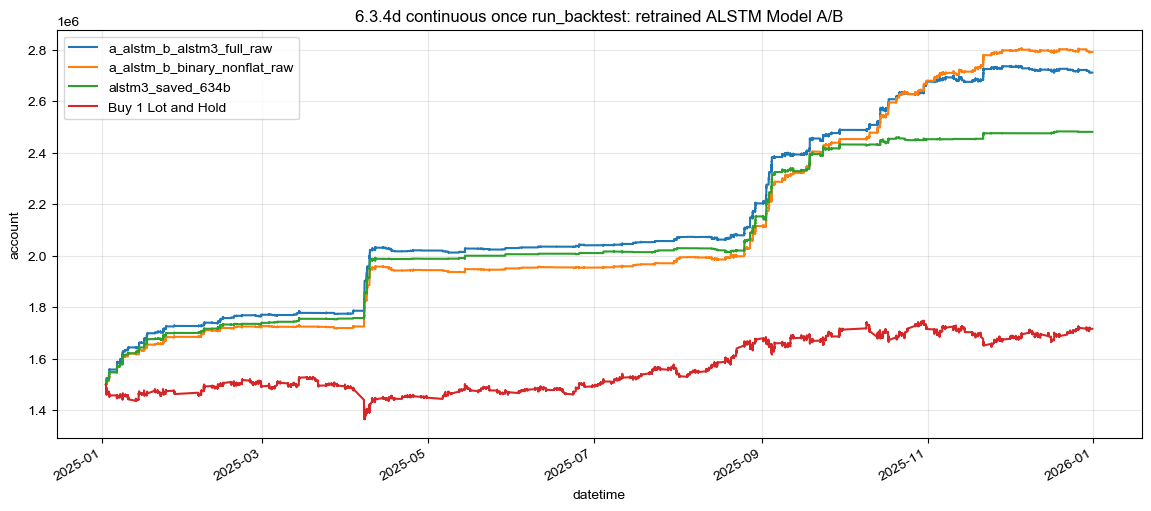

,strategy,backtest_mode,trade_count,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown
0,alstm3_saved_634b,continuous_once_run_backtest_signal,6130,58320,1500000.0,2.480936e+06,9.809361e+05,0.653957,0.058920,14.490035,-0.008333
1,a_alstm_b_alstm3_full_raw,continuous_once_run_backtest_signal,12408,58320,1500000.0,2.711101e+06,1.211101e+06,0.807401,0.061750,15.185880,-0.010700
2,a_alstm_b_binary_nonflat_raw,continuous_once_run_backtest_signal,12686,58320,1500000.0,2.790957e+06,1.290957e+06,0.860638,0.065065,16.001135,-0.012756
3,Buy 1 Lot and Hold,continuous_buy_hold,1,58080,1500000.0,1.715873e+06,2.158726e+05,0.143915,0.005590,1.374672,-0.107603


6.3.4d 输出目录: artifacts/if_alstm_rolling_3state_intra_2025/pv3_two_stage_trade_direction_model_b_compare/alstm3_retrain_ab_split_raw_634d


,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time,strategy,description,trade_count,signal_ratio,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown,trade_prob_threshold,long_dir_prob_threshold,short_dir_prob_threshold,long_dir_margin_threshold,short_dir_margin_threshold,dir_logit_center,dir_calibration_method,use_future_vol_filter,direction_balance_pass,valid_selected_score,valid_selected_absolute_pnl,valid_selected_annualized_sharpe,valid_selected_max_drawdown,valid_selected_trade_count,signal_count,trade_precision,raw_sign_win_rate,direction_accuracy,signed_return_mean,signed_return_median,long_signal_count,short_signal_count,samples,initial_account,model_b_train_scope,selected_score,selected_model_a_precision,selected_model_a_recall,selected_model_a_constraint_pass,selected_strict_pass,selected_params
0,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,alstm3_saved_634b,6.3.4b 原始 ALSTM3 曲线,NaN,NaN,1.755551e+06,255550.981597,0.170367,0.068342,16.402008,-0.004849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,a_alstm_b_alstm3_full_raw,Model A 重训 + Model B full 复用 6.3.4b ALSTM3 代码重...,2466.0,0.187840,1.774497e+06,274496.796050,0.182998,0.072341,17.361893,-0.006542,0.80,0.50,0.55,0.14,0.18,0.2,valid_backtest_grid,False,1.0,32.173681,2.614369e+06,28.265687,-0.006780,8810.0,2209.0,0.726573,0.592123,0.592123,0.000331,0.000336,907.0,1302.0,13680.0,1500000.0,full,32.173681,NaN,NaN,NaN,NaN,"{'trade_prob_threshold': 0.8, 'long_dir_prob_t..."
2,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,a_alstm_b_binary_nonflat_raw,Model A 重训 + Model B non-flat 样本方向二分类 + 6.3.4b...,2562.0,0.173384,1.719054e+06,219053.687593,0.146036,0.059427,14.262474,-0.007854,0.80,0.50,0.55,0.14,0.18,0.0,valid_backtest_grid,False,1.0,30.979992,2.449346e+06,27.318557,-0.006292,9182.0,2039.0,0.717018,0.587543,0.587543,0.000335,0.000319,1065.0,974.0,13680.0,1500000.0,nonflat_binary,30.979992,NaN,NaN,NaN,NaN,"{'trade_prob_threshold': 0.8, 'long_dir_prob_t..."
3,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,alstm3_saved_634b,6.3.4b 原始 ALSTM3 曲线,NaN,NaN,1.754684e+06,254684.350972,0.169790,0.070064,16.815358,-0.004962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,a_alstm_b_alstm3_full_raw,Model A 重训 + Model B full 复用 6.3.4b ALSTM3 代码重...,1420.0,0.105165,1.765709e+06,265709.429429,0.177140,0.069884,16.772253,-0.012370,0.75,0.55,0.50,0.18,0.14,0.2,valid_backtest_grid,False,1.0,28.764073,2.131412e+06,25.584135,-0.008590,11084.0,1303.0,0.698388,0.580967,0.580967,0.000415,0.000292,420.0,883.0,14400.0,1500000.0,full,28.764073,NaN,NaN,NaN,NaN,"{'trade_prob_threshold': 0.75, 'long_dir_prob_..."
5,2025-04,12,6,3,3,2023-10-01,2024-09-30,2024-10-01,2025-03-31,2025-04-01,2025-06-30,a_alstm_b_binary_nonflat_raw,Model A 重训 + Model B non-flat 样本方向二分类 + 6.3.4b...,1510.0,0.106134,1.734547e+06,234546.564331,0.156364,0.061257,14.701612,-0.014361,0.75,0.55,0.50,0.18,0.14,0.3,valid_backtest_grid,False,1.0,30.748885,2.247616e+06,27.389149,-0.005844,11370.0,1315.0,0.701141,0.584030,0.584030,0.000432,0.000296,443.0,872.0,14400.0,1500000.0,nonflat_binary,30.748885,NaN,NaN,NaN,NaN,"{'trade_prob_threshold': 0.75, 'long_dir_prob_..."
6,2025-07,12,6,3,3,2024-01-01,2024-12-31,2025-01-01,2025-06-30,2025-07-01,2025-09-30,alstm3_saved_634b,6.3.4b 原始 ALSTM3 曲线,NaN,NaN,1.921651e+06,421651.301206,0.281101,0.065559,15.734263,-0.011131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2025-07,12,6,3,3,2024-

,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time,model_b_strategy,use_future_vol_filter,trade_prob_threshold,dir_prob_threshold,dir_margin_threshold,dir_logit_center,dir_calibration_method,signal_count,signal_ratio,trade_precision,raw_sign_win_rate,direction_accuracy,signed_return_mean,signed_return_median,long_signal_count,short_signal_count,direction_side_share,direction_long_short_ratio,min_signal_ratio_pass,direction_balance_pass,valid_absolute_pnl,valid_annualized_sharpe,valid_max_drawdown,valid_trade_count,score,long_dir_prob_threshold,short_dir_prob_threshold,long_dir_margin_threshold,short_dir_margin_threshold
112,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,a_alstm_b_alstm3_full_raw,False,0.80,NaN,NaN,0.2,valid_backtest_grid,8240,0.316436,0.770631,0.590291,0.590291,0.000543,0.000410,3398,4842,0.412379,1.424956,1,1,2.614369e+06,28.265687,-0.006780,8810,32.173681,0.50,0.55,0.14,0.18
78,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,a_alstm_b_alstm3_full_raw,False,0.75,NaN,NaN,0.2,valid_backtest_grid,10621,0.407873,0.732794,0.586950,0.586950,0.000475,0.000346,4200,6421,0.395443,1.528810,1,1,2.674796e+06,28.034742,-0.009511,11318,32.027913,0.50,0.58,0.14,0.18
94,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,a_alstm_b_alstm3_full_raw,False,0.75,NaN,NaN,0.1,valid_backtest_grid,10618,0.407757,0.733095,0.586080,0.586080,0.000473,0.000345,4304,6314,0.405349,1.467007,1,1,2.651646e+06,27.786731,-0.009466,11380,31.745268,0.55,0.50,0.18,0.14
111,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,a_alstm_b_alstm3_full_raw,False,0.80,NaN,NaN,0.1,valid_backtest_grid,8193,0.314631,0.771634,0.588673,0.588673,0.000547,0.000409,3794,4399,0.463078,1.159462,1,1,2.549814e+06,27.909316,-0.005066,8884,31.723905,0.50,0.55,0.14,0.18
44,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,a_alstm_b_alstm3_full_raw,False,0.75,0.5,0.14,0.2,valid_backtest_grid,11125,0.427227,0.730157,0.584360,0.584360,0.000458,0.000328,4200,6925,0.377528,1.648810,1,1,2.678410e+06,27.709419,-0.009086,11442,31.708862,NaN,NaN,NaN,NaN
93,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,a_alstm_b_alstm3_full_raw,False,0.75,NaN,NaN,0.0,valid_backtest_grid,10498,0.403149,0.733664,0.586016,0.586016,0.000485,0.000347,4812,5686,0.458373,1.181629,1,1,2.611305e+06,27.796310,-0.012099,11430,31.689069,0.55,0.50,0.18,0.14
110,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,a_alstm_b_alstm3_full_raw,False,0.80,NaN,NaN,0.0,valid_backtest_grid,8033,0.308487,0.774430,0.589568,0.589568,0.000561,0.000421,4153,3880,0.483008,1.070361,1,1,2.510854e+06,27.916127,-0.005362,8760,31.671684,0.50,0.55,0.14,0.18
43,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,a_alstm_b_alstm3_full_raw,False,0.75,0.5,0.14,0.1,valid_backtest_grid,11036,0.423810,0.732693,0.583364,0.583364,0.000466,0.000331,4722,6314,0.427872,1.337145,1,1,2.661894e+06,27.605540,-0.011052,11680,31.576278,NaN,NaN,NaN,NaN
109,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,a_alstm_b_alstm3_full_raw,False,0.80,NaN,NaN,-0.1,valid_backtest_grid,7990,0.306836,0.775720,0.587484,0.587484,0.000556,0.000415,4556,3434,0.429787,1.326733,1,1,2.474963e+06,27.753761,-0.004814,8628,31.456577,0.50,0.55,0.14,0.18
77,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,a_alstm_b_alstm3_full_raw,False,0.75,NaN,NaN,0.1,valid_backtest_grid,10540,0.404762,0.733871,0.585389,0.585389,0.000481,0.000344,4722,5818,0.448008,1.232105,1,1,2.596981e+06,27.561785,-0.012474,11460,31.432308,0.50,0.58,0.14,0.18


In [24]:
# ===== 6.3.4d) Pv3 ALSTM3：Model A/B 两套因子 ALSTM 重训对比 =====
# 与 6.3.4 的区别：6.3.4 使用合并后的主线 ALSTM3 Model B；6.3.4d 会重新训练 Model A，并对 Model B 做 full / nonflat binary 两条改造线。
# Model A = ALSTM 二分类 trade filter，使用交易/环境/活跃度因子池。
# Model B = ALSTM 三分类或 nonflat binary direction classifier，使用方向/相对收益/tick 一档因子池。
# 最终测试口径以后以连续 run_backtest 复核单元为准；本单元重点保存重训预测、阈值和逐窗口诊断。

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import traceback

try:
    display
except NameError:
    def display(x):
        print(x)

_pv3_634d_pre_required = [
    "artifact_root", "account", "pv3_b_threshold_grid",
    "pv3_b_label_threshold", "pv3_trade_model_params", "pv3_dir_model_params",
]
_pv3_634d_pre_missing = [name for name in _pv3_634d_pre_required if name not in globals()]
if _pv3_634d_pre_missing:
    raise NameError("6.3.4d 缺少前置变量，请先运行 6.3.4b 及其前置单元: " + ", ".join(_pv3_634d_pre_missing))

pv3_634d_root = artifact_root / "pv3_two_stage_trade_direction_model_b_compare"
pv3_634d_output_root = pv3_634d_root / "alstm3_retrain_ab_split_raw_634d"
pv3_634d_output_root.mkdir(parents=True, exist_ok=True)

pv3_634d_strategy_name = "alstm3"
pv3_634d_model_a_type = "retrained_alstm_binary_trade_filter"
pv3_634d_model_b_type = "retrained_alstm3_direction"
pv3_634d_account = float(account)
pv3_634d_min_valid_signal_ratio = 0.05
pv3_634d_min_valid_trades = 20
pv3_634d_target_model_a_precision = 0.70
pv3_634d_target_model_a_recall = 0.40  # precision 优先；recall 超过 40% 即可，越高越好
# Model A valid 搜索分层约束：先尽量满足 70/40；不行放松 recall 到 30；再放松 precision 到 60。
pv3_634d_model_a_constraint_tiers = [
    {"name": "p70_r40", "precision": 0.70, "recall": 0.40, "priority": 4},
    {"name": "p70_r30", "precision": 0.70, "recall": 0.30, "priority": 3},
    {"name": "p60_r40", "precision": 0.60, "recall": 0.40, "priority": 2},
    {"name": "p60_r30", "precision": 0.60, "recall": 0.30, "priority": 1},
]
pv3_634d_min_final_direction_win = 0.52
pv3_634d_model_a_precision_weight = 0.00020
pv3_634d_model_a_recall_weight = 0.00006
pv3_634d_direction_win_weight = 0.00010
pv3_634d_model_b_flat_weight_floor = 0.30  # soft non-flat: flat/low-return 样本保留 30% 权重
pv3_634d_center_grid = np.round(np.linspace(-0.8, 0.8, 17), 4).tolist()
pv3_634d_threshold_grid = list(pv3_b_threshold_grid)


def _pv3_634d_get_windows() -> list[dict]:
    """Allow 6.3.4d to run after kernel restarts when only windows_df is available."""
    if "pv3_windows" in globals() and globals()["pv3_windows"] is not None:
        obj = globals()["pv3_windows"]
        if isinstance(obj, pd.DataFrame):
            return obj.to_dict("records")
        return [dict(x) for x in obj]
    if "windows_df" in globals() and windows_df is not None and not windows_df.empty:
        return windows_df.to_dict("records")
    if "make_rolling_windows" in globals():
        required = ["rolling_test_start", "rolling_test_end", "train_months", "valid_months", "test_months"]
        missing = [x for x in required if x not in globals()]
        if missing:
            raise NameError("缺少滚动窗口参数: " + ", ".join(missing))
        step = globals().get("rolling_step_months", globals().get("step_months", None))
        return make_rolling_windows(rolling_test_start, rolling_test_end, train_months, valid_months, test_months, step).to_dict("records")
    raise NameError("未找到 pv3_windows/windows_df/make_rolling_windows；请先运行滚动窗口配置单元")


def _pv3_634d_period_end(value) -> pd.Timestamp:
    end = pd.Timestamp(value)
    return end + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1) if end == end.normalize() else end



def _pv3_634d_load_634b_curve(window_id: str, strategy_name: str = "alstm3") -> pd.DataFrame | None:
    """Load the saved 6.3.4b baseline curve for the same rolling window."""
    window_id = str(window_id)
    candidates = []
    if "pv3_b_compare_output_root" in globals():
        candidates.append(Path(pv3_b_compare_output_root) / window_id / f"{strategy_name}_account_curve.csv")
        candidates.append(Path(pv3_b_compare_output_root) / window_id / "alstm3_account_curve.csv")
    if "artifact_root" in globals():
        candidates.append(Path(artifact_root) / "pv3_two_stage_trade_direction_model_b_compare" / window_id / f"{strategy_name}_account_curve.csv")
        candidates.append(Path(artifact_root) / "pv3_two_stage_trade_direction_model_b_compare" / window_id / "alstm3_account_curve.csv")
    for path in candidates:
        if not path.exists():
            continue
        df = pd.read_csv(path)
        if "datetime" not in df.columns:
            df = df.reset_index().rename(columns={df.columns[0]: "datetime"})
        if "account" not in df.columns:
            account_cols = [c for c in df.columns if str(c).lower().endswith("account") or str(c).lower() == strategy_name.lower()]
            if account_cols:
                df = df.rename(columns={account_cols[0]: "account"})
        if "datetime" in df.columns and "account" in df.columns:
            df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
            df["account"] = pd.to_numeric(df["account"], errors="coerce")
            return df.dropna(subset=["datetime", "account"]).sort_values("datetime")[["datetime", "account"]]
    print(f"{window_id}: 未找到 6.3.4b {strategy_name} 基线曲线，已尝试: " + " | ".join(str(x) for x in candidates[:4]))
    return None

def _pv3_634d_account_metrics(account_series: pd.Series, initial_account: float) -> dict:
    s = pd.to_numeric(account_series, errors="coerce").dropna()
    if s.empty:
        return {"final_account": np.nan, "absolute_pnl": np.nan, "total_return": np.nan, "sharpe_ratio": np.nan, "annualized_sharpe": np.nan, "max_drawdown": np.nan}
    ret = s.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
    std = float(ret.std()) if len(ret) > 1 else np.nan
    sharpe = float(ret.mean() / std) if np.isfinite(std) and std > 0 else np.nan
    return {
        "final_account": float(s.iloc[-1]),
        "absolute_pnl": float(s.iloc[-1] - initial_account),
        "total_return": float(s.iloc[-1] / initial_account - 1.0),
        "sharpe_ratio": sharpe,
        "annualized_sharpe": float(sharpe * np.sqrt(240 * 240)) if np.isfinite(sharpe) else np.nan,
        "max_drawdown": float((s / s.cummax() - 1.0).min()),
    }

def _pv3_634d_trade_feature_cols(frame: pd.DataFrame, base_feature_cols: list[str], tick_cols: list[str]) -> list[str]:
    # Model A: 是否交易/幅度过滤。扩大到“环境 + 活跃度 + 价格位置/趋势/短动量”，但不直接加入方向专用 dir_*。
    keys = [
        "volatility", "volatility_regime", "atr", "volume", "turnover", "trade_", "flow_", "vpin", "ofi",
        "tick_count", "size", "spread", "microprice", "book_imbalance", "depth", "liq_",
        "volume_ratio", "volume_persistence", "bb_width", "bb_position", "high_low", "vwap_gap",
        "tick_l1", "imbalance", "delta", "open_interest",
        "return", "momentum", "mom", "intra_mom", "trend", "price_acceleration",
        "price_position", "sma", "sma_cross", "mid_price", "vwap_ratio", "close_open",
        "rsi", "mfi", "cci", "cmo", "williams", "k_percent", "d_percent",
        "open", "high", "low", "close", "vwap",
    ]
    cols = [c for c in base_feature_cols if any(k in str(c).lower() for k in keys)]
    cols.extend([c for c in tick_cols if c in frame.columns])
    return [c for c in dict.fromkeys(cols) if c in frame.columns]


def _pv3_634d_direction_feature_cols(frame: pd.DataFrame, base_feature_cols: list[str], dir_cols: list[str], tick_cols: list[str]) -> list[str]:
    # Model B: 方向。恢复 6.3.4b 的完整基础分钟因子池，再叠加方向专用因子和 tick 一档方向冲击。
    cols = list(base_feature_cols)
    cols.extend([c for c in dir_cols if c in frame.columns])
    cols.extend([c for c in tick_cols if c in frame.columns])
    return [c for c in dict.fromkeys(cols) if c in frame.columns]


def _pv3_634d_weight_from_abs_return(frame: pd.DataFrame, threshold: float, name: str) -> pd.Series:
    raw = pd.to_numeric(frame["pv3_future_return"], errors="coerce").replace([np.inf, -np.inf], np.nan).abs()
    denom = max(abs(float(threshold)), 1e-12)
    weight = (1.0 + 1.5 * (raw / denom).clip(lower=0.0)).clip(0.5, 5.0)
    mean = float(weight.dropna().mean()) if len(weight.dropna()) else np.nan
    if np.isfinite(mean) and mean > 0:
        weight = weight / mean
    return pd.Series(weight, index=frame.index, name=name).fillna(1.0).astype("float32")


def _pv3_634d_predict_trade_segment(model, ts_dataset, params: dict, segment: str) -> pd.DataFrame:
    prob, _, _, _ = alstm_model_module.predict_state_classifier(
        model,
        ts_dataset,
        segment=segment,
        batch_size=int(params.get("batch_size", 128)),
        state_threshold=0.5,
        class_names={0: "no_trade", 1: "trade"},
    )
    prob = _pv3_prob_to_datetime_frame(prob)
    out = pd.DataFrame(index=prob.index)
    out["datetime"] = out.index
    out["period"] = segment
    out["trade_prob"] = pd.to_numeric(prob.get("prob_trade"), errors="coerce")
    out["no_trade_prob"] = pd.to_numeric(prob.get("prob_no_trade"), errors="coerce")
    return out.reset_index(drop=True)


def _pv3_634d_predict_dir3_segment(model, ts_dataset, params: dict, segment: str) -> pd.DataFrame:
    prob, _, _, _ = alstm_model_module.predict_state_classifier(
        model,
        ts_dataset,
        segment=segment,
        batch_size=int(params.get("batch_size", 128)),
        state_threshold=0.5,
        class_names={0: "dir_down", 1: "dir_uncertain", 2: "dir_up"},
    )
    prob = _pv3_prob_to_datetime_frame(prob)
    out = pd.DataFrame(index=prob.index)
    out["datetime"] = out.index
    out["period"] = segment
    out["prob_dir_down"] = pd.to_numeric(prob.get("prob_dir_down"), errors="coerce")
    out["prob_dir_uncertain"] = pd.to_numeric(prob.get("prob_dir_uncertain"), errors="coerce")
    out["prob_dir_up"] = pd.to_numeric(prob.get("prob_dir_up"), errors="coerce")
    return out.reset_index(drop=True)


def _pv3_634d_predict_dir_binary_segment(model, ts_dataset, params: dict, segment: str) -> pd.DataFrame:
    prob, _, _, _ = alstm_model_module.predict_state_classifier(
        model,
        ts_dataset,
        segment=segment,
        batch_size=int(params.get("batch_size", 128)),
        state_threshold=0.5,
        class_names={0: "dir_down", 1: "dir_up"},
    )
    prob = _pv3_prob_to_datetime_frame(prob)
    out = pd.DataFrame(index=prob.index)
    out["datetime"] = out.index
    out["period"] = segment
    out["prob_dir_down"] = pd.to_numeric(prob.get("prob_dir_down"), errors="coerce")
    out["prob_dir_up"] = pd.to_numeric(prob.get("prob_dir_up"), errors="coerce")
    return out.reset_index(drop=True)




def _pv3_634d_ensure_model_b_labels(frame: pd.DataFrame) -> pd.DataFrame:
    """Mirror 6.3.4b label preparation required by ALSTM3 Model B."""
    out = frame.copy()
    ret = pd.to_numeric(out["pv3_future_return"], errors="coerce")
    if "pv3_label_dir_bin" not in out.columns:
        out["pv3_label_dir_bin"] = (ret > 0).astype("int64")
    if "pv3_label_dir3" not in out.columns:
        out["pv3_label_dir3"] = 1
        thr = float(globals().get("pv3_b_strong_dir_threshold", globals().get("pv3_b_label_threshold", 0.0006)))
        out.loc[ret > thr, "pv3_label_dir3"] = 2
        out.loc[ret < -thr, "pv3_label_dir3"] = 0
        out["pv3_label_dir3"] = out["pv3_label_dir3"].astype("int64")
    if "pv3_dir_loss_weight" not in out.columns:
        if "_pv3_make_direction_loss_weight" in globals():
            out["pv3_dir_loss_weight"] = _pv3_make_direction_loss_weight(out, pv3_b_label_threshold)
        else:
            out["pv3_dir_loss_weight"] = _pv3_634d_weight_from_abs_return(out, pv3_b_label_threshold, "pv3_dir_loss_weight")
    return out

def _pv3_634d_train_alstm_ab(frame: pd.DataFrame, feature_cols_a: list[str], feature_cols_b: list[str], window: dict, window_dir: Path):
    trade_dataset = _pv3_build_dataset_from_frame(frame, feature_cols_a, "pv3_label_trade", window)
    trade_ts_dataset = _pv3_to_ts_dataset(trade_dataset, window)
    dir_dataset = _pv3_build_dataset_from_frame(frame, feature_cols_b, "pv3_label_dir3", window)
    dir_ts_dataset = _pv3_to_ts_dataset(dir_dataset, window)
    dir_bin_dataset = _pv3_build_dataset_from_frame(frame, feature_cols_b, "pv3_label_dir_bin", window)
    dir_bin_ts_dataset = _pv3_to_ts_dataset(dir_bin_dataset, window)

    trade_params = dict(pv3_trade_model_params)
    trade_params.update({
        "state_num_classes": 2,
        "state_class_names": {0: "no_trade", 1: "trade"},
        "state_class_weight_mode": "sqrt_balanced",
        "state_class_weight_clip": (0.5, 3.0),
        "seed": 6341,
    })
    dir_params_base = dict(pv3_dir_model_params)
    dir_params_base.update({
        "state_num_classes": 3,
        "state_class_names": {0: "dir_down", 1: "dir_uncertain", 2: "dir_up"},
        "state_class_weight_mode": "sqrt_balanced",
        "state_class_weight_clip": (0.5, 3.0),
        "n_epochs": int(pv3_b_alstm3_epochs),
        "early_stop": int(pv3_b_alstm3_early_stop),
    })

    frame["pv3_trade_loss_weight_634d"] = _pv3_634d_weight_from_abs_return(frame, pv3_b_label_threshold, "pv3_trade_loss_weight_634d")
    trade_weight = _pv3_weight_series(frame, "pv3_trade_loss_weight_634d", window)
    frame["pv3_dir_loss_weight_full_634d"] = pd.to_numeric(frame["pv3_dir_loss_weight"], errors="coerce").fillna(1.0).clip(0.0, 10.0)

    trade_result = alstm_model_module.train_state_classifier(
        trade_ts_dataset,
        d_feat=len(feature_cols_a),
        model_params=trade_params,
        state_threshold=0.5,
        state_sample_weight_by_segment=trade_weight,
        model_save_path=window_dir / "pv3_634d_model_a_trade_filter.pt",
        show_progress=True,
    )
    trade_result["evals_result"].to_csv(window_dir / "pv3_634d_model_a_trade_evals.csv", index=False, encoding="utf-8-sig")

    trade_pred_by_segment = {}
    for segment in ["valid", "test"]:
        trade_pred_by_segment[segment] = _pv3_634d_predict_trade_segment(trade_result["model"], trade_ts_dataset, trade_params, segment)

    pred_by_scope = {}
    dir_results = {}

    # full: Model B 完全复用 6.3.4b 的 ALSTM3 训练/预测 helper。
    # 这样 full 分支的 Model B 代码路径、参数、label、sample weight、seed 与 6.3.4b 一致；
    # 区别只在 trade_prob 来自本单元重训的 Model A。
    full_valid_dir, full_test_dir, full_dir_result = _pv3_b_alstm3_predict_frames(frame, feature_cols_b, window, window_dir)
    dir_results["full"] = full_dir_result
    full_valid = _pv3_b_attach_trade_and_labels(full_valid_dir, trade_pred_by_segment["valid"], frame)
    full_test = _pv3_b_attach_trade_and_labels(full_test_dir, trade_pred_by_segment["test"], frame)
    full_valid["model_b_train_scope"] = "full"
    full_test["model_b_train_scope"] = "full"
    pred_by_scope["full"] = {"valid": full_valid, "test": full_test}

    # nonflat_binary: 方向二分类，训练时只让 non-flat 样本有效参与 loss。
    # 用全 frame 做 dataset 是为了保持 valid/test 预测覆盖完整时间轴；训练权重中 flat 样本为 0。
    dir_bin_params = dict(pv3_dir_model_params)
    dir_bin_params.update({
        "state_num_classes": 2,
        "state_class_names": {0: "dir_down", 1: "dir_up"},
        "state_class_weight_mode": "sqrt_balanced",
        "state_class_weight_clip": (0.5, 3.0),
        "n_epochs": int(pv3_b_alstm3_epochs),
        "early_stop": int(pv3_b_alstm3_early_stop),
        "seed": 6346,
    })
    frame["pv3_dir_loss_weight_nonflat_binary_634d"] = (
        pd.to_numeric(frame["pv3_dir_loss_weight"], errors="coerce").fillna(1.0).clip(0.0, 10.0)
        * pd.to_numeric(frame["pv3_label_trade"], errors="coerce").fillna(0.0).clip(0.0, 1.0)
    )
    dir_bin_weight = _pv3_weight_series(frame, "pv3_dir_loss_weight_nonflat_binary_634d", window)
    dir_bin_result = alstm_model_module.train_state_classifier(
        dir_bin_ts_dataset,
        d_feat=len(feature_cols_b),
        model_params=dir_bin_params,
        state_threshold=0.5,
        state_sample_weight_by_segment=dir_bin_weight,
        model_save_path=window_dir / "pv3_634d_model_b_binary_direction_nonflat.pt",
        show_progress=True,
    )
    dir_results["nonflat_binary"] = dir_bin_result
    dir_bin_result["evals_result"].to_csv(window_dir / "pv3_634d_model_b_direction_nonflat_binary_evals.csv", index=False, encoding="utf-8-sig")
    out = {}
    for segment in ["valid", "test"]:
        dir_pred = _pv3_634d_predict_dir_binary_segment(dir_bin_result["model"], dir_bin_ts_dataset, dir_bin_params, segment)
        trade_pred = trade_pred_by_segment[segment]
        pred = dir_pred.merge(trade_pred[["datetime", "trade_prob", "no_trade_prob"]].drop_duplicates("datetime"), on="datetime", how="outer")
        pred = _pv3_634d_attach_labels(pred, frame)
        pred["model_b_train_scope"] = "nonflat_binary"
        out[segment] = pred
    pred_by_scope["nonflat_binary"] = out

    return pred_by_scope, trade_result, dir_results

def _pv3_634d_attach_labels(pred: pd.DataFrame, frame: pd.DataFrame) -> pd.DataFrame:
    out = pred.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    labels = frame[["datetime", "pv3_future_return", "pv3_label_trade", "pv3_label_dir", "pv3_label_dir_bin", "pv3_label_dir3"]].copy()
    labels["datetime"] = pd.to_datetime(labels["datetime"], errors="coerce")
    out = out.drop(columns=[c for c in labels.columns if c in out.columns and c != "datetime"], errors="ignore")
    return out.merge(labels.drop_duplicates("datetime"), on="datetime", how="left")




def _pv3_634d_model_a_quality(pred: pd.DataFrame, trade_prob_threshold: float) -> dict:
    if pred is None or pred.empty or "trade_prob" not in pred.columns or "pv3_label_trade" not in pred.columns:
        return {
            "model_a_precision": np.nan,
            "model_a_recall": np.nan,
            "model_a_accuracy": np.nan,
            "model_a_pred_trade_ratio": np.nan,
            "model_a_true_trade_ratio": np.nan,
            "model_a_constraint_pass": False,
        }
    y = pd.to_numeric(pred["pv3_label_trade"], errors="coerce")
    prob = pd.to_numeric(pred["trade_prob"], errors="coerce")
    mask = y.notna() & prob.notna()
    if not mask.any():
        return {
            "model_a_precision": np.nan,
            "model_a_recall": np.nan,
            "model_a_accuracy": np.nan,
            "model_a_pred_trade_ratio": np.nan,
            "model_a_true_trade_ratio": np.nan,
            "model_a_constraint_pass": False,
        }
    y = y.loc[mask].astype(int)
    pred_trade = prob.loc[mask] >= float(trade_prob_threshold)
    tp = float(((pred_trade) & (y == 1)).sum())
    fp = float(((pred_trade) & (y == 0)).sum())
    fn = float(((~pred_trade) & (y == 1)).sum())
    tn = float(((~pred_trade) & (y == 0)).sum())
    precision = tp / (tp + fp) if tp + fp > 0 else np.nan
    recall = tp / (tp + fn) if tp + fn > 0 else np.nan
    accuracy = (tp + tn) / len(y) if len(y) else np.nan
    pred_ratio = float(pred_trade.mean()) if len(pred_trade) else np.nan
    true_ratio = float((y == 1).mean()) if len(y) else np.nan
    return {
        "model_a_precision": float(precision) if np.isfinite(precision) else np.nan,
        "model_a_recall": float(recall) if np.isfinite(recall) else np.nan,
        "model_a_accuracy": float(accuracy) if np.isfinite(accuracy) else np.nan,
        "model_a_pred_trade_ratio": pred_ratio,
        "model_a_true_trade_ratio": true_ratio,
        "model_a_tp": tp,
        "model_a_fp": fp,
        "model_a_fn": fn,
        "model_a_tn": tn,
        "model_a_constraint_pass": bool(
            np.isfinite(precision) and np.isfinite(recall)
            and precision >= float(pv3_634d_target_model_a_precision)
            and recall >= float(pv3_634d_target_model_a_recall)
        ),
    }


def _pv3_634d_model_a_constraint_level(precision, recall) -> dict:
    precision = float(precision) if np.isfinite(precision) else np.nan
    recall = float(recall) if np.isfinite(recall) else np.nan
    for tier in pv3_634d_model_a_constraint_tiers:
        if (
            np.isfinite(precision)
            and np.isfinite(recall)
            and precision >= float(tier["precision"])
            and recall >= float(tier["recall"])
        ):
            return {
                "model_a_constraint_level": tier["name"],
                "model_a_constraint_priority": int(tier["priority"]),
                "model_a_tier_precision_min": float(tier["precision"]),
                "model_a_tier_recall_min": float(tier["recall"]),
                "model_a_tier_pass": True,
            }
    return {
        "model_a_constraint_level": "below_p60_r30",
        "model_a_constraint_priority": 0,
        "model_a_tier_precision_min": np.nan,
        "model_a_tier_recall_min": np.nan,
        "model_a_tier_pass": False,
    }


def _pv3_634d_signal_quality(pred: pd.DataFrame, sig: pd.Series) -> dict:
    q = dict(_pv3_signal_quality(pred, sig) or {})
    p = pred.copy()
    if "datetime" in p.columns:
        p["datetime"] = pd.to_datetime(p["datetime"], errors="coerce")
        p = p.dropna(subset=["datetime"]).drop_duplicates("datetime").set_index("datetime")
    else:
        p.index = pd.to_datetime(p.index, errors="coerce")
        p = p[~p.index.isna()]
    s = pd.Series(sig).copy()
    s.index = pd.to_datetime(s.index, errors="coerce")
    s = s[~s.index.isna()].astype(float)
    common = p.index.intersection(s.index)
    if len(common) == 0:
        q.setdefault("trade_count", 0.0)
        q.setdefault("signal_ratio", 0.0)
        q.setdefault("signed_mean", np.nan)
        q.setdefault("raw_direction_win_rate", np.nan)
        return q
    s = s.loc[common]
    p = p.loc[common]
    trade = s.abs() > 0
    q["trade_count"] = float(trade.sum())
    q["signal_ratio"] = float(trade.mean()) if len(trade) else 0.0
    if trade.any() and "pv3_future_return" in p.columns:
        ret = pd.to_numeric(p.loc[trade, "pv3_future_return"], errors="coerce")
        direction = np.sign(s.loc[trade])
        signed_ret = ret * direction
        signed_ret = signed_ret.replace([np.inf, -np.inf], np.nan).dropna()
        q["signed_mean"] = float(signed_ret.mean()) if not signed_ret.empty else np.nan
        q["raw_direction_win_rate"] = float((signed_ret > 0).mean()) if not signed_ret.empty else np.nan
        q["signed_sum"] = float(signed_ret.sum()) if not signed_ret.empty else np.nan
    else:
        q.setdefault("signed_mean", np.nan)
        q.setdefault("raw_direction_win_rate", np.nan)
    return q

def _pv3_634d_select_threshold(pred: pd.DataFrame, window: dict, strategy_name: str):
    rows = []
    best = None
    best_soft = None
    if pred is None or pred.empty:
        raise ValueError(f"{window.get('window_id', '')} 6.3.4d valid prediction 为空")
    for params in pv3_634d_threshold_grid:
        for center in pv3_634d_center_grid:
            trial_params = dict(params)
            trial_params["dir_center"] = float(center)
            trade_thr = float(trial_params.get("trade_prob_threshold", 0.5))
            sig = _pv3_b_make_signal(pred, trial_params, use_future_vol_filter=False, future_vol=None)
            q = _pv3_634d_signal_quality(pred, sig)
            aq = _pv3_634d_model_a_quality(pred, trade_thr)
            sig_ratio = float(q.get("signal_ratio", 0.0) or 0.0)
            trade_count = float(q.get("trade_count", 0.0) or 0.0)
            signed_mean = float(q.get("signed_mean", np.nan)) if np.isfinite(q.get("signed_mean", np.nan)) else np.nan
            dir_win = float(q.get("raw_direction_win_rate", np.nan)) if np.isfinite(q.get("raw_direction_win_rate", np.nan)) else np.nan
            model_a_precision = float(aq.get("model_a_precision", np.nan)) if np.isfinite(aq.get("model_a_precision", np.nan)) else np.nan
            model_a_recall = float(aq.get("model_a_recall", np.nan)) if np.isfinite(aq.get("model_a_recall", np.nan)) else np.nan
            pass_min = sig_ratio >= pv3_634d_min_valid_signal_ratio and trade_count >= pv3_634d_min_valid_trades
            pass_model_a = bool(aq.get("model_a_constraint_pass", False))
            tier_info = _pv3_634d_model_a_constraint_level(model_a_precision, model_a_recall)
            pass_dir = np.isfinite(dir_win) and dir_win >= float(pv3_634d_min_final_direction_win)

            base_score = signed_mean if np.isfinite(signed_mean) else -1.0
            soft_score = base_score
            if np.isfinite(model_a_precision):
                soft_score += pv3_634d_model_a_precision_weight * (model_a_precision - pv3_634d_target_model_a_precision)
            else:
                soft_score -= pv3_634d_model_a_precision_weight
            if np.isfinite(model_a_recall):
                soft_score += pv3_634d_model_a_recall_weight * (model_a_recall - pv3_634d_target_model_a_recall)
            else:
                soft_score -= pv3_634d_model_a_recall_weight
            if np.isfinite(dir_win):
                soft_score += pv3_634d_direction_win_weight * (dir_win - pv3_634d_min_final_direction_win)
            else:
                soft_score -= pv3_634d_direction_win_weight
            if not pass_min:
                soft_score -= 1.0

            strict_pass = bool(pass_min and pass_model_a and pass_dir and np.isfinite(signed_mean))
            candidate_score = float(soft_score) if strict_pass else -np.inf
            row = {
                **{f"param_{k}": v for k, v in trial_params.items()},
                **q,
                **aq,
                "score": candidate_score,
                "soft_score": float(soft_score) if np.isfinite(soft_score) else -np.inf,
                "pass_min_valid_signal": bool(pass_min),
                "pass_model_a_precision_recall": bool(pass_model_a),
                **tier_info,
                "pass_final_direction_win": bool(pass_dir),
                "strict_pass": strict_pass,
                "strategy": strategy_name,
                "window_id": window.get("window_id"),
            }
            rows.append(row)
            if pass_min and np.isfinite(soft_score):
                if best_soft is None or soft_score > best_soft["score"]:
                    best_soft = {"score": float(soft_score), "params": trial_params, "quality": row}
            if candidate_score == -np.inf:
                continue
            if best is None or candidate_score > best["score"]:
                best = {"score": candidate_score, "params": trial_params, "quality": row}
    valid_rows = pd.DataFrame(rows)
    eligible = valid_rows.replace([np.inf, -np.inf], np.nan) if not valid_rows.empty else pd.DataFrame()
    if eligible.empty:
        raise ValueError(f"{window.get('window_id', '')} 6.3.4d valid 阈值搜索无候选")

    sort_col = "soft_score" if "soft_score" in eligible.columns else ("signed_mean" if "signed_mean" in eligible.columns else "signal_ratio")
    eligible = eligible.dropna(subset=[sort_col]) if sort_col in eligible.columns else pd.DataFrame()
    if eligible.empty:
        raise ValueError(f"{window.get('window_id', '')} 6.3.4d valid 阈值搜索无候选")

    # 强制分层：优先满足 Model A precision/recall 目标；方向与最小信号量仍作为筛选条件。
    tier_pick = None
    for tier in pv3_634d_model_a_constraint_tiers:
        cand = eligible[
            eligible.get("pass_min_valid_signal", False).astype(bool)
            & eligible.get("pass_final_direction_win", False).astype(bool)
            & (pd.to_numeric(eligible.get("model_a_precision"), errors="coerce") >= float(tier["precision"]))
            & (pd.to_numeric(eligible.get("model_a_recall"), errors="coerce") >= float(tier["recall"]))
        ].copy()
        if not cand.empty:
            cand["_tier_priority"] = int(tier["priority"])
            cand["_tier_name"] = str(tier["name"])
            tier_pick = cand.sort_values(
                [sort_col, "model_a_precision", "model_a_recall", "signal_ratio"],
                ascending=[False, False, False, False],
            ).iloc[0]
            break

    # 如果方向过滤太严导致没有候选，仍保持 Model A 分层约束，放松方向胜率。
    if tier_pick is None:
        for tier in pv3_634d_model_a_constraint_tiers:
            cand = eligible[
                eligible.get("pass_min_valid_signal", False).astype(bool)
                & (pd.to_numeric(eligible.get("model_a_precision"), errors="coerce") >= float(tier["precision"]))
                & (pd.to_numeric(eligible.get("model_a_recall"), errors="coerce") >= float(tier["recall"]))
            ].copy()
            if not cand.empty:
                cand["_tier_priority"] = int(tier["priority"])
                cand["_tier_name"] = str(tier["name"])
                tier_pick = cand.sort_values(
                    ["pass_final_direction_win", sort_col, "model_a_precision", "model_a_recall", "signal_ratio"],
                    ascending=[False, False, False, False, False],
                ).iloc[0]
                break

    if tier_pick is not None:
        pick = tier_pick
        best = {
            "score": float(pick[sort_col]),
            "params": {k.replace("param_", ""): pick[k] for k in pick.index if k.startswith("param_")},
            "quality": pick.to_dict(),
        }
    elif best is None:
        # 最终兜底：没有任何 60/30 以上候选时才回退 soft score，并在输出中保留 below_p60_r30 标记。
        if best_soft is not None:
            best = best_soft
        else:
            sort_cols = [c for c in [sort_col, "model_a_precision", "model_a_recall", "signal_ratio"] if c in eligible.columns]
            pick = eligible.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0]
            best = {
                "score": float(pick[sort_col]),
                "params": {k.replace("param_", ""): pick[k] for k in pick.index if k.startswith("param_")},
                "quality": pick.to_dict(),
            }
    return best, valid_rows

def _pv3_634d_backtest_pred(pred: pd.DataFrame, params: dict, window: dict, strategy_name: str):
    # 只用 6.3.4b 的信号生成逻辑：原始概率 + valid 选出的固定阈值，不额外做过滤/校准。
    sig = _pv3_b_make_signal(pred, params, use_future_vol_filter=False, future_vol=None)
    rep, meta = _pv3_backtest_signal(sig, window, strategy_name)
    q = _pv3_634d_signal_quality(pred, sig)
    return sig, rep, {**meta, **q}


def _pv3_634d_load_future_vol(window_id: str, period: str) -> pd.DataFrame:
    path = Path(artifact_root) / "future_realized_vol_lgbm_state" / "all_window_future_vol_predictions.csv"
    if not path.exists():
        return pd.DataFrame()
    fv = pd.read_csv(path)
    if "horizon_bars" in fv.columns:
        fv = fv[pd.to_numeric(fv["horizon_bars"], errors="coerce").eq(float(globals().get("pv3_b_future_vol_horizon", 5)))]
    fv = fv[fv["window_id"].astype(str).eq(str(window_id)) & fv["period"].astype(str).eq(str(period))].copy()
    if fv.empty:
        return fv
    keep = [c for c in ["datetime", "pred_vol_state_name", "prob_vol_low", "prob_vol_mid", "prob_vol_high"] if c in fv.columns]
    fv = fv[keep].copy()
    fv["datetime"] = pd.to_datetime(fv["datetime"], errors="coerce")
    return fv.dropna(subset=["datetime"]).drop_duplicates("datetime")


def _pv3_634d_attach_future_vol(pred: pd.DataFrame, window_id: str, period: str) -> pd.DataFrame:
    out = pred.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    fv = _pv3_634d_load_future_vol(window_id, period)
    if fv.empty:
        out["pred_vol_state_name"] = "unknown"
        return out
    drop_cols = [c for c in ["pred_vol_state_name", "prob_vol_low", "prob_vol_mid", "prob_vol_high"] if c in out.columns]
    out = out.drop(columns=drop_cols, errors="ignore")
    out = out.merge(fv, on="datetime", how="left")
    out["pred_vol_state_name"] = out["pred_vol_state_name"].fillna("unknown").astype(str)
    return out


def _pv3_634d_make_signal_vol_center(pred: pd.DataFrame, params: dict, vol_centers: dict) -> pd.Series:
    out = pred.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates("datetime", keep="last").set_index("datetime")
    eps = 1e-6
    p_up_raw = pd.to_numeric(out["prob_dir_up"], errors="coerce").clip(eps, 1.0 - eps)
    p_down_raw = pd.to_numeric(out["prob_dir_down"], errors="coerce").clip(eps, 1.0 - eps)
    state = out.get("pred_vol_state_name", pd.Series("unknown", index=out.index)).astype(str)
    center = state.map({str(k): float(v) for k, v in vol_centers.items()}).fillna(float(params.get("dir_logit_center", 0.0)))
    dir_logit = np.log(p_up_raw / p_down_raw) - center
    p_up = 1.0 / (1.0 + np.exp(-dir_logit))
    p_down = 1.0 - p_up
    margin = (p_up - p_down).abs()
    shared_prob = float(params.get("dir_prob_threshold", 0.5))
    shared_margin = float(params.get("dir_margin_threshold", 0.1))
    long_prob_thr = float(params.get("long_dir_prob_threshold", shared_prob))
    short_prob_thr = float(params.get("short_dir_prob_threshold", shared_prob))
    long_margin_thr = float(params.get("long_dir_margin_threshold", shared_margin))
    short_margin_thr = float(params.get("short_dir_margin_threshold", shared_margin))
    trade_prob_ok = pd.to_numeric(out["trade_prob"], errors="coerce") >= float(params["trade_prob_threshold"])
    long_ok = trade_prob_ok & (p_up > p_down) & (p_up >= long_prob_thr) & (margin >= long_margin_thr)
    short_ok = trade_prob_ok & (p_down > p_up) & (p_down >= short_prob_thr) & (margin >= short_margin_thr)
    signal = pd.Series(0.0, index=out.index, name="pv3_signal_raw")
    signal.loc[long_ok] = 1.0
    signal.loc[short_ok] = -1.0
    signal = signal.shift(int(pv3_signal_execution_lag_bars)).fillna(0.0).rename("pv3_signal_exec")
    return mask_intra_signal(signal)


def _pv3_634d_pick_vol_centers(valid_pred: pd.DataFrame, params: dict) -> dict:
    centers = {}
    default_center = 0.0
    for vol_state in ["low", "mid", "high"]:
        best = None
        sub_mask = valid_pred.get("pred_vol_state_name", pd.Series(index=valid_pred.index, dtype="object")).astype(str).eq(vol_state)
        for center in pv3_634d_center_grid:
            trial = dict(params)
            trial["dir_logit_center"] = float(center)
            sig = _pv3_634d_make_signal_vol_center(valid_pred, trial, {vol_state: float(center)})
            sig_sub = sig.loc[sig.index.isin(pd.to_datetime(valid_pred.loc[sub_mask, "datetime"], errors="coerce"))]
            pred_sub = valid_pred.loc[sub_mask].copy()
            q = _pv3_634d_signal_quality(pred_sub, sig_sub)
            signal_count = float(q.get("trade_count", q.get("signal_count", 0.0)) or 0.0)
            signed_mean = float(q.get("signed_mean", np.nan)) if np.isfinite(q.get("signed_mean", np.nan)) else np.nan
            dir_win = float(q.get("raw_direction_win_rate", np.nan)) if np.isfinite(q.get("raw_direction_win_rate", np.nan)) else np.nan
            score = (signed_mean if np.isfinite(signed_mean) else -1.0) + 0.00005 * ((dir_win if np.isfinite(dir_win) else 0.5) - 0.5)
            if signal_count < max(10, pv3_634d_min_valid_trades / 3):
                score -= 1.0
            if best is None or score > best["score"]:
                best = {"score": score, "center": float(center)}
        centers[vol_state] = best["center"] if best is not None else default_center
    return centers


def _pv3_634d_select_vol_calibration(valid_pred: pd.DataFrame, window: dict, strategy_name: str):
    rows = []
    best = None
    valid_window = _pv3_b_valid_window(window)
    valid_pred = _pv3_634d_attach_future_vol(valid_pred, str(window.get("window_id")), "valid")
    for params in pv3_634d_threshold_grid:
        centers = _pv3_634d_pick_vol_centers(valid_pred, params)
        trial_params = dict(params)
        trial_params["dir_logit_center"] = 0.0
        trial_params["dir_calibration_method"] = "pred_vol_state_center_grid"
        sig_valid = _pv3_634d_make_signal_vol_center(valid_pred, trial_params, centers)
        q = _pv3_signal_quality(valid_pred, sig_valid)
        signal_count = int(q.get("signal_count", 0))
        long_count = int(q.get("long_signal_count", 0))
        short_count = int(q.get("short_signal_count", 0))
        min_side = min(long_count, short_count)
        max_side = max(long_count, short_count)
        side_share = min_side / max(signal_count, 1)
        ls_ratio = max_side / max(min_side, 1) if signal_count else np.inf
        min_signal_ratio_pass = bool(float(q.get("signal_ratio", 0.0)) >= float(pv3_b_min_valid_signal_ratio))
        balance_pass = bool(signal_count >= int(pv3_b_min_valid_trades) and min_signal_ratio_pass and min_side >= 20 and side_share >= 0.10 and ls_ratio <= 6.0)
        try:
            valid_report, valid_metadata = _pv3_backtest_signal(sig_valid, valid_window, f"{strategy_name}_valid_search")
            valid_metrics = account_metrics(valid_report["account"], float(pv3_account))
            valid_trade_count = int(valid_metadata.get("trade_count", 0))
            score = _pv3_b_score_valid_backtest(valid_metrics, valid_trade_count, signal_count, q.get("signal_ratio", np.nan))
        except Exception as bt_exc:
            valid_metrics = {"absolute_pnl": np.nan, "annualized_sharpe": np.nan, "max_drawdown": np.nan}
            valid_trade_count = 0
            score = -1e9
            q["valid_backtest_error"] = repr(bt_exc)
        row = {
            **window,
            "model_b_strategy": strategy_name,
            **trial_params,
            "vol_center_low": centers.get("low", np.nan),
            "vol_center_mid": centers.get("mid", np.nan),
            "vol_center_high": centers.get("high", np.nan),
            **q,
            "direction_side_share": side_share,
            "direction_long_short_ratio": ls_ratio,
            "min_signal_ratio_pass": int(min_signal_ratio_pass),
            "direction_balance_pass": int(balance_pass),
            "valid_absolute_pnl": valid_metrics.get("absolute_pnl", np.nan),
            "valid_annualized_sharpe": valid_metrics.get("annualized_sharpe", np.nan),
            "valid_max_drawdown": valid_metrics.get("max_drawdown", np.nan),
            "valid_trade_count": valid_trade_count,
            "score": score,
            "strategy": strategy_name,
        }
        rows.append(row)
        if signal_count < int(pv3_b_min_valid_trades) or valid_trade_count <= 0:
            continue
        if not balance_pass:
            continue
        candidate = {"score": score, "params": trial_params, "vol_centers": centers, "quality": q, "valid_metrics": valid_metrics, "valid_trade_count": valid_trade_count}
        if best is None or score > best["score"]:
            best = candidate
    valid_rows = pd.DataFrame(rows)
    if best is None:
        eligible = valid_rows.replace([np.inf, -np.inf], np.nan).dropna(subset=["score"]) if not valid_rows.empty else pd.DataFrame()
        if eligible.empty:
            raise ValueError(f"{window.get('window_id', '')} vol calibration valid 阈值搜索无候选")
        pick = eligible.sort_values("score", ascending=False).iloc[0]
        best = {
            "score": float(pick["score"]),
            "params": {k.replace("param_", ""): pick[k] for k in pick.index if k.startswith("param_")},
            "vol_centers": {"low": pick.get("vol_center_low", 0.0), "mid": pick.get("vol_center_mid", 0.0), "high": pick.get("vol_center_high", 0.0)},
            "quality": pick.to_dict(),
            "valid_metrics": {},
            "valid_trade_count": pick.get("valid_trade_count", np.nan),
        }
        if not best["params"]:
            best["params"] = {k: pick[k] for k in ["trade_prob_threshold", "dir_prob_threshold", "dir_margin_threshold", "long_dir_prob_threshold", "short_dir_prob_threshold", "long_dir_margin_threshold", "short_dir_margin_threshold", "dir_logit_center", "dir_calibration_method"] if k in pick.index and pd.notna(pick[k])}
    return best, valid_rows


def _pv3_634d_backtest_vol_calibrated(test_pred: pd.DataFrame, best: dict, window: dict, strategy_name: str):
    test_pred = _pv3_634d_attach_future_vol(test_pred, str(window.get("window_id")), "test")
    sig = _pv3_634d_make_signal_vol_center(test_pred, best["params"], best.get("vol_centers", {}))
    rep, meta = _pv3_backtest_signal(sig, window, strategy_name)
    q = _pv3_634d_signal_quality(test_pred, sig)
    return sig, rep, {**meta, **q}


strategies = {
    "alstm3_saved_634b": "6.3.4b 原始 ALSTM3 曲线",
    "a_alstm_b_alstm3_full_raw": "Model A 重训 + Model B full 复用 6.3.4b ALSTM3 代码重训 + 6.3.4b 阈值搜索",
    "a_alstm_b_binary_nonflat_raw": "Model A 重训 + Model B non-flat 样本方向二分类 + 6.3.4b 阈值搜索",
}

# 6.3.4b 当前主线使用 feature_list；老版本 6.3.4d 依赖 base_feature_cols。
# 如果 notebook 中只保留了 feature_list，这里自动补一个兼容别名，避免重复运行前置单元。
if "base_feature_cols" not in globals():
    if "feature_list" in globals() and feature_list is not None:
        base_feature_cols = list(feature_list)
    elif "rollsafe_feature_frame" in globals() and isinstance(rollsafe_feature_frame, pd.DataFrame):
        _exclude_keys = ("datetime", "instrument", "symbol", "date", "label", "future", "target", "pv3_")
        _candidate_cols = []
        for _col in rollsafe_feature_frame.columns:
            _name = str(_col)
            if any(_key in _name.lower() for _key in _exclude_keys):
                continue
            if pd.api.types.is_numeric_dtype(rollsafe_feature_frame[_col]):
                _candidate_cols.append(_col)
        base_feature_cols = list(_candidate_cols)
    else:
        base_feature_cols = []

def _pv3_634d_check_dependencies() -> None:
    required = [
        "artifact_root", "account", "base_feature_cols", "alstm_model_module",
        "pv3_b_label_threshold", "pv3_b_threshold_grid", "pv3_trade_model_params", "pv3_dir_model_params",
        "pv3_b_alstm3_epochs", "pv3_b_alstm3_early_stop",
        "_pv3_b_make_feature_label_frame", "_pv3_b_ensure_direction_labels", "_pv3_b_merge_tick_l1_features",
        "_pv3_b_add_direction_features", "_pv3_build_dataset_from_frame", "_pv3_to_ts_dataset",
        "_pv3_weight_series", "_pv3_prob_to_datetime_frame", "_pv3_b_make_signal",
        "_pv3_signal_quality", "_pv3_backtest_signal", "_pv3_b_alstm3_predict_frames",
        "_pv3_b_attach_trade_and_labels", "_pv3_b_select_and_backtest", "account_metrics", "pv3_account",
    ]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError("6.3.4d 缺少前置变量/函数，请先运行 6.3.4b 及其前置单元: " + ", ".join(missing))
    if not list(globals().get("base_feature_cols", [])):
        raise NameError("6.3.4d 无法构造 base_feature_cols：请确认 feature_list 或 rollsafe_feature_frame 已存在")


_pv3_634d_check_dependencies()

summary_rows = []
window_rows = []
valid_rows_all = []
curve_bucket = {k: [] for k in strategies}
pv3_634d_signal_parts = {"a_alstm_b_alstm3_full_raw": [], "a_alstm_b_binary_nonflat_raw": []}
pv3_634d_baseline_loaded = False

pv3_634d_windows = _pv3_634d_get_windows()
print(f"6.3.4d windows: {len(pv3_634d_windows)}")

for window in pv3_634d_windows:
    window_id = str(window.get("window_id", "window"))
    window_dir = pv3_634d_output_root / window_id
    window_dir.mkdir(parents=True, exist_ok=True)
    try:
        # baseline: 直接读取 6.3.4b 保存的 alstm3 曲线，保证对比对象不变。
        base_curve = _pv3_634d_load_634b_curve(window_id, "alstm3")
        if base_curve is not None and not base_curve.empty:
            curve_bucket["alstm3_saved_634b"].append(base_curve[["datetime", "account"]])
            base_metrics = _pv3_634d_account_metrics(base_curve["account"], pv3_634d_account)
            window_rows.append({**window, "strategy": "alstm3_saved_634b", "description": strategies["alstm3_saved_634b"], "trade_count": np.nan, "signal_ratio": np.nan, **base_metrics})
            pv3_634d_baseline_loaded = True

        base_frame = _pv3_b_make_feature_label_frame(window, pv3_b_label_threshold)
        base_frame = _pv3_b_ensure_direction_labels(base_frame, window, pv3_b_label_threshold)
        base_frame = _pv3_634d_ensure_model_b_labels(base_frame)
        if "_pv3_b_add_direction_features" in globals():
            base_frame, pv3_634d_dir_factor_cols = _pv3_b_add_direction_features(base_frame)
        else:
            pv3_634d_dir_factor_cols = []
        base_frame, pv3_tick_l1_feature_cols = _pv3_b_merge_tick_l1_features(base_frame, window)
        model_b_base_cols = feature_list if "feature_list" in globals() else base_feature_cols
        feature_cols_a = _pv3_634d_trade_feature_cols(base_frame, base_feature_cols, pv3_tick_l1_feature_cols if "pv3_tick_l1_feature_cols" in globals() else [])
        feature_cols_b = _pv3_634d_direction_feature_cols(
            base_frame,
            model_b_base_cols,
            pv3_634d_dir_factor_cols,
            pv3_tick_l1_feature_cols if "pv3_tick_l1_feature_cols" in globals() else [],
        )
        pd.Series(feature_cols_a, name="model_a_feature").to_csv(window_dir / "model_a_feature_columns.csv", index=False, encoding="utf-8-sig")
        pd.Series(feature_cols_b, name="model_b_feature").to_csv(window_dir / "model_b_feature_columns.csv", index=False, encoding="utf-8-sig")
        pd.Series(pv3_634d_dir_factor_cols, name="direction_feature").to_csv(window_dir / "direction_feature_columns.csv", index=False, encoding="utf-8-sig")
        pd.Series(pv3_tick_l1_feature_cols, name="tick_l1_feature").to_csv(window_dir / "tick_l1_feature_columns.csv", index=False, encoding="utf-8-sig")
        if not feature_cols_a:
            raise ValueError("6.3.4d Model A 没有可用特征")
        if not feature_cols_b:
            raise ValueError("6.3.4d Model B 没有可用特征")

        print(f"{window_id} 6.3.4d retrain Model A={pv3_634d_model_a_type}, features={len(feature_cols_a)}; Model B={pv3_634d_model_b_type}, features={len(feature_cols_b)}")
        pred_by_scope, trade_result, dir_results = _pv3_634d_train_alstm_ab(base_frame, feature_cols_a, feature_cols_b, window, window_dir)
        scope_strategy_pairs = [
            ("full", "a_alstm_b_alstm3_full_raw"),
            ("nonflat_binary", "a_alstm_b_binary_nonflat_raw"),
        ]
        for scope, strategy_name in scope_strategy_pairs:
            source_scope = "full" if scope == "full_vol_calibrated" else scope
            valid_pred = pred_by_scope[source_scope]["valid"]
            test_pred = pred_by_scope[source_scope]["test"]
            valid_pred.to_csv(window_dir / f"raw_valid_predictions_{scope}.csv", encoding="utf-8-sig")
            test_pred.to_csv(window_dir / f"raw_test_predictions_{scope}.csv", encoding="utf-8-sig")
            pd.concat([valid_pred.assign(period="valid"), test_pred.assign(period="test")]).to_csv(window_dir / f"retrained_alstm_ab_raw_predictions_{scope}.csv", encoding="utf-8-sig")

            if scope in ["full", "nonflat_binary"]:
                # full/nonflat_binary 使用 6.3.4b 完全相同的 valid 搜索与回测函数。
                rep, row, best, valid_rows_list = _pv3_b_select_and_backtest(valid_pred, test_pred, window, strategy_name, window_dir)
                valid_rows = pd.DataFrame(valid_rows_list)
                valid_rows_all.append(valid_rows)
                pd.Series(best.get("params", {})).to_csv(window_dir / f"selected_raw_threshold_params_{scope}.csv", encoding="utf-8-sig")
                rep_out = rep.reset_index() if "datetime" not in rep.columns else rep.copy()
                if "datetime" not in rep_out.columns:
                    rep_out = rep_out.rename(columns={rep_out.columns[0]: "datetime"})
                curve_bucket[strategy_name].append(rep_out[["datetime", "account"]])
                # _pv3_b_make_signal 已经内部做 signal_execution_lag_bars 的 t+1 执行延迟；这里不能再 shift 一次。
                sig_exec = _pv3_b_make_signal(test_pred, best["params"], use_future_vol_filter=False, future_vol=None).rename(strategy_name)
                sig_exec = sig_exec[(sig_exec.index >= pd.Timestamp(window["test_start"])) & (sig_exec.index <= _pv3_634d_period_end(window["end_time"]))]
                sig_exec.to_csv(window_dir / f"{strategy_name}_signal.csv", encoding="utf-8-sig")
                pv3_634d_signal_parts[strategy_name].append(sig_exec.rename(strategy_name))
                acc_metrics = _pv3_634d_account_metrics(rep_out["account"], pv3_634d_account)
                window_rows.append({
                    **row,
                    "model_b_train_scope": scope,
                    "description": strategies[strategy_name],
                    "selected_score": row.get("valid_selected_score", np.nan),
                    "selected_model_a_precision": np.nan,
                    "selected_model_a_recall": np.nan,
                    "selected_model_a_constraint_pass": np.nan,
                    "selected_strict_pass": np.nan,
                    "selected_params": best.get("params", {}),
                    **acc_metrics,
                })
                continue

            if scope == "full_vol_calibrated":
                best, valid_rows = _pv3_634d_select_vol_calibration(valid_pred, window, strategy_name)
                valid_rows_all.append(valid_rows)
                pd.Series({**best.get("params", {}), **{f"vol_center_{k}": v for k, v in best.get("vol_centers", {}).items()}}).to_csv(window_dir / f"selected_raw_threshold_params_{scope}.csv", encoding="utf-8-sig")
                sig, rep, metrics = _pv3_634d_backtest_vol_calibrated(test_pred, best, window, strategy_name)
                rep_out = rep.reset_index() if "datetime" not in rep.columns else rep.copy()
                if "datetime" not in rep_out.columns:
                    rep_out = rep_out.rename(columns={rep_out.columns[0]: "datetime"})
                rep_out.to_csv(window_dir / f"{strategy_name}_account_curve.csv", index=False, encoding="utf-8-sig")
                sig.to_csv(window_dir / f"{strategy_name}_signal.csv", encoding="utf-8-sig")
                curve_bucket[strategy_name].append(rep_out[["datetime", "account"]])
                acc_metrics = _pv3_634d_account_metrics(rep_out["account"], pv3_634d_account)
                window_rows.append({
                    **window,
                    "strategy": strategy_name,
                    "model_b_train_scope": scope,
                    "description": strategies[strategy_name],
                    "trade_count": metrics.get("trade_count", np.nan),
                    "signal_ratio": metrics.get("signal_ratio", np.nan),
                    "raw_direction_win_rate": metrics.get("raw_direction_win_rate", np.nan),
                    "signed_mean": metrics.get("signed_mean", np.nan),
                    "selected_score": best.get("score", np.nan),
                    "selected_vol_centers": best.get("vol_centers", {}),
                    "selected_params": best.get("params", {}),
                    **acc_metrics,
                })
                continue

            best, valid_rows = _pv3_634d_select_threshold(valid_pred, window, strategy_name)
            valid_rows_all.append(valid_rows)
            pd.Series(best["params"]).to_csv(window_dir / f"selected_raw_threshold_params_{scope}.csv", encoding="utf-8-sig")

            sig, rep, metrics = _pv3_634d_backtest_pred(test_pred, best["params"], window, strategy_name)
            rep_out = rep.reset_index() if "datetime" not in rep.columns else rep.copy()
            if "datetime" not in rep_out.columns:
                rep_out = rep_out.rename(columns={rep_out.columns[0]: "datetime"})
            rep_out.to_csv(window_dir / f"{strategy_name}_account_curve.csv", index=False, encoding="utf-8-sig")
            sig.to_csv(window_dir / f"{strategy_name}_signal.csv", encoding="utf-8-sig")
            curve_bucket[strategy_name].append(rep_out[["datetime", "account"]])
            acc_metrics = _pv3_634d_account_metrics(rep_out["account"], pv3_634d_account)
            window_rows.append({
                **window,
                "strategy": strategy_name,
                "model_b_train_scope": scope,
                "description": strategies[strategy_name],
                "trade_count": metrics.get("trade_count", np.nan),
                "signal_ratio": metrics.get("signal_ratio", np.nan),
                "raw_direction_win_rate": metrics.get("raw_direction_win_rate", np.nan),
                "signed_mean": metrics.get("signed_mean", np.nan),
                "selected_score": best.get("score", np.nan),
                "selected_model_a_precision": best.get("quality", {}).get("model_a_precision", np.nan),
                "selected_model_a_recall": best.get("quality", {}).get("model_a_recall", np.nan),
                "selected_model_a_constraint_pass": best.get("quality", {}).get("model_a_constraint_pass", False),
                "selected_strict_pass": best.get("quality", {}).get("strict_pass", False),
                "selected_params": best.get("params", {}),
                **acc_metrics,
            })
        print(f"{window_id} 6.3.4d full/nonflat_binary retrain done")
    except Exception as exc:
        print(f"6.3.4d retrain failed: {window_id} {exc!r}")
        traceback.print_exc()

continuous_curves = pd.DataFrame()
summary_df = pd.DataFrame()
try:
    pv3_634d_rule = StrategyRuleConfig(
        instrument=target_instrument,
        strategy_mode="long_short",
        contract_multiplier=float(contract_multiplier),
        fixed_trade_amount=float(pv3_fixed_trade_amount),
        first_trade_time=_time_value(pv3_first_trade_time),
        last_trade_time=_time_value(pv3_last_trade_time),
        trade_interval_minutes=int(pv3_trade_interval_minutes),
        force_flatten_exec_time=_time_value(pv3_force_flatten_exec_time),
        force_flatten_daily=True,
        open_cost=float(pv3_open_cost),
        close_cost=float(pv3_close_cost),
    )
    continuous_curves, summary_df = run_continuous_backtest_from_parts(
        parts_by_strategy=pv3_634d_signal_parts,
        rule=pv3_634d_rule,
        account_value=float(pv3_634d_account),
        output_root=pv3_634d_output_root / "continuous_once_run_backtest",
        mode="signal",
    )
    # 6.3.4 主线 baseline 如已生成，也纳入同图比较。
    baseline_signal_path = Path(pv3_b_compare_output_root) / "alstm3_continuous_signal.csv" if "pv3_b_compare_output_root" in globals() else None
    if baseline_signal_path is not None and Path(baseline_signal_path).exists():
        try:
            base_sig_df = pd.read_csv(baseline_signal_path, parse_dates=["datetime"])
            sig_col = next((c for c in ["alstm3", "signal", "pv3_signal_exec"] if c in base_sig_df.columns), None)
            if sig_col is not None:
                base_sig = pd.Series(pd.to_numeric(base_sig_df[sig_col], errors="coerce").fillna(0.0).values, index=pd.to_datetime(base_sig_df["datetime"]), name="alstm3_saved_634b")
                base_curves, base_summary = run_continuous_backtest_from_parts(
                    parts_by_strategy={"alstm3_saved_634b": [base_sig]},
                    rule=pv3_634d_rule,
                    account_value=float(pv3_634d_account),
                    output_root=pv3_634d_output_root / "continuous_once_run_backtest" / "alstm3_saved_634b",
                    mode="signal",
                )
                continuous_curves["alstm3_saved_634b"] = base_curves["alstm3_saved_634b"]
                summary_df = pd.concat([base_summary, summary_df], ignore_index=True)
        except Exception as exc:
            print("6.3.4d baseline 连续信号回测失败:", repr(exc))
    try:
        buy1 = buy_one_lot_curve(str(pd.Timestamp(windows_df["test_start"].min()).date()), str(pd.Timestamp(windows_df["end_time"].max()).date()), float(pv3_634d_account))
        if not buy1.empty:
            continuous_curves["Buy 1 Lot and Hold"] = buy1.reindex(continuous_curves.index).ffill() if not continuous_curves.empty else buy1
            summary_df = pd.concat([summary_df, pd.DataFrame([{
                "strategy": "Buy 1 Lot and Hold",
                "backtest_mode": "continuous_buy_hold",
                "trade_count": 1,
                **account_metrics(buy1, float(pv3_634d_account)),
            }])], ignore_index=True)
    except Exception as exc:
        print("6.3.4d Buy 1 Lot benchmark 生成失败:", repr(exc))
    if not continuous_curves.empty:
        continuous_curves.to_csv(pv3_634d_output_root / "continuous_account_curves.csv", encoding="utf-8-sig")
        summary_df.to_csv(pv3_634d_output_root / "summary.csv", index=False, encoding="utf-8-sig")
        ax = continuous_curves.plot(figsize=(14, 6), title="6.3.4d continuous once run_backtest: retrained ALSTM Model A/B")
        ax.set_ylabel("account")
        ax.grid(True, alpha=0.3)
        plt.show()
        display(summary_df)
    else:
        print("6.3.4d 没有可连续回测的信号")
except Exception as exc:
    print("6.3.4d 连续合并信号回测失败:", repr(exc))

window_df = pd.DataFrame(window_rows)
valid_df = pd.concat(valid_rows_all, ignore_index=True) if valid_rows_all else pd.DataFrame()
window_df.to_csv(pv3_634d_output_root / "window_summary.csv", index=False, encoding="utf-8-sig")
valid_df.to_csv(pv3_634d_output_root / "valid_threshold_search.csv", index=False, encoding="utf-8-sig")
print("6.3.4d 输出目录:", pv3_634d_output_root)
display(window_df)
display(valid_df.sort_values(["window_id", "score"], ascending=[True, False]).head(20) if not valid_df.empty else valid_df)


2025-01 full fee_0p0002: raw/enhanced done
2025-01 full fee_0p0003: raw/enhanced done
2025-01 nonflat_binary fee_0p0002: raw/enhanced done
2025-01 nonflat_binary fee_0p0003: raw/enhanced done
2025-04 full fee_0p0002: raw/enhanced done
2025-04 full fee_0p0003: raw/enhanced done
2025-04 nonflat_binary fee_0p0002: raw/enhanced done
2025-04 nonflat_binary fee_0p0003: raw/enhanced done
2025-07 full fee_0p0002: raw/enhanced done
2025-07 full fee_0p0003: raw/enhanced done
2025-07 nonflat_binary fee_0p0002: raw/enhanced done
2025-07 nonflat_binary fee_0p0003: raw/enhanced done
2025-10 full fee_0p0002: raw/enhanced done
2025-10 full fee_0p0003: raw/enhanced done
2025-10 nonflat_binary fee_0p0002: raw/enhanced done
2025-10 nonflat_binary fee_0p0003: raw/enhanced done


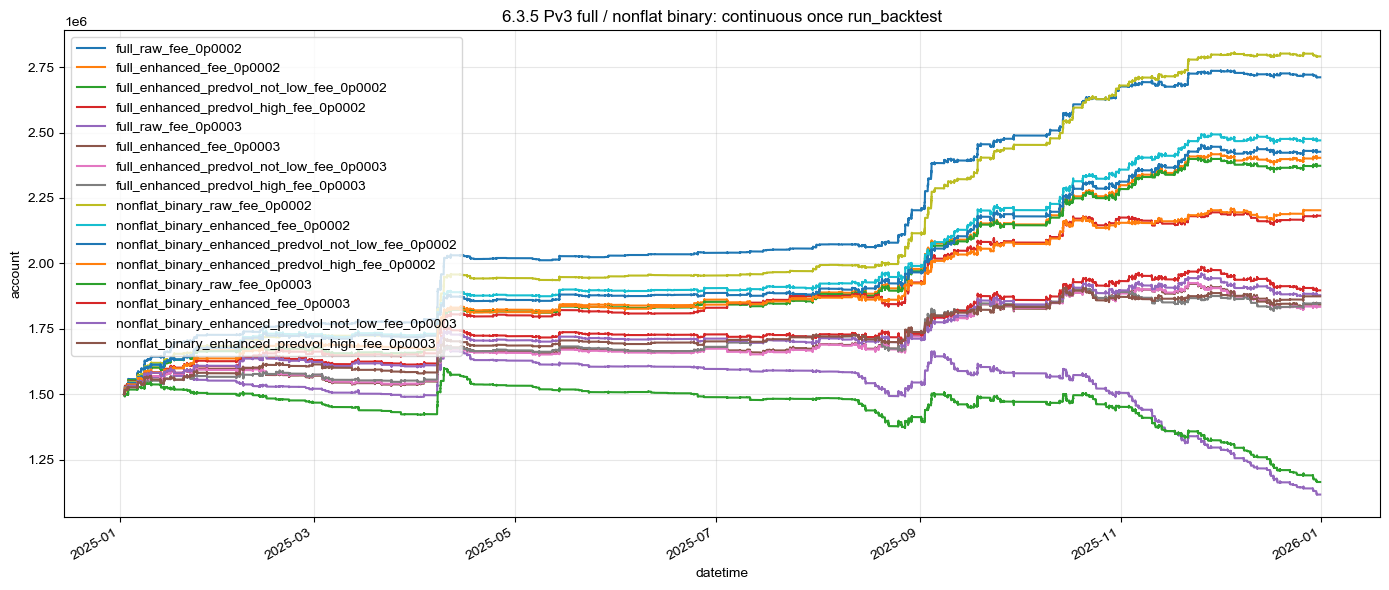

,strategy,backtest_mode,trade_count,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown
1,full_enhanced_fee_0p0002,continuous_once_run_backtest_signal,4402,58320,1500000.0,2.403426e+06,9.034262e+05,0.602284,0.036667,9.017392,-0.023740
5,full_enhanced_fee_0p0003,continuous_once_run_backtest_signal,4402,58320,1500000.0,1.842542e+06,3.425423e+05,0.228362,0.013905,3.419699,-0.049152
3,full_enhanced_predvol_high_fee_0p0002,continuous_once_run_backtest_signal,2682,58320,1500000.0,2.182170e+06,6.821701e+05,0.454780,0.029587,7.276306,-0.027020
7,full_enhanced_predvol_high_fee_0p0003,continuous_once_run_backtest_signal,2682,58320,1500000.0,1.848284e+06,3.482841e+05,0.232189,0.014851,3.652306,-0.048295
2,full_enhanced_predvol_not_low_fee_0p0002,continuous_once_run_backtest_signal,4234,58320,1500000.0,2.372969e+06,8.729685e+05,0.581979,0.035688,8.776581,-0.022174
6,full_enhanced_predvol_not_low_fee_0p0003,continuous_once_run_backtest_signal,4234,58320,1500000.0,1.834212e+06,3.342123e+05,0.222808,0.013644,3.355381,-0.054755
0,full_raw_fee_0p0002,continuous_once_run_backtest_signal,12408,58320,1500000.0,2.711101e+06,1.211101e+06,0.807401,0.061750,15.185880,-0.010700
4,full_raw_fee_0p0003,continuous_once_run_backtest_signal,12408,58320,1500000.0,1.116879e+06,-3.831215e+05,-0.255414,-0.020046,-4.929748,-0.337929
9,nonflat_binary_enhanced_fee_0p0002,continuous_once_run_backtest_signal,4490,58320,1500000.0,2.469952e+06,9.699518e+05,0.646635,0.039759,9.777837,-0.016249
13,nonflat_binary_enhanced_fee_0p0003,continuous_once_run_backtest_signal,4490,58320,1500000.0,1.896990e+06,3.969902e+05,0.264660,0.016288,4.005558,-0.047313


6.3.5 输出目录: artifacts/if_alstm_rolling_3state_intra_2025/pv3_two_stage_trade_direction_model_b_compare/alstm3_retrain_ab_split_raw_634d/enhanced_full_vs_nonflat_binary_635


,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time,scope,strategy,variant,fee_name,open_cost,close_cost,trade_count,signal_ratio,min_hold_bars,exit_trade_prob_threshold,exit_confirm_bars,reverse_confirm_bars,pred_vol_filter,pred_vol_allowed_states,pred_vol_min_prob_high,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown
1,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,full,full_enhanced_fee_0p0002,enhanced,fee_0p0002,0.0002,0.0002,1030,0.516412,3.0,0.55,2.0,2.0,none,,NaN,13680,1500000.0,1.656061e+06,156060.539985,0.104040,0.031634,7.779668,-0.023740
3,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,full,full_enhanced_predvol_high_fee_0p0002,enhanced_predvol_high,fee_0p0002,0.0002,0.0002,862,0.484694,3.0,0.55,2.0,2.0,enhanced_predvol_high,high,0.55,13680,1500000.0,1.651605e+06,151604.642593,0.101070,0.031056,7.637614,-0.017162
2,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,full,full_enhanced_predvol_not_low_fee_0p0002,enhanced_predvol_not_low,fee_0p0002,0.0002,0.0002,1022,0.514286,3.0,0.55,2.0,2.0,enhanced_predvol_not_low,"high,mid",0.45,13680,1500000.0,1.658381e+06,158381.248726,0.105587,0.032114,7.897815,-0.019798
0,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,full,full_raw_fee_0p0002,raw,fee_0p0002,0.0002,0.0002,2466,0.187840,NaN,NaN,NaN,NaN,none,,NaN,13680,1500000.0,1.774497e+06,274496.796050,0.182998,0.072341,17.790646,-0.006542
9,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,nonflat_binary,nonflat_binary_enhanced_fee_0p0002,enhanced,fee_0p0002,0.0002,0.0002,972,0.531122,3.0,0.55,2.0,2.0,none,,NaN,13680,1500000.0,1.725510e+06,225510.098174,0.150340,0.045191,11.113673,-0.016249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,full,full_raw_fee_0p0003,raw,fee_0p0003,0.0003,0.0003,4984,0.373285,NaN,NaN,NaN,NaN,none,,NaN,14400,1500000.0,1.036656e+06,-463344.138765,-0.308896,-0.077373,-19.028216,-0.316745
61,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,nonflat_binary,nonflat_binary_enhanced_fee_0p0003,enhanced,fee_0p0003,0.0003,0.0003,1672,0.720420,3.0,0.55,2.0,2.0,none,,NaN,14400,1500000.0,1.536538e+06,36537.955034,0.024359,0.005423,1.333688,-0.057794
63,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,nonflat_binary,nonflat_binary_enhanced_predvol_high_fee_0p0003,enhanced_predvol_high,fee_0p0003,0.0003,0.0003,638,0.558838,3.0,0.55,2.0,2.0,enhanced_predvol_high,high,0.55,14400,1500000.0,1.541182e+06,41181.657070,0.027454,0.006731,1.655385,-0.043307
62,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,nonflat_binary,nonflat_binary_enhanced_predvol_not_low_fee_0p...,enhanced_predvol_not_low,fee_0p0003,0.0003,0.0003,1540,0.705488,3.0,0.55,2.0,2.0,enhanced_predvol_not_low,"high,mid",0.45,14400,1500000.0,1.535080e+06,35079.546665,0.023386,0.005225,1.284957,-0.057615


In [22]:
# ===== 6.3.5) Pv3 ALSTM3：full / nonflat binary 原始回测 vs 增强回测 =====
# 不重新训练；读取 6.3.4d 的预测和阈值。
# 对比：原始按信号交易 vs 增强状态机；并做交易费用 0.0002 / 0.0003 稳健性测试。

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from engine.backtest.futures_backtest import StrategyRuleConfig, run_backtest

pv3_635_source_root = artifact_root / "pv3_two_stage_trade_direction_model_b_compare" / "alstm3_retrain_ab_split_raw_634d"
pv3_635_output_root = pv3_635_source_root / "enhanced_full_vs_nonflat_binary_635"
pv3_635_output_root.mkdir(parents=True, exist_ok=True)

pv3_635_strategies = {
    "full": {
        "raw_strategy": "a_alstm_b_alstm3_full_raw",
        "enhanced_strategy": "full_enhanced_minhold_exit",
        "pred_file": "raw_test_predictions_full.csv",
        "params_file": "selected_raw_threshold_params_full.csv",
    },
    "nonflat_binary": {
        "raw_strategy": "a_alstm_b_binary_nonflat_raw",
        "enhanced_strategy": "nonflat_binary_enhanced_minhold_exit",
        "pred_file": "raw_test_predictions_nonflat_binary.csv",
        "params_file": "selected_raw_threshold_params_nonflat_binary.csv",
    },
}

pv3_635_min_hold_bars = 3
pv3_635_exit_trade_prob_threshold = 0.55
pv3_635_exit_confirm_bars = 2
pv3_635_reverse_confirm_bars = 2
pv3_635_flat_on_weak_after_min_hold = False
pv3_635_future_vol_horizon = int(globals().get("pv3_b_future_vol_horizon", 5))
pv3_635_pred_vol_filter_configs = {
    "enhanced_predvol_not_low": {
        "allowed_states": {"mid", "high"},
        "min_prob_high": 0.45,
        "description": "预测波动率为 mid/high，或 prob_vol_high >= 0.45 时保留信号",
    },
    "enhanced_predvol_high": {
        "allowed_states": {"high"},
        "min_prob_high": 0.55,
        "description": "预测波动率为 high，或 prob_vol_high >= 0.55 时保留信号",
    },
}
pv3_635_account = float(pv3_account if "pv3_account" in globals() else account)
pv3_635_contract_multiplier = float(globals().get("pv3_635_contract_multiplier", globals().get("contract_multiplier", 300.0)))
pv3_635_fixed_trade_amount = float(globals().get("pv3_635_fixed_trade_amount", globals().get("pv3_fixed_trade_amount", 1.0)))
pv3_635_trade_interval_minutes = int(globals().get("pv3_635_trade_interval_minutes", globals().get("pv3_trade_interval_minutes", 1)))
pv3_635_first_trade_time = globals().get("pv3_635_first_trade_time", globals().get("pv3_first_trade_time", globals().get("intra_first_trade_time", "10:00")))
pv3_635_last_trade_time = globals().get("pv3_635_last_trade_time", globals().get("pv3_last_trade_time", globals().get("intra_last_trade_time", "14:59")))
pv3_635_force_flatten_exec_time = globals().get("pv3_635_force_flatten_exec_time", globals().get("pv3_force_flatten_exec_time", globals().get("intra_force_flatten_exec_time", "15:00")))
pv3_635_open_cost = float(globals().get("pv3_635_open_cost", globals().get("pv3_open_cost", 0.0002)))
pv3_635_close_cost = float(globals().get("pv3_635_close_cost", globals().get("pv3_close_cost", 0.0002)))
pv3_635_fee_scenarios = [
    {"fee_name": "fee_0p0002", "open_cost": float(globals().get("pv3_open_cost", 0.0002)), "close_cost": float(globals().get("pv3_close_cost", 0.0002))},
    {"fee_name": "fee_0p0003", "open_cost": 0.0003, "close_cost": 0.0003},
]


def _pv3_635_windows() -> list[dict]:
    if "pv3_634d_windows" in globals() and pv3_634d_windows is not None:
        return [dict(x) for x in pv3_634d_windows]
    if "windows_df" in globals() and windows_df is not None and not windows_df.empty:
        return windows_df.to_dict("records")
    if "_pv3_634d_get_windows" in globals():
        return _pv3_634d_get_windows()
    raise NameError("缺少滚动窗口信息，请先运行滚动窗口配置/6.3.4d")


def _pv3_635_read_params(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"缺少阈值文件: {path}")
    raw = pd.read_csv(path, index_col=0)
    if raw.empty:
        raise ValueError(f"阈值文件为空: {path}")
    s = raw.iloc[:, 0]
    out = {}
    for k, v in s.items():
        if pd.isna(v):
            continue
        vv = pd.to_numeric(pd.Series([v]), errors="coerce").iloc[0]
        out[str(k)] = float(vv) if pd.notna(vv) else v
    if "dir_center" in out and "dir_logit_center" not in out:
        out["dir_logit_center"] = out.pop("dir_center")
    out.setdefault("dir_logit_center", 0.0)
    return out


def _pv3_635_price_series(window: dict) -> pd.Series:
    price_col = next((c for c in [f"{target_instrument}_vwap", f"{target_instrument}_close", "vwap", "close"] if c in rollsafe_feature_frame.columns), None)
    if price_col is None:
        raise KeyError("rollsafe_feature_frame 缺少回测价格列")
    price_frame = rollsafe_feature_frame[["datetime", price_col]].copy()
    price_frame["datetime"] = pd.to_datetime(price_frame["datetime"], errors="coerce")
    price_ser = pd.Series(pd.to_numeric(price_frame[price_col], errors="coerce").values, index=price_frame["datetime"])
    price_ser = price_ser.sort_index().groupby(level=0).last().dropna()
    price_ser = price_ser[(price_ser.index >= pd.Timestamp(window["test_start"])) & (price_ser.index <= _pv3_period_end(window["end_time"]))]
    if price_ser.empty:
        raise ValueError(f"{window.get('window_id', '')} 6.3.5 回测价格序列为空")
    return price_ser


def _pv3_635_backtest_signal(signal: pd.Series, window: dict, config_name: str, *, open_cost: float, close_cost: float) -> tuple[pd.DataFrame, dict]:
    rule = StrategyRuleConfig(
        instrument=target_instrument,
        strategy_mode="long_short",
        contract_multiplier=float(contract_multiplier),
        fixed_trade_amount=float(pv3_635_fixed_trade_amount),
        long_open_threshold=0.5,
        long_close_threshold=-0.5,
        short_open_threshold=-0.5,
        short_close_threshold=0.5,
        first_trade_time=_time_value(pv3_first_trade_time),
        last_trade_time=_time_value(pv3_last_trade_time),
        trade_interval_minutes=int(pv3_trade_interval_minutes),
        force_flatten_exec_time=_time_value(pv3_force_flatten_exec_time),
        force_flatten_daily=bool(pv3_force_flatten_daily),
        force_flatten_dates=None,
        open_cost=float(open_cost),
        close_cost=float(close_cost),
    )
    report_df, analysis, indicator_dict, positions = run_backtest(
        pred=signal,
        test_start=window["test_start"],
        end_time=window["end_time"],
        account=float(pv3_635_account),
        strategy_rule=rule,
        price_series=_pv3_635_price_series(window),
    )
    metadata = {"trade_count": int(indicator_dict.get("1min", {}).get("trade_count", np.nan)), "config_name": config_name}
    return report_df, metadata


def _pv3_635_load_future_vol(window_id: str, period: str = "test") -> pd.DataFrame:
    if "_pv3_634d_load_future_vol" in globals():
        fv = _pv3_634d_load_future_vol(window_id, period)
    else:
        path = Path(artifact_root) / "future_realized_vol_lgbm_state" / "all_window_future_vol_predictions.csv"
        if not path.exists():
            alt = Path(artifact_root) / "future_realized_vol_lgbm_state" / f"h{pv3_635_future_vol_horizon}" / window_id / "future_vol_predictions.csv"
            if alt.exists():
                fv = pd.read_csv(alt, parse_dates=["datetime"])
            else:
                raise FileNotFoundError(f"缺少未来波动率预测文件: {path}")
        else:
            fv = pd.read_csv(path, parse_dates=["datetime"])
            if "window_id" in fv.columns:
                fv = fv[fv["window_id"].astype(str).eq(str(window_id))]
            if "period" in fv.columns:
                fv = fv[fv["period"].astype(str).eq(str(period))]
            if "horizon_bars" in fv.columns:
                fv = fv[pd.to_numeric(fv["horizon_bars"], errors="coerce").eq(float(pv3_635_future_vol_horizon))]
    if fv is None or fv.empty:
        return pd.DataFrame(columns=["datetime", "pred_vol_state_name", "prob_vol_low", "prob_vol_mid", "prob_vol_high"])
    if "datetime" not in fv.columns:
        fv = fv.reset_index().rename(columns={"index": "datetime"})
    fv = fv.copy()
    fv["datetime"] = pd.to_datetime(fv["datetime"], errors="coerce")
    keep = [c for c in ["datetime", "pred_vol_state_name", "prob_vol_low", "prob_vol_mid", "prob_vol_high"] if c in fv.columns]
    fv = fv[keep].dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates("datetime", keep="last")
    return fv


def _pv3_635_filter_raw_by_pred_vol(raw: pd.Series, decision: pd.DataFrame, window_id: str, filter_name: str) -> tuple[pd.Series, pd.DataFrame]:
    cfg = pv3_635_pred_vol_filter_configs[filter_name]
    fv = _pv3_635_load_future_vol(window_id, "test")
    dec = decision.copy()
    if fv.empty:
        dec["pred_vol_state_name"] = "unknown"
        dec["prob_vol_high"] = np.nan
        dec["pred_vol_filter_ok"] = False
        filtered = raw.copy()
        filtered.loc[:] = 0.0
        dec["filtered_raw_signal"] = filtered
        return filtered, dec
    fv = fv.set_index("datetime")
    drop_cols = [c for c in ["pred_vol_state_name", "prob_vol_low", "prob_vol_mid", "prob_vol_high"] if c in dec.columns]
    if drop_cols:
        dec = dec.drop(columns=drop_cols)
    dec = dec.join(fv, how="left")
    state = dec.get("pred_vol_state_name", pd.Series("unknown", index=dec.index)).fillna("unknown").astype(str).str.lower()
    prob_high = pd.to_numeric(dec.get("prob_vol_high", pd.Series(np.nan, index=dec.index)), errors="coerce")
    vol_ok = state.isin(set(cfg.get("allowed_states", set()))) | (prob_high >= float(cfg.get("min_prob_high", np.inf)))
    filtered = raw.copy()
    filtered.loc[~vol_ok.reindex(filtered.index).fillna(False).astype(bool)] = 0.0
    dec["pred_vol_filter_name"] = filter_name
    dec["pred_vol_filter_ok"] = vol_ok.astype(bool)
    dec["filtered_raw_signal"] = filtered
    return filtered, dec


def _pv3_635_make_raw_signal(pred: pd.DataFrame, params: dict) -> tuple[pd.Series, pd.DataFrame]:
    out = pred.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates("datetime", keep="last").set_index("datetime")
    eps = 1e-6
    p_up_raw = pd.to_numeric(out["prob_dir_up"], errors="coerce").clip(eps, 1.0 - eps)
    p_down_raw = pd.to_numeric(out["prob_dir_down"], errors="coerce").clip(eps, 1.0 - eps)
    dir_logit = np.log(p_up_raw / p_down_raw) - float(params.get("dir_logit_center", 0.0))
    p_up = 1.0 / (1.0 + np.exp(-dir_logit))
    p_down = 1.0 - p_up
    margin = (p_up - p_down).abs()
    shared_prob = float(params.get("dir_prob_threshold", 0.5))
    shared_margin = float(params.get("dir_margin_threshold", 0.1))
    long_prob_thr = float(params.get("long_dir_prob_threshold", shared_prob))
    short_prob_thr = float(params.get("short_dir_prob_threshold", shared_prob))
    long_margin_thr = float(params.get("long_dir_margin_threshold", shared_margin))
    short_margin_thr = float(params.get("short_dir_margin_threshold", shared_margin))
    trade_thr = float(params.get("trade_prob_threshold", 0.65))
    trade_prob = pd.to_numeric(out["trade_prob"], errors="coerce")
    trade_prob_ok = trade_prob >= trade_thr
    long_ok = trade_prob_ok & (p_up > p_down) & (p_up >= long_prob_thr) & (margin >= long_margin_thr)
    short_ok = trade_prob_ok & (p_down > p_up) & (p_down >= short_prob_thr) & (margin >= short_margin_thr)
    raw = pd.Series(0.0, index=out.index, name="pv3_raw_decision_signal")
    raw.loc[long_ok] = 1.0
    raw.loc[short_ok] = -1.0
    decision = pd.DataFrame({
        "trade_prob": trade_prob,
        "cal_prob_dir_up": p_up,
        "cal_prob_dir_down": p_down,
        "cal_dir_margin": margin,
        "raw_signal": raw,
    }, index=out.index)
    return raw, decision


def _pv3_635_exec_from_target(target: pd.Series, name: str) -> pd.Series:
    sig = target.shift(int(pv3_signal_execution_lag_bars)).fillna(0.0).rename(name)
    return mask_intra_signal(sig)


def _pv3_635_enhance_signal(pred: pd.DataFrame, params: dict, raw_override: pd.Series | None = None, decision_override: pd.DataFrame | None = None) -> tuple[pd.Series, pd.DataFrame]:
    raw, decision = _pv3_635_make_raw_signal(pred, params)
    if raw_override is not None:
        raw = raw_override.reindex(raw.index).fillna(0.0).astype(float)
    if decision_override is not None:
        decision = decision_override.reindex(raw.index)
    target = pd.Series(0.0, index=raw.index, name="pv3_enhanced_target_raw")
    pos = 0.0
    hold_bars = 0
    low_trade_counter = 0
    reverse_counter = 0
    last_reverse_dir = 0.0
    events = []
    for ts in raw.index:
        desired = float(raw.loc[ts])
        trade_prob = decision.at[ts, "trade_prob"] if ts in decision.index else np.nan
        prev_pos = pos
        reason = "hold"
        if abs(pos) < 1e-12:
            hold_bars = 0
            low_trade_counter = 0
            reverse_counter = 0
            if desired != 0.0:
                pos = desired
                hold_bars = 1
                reason = "open"
            else:
                reason = "flat_wait"
        else:
            hold_bars += 1
            if hold_bars < int(pv3_635_min_hold_bars):
                reason = "min_hold"
            else:
                if pd.notna(trade_prob) and float(trade_prob) < float(pv3_635_exit_trade_prob_threshold):
                    low_trade_counter += 1
                else:
                    low_trade_counter = 0
                if low_trade_counter >= int(pv3_635_exit_confirm_bars):
                    pos = 0.0
                    hold_bars = 0
                    reverse_counter = 0
                    reason = "model_a_exit_confirm"
                elif desired == 0.0 and bool(pv3_635_flat_on_weak_after_min_hold):
                    pos = 0.0
                    hold_bars = 0
                    reverse_counter = 0
                    reason = "weak_signal_exit"
                elif desired == 0.0:
                    reason = "hold_weak_signal"
                elif desired == -np.sign(pos):
                    if desired == last_reverse_dir:
                        reverse_counter += 1
                    else:
                        reverse_counter = 1
                        last_reverse_dir = desired
                    if reverse_counter >= int(pv3_635_reverse_confirm_bars):
                        pos = desired
                        hold_bars = 1
                        reverse_counter = 0
                        reason = "reverse_confirm"
                    else:
                        pos = 0.0
                        hold_bars = 0
                        reason = "reverse_first_flat"
                elif desired == np.sign(pos):
                    reverse_counter = 0
                    last_reverse_dir = 0.0
                    reason = "same_direction_hold"
                else:
                    reason = "hold_no_opposite"
        target.loc[ts] = pos
        events.append({
            "datetime": ts,
            "raw_signal": desired,
            "target_raw": pos,
            "prev_pos": prev_pos,
            "trade_prob": trade_prob,
            "hold_bars": hold_bars,
            "low_trade_counter": low_trade_counter,
            "reverse_counter": reverse_counter,
            "reason": reason,
        })
    exec_signal = _pv3_635_exec_from_target(target, "pv3_enhanced_signal_exec")
    events_df = pd.DataFrame(events)
    return exec_signal, events_df

pv3_635_rows = []
pv3_635_curves = {}
pv3_635_signal_parts = {}
pv3_635_errors = []

for window in _pv3_635_windows():
    window_id = str(window.get("window_id", "window"))
    window_dir = pv3_635_source_root / window_id
    out_dir = pv3_635_output_root / window_id
    out_dir.mkdir(parents=True, exist_ok=True)
    for scope, cfg in pv3_635_strategies.items():
        try:
            pred_path = window_dir / cfg["pred_file"]
            if not pred_path.exists():
                raise FileNotFoundError(f"缺少预测文件: {pred_path}")
            pred = pd.read_csv(pred_path)
            params = _pv3_635_read_params(window_dir / cfg["params_file"])
            raw_target, raw_decision = _pv3_635_make_raw_signal(pred, params)
            raw_signal = _pv3_635_exec_from_target(raw_target, "pv3_raw_signal_exec")
            enhanced_signal, decision_df = _pv3_635_enhance_signal(pred, params)
            raw_decision.reset_index().rename(columns={"index": "datetime"}).to_csv(out_dir / f"{scope}_raw_decision_frame.csv", index=False, encoding="utf-8-sig")
            decision_df.to_csv(out_dir / f"{scope}_enhanced_decision_events.csv", index=False, encoding="utf-8-sig")
            raw_signal.to_csv(out_dir / f"{scope}_raw_signal.csv", encoding="utf-8-sig")
            enhanced_signal.to_csv(out_dir / f"{scope}_enhanced_signal.csv", encoding="utf-8-sig")

            signal_variants = [("raw", raw_signal, {}), ("enhanced", enhanced_signal, {})]
            for filter_name, filter_cfg in pv3_635_pred_vol_filter_configs.items():
                filtered_target, filtered_decision = _pv3_635_filter_raw_by_pred_vol(raw_target, raw_decision, window_id, filter_name)
                filtered_signal, filtered_events = _pv3_635_enhance_signal(pred, params, raw_override=filtered_target, decision_override=filtered_decision)
                filtered_decision.reset_index().rename(columns={"index": "datetime"}).to_csv(out_dir / f"{scope}_{filter_name}_decision_frame.csv", index=False, encoding="utf-8-sig")
                filtered_events.to_csv(out_dir / f"{scope}_{filter_name}_decision_events.csv", index=False, encoding="utf-8-sig")
                filtered_signal.to_csv(out_dir / f"{scope}_{filter_name}_signal.csv", encoding="utf-8-sig")
                signal_variants.append((filter_name, filtered_signal, filter_cfg))

            for fee_cfg in pv3_635_fee_scenarios:
                fee_name = fee_cfg["fee_name"]
                for variant, signal, variant_cfg in signal_variants:
                    strategy_name = f"{scope}_{variant}_{fee_name}"
                    report, metadata = _pv3_635_backtest_signal(
                        signal,
                        window,
                        strategy_name,
                        open_cost=float(fee_cfg["open_cost"]),
                        close_cost=float(fee_cfg["close_cost"]),
                    )
                    report_out = report.reset_index() if "datetime" not in report.columns else report.copy()
                    if "datetime" not in report_out.columns:
                        report_out = report_out.rename(columns={report_out.columns[0]: "datetime"})
                    report_out.to_csv(out_dir / f"{strategy_name}_account_curve.csv", index=False, encoding="utf-8-sig")
                    pv3_635_curves.setdefault(strategy_name, []).append(report_out[["datetime", "account"]])
                    pv3_635_signal_parts.setdefault(strategy_name, []).append(signal.rename(strategy_name))
                    metrics = account_metrics(report_out["account"], pv3_635_account)
                    signal_ratio = float((signal.abs() > 0).mean()) if len(signal) else np.nan
                    pv3_635_rows.append({
                        **window,
                        "scope": scope,
                        "strategy": strategy_name,
                        "variant": variant,
                        "fee_name": fee_name,
                        "open_cost": float(fee_cfg["open_cost"]),
                        "close_cost": float(fee_cfg["close_cost"]),
                        "trade_count": metadata.get("trade_count", np.nan),
                        "signal_ratio": signal_ratio,
                        "min_hold_bars": int(pv3_635_min_hold_bars) if str(variant).startswith("enhanced") else np.nan,
                        "exit_trade_prob_threshold": float(pv3_635_exit_trade_prob_threshold) if str(variant).startswith("enhanced") else np.nan,
                        "exit_confirm_bars": int(pv3_635_exit_confirm_bars) if str(variant).startswith("enhanced") else np.nan,
                        "reverse_confirm_bars": int(pv3_635_reverse_confirm_bars) if str(variant).startswith("enhanced") else np.nan,
                        "pred_vol_filter": variant if str(variant).startswith("enhanced_predvol") else "none",
                        "pred_vol_allowed_states": ",".join(sorted(variant_cfg.get("allowed_states", []))) if variant_cfg else "",
                        "pred_vol_min_prob_high": float(variant_cfg.get("min_prob_high", np.nan)) if variant_cfg else np.nan,
                        **metrics,
                    })
                print(f"{window_id} {scope} {fee_name}: raw/enhanced done")
        except Exception as exc:
            pv3_635_errors.append({**window, "scope": scope, "error": repr(exc)})
            print(f"6.3.5 failed: {window_id} {scope} {exc!r}")

continuous_curves = pd.DataFrame()
continuous_summary = pd.DataFrame()
try:
    continuous_parts = {}
    for strategy_name, parts in pv3_635_signal_parts.items():
        row = next((r for r in pv3_635_rows if r.get("strategy") == strategy_name), {})
        rule = StrategyRuleConfig(
            instrument="IF",
            contract_multiplier=float(pv3_635_contract_multiplier),
            strategy_mode="long_short",
            fixed_trade_amount=1.0,
            first_trade_time=_time_value(pv3_635_first_trade_time),
            last_trade_time=_time_value(pv3_635_last_trade_time),
            trade_interval_minutes=int(pv3_635_trade_interval_minutes),
            force_flatten_exec_time=_time_value(pv3_635_force_flatten_exec_time),
            force_flatten_daily=True,
            open_cost=float(row.get("open_cost", pv3_635_open_cost)),
            close_cost=float(row.get("close_cost", pv3_635_close_cost)),
        )
        curves_i, summary_i = run_continuous_backtest_from_parts(
            parts_by_strategy={strategy_name: parts},
            rule=rule,
            account_value=float(pv3_635_account),
            output_root=pv3_635_output_root / "continuous_once_run_backtest" / strategy_name,
            mode="signal",
        )
        continuous_parts[strategy_name] = curves_i[strategy_name]
        continuous_summary = pd.concat([continuous_summary, summary_i], ignore_index=True)
    if continuous_parts:
        continuous_curves = pd.concat(continuous_parts, axis=1).sort_index()
        continuous_curves.columns = [c[0] if isinstance(c, tuple) else c for c in continuous_curves.columns]
        continuous_curves.to_csv(pv3_635_output_root / "continuous_account_curves.csv", encoding="utf-8-sig")
        continuous_summary.to_csv(pv3_635_output_root / "summary.csv", index=False, encoding="utf-8-sig")
        ax = continuous_curves.plot(figsize=(14, 6), title="6.3.5 Pv3 full / nonflat binary: continuous once run_backtest")
        ax.set_ylabel("account")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        display(continuous_summary.sort_values("strategy") if "strategy" in continuous_summary else continuous_summary)
except Exception as exc:
    print("6.3.5 连续合并信号回测失败:", repr(exc))

pv3_635_window_summary = pd.DataFrame(pv3_635_rows)
pv3_635_error_df = pd.DataFrame(pv3_635_errors)
pv3_635_window_summary.to_csv(pv3_635_output_root / "window_summary.csv", index=False, encoding="utf-8-sig")
pv3_635_error_df.to_csv(pv3_635_output_root / "errors.csv", index=False, encoding="utf-8-sig")
print("6.3.5 输出目录:", pv3_635_output_root)
display(pv3_635_window_summary.sort_values(["fee_name", "window_id", "scope", "variant"]) if not pv3_635_window_summary.empty else pv3_635_window_summary)
if not pv3_635_error_df.empty:
    display(pv3_635_error_df)


2025-01 full_model_led_10lot: fee2/fee3 + dynvol policies 回测完成
2025-01 nonflat_binary_model_led_10lot: fee2/fee3 + dynvol policies 回测完成
2025-04 full_model_led_10lot: fee2/fee3 + dynvol policies 回测完成
2025-04 nonflat_binary_model_led_10lot: fee2/fee3 + dynvol policies 回测完成
2025-07 full_model_led_10lot: fee2/fee3 + dynvol policies 回测完成
2025-07 nonflat_binary_model_led_10lot: fee2/fee3 + dynvol policies 回测完成
2025-10 full_model_led_10lot: fee2/fee3 + dynvol policies 回测完成
2025-10 nonflat_binary_model_led_10lot: fee2/fee3 + dynvol policies 回测完成


,strategy,backtest_mode,trade_count,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown,avg_abs_position_lots,max_abs_position_lots
0,full_model_led_10lot,continuous_once_run_backtest_target_lots,9368,58320,15000000.0,2.198237e+07,6.982374e+06,0.465492,0.040056,9.850937,-0.022483,NaN,NaN
1,full_model_led_10lot_dynvol_confirm_strength,continuous_once_run_backtest_target_lots,9521,58320,15000000.0,2.169546e+07,6.695456e+06,0.446364,0.040586,9.981281,-0.020809,NaN,NaN
2,full_model_led_10lot_dynvol_add_lots,continuous_once_run_backtest_target_lots,9537,58320,15000000.0,2.216582e+07,7.165817e+06,0.477721,0.040709,10.011535,-0.022679,NaN,NaN
3,full_model_led_10lot_dynvol_only_strength_ladder,continuous_once_run_backtest_target_lots,16251,58320,15000000.0,2.384907e+07,8.849074e+06,0.589938,0.042834,10.534036,-0.026764,NaN,NaN
4,full_model_led_10lot_fee3bp,continuous_once_run_backtest_target_lots,9368,58320,15000000.0,1.552462e+07,5.246171e+05,0.034974,0.003068,0.754574,-0.071289,NaN,NaN
5,full_model_led_10lot_dynvol_confirm_strength_f...,continuous_once_run_backtest_target_lots,9521,58320,15000000.0,1.554816e+07,5.481553e+05,0.036544,0.003370,0.828700,-0.066556,NaN,NaN
6,full_model_led_10lot_dynvol_add_lots_fee3bp,continuous_once_run_backtest_target_lots,9537,58320,15000000.0,1.560082e+07,6.008236e+05,0.040055,0.003469,0.853097,-0.070092,NaN,NaN
7,full_model_led_10lot_dynvol_only_strength_ladd...,continuous_once_run_backtest_target_lots,15985,58320,15000000.0,3.732469e+06,-1.126753e+07,-0.751169,-0.051751,-12.727056,-0.751704,NaN,NaN
8,full_raw_8lot,continuous_once_run_backtest_target_lots,12408,58320,15000000.0,2.468881e+07,9.688809e+06,0.645921,0.061348,15.087111,-0.009034,NaN,NaN
9,full_raw_8lot_fee3bp,continuous_once_run_backtest_target_lots,12408,58320,15000000.0,1.193503e+07,-3.064972e+06,-0.204331,-0.019448,-4.782709,-0.276462,NaN,NaN


2bp summary


,strategy,fee_group,display_strategy,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown,trade_count,avg_abs_position_lots,max_abs_position_lots
10,nonflat_binary_raw_10lot,fee2bp,nonflat_binary_raw_10lot,58320,15000000.0,2.790957e+07,1.290957e+07,0.860638,0.065065,16.001135,-0.012756,12686.0,NaN,NaN
5,full_raw_10lot,fee2bp,full_raw_10lot,58320,15000000.0,2.711101e+07,1.211101e+07,0.807401,0.061750,15.185880,-0.010700,12408.0,NaN,NaN
9,nonflat_binary_raw_8lot,fee2bp,nonflat_binary_raw_8lot,58320,15000000.0,2.532766e+07,1.032766e+07,0.688511,0.065091,16.007541,-0.010707,12686.0,NaN,NaN
4,full_raw_8lot,fee2bp,full_raw_8lot,58320,15000000.0,2.468881e+07,9.688809e+06,0.645921,0.061348,15.087111,-0.009034,12408.0,NaN,NaN
3,full_model_led_10lot_dynvol_only_strength_ladder,fee2bp,full_model_led_10lot_dynvol_only_strength_ladder,58320,15000000.0,2.384907e+07,8.849074e+06,0.589938,0.042834,10.534036,-0.026764,16251.0,NaN,NaN
8,nonflat_binary_model_led_10lot_dynvol_add_lots,fee2bp,nonflat_binary_model_led_10lot_dynvol_add_lots,58320,15000000.0,2.325321e+07,8.253207e+06,0.550214,0.046642,11.470467,-0.021699,9307.0,NaN,NaN
6,nonflat_binary_model_led_10lot,fee2bp,nonflat_binary_model_led_10lot,58320,15000000.0,2.304909e+07,8.049094e+06,0.536606,0.045970,11.305249,-0.022073,9149.0,NaN,NaN
7,nonflat_binary_model_led_10lot_dynvol_confirm_...,fee2bp,nonflat_binary_model_led_10lot_dynvol_confirm_...,58320,15000000.0,2.276644e+07,7.766442e+06,0.517763,0.046837,11.518497,-0.020235,9275.0,NaN,NaN
2,full_model_led_10lot_dynvol_add_lots,fee2bp,full_model_led_10lot_dynvol_add_lots,58320,15000000.0,2.216582e+07,7.165817e+06,0.477721,0.040709,10.011535,-0.022679,9537.0,NaN,NaN
0,full_model_led_10lot,fee2bp,full_model_led_10lot,58320,15000000.0,2.198237e+07,6.982374e+06,0.465492,0.040056,9.850937,-0.022483,9368.0,NaN,NaN


3bp summary


,strategy,fee_group,display_strategy,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown,trade_count,avg_abs_position_lots,max_abs_position_lots
11,Buy 10 Lot and Hold,fee3bp,Buy 10 Lot and Hold,58320,15000000.0,1.704819e+07,2.048186e+06,0.136546,0.005315,1.307116,-0.108358,1.0,10.0,10.0
8,nonflat_binary_model_led_10lot_dynvol_add_lots...,fee3bp,nonflat_binary_model_led_10lot_dynvol_add_lots,58320,15000000.0,1.672577e+07,1.725773e+06,0.115052,0.009723,2.391244,-0.049551,9307.0,NaN,NaN
7,nonflat_binary_model_led_10lot_dynvol_confirm_...,fee3bp,nonflat_binary_model_led_10lot_dynvol_confirm_...,58320,15000000.0,1.666466e+07,1.664665e+06,0.110978,0.009989,2.456464,-0.045563,9275.0,NaN,NaN
6,nonflat_binary_model_led_10lot_fee3bp,fee3bp,nonflat_binary_model_led_10lot,58320,15000000.0,1.662851e+07,1.628512e+06,0.108567,0.009272,2.280153,-0.050975,9149.0,NaN,NaN
2,full_model_led_10lot_dynvol_add_lots_fee3bp,fee3bp,full_model_led_10lot_dynvol_add_lots,58320,15000000.0,1.560082e+07,6.008236e+05,0.040055,0.003469,0.853097,-0.070092,9537.0,NaN,NaN
1,full_model_led_10lot_dynvol_confirm_strength_f...,fee3bp,full_model_led_10lot_dynvol_confirm_strength,58320,15000000.0,1.554816e+07,5.481553e+05,0.036544,0.003370,0.828700,-0.066556,9521.0,NaN,NaN
0,full_model_led_10lot_fee3bp,fee3bp,full_model_led_10lot,58320,15000000.0,1.552462e+07,5.246171e+05,0.034974,0.003068,0.754574,-0.071289,9368.0,NaN,NaN
9,nonflat_binary_raw_8lot_fee3bp,fee3bp,nonflat_binary_raw_8lot,58320,15000000.0,1.231852e+07,-2.681484e+06,-0.178766,-0.016776,-4.125588,-0.220407,12686.0,NaN,NaN
4,full_raw_8lot_fee3bp,fee3bp,full_raw_8lot,58320,15000000.0,1.193503e+07,-3.064972e+06,-0.204331,-0.019448,-4.782709,-0.276462,12408.0,NaN,NaN
10,nonflat_binary_raw_10lot_fee3bp,fee3bp,nonflat_binary_raw_10lot,58320,15000000.0,1.164815e+07,-3.351855e+06,-0.223457,-0.017065,-4.196687,-0.272060,12686.0,NaN,NaN


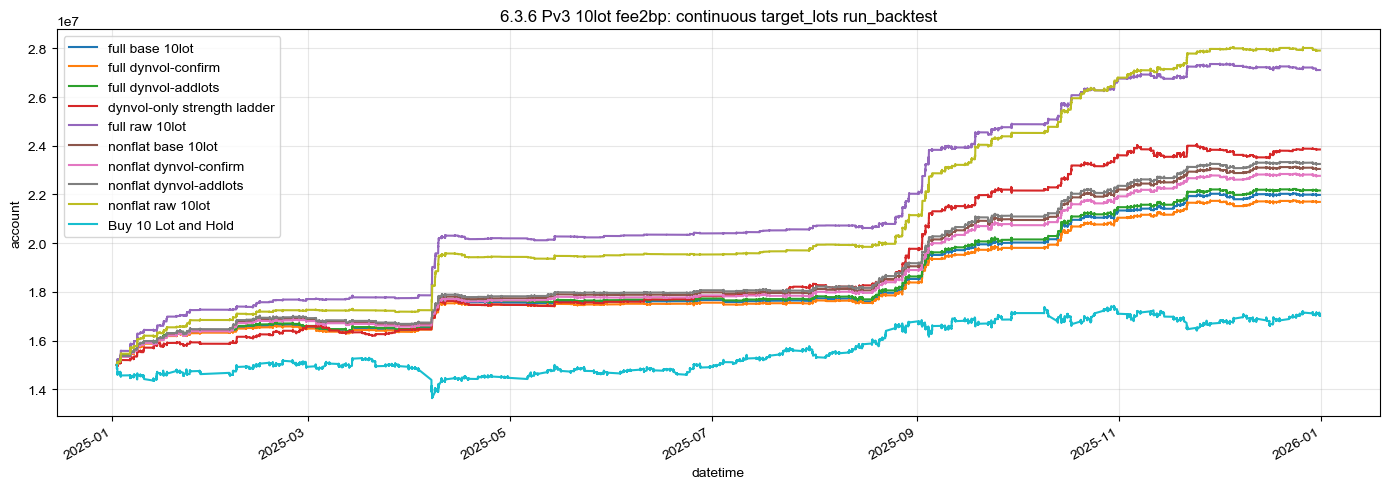

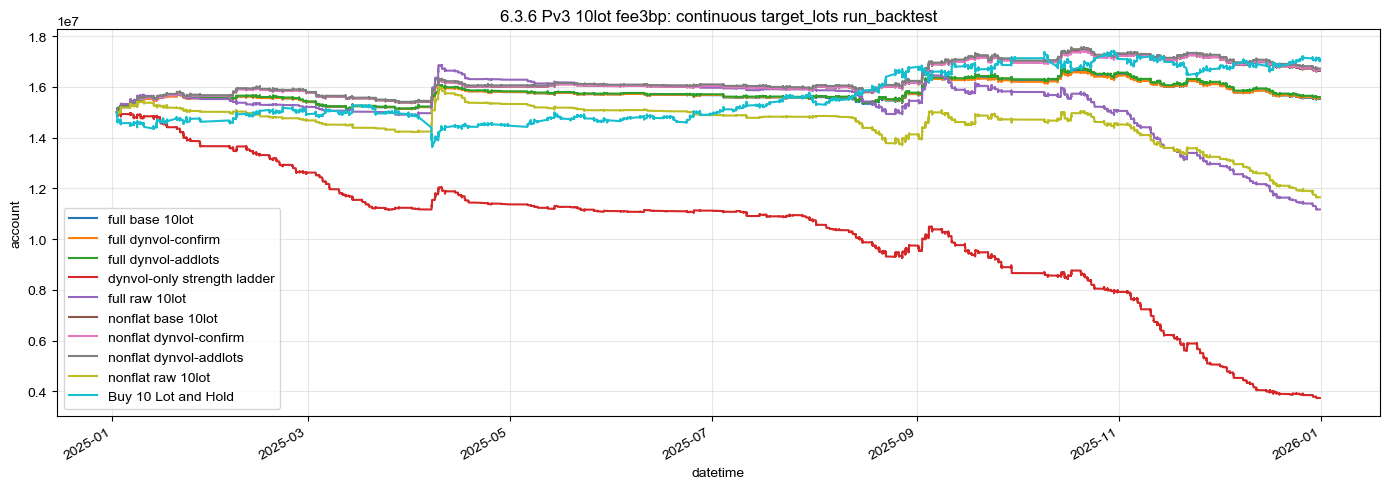

6.3.6 输出目录: artifacts/if_alstm_rolling_3state_intra_2025/pv3_two_stage_trade_direction_model_b_compare/alstm3_retrain_ab_split_raw_634d/pv3_10lot_from_634d_models


,window_id,train_months,valid_months,test_months,step_months,start_time,train_end,valid_start,valid_end,test_start,end_time,scope,strategy,samples,initial_account,final_account,absolute_pnl,total_return,sharpe_ratio,annualized_sharpe,max_drawdown,trade_count,avg_abs_position_lots,max_abs_position_lots,policy_variant,backtest_engine,open_cost,close_cost
0,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,full,full_model_led_10lot,13680,15000000.0,1.642909e+07,1.429094e+06,0.095273,0.040896,10.057430,-0.022483,1939,3.123392,9.0,base,run_backtest_target_lots,0.0002,0.0002
1,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,full,full_model_led_10lot_dynvol_confirm_strength,13680,15000000.0,1.636412e+07,1.364120e+06,0.090941,0.041618,10.235021,-0.020809,1940,2.895102,10.0,dynvol_confirm_strength,run_backtest_target_lots,0.0002,0.0002
2,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,full,full_model_led_10lot_dynvol_add_lots,13680,15000000.0,1.647862e+07,1.478618e+06,0.098575,0.041669,10.247496,-0.022679,1981,3.154313,10.0,dynvol_add_lots,run_backtest_target_lots,0.0002,0.0002
3,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,full,full_model_led_10lot_dynvol_only_strength_ladder,13680,15000000.0,1.644769e+07,1.447687e+06,0.096512,0.032972,8.108644,-0.026764,4506,2.716009,10.0,dynvol_only_strength_ladder,run_backtest_target_lots,0.0002,0.0002
4,2025-01,12,6,3,3,2023-07-01,2024-06-30,2024-07-01,2024-12-31,2025-01-01,2025-03-31,full,full_model_led_10lot_fee3bp,13680,15000000.0,1.513062e+07,1.306166e+05,0.008708,0.003691,0.907697,-0.041629,1939,3.123392,9.0,base,run_backtest_target_lots,0.0003,0.0003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,nonflat_binary,nonflat_binary_model_led_10lot_dynvol_add_lots...,14400,15000000.0,1.468412e+07,-3.158808e+05,-0.021059,-0.006276,-1.543428,-0.056064,3371,4.269375,10.0,dynvol_add_lots,run_backtest_target_lots,0.0003,0.0003
84,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,nonflat_binary,nonflat_binary_raw_8lot,14400,15000000.0,1.770443e+07,2.704430e+06,0.180295,0.063049,15.505556,-0.007925,4684,2.255556,8.0,rerun_raw_from_634d_position,run_backtest_target_lots,0.0002,0.0002
85,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,nonflat_binary,nonflat_binary_raw_8lot_fee3bp,14400,15000000.0,1.254857e+07,-2.451434e+06,-0.163429,-0.054135,-13.313176,-0.178101,4684,2.255556,8.0,rerun_raw_from_634d_position,run_backtest_target_lots,0.0003,0.0003
86,2025-10,12,6,3,3,2024-04-01,2025-03-31,2025-04-01,2025-09-30,2025-10-01,2025-12-31,nonflat_binary,nonflat_binary_raw_10lot,14400,15000000.0,1.838054e+07,3.380538e+06,0.225369,0.063317,15.571396,-0.009529,4684,2.819444,10.0,rerun_raw_from_634d_position,run_backtest_target_lots,0.0002,0.0002


In [20]:
# ===== 6.3.6) Pv3 ALSTM3 10手仓位管理：使用 6.3.4d 已训练模型 =====
# 不重新训练；直接读取 6.3.4d 的 full / nonflat_binary 预测、阈值；raw 系列按 6.3.6 参数重新回测。
# 初始资金按 10 手口径扩大 10 倍；原始信号方向主导，预测波动率定激进仓位，趋势/反转只做整数手仓位缩放。

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pv3_10lot_artifact_root = globals().get("artifact_root", Path("artifacts/futures_alstm/if_alstm_rolling_3state_intra_2025"))
pv3_10lot_source_root = pv3_10lot_artifact_root / "pv3_two_stage_trade_direction_model_b_compare" / "alstm3_retrain_ab_split_raw_634d"
pv3_10lot_dynvol5_root = pv3_10lot_artifact_root / "pv3_two_stage_trade_direction_model_b_compare" / "dynvol5_label_634f"
pv3_10lot_output_root = pv3_10lot_source_root / "pv3_10lot_from_634d_models"
pv3_10lot_output_root.mkdir(parents=True, exist_ok=True)

pv3_10lot_model_configs = {
    "full": {
        "pred_file": "raw_test_predictions_full.csv",
        "params_file": "selected_raw_threshold_params_full.csv",
        "raw_curve_file": "a_alstm_b_alstm3_full_raw_account_curve.csv",
        "raw_signal_file": "a_alstm_b_alstm3_full_raw_signal.csv",
        "raw_curve_name": "full_raw_10lot",
        "managed_name": "full_model_led_10lot",
    },
    "nonflat_binary": {
        "pred_file": "raw_test_predictions_nonflat_binary.csv",
        "params_file": "selected_raw_threshold_params_nonflat_binary.csv",
        "raw_curve_file": "a_alstm_b_binary_nonflat_raw_account_curve.csv",
        "raw_signal_file": "a_alstm_b_alstm3_nonflat_raw_signal.csv",
        "raw_curve_name": "nonflat_binary_raw_10lot",
        "managed_name": "nonflat_binary_model_led_10lot",
    },
}

pv3_10lot_base_account = float(globals().get("pv3_account", globals().get("account", 1500000.0)))
pv3_10lot_account = pv3_10lot_base_account * 10.0
pv3_10lot_contract_multiplier = float(globals().get("contract_multiplier", 300.0))
pv3_10lot_target_instrument = str(globals().get("target_instrument", "IF"))
pv3_10lot_open_cost = float(globals().get("pv3_open_cost", 0.0002))
pv3_10lot_close_cost = float(globals().get("pv3_close_cost", 0.0002))
pv3_10lot_first_trade_time = globals().get("pv3_first_trade_time", globals().get("intra_first_trade_time", "10:00"))
pv3_10lot_last_trade_time = globals().get("pv3_last_trade_time", globals().get("intra_last_trade_time", "14:59"))
pv3_10lot_force_flatten_exec_time = globals().get("pv3_force_flatten_exec_time", globals().get("intra_force_flatten_exec_time", "15:00"))
pv3_10lot_trade_interval_minutes = int(globals().get("pv3_trade_interval_minutes", 1))
pv3_10lot_decision_execution_lag_bars = int(globals().get("pv3_signal_execution_lag_bars", 1))

pv3_10lot_max_lots = 10
pv3_10lot_regular_max_lots = 10
pv3_10lot_exceptional_max_lots = 10
pv3_10lot_base_active_lots = 5  # 信号触发后的基础仓位
pv3_10lot_min_active_lots = 3   # 不确定或轻微反向时允许降到 3 手
pv3_10lot_dynvol_uncertain_floor_lots = 3
pv3_10lot_step_lots = 10  # 10 表示不做小步慢慢加仓，保持整手并贴近 raw 信号
pv3_10lot_min_hold_minutes = 2
pv3_10lot_exit_trade_prob_threshold = 0.45
pv3_10lot_exit_confirm_bars = 3
pv3_10lot_weak_env_cap_lots = 5
pv3_10lot_mid_env_cap_lots = 7
pv3_10lot_high_env_cap_lots = 10
pv3_10lot_strong_env_cap_lots = 10
pv3_10lot_trend_confirm_bonus_lots = 2
pv3_10lot_trend_conflict_multiplier = 0.75
pv3_10lot_reversal_risk_multiplier = 0.50
pv3_10lot_daily_stop_loss_ratio = 0.018
pv3_10lot_fixed_raw_lots = [8, 10]
pv3_10lot_fee_scenarios = {"fee2bp": (0.0002, 0.0002), "fee3bp": (0.0003, 0.0003)}
pv3_10lot_trend_return_window = 20
pv3_10lot_trend_return_threshold = 0.0003
pv3_10lot_reversal_return_window = 5
pv3_10lot_reversal_return_threshold = 0.0008
pv3_10lot_dynvol_confirm_conf_threshold = 0.35
pv3_10lot_dynvol_strong_conf_threshold = 0.40
pv3_10lot_policy_variants = {
    "base": "原始 10 手模型仓位管理",
    "dynvol_confirm_strength": "五分类决定信号强弱/确认",
    "dynvol_add_lots": "五分类决定加减仓数量",
    "dynvol_only_strength_ladder": "只用五分类：strong满仓、weak半仓、flat空仓",
}


def _pv3_10lot_windows() -> list[dict]:
    if "pv3_634d_windows" in globals() and pv3_634d_windows is not None:
        return [dict(x) for x in pv3_634d_windows]
    if "windows_df" in globals() and windows_df is not None and not windows_df.empty:
        return windows_df.to_dict("records")
    if "_pv3_634d_get_windows" in globals():
        return _pv3_634d_get_windows()
    raise NameError("缺少 rolling windows，请先运行滚动窗口配置或 6.3.4d")


def _pv3_10lot_time_value(x):
    return _time_value(x) if "_time_value" in globals() else pd.to_datetime(str(x)).time()


def _pv3_10lot_period_end(x):
    return pd.Timestamp(x) + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1)


def _pv3_10lot_is_trade_time(ts: pd.Timestamp) -> bool:
    t = pd.Timestamp(ts).time()
    first = _pv3_10lot_time_value(pv3_10lot_first_trade_time)
    last = _pv3_10lot_time_value(pv3_10lot_last_trade_time)
    if t < first or t > last:
        return False
    if int(pv3_10lot_trade_interval_minutes) <= 1:
        return True
    minute_of_day = pd.Timestamp(ts).hour * 60 + pd.Timestamp(ts).minute
    return minute_of_day % int(pv3_10lot_trade_interval_minutes) == 0


def _pv3_10lot_fee(old_pos: float, new_pos: float, price: float, open_cost: float | None = None, close_cost: float | None = None) -> float:
    open_cost = pv3_10lot_open_cost if open_cost is None else float(open_cost)
    close_cost = pv3_10lot_close_cost if close_cost is None else float(close_cost)
    delta = float(new_pos) - float(old_pos)
    if abs(delta) <= 1e-12:
        return 0.0
    old_dir = np.sign(old_pos)
    new_dir = np.sign(new_pos)
    close_lots = 0.0
    open_lots = 0.0
    if abs(old_pos) > 1e-12 and (new_dir == 0 or new_dir != old_dir):
        close_lots = abs(old_pos) if new_dir != old_dir else max(abs(old_pos) - abs(new_pos), 0.0)
    elif abs(old_pos) > 1e-12 and abs(new_pos) < abs(old_pos):
        close_lots = abs(old_pos) - abs(new_pos)
    if abs(new_pos) > 1e-12 and (old_dir == 0 or new_dir != old_dir):
        open_lots = abs(new_pos) if new_dir != old_dir else max(abs(new_pos) - abs(old_pos), 0.0)
    elif abs(new_pos) > abs(old_pos) and new_dir == old_dir:
        open_lots = abs(new_pos) - abs(old_pos)
    return float(price) * pv3_10lot_contract_multiplier * (close_lots * close_cost + open_lots * open_cost)


def _pv3_10lot_read_params(path: Path) -> pd.Series:
    if not path.exists():
        raise FileNotFoundError(f"缺少 6.3.4d 阈值文件: {path}")
    raw = pd.read_csv(path, index_col=0)
    if raw.empty:
        raise ValueError(f"阈值文件为空: {path}")
    out = {}
    for k, v in raw.iloc[:, 0].items():
        if pd.isna(v):
            continue
        vv = pd.to_numeric(pd.Series([v]), errors="coerce").iloc[0]
        out[str(k)] = float(vv) if pd.notna(vv) else v
    if "dir_center" in out and "dir_logit_center" not in out:
        out["dir_logit_center"] = out.pop("dir_center")
    out.setdefault("dir_logit_center", 0.0)
    return pd.Series(out)


def _pv3_10lot_price_series(window: dict) -> pd.Series:
    price_col = next((c for c in [f"{pv3_10lot_target_instrument}_vwap", f"{pv3_10lot_target_instrument}_close", "vwap", "close"] if c in rollsafe_feature_frame.columns), None)
    if price_col is None:
        raise KeyError("rollsafe_feature_frame 缺少价格列")
    df = rollsafe_feature_frame[["datetime", price_col]].copy()
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    s = pd.Series(pd.to_numeric(df[price_col], errors="coerce").values, index=df["datetime"])
    s = s.sort_index().groupby(level=0).last().dropna()
    s = s[(s.index >= pd.Timestamp(window["test_start"])) & (s.index <= _pv3_10lot_period_end(window["end_time"]))]
    if s.empty:
        raise ValueError(f"{window.get('window_id', '')} 价格序列为空")
    return s.rename("price")


def _pv3_10lot_load_future_vol(window_id: str) -> pd.DataFrame:
    path = artifact_root / "future_realized_vol_lgbm_state" / "all_window_future_vol_predictions.csv"
    if not path.exists():
        return pd.DataFrame()
    fv = pd.read_csv(path)
    if "horizon_bars" in fv.columns:
        fv = fv[pd.to_numeric(fv["horizon_bars"], errors="coerce").eq(float(globals().get("pv3_b_future_vol_horizon", 5)))]
    fv = fv[fv["window_id"].astype(str).eq(str(window_id)) & fv["period"].astype(str).eq("test")].copy()
    if fv.empty:
        return fv
    keep = [c for c in ["datetime", "pred_vol_state_name", "prob_vol_low", "prob_vol_mid", "prob_vol_high"] if c in fv.columns]
    fv = fv[keep].copy()
    fv["datetime"] = pd.to_datetime(fv["datetime"], errors="coerce")
    return fv.dropna(subset=["datetime"]).drop_duplicates("datetime")


def _pv3_10lot_load_dynvol5(window_id: str) -> pd.DataFrame:
    path = pv3_10lot_dynvol5_root / str(window_id) / "raw_test_predictions_dynvol5.csv"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    if "datetime" not in df.columns:
        df = df.rename(columns={df.columns[0]: "datetime"})
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"]).copy()
    prob_cols = [c for c in [
        "prob_strong_down", "prob_weak_down", "prob_flat", "prob_weak_up", "prob_strong_up",
    ] if c in df.columns]
    if not prob_cols:
        return pd.DataFrame()
    for c in prob_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    label_name_map = {0: "strong_down", 1: "weak_down", 2: "flat", 3: "weak_up", 4: "strong_up"}
    if "pred_label_name" in df.columns:
        pred_name = df["pred_label_name"].astype(str)
    elif "pred" in df.columns:
        pred_name = pd.to_numeric(df["pred"], errors="coerce").round().map(label_name_map).fillna("unknown")
    else:
        idx_max = df[prob_cols].idxmax(axis=1)
        pred_name = idx_max.str.replace("prob_", "", regex=False)
    up_prob = pd.to_numeric(df.get("prob_weak_up", 0.0), errors="coerce").fillna(0.0) + pd.to_numeric(df.get("prob_strong_up", 0.0), errors="coerce").fillna(0.0)
    down_prob = pd.to_numeric(df.get("prob_weak_down", 0.0), errors="coerce").fillna(0.0) + pd.to_numeric(df.get("prob_strong_down", 0.0), errors="coerce").fillna(0.0)
    conf = df[prob_cols].max(axis=1)
    direction = pd.Series(0, index=df.index, dtype="int64")
    direction.loc[up_prob > down_prob] = 1
    direction.loc[down_prob > up_prob] = -1
    direction.loc[pred_name.eq("flat")] = 0
    out = pd.DataFrame({
        "datetime": df["datetime"],
        "dynvol5_pred_name": pred_name.astype(str),
        "dynvol5_conf": conf,
        "dynvol5_up_prob": up_prob,
        "dynvol5_down_prob": down_prob,
        "dynvol5_dir_margin": (up_prob - down_prob).abs(),
        "dynvol5_dir": direction,
        "dynvol5_is_strong": pred_name.isin(["strong_up", "strong_down"]),
    })
    return out.drop_duplicates("datetime", keep="last")


def _pv3_10lot_calibrated_prob(pred: pd.DataFrame, params: pd.Series) -> pd.DataFrame:
    out = pred.copy()
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates("datetime", keep="last")
    eps = 1e-6
    p_up_raw = pd.to_numeric(out["prob_dir_up"], errors="coerce").clip(eps, 1 - eps)
    p_down_raw = pd.to_numeric(out["prob_dir_down"], errors="coerce").clip(eps, 1 - eps)
    center = float(params.get("dir_logit_center", 0.0))
    logit = np.log(p_up_raw / p_down_raw) - center
    out["decision_cal_prob_dir_up"] = 1.0 / (1.0 + np.exp(-logit))
    out["decision_cal_prob_dir_down"] = 1.0 - out["decision_cal_prob_dir_up"]
    out["decision_cal_dir_margin"] = (out["decision_cal_prob_dir_up"] - out["decision_cal_prob_dir_down"]).abs()
    out["decision_trade_prob"] = pd.to_numeric(out["trade_prob"], errors="coerce")
    return out


def _pv3_10lot_shift_decision_series(values: pd.Series, lag_bars: int | None = None) -> pd.Series:
    """日内延后决策变量：t 分钟形成 decision，t+lag 分钟执行，避免隔夜串联。"""
    lag = int(pv3_10lot_decision_execution_lag_bars if lag_bars is None else lag_bars)
    s = values.copy()
    if lag <= 0:
        return s
    idx = pd.to_datetime(s.index, errors="coerce")
    day_key = pd.Series(idx.normalize(), index=s.index)
    return s.groupby(day_key, group_keys=False).shift(lag)


def _pv3_10lot_prepare_decision_frame(window: dict, cfg: dict, selected_row: pd.Series) -> pd.DataFrame:
    window_id = str(window["window_id"])
    window_dir = pv3_10lot_source_root / window_id
    pred_path = window_dir / cfg["pred_file"]
    if not pred_path.exists():
        raise FileNotFoundError(f"缺少 6.3.4d 预测文件: {pred_path}")
    pred = _pv3_10lot_calibrated_prob(pd.read_csv(pred_path), selected_row)
    pred = pred.set_index("datetime")
    price = _pv3_10lot_price_series(window)
    market = pd.DataFrame(index=price.index).join(pred, how="left")
    market["price"] = price

    fv = _pv3_10lot_load_future_vol(window_id)
    if not fv.empty:
        fv = fv.set_index("datetime")
        market = market.join(fv, how="left")

    dynvol5 = _pv3_10lot_load_dynvol5(window_id)
    if not dynvol5.empty:
        dynvol5 = dynvol5.set_index("datetime")
        market = market.join(dynvol5, how="left")

    # 所有执行时使用的 decision_* 均延后一根 bar：t 分钟收盘形成决策，t+1 分钟成交。
    decision_source = pd.Series(pd.to_datetime(market.index), index=market.index, name="decision_source_datetime")
    market["decision_source_datetime"] = _pv3_10lot_shift_decision_series(decision_source)

    for col in ["decision_cal_prob_dir_up", "decision_cal_prob_dir_down", "decision_cal_dir_margin", "decision_trade_prob"]:
        if col in market.columns:
            market[f"raw_{col}"] = market[col]
            market[col] = pd.to_numeric(_pv3_10lot_shift_decision_series(pd.to_numeric(market[col], errors="coerce")), errors="coerce")
        else:
            market[col] = np.nan

    raw_vol_state = market.get("pred_vol_state_name", pd.Series(index=market.index, dtype="object")).fillna("unknown").astype(str)
    market["raw_decision_pred_vol_state_name"] = raw_vol_state
    market["decision_pred_vol_state_name"] = _pv3_10lot_shift_decision_series(raw_vol_state).fillna("unknown").astype(str)
    for raw_col, decision_col in [("prob_vol_high", "decision_prob_vol_high"), ("prob_vol_low", "decision_prob_vol_low")]:
        raw = pd.to_numeric(market.get(raw_col, pd.Series(index=market.index, dtype="float64")), errors="coerce")
        market[f"raw_{decision_col}"] = raw
        market[decision_col] = pd.to_numeric(_pv3_10lot_shift_decision_series(raw), errors="coerce")

    dyn_numeric_cols = ["dynvol5_conf", "dynvol5_up_prob", "dynvol5_down_prob", "dynvol5_dir_margin", "dynvol5_dir"]
    for col in dyn_numeric_cols:
        raw = pd.to_numeric(market.get(col, pd.Series(index=market.index, dtype="float64")), errors="coerce")
        market[f"raw_decision_{col}"] = raw
        market[f"decision_{col}"] = pd.to_numeric(_pv3_10lot_shift_decision_series(raw), errors="coerce")
    raw_dyn_name = market.get("dynvol5_pred_name", pd.Series(index=market.index, dtype="object")).fillna("unknown").astype(str)
    market["raw_decision_dynvol5_pred_name"] = raw_dyn_name
    market["decision_dynvol5_pred_name"] = _pv3_10lot_shift_decision_series(raw_dyn_name).fillna("unknown").astype(str)
    raw_dyn_strong = market.get("dynvol5_is_strong", pd.Series(False, index=market.index))
    raw_dyn_strong = raw_dyn_strong.where(pd.notna(raw_dyn_strong), False).astype(bool)
    market["raw_decision_dynvol5_is_strong"] = raw_dyn_strong
    shifted_dyn_strong = _pv3_10lot_shift_decision_series(raw_dyn_strong)
    market["decision_dynvol5_is_strong"] = shifted_dyn_strong.where(pd.notna(shifted_dyn_strong), False).astype(bool)

    trade_date = pd.Series(pd.to_datetime(market.index).normalize(), index=market.index)
    ret_trend = market["price"].groupby(trade_date, group_keys=False).pct_change(int(pv3_10lot_trend_return_window))
    raw_trend_dir = pd.Series(0, index=market.index, dtype="int64")
    raw_trend_dir.loc[ret_trend > float(pv3_10lot_trend_return_threshold)] = 1
    raw_trend_dir.loc[ret_trend < -float(pv3_10lot_trend_return_threshold)] = -1
    market["raw_decision_trend_dir"] = raw_trend_dir
    market["decision_trend_dir"] = _pv3_10lot_shift_decision_series(raw_trend_dir).fillna(0).astype("int64")

    ret_rev = market["price"].groupby(trade_date, group_keys=False).pct_change(int(pv3_10lot_reversal_return_window))
    raw_reversal_dir = pd.Series(0, index=market.index, dtype="int64")
    raw_reversal_dir.loc[ret_rev > float(pv3_10lot_reversal_return_threshold)] = -1
    raw_reversal_dir.loc[ret_rev < -float(pv3_10lot_reversal_return_threshold)] = 1
    market["raw_decision_reversal_dir"] = raw_reversal_dir
    market["decision_reversal_dir"] = _pv3_10lot_shift_decision_series(raw_reversal_dir).fillna(0).astype("int64")

    vol_state = market["decision_pred_vol_state_name"].astype(str)
    market["decision_weak_env"] = vol_state.eq("low") | (pd.to_numeric(market.get("decision_prob_vol_low"), errors="coerce") >= 0.55)
    market["decision_strong_env"] = vol_state.eq("high") | (pd.to_numeric(market.get("decision_prob_vol_high"), errors="coerce") >= 0.60)
    return market


def _pv3_10lot_env_cap(row: pd.Series) -> int:
    # 预测波动率只决定仓位上限，不直接禁止交易。
    state = str(row.get("decision_pred_vol_state_name", "")).lower()
    prob_high = row.get("decision_prob_vol_high")
    prob_low = row.get("decision_prob_vol_low")
    prob_high = 0.0 if pd.isna(prob_high) else float(prob_high)
    prob_low = 0.0 if pd.isna(prob_low) else float(prob_low)
    if state == "high" or prob_high >= 0.65:
        return int(pv3_10lot_strong_env_cap_lots)
    if state in {"mid", "medium"} or prob_high >= 0.45:
        return int(pv3_10lot_high_env_cap_lots)
    if prob_low >= 0.60 or state == "low":
        return int(pv3_10lot_weak_env_cap_lots)
    return int(pv3_10lot_mid_env_cap_lots)


def _pv3_10lot_base_lots(row: pd.Series, selected_row: pd.Series) -> tuple[int, int, dict]:
    trade_prob = row.get("decision_trade_prob")
    up_prob = row.get("decision_cal_prob_dir_up")
    down_prob = row.get("decision_cal_prob_dir_down")
    margin = row.get("decision_cal_dir_margin")
    if pd.isna(trade_prob) or pd.isna(up_prob) or pd.isna(down_prob) or pd.isna(margin):
        return 0, 0, {"reason": "missing_signal"}
    trade_prob = float(trade_prob)
    up_prob = float(up_prob)
    down_prob = float(down_prob)
    margin = float(margin)
    direction = 1 if up_prob >= down_prob else -1
    dir_prob = up_prob if direction > 0 else down_prob
    shared_dir_thr = float(selected_row.get("dir_prob_threshold", 0.55))
    shared_margin_thr = float(selected_row.get("dir_margin_threshold", 0.05))
    long_dir_thr = selected_row.get("long_dir_prob_threshold", shared_dir_thr)
    short_dir_thr = selected_row.get("short_dir_prob_threshold", shared_dir_thr)
    long_margin_thr = selected_row.get("long_dir_margin_threshold", shared_margin_thr)
    short_margin_thr = selected_row.get("short_dir_margin_threshold", shared_margin_thr)
    side_dir_thr = float(shared_dir_thr if pd.isna(long_dir_thr if direction > 0 else short_dir_thr) else (long_dir_thr if direction > 0 else short_dir_thr))
    side_margin_thr = float(shared_margin_thr if pd.isna(long_margin_thr if direction > 0 else short_margin_thr) else (long_margin_thr if direction > 0 else short_margin_thr))
    trade_thr = float(selected_row.get("trade_prob_threshold", 0.65))
    excess_trade = max(0.0, trade_prob - trade_thr)
    excess_prob = max(0.0, dir_prob - side_dir_thr)
    excess_margin = max(0.0, margin - side_margin_thr)
    if excess_trade <= 0 or excess_prob <= 0 or excess_margin <= 0:
        return 0, 0, {"reason": "below_selected_threshold", "trade_prob": trade_prob, "dir_prob": dir_prob, "margin": margin, "side_dir_thr": side_dir_thr, "side_margin_thr": side_margin_thr}
    strength = 0.45 * min(excess_trade / 0.20, 1.0) + 0.35 * min(excess_prob / 0.20, 1.0) + 0.20 * min(excess_margin / 0.20, 1.0)
    # 一旦 raw 信号触发，基础仓位不再从 1-2 手开始，而是按信号强度给 3/5/7/10 手。
    if strength >= 0.78:
        lots = 10
    elif strength >= 0.55:
        lots = 7
    elif strength >= 0.28:
        lots = int(pv3_10lot_base_active_lots)
    else:
        lots = int(pv3_10lot_base_active_lots)
    return int(lots), int(direction), {"reason": "model_strength_integer_ladder", "trade_prob": trade_prob, "dir_prob": dir_prob, "margin": margin, "strength": strength, "side_dir_thr": side_dir_thr, "side_margin_thr": side_margin_thr}


def _pv3_10lot_target(row: pd.Series, pos: float, entry_time: pd.Timestamp | None, exit_counter: int, selected_row: pd.Series, ts: pd.Timestamp, policy_variant: str = "base") -> tuple[float, dict, int, pd.Timestamp | None]:
    env_cap = int(_pv3_10lot_env_cap(row))
    base_lots, direction, detail = _pv3_10lot_base_lots(row, selected_row)
    trade_prob = row.get("decision_trade_prob")
    trend_dir = row.get("decision_trend_dir")
    reversal_dir = row.get("decision_reversal_dir")
    trend_dir = 0 if pd.isna(trend_dir) else int(np.sign(float(trend_dir)))
    reversal_dir = 0 if pd.isna(reversal_dir) else int(np.sign(float(reversal_dir)))
    hold_minutes = 999999.0 if entry_time is None else (ts - entry_time).total_seconds() / 60.0
    pos_dir = 0 if abs(pos) <= 1e-12 else int(np.sign(pos))
    reason = detail.get("reason", "hold")
    dyn_dir = row.get("decision_dynvol5_dir")
    dyn_conf = row.get("decision_dynvol5_conf")
    dyn_is_strong = row.get("decision_dynvol5_is_strong")
    dyn_name = str(row.get("decision_dynvol5_pred_name", "unknown"))
    dyn_dir = 0 if pd.isna(dyn_dir) else int(np.sign(float(dyn_dir)))
    dyn_conf = 0.0 if pd.isna(dyn_conf) else float(dyn_conf)
    dyn_is_strong = bool(dyn_is_strong) if pd.notna(dyn_is_strong) else False
    if policy_variant == "dynvol_only_strength_ladder":
        state = str(row.get("decision_pred_vol_state_name", "unknown")).lower()
        prob_high = row.get("decision_prob_vol_high")
        prob_low = row.get("decision_prob_vol_low")
        prob_high = 0.0 if pd.isna(prob_high) else float(prob_high)
        prob_low = 0.0 if pd.isna(prob_low) else float(prob_low)
        high_mid_ok = state in {"high", "mid", "medium"} or prob_high >= 0.45
        low_ok = (state == "low" or prob_low >= 0.60) and dyn_is_strong and dyn_conf >= 0.45
        unknown_ok = state == "unknown" and dyn_conf >= 0.40
        vol_ok = high_mid_ok or low_ok or unknown_ok
        if (not vol_ok) or dyn_dir == 0 or dyn_name == "flat":
            target = 0
            reason_parts = ["dynvol_only_flat_or_vol_filter", f"dynvol_{dyn_name}", f"conf_{dyn_conf:.2f}"]
        else:
            lots = 10 if dyn_is_strong else 5
            lots = int(min(lots, env_cap, pv3_10lot_max_lots))
            target = int(dyn_dir * lots)
            reason_parts = ["dynvol_only_strength_ladder", f"dynvol_{dyn_name}", f"conf_{dyn_conf:.2f}", f"env_cap_{env_cap}"]
        target = int(np.clip(target, -int(pv3_10lot_max_lots), int(pv3_10lot_max_lots)))
        if target != 0 and (pos_dir == 0 or int(np.sign(target)) != pos_dir):
            entry_time = ts
            exit_counter = 0
        if target == 0:
            entry_time = None
            exit_counter = 0
        return float(target), {"reason": "|".join(reason_parts), "env_cap": env_cap, "trend_dir": trend_dir, "reversal_dir": reversal_dir, "exit_counter": exit_counter, "dynvol5_conf": dyn_conf, "dynvol5_pred_name": dyn_name, "dynvol5_dir": dyn_dir, "policy_variant": policy_variant}, exit_counter, entry_time

    # Model A 只在连续低 trade_prob 时退出；弱信号/无新信号不直接砍仓，保留 raw 的连续性。
    if abs(pos) > 1e-12 and hold_minutes >= float(pv3_10lot_min_hold_minutes):
        if pd.notna(trade_prob) and float(trade_prob) < float(pv3_10lot_exit_trade_prob_threshold):
            exit_counter += 1
        else:
            exit_counter = 0
        if exit_counter >= int(pv3_10lot_exit_confirm_bars):
            return 0.0, {"reason": "model_a_low_trade_prob_exit", "env_cap": env_cap, "trend_dir": trend_dir, "reversal_dir": reversal_dir, "exit_counter": exit_counter}, 0, None

    if base_lots <= 0 or direction == 0:
        return float(int(pos)), {"reason": "hold_no_new_model_signal", "env_cap": env_cap, "trend_dir": trend_dir, "reversal_dir": reversal_dir, "exit_counter": exit_counter}, exit_counter, entry_time

    lots = int(min(max(base_lots, int(pv3_10lot_base_active_lots)), env_cap, pv3_10lot_max_lots))
    reason_parts = [reason, f"env_cap_{env_cap}"]
    if policy_variant == "dynvol_confirm_strength":
        if dyn_dir == -direction and dyn_is_strong and dyn_conf >= float(pv3_10lot_dynvol_strong_conf_threshold):
            if pos_dir == direction:
                return 0.0, {"reason": "dynvol_strong_opposite_flat", "env_cap": env_cap, "trend_dir": trend_dir, "reversal_dir": reversal_dir, "exit_counter": 0, "dynvol5_conf": dyn_conf, "dynvol5_pred_name": dyn_name, "policy_variant": policy_variant}, 0, None
            reason_parts.append("dynvol_strong_opposite_block_open")
            return float(int(pos)), {"reason": "|".join(reason_parts), "env_cap": env_cap, "trend_dir": trend_dir, "reversal_dir": reversal_dir, "exit_counter": exit_counter, "dynvol5_conf": dyn_conf, "dynvol5_pred_name": dyn_name, "policy_variant": policy_variant}, exit_counter, entry_time
        if dyn_dir == direction and dyn_conf >= float(pv3_10lot_dynvol_confirm_conf_threshold):
            add_lots = 2 if dyn_is_strong and dyn_conf >= float(pv3_10lot_dynvol_strong_conf_threshold) else 1
            lots = int(min(lots + add_lots, env_cap, pv3_10lot_max_lots))
            reason_parts.append(f"dynvol_confirm_add_{add_lots}")
        elif dyn_conf < float(pv3_10lot_dynvol_confirm_conf_threshold) or dyn_dir == 0:
            lots = int(max(min(int(pv3_10lot_dynvol_uncertain_floor_lots), env_cap), min(env_cap, np.floor(lots * 0.85))))
            reason_parts.append("dynvol_uncertain_reduce")
    elif policy_variant == "dynvol_add_lots":
        add_lots = 0
        if dyn_dir == direction and dyn_is_strong and dyn_conf >= float(pv3_10lot_dynvol_strong_conf_threshold):
            add_lots = 2
        elif dyn_dir == direction and dyn_conf >= float(pv3_10lot_dynvol_confirm_conf_threshold):
            add_lots = 1
        elif dyn_dir == -direction and dyn_is_strong and dyn_conf >= float(pv3_10lot_dynvol_strong_conf_threshold):
            add_lots = -2
        elif dyn_dir == 0 and dyn_conf >= float(pv3_10lot_dynvol_confirm_conf_threshold):
            add_lots = -1
        if add_lots != 0:
            lots = int(min(max(int(pv3_10lot_min_active_lots), lots + add_lots), env_cap, pv3_10lot_max_lots))
            reason_parts.append(f"dynvol_lot_adjust_{add_lots}")
    elif policy_variant == "dynvol_position_multiplier":
        multiplier = 1.0
        if dyn_dir == direction and dyn_is_strong and dyn_conf >= float(pv3_10lot_dynvol_strong_conf_threshold):
            multiplier = 1.20
            reason_parts.append("dynvol_multiplier_strong_same_1p2")
        elif dyn_dir == direction and dyn_conf >= float(pv3_10lot_dynvol_confirm_conf_threshold):
            multiplier = 1.00
            reason_parts.append("dynvol_multiplier_weak_same_1p0")
        elif dyn_dir == -direction and dyn_is_strong and dyn_conf >= float(pv3_10lot_dynvol_strong_conf_threshold):
            multiplier = 0.45
            reason_parts.append("dynvol_multiplier_strong_opposite_0p45")
        elif dyn_dir == -direction and dyn_conf >= float(pv3_10lot_dynvol_confirm_conf_threshold):
            multiplier = 0.65
            reason_parts.append("dynvol_multiplier_weak_opposite_0p65")
        elif dyn_dir == 0 or dyn_conf < float(pv3_10lot_dynvol_confirm_conf_threshold):
            multiplier = 0.70
            reason_parts.append("dynvol_multiplier_uncertain_0p7")
        lots = int(np.round(lots * multiplier))
        lots = int(min(max(int(pv3_10lot_min_active_lots), lots), env_cap, pv3_10lot_max_lots))

    # 趋势同向只加 1 手；趋势冲突只做 0.7 折扣，不再强行平仓。
    if trend_dir == direction:
        lots = int(min(lots + int(pv3_10lot_trend_confirm_bonus_lots), env_cap, pv3_10lot_exceptional_max_lots))
        reason_parts.append("trend_bonus")
    elif trend_dir == -direction:
        conflict_floor = 7 if env_cap >= 10 else 5
        lots = int(max(conflict_floor, np.floor(lots * float(pv3_10lot_trend_conflict_multiplier))))
        lots = int(min(lots, env_cap))
        reason_parts.append("trend_conflict_floor_5_7")

    # 反转风险：模型仍同向时只打 0.5 折扣；模型反向且反转/趋势确认时允许反手，否则先平仓。
    if pos_dir != 0 and direction == -pos_dir:
        if hold_minutes < float(pv3_10lot_min_hold_minutes):
            target = 0
            reason_parts.append("opposite_before_min_hold_flat")
        elif reversal_dir == direction or trend_dir == direction:
            target = int(direction * min(lots, env_cap))
            reason_parts.append("opposite_confirmed_reverse")
        else:
            target = 0
            reason_parts.append("opposite_flat_first")
    else:
        if pos_dir == direction and reversal_dir == -direction:
            lots = int(max(min(int(pv3_10lot_min_active_lots), env_cap), np.floor(lots * float(pv3_10lot_reversal_risk_multiplier))))
            reason_parts.append("reversal_risk_0p5")
        target = int(direction * lots)

    target = int(np.clip(int(target), -int(pv3_10lot_max_lots), int(pv3_10lot_max_lots)))
    if target != 0 and (pos_dir == 0 or int(np.sign(target)) != pos_dir):
        entry_time = ts
        exit_counter = 0
    if target == 0:
        entry_time = None
    return float(target), {"reason": "|".join(reason_parts), "env_cap": env_cap, "trend_dir": trend_dir, "reversal_dir": reversal_dir, "exit_counter": exit_counter, "dynvol5_conf": dyn_conf, "dynvol5_pred_name": dyn_name, "dynvol5_dir": dyn_dir, "policy_variant": policy_variant}, exit_counter, entry_time


def _pv3_run_10lot_policy_backtest(market: pd.DataFrame, selected_row: pd.Series, *, account_value: float, open_cost: float | None = None, close_cost: float | None = None, policy_variant: str = "base") -> tuple[pd.DataFrame, dict]:
    first_time = _pv3_10lot_time_value(pv3_10lot_first_trade_time)
    force_time = _pv3_10lot_time_value(pv3_10lot_force_flatten_exec_time)
    cash = float(account_value)
    pos = 0.0
    entry_time = None
    exit_counter = 0
    current_date = None
    day_start_account = float(account_value)
    daily_stop = False
    records = []
    for ts, row in market.iterrows():
        price = row.get("price")
        if pd.isna(price) or float(price) <= 0:
            continue
        price = float(price)
        account_before = cash + pos * pv3_10lot_contract_multiplier * price
        ts = pd.Timestamp(ts)
        ts_date = ts.normalize()
        if current_date is None or ts_date != current_date:
            current_date = ts_date
            day_start_account = account_before
            daily_stop = False
        if day_start_account > 0 and account_before / day_start_account - 1.0 <= -float(pv3_10lot_daily_stop_loss_ratio):
            daily_stop = True
        target = pos
        detail = {"reason": "hold", "env_cap": np.nan, "trend_dir": np.nan, "reversal_dir": np.nan, "daily_stop": daily_stop}
        if daily_stop and abs(pos) > 1e-12:
            target = 0.0
            entry_time = None
            exit_counter = 0
            detail = {"reason": "daily_stop_flatten", "env_cap": 0, "trend_dir": np.nan, "reversal_dir": np.nan, "daily_stop": daily_stop}
        elif daily_stop:
            target = 0.0
            detail = {"reason": "daily_stop_no_open", "env_cap": 0, "trend_dir": np.nan, "reversal_dir": np.nan, "daily_stop": daily_stop}
        elif ts.time() >= force_time and abs(pos) > 1e-12:
            target = 0.0
            entry_time = None
            exit_counter = 0
            detail = {"reason": "force_flatten", "env_cap": np.nan, "trend_dir": np.nan, "reversal_dir": np.nan}
        elif _pv3_10lot_is_trade_time(ts):
            target, detail, exit_counter, entry_time = _pv3_10lot_target(row, pos, entry_time, exit_counter, selected_row, ts, policy_variant=policy_variant)
        target = float(np.clip(np.round(target), -int(pv3_10lot_max_lots), int(pv3_10lot_max_lots)))
        fee_cash = _pv3_10lot_fee(pos, target, price, open_cost=open_cost, close_cost=close_cost)
        trade_flag = abs(target - pos) > 1e-12
        if trade_flag:
            cash -= (target - pos) * pv3_10lot_contract_multiplier * price
            cash -= fee_cash
        pos = target
        records.append({
            "datetime": ts,
            "account": cash + pos * pv3_10lot_contract_multiplier * price,
            "cash": cash,
            "position_lots": pos,
            "target_lots": target,
            "position_value": pos * pv3_10lot_contract_multiplier * price,
            "price": price,
            "trade_flag": int(trade_flag),
            "target_reason": detail.get("reason"),
            "env_lot_cap": detail.get("env_cap"),
            "decision_trend_dir": detail.get("trend_dir"),
            "decision_reversal_dir": detail.get("reversal_dir"),
            "exit_counter": detail.get("exit_counter", exit_counter),
            "decision_trade_prob": row.get("decision_trade_prob"),
            "decision_cal_prob_dir_up": row.get("decision_cal_prob_dir_up"),
            "decision_cal_prob_dir_down": row.get("decision_cal_prob_dir_down"),
            "decision_weak_env": row.get("decision_weak_env"),
            "decision_strong_env": row.get("decision_strong_env"),
            "decision_source_datetime": row.get("decision_source_datetime"),
            "policy_variant": policy_variant,
            "decision_dynvol5_conf": row.get("decision_dynvol5_conf"),
            "decision_dynvol5_dir": row.get("decision_dynvol5_dir"),
            "decision_dynvol5_pred_name": row.get("decision_dynvol5_pred_name"),
            "decision_dynvol5_is_strong": row.get("decision_dynvol5_is_strong"),
            "raw_decision_trade_prob": row.get("raw_decision_trade_prob"),
            "raw_decision_trend_dir": row.get("raw_decision_trend_dir"),
            "raw_decision_reversal_dir": row.get("raw_decision_reversal_dir"),
            "daily_stop": bool(daily_stop),
            "day_start_account": day_start_account,
        })
    target_frame = pd.DataFrame(records).set_index("datetime") if records else pd.DataFrame()
    if target_frame.empty:
        return pd.DataFrame(), {}
    target_ser = pd.to_numeric(target_frame["target_lots"], errors="coerce").fillna(0.0)
    price_ser = pd.to_numeric(market["price"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    bt_rule = StrategyRuleConfig(
        instrument="IF",
        contract_multiplier=float(pv3_10lot_contract_multiplier),
        strategy_mode="long_short",
        fixed_trade_amount=float(pv3_10lot_max_lots),
        first_trade_time=first_time,
        last_trade_time=_pv3_10lot_time_value(pv3_10lot_last_trade_time),
        trade_interval_minutes=1,
        force_flatten_exec_time=force_time,
        force_flatten_daily=True,
        open_cost=float(open_cost if open_cost is not None else pv3_10lot_open_cost),
        close_cost=float(close_cost if close_cost is not None else pv3_10lot_close_cost),
    )
    report, _analysis, indicator_dict, _positions = run_backtest(
        pred=pd.Series(0.0, index=target_ser.index),
        test_start=str(pd.Timestamp(price_ser.index.min()).date()),
        end_time=str(pd.Timestamp(price_ser.index.max()).date()),
        account=float(account_value),
        strategy_rule=bt_rule,
        price_series=price_ser,
        target_lots=target_ser,
    )
    diag_cols = [c for c in target_frame.columns if c not in {"account", "cash", "position_lots", "position_value", "price", "score"}]
    report = report.join(target_frame[diag_cols], how="left")
    report["trade_flag"] = (report["position_lots"].diff().abs().fillna(report["position_lots"].abs()) > 1e-12).astype(int)
    metrics = account_metrics(report["account"], float(account_value)) if not report.empty else {}
    trade_count = int(indicator_dict.get("1min", {}).get("trade_count", 0)) if isinstance(indicator_dict, dict) else 0
    metrics.update({
        "trade_count": trade_count,
        "avg_abs_position_lots": float(report["position_lots"].abs().mean()) if not report.empty and "position_lots" in report else np.nan,
        "max_abs_position_lots": float(report["position_lots"].abs().max()) if not report.empty and "position_lots" in report else np.nan,
        "policy_variant": policy_variant,
        "backtest_engine": "run_backtest_target_lots",
    })
    return report, metrics


def _pv3_10lot_load_raw_curve(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    if "datetime" not in df.columns:
        df = df.rename(columns={df.columns[0]: "datetime"})
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    return df.dropna(subset=["datetime"])


def _pv3_10lot_rerun_raw_from_curve(raw_curve: pd.DataFrame, lots: int, *, account_value: float, open_cost: float, close_cost: float) -> tuple[pd.DataFrame, dict]:
    """用 6.3.6 的费用、交易时间和日内平仓规则，重新执行 6.3.4d raw 曲线中的方向。"""
    if raw_curve is None or raw_curve.empty or "position_lots" not in raw_curve.columns or "price" not in raw_curve.columns:
        return pd.DataFrame(), {}
    df = raw_curve.copy()
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
        df = df.dropna(subset=["datetime"]).set_index("datetime")
    df = df.sort_index()
    price = pd.to_numeric(df["price"], errors="coerce").replace([np.inf, -np.inf], np.nan).ffill().bfill().dropna()
    raw_pos = pd.to_numeric(df["position_lots"], errors="coerce").fillna(0.0)
    raw_dir = np.sign(raw_pos).astype(float)
    first_time = _pv3_10lot_time_value(pv3_10lot_first_trade_time)
    last_time = _pv3_10lot_time_value(pv3_10lot_last_trade_time)
    force_time = _pv3_10lot_time_value(pv3_10lot_force_flatten_exec_time)
    target = pd.Series(0.0, index=price.index, name="target_lots")
    current = 0.0
    for ts in price.index:
        ts = pd.Timestamp(ts)
        next_target = current
        if ts.time() >= force_time:
            next_target = 0.0
        elif first_time <= ts.time() <= last_time and _pv3_10lot_is_trade_time(ts):
            direction = raw_dir.loc[ts] if ts in raw_dir.index else 0.0
            next_target = float(np.sign(direction) * int(lots))
        target.loc[ts] = next_target
        current = next_target
    bt_rule = StrategyRuleConfig(
        instrument="IF",
        contract_multiplier=float(pv3_10lot_contract_multiplier),
        strategy_mode="long_short",
        fixed_trade_amount=float(lots),
        first_trade_time=first_time,
        last_trade_time=last_time,
        trade_interval_minutes=1,
        force_flatten_exec_time=force_time,
        force_flatten_daily=True,
        open_cost=float(open_cost),
        close_cost=float(close_cost),
    )
    report, _analysis, indicator_dict, _positions = run_backtest(
        pred=pd.Series(0.0, index=target.index),
        test_start=str(pd.Timestamp(price.index.min()).date()),
        end_time=str(pd.Timestamp(price.index.max()).date()),
        account=float(account_value),
        strategy_rule=bt_rule,
        price_series=price,
        target_lots=target,
    )
    report["trade_flag"] = (report["position_lots"].diff().abs().fillna(report["position_lots"].abs()) > 1e-12).astype(int)
    report["target_reason"] = "rerun_raw_from_634d_position"
    metrics = account_metrics(report["account"], float(account_value)) if not report.empty else {}
    trade_count = int(indicator_dict.get("1min", {}).get("trade_count", 0)) if isinstance(indicator_dict, dict) else 0
    metrics.update({
        "trade_count": trade_count,
        "avg_abs_position_lots": float(report["position_lots"].abs().mean()) if not report.empty and "position_lots" in report else np.nan,
        "max_abs_position_lots": float(report["position_lots"].abs().max()) if not report.empty and "position_lots" in report else np.nan,
        "policy_variant": "rerun_raw_from_634d_position",
        "backtest_engine": "run_backtest_target_lots",
    })
    return report, metrics


pv3_10lot_window_list = _pv3_10lot_windows()


def _pv3_10lot_stitch_hold_from_price_rows(price_rows: list[pd.DataFrame], initial_account: float, side: int = 1, lots: int = 10) -> pd.Series:
    stitched = []
    running_account = float(initial_account)
    for row in price_rows:
        if row is None or row.empty or "price" not in row.columns:
            continue
        price = pd.to_numeric(row["price"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        if price.empty:
            continue
        curve = running_account + int(side) * int(lots) * (price - float(price.iloc[0])) * pv3_10lot_contract_multiplier
        stitched.append(curve.rename("account"))
        running_account = float(curve.iloc[-1])
    if not stitched:
        return pd.Series(dtype=float, name="buy_10_lot_account" if int(side) > 0 else "short_10_lot_account")
    return pd.concat(stitched).sort_index().rename("buy_10_lot_account" if int(side) > 0 else "short_10_lot_account")


def _pv3_10lot_load_hold_price_rows_from_saved() -> list[pd.DataFrame]:
    rows = []
    for window in pv3_10lot_window_list:
        window_id = str(window["window_id"])
        p = pv3_10lot_output_root / window_id / "full_decision_market_frame.csv"
        if not p.exists():
            p = pv3_10lot_output_root / window_id / "nonflat_binary_decision_market_frame.csv"
        if not p.exists():
            continue
        df = pd.read_csv(p)
        if "datetime" not in df.columns:
            df = df.rename(columns={df.columns[0]: "datetime"})
        if "price" not in df.columns:
            continue
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
        df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()
        rows.append(df[["price"]].copy())
    return rows

pv3_10lot_rows = []
pv3_10lot_errors = []
pv3_10lot_curves = {}
pv3_10lot_target_parts = {}
pv3_10lot_hold_price_rows = []
pv3_10lot_hold_seen_windows = set()

for window in pv3_10lot_window_list:
    window_id = str(window["window_id"])
    window_dir = pv3_10lot_source_root / window_id
    out_dir = pv3_10lot_output_root / window_id
    out_dir.mkdir(parents=True, exist_ok=True)
    for scope, cfg in pv3_10lot_model_configs.items():
        try:
            selected = _pv3_10lot_read_params(window_dir / cfg["params_file"])
            market = _pv3_10lot_prepare_decision_frame(window, cfg, selected)
            market.to_csv(out_dir / f"{scope}_decision_market_frame.csv", encoding="utf-8-sig")
            if window_id not in pv3_10lot_hold_seen_windows and "price" in market.columns:
                pv3_10lot_hold_price_rows.append(market[["price"]].copy())
                pv3_10lot_hold_seen_windows.add(window_id)
            for fee_name, (open_cost_i, close_cost_i) in pv3_10lot_fee_scenarios.items():
                for policy_name in pv3_10lot_policy_variants:
                    if policy_name == "dynvol_only_strength_ladder" and scope != "full":
                        continue
                    report, metadata = _pv3_run_10lot_policy_backtest(
                        market,
                        selected,
                        account_value=float(pv3_10lot_account),
                        open_cost=open_cost_i,
                        close_cost=close_cost_i,
                        policy_variant=policy_name,
                    )
                    if report.empty:
                        raise ValueError(f"{window_id} {scope} {policy_name} 10lot 回测为空")
                    if policy_name == "base":
                        strategy_name = cfg["managed_name"] if fee_name == "fee2bp" else f"{cfg['managed_name']}_{fee_name}"
                    else:
                        strategy_name = f"{cfg['managed_name']}_{policy_name}" if fee_name == "fee2bp" else f"{cfg['managed_name']}_{policy_name}_{fee_name}"
                    report_path = out_dir / f"{strategy_name}_account_curve.csv"
                    report.to_csv(report_path, encoding="utf-8-sig")
                    metadata = {**metadata, "open_cost": float(open_cost_i), "close_cost": float(close_cost_i), "policy_variant": policy_name}
                    pv3_10lot_rows.append({**window, "scope": scope, "strategy": strategy_name, **metadata})
                    pv3_10lot_curves.setdefault(strategy_name, []).append(report[["account"]])
                    if "position_lots" in report.columns:
                        pv3_10lot_target_parts.setdefault(strategy_name, []).append(report["position_lots"].rename(strategy_name))

            raw_curve = _pv3_10lot_load_raw_curve(window_dir / cfg["raw_curve_file"])
            if not raw_curve.empty and "position_lots" in raw_curve.columns and "price" in raw_curve.columns:
                for fixed_lots in pv3_10lot_fixed_raw_lots:
                    for fee_name, (open_cost_i, close_cost_i) in pv3_10lot_fee_scenarios.items():
                        fixed_name_base = cfg["raw_curve_name"].replace("10lot", f"{int(fixed_lots)}lot")
                        fixed_name = fixed_name_base if fee_name == "fee2bp" else f"{fixed_name_base}_{fee_name}"
                        fixed_report, fixed_meta = _pv3_10lot_rerun_raw_from_curve(
                            raw_curve,
                            int(fixed_lots),
                            account_value=float(pv3_10lot_account),
                            open_cost=float(open_cost_i),
                            close_cost=float(close_cost_i),
                        )
                        if fixed_report.empty:
                            continue
                        fixed_report.to_csv(out_dir / f"{fixed_name}_account_curve.csv", encoding="utf-8-sig")
                        fixed_meta = {**fixed_meta, "open_cost": float(open_cost_i), "close_cost": float(close_cost_i)}
                        pv3_10lot_curves.setdefault(fixed_name, []).append(fixed_report[["account"]])
                        if "position_lots" in fixed_report.columns:
                            pv3_10lot_target_parts.setdefault(fixed_name, []).append(fixed_report["position_lots"].rename(fixed_name))
                        pv3_10lot_rows.append({**window, "scope": scope, "strategy": fixed_name, **fixed_meta})
            print(f"{window_id} {cfg['managed_name']}: fee2/fee3 + dynvol policies 回测完成")
        except Exception as exc:
            pv3_10lot_errors.append({**window, "scope": scope, "error": repr(exc)})
            print(f"Pv3 10手仓位管理失败: {window_id} {scope} {exc!r}")

pv3_10lot_summary = pd.DataFrame(pv3_10lot_rows)
pv3_10lot_error_df = pd.DataFrame(pv3_10lot_errors)
pv3_10lot_summary.to_csv(pv3_10lot_output_root / "window_summary.csv", index=False, encoding="utf-8-sig")
pv3_10lot_error_df.to_csv(pv3_10lot_output_root / "errors.csv", index=False, encoding="utf-8-sig")

continuous_curves_by_strategy = {}
continuous_summary_parts = []
try:
    for strategy_name, parts in pv3_10lot_target_parts.items():
        row = next((r for r in pv3_10lot_rows if r.get("strategy") == strategy_name), {})
        bt_rule = StrategyRuleConfig(
            instrument="IF",
            contract_multiplier=float(pv3_10lot_contract_multiplier),
            strategy_mode="long_short",
            fixed_trade_amount=float(pv3_10lot_max_lots),
            first_trade_time=_pv3_10lot_time_value(pv3_10lot_first_trade_time),
            last_trade_time=_pv3_10lot_time_value(pv3_10lot_last_trade_time),
            trade_interval_minutes=1,
            force_flatten_exec_time=_pv3_10lot_time_value(pv3_10lot_force_flatten_exec_time),
            force_flatten_daily=True,
            open_cost=float(row.get("open_cost", pv3_10lot_open_cost)),
            close_cost=float(row.get("close_cost", pv3_10lot_close_cost)),
        )
        curves_i, summary_i = run_continuous_backtest_from_parts(
            parts_by_strategy={strategy_name: parts},
            rule=bt_rule,
            account_value=float(pv3_10lot_account),
            output_root=pv3_10lot_output_root / "continuous_once_run_backtest" / strategy_name,
            mode="target_lots",
        )
        continuous_curves_by_strategy[strategy_name] = curves_i[strategy_name]
        continuous_summary_parts.append(summary_i)
    hold_price_rows = pv3_10lot_hold_price_rows if pv3_10lot_hold_price_rows else _pv3_10lot_load_hold_price_rows_from_saved()
    try:
        buy_hold = _pv3_10lot_stitch_hold_from_price_rows(hold_price_rows, float(pv3_10lot_account), side=1, lots=10)
        if not buy_hold.empty:
            continuous_curves_by_strategy["Buy 10 Lot and Hold"] = buy_hold
            continuous_summary_parts.append(pd.DataFrame([{
                "strategy": "Buy 10 Lot and Hold",
                **account_metrics(buy_hold, float(pv3_10lot_account)),
                "trade_count": 1,
                "avg_abs_position_lots": 10.0,
                "max_abs_position_lots": 10.0,
            }]))
    except Exception as exc:
        print(f"Buy 10 Lot 曲线生成失败: {exc!r}")
    if continuous_curves_by_strategy:
        curve_df = pd.concat(continuous_curves_by_strategy, axis=1).sort_index()
        curve_df.columns = [c[0] if isinstance(c, tuple) else c for c in curve_df.columns]
        curve_df.to_csv(pv3_10lot_output_root / "continuous_account_curves.csv", encoding="utf-8-sig")
        window_summary_for_counts = pd.concat(continuous_summary_parts, ignore_index=True) if continuous_summary_parts else pd.DataFrame()
        window_summary_for_counts.to_csv(pv3_10lot_output_root / "summary.csv", index=False, encoding="utf-8-sig")
        display(window_summary_for_counts)
    else:
        curve_df = pd.DataFrame()
        window_summary_for_counts = pd.DataFrame()
except Exception as exc:
    print("6.3.6 连续 target_lots 回测失败:", repr(exc))
    curve_df = pd.DataFrame()
    window_summary_for_counts = pd.DataFrame()

if not curve_df.empty:
    def _pv3_10lot_fee_group(strategy: str) -> str:
        if str(strategy).endswith("_fee3bp"):
            return "fee3bp"
        return "fee2bp"

    def _pv3_10lot_clean_strategy_name(strategy: str) -> str:
        s = str(strategy)
        return s[:-7] if s.endswith("_fee3bp") else s

    def _pv3_10lot_total_table_for_fee(fee_group: str) -> pd.DataFrame:
        rows = []
        for c in curve_df.columns:
            if c == "Short 10 Lot and Hold":
                continue
            if c != "Buy 10 Lot and Hold" and _pv3_10lot_fee_group(c) != fee_group:
                continue
            row = {
                "strategy": c,
                "fee_group": fee_group,
                "display_strategy": _pv3_10lot_clean_strategy_name(c),
                **account_metrics(curve_df[c], float(pv3_10lot_account)),
            }
            if c == "Buy 10 Lot and Hold":
                row["trade_count"] = 1.0
                row["avg_abs_position_lots"] = 10.0
                row["max_abs_position_lots"] = 10.0
            elif not window_summary_for_counts.empty and "strategy" in window_summary_for_counts.columns:
                matched = window_summary_for_counts[window_summary_for_counts["strategy"] == c]
                if not matched.empty and "trade_count" in matched.columns:
                    row["trade_count"] = pd.to_numeric(matched["trade_count"], errors="coerce").sum(min_count=1)
                    row["avg_abs_position_lots"] = pd.to_numeric(matched.get("avg_abs_position_lots"), errors="coerce").mean() if "avg_abs_position_lots" in matched else np.nan
                    row["max_abs_position_lots"] = pd.to_numeric(matched.get("max_abs_position_lots"), errors="coerce").max() if "max_abs_position_lots" in matched else np.nan
            rows.append(row)
        return pd.DataFrame(rows).sort_values("final_account", ascending=False) if rows else pd.DataFrame()

    total_summary_2bp = _pv3_10lot_total_table_for_fee("fee2bp")
    total_summary_3bp = _pv3_10lot_total_table_for_fee("fee3bp")
    total_summary_2bp.to_csv(pv3_10lot_output_root / "total_summary_2bp.csv", index=False, encoding="utf-8-sig")
    total_summary_3bp.to_csv(pv3_10lot_output_root / "total_summary_3bp.csv", index=False, encoding="utf-8-sig")
    total_summary = pd.concat([total_summary_2bp, total_summary_3bp], ignore_index=True)
    total_summary.to_csv(pv3_10lot_output_root / "total_summary.csv", index=False, encoding="utf-8-sig")

    print("2bp summary")
    display(total_summary_2bp)
    print("3bp summary")
    display(total_summary_3bp)

    pv3_10lot_plot_base_cols = [
        "full_model_led_10lot",
        "full_model_led_10lot_dynvol_confirm_strength",
        "full_model_led_10lot_dynvol_add_lots",
        "full_model_led_10lot_dynvol_only_strength_ladder",
        "full_raw_10lot",
        "nonflat_binary_model_led_10lot",
        "nonflat_binary_model_led_10lot_dynvol_confirm_strength",
        "nonflat_binary_model_led_10lot_dynvol_add_lots",
        "nonflat_binary_raw_10lot",
        "Buy 10 Lot and Hold",
    ]
    pv3_10lot_plot_labels_base = {
        "full_model_led_10lot": "full base 10lot",
        "full_model_led_10lot_dynvol_confirm_strength": "full dynvol-confirm",
        "full_model_led_10lot_dynvol_add_lots": "full dynvol-addlots",
        "full_model_led_10lot_dynvol_only_strength_ladder": "dynvol-only strength ladder",
        "full_raw_10lot": "full raw 10lot",
        "nonflat_binary_model_led_10lot": "nonflat base 10lot",
        "nonflat_binary_model_led_10lot_dynvol_confirm_strength": "nonflat dynvol-confirm",
        "nonflat_binary_model_led_10lot_dynvol_add_lots": "nonflat dynvol-addlots",
        "nonflat_binary_raw_10lot": "nonflat raw 10lot",
        "Buy 10 Lot and Hold": "Buy 10 Lot and Hold",
    }

    def _pv3_10lot_plot_fee(fee_group: str):
        cols = []
        labels = {}
        for base_col in pv3_10lot_plot_base_cols:
            col = base_col if fee_group == "fee2bp" or base_col == "Buy 10 Lot and Hold" else f"{base_col}_fee3bp"
            if col in curve_df.columns:
                cols.append(col)
                labels[col] = pv3_10lot_plot_labels_base.get(base_col, base_col)
        if not cols:
            print(f"{fee_group} 没有可绘制曲线")
            return
        plot_df = curve_df[cols].rename(columns=labels)
        ax = plot_df.plot(figsize=(14, 5), title=f"6.3.6 Pv3 10lot {fee_group}: continuous target_lots run_backtest")
        ax.set_xlabel("datetime")
        ax.set_ylabel("account")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    _pv3_10lot_plot_fee("fee2bp")
    _pv3_10lot_plot_fee("fee3bp")

print("6.3.6 输出目录:", pv3_10lot_output_root)
display(pv3_10lot_summary)
if not pv3_10lot_error_df.empty:
    display(pv3_10lot_error_df)
